# Paper 1 - eating behavior

### Define the relevant directories used in this paper - RUN EVERY TIME

Data is pulled from the standardized data folder; subsequently, it is stored and managed in the paper 1 folder. 

In [1]:
import os

# Define the source and output directories
source_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard"
paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"

# Ensure the output directory exists
os.makedirs(paper1_directory, exist_ok=True)

# 1. Data preparation

### Create a research question-specific SQL database subset

#### description

Subset the filtered db to only include measurements and medical records, from the patients that have GPDR4 and only focus on first records. This can be subsetted analysis-specifically. 

A new I/O structure is proposed - pnk_db2_p1_in for the medical records, measurements, and the so-called 'survival analysis input', the time window-target weight loss analysis on which most analyses build. The analysis results will be saved to pnk_db2_p1_out. 

#### code

In [13]:
import os
import sqlite3
import pandas as pd

# Define the directories (adjust if needed)
source_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard"
paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"

# Define source and output database paths
source_db_path = os.path.join(source_directory, "pnk_db2_filtered.sqlite")
new_db_path = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")

# Connect to the source database
source_conn = sqlite3.connect(source_db_path)

# Identify patient-medical record combinations that satisfy the criteria:
# gdpr4 = 1, gdpr10 = 0 and medical_record_sequence = 1 in medical_records_filtered -> to only use first records of PROMET CONNECT patients. 
sql_select_ids = """
    SELECT medical_record_id, patient_id
    FROM medical_records_filtered
    WHERE gdpr4 = 1
      AND gdpr10 = 0
      AND medical_record_sequence = 1;
"""
first_records = pd.read_sql_query(sql_select_ids, source_conn)
first_record_ids = tuple(first_records['medical_record_id'])
first_patient_ids = tuple(first_records['patient_id'])

# Pull rows from both tables corresponding to the identified records.
# Create new table names measurements_p1 and medical_records_p1.
table_mapping = {
    "medical_records_filtered": ("medical_records_p1", first_record_ids),
    "measurements_filtered": ("measurements_p1", first_record_ids)
}

# Create new SQLite database connection to write filtered data.
new_conn = sqlite3.connect(new_db_path)

for src_table, (dst_table, mr_ids) in table_mapping.items():
    # Prepare filtering query for tables that include 'medical_record_id'
    if src_table in ("medical_records_filtered", "measurements_filtered"):
        query = f"""
            SELECT *
            FROM {src_table}
            WHERE medical_record_id IN {mr_ids}
        """
    else:
        # For other tables (if needed), one might filter by patient_id.
        query_check_column = f"PRAGMA table_info({src_table});"
        columns = pd.read_sql_query(query_check_column, source_conn)
        if 'patient_id' not in columns['name'].values:
            continue  # Skip if no patient_id column.
        query = f"""
            SELECT *
            FROM {src_table}
            WHERE patient_id IN {first_patient_ids}
        """
    # Execute the query and write into the output database.
    df_filtered = pd.read_sql_query(query, source_conn)
    df_filtered.to_sql(dst_table, new_conn, index=False, if_exists="replace")
    print(f"Wrote {len(df_filtered)} rows from {src_table} to {dst_table}.")

# Close both connections
new_conn.close()
source_conn.close()

# Print summary
print(f"Filtered data has been saved to {new_db_path}.")
print(f"Total first-record combinations: {len(first_records)} from {len(set(first_records['patient_id']))} patients.")

Wrote 11514 rows from medical_records_filtered to medical_records_p1.


KeyboardInterrupt: 

### Create time-to-event type input tables

#### description

This module builds the survival‐analysis input table (`sa_input_table`) in five stages:

* **Configuration:**  
  Define input/output SQLite paths, source and target table names, weight‐loss targets (%), time windows (days) and span, and generate a dynamic output‐column template.

* **Data Loading:**  
  Read `measurements_filtered` (sorted, with parsed dates) and `medical_records_filtered` (selected fields) from the input database into Pandas.

* **Baseline Extraction & Merge:**  
  Identify each record’s first measurement as the baseline (date, weight, BMI), rename baseline columns, and left-merge with medical-record metadata.

* **Feature Calculations:**  
  - **Overall follow-up:** Compute last measurement date, follow-up days, weight/BMI change, visit counts and average inter-visit interval.  
  - **Fixed time-points:** For each window (e.g. 60 ± 10 days), select the closest measurement or flag dropout; derive weight, weight‐loss, date and days-to-measurement.  
  - **Time-to-event:** For each loss threshold (5%, 10%, 15%), flag if/when achieved and record percentage, event date and days-to-event.

* **Assembly & Export:**  
  Concatenate all computed metrics into one wide DataFrame (reindexed to the dynamic column order) and write it to `sa_input_table` in `survival_analysis.sqlite`.  

#### create time-to-event table on all available records

In [10]:
import os
import sqlite3
import pandas as pd
import numpy as np
from datetime import timedelta

"""
1. CONFIGURATION 
"""
# Assuming paper1_directory is defined in your environment or elsewhere
# For example: paper1_directory = "path/to/your/data_directory" 
# If not, you'll need to define it for the script to run.

# 1a. Define I/O directories, used databases and tables in them
input_db  = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
output_db = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite") # Note: Same as input

input_measurements    = "measurements_p1"
input_medical_records = "medical_records_p1"
output_table          = "timetoevent_all"

# 1b. Define analysis parameters: weight loss targets, time windows, and window span
weight_loss_targets = [5, 10, 15]     # % thresholds
time_windows        = [40, 60, 80]    # days
window_span         = 10              # +/- days around each window

# 1c. Define which variables to fetch from medical records
fetch_from_records = [
  "patient_id", "medical_record_id",
  "dietitian_visits", 
  "sex_f", "age_when_creating_record AS age",
  "height_m",
  "hunger_yn", "satiety_yn", "emotional_eating_yn",
  "emotional_eating_value_likert",
  "quantity_control_likert", "impulse_control_likert",
  "weight_gain_cause", "weight_gain_cause_en", 
  "womens_health_and_pregnancy", "mental_health", "family_issues",
  "medication_disease_injury", "physical_inactivity", "eating_habits", 
  "schedule", "smoking_cessation", "treatment_discontinuation_or_relapse", "pandemic",
  "lifestyle_circumstances", "none_of_above", 
#   "genomics_sample_id"
]

# 1d. Build output column order dynamically (no changes needed here)
followup_columns = [
    "patient_id","medical_record_id",
    "baseline_date","last_aval_date","total_followup_days",
    "dietitian_visits","nr_total_measurements", "instant_dropout", "avg_days_between_measurements",
    "baseline_weight_kg","last_aval_weight_kg","total_wl_kg","total_wl_%", 
    "baseline_bmi","final_bmi","bmi_reduction", "baseline_fat_%","last_aval_fat_%","total_fat_loss_%",
    "baseline_muscle_%","last_aval_muscle_%","total_muscle_change_%"
]
predictor_columns = [
    "sex_f","age","height_m","hunger_yn","satiety_yn","emotional_eating_yn",
    "emotional_eating_value_likert","quantity_control_likert","impulse_control_likert",
    "weight_gain_cause", "weight_gain_cause_en", 
    "womens_health_and_pregnancy", "mental_health", "family_issues",
    "medication_disease_injury", "physical_inactivity", "eating_habits", 
    "schedule", "smoking_cessation", "treatment_discontinuation_or_relapse", "pandemic",
    "lifestyle_circumstances", "none_of_above"
]
def make_column_order():
    cols = followup_columns.copy()
    for w in time_windows:
        prefix = f"{w}d"
        cols += [
            f"{prefix}_weight_kg", f"{prefix}_wl_kg", f"{prefix}_wl_%",
            f"{prefix}_bmi", f"{prefix}_bmi_reduction",
            f"{prefix}_fat_%", f"{prefix}_fat_loss_%",
            f"{prefix}_muscle_%", f"{prefix}_muscle_change_%",
            f"{prefix}_date", f"days_to_{prefix}_measurement", f"{prefix}_dropout"
        ]
    for t in weight_loss_targets:
        prefix = f"{t}%_wl"
        cols += [
            f"{prefix}_achieved", f"{prefix}_%", f"{prefix}_date", f"days_to_{prefix}"
        ]
    cols += predictor_columns
    return cols
output_column_order = make_column_order()

"""
2. DATA LOADING
"""
def load_measurements(conn) -> pd.DataFrame:
    # Consider selecting only necessary columns if measurements_p1 has many unused ones
    cols_to_select = ["patient_id", "medical_record_id", "measurement_date", 
                      "first_in_record", "weight_kg", "bmi", "fat_%", "muscle_%"]
    cols_to_select = [f'"{col}"' for col in cols_to_select]  # Ensure proper quoting for SQL, as some columns have special characters
    # Check if any other columns from measurements_p1 are implicitly used. If not, this is safer.
    # If you are sure all columns are needed, use "SELECT *"
    sql_query = f"SELECT {','.join(cols_to_select)} FROM {input_measurements}"
    # sql_query = f"SELECT * FROM {input_measurements}" # Original version
    
    df = pd.read_sql(sql_query, conn, parse_dates=["measurement_date"])
    df = df.sort_values(["patient_id", "medical_record_id", "measurement_date"])
    return df

def load_med_records(conn) -> pd.DataFrame:
    df = pd.read_sql(f"SELECT {','.join(fetch_from_records)} FROM {input_medical_records}", conn)
    return df

"""
3. BASELINE & MERGE (No major changes here, but ensure it's efficient)
"""
def extract_baseline(meas: pd.DataFrame) -> pd.DataFrame:
    base = meas[meas["first_in_record"] == 1].copy() # .copy() is good here
    base = base.rename(columns={
        "measurement_date": "baseline_date",
        "weight_kg": "baseline_weight_kg",
        "bmi": "baseline_bmi",
        "fat_%": "baseline_fat_%",
        "muscle_%": "baseline_muscle_%"
    })
    return base[[
        "patient_id", "medical_record_id",
        "baseline_date", "baseline_weight_kg", "baseline_bmi",
        "baseline_fat_%", "baseline_muscle_%"
    ]]

def merge_baseline_and_records(baseline, recs):
    df = baseline.merge(recs, on=["patient_id", "medical_record_id"], how="left")
    return df

"""
4. CALCULATIONS (Functions refactored for clarity and to work with grouped data)
"""
# calc_overall_followup: Largely similar, but operates on pre-grouped, pre-sorted data.
# Ensure baseline_row_info is a pd.Series (which it will be from indexed lookup)
def calc_overall_followup(patient_record_measurements: pd.DataFrame, baseline_row_info: pd.Series) -> pd.Series:
    baseline_date = baseline_row_info["baseline_date"]
    
    followup_measurements = patient_record_measurements[
        patient_record_measurements["measurement_date"] > baseline_date
    ] # patient_record_measurements is already sorted by date

    last = baseline_row_info.copy() # Start with baseline info (which is a Series)
    last["instant_dropout"] = 0 # Initialize instant_dropout

    if followup_measurements.empty:
        last["last_aval_date"] = baseline_row_info["baseline_date"]
        last["total_followup_days"] = 1
        last["instant_dropout"] = 1 # Set to 1 if only baseline measurement exists
        last["last_aval_weight_kg"] = baseline_row_info["baseline_weight_kg"]
        last["total_wl_kg"], last["total_wl_%"] = 0.0, 0.0
        last["final_bmi"] = baseline_row_info["baseline_bmi"]
        last["bmi_reduction"] = 0.0
        last["last_aval_fat_%"] = baseline_row_info["baseline_fat_%"]
        last["total_fat_loss_%"] = 0.0
        last["last_aval_muscle_%"] = baseline_row_info["baseline_muscle_%"]
        last["total_muscle_change_%"] = 0.0
    else:
        last_meas = followup_measurements.iloc[-1]
        dt = (last_meas.measurement_date - baseline_date).days + 1
        last["last_aval_date"] = last_meas.measurement_date
        last["total_followup_days"] = dt
        last["last_aval_weight_kg"] = last_meas.weight_kg
        last["total_wl_kg"] = last_meas.weight_kg - baseline_row_info["baseline_weight_kg"]
        last["total_wl_%"] = 100 * last["total_wl_kg"] / baseline_row_info["baseline_weight_kg"] if baseline_row_info["baseline_weight_kg"] else 0
        last["final_bmi"] = last_meas.bmi
        last["bmi_reduction"] = last_meas.bmi - baseline_row_info["baseline_bmi"]
        last["last_aval_fat_%"] = last_meas["fat_%"]
        last["total_fat_loss_%"] = last_meas["fat_%"] - baseline_row_info["baseline_fat_%"]
        last["last_aval_muscle_%"] = last_meas["muscle_%"]
        last["total_muscle_change_%"] = last_meas["muscle_%"] - baseline_row_info["baseline_muscle_%"]
    
    last["nr_total_measurements"] = len(patient_record_measurements)
    if last["nr_total_measurements"] > 1:
        # Denominator (last["nr_total_measurements"] - 1) cannot be zero here
        last["avg_days_between_measurements"] = \
            (last["total_followup_days"] - 1) / (last["nr_total_measurements"] - 1)
    else:
        last["avg_days_between_measurements"] = np.nan
    return last

# calc_fixed_timepoints: Operates on pre-grouped data.
def calc_fixed_timepoints(patient_record_measurements: pd.DataFrame, baseline_row_info: pd.Series) -> dict:
    out = {}
    baseline_date = baseline_row_info["baseline_date"]
    baseline_weight_kg = baseline_row_info["baseline_weight_kg"]
    baseline_bmi = baseline_row_info["baseline_bmi"]
    baseline_fat_pct = baseline_row_info["baseline_fat_%"]
    baseline_muscle_pct = baseline_row_info["baseline_muscle_%"]

    for w in time_windows:
        target_date = baseline_date + timedelta(days=w)
        lo = baseline_date + timedelta(days=w - window_span)
        hi = baseline_date + timedelta(days=w + window_span)
        
        window_meas = patient_record_measurements[
            (patient_record_measurements["measurement_date"] >= lo) &
            (patient_record_measurements["measurement_date"] <= hi)
        ]
        
        prefix = f"{w}d"
        if window_meas.empty:
            out[f"{prefix}_dropout"] = 1
            out[f"{prefix}_weight_kg"], out[f"{prefix}_wl_kg"], out[f"{prefix}_wl_%"] = np.nan, np.nan, np.nan
            out[f"{prefix}_bmi"], out[f"{prefix}_bmi_reduction"] = np.nan, np.nan
            out[f"{prefix}_fat_%"], out[f"{prefix}_fat_loss_%"] = np.nan, np.nan
            out[f"{prefix}_muscle_%"], out[f"{prefix}_muscle_change_%"] = np.nan, np.nan
            out[f"{prefix}_date"], out[f"days_to_{prefix}_measurement"] = pd.NaT, np.nan
        else:
            # Make a copy to safely add a column
            window_meas_copy = window_meas.copy()
            window_meas_copy["dist_to_center"] = (window_meas_copy["measurement_date"] - target_date).abs().dt.days
            take = window_meas_copy.loc[window_meas_copy["dist_to_center"].idxmin()]
            out[f"{prefix}_dropout"] = 0
            out[f"{prefix}_weight_kg"] = take.weight_kg
            wl_kg = take.weight_kg - baseline_weight_kg
            out[f"{prefix}_wl_kg"] = wl_kg
            out[f"{prefix}_wl_%"]  = 100 * wl_kg / baseline_weight_kg if baseline_weight_kg else 0
            out[f"{prefix}_bmi"] = take.bmi
            out[f"{prefix}_bmi_reduction"] = take.bmi - baseline_row_info["baseline_bmi"]
            out[f"{prefix}_fat_%"] = take["fat_%"]
            out[f"{prefix}_fat_loss_%"] = take["fat_%"] - baseline_fat_pct
            out[f"{prefix}_muscle_%"] = take["muscle_%"]
            out[f"{prefix}_muscle_change_%"] = take["muscle_%"] - baseline_muscle_pct
            out[f"{prefix}_date"] = take.measurement_date
            out[f"days_to_{prefix}_measurement"] = (take.measurement_date - baseline_date).days + 1
    return out

# calc_time_to_targets: CRITICAL REFACTOR - removed inner iterrows()
def calc_time_to_targets(patient_record_measurements: pd.DataFrame, baseline_row_info: pd.Series) -> dict:
    out = {}
    baseline_date = baseline_row_info["baseline_date"]
    baseline_weight = baseline_row_info["baseline_weight_kg"]

    # Filter measurements strictly after baseline date; patient_record_measurements is already sorted
    group = patient_record_measurements[patient_record_measurements["measurement_date"] > baseline_date]

    if group.empty or baseline_weight == 0: # Added check for baseline_weight to prevent division by zero
        for t in weight_loss_targets:
            out[f"{t}%_wl_achieved"], out[f"{t}%_wl_%"] = 0, np.nan
            out[f"{t}%_wl_date"], out[f"days_to_{t}%_wl"] = pd.NaT, np.nan
        return out

    # Calculate weight loss percentage for all measurements in the group vectorially
    # Use .copy() to avoid SettingWithCopyWarning if 'group' is a slice
    group_copy = group.copy()
    group_copy["wl_pct_calculated"] = 100 * (baseline_weight - group_copy["weight_kg"]) / baseline_weight
    
    for t in weight_loss_targets:
        # Find the first measurement (due to sort order) where target is achieved
        achieved_measurements = group_copy[group_copy["wl_pct_calculated"] >= t]
        
        if not achieved_measurements.empty:
            first_achieved_event = achieved_measurements.iloc[0]
            out[f"{t}%_wl_achieved"] = 1
            out[f"{t}%_wl_%"] = first_achieved_event["wl_pct_calculated"]
            out[f"{t}%_wl_date"] = first_achieved_event["measurement_date"]
            out[f"days_to_{t}%_wl"] = (first_achieved_event["measurement_date"] - baseline_date).days + 1
        else:
            out[f"{t}%_wl_achieved"] = 0
            out[f"{t}%_wl_%"] = np.nan 
            out[f"{t}%_wl_date"] = pd.NaT
            out[f"days_to_{t}%_wl"] = np.nan
    return out

"""
5. ORCHESTRATION (Refactored main loop)
"""
def build_sa_input_table():
    conn_in  = sqlite3.connect(input_db)
    all_measurements = load_measurements(conn_in)
    medical_records_data = load_med_records(conn_in)
    conn_in.close()

    baseline_data = extract_baseline(all_measurements)
    merged_patient_records = merge_baseline_and_records(baseline_data, medical_records_data)

    # Set index for quick lookup of baseline/record info. This is crucial.
    # merged_patient_records has one row per (patient_id, medical_record_id)
    merged_patient_records_indexed = merged_patient_records.set_index(["patient_id", "medical_record_id"])

    output_rows = []
    
    # Group measurements ONCE, then iterate through groups
    # This is the core performance improvement for the loop structure.
    grouped_measurements = all_measurements.groupby(["patient_id", "medical_record_id"])

    for (patient_id, medical_record_id), patient_group_measurements in grouped_measurements:
        # patient_group_measurements is a DataFrame for the current patient-record, already sorted.
        
        try:
            # Efficiently get the corresponding baseline and medical record info (it's a Series)
            record_info_with_baseline = merged_patient_records_indexed.loc[(patient_id, medical_record_id)]
        except KeyError:
            # This happens if a patient-record group exists in measurements but not in merged_patient_records
            # (e.g. no baseline found, or no medical record entry)
            # print(f"Warning: No baseline/record info for patient {patient_id}, record {medical_record_id}. Skipping.")
            continue # Skip this group if no baseline/record info

        # 1) overall follow‐up
        overall_followup_series = calc_overall_followup(patient_group_measurements, record_info_with_baseline)
        out_dict = overall_followup_series.to_dict() # Contains baseline fields + calculated overall fields
        
        # Manually add the patient_id and medical_record_id from the groupby keys
        out_dict["patient_id"] = patient_id
        out_dict["medical_record_id"] = medical_record_id
        
        # 2) fixed timepoints
        fixed_timepoints_dict = calc_fixed_timepoints(patient_group_measurements, record_info_with_baseline)
        out_dict.update(fixed_timepoints_dict)
        
        # 3) time-to-event
        time_to_event_dict = calc_time_to_targets(patient_group_measurements, record_info_with_baseline)
        out_dict.update(time_to_event_dict)
        
        output_rows.append(out_dict)

    df_out = pd.DataFrame(output_rows)
    
    # Reorder columns (ensure all columns produced are in output_column_order, or handle missing ones)
    # If some columns might not be generated for all rows (e.g. from record_info_with_baseline if it was skipped),
    # df_out.reindex might introduce NaNs. This should be fine.
    df_out = df_out.reindex(columns=output_column_order)

    conn_out = sqlite3.connect(output_db)
    df_out.to_sql(output_table, conn_out, if_exists="replace", index=False)
    conn_out.close()
    print(f"Saved {len(df_out)} rows to {output_db}::{output_table}")

if __name__=="__main__":
    # IMPORTANT: Define paper1_directory before calling this function
    # Example:
    # paper1_directory = "." # Or your actual path
    if 'paper1_directory' not in globals():
        print("Error: 'paper1_directory' is not defined. Please define it before running.")
    else:
        build_sa_input_table()


Saved 11514 rows to .\pnk_db2_p1_in.sqlite::timetoevent_all


#### subset time-to-event table for fully available eating behavior and fully available weight gain cause records

In [ ]:
import pandas as pd
import os
import sqlite3

# Paths
db_path = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
input_table = "timetoevent_all"
wgccompl_table = "timetoevent_wgc_compl"
ebcompl_table = "timetoevent_eb_compl"
ebwgccompl_table = "timetoevent_eb_wgc_compl"

# Columns for EB completeness
eb_columns = [
    "hunger_yn", "satiety_yn", "emotional_eating_yn",
    "emotional_eating_value_likert", "quantity_control_likert", "impulse_control_likert"
]

with sqlite3.connect(db_path) as conn:
    # 1. WGC complete: weight_gain_cause is not null
    df_wgc = pd.read_sql_query(
        f"SELECT * FROM {input_table} WHERE weight_gain_cause IS NOT NULL", conn
    )
    df_wgc.to_sql(wgccompl_table, conn, if_exists="replace", index=False)
    print(f"Saved {len(df_wgc)} rows to {wgccompl_table}")

    # 2. EB complete: all EB columns are not null
    not_null_cond = " AND ".join([f"{col} IS NOT NULL" for col in eb_columns])
    df_eb = pd.read_sql_query(
        f"SELECT * FROM {input_table} WHERE {not_null_cond}", conn
    )
    df_eb.to_sql(ebcompl_table, conn, if_exists="replace", index=False)
    print(f"Saved {len(df_eb)} rows to {ebcompl_table}")

    # 3. Both EB and WGC complete: all EB and WGC columns are not null
    not_null_cond = " AND ".join([f"{col} IS NOT NULL" for col in eb_columns])
    df_eb = pd.read_sql_query(
        f"SELECT * FROM {input_table} WHERE {not_null_cond} AND weight_gain_cause IS NOT NULL", conn
    )
    df_eb.to_sql(ebwgccompl_table, conn, if_exists="replace", index=False)
    print(f"Saved {len(df_eb)} rows to {ebcompl_table}")

NameError: name 'paper1_directory' is not defined

# 2. Data analysis

## Descriptive comparisons

### Between-cohort comparisons: EB vs whole, WGC vs whole - FUNCTIONALIZE BEFORE MODULE EXPORT

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from stats_helpers import (
    format_mean_sd,
    format_n_perc,
    format_availability,
    welchs_ttest,
    categorical_pvalue,
    format_pval,
    cohens_d,
    format_cohens_d,
)

# =========================
# 1. CONFIGURATION
# =========================

# I/O paths and table names
INPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# Uncomment input and subset tables on which to run comparisons, and output table to save the results to

# INPUT_TABLE = "timetoevent_all" # Source: All patients, filtered for baseline BMI and first measurements
# SUBSET_TABLE = "timetoevent_eb_compl"    # Subset: Patients with complete eating behavior data
# OUTPUT_TABLE = "eb_cmpl_vs_all" # Complete eating behavior vs all patients

# INPUT_TABLE = "timetoevent_eb_compl" # Source: Patients with complete eating behavior data
# SUBSET_TABLE = "timetoevent_eb_wgc_compl"    # Subset: Patients with complete eating behavior AND weight gain cause data
# OUTPUT_TABLE = "eb_wgc_cmpl_vs_eb_cmpl" # Complete eating behavior vs all patients

INPUT_TABLE = "timetoevent_all" # Source: Patients with complete eating behavior data
SUBSET_TABLE = "timetoevent_wgc_compl"    # Subset: Patients with complete eating behavior AND weight gain cause data
OUTPUT_TABLE = "wgc_cmpl_vs_all" # Complete eating behavior vs all patients

# Define dynamic time windows and weight loss targets
TIME_WINDOWS = [40, 60, 80]
WL_TARGETS = [5, 10, 15]

# Generate variable names for dynamic time windows
time_window_vars = []
for w in TIME_WINDOWS:
    time_window_vars += [
        f"{w}d_dropout",
        f"wl_{w}d_%",
        f"{w}d_fat_loss_%",
        f"{w}d_muscle_change_%"
    ]

# Generate variable names for dynamic weight loss targets
target_vars = []
for t in WL_TARGETS:
    target_vars += [
        f"{t}%_wl_achieved",
        f"days_to_{t}%_wl"
    ]

# Variables to compare (row order)
VARIABLES = [
    # Demographics & baseline anthropometry
    "sex_f", "age", 
    "height_m", "baseline_weight_kg", "baseline_bmi", "baseline_fat_%", "baseline_muscle_%", 
    # Follow-up data
    "total_followup_days", "instant_dropout", "dietitian_visits", "nr_total_measurements",
    "avg_days_between_measurements", "genomics_sample_id",
    # Fixed end outcomes
    "last_aval_weight_kg", "total_wl_kg", "total_wl_%", "final_bmi", "bmi_reduction",
    "last_aval_fat_%", "total_fat_loss_%", "last_aval_muscle_%", "total_muscle_change_%",
    # Dynamic outcomes
    *time_window_vars, 
    *target_vars
]

# Conditionally add extra variables if comparing EB complete vs EB+WGC complete
if INPUT_TABLE == "timetoevent_eb_compl" and SUBSET_TABLE == "timetoevent_eb_wgc_compl":
    VARIABLES += [
        "hunger_yn", "satiety_yn", "emotional_eating_yn",
        "emotional_eating_value_likert", "quantity_control_likert", "impulse_control_likert"
    ]

# =========================
# 2. DATA LOADING
# =========================

with sqlite3.connect(INPUT_DB) as conn:
    df_all = pd.read_sql_query(f"SELECT * FROM {INPUT_TABLE}", conn)
    df_subset = pd.read_sql_query(f"SELECT * FROM {SUBSET_TABLE}", conn)

# Identify subset by unique IDs (e.g., medical_record_id or patient_id)
id_col = "medical_record_id" if "medical_record_id" in df_all.columns else "patient_id"
subset_ids = set(df_subset[id_col])
df_rest = df_all[~df_all[id_col].isin(subset_ids)].copy()

VARIABLE_TYPES = {}
for col in df_all.columns:
    if col in ["sex_f", "instant_dropout"] or col.endswith("_yn") or col.endswith("_achieved") or col.endswith("_dropout"):
        VARIABLE_TYPES[col] = "categorical"
    # elif col.endswith("_date") or col == "baseline_date":
    #     VARIABLE_TYPES[col] = "date"
    elif col == "genomics_sample_id":
        VARIABLE_TYPES[col] = "availability"
    elif col in ["patient_id", "medical_record_id"]:
        continue  # skip ID columns
    else:
        VARIABLE_TYPES[col] = "continuous"

# =========================
# 3. COMPARATIVE SUMMARY
# =========================

summary_rows = []
summary_rows.append({
    "Variable": "N",
    "Subset": f"{len(df_subset)}",
    "Rest": f"{len(df_rest)}",
    "p-value": "N/A",
    "Cohen's d": "N/A"
})

for var in VARIABLES:
    vtype = VARIABLE_TYPES.get(var, "continuous")
    row = {"Variable": var}

    # Handle missing columns gracefully
    if var not in df_subset.columns or var not in df_rest.columns:
        row["Subset"] = "N/A"
        row["Rest"] = "N/A"
        row["p-value"] = "N/A"
        row["Cohen's d"] = "N/A"
        summary_rows.append(row)
        continue

    if vtype == "continuous":
        row["Subset"] = format_mean_sd(df_subset[var])
        row["Rest"] = format_mean_sd(df_rest[var])
        p = welchs_ttest(df_subset[var], df_rest[var])
        d = cohens_d(df_subset[var], df_rest[var])
        row["p-value"] = format_pval(p)
        row["Cohen's d"] = format_cohens_d(d)
    elif vtype == "categorical":
        row["Subset"] = format_n_perc(df_subset[var])
        row["Rest"] = format_n_perc(df_rest[var])
        p = categorical_pvalue(df_subset[var], df_rest[var])
        row["p-value"] = format_pval(p)
        row["Cohen's d"] = "N/A"
    elif vtype == "availability":
        row["Subset"] = format_availability(df_subset[var])
        row["Rest"] = format_availability(df_rest[var])
        # Compare as categorical (present/not)
        p = categorical_pvalue(df_subset[var].notna().astype(int), df_rest[var].notna().astype(int))
        row["p-value"] = format_pval(p)
        row["Cohen's d"] = "N/A"
    else:
        row["Subset"] = "N/A"
        row["Rest"] = "N/A"
        row["p-value"] = "N/A"
        row["Cohen's d"] = "N/A"

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# =========================
# 4. PLOT SUBSET-SPECIFIC BASELINE DATE HISTOGRAMS
# =========================

def plot_baseline_date_histograms(df1, df2, label1="Subset", label2="Rest"):
    s1 = pd.to_datetime(df1["baseline_date"], errors="coerce")
    s2 = pd.to_datetime(df2["baseline_date"], errors="coerce")
    plt.figure(figsize=(10,5))
    plt.hist(s1.dropna(), bins=30, alpha=0.6, label=label1)
    plt.hist(s2.dropna(), bins=30, alpha=0.6, label=label2)
    plt.xlabel("Baseline Date")
    plt.ylabel("Count")
    plt.title("Baseline Date Distribution: Subset vs Rest")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_baseline_date_histograms(df_subset, df_rest)

# =========================
# 5. SAVE TO SQLITE
# =========================

with sqlite3.connect(OUTPUT_DB) as conn:
    summary_df.to_sql(OUTPUT_TABLE, conn, if_exists="replace", index=False)
print(f"Comparative summary saved to {OUTPUT_DB}, table '{OUTPUT_TABLE}'.")

# =========================
# 6. NOTES
# =========================
# - Welch's t-test is used for continuous variables (robust to unequal variances/sizes).
# - Cohen's d is reported for continuous variables as a standardized effect size.
# - Categorical variables use Chi-squared or Fisher's exact test as appropriate.
# - For 'genomics_sample_id', the summary is based on availability (not null).
# - If a variable is missing in either group, 'N/A' is reported.

KeyboardInterrupt: 

### within-comp updating sandbox - bootstrap - BEST for all comps UGLY THAT I DIDNT CLEAN THIS ALL!

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from stats_helpers import (
    format_mean_sd,
    format_n_perc,
    format_median_iqr,
    format_availability,
    run_bootstrap_comparison,
)

# =========================
# 1. CONFIGURATION
# =========================

# --- Create a directory for outputs if it doesn't exist ---
paper1_directory = "."
plots_directory = os.path.join(paper1_directory, "cohort_comp_data_collection_bias_plots")
os.makedirs(plots_directory, exist_ok=True)

INPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# --- Uncomment the desired cohort configuration to run ---

# CONFIG 1: FULL EB COHORT (Faster, no bootstrapping)
# INPUT_COHORT_NAME = "timetoevent_eb_compl"
# MOTHER_COHORT_NAME = "timetoevent_all"
# DEMOGRAPHIC_OUTPUT_TABLE = "eb_cmpl_dmgrph_strt"
# EB_OUTPUT_TABLE = "eb_cmpl_eb_strt"
# WGC_OUTPUT_TABLE = "eb_cmpl_wgc_strt"
# PLOT_OUTPUT_FILE = os.path.join(plots_directory, "eb_cmpl_datacollection_bias.png")


# CONFIG 2: FULL EB + WGC COHORT (Slower, with bootstrapping)
INPUT_COHORT_NAME = "timetoevent_eb_wgc_compl"
MOTHER_COHORT_NAME = "timetoevent_eb_compl"
DEMOGRAPHIC_OUTPUT_TABLE = "eb_wgc_cmpl_dmgrph_strt"
EB_OUTPUT_TABLE = "eb_wgc_cmpl_eb_strt"
WGC_OUTPUT_TABLE = "eb_wgc_cmpl_wgc_strt"
PLOT_OUTPUT_FILE = os.path.join(plots_directory, "eb_wgc_cmpl_datacollection_bias.png")


TIME_WINDOWS = [40, 60, 80]
WL_TARGETS = [5, 10, 15]
N_BOOTSTRAP = 5000 # Number of bootstrap iterations

# Added a flag to conditionally run bootstrapping.
# This makes the script much faster for cohorts where bootstrapping is not required.
RUN_BOOTSTRAP = (INPUT_COHORT_NAME == "timetoevent_eb_wgc_compl")


# Row order and pretty names
ROW_ORDER = [
    ("N", "N"),
    # Demographics & baseline anthropometry
    ("delim_demo", "Demographics and baseline anthropometry"),
    ("sex_f", "Sex (% of females)"),
    ("age", "Age (years)"),
    ("height_m", "Height (m)"),
    ("baseline_weight_kg", "Baseline weight (kg)"),
    ("baseline_bmi", "Baseline BMI (kg/m²)"),
    ("baseline_fat_%", "Baseline fat mass (%)"),
    ("baseline_muscle_%", "Baseline muscle mass (%)"),
    # Treatment outcomes
    ("delim_outcomes", "Treatment outcomes"),
    ("total_followup_days", "Follow-up length (days)"),
    ("dietitian_visits", "Number of visits"),
    ("nr_total_measurements", "Number of total measurements"),
    ("avg_days_between_measurements", "Average measurement frequency (days)"),
    ("last_aval_weight_kg", "Last measured weight (kg)"),
    ("total_wl_kg", "Total weight loss (kg)"),
    ("total_wl_%", "Total weight loss (%)"),
    ("final_bmi", "Final BMI (kg/m²)"),
    ("bmi_reduction", "BMI reduction (kg/m²)"),
    ("last_aval_fat_%", "Last measured fat mass (%)"),
    ("total_fat_loss_%", "Total fat mass loss (%)"),
    ("last_aval_muscle_%", "Last measured muscle mass (%)"),
    ("total_muscle_change_%", "Total muscle mass change (%)"),
    ("instant_dropout", "Instant dropouts (n)"),
]
# Add dynamic time window and WL target variables
for w in TIME_WINDOWS:
    ROW_ORDER += [
        (f"{w}d_dropout", f"{w}-day dropouts (n)"),
        (f"{w}d_wl_%", f"{w}-day weight loss (%)"),
        (f"{w}d_bmi_reduction", f"{w}-day BMI reduction (kg/m²)"),
        (f"{w}d_fat_loss_%", f"{w}-day fat mass loss (%)"),
        (f"{w}d_muscle_change_%", f"{w}-day muscle mass change (%)"),
    ]
for t in WL_TARGETS:
    ROW_ORDER += [
        (f"{t}%_wl_achieved", f"Achieved {t}% weight loss (n)"),
        (f"days_to_{t}%_wl", f"Days to {t}% weight loss"),
    ]
ROW_ORDER += [
    # Eating behavior
    ("delim_eb", "Self-reported eating behavior"),
    ("hunger_yn", "Hunger (yes/no)"),
    ("satiety_yn", "Satiety (yes/no)"),
    ("emotional_eating_yn", "Emotional eating (yes/no)"),
    ("emotional_eating_value_likert", "Emotional eating score (1-10)"),
    ("quantity_control_likert", "Quantity control score (1-10)"),
    ("impulse_control_likert", "Impulse control score (1-10)"),
    # Weight gain causes
    ("delim_wgc", "Self-reported causes of weight gain"),
    ("womens_health_and_pregnancy", "Women's health and pregnancy (yes/no)"),
    ("mental_health", "Mental health (yes/no)"),
    ("family_issues", "Family issues (yes/no)"),
    ("medication_disease_injury", "Medication, disease or injury (yes/no)"),
    ("physical_inactivity", "Physical inactivity (yes/no)"),
    ("eating_habits", "Eating habits (yes/no)"),
    ("schedule", "Schedule (yes/no)"),
    ("smoking_cessation", "Smoking cessation (yes/no)"),
    ("treatment_discontinuation_or_relapse", "Treatment discontinuation or relapse (yes/no)"),
    ("pandemic", "COVID-19 pandemic (yes/no)"),
    ("lifestyle_circumstances", "Lifestyle circumstances (yes/no)"),
    ("none_of_above", "None of the above (yes/no)"),
]

# =========================
# 2. HELPER FUNCTIONS
# =========================

def get_cause_cols():
    """Identifies weight gain cause columns from the ROW_ORDER config."""
    wgc_cols = []
    in_wgc_section = False
    for var, _ in ROW_ORDER:
        if var == "delim_wgc":
            in_wgc_section = True
            continue
        if var.startswith("delim_") and in_wgc_section:
            break
        if in_wgc_section:
            wgc_cols.append(var)
    return wgc_cols

def get_variable_types(df, cause_cols):
    """Determines if a variable is continuous, categorical, or availability."""
    var_types = {}
    for col in df.columns:
        if (
            col in ["sex_f", "instant_dropout"]
            or col.endswith("_yn")
            or col.endswith("_achieved")
            or col.endswith("_dropout")
            or col in cause_cols
        ):
            var_types[col] = "categorical"
        elif col in ["patient_id", "medical_record_id", "medical_record_start_date"]:
            continue
        else:
            var_types[col] = "continuous"
    return var_types

def format_value(df, var, vtype, column_name=None):
    """Formats a single variable based on its type, with conditional logic for continuous."""
    if vtype == "continuous":
        mean_sd = format_mean_sd(df[var])
        if column_name in ["Parent cohort", "Observed cohort"]:
            median_iqr = format_median_iqr(df[var])
            return f"{mean_sd} | {median_iqr}"
        return mean_sd
    elif vtype == "categorical":
        return format_n_perc(df[var])
    elif vtype == "availability":
        return format_availability(df[var])
    else:
        return "N/A"

def add_empty_rows_and_pretty_names(summary_rows, pretty_names, is_wgc_cohort):
    """Adds section delimiters and applies pretty names to variables."""
    all_columns = set()
    if summary_rows:
        all_columns.update(summary_rows[0].keys())

    new_rows = []
    cause_cols_list = get_cause_cols()

    for var, pretty in pretty_names:
        if var.startswith("delim_wgc") and not is_wgc_cohort:
            break
        if var in cause_cols_list and not is_wgc_cohort:
            continue

        if var.startswith("delim_"):
            row = {col: "" for col in all_columns}
            row["Variable"] = pretty
            new_rows.append(row)
        else:
            row = next((r for r in summary_rows if r["Variable"] == var), None)
            if row is not None:
                row["Variable"] = pretty
                new_rows.append(row)
    return new_rows

def perform_and_format_comparison(g0, g1, var, vtype, run_bootstrap):
    """
    Runs the comparison and formats the results into full numerical strings.
    If run_bootstrap is True, it performs bootstrapping.
    Otherwise, it only calculates the standard p-value.
    """
    if not all(c in g0.columns and c in g1.columns for c in [var]):
        return "N/A", "N/A"

    s0 = g0[var] if vtype != "availability" else g0[var].notna().astype(int)
    s1 = g1[var] if vtype != "availability" else g1[var].notna().astype(int)
    
    effective_vtype = "categorical" if vtype == "availability" else vtype

    # Run the comparison function, which returns a dict of raw numbers
    results = run_bootstrap_comparison(s0, s1, effective_vtype, n_iterations=N_BOOTSTRAP, run_bootstrap=run_bootstrap)

    # Format standard p-value
    std_p = results['std_p']
    std_p_str = str(std_p) if pd.notna(std_p) else "N/A"

    # Conditionally format bootstrap results
    bootstrap_str = "N/A"
    if run_bootstrap:
        boot_p = results['boot_p']
        ci_low = results['boot_ci_low']
        ci_high = results['boot_ci_high']
        
        if pd.notna(boot_p) and pd.notna(ci_low) and pd.notna(ci_high):
            p_val_str = str(boot_p)
            ci_low_str = f"{ci_low:.2f}"
            ci_high_str = f"{ci_high:.2f}"
            bootstrap_str = f"{p_val_str} ({ci_low_str} to {ci_high_str})"

    return std_p_str, bootstrap_str


### CHANGE: Modified function to write out full p-values.
    def perform_and_format_comparison(g0, g1, var, vtype, run_bootstrap):
        """
        Runs the comparison and formats the results into full numerical strings.
        If run_bootstrap is True, it performs bootstrapping.
        Otherwise, it only calculates the standard p-value.
        """
        if not all(c in g0.columns and c in g1.columns for c in [var]):
            return "N/A", "N/A"
    
        s0 = g0[var] if vtype != "availability" else g0[var].notna().astype(int)
        s1 = g1[var] if vtype != "availability" else g1[var].notna().astype(int)
        
        effective_vtype = "categorical" if vtype == "availability" else vtype
    
        # Run the comparison function, which now returns a dict of raw numbers
        results = run_bootstrap_comparison(s0, s1, effective_vtype, n_iterations=N_BOOTSTRAP, run_bootstrap=run_bootstrap)
    
        # Format standard p-value
        std_p = results['std_p']
        std_p_str = str(std_p) if pd.notna(std_p) else "N/A"
    
        # Conditionally format bootstrap results
        bootstrap_str = "N/A"
        if run_bootstrap:
            boot_p = results['boot_p']
            ci_low = results['boot_ci_low']
            ci_high = results['boot_ci_high']
            
            if pd.notna(boot_p) and pd.notna(ci_low) and pd.notna(ci_high):
                p_val_str = str(boot_p)
                ci_low_str = f"{ci_low:.2f}"
                ci_high_str = f"{ci_high:.2f}"
                bootstrap_str = f"{p_val_str} ({ci_low_str} to {ci_high_str})"
    
        return std_p_str, bootstrap_str


# =========================
# 3. PLOTTING FUNCTION
# =========================

def plot_datacollection_bias(df_cohort, df_mother, cohort_name, mother_cohort_name, output_file):
    """
    Generates and saves a bar plot comparing the distribution of medical record start years.
    """
    df_cohort['year'] = pd.to_datetime(df_cohort['baseline_date']).dt.year
    df_mother['year'] = pd.to_datetime(df_mother['baseline_date']).dt.year

    counts_cohort = df_cohort['year'].value_counts(normalize=True).sort_index()
    counts_mother = df_mother['year'].value_counts(normalize=True).sort_index()

    plot_df = pd.DataFrame({
        'Year': counts_mother.index.union(counts_cohort.index)
    }).set_index('Year')
    plot_df[f'Mother Cohort ({mother_cohort_name})'] = counts_mother
    plot_df[f'Cohort ({cohort_name})'] = counts_cohort
    plot_df = plot_df.fillna(0).reset_index().melt(id_vars='Year', var_name='Cohort', value_name='Proportion')

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=plot_df, x='Year', y='Proportion', hue='Cohort', ax=ax)

    ax.set_title('Distribution of Medical Record Start Dates', fontsize=16, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Proportion of Patients', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Cohort')
    plt.tight_layout()

    plt.savefig(output_file, dpi=300)
    plt.close(fig)
    print(f"Data collection bias plot saved to {output_file}")

# =========================
# 4. STRATIFIED COMPARISON FUNCTIONS
# =========================

def demographic_stratification(df, df_mother, output_table, conn, is_wgc_cohort, run_bootstrap):
    """Performs demographic stratification and comparison to mother cohort."""
    print("Running Demographic Stratification...")
    cause_cols = get_cause_cols()
    combined_df = pd.concat([df, df_mother], sort=False)
    var_types = get_variable_types(combined_df, cause_cols)

    median_age = pd.to_numeric(df["age"], errors="coerce").median()
    groups = {
        "Age < Median": df[df["age"] < median_age],
        "Age ≥ Median": df[df["age"] >= median_age],
        "Males": df[df["sex_f"] == 0],
        "Females": df[df["sex_f"] == 1],
        "BMI < 30": df[df["baseline_bmi"] < 30],
        "BMI ≥ 30": df[df["baseline_bmi"] >= 30],
    }

    summary_rows = []
    n_row = {
        "Variable": "N", "Parent cohort": len(df_mother), "Observed cohort": len(df),
        "Cohort comparison: p-value": "N/A", "Cohort comparison: bootstrap p-value and 95% CI": "N/A",
        f"Age < Median [{median_age:.2f}]": len(groups["Age < Median"]),
        f"Age ≥ Median [{median_age:.2f}]": len(groups["Age ≥ Median"]),
        "Age: p-value": "N/A", "Age: bootstrap p-value and 95% CI": "N/A",
        "Males": len(groups["Males"]), "Females": len(groups["Females"]),
        "Gender: p-value": "N/A", "Gender: bootstrap p-value and 95% CI": "N/A",
        "BMI < 30": len(groups["BMI < 30"]), "BMI ≥ 30": len(groups["BMI ≥ 30"]),
        "BMI: p-value": "N/A", "BMI: bootstrap p-value and 95% CI": "N/A"
    }
    summary_rows.append(n_row)

    for i, (var, _) in enumerate(ROW_ORDER):
        if var == "N" or var.startswith("delim_"):
            continue
        if var in cause_cols and not is_wgc_cohort:
            continue
        print(f"  Processing variable {i}/{len(ROW_ORDER)}: {var}")

        vtype = var_types.get(var, "continuous")
        row = {"Variable": var}

        row["Parent cohort"] = format_value(df_mother, var, vtype, column_name="Parent cohort")
        row["Observed cohort"] = format_value(df, var, vtype, column_name="Observed cohort")
        row["Cohort comparison: p-value"], row["Cohort comparison: bootstrap p-value and 95% CI"] = perform_and_format_comparison(df_mother, df, var, vtype, run_bootstrap)

        g0, g1 = groups["Age < Median"], groups["Age ≥ Median"]
        row[f"Age < Median [{median_age:.2f}]"] = format_value(g0, var, vtype)
        row[f"Age ≥ Median [{median_age:.2f}]"] = format_value(g1, var, vtype)
        row["Age: p-value"], row["Age: bootstrap p-value and 95% CI"] = perform_and_format_comparison(g0, g1, var, vtype, run_bootstrap)

        g0, g1 = groups["Males"], groups["Females"]
        row["Males"] = format_value(g0, var, vtype)
        row["Females"] = format_value(g1, var, vtype)
        row["Gender: p-value"], row["Gender: bootstrap p-value and 95% CI"] = perform_and_format_comparison(g0, g1, var, vtype, run_bootstrap)

        g0, g1 = groups["BMI < 30"], groups["BMI ≥ 30"]
        row["BMI < 30"] = format_value(g0, var, vtype)
        row["BMI ≥ 30"] = format_value(g1, var, vtype)
        row["BMI: p-value"], row["BMI: bootstrap p-value and 95% CI"] = perform_and_format_comparison(g0, g1, var, vtype, run_bootstrap)

        summary_rows.append(row)

    summary_rows = add_empty_rows_and_pretty_names(summary_rows, ROW_ORDER, is_wgc_cohort)
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_sql(output_table, conn, if_exists="replace", index=False)
    print(f"Demographic stratification table saved to {output_table}")

def eating_behavior_stratification(df, output_table, conn, is_wgc_cohort, run_bootstrap):
    """Performs stratification based on eating behavior variables."""
    print("Running Eating Behavior Stratification...")
    cause_cols = get_cause_cols()
    var_types = get_variable_types(df, cause_cols)

    median_emotional = pd.to_numeric(df["emotional_eating_value_likert"], errors="coerce").median()
    median_quantity = pd.to_numeric(df["quantity_control_likert"], errors="coerce").median()
    median_impulse = pd.to_numeric(df["impulse_control_likert"], errors="coerce").median()

    groups = {
        "Hunger: No": df[df["hunger_yn"] == 0], "Hunger: Yes": df[df["hunger_yn"] == 1],
        "Satiety: No": df[df["satiety_yn"] == 0], "Satiety: Yes": df[df["satiety_yn"] == 1],
        "Emotional eating: No": df[df["emotional_eating_yn"] == 0], "Emotional eating: Yes": df[df["emotional_eating_yn"] == 1],
        f"Emotional eating score < Median [{median_emotional:.2f}]": df[df["emotional_eating_value_likert"] < median_emotional],
        f"Emotional eating score ≥ Median [{median_emotional:.2f}]": df[df["emotional_eating_value_likert"] >= median_emotional],
        f"Quantity control score < Median [{median_quantity:.2f}]": df[df["quantity_control_likert"] < median_quantity],
        f"Quantity control score ≥ Median [{median_quantity:.2f}]": df[df["quantity_control_likert"] >= median_quantity],
        f"Impulse control score < Median [{median_impulse:.2f}]": df[df["impulse_control_likert"] < median_impulse],
        f"Impulse control score ≥ Median [{median_impulse:.2f}]": df[df["impulse_control_likert"] >= median_impulse],
    }
    strata_pairs = [
        ("Hunger: No", "Hunger: Yes", "Hunger"),
        ("Satiety: No", "Satiety: Yes", "Satiety"),
        ("Emotional eating: No", "Emotional eating: Yes", "Emotional eating"),
        (f"Emotional eating score < Median [{median_emotional:.2f}]", f"Emotional eating score ≥ Median [{median_emotional:.2f}]", "Emotional eating score"),
        (f"Quantity control score < Median [{median_quantity:.2f}]", f"Quantity control score ≥ Median [{median_quantity:.2f}]", "Quantity control score"),
        (f"Impulse control score < Median [{median_impulse:.2f}]", f"Impulse control score ≥ Median [{median_impulse:.2f}]", "Impulse control score"),
    ]

    summary_rows = []
    n_row = {"Variable": "N"}
    for gA, gB, label in strata_pairs:
        n_row[gA] = len(groups.get(gA, []))
        n_row[gB] = len(groups.get(gB, []))
        n_row[f"{label}: p-value"] = "N/A"
        n_row[f"{label}: bootstrap p-value and 95% CI"] = "N/A"
    summary_rows.append(n_row)

    for i, (var, _) in enumerate(ROW_ORDER):
        if var == "N" or var.startswith("delim_"):
            continue
        if var in cause_cols and not is_wgc_cohort:
            continue
        print(f"  Processing variable {i}/{len(ROW_ORDER)}: {var}")

        vtype = var_types.get(var, "continuous")
        row = {"Variable": var}
        for gA_name, gB_name, label in strata_pairs:
            gA, gB = groups.get(gA_name), groups.get(gB_name)
            row[gA_name] = format_value(gA, var, vtype)
            row[gB_name] = format_value(gB, var, vtype)
            row[f"{label}: p-value"], row[f"{label}: bootstrap p-value and 95% CI"] = perform_and_format_comparison(gA, gB, var, vtype, run_bootstrap)
        summary_rows.append(row)

    summary_rows = add_empty_rows_and_pretty_names(summary_rows, ROW_ORDER, is_wgc_cohort)
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_sql(output_table, conn, if_exists="replace", index=False)
    print(f"Eating behavior stratification table saved to {output_table}")

def wgc_stratification(df, output_table, conn, is_wgc_cohort, run_bootstrap):
    """Performs stratification based on weight gain cause variables."""
    if not is_wgc_cohort:
        print(f"Skipping WGC stratification for non-WGC cohort. Table '{output_table}' will be empty.")
        empty_df = pd.DataFrame({"Status": [f"WGC analysis not applicable for cohort '{INPUT_COHORT_NAME}'."]})
        empty_df.to_sql(output_table, conn, if_exists="replace", index=False)
        return

    print("Running Weight Gain Cause Stratification...")
    cause_cols = get_cause_cols()
    var_types = get_variable_types(df, cause_cols)

    groups = {}
    strata_pairs = []
    for cause in cause_cols:
        pretty_cause = next((p for v, p in ROW_ORDER if v == cause), cause).replace(" (yes/no)", "")
        yes_label = f"{pretty_cause}: Yes"
        no_label = f"{pretty_cause}: No"
        groups[no_label] = df[df[cause] == 0]
        groups[yes_label] = df[df[cause] == 1]
        strata_pairs.append((no_label, yes_label, pretty_cause))

    summary_rows = []
    n_row = {"Variable": "N"}
    for gA_name, gB_name, label in strata_pairs:
        n_row[gA_name] = len(groups.get(gA_name, []))
        n_row[gB_name] = len(groups.get(gB_name, []))
        n_row[f"{label}: p-value"] = "N/A"
        n_row[f"{label}: bootstrap p-value and 95% CI"] = "N/A"
    summary_rows.append(n_row)

    for i, (var, _) in enumerate(ROW_ORDER):
        if var == "N" or var.startswith("delim_"):
            continue
        print(f"  Processing variable {i}/{len(ROW_ORDER)}: {var}")

        vtype = var_types.get(var, "continuous")
        row = {"Variable": var}
        for gA_name, gB_name, label in strata_pairs:
            gA, gB = groups.get(gA_name), groups.get(gB_name)
            row[gA_name] = format_value(gA, var, vtype)
            row[gB_name] = format_value(gB, var, vtype)
            row[f"{label}: p-value"], row[f"{label}: bootstrap p-value and 95% CI"] = perform_and_format_comparison(gA, gB, var, vtype, run_bootstrap)
        summary_rows.append(row)

    summary_rows = add_empty_rows_and_pretty_names(summary_rows, ROW_ORDER, is_wgc_cohort)
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_sql(output_table, conn, if_exists="replace", index=False)
    print(f"Weight gain cause stratification table saved to {output_table}")

# =========================
# 5. MAIN PIPELINE
# =========================

def main():
    """Main execution pipeline."""
    is_wgc_cohort = (INPUT_COHORT_NAME == "timetoevent_eb_wgc_compl")

    if RUN_BOOTSTRAP:
        print(f"Bootstrapping is ENABLED for cohort '{INPUT_COHORT_NAME}'. Analysis will be slower.")
    else:
        print(f"Bootstrapping is DISABLED for cohort '{INPUT_COHORT_NAME}'. Analysis will be faster.")

    with sqlite3.connect(INPUT_DB) as conn_in:
        print(f"Reading input cohort: {INPUT_COHORT_NAME}")
        df_input = pd.read_sql_query(f"SELECT * FROM {INPUT_COHORT_NAME}", conn_in)

        print(f"Reading mother cohort: {MOTHER_COHORT_NAME}")
        df_mother = pd.read_sql_query(f"SELECT * FROM {MOTHER_COHORT_NAME}", conn_in)

    if 'medical_record_start_date' in df_input.columns and 'medical_record_start_date' in df_mother.columns:
        plot_datacollection_bias(
            df_input.copy(), df_mother.copy(),
            INPUT_COHORT_NAME, MOTHER_COHORT_NAME,
            PLOT_OUTPUT_FILE
        )
    else:
        print("Warning: 'medical_record_start_date' column not found. Skipping bias plot generation.")

    with sqlite3.connect(OUTPUT_DB) as conn_out:
        print("\n--- Starting Stratification Analysis ---")

        demographic_stratification(df_input, df_mother, DEMOGRAPHIC_OUTPUT_TABLE, conn_out, is_wgc_cohort, RUN_BOOTSTRAP)
        eating_behavior_stratification(df_input, EB_OUTPUT_TABLE, conn_out, is_wgc_cohort, RUN_BOOTSTRAP)
        wgc_stratification(df_input, WGC_OUTPUT_TABLE, conn_out, is_wgc_cohort, RUN_BOOTSTRAP)

        print("\n--- Analysis Complete ---")
        print(f"All output tables have been saved to the database: {OUTPUT_DB}")

if __name__ == "__main__":
    main()

Bootstrapping is ENABLED for cohort 'timetoevent_eb_wgc_compl'. Analysis will be slower.
Reading input cohort: timetoevent_eb_wgc_compl
Reading mother cohort: timetoevent_eb_compl

--- Starting Stratification Analysis ---
Running Demographic Stratification...
  Processing variable 2/65: sex_f
  Processing variable 3/65: age
  Processing variable 4/65: height_m
  Processing variable 5/65: baseline_weight_kg
  Processing variable 6/65: baseline_bmi
  Processing variable 7/65: baseline_fat_%
  Processing variable 8/65: baseline_muscle_%
  Processing variable 10/65: total_followup_days
  Processing variable 11/65: dietitian_visits
  Processing variable 12/65: nr_total_measurements
  Processing variable 13/65: avg_days_between_measurements
  Processing variable 14/65: last_aval_weight_kg
  Processing variable 15/65: total_wl_kg
  Processing variable 16/65: total_wl_%
  Processing variable 17/65: final_bmi
  Processing variable 18/65: bmi_reduction
  Processing variable 19/65: last_aval_fat_

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from stats_helpers import (
    format_mean_sd,
    format_n_perc,
    format_median_iqr,
    format_availability,
    welchs_ttest,
    categorical_pvalue,
)

# =========================
# 1. CONFIGURATION
# =========================

INPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# Uncomment I/O paths to use

# FULL EB
DEMOGRAPHIC_INPUT_TABLE = "timetoevent_eb_compl"
DEMOGRAPHIC_OUTPUT_TABLE = "eb_cmpl_dmgrph_strt"
EB_INPUT_TABLE = "timetoevent_eb_compl"
EB_OUTPUT_TABLE = "eb_cmpl_eb_strt"

# FULL EB + WGC
# DEMOGRAPHIC_INPUT_TABLE = "timetoevent_eb_wgc_compl"
# DEMOGRAPHIC_OUTPUT_TABLE = "eb_wgc_cmpl_dmgrph_strt"
# EB_INPUT_TABLE = "timetoevent_eb_wgc_compl"
# EB_OUTPUT_TABLE = "eb_wgc_cmpl_eb_strt"
# WGC_INPUT_TABLE = "timetoevent_eb_wgc_compl"
# WGC_OUTPUT_TABLE = "eb_wgc_cmpl_wgc_strt"

TIME_WINDOWS = [40, 60, 80]
WL_TARGETS = [5, 10, 15]

# Row order and pretty names
ROW_ORDER = [
    ("N", "N"),
    # Demographics & baseline anthropometry
    ("delim_demo", "Demographics and baseline anthropometry"),
    ("sex_f", "Sex (% of females)"),
    ("age", "Age (years)"),
    ("height_m", "Height (m)"),
    ("baseline_weight_kg", "Baseline weight (kg)"),
    ("baseline_bmi", "Baseline BMI (kg/m²)"),
    ("baseline_fat_%", "Baseline fat mass (%)"),
    ("baseline_muscle_%", "Baseline muscle mass (%)"),
    # Treatment outcomes
    ("delim_outcomes", "Treatment outcomes"),
    ("total_followup_days", "Follow-up length (days)"),
    ("dietitian_visits", "Number of visits"),
    ("nr_total_measurements", "Number of total measurements"),
    ("avg_days_between_measurements", "Average measurement frequency (days)"),
    ("last_aval_weight_kg", "Last measured weight (kg)"),
    ("total_wl_kg", "Total weight loss (kg)"),
    ("total_wl_%", "Total weight loss (%)"),
    ("final_bmi", "Final BMI (kg/m²)"),
    ("bmi_reduction", "BMI reduction (kg/m²)"),
    ("last_aval_fat_%", "Last measured fat mass (%)"),
    ("total_fat_loss_%", "Total fat mass loss (%)"),
    ("last_aval_muscle_%", "Last measured muscle mass (%)"),
    ("total_muscle_change_%", "Total muscle mass change (%)"),
    ("instant_dropout", "Instant dropouts (n)"),
]
# Add dynamic time window and WL target variables
for w in TIME_WINDOWS:
    ROW_ORDER += [
        (f"{w}d_dropout", f"{w}-day dropouts (n)"),
        (f"{w}d_wl_%", f"{w}-day weight loss (%)"),
        (f"{w}d_bmi_reduction", f"{w}-day BMI reduction (kg/m²)"),
        (f"{w}d_fat_loss_%", f"{w}-day fat mass loss (%)"),
        (f"{w}d_muscle_change_%", f"{w}-day muscle mass change (%)"),
    ]
for t in WL_TARGETS:
    ROW_ORDER += [
        (f"{t}%_wl_achieved", f"Achieved {t}% weight loss (n)"),
        (f"days_to_{t}%_wl", f"Days to {t}% weight loss"),
    ]
ROW_ORDER += [
    # Eating behavior
    ("delim_eb", "Self-reported eating behavior"),
    ("hunger_yn", "Hunger (yes/no)"),
    ("satiety_yn", "Satiety (yes/no)"),
    ("emotional_eating_yn", "Emotional eating (yes/no)"),
    ("emotional_eating_value_likert", "Emotional eating score (1-10)"),
    ("quantity_control_likert", "Quantity control score (1-10)"),
    ("impulse_control_likert", "Impulse control score (1-10)"),
    # Weight gain causes
    ("delim_wgc", "Self-reported causes of weight gain"),
    ("womens_health_and_pregnancy", "Women's health and pregnancy (yes/no)"),
    ("mental_health", "Mental health (yes/no)"),
    ("family_issues", "Family issues (yes/no)"),
    ("medication_disease_injury", "Medication, disease or injury (yes/no)"),
    ("physical_inactivity", "Physical inactivity (yes/no)"),
    ("eating_habits", "Eating habits (yes/no)"),
    ("schedule", "Schedule (yes/no)"),
    ("smoking_cessation", "Smoking cessation (yes/no)"),
    ("treatment_discontinuation_or_relapse", "Treatment discontinuation or relapse (yes/no)"),
    ("pandemic", "COVID-19 pandemic (yes/no)"),
    ("lifestyle_circumstances", "Lifestyle circumstances (yes/no)"),
    ("none_of_above", "None of the above (yes/no)"),
]

# =========================
# 2. HELPER FUNCTIONS
# =========================

def get_variable_types(df, cause_cols):
    var_types = {}
    for col in df.columns:
        if (
            col in ["sex_f", "instant_dropout"]
            or col.endswith("_yn")
            or col.endswith("_achieved")
            or col.endswith("_dropout")
            or col in cause_cols
        ):
            var_types[col] = "categorical"
        elif col == "genomics_sample_id":
            var_types[col] = "availability"
        elif col in ["patient_id", "medical_record_id"]:
            continue
        else:
            var_types[col] = "continuous"
    return var_types

def get_cause_cols(df):
    cols = list(df.columns)
    try:
        start = cols.index('womens_health_and_pregnancy')
        end = cols.index('genomics_sample_id')
        return cols[start:end]
    except ValueError:
        return []

def format_whole_population(df, var, vtype):
    if vtype == "continuous":
        mean_sd = format_mean_sd(df[var])
        median_iqr = format_median_iqr(df[var]) 
        return f"{mean_sd} | {median_iqr}"
    elif vtype == "categorical":
        return format_n_perc(df[var])
    elif vtype == "availability":
        return format_availability(df[var])
    else:
        return "N/A"

def add_empty_rows_and_pretty_names(summary_rows, pretty_names):
    # Get all column names from the first summary row (after pretty names are applied)
    all_columns = set()
    for row in summary_rows:
        all_columns.update(row.keys())
    all_columns = list(all_columns)
    new_rows = []
    for var, pretty in pretty_names:
        if var.startswith("delim_"):
            # Section header: first cell is group name, rest are empty
            row = {col: " " for col in all_columns}
            row["Variable"] = pretty
            new_rows.append(row)
        else:
            row = next((r for r in summary_rows if r["Variable"] == var), None)
            if row is not None:
                row["Variable"] = pretty
                new_rows.append(row)
    return new_rows

# =========================
# 3. STRATIFIED COMPARISON FUNCTIONS
# =========================

def demographic_stratification(df, output_table, conn):
    cause_cols = get_cause_cols(df)
    var_types = get_variable_types(df, cause_cols)
    median_age = pd.to_numeric(df["age"], errors="coerce").median()
    groups = {
        "Age < Median": df[df["age"] < median_age],
        "Age ≥ Median": df[df["age"] >= median_age],
        "Females": df[df["sex_f"] == 1],
        "Males": df[df["sex_f"] == 0],
        "BMI < 30": df[df["baseline_bmi"] < 30],
        "BMI ≥ 30": df[df["baseline_bmi"] >= 30],
    }
    summary_rows = []
    # Add N row
    n_row = {
        "Variable": "N",
        "Whole population": len(df),
        f"Age < Median [{median_age:.2f}]": len(groups["Age < Median"]),
        f"Age ≥ Median [{median_age:.2f}]": len(groups["Age ≥ Median"]),
        "Age: p-value": "N/A",
        "Females": len(groups["Females"]),
        "Males": len(groups["Males"]),
        "Gender: p-value": "N/A",
        "BMI < 30": len(groups["BMI < 30"]),
        "BMI ≥ 30": len(groups["BMI ≥ 30"]),
        "BMI: p-value": "N/A"
    }
    summary_rows.append(n_row)
    # All other variables
    for var, _ in ROW_ORDER:
        if var == "N" or var.startswith("delim_"):
            continue
        vtype = var_types.get(var, "continuous")
        row = {"Variable": var}
        # Whole population
        row["Whole population"] = format_whole_population(df, var, vtype)
        # Age strata
        g0, g1 = groups["Age < Median"], groups["Age ≥ Median"]
        if var in g0.columns and var in g1.columns:
            if vtype == "continuous":
                row[f"Age < Median [{median_age:.2f}]"] = format_mean_sd(g0[var])
                row[f"Age ≥ Median [{median_age:.2f}]"] = format_mean_sd(g1[var])
                p = welchs_ttest(g0[var], g1[var])
            elif vtype == "categorical":
                row[f"Age < Median [{median_age:.2f}]"] = format_n_perc(g0[var])
                row[f"Age ≥ Median [{median_age:.2f}]"] = format_n_perc(g1[var])
                p = categorical_pvalue(g0[var], g1[var])
            elif vtype == "availability":
                row[f"Age < Median [{median_age:.2f}]"] = format_availability(g0[var])
                row[f"Age ≥ Median [{median_age:.2f}]"] = format_availability(g1[var])
                p = categorical_pvalue(g0[var].notna().astype(int), g1[var].notna().astype(int))
            else:
                row[f"Age < Median [{median_age:.2f}]"] = "N/A"
                row[f"Age ≥ Median [{median_age:.2f}]"] = "N/A"
                p = None
            row["Age: p-value"] = p if p is not None else "N/A"
        else:
            row[f"Age < Median [{median_age:.2f}]"] = "N/A"
            row[f"Age ≥ Median [{median_age:.2f}]"] = "N/A"
            row["Age: p-value"] = "N/A"
        # Sex strata
        g0, g1 = groups["Females"], groups["Males"]
        if var in g0.columns and var in g1.columns:
            if vtype == "continuous":
                row["Females"] = format_mean_sd(g0[var])
                row["Males"] = format_mean_sd(g1[var])
                p = welchs_ttest(g0[var], g1[var])
            elif vtype == "categorical":
                row["Females"] = format_n_perc(g0[var])
                row["Males"] = format_n_perc(g1[var])
                p = categorical_pvalue(g0[var], g1[var])
            elif vtype == "availability":
                row["Females"] = format_availability(g0[var])
                row["Males"] = format_availability(g1[var])
                p = categorical_pvalue(g0[var].notna().astype(int), g1[var].notna().astype(int))
            else:
                row["Females"] = "N/A"
                row["Males"] = "N/A"
                p = None
            row["Gender: p-value"] = p if p is not None else "N/A"
        else:
            row["Females"] = "N/A"
            row["Males"] = "N/A"
            row["Gender: p-value"] = "N/A"
        # BMI strata
        g0, g1 = groups["BMI < 30"], groups["BMI ≥ 30"]
        if var in g0.columns and var in g1.columns:
            if vtype == "continuous":
                row["BMI < 30"] = format_mean_sd(g0[var])
                row["BMI ≥ 30"] = format_mean_sd(g1[var])
                p = welchs_ttest(g0[var], g1[var])
            elif vtype == "categorical":
                row["BMI < 30"] = format_n_perc(g0[var])
                row["BMI ≥ 30"] = format_n_perc(g1[var])
                p = categorical_pvalue(g0[var], g1[var])
            elif vtype == "availability":
                row["BMI < 30"] = format_availability(g0[var])
                row["BMI ≥ 30"] = format_availability(g1[var])
                p = categorical_pvalue(g0[var].notna().astype(int), g1[var].notna().astype(int))
            else:
                row["BMI < 30"] = "N/A"
                row["BMI ≥ 30"] = "N/A"
                p = None
            row["BMI: p-value"] = p if p is not None else "N/A"
        else:
            row["BMI < 30"] = "N/A"
            row["BMI ≥ 30"] = "N/A"
            row["BMI: p-value"] = "N/A"
        summary_rows.append(row)
    # Insert empty rows and pretty names
    summary_rows = add_empty_rows_and_pretty_names(summary_rows, ROW_ORDER)
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_sql(output_table, conn, if_exists="replace", index=False)
    print(f"Demographic stratification table saved to {output_table}")

def eating_behavior_stratification(df, output_table, conn):
    cause_cols = get_cause_cols(df)
    var_types = get_variable_types(df, cause_cols)
    # Compute medians for likert scores
    median_emotional = pd.to_numeric(df["emotional_eating_value_likert"], errors="coerce").median()
    median_quantity = pd.to_numeric(df["quantity_control_likert"], errors="coerce").median()
    median_impulse = pd.to_numeric(df["impulse_control_likert"], errors="coerce").median()
    groups = {
        "Hunger: Yes": df[df["hunger_yn"] == 1],
        "Hunger: No": df[df["hunger_yn"] == 0],
        "Satiety: Yes": df[df["satiety_yn"] == 1],
        "Satiety: No": df[df["satiety_yn"] == 0],
        "Emotional eating: Yes": df[df["emotional_eating_yn"] == 1],
        "Emotional eating: No": df[df["emotional_eating_yn"] == 0],
        f"Emotional eating score < Median [{median_emotional:.2f}]": df[df["emotional_eating_value_likert"] < median_emotional],
        f"Emotional eating score ≥ Median [{median_emotional:.2f}]": df[df["emotional_eating_value_likert"] >= median_emotional],
        f"Quantity control score < Median [{median_quantity:.2f}]": df[df["quantity_control_likert"] < median_quantity],
        f"Quantity control score ≥ Median [{median_quantity:.2f}]": df[df["quantity_control_likert"] >= median_quantity],
        f"Impulse control score < Median [{median_impulse:.2f}]": df[df["impulse_control_likert"] < median_impulse],
        f"Impulse control score ≥ Median [{median_impulse:.2f}]": df[df["impulse_control_likert"] >= median_impulse],
    }
    strata_pairs = [
        ("Hunger: Yes", "Hunger: No", "Hunger"),
        ("Satiety: Yes", "Satiety: No", "Satiety"),
        ("Emotional eating: Yes", "Emotional eating: No", "Emotional eating"),
        (f"Emotional eating score < Median [{median_emotional:.2f}]", f"Emotional eating score ≥ Median [{median_emotional:.2f}]", "Emotional eating score"),
        (f"Quantity control score < Median [{median_quantity:.2f}]", f"Quantity control score ≥ Median [{median_quantity:.2f}]", "Quantity control score"),
        (f"Impulse control score < Median [{median_impulse:.2f}]", f"Impulse control score ≥ Median [{median_impulse:.2f}]", "Impulse control score"),
    ]
    summary_rows = []
    # Add N row
    n_row = {"Variable": "N"}
    for gA, gB, label in strata_pairs:
        n_row[gA] = len(groups[gA])
        n_row[gB] = len(groups[gB])
        n_row[f"{label}: p-value"] = "N/A"
    summary_rows.append(n_row)
    # All other variables
    for var, _ in ROW_ORDER:
        if var == "N" or var.startswith("delim_"):
            continue
        vtype = var_types.get(var, "continuous")
        row = {"Variable": var}
        for gA, gB, label in strata_pairs:
            groupA = groups[gA]
            groupB = groups[gB]
            if var in groupA.columns and var in groupB.columns:
                if vtype == "continuous":
                    row[gA] = format_mean_sd(groupA[var])
                    row[gB] = format_mean_sd(groupB[var])
                    p = welchs_ttest(groupA[var], groupB[var])
                elif vtype == "categorical":
                    row[gA] = format_n_perc(groupA[var])
                    row[gB] = format_n_perc(groupB[var])
                    p = categorical_pvalue(groupA[var], groupB[var])
                elif vtype == "availability":
                    row[gA] = format_availability(groupA[var])
                    row[gB] = format_availability(groupB[var])
                    p = categorical_pvalue(groupA[var].notna().astype(int), groupB[var].notna().astype(int))
                else:
                    row[gA] = "N/A"
                    row[gB] = "N/A"
                    p = None
                row[f"{label}: p-value"] = p if p is not None else "N/A"
            else:
                row[gA] = "N/A"
                row[gB] = "N/A"
                row[f"{label}: p-value"] = "N/A"
        summary_rows.append(row)
    summary_rows = add_empty_rows_and_pretty_names(summary_rows, ROW_ORDER)
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_sql(output_table, conn, if_exists="replace", index=False)
    print(f"Eating behavior stratification table saved to {output_table}")

def wgc_stratification(df, output_table, conn):
    cause_cols = get_cause_cols(df)
    var_types = get_variable_types(df, cause_cols)
    groups = {}
    strata_pairs = []
    for cause in cause_cols:
        yes_label = f"{cause}: Yes"
        no_label = f"{cause}: No"
        groups[yes_label] = df[df[cause] == 1]
        groups[no_label] = df[df[cause] == 0]
        strata_pairs.append((yes_label, no_label, cause))
    summary_rows = []
    # Add N row
    n_row = {"Variable": "N"}
    for gA, gB, label in strata_pairs:
        n_row[gA] = len(groups[gA])
        n_row[gB] = len(groups[gB])
        n_row[f"{label}: p-value"] = "N/A"
    summary_rows.append(n_row)
    # All other variables
    for var, _ in ROW_ORDER:
        if var == "N" or var.startswith("delim_"):
            continue
        vtype = var_types.get(var, "continuous")
        row = {"Variable": var}
        for gA, gB, label in strata_pairs:
            groupA = groups[gA]
            groupB = groups[gB]
            if var in groupA.columns and var in groupB.columns:
                if vtype == "continuous":
                    row[gA] = format_mean_sd(groupA[var])
                    row[gB] = format_mean_sd(groupB[var])
                    p = welchs_ttest(groupA[var], groupB[var])
                elif vtype == "categorical":
                    row[gA] = format_n_perc(groupA[var])
                    row[gB] = format_n_perc(groupB[var])
                    p = categorical_pvalue(groupA[var], groupB[var])
                elif vtype == "availability":
                    row[gA] = format_availability(groupA[var])
                    row[gB] = format_availability(groupB[var])
                    p = categorical_pvalue(groupA[var].notna().astype(int), groupB[var].notna().astype(int))
                else:
                    row[gA] = "N/A"
                    row[gB] = "N/A"
                    p = None
                row[f"{label}: p-value"] = p if p is not None else "N/A"
            else:
                row[gA] = "N/A"
                row[gB] = "N/A"
                row[f"{label}: p-value"] = "N/A"
        summary_rows.append(row)
    summary_rows = add_empty_rows_and_pretty_names(summary_rows, ROW_ORDER)
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_sql(output_table, conn, if_exists="replace", index=False)
    print(f"Weight gain cause stratification table saved to {output_table}")

# =========================
# 4. MAIN PIPELINE
# =========================

def main():
    # Read input tables from INPUT_DB
    with sqlite3.connect(INPUT_DB) as conn_in:
        df_demo = pd.read_sql_query(f"SELECT * FROM {DEMOGRAPHIC_INPUT_TABLE}", conn_in)
        df_eb = pd.read_sql_query(f"SELECT * FROM {EB_INPUT_TABLE}", conn_in)
        df_wgc = pd.read_sql_query(f"SELECT * FROM {WGC_INPUT_TABLE}", conn_in)
    # Write output tables to OUTPUT_DB
    with sqlite3.connect(OUTPUT_DB) as conn_out:
        demographic_stratification(df_demo, DEMOGRAPHIC_OUTPUT_TABLE, conn_out)
        eating_behavior_stratification(df_eb, EB_OUTPUT_TABLE, conn_out)
        wgc_stratification(df_wgc, WGC_OUTPUT_TABLE, conn_out)

if __name__ == "__main__":
    main()

Reading input cohort: timetoevent_eb_wgc_compl
Reading mother cohort: timetoevent_eb_compl

--- Starting Stratification Analysis ---
Demographic stratification table saved to eb_wgc_cmpl_dmgrph_strt
Eating behavior stratification table saved to eb_wgc_cmpl_eb_strt
Weight gain cause stratification table saved to eb_wgc_cmpl_wgc_strt

--- Analysis Complete ---
All output tables have been saved to the database: .\pnk_db2_p1_out.sqlite


### Within-cohort comparisons - FUNCTIONALIZE BEFORE MODULE EXPORT

#### this is everything in a single module

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from stats_helpers import (
    format_mean_sd,
    format_n_perc,
    format_median_iqr,
    format_availability,
    welchs_ttest,
    categorical_pvalue,
)

# =========================
# 1. CONFIGURATION
# =========================

# --- Create a directory for outputs if it doesn't exist ---
paper1_directory = "." 
plots_directory = os.path.join(paper1_directory, "plots")
os.makedirs(plots_directory, exist_ok=True)

INPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# --- Uncomment the desired cohort configuration to run ---

# CONFIG 1: FULL EB COHORT
# INPUT_COHORT_NAME = "timetoevent_eb_compl"
# MOTHER_COHORT_NAME = "timetoevent_all"
# DEMOGRAPHIC_OUTPUT_TABLE = "eb_cmpl_dmgrph_strt"
# EB_OUTPUT_TABLE = "eb_cmpl_eb_strt"
# PLOT_OUTPUT_FILE = os.path.join(plots_directory, "eb_cmpl_datacollection_bias.png")


# CONFIG 2: FULL EB + WGC COHORT
INPUT_COHORT_NAME = "timetoevent_eb_wgc_compl"
MOTHER_COHORT_NAME = "timetoevent_eb_compl"
DEMOGRAPHIC_OUTPUT_TABLE = "eb_wgc_cmpl_dmgrph_strt"
EB_OUTPUT_TABLE = "eb_wgc_cmpl_eb_strt"
WGC_OUTPUT_TABLE = "eb_wgc_cmpl_wgc_strt"
PLOT_OUTPUT_FILE = os.path.join(plots_directory, "eb_wgc_cmpl_datacollection_bias.png")


TIME_WINDOWS = [40, 60, 80]
WL_TARGETS = [5, 10, 15]

# Row order and pretty names
ROW_ORDER = [
    ("N", "N"),
    # Demographics & baseline anthropometry
    ("delim_demo", "Demographics and baseline anthropometry"),
    ("sex_f", "Sex (% of females)"),
    ("age", "Age (years)"),
    ("height_m", "Height (m)"),
    ("baseline_weight_kg", "Baseline weight (kg)"),
    ("baseline_bmi", "Baseline BMI (kg/m²)"),
    ("baseline_fat_%", "Baseline fat mass (%)"),
    ("baseline_muscle_%", "Baseline muscle mass (%)"),
    # Treatment outcomes
    ("delim_outcomes", "Treatment outcomes"),
    ("total_followup_days", "Follow-up length (days)"),
    ("dietitian_visits", "Number of visits"),
    ("nr_total_measurements", "Number of total measurements"),
    ("avg_days_between_measurements", "Average measurement frequency (days)"),
    ("genomics_sample_id", "Genomics sample ID"),
    ("last_aval_weight_kg", "Last measured weight (kg)"),
    ("total_wl_kg", "Total weight loss (kg)"),
    ("total_wl_%", "Total weight loss (%)"),
    ("final_bmi", "Final BMI (kg/m²)"),
    ("bmi_reduction", "BMI reduction (kg/m²)"),
    ("last_aval_fat_%", "Last measured fat mass (%)"),
    ("total_fat_loss_%", "Total fat mass loss (%)"),
    ("last_aval_muscle_%", "Last measured muscle mass (%)"),
    ("total_muscle_change_%", "Total muscle mass change (%)"),
    ("instant_dropout", "Instant dropouts (n)"),
]
# Add dynamic time window and WL target variables
for w in TIME_WINDOWS:
    ROW_ORDER += [
        (f"{w}d_dropout", f"{w}-day dropouts (n)"),
        (f"{w}d_wl_%", f"{w}-day weight loss (%)"),
        (f"{w}d_bmi_reduction", f"{w}-day BMI reduction (kg/m²)"),
        (f"{w}d_fat_loss_%", f"{w}-day fat mass loss (%)"),
        (f"{w}d_muscle_change_%", f"{w}-day muscle mass change (%)"),
    ]
for t in WL_TARGETS:
    ROW_ORDER += [
        (f"{t}%_wl_achieved", f"Achieved {t}% weight loss (n)"),
        (f"days_to_{t}%_wl", f"Days to {t}% weight loss"),
    ]
ROW_ORDER += [
    # Eating behavior
    ("delim_eb", "Self-reported eating behavior"),
    ("hunger_yn", "Hunger (yes/no)"),
    ("satiety_yn", "Satiety (yes/no)"),
    ("emotional_eating_yn", "Emotional eating (yes/no)"),
    ("emotional_eating_value_likert", "Emotional eating score (1-10)"),
    ("quantity_control_likert", "Quantity control score (1-10)"),
    ("impulse_control_likert", "Impulse control score (1-10)"),
    # Weight gain causes
    ("delim_wgc", "Self-reported causes of weight gain"),
    ("womens_health_and_pregnancy", "Women's health and pregnancy (yes/no)"),
    ("mental_health", "Mental health (yes/no)"),
    ("family_issues", "Family issues (yes/no)"),
    ("medication_disease_injury", "Medication, disease or injury (yes/no)"),
    ("physical_inactivity", "Physical inactivity (yes/no)"),
    ("eating_habits", "Eating habits (yes/no)"),
    ("schedule", "Schedule (yes/no)"),
    ("smoking_cessation", "Smoking cessation (yes/no)"),
    ("treatment_discontinuation_or_relapse", "Treatment discontinuation or relapse (yes/no)"),
    ("pandemic", "COVID-19 pandemic (yes/no)"),
    ("lifestyle_circumstances", "Lifestyle circumstances (yes/no)"),
    ("none_of_above", "None of the above (yes/no)"),
]

# =========================
# 2. HELPER FUNCTIONS
# =========================

def get_cause_cols():
    """Identifies weight gain cause columns from the ROW_ORDER config."""
    wgc_cols = []
    in_wgc_section = False
    for var, _ in ROW_ORDER:
        if var == "delim_wgc":
            in_wgc_section = True
            continue
        if var.startswith("delim_") and in_wgc_section:
            break  # Reached the next section
        if in_wgc_section:
            wgc_cols.append(var)
    return wgc_cols

def get_variable_types(df, cause_cols):
    """Determines if a variable is continuous, categorical, or availability."""
    var_types = {}
    for col in df.columns:
        if (
            col in ["sex_f", "instant_dropout"]
            or col.endswith("_yn")
            or col.endswith("_achieved")
            or col.endswith("_dropout")
            or col in cause_cols
        ):
            var_types[col] = "categorical"
        elif col == "genomics_sample_id":
            var_types[col] = "availability"
        elif col in ["patient_id", "medical_record_id", "medical_record_start_date"]:
            continue
        else:
            var_types[col] = "continuous"
    return var_types

def format_value(df, var, vtype, column_name=None):
    """Formats a single variable based on its type, with conditional logic for continuous."""
    if vtype == "continuous":
        mean_sd = format_mean_sd(df[var])
        # Only show median/IQR for specific columns in the demographic table
        if column_name in ["Parent cohort", "Observed cohort"]:
            median_iqr = format_median_iqr(df[var])
            return f"{mean_sd} | {median_iqr}"
        return mean_sd
    elif vtype == "categorical":
        return format_n_perc(df[var])
    elif vtype == "availability":
        return format_availability(df[var])
    else:
        return "N/A"

def add_empty_rows_and_pretty_names(summary_rows, pretty_names, is_wgc_cohort):
    """Adds section delimiters and applies pretty names to variables."""
    all_columns = set()
    if summary_rows:
        all_columns.update(summary_rows[0].keys())

    new_rows = []
    cause_cols_list = get_cause_cols()
    
    for var, pretty in pretty_names:
        if var.startswith("delim_wgc") and not is_wgc_cohort:
            break 
        if var in cause_cols_list and not is_wgc_cohort:
            continue

        if var.startswith("delim_"):
            row = {col: "" for col in all_columns}
            row["Variable"] = pretty
            new_rows.append(row)
        else:
            row = next((r for r in summary_rows if r["Variable"] == var), None)
            if row is not None:
                row["Variable"] = pretty
                new_rows.append(row)
    return new_rows

def calculate_p_value(g0, g1, var, vtype):
    """Calculates p-value between two groups for a given variable."""
    if vtype == "continuous":
        return welchs_ttest(g0[var], g1[var])
    elif vtype == "categorical":
        return categorical_pvalue(g0[var], g1[var])
    elif vtype == "availability":
        return categorical_pvalue(g0[var].notna().astype(int), g1[var].notna().astype(int))
    return "N/A"

# =========================
# 3. PLOTTING FUNCTION
# =========================

def plot_datacollection_bias(df_cohort, df_mother, cohort_name, mother_cohort_name, output_file):
    """
    Generates and saves a bar plot comparing the distribution of medical record start years
    between a cohort and its mother cohort.
    """
    df_cohort['year'] = pd.to_datetime(df_cohort['medical_record_start_date']).dt.year
    df_mother['year'] = pd.to_datetime(df_mother['medical_record_start_date']).dt.year

    counts_cohort = df_cohort['year'].value_counts(normalize=True).sort_index()
    counts_mother = df_mother['year'].value_counts(normalize=True).sort_index()

    plot_df = pd.DataFrame({
        'Year': counts_mother.index.union(counts_cohort.index)
    }).set_index('Year')
    plot_df[f'Mother Cohort ({mother_cohort_name})'] = counts_mother
    plot_df[f'Cohort ({cohort_name})'] = counts_cohort
    plot_df = plot_df.fillna(0).reset_index().melt(id_vars='Year', var_name='Cohort', value_name='Proportion')

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=plot_df, x='Year', y='Proportion', hue='Cohort', ax=ax)

    ax.set_title('Distribution of Medical Record Start Dates', fontsize=16, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Proportion of Patients', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Cohort')
    plt.tight_layout()

    plt.savefig(output_file, dpi=300)
    plt.close(fig)
    print(f"Data collection bias plot saved to {output_file}")

# =========================
# 4. STRATIFIED COMPARISON FUNCTIONS
# =========================

def demographic_stratification(df, df_mother, output_table, conn, is_wgc_cohort):
    """Performs demographic stratification and comparison to mother cohort."""
    cause_cols = get_cause_cols()
    # Use a combined dataframe to get a complete list of variables for typing
    combined_df = pd.concat([df, df_mother], sort=False)
    var_types = get_variable_types(combined_df, cause_cols)
    
    median_age = pd.to_numeric(df["age"], errors="coerce").median()
    groups = {
        "Age < Median": df[df["age"] < median_age],
        "Age ≥ Median": df[df["age"] >= median_age],
        "Males": df[df["sex_f"] == 0],
        "Females": df[df["sex_f"] == 1],
        "BMI < 30": df[df["baseline_bmi"] < 30],
        "BMI ≥ 30": df[df["baseline_bmi"] >= 30],
    }
    
    summary_rows = []
    n_row = {
        "Variable": "N",
        "Parent cohort": len(df_mother),
        "Observed cohort": len(df),
        "Cohort comparison: p-value": "N/A",
        f"Age < Median [{median_age:.2f}]": len(groups["Age < Median"]),
        f"Age ≥ Median [{median_age:.2f}]": len(groups["Age ≥ Median"]),
        "Age: p-value": "N/A",
        "Males": len(groups["Males"]),
        "Females": len(groups["Females"]),
        "Gender: p-value": "N/A",
        "BMI < 30": len(groups["BMI < 30"]),
        "BMI ≥ 30": len(groups["BMI ≥ 30"]),
        "BMI: p-value": "N/A"
    }
    summary_rows.append(n_row)

    for var, _ in ROW_ORDER:
        if var == "N" or var.startswith("delim_"):
            continue
        if var in cause_cols and not is_wgc_cohort:
            continue

        vtype = var_types.get(var, "continuous")
        row = {"Variable": var}

        # Mother vs. Input Cohort display
        row["Parent cohort"] = format_value(df_mother, var, vtype, column_name="Parent cohort") if var in df_mother.columns else "N/A"
        row["Observed cohort"] = format_value(df, var, vtype, column_name="Observed cohort") if var in df.columns else "N/A"
        row["Cohort comparison: p-value"] = calculate_p_value(df_mother, df, var, vtype) if var in df_mother.columns and var in df.columns else "N/A"

        # Age strata
        g0, g1 = groups["Age < Median"], groups["Age ≥ Median"]
        row[f"Age < Median [{median_age:.2f}]"] = format_value(g0, var, vtype, column_name=f"Age < Median [{median_age:.2f}]") if var in g0.columns else "N/A"
        row[f"Age ≥ Median [{median_age:.2f}]"] = format_value(g1, var, vtype, column_name=f"Age ≥ Median [{median_age:.2f}]") if var in g1.columns else "N/A"
        row["Age: p-value"] = calculate_p_value(g0, g1, var, vtype) if var in g0.columns and var in g1.columns else "N/A"

        # Sex strata
        g0, g1 = groups["Males"], groups["Females"]
        row["Males"] = format_value(g0, var, vtype, column_name="Males") if var in g0.columns else "N/A"
        row["Females"] = format_value(g1, var, vtype, column_name="Females") if var in g1.columns else "N/A"
        row["Gender: p-value"] = calculate_p_value(g0, g1, var, vtype) if var in g0.columns and var in g1.columns else "N/A"

        # BMI strata
        g0, g1 = groups["BMI < 30"], groups["BMI ≥ 30"]
        row["BMI < 30"] = format_value(g0, var, vtype, column_name="BMI < 30") if var in g0.columns else "N/A"
        row["BMI ≥ 30"] = format_value(g1, var, vtype, column_name="BMI ≥ 30") if var in g1.columns else "N/A"
        row["BMI: p-value"] = calculate_p_value(g0, g1, var, vtype) if var in g0.columns and var in g1.columns else "N/A"
        
        summary_rows.append(row)

    summary_rows = add_empty_rows_and_pretty_names(summary_rows, ROW_ORDER, is_wgc_cohort)
    summary_df = pd.DataFrame(summary_rows)
    
    # Reorder columns to have p-value third
    cols = list(summary_df.columns)
    first_cols = ["Variable", "Parent cohort", "Observed cohort", "Cohort comparison: p-value"]
    other_cols = [c for c in cols if c not in first_cols]
    summary_df = summary_df[first_cols + other_cols]

    summary_df.to_sql(output_table, conn, if_exists="replace", index=False)
    print(f"Demographic stratification table saved to {output_table}")

def eating_behavior_stratification(df, output_table, conn, is_wgc_cohort):
    """Performs stratification based on eating behavior variables."""
    cause_cols = get_cause_cols()
    var_types = get_variable_types(df, cause_cols)
    
    median_emotional = pd.to_numeric(df["emotional_eating_value_likert"], errors="coerce").median()
    median_quantity = pd.to_numeric(df["quantity_control_likert"], errors="coerce").median()
    median_impulse = pd.to_numeric(df["impulse_control_likert"], errors="coerce").median()
    
    groups = {
        "Hunger: No": df[df["hunger_yn"] == 0], "Hunger: Yes": df[df["hunger_yn"] == 1],
        "Satiety: No": df[df["satiety_yn"] == 0], "Satiety: Yes": df[df["satiety_yn"] == 1],
        "Emotional eating: No": df[df["emotional_eating_yn"] == 0], "Emotional eating: Yes": df[df["emotional_eating_yn"] == 1],
        f"Emotional eating score < Median [{median_emotional:.2f}]": df[df["emotional_eating_value_likert"] < median_emotional],
        f"Emotional eating score ≥ Median [{median_emotional:.2f}]": df[df["emotional_eating_value_likert"] >= median_emotional],
        f"Quantity control score < Median [{median_quantity:.2f}]": df[df["quantity_control_likert"] < median_quantity],
        f"Quantity control score ≥ Median [{median_quantity:.2f}]": df[df["quantity_control_likert"] >= median_quantity],
        f"Impulse control score < Median [{median_impulse:.2f}]": df[df["impulse_control_likert"] < median_impulse],
        f"Impulse control score ≥ Median [{median_impulse:.2f}]": df[df["impulse_control_likert"] >= median_impulse],
    }
    strata_pairs = [
        ("Hunger: No", "Hunger: Yes", "Hunger"),
        ("Satiety: No", "Satiety: Yes", "Satiety"),
        ("Emotional eating: No", "Emotional eating: Yes", "Emotional eating"),
        (f"Emotional eating score < Median [{median_emotional:.2f}]", f"Emotional eating score ≥ Median [{median_emotional:.2f}]", "Emotional eating score"),
        (f"Quantity control score < Median [{median_quantity:.2f}]", f"Quantity control score ≥ Median [{median_quantity:.2f}]", "Quantity control score"),
        (f"Impulse control score < Median [{median_impulse:.2f}]", f"Impulse control score ≥ Median [{median_impulse:.2f}]", "Impulse control score"),
    ]
    
    summary_rows = []
    n_row = {"Variable": "N"}
    for gA, gB, label in strata_pairs:
        n_row[gA] = len(groups.get(gA, []))
        n_row[gB] = len(groups.get(gB, []))
        n_row[f"{label}: p-value"] = "N/A"
    summary_rows.append(n_row)

    for var, _ in ROW_ORDER:
        if var == "N" or var.startswith("delim_"):
            continue
        if var in cause_cols and not is_wgc_cohort:
            continue

        vtype = var_types.get(var, "continuous")
        row = {"Variable": var}
        for gA_name, gB_name, label in strata_pairs:
            gA, gB = groups.get(gA_name), groups.get(gB_name)
            row[gA_name] = format_value(gA, var, vtype, column_name=gA_name) if gA is not None and var in gA.columns else "N/A"
            row[gB_name] = format_value(gB, var, vtype, column_name=gB_name) if gB is not None and var in gB.columns else "N/A"
            row[f"{label}: p-value"] = calculate_p_value(gA, gB, var, vtype) if gA is not None and gB is not None and var in gA.columns and var in gB.columns else "N/A"
        summary_rows.append(row)

    summary_rows = add_empty_rows_and_pretty_names(summary_rows, ROW_ORDER, is_wgc_cohort)
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_sql(output_table, conn, if_exists="replace", index=False)
    print(f"Eating behavior stratification table saved to {output_table}")

def wgc_stratification(df, output_table, conn, is_wgc_cohort):
    """Performs stratification based on weight gain cause variables."""
    if not is_wgc_cohort:
        print(f"Skipping WGC stratification for non-WGC cohort. Table '{output_table}' will be empty.")
        empty_df = pd.DataFrame({"Status": [f"WGC analysis not applicable for cohort '{INPUT_COHORT_NAME}'."]})
        empty_df.to_sql(output_table, conn, if_exists="replace", index=False)
        return

    cause_cols = get_cause_cols()
    var_types = get_variable_types(df, cause_cols)
    
    groups = {}
    strata_pairs = []
    for cause in cause_cols:
        pretty_cause = next((p for v, p in ROW_ORDER if v == cause), cause).replace(" (yes/no)", "")
        yes_label = f"{pretty_cause}: Yes"
        no_label = f"{pretty_cause}: No"
        groups[no_label] = df[df[cause] == 0]
        groups[yes_label] = df[df[cause] == 1]
        strata_pairs.append((no_label, yes_label, pretty_cause))

    summary_rows = []
    n_row = {"Variable": "N"}
    for gA_name, gB_name, label in strata_pairs:
        n_row[gA_name] = len(groups.get(gA_name, []))
        n_row[gB_name] = len(groups.get(gB_name, []))
        n_row[f"{label}: p-value"] = "N/A"
    summary_rows.append(n_row)

    for var, _ in ROW_ORDER:
        if var == "N" or var.startswith("delim_"):
            continue
        
        vtype = var_types.get(var, "continuous")
        row = {"Variable": var}
        for gA_name, gB_name, label in strata_pairs:
            gA, gB = groups.get(gA_name), groups.get(gB_name)
            row[gA_name] = format_value(gA, var, vtype, column_name=gA_name) if gA is not None and var in gA.columns else "N/A"
            row[gB_name] = format_value(gB, var, vtype, column_name=gB_name) if gB is not None and var in gB.columns else "N/A"
            row[f"{label}: p-value"] = calculate_p_value(gA, gB, var, vtype) if gA is not None and gB is not None and var in gA.columns and var in gB.columns else "N/A"
        summary_rows.append(row)

    summary_rows = add_empty_rows_and_pretty_names(summary_rows, ROW_ORDER, is_wgc_cohort)
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_sql(output_table, conn, if_exists="replace", index=False)
    print(f"Weight gain cause stratification table saved to {output_table}")

# =========================
# 5. MAIN PIPELINE
# =========================

def main():
    """Main execution pipeline."""
    is_wgc_cohort = (INPUT_COHORT_NAME == "timetoevent_eb_wgc_compl")

    with sqlite3.connect(INPUT_DB) as conn_in:
        print(f"Reading input cohort: {INPUT_COHORT_NAME}")
        df_input = pd.read_sql_query(f"SELECT * FROM {INPUT_COHORT_NAME}", conn_in)
        
        print(f"Reading mother cohort: {MOTHER_COHORT_NAME}")
        df_mother = pd.read_sql_query(f"SELECT * FROM {MOTHER_COHORT_NAME}", conn_in)

    if 'medical_record_start_date' in df_input.columns and 'medical_record_start_date' in df_mother.columns:
        plot_datacollection_bias(
            df_input.copy(), df_mother.copy(), 
            INPUT_COHORT_NAME, MOTHER_COHORT_NAME, 
            PLOT_OUTPUT_FILE
        )
    else:
        print("Warning: 'medical_record_start_date' column not found. Skipping bias plot generation.")

    with sqlite3.connect(OUTPUT_DB) as conn_out:
        print("\n--- Starting Stratification Analysis ---")
        
        demographic_stratification(df_input, df_mother, DEMOGRAPHIC_OUTPUT_TABLE, conn_out, is_wgc_cohort)
        eating_behavior_stratification(df_input, EB_OUTPUT_TABLE, conn_out, is_wgc_cohort)
        wgc_stratification(df_input, WGC_OUTPUT_TABLE, conn_out, is_wgc_cohort)
        
        print("\n--- Analysis Complete ---")
        print(f"All output tables have been saved to the database: {OUTPUT_DB}")

if __name__ == "__main__":
    main()

Reading input cohort: timetoevent_eb_compl
Reading mother cohort: timetoevent_all

--- Starting Stratification Analysis ---
Demographic stratification table saved to eb_cmpl_dmgrph_strt
Eating behavior stratification table saved to eb_cmpl_eb_strt
Skipping WGC stratification for non-WGC cohort. Table 'eb_cmpl_wgc_strt' will be empty.

--- Analysis Complete ---
All output tables have been saved to the database: .\pnk_db2_p1_out.sqlite


## Standard regressions for inferring EB-WGC-outcome relationship

The regression models are using functions stored at paper1_directory/regressions_inferences. 

#### VIF - Variance Inflation Factor caclulations on baseline anthropometry for simple regression models

##### description

We decided to - instead of including total followup lenght as an independent variable - only use regression adjustment variables available at baseline. These are: age, sex, height, baseline weight, BMI, fat%, muscle%. However, at least some of these are expected to have collineality, and using correlated adjustment variables in regression models would inflate coefficients and render results imprecise. 

One way to address this issue is by checking the VIF values for the predictors used in the model. VIF measures how much the variance of an independent variables is inflated (influenced) by correlations with other independent variables. A high VIF value indicates collineality between independent variables, and informs the variable selection process. 

Another method to account for collineal predictors is the use of regularized regression models, that automatically decrease the coefficient values for collineal predictors. This will also be tested separately from standard regression models. 

##### code (gpt4.1)

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Step 1: Define database and table
db_path = 'pnk_db2_p1_in.sqlite'
table_name = 'timetoevent_eb_compl'

# Step 2: List of baseline predictors (with special characters)
predictors = [
    'age',
    'sex_f',
    # 'height_m',
    # 'baseline_weight_kg',
    'baseline_bmi',
    'baseline_fat_%',
    'baseline_muscle_%', 
    # 'total_followup_days', 
    'hunger_yn',
    'satiety_yn',
    'emotional_eating_yn',
    'emotional_eating_value_likert',
    'quantity_control_likert',
    'impulse_control_likert',
]

# Step 3: Load data from SQLite, quoting columns with special characters
quoted_cols = [f'"{col}"' for col in predictors]
query = f"SELECT {', '.join(quoted_cols)} FROM {table_name};"

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(query, conn)

# Step 4: Drop rows with missing values (VIF requires complete cases)
df = df.dropna()
print(f"Loaded {len(df)} complete cases for VIF analysis.")

# Step 5: Calculate VIF for each predictor
vif_results = []
for i, col in enumerate(predictors):
    # The current variable is the dependent variable (y)
    y = df[col].values
    # All other variables are independent variables (X)
    X = df.drop(columns=col).values
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    r_squared = model.score(X, y)
    # Compute VIF
    if r_squared < 1:
        vif = 1 / (1 - r_squared)
    else:
        vif = np.inf  # Perfect collinearity
    vif_results.append({'Variable': col, 'VIF': vif})

# Step 6: Display results
vif_df = pd.DataFrame(vif_results).sort_values(by='VIF', ascending=False)
print("\nVariance Inflation Factor (VIF) Results:")
print(vif_df)

print("\nInterpretation:")
print("VIF ≈ 1: No collinearity")
print("VIF 1–5: Moderate collinearity")
print("VIF >5–10: High collinearity (potential concern)")
print("VIF >10: Very high collinearity (problematic)")
print("VIF = inf: Perfect collinearity (variable is a linear combination of others)")

Loaded 1052 complete cases for VIF analysis.

Variance Inflation Factor (VIF) Results:
                        Variable        VIF
2                 baseline_fat_%  33.384748
1                   baseline_bmi  19.712439
0                          sex_f   9.397676
3              baseline_muscle_%   6.177634
7  emotional_eating_value_likert   1.761591
8        quantity_control_likert   1.606705
6            emotional_eating_yn   1.568894
9         impulse_control_likert   1.554060
4                      hunger_yn   1.082125
5                     satiety_yn   1.066391

Interpretation:
VIF ≈ 1: No collinearity
VIF 1–5: Moderate collinearity
VIF >5–10: High collinearity (potential concern)
VIF >10: Very high collinearity (problematic)
VIF = inf: Perfect collinearity (variable is a linear combination of others)


##### insights

Interpretation:
VIF ≈ 1: No collinearity
VIF 1–5: Moderate collinearity
VIF >5–10: High collinearity (potential concern)
VIF >10: Very high collinearity (problematic)
VIF = inf: Perfect collinearity (variable is a linear combination of others)

ALL VARS

             Variable         VIF
- 5      baseline_fat_%  589.101992
- 6   baseline_muscle_%  450.752542
- 3  baseline_weight_kg  261.646202
- 4        baseline_bmi  136.315477
- 1               sex_f   85.984220
- 0                 age   83.053579
- 2            height_m   83.045190

**AGE, SEX, HEIGHT, WEIGHT**

             Variable       VIF
- 2            height_m  2.530527
- 3  baseline_weight_kg  2.343526
- 1               sex_f  1.962161
- 0                 age  1.052352

**AGE, SEX, BMI**

       Variable       VIF
- 2  baseline_bmi  1.073403
- 1         sex_f  1.069785
- 0           age  1.003619

AGE, SEX, BMI, FAT, MUSCLE

            Variable         VIF
- 3     baseline_fat_%  587.827521
- 4  baseline_muscle_%  355.063960
- 2       baseline_bmi   69.373615
- 0                age   59.049639
- 1              sex_f   34.496099

AGE, SEX, BMI, FAT

         Variable        VIF
- 3  baseline_fat_%  19.486842
- 2    baseline_bmi  17.792680
- 1           sex_f   8.392682
- 0             age   1.023640

AGE, SEX, BMI, MUSCLE

            Variable        VIF
- 3  baseline_muscle_%  11.770588
- 2       baseline_bmi   8.433383
- 1              sex_f   4.064810
- 0                age   3.332500

AGE, SEX, WEIGHT, FAT, MUSCLE

             Variable         VIF
- 4   baseline_muscle_%  283.065773
- 3      baseline_fat_%  145.157784
- 0                 age   57.868087
- 2  baseline_weight_kg   23.833751
- 1               sex_f   17.780198

**AGE, SEX, WEIGHT, FAT**

             Variable       VIF
- 2  baseline_weight_kg  7.667586
- 1               sex_f  7.561860
- 3      baseline_fat_%  5.317914
- 0                 age  1.148875

AGE, SEX, WEIGHT, MUSCLE

             Variable        VIF
- 2  baseline_weight_kg  11.733011
- 1               sex_f  10.632302
- 3   baseline_muscle_%  10.370229
- 0                 age   4.280661

AGE, SEX, FAT, MUSCLE

            Variable        VIF
- 3  baseline_muscle_%  91.065446
- 2     baseline_fat_%  71.459077
- 0                age  16.716288
- 1              sex_f   1.239620


**CONCLUSION**

Height in itself has less clinical relevance, so I'm not separately testing for it. 

Based on the results, the recommended adjustment variables are either: 
1. AGE, SEX, BMI -> lowest VIF, standard, accessible measures
2. AGE, SEX, WEIGHT, FAT -> moderate, more concerning VIF values, more precise but less accessible measure of the somewhat the same thing that BMI measures

#### regression sandbox

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_logreg_scenarios,
    run_logreg_pipeline
)

# ====GENERAL PREPROCESSING====

def load_data(db_path, table_name):
    """Load data from SQLite table."""
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(f"SELECT * FROM {table_name}", conn)

def preprocess_for_regression(df, scenarios):
    """Prepare data: ensure predictors/covariates are numeric, booleans are 0/1."""
    df = df.copy()
    needed_cols = set()
    for s in scenarios:
        needed_cols.update(s['predictors'])
        needed_cols.update(s['covariates'])
    for col in needed_cols:
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].map({'yes': 1, 'no': 0, 'y': 1, 'n': 0}).astype(float)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# ====REVISED LOGISTIC OUTCOME PREDICTIONS====

def generate_logreg_scenarios(
    outcome_types,
    time_windows,
    target_percentages,
    main_predictors,
    adjustment_sets,
    input_table=None,
    df_all=None
):
    """
    Generates a list of scenario dictionaries for logistic regression analyses.
    If input_table == "timetoevent_eb_wgc_compl", includes all weight gain cause columns as predictors.
    """
    scenarios = []
    # Add weight gain cause columns if needed
    wgc_predictors = []
    if input_table in ("timetoevent_eb_wgc_compl", "timetoevent_wgc_compl") and df_all is not None:
        cols = list(df_all.columns)
        if 'weight_gain_cause_en' in cols and 'genomics_sample_id' in cols:
            start = cols.index('weight_gain_cause_en') + 1
            end = cols.index('genomics_sample_id')
            wgc_predictors = cols[start:end]
            main_predictors = list(main_predictors) + wgc_predictors

    for outcome_type in outcome_types:
        for tw in time_windows:
            if outcome_type == 'target_wl':
                target_percs = target_percentages
            elif outcome_type == 'dropout':
                target_percs = [None]
            else:
                continue
                
            for target_perc in target_percs:
                for predictor in main_predictors:
                    for covariates, adj_label in adjustment_sets:
                        name_parts = []
                        time_label = f"{tw}d" if isinstance(tw, int) else tw
                        
                        if outcome_type == 'target_wl':
                            name_parts.append(time_label)
                            if target_perc is not None:
                                name_parts.append(f"{target_perc}p")
                            name_parts.append('wl')
                        elif outcome_type == 'dropout':
                            name_parts.extend([time_label, "dropout"])
                            
                        name_parts.append(predictor.replace('_likert','').replace('_yn',''))
                        name_parts.append(adj_label)
                        
                        scenario = {
                            'name': "_".join(name_parts),
                            'outcome_type': outcome_type,
                            'time_window': tw,
                            'target_perc': target_perc,
                            'predictors': [predictor],
                            'covariates': covariates
                        }
                        scenarios.append(scenario)
    return scenarios

def define_logreg_outcome(df, scenario):
    """
    Create binary outcome column for the scenario.
    SUCCESS is defined as achieving target weight loss WITHIN the specified time window (+5 days buffer).
    """
    df = df.copy()
    name = scenario['name']
    outcome_type = scenario['outcome_type']
    tw = scenario['time_window']
    perc = scenario.get('target_perc')
    
    if outcome_type == 'target_wl':
        if tw == 'total':
            # For 'total' time window, use N%_wl_achieved column
            achieved_col = f"{perc}%_wl_achieved"
            if achieved_col in df.columns:
                df[f"{name}_outcome"] = df[achieved_col].fillna(0).astype(int)
            else:
                print(f"Warning: Column {achieved_col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
        else:
            # Use days_to_X%_wl columns to define success
            days_col = f"days_to_{perc}%_wl"
            
            if days_col in df.columns:
                # Replace NULL values with 9999 to indicate "never achieved"
                df[days_col] = df[days_col].fillna(9999)
                
                # Success = achieved target weight loss within time window + 5 days buffer
                if isinstance(tw, int):
                    df[f"{name}_outcome"] = (df[days_col] <= (tw + 5)).astype(int)
                else:
                    # Fallback for non-integer time windows
                    df[f"{name}_outcome"] = (df[days_col] <= df['total_followup_days']).astype(int)
            else:
                print(f"Warning: Column {days_col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
                
    elif outcome_type == 'dropout':
        if tw == 'instant':
            df[f"{name}_outcome"] = (df['nr_total_measurements'] == 1).astype(int)
        else:
            # Use Nd_dropout column for dropout within time window
            col = f"{tw}d_dropout"
            if col in df.columns:
                df[f"{name}_outcome"] = df[col].fillna(0).astype(int)
            else:
                print(f"Warning: Column {col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
    
    return df

def run_logistic_regression(df, outcome_col, predictors):
    """Fit logistic regression and return summary DataFrame, skipping collinear predictors."""
    print("DEBUG: Using NEW version of run_logistic_regression")  # Add this line
    X = sm.add_constant(df[predictors])
    y = df[outcome_col]
    
    # Check for collinearity or constant columns
    rank = np.linalg.matrix_rank(X)
    if rank < X.shape[1]:
        constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
        print(f"Skipping scenario due to collinear or constant predictors: {predictors}")
        if constant_cols:
            print(f"  Predictors with zero variance: {constant_cols}")
        else:
            print("  Collinearity detected (not just constant columns).")
        return None
    
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = sm.Logit(y, X)
            result = model.fit(disp=0)
    except np.linalg.LinAlgError as e:
        print(f"LinAlgError: {e} for predictors: {predictors}")
        print("  Unique values per predictor:")
        for col in X.columns:
            print(f"    {col}: {X[col].unique()}")
        return None
    except Exception as e:
        print(f"Other error: {e} for predictors: {predictors}")
        return None
    
    params = result.params
    conf = result.conf_int()
    or_ci = np.exp(conf)
    
    # Format OR with 95% CI in a single column
    or_with_ci = []
    for i, (or_val, ci_lower, ci_upper) in enumerate(zip(np.exp(params.values), or_ci[0].values, or_ci[1].values)):
        or_with_ci.append(f"{or_val:.3f} ({ci_lower:.3f}-{ci_upper:.3f})")
    
    summary = pd.DataFrame({
        'Variable': params.index,
        'Coefficient': params.values,
        'OR (95% CI)': or_with_ci,
        'P-Value': result.pvalues.values
    })
    
    return summary

def run_logreg_pipeline(db_path, input_table, scenarios, output_table, output_db_path):
    """Main pipeline: load, preprocess, run all scenarios, save results."""
    df = load_data(db_path, input_table)
    df = preprocess_for_regression(df, scenarios)
    
    all_results = []
    
    for scenario in scenarios:
        df_scen = define_logreg_outcome(df, scenario)
        outcome_col = f"{scenario['name']}_outcome"
        
        # Skip if outcome column has NaN (missing required columns)
        if df_scen[outcome_col].isna().all():
            print(f"Skipping scenario {scenario['name']} due to missing data.")
            continue
            
        cols = scenario['predictors'] + scenario['covariates']
        data = df_scen[[outcome_col] + cols].dropna()
        
        if data[outcome_col].nunique() < 2 or data.empty:
            print(f"Skipping scenario {scenario['name']} due to insufficient outcome variation or empty data.")
            continue
            
        summary = run_logistic_regression(data, outcome_col, cols)
        if summary is not None:
            summary.insert(0, 'scenario', scenario['name'])
            all_results.append(summary)
    
    if all_results:
        results_df = pd.concat(all_results, ignore_index=True)
        with sqlite3.connect(output_db_path) as conn:
            results_df.to_sql(output_table, conn, if_exists='replace', index=False)
        print(f"Saved results to {output_db_path}, table '{output_table}'.")
        return results_df
    else:
        print("No valid results to save.")
        return None


# ====NOTEBOOK CELL CODE====

# I/O databases
INPUT_DB = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# Uncomment I/O tables to use
# INPUT_TABLE = "timetoevent_eb_compl"  # or your actual table
# OUTPUT_TABLE = "lg_outcms_eb_cmpl_revised"

INPUT_TABLE = "timetoevent_eb_wgc_compl"  # or your actual table
OUTPUT_TABLE = "lg_outcms_eb_wgc_cmpl_revised"

# INPUT_TABLE = "timetoevent_wgc_compl"  # or your actual table
# OUTPUT_TABLE = "lg_outcms_wgc_cmpl_revised"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

# CONFIGURATION - Now properly supports multiple time windows and target percentages
outcome_types = [
    'target_wl',  # Now properly implemented
    'dropout'     # Keep dropout option available
]

time_windows = [
    # 40, 
    60, 
    # 80, 
    # 'total'  # Can also use total follow-up time
]

target_percentages = [
    # 5, 
    10, 
    # 15
]

main_predictors = [
    # 'hunger_yn', 
    # 'satiety_yn', 
    'emotional_eating_yn',
    'emotional_eating_value_likert', 
    'quantity_control_likert', 
    # 'impulse_control_likert'
]

adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

# Generate scenarios
LOGREG_SCENARIOS = generate_logreg_scenarios(
    outcome_types, time_windows, target_percentages, main_predictors, adjustment_sets,
    input_table=INPUT_TABLE, df_all=df_all
)

print(f"Generated {len(LOGREG_SCENARIOS)} scenarios:")
for scenario in LOGREG_SCENARIOS:
    print(f"  - {scenario['name']}")

# Run the pipeline
results_df = run_logreg_pipeline(INPUT_DB, INPUT_TABLE, LOGREG_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)
if results_df is not None:
    print(f"\nLogistic regression results saved to {OUTPUT_DB}, table '{OUTPUT_TABLE}'.")


Generated 60 scenarios:
  - 60d_10p_wl_emotional_eating_unadjusted
  - 60d_10p_wl_emotional_eating_adjusted
  - 60d_10p_wl_emotional_eating_value_unadjusted
  - 60d_10p_wl_emotional_eating_value_adjusted
  - 60d_10p_wl_quantity_control_unadjusted
  - 60d_10p_wl_quantity_control_adjusted
  - 60d_10p_wl_womens_health_and_pregnancy_unadjusted
  - 60d_10p_wl_womens_health_and_pregnancy_adjusted
  - 60d_10p_wl_mental_health_unadjusted
  - 60d_10p_wl_mental_health_adjusted
  - 60d_10p_wl_family_issues_unadjusted
  - 60d_10p_wl_family_issues_adjusted
  - 60d_10p_wl_medication_disease_injury_unadjusted
  - 60d_10p_wl_medication_disease_injury_adjusted
  - 60d_10p_wl_physical_inactivity_unadjusted
  - 60d_10p_wl_physical_inactivity_adjusted
  - 60d_10p_wl_eating_habits_unadjusted
  - 60d_10p_wl_eating_habits_adjusted
  - 60d_10p_wl_schedule_unadjusted
  - 60d_10p_wl_schedule_adjusted
  - 60d_10p_wl_smoking_cessation_unadjusted
  - 60d_10p_wl_smoking_cessation_adjusted
  - 60d_10p_wl_treatment_d

#### Logistic outcome predictions - revised, input is days_to_%_wl - functions in notebook, calling from .py module doesn't work for some reason

##### bootstrapped2

In [2]:
import os
import sqlite3
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
from tqdm import tqdm # Added for progress bar on bootstrapping

# ====GENERAL PREPROCESSING====

def load_data(db_path, table_name):
    """Load data from SQLite table."""
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(f"SELECT * FROM {table_name}", conn)

def preprocess_for_regression(df, scenarios):
    """Prepare data: ensure predictors/covariates are numeric, booleans are 0/1."""
    df = df.copy()
    needed_cols = set()
    for s in scenarios:
        needed_cols.update(s['predictors'])
        needed_cols.update(s['covariates'])
    for col in needed_cols:
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].map({'yes': 1, 'no': 0, 'y': 1, 'n': 0}).astype(float)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# ====REVISED LOGISTIC OUTCOME PREDICTIONS====

def generate_logreg_scenarios(
    outcome_types,
    time_windows,
    target_percentages,
    main_predictors,
    wgc_predictors,
    adjustment_sets,
    input_table=None,
    df_all=None
):
    """
    Generates a list of scenario dictionaries for logistic regression analyses.
    If input_table == "timetoevent_eb_wgc_compl", includes all weight gain cause columns as predictors.
    """
    scenarios = []

    # Add weight gain cause columns if needed
    current_predictors = list(main_predictors) # Make a copy to avoid modifying the original list
    if input_table in ("timetoevent_eb_wgc_compl", "timetoevent_wgc_compl") and df_all is not None:
        current_predictors.extend(wgc_predictors)

    for outcome_type in outcome_types:
        for tw in time_windows:
            if outcome_type == 'target_wl':
                target_percs = target_percentages
            elif outcome_type == 'dropout':
                target_percs = [None]
            else:
                continue
                
            for target_perc in target_percs:
                for predictor in current_predictors:
                    for covariates, adj_label in adjustment_sets:
                        name_parts = []
                        time_label = f"{tw}d" if isinstance(tw, int) else tw
                        
                        if outcome_type == 'target_wl':
                            name_parts.append(time_label)
                            if target_perc is not None:
                                name_parts.append(f"{target_perc}p")
                            name_parts.append('wl')
                        elif outcome_type == 'dropout':
                            name_parts.extend([time_label, "dropout"])
                            
                        name_parts.append(predictor.replace('_likert','').replace('_yn',''))
                        name_parts.append(adj_label)
                        
                        scenario = {
                            'name': "_".join(name_parts),
                            'outcome_type': outcome_type,
                            'time_window': tw,
                            'target_perc': target_perc,
                            'predictors': [predictor],
                            'covariates': covariates
                        }
                        scenarios.append(scenario)
    return scenarios

def define_logreg_outcome(df, scenario):
    """
    Create binary outcome column for the scenario.
    SUCCESS is defined as achieving target weight loss WITHIN the specified time window (+5 days buffer).
    """
    df = df.copy()
    name = scenario['name']
    outcome_type = scenario['outcome_type']
    tw = scenario['time_window']
    perc = scenario.get('target_perc')
    
    if outcome_type == 'target_wl':
        if tw == 'total':
            # For 'total' time window, use N%_wl_achieved column
            achieved_col = f"{perc}%_wl_achieved"
            if achieved_col in df.columns:
                df[f"{name}_outcome"] = df[achieved_col].fillna(0).astype(int)
            else:
                print(f"Warning: Column {achieved_col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
        else:
            # Use days_to_X%_wl columns to define success
            days_col = f"days_to_{perc}%_wl"
            
            if days_col in df.columns:
                # Replace NULL values with 9999 to indicate "never achieved"
                df[days_col] = df[days_col].fillna(9999)
                
                # Success = achieved target weight loss within time window + 5 days buffer
                if isinstance(tw, int):
                    df[f"{name}_outcome"] = (df[days_col] <= (tw + 5)).astype(int)
                else:
                    # Fallback for non-integer time windows
                    df[f"{name}_outcome"] = (df[days_col] <= df['total_followup_days']).astype(int)
            else:
                print(f"Warning: Column {days_col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
                
    elif outcome_type == 'dropout':
        if tw == 'instant':
            df[f"{name}_outcome"] = (df['nr_total_measurements'] == 1).astype(int)
        else:
            # Use Nd_dropout column for dropout within time window
            col = f"{tw}d_dropout"
            if col in df.columns:
                df[f"{name}_outcome"] = df[col].fillna(0).astype(int)
            else:
                print(f"Warning: Column {col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
    
    return df

def run_logistic_regression(df, outcome_col, predictors):
    """Fit logistic regression and return summary DataFrame, skipping collinear predictors."""
    X = sm.add_constant(df[predictors])
    y = df[outcome_col]
    
    # Check for collinearity or constant columns
    rank = np.linalg.matrix_rank(X)
    if rank < X.shape[1]:
        constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
        print(f"Skipping scenario due to collinear or constant predictors: {predictors}")
        if constant_cols:
            print(f"  Predictors with zero variance: {constant_cols}")
        else:
            print("  Collinearity detected (not just constant columns).")
        return None
    
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = sm.Logit(y, X)
            result = model.fit(disp=0)
    except np.linalg.LinAlgError as e:
        print(f"LinAlgError: {e} for predictors: {predictors}")
        print("  Unique values per predictor:")
        for col in X.columns:
            print(f"    {col}: {X[col].unique()}")
        return None
    except Exception as e:
        print(f"Other error: {e} for predictors: {predictors}")
        return None
    
    params = result.params
    conf = result.conf_int()
    or_ci = np.exp(conf)
    
    # Format OR with 95% CI in a single column
    or_with_ci = []
    for i, (or_val, ci_lower, ci_upper) in enumerate(zip(np.exp(params.values), or_ci[0].values, or_ci[1].values)):
        or_with_ci.append(f"{or_val:.3f} ({ci_lower:.3f}-{ci_upper:.3f})")
    
    summary = pd.DataFrame({
        'Variable': params.index,
        'Coefficient': params.values,
        'OR (95% CI)': or_with_ci,
        'P-Value': result.pvalues.values
    })
    
    return summary

### MODIFICATION START ###
def bootstrap_logistic_regression(df, outcome_col, predictors, n_bootstraps=1000):
    """
    Performs bootstrapping to generate robust 95% confidence intervals for the ORs.
    Returns a simplified DataFrame with only the variable and its CI for merging.
    """
    bootstrapped_coeffs = {pred: [] for pred in ['const'] + predictors}
    
    successful_runs = 0
    for _ in range(n_bootstraps):
        sample_df = df.sample(n=len(df), replace=True)
        
        if sample_df[outcome_col].nunique() < 2:
            continue
            
        X_check = sample_df[predictors]
        if any(X_check.nunique() < 2):
            continue

        X = sm.add_constant(sample_df[predictors])
        y = sample_df[outcome_col]
        
        if np.linalg.matrix_rank(X) < X.shape[1]:
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = sm.Logit(y, X)
                result = model.fit(disp=0)
            
            for pred in bootstrapped_coeffs.keys():
                if pred in result.params.index:
                    bootstrapped_coeffs[pred].append(result.params[pred])
            successful_runs += 1
        except Exception:
            continue
            
    if successful_runs < n_bootstraps * 0.1: # Fail if less than 10% of bootstraps succeed
        print(f"  -> Bootstrap failed for scenario (only {successful_runs}/{n_bootstraps} successful runs).")
        return None

    summary_data = []
    for pred in ['const'] + predictors:
        coef_dist = bootstrapped_coeffs[pred]
        if not coef_dist:
            continue
            
        # Calculate percentile-based CIs for the coefficients
        lower_coef_ci, upper_coef_ci = np.percentile(coef_dist, [2.5, 97.5])
        
        # Convert to OR CIs
        or_lower = np.exp(lower_coef_ci)
        or_upper = np.exp(upper_coef_ci)
        
        # Format the CI string
        bootstrap_ci_str = f"{or_lower:.3f} - {or_upper:.3f}"
        
        summary_data.append({
            'Variable': pred,
            'Bootstrap OR (95% CI)': bootstrap_ci_str
        })
        
    return pd.DataFrame(summary_data)

def run_logreg_pipeline(db_path, input_table, scenarios, output_table, output_db_path):
    """Main pipeline: load, preprocess, run all scenarios, save results."""
    df = load_data(db_path, input_table)
    df = preprocess_for_regression(df, scenarios)
    
    all_results = []
    
    for scenario in tqdm(scenarios, desc="Running regression scenarios"):
        df_scen = define_logreg_outcome(df, scenario)
        outcome_col = f"{scenario['name']}_outcome"
        
        if df_scen[outcome_col].isna().all():
            continue
            
        cols = scenario['predictors'] + scenario['covariates']
        data = df_scen[[outcome_col] + cols].dropna()
        
        if data[outcome_col].nunique() < 2 or data.empty:
            continue
            
        # === MODIFIED CONDITIONAL LOGIC ===
        if input_table == "timetoevent_eb_wgc_compl":
            # For the special table, run both standard and bootstrap regressions
            
            # 1. Run standard regression
            standard_summary = run_logistic_regression(data, outcome_col, cols)
            if standard_summary is None:
                continue # Skip if standard regression fails

            # 2. Run bootstrap regression
            bootstrap_summary = bootstrap_logistic_regression(data, outcome_col, cols, n_bootstraps=1000)
            
            # 3. Merge results
            if bootstrap_summary is not None:
                # Merge the bootstrap CI onto the standard results
                combined_summary = pd.merge(standard_summary, bootstrap_summary, on='Variable', how='left')
            else:
                # If bootstrap fails, just use standard results and add an empty column
                combined_summary = standard_summary
                combined_summary['Bootstrap OR (95% CI)'] = 'Failed'
            
            summary = combined_summary

        else:
            # For all other tables, use the standard function only
            summary = run_logistic_regression(data, outcome_col, cols)
        
        if summary is not None:
            summary.insert(0, 'scenario', scenario['name'])
            all_results.append(summary)
    
    if all_results:
        results_df = pd.concat(all_results, ignore_index=True)
        with sqlite3.connect(output_db_path) as conn:
            results_df.to_sql(output_table, conn, if_exists='replace', index=False)
        print(f"\nSaved results to {output_db_path}, table '{output_table}'.")
        return results_df
    else:
        print("\nNo valid results to save.")
        return None
### MODIFICATION END ###


# ====NOTEBOOK CELL CODE====

# I/O databases
# Make sure paper1_directory is defined in your notebook, e.g.:
# paper1_directory = "/path/to/your/project"
INPUT_DB = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# Uncomment I/O tables to use
# INPUT_TABLE = "timetoevent_eb_compl"
# OUTPUT_TABLE = "lg_outcms_eb_cmpl"

INPUT_TABLE = "timetoevent_eb_wgc_compl"
OUTPUT_TABLE = "lg_outcms_eb_wgc_cmpl_combined" # New output table name

# INPUT_TABLE = "timetoevent_wgc_compl"
# OUTPUT_TABLE = "lg_outcms_wgc_cmpl_revised"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

# CONFIGURATION
outcome_types = [
    'target_wl',
    'dropout'
]

time_windows = [
    60, 
]

target_percentages = [
    10, 
]

main_predictors = [
    'emotional_eating_yn',
    'emotional_eating_value_likert', 
    'quantity_control_likert', 
]

wgc_predictors = [
    "mental_health", 
    "family_issues",
    "lifestyle_circumstances", 
]

adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

# Generate scenarios
LOGREG_SCENARIOS = generate_logreg_scenarios(
    outcome_types, time_windows, target_percentages, main_predictors, wgc_predictors, adjustment_sets,
    input_table=INPUT_TABLE, df_all=df_all
)

print(f"Generated {len(LOGREG_SCENARIOS)} scenarios:")
for scenario in LOGREG_SCENARIOS:
    print(f"  - {scenario['name']}")

# Run the pipeline
results_df = run_logreg_pipeline(INPUT_DB, INPUT_TABLE, LOGREG_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)
if results_df is not None:
    print(f"\nLogistic regression results saved to {OUTPUT_DB}, table '{OUTPUT_TABLE}'.")
    # Display the head of the results to verify the new columns
    print("\n--- Results Preview ---")
    print(results_df.head())


Generated 24 scenarios:
  - 60d_10p_wl_emotional_eating_unadjusted
  - 60d_10p_wl_emotional_eating_adjusted
  - 60d_10p_wl_emotional_eating_value_unadjusted
  - 60d_10p_wl_emotional_eating_value_adjusted
  - 60d_10p_wl_quantity_control_unadjusted
  - 60d_10p_wl_quantity_control_adjusted
  - 60d_10p_wl_mental_health_unadjusted
  - 60d_10p_wl_mental_health_adjusted
  - 60d_10p_wl_family_issues_unadjusted
  - 60d_10p_wl_family_issues_adjusted
  - 60d_10p_wl_lifestyle_circumstances_unadjusted
  - 60d_10p_wl_lifestyle_circumstances_adjusted
  - 60d_dropout_emotional_eating_unadjusted
  - 60d_dropout_emotional_eating_adjusted
  - 60d_dropout_emotional_eating_value_unadjusted
  - 60d_dropout_emotional_eating_value_adjusted
  - 60d_dropout_quantity_control_unadjusted
  - 60d_dropout_quantity_control_adjusted
  - 60d_dropout_mental_health_unadjusted
  - 60d_dropout_mental_health_adjusted
  - 60d_dropout_family_issues_unadjusted
  - 60d_dropout_family_issues_adjusted
  - 60d_dropout_lifestyle_ci

Running regression scenarios: 100%|██████████| 24/24 [04:24<00:00, 11.03s/it]


Saved results to C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_out.sqlite, table 'lg_outcms_eb_wgc_cmpl_combined'.

Logistic regression results saved to C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_out.sqlite, table 'lg_outcms_eb_wgc_cmpl_combined'.

--- Results Preview ---
                                 scenario             Variable  Coefficient  \
0  60d_10p_wl_emotional_eating_unadjusted                const    -0.543615   
1  60d_10p_wl_emotional_eating_unadjusted  emotional_eating_yn    -0.052590   
2    60d_10p_wl_emotional_eating_adjusted                const     0.098796   
3    60d_10p_wl_emotional_eating_adjusted  emotional_eating_yn    -0.019404   
4    60d_10p_wl_emotional_eating_adjusted                  age     0.000870   

            OR (95% CI)   P-Value Bootstrap OR (95% CI)  
0   0.581 (0.325-1.038)  0.066584         0.320 - 1.000  
1   0.949 (0.503-1.789)  0.870873         0.513 - 1.847  
2  1.104 (0.067-18

##### bootstrapped1

In [13]:
import os
import sqlite3
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
import os
import pandas as pd
from tqdm import tqdm # Added for progress bar on bootstrapping

# ====GENERAL PREPROCESSING====

def load_data(db_path, table_name):
    """Load data from SQLite table."""
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(f"SELECT * FROM {table_name}", conn)

def preprocess_for_regression(df, scenarios):
    """Prepare data: ensure predictors/covariates are numeric, booleans are 0/1."""
    df = df.copy()
    needed_cols = set()
    for s in scenarios:
        needed_cols.update(s['predictors'])
        needed_cols.update(s['covariates'])
    for col in needed_cols:
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].map({'yes': 1, 'no': 0, 'y': 1, 'n': 0}).astype(float)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# ====REVISED LOGISTIC OUTCOME PREDICTIONS====

def generate_logreg_scenarios(
    outcome_types,
    time_windows,
    target_percentages,
    main_predictors,
    wgc_predictors,
    adjustment_sets,
    input_table=None,
    df_all=None
):
    """
    Generates a list of scenario dictionaries for logistic regression analyses.
    If input_table == "timetoevent_eb_wgc_compl", includes all weight gain cause columns as predictors.
    """
    scenarios = []

    # Add weight gain cause columns if needed
    current_predictors = list(main_predictors) # Make a copy to avoid modifying the original list
    if input_table in ("timetoevent_eb_wgc_compl", "timetoevent_wgc_compl") and df_all is not None:
        current_predictors.extend(wgc_predictors)

    for outcome_type in outcome_types:
        for tw in time_windows:
            if outcome_type == 'target_wl':
                target_percs = target_percentages
            elif outcome_type == 'dropout':
                target_percs = [None]
            else:
                continue
                
            for target_perc in target_percs:
                for predictor in current_predictors:
                    for covariates, adj_label in adjustment_sets:
                        name_parts = []
                        time_label = f"{tw}d" if isinstance(tw, int) else tw
                        
                        if outcome_type == 'target_wl':
                            name_parts.append(time_label)
                            if target_perc is not None:
                                name_parts.append(f"{target_perc}p")
                            name_parts.append('wl')
                        elif outcome_type == 'dropout':
                            name_parts.extend([time_label, "dropout"])
                            
                        name_parts.append(predictor.replace('_likert','').replace('_yn',''))
                        name_parts.append(adj_label)
                        
                        scenario = {
                            'name': "_".join(name_parts),
                            'outcome_type': outcome_type,
                            'time_window': tw,
                            'target_perc': target_perc,
                            'predictors': [predictor],
                            'covariates': covariates
                        }
                        scenarios.append(scenario)
    return scenarios

def define_logreg_outcome(df, scenario):
    """
    Create binary outcome column for the scenario.
    SUCCESS is defined as achieving target weight loss WITHIN the specified time window (+5 days buffer).
    """
    df = df.copy()
    name = scenario['name']
    outcome_type = scenario['outcome_type']
    tw = scenario['time_window']
    perc = scenario.get('target_perc')
    
    if outcome_type == 'target_wl':
        if tw == 'total':
            # For 'total' time window, use N%_wl_achieved column
            achieved_col = f"{perc}%_wl_achieved"
            if achieved_col in df.columns:
                df[f"{name}_outcome"] = df[achieved_col].fillna(0).astype(int)
            else:
                print(f"Warning: Column {achieved_col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
        else:
            # Use days_to_X%_wl columns to define success
            days_col = f"days_to_{perc}%_wl"
            
            if days_col in df.columns:
                # Replace NULL values with 9999 to indicate "never achieved"
                df[days_col] = df[days_col].fillna(9999)
                
                # Success = achieved target weight loss within time window + 5 days buffer
                if isinstance(tw, int):
                    df[f"{name}_outcome"] = (df[days_col] <= (tw + 5)).astype(int)
                else:
                    # Fallback for non-integer time windows
                    df[f"{name}_outcome"] = (df[days_col] <= df['total_followup_days']).astype(int)
            else:
                print(f"Warning: Column {days_col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
                
    elif outcome_type == 'dropout':
        if tw == 'instant':
            df[f"{name}_outcome"] = (df['nr_total_measurements'] == 1).astype(int)
        else:
            # Use Nd_dropout column for dropout within time window
            col = f"{tw}d_dropout"
            if col in df.columns:
                df[f"{name}_outcome"] = df[col].fillna(0).astype(int)
            else:
                print(f"Warning: Column {col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
    
    return df

def run_logistic_regression(df, outcome_col, predictors):
    """Fit logistic regression and return summary DataFrame, skipping collinear predictors."""
    print("DEBUG: Using NEW version of run_logistic_regression")  # Add this line
    X = sm.add_constant(df[predictors])
    y = df[outcome_col]
    
    # Check for collinearity or constant columns
    rank = np.linalg.matrix_rank(X)
    if rank < X.shape[1]:
        constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
        print(f"Skipping scenario due to collinear or constant predictors: {predictors}")
        if constant_cols:
            print(f"  Predictors with zero variance: {constant_cols}")
        else:
            print("  Collinearity detected (not just constant columns).")
        return None
    
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = sm.Logit(y, X)
            result = model.fit(disp=0)
    except np.linalg.LinAlgError as e:
        print(f"LinAlgError: {e} for predictors: {predictors}")
        print("  Unique values per predictor:")
        for col in X.columns:
            print(f"    {col}: {X[col].unique()}")
        return None
    except Exception as e:
        print(f"Other error: {e} for predictors: {predictors}")
        return None
    
    params = result.params
    conf = result.conf_int()
    or_ci = np.exp(conf)
    
    # Format OR with 95% CI in a single column
    or_with_ci = []
    for i, (or_val, ci_lower, ci_upper) in enumerate(zip(np.exp(params.values), or_ci[0].values, or_ci[1].values)):
        or_with_ci.append(f"{or_val:.3f} ({ci_lower:.3f}-{ci_upper:.3f})")
    
    summary = pd.DataFrame({
        'Variable': params.index,
        'Coefficient': params.values,
        'OR (95% CI)': or_with_ci,
        'P-Value': result.pvalues.values
    })
    
    return summary

def bootstrap_logistic_regression(df, outcome_col, predictors, n_bootstraps=1000):
    """
    Fits a logistic regression using bootstrapping to get robust CIs.
    Returns a summary DataFrame in the same format as run_logistic_regression.
    """
    # This initialization is correct for a single scenario run.
    bootstrapped_results = {pred: [] for pred in ['const'] + predictors}
    
    successful_runs = 0
    for _ in range(n_bootstraps):
        sample_df = df.sample(n=len(df), replace=True)
        
        # --- START OF FIX ---
        # 1. Check for outcome variation in the sample
        if sample_df[outcome_col].nunique() < 2:
            continue
            
        # 2. Check for predictor variation in the sample
        # This prevents crashes from constant columns in the bootstrap sample
        X_check = sample_df[predictors]
        if any(X_check.nunique() < 2):
            continue
        # --- END OF FIX ---

        X = sm.add_constant(sample_df[predictors])
        y = sample_df[outcome_col]
        
        # This check is still good practice
        if np.linalg.matrix_rank(X) < X.shape[1]:
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = sm.Logit(y, X)
                result = model.fit(disp=0)
            
            for pred in bootstrapped_results.keys():
                if pred in result.params.index:
                    bootstrapped_results[pred].append(result.params[pred])
            successful_runs += 1 # Count successful runs
        except Exception:
            continue
            
    # Now, check if there are enough successful runs to be meaningful
    if successful_runs < 50: # Set a reasonable threshold
        print(f"  -> Bootstrap failed for scenario (only {successful_runs} successful runs).")
        return None

    # The rest of your function is fine...
    summary_data = []
    for pred in ['const'] + predictors:
        coef_dist = bootstrapped_results[pred]
        if not coef_dist:
            continue
            
        median_coef = np.median(coef_dist)
        lower_ci, upper_ci = np.percentile(coef_dist, [2.5, 97.5])
        
        or_val = np.exp(median_coef)
        or_lower = np.exp(lower_ci)
        or_upper = np.exp(upper_ci)
        or_with_ci = f"{or_val:.3f} ({or_lower:.3f}-{or_upper:.3f})"
        
        p_value_est = '< 0.05' if (lower_ci > 0 or upper_ci < 0) else '> 0.05'
        
        summary_data.append({
            'Variable': pred,
            'Coefficient': median_coef,
            'OR (95% CI)': or_with_ci,
            'P-Value': p_value_est
        })
        
    return pd.DataFrame(summary_data)

def run_logreg_pipeline(db_path, input_table, scenarios, output_table, output_db_path):
    """Main pipeline: load, preprocess, run all scenarios, save results."""
    df = load_data(db_path, input_table)
    df = preprocess_for_regression(df, scenarios)
    
    all_results = []
    
    # Use tqdm for a progress bar over the scenarios
    for scenario in tqdm(scenarios, desc="Running regression scenarios"):
        df_scen = define_logreg_outcome(df, scenario)
        outcome_col = f"{scenario['name']}_outcome"
        
        if df_scen[outcome_col].isna().all():
            continue
            
        cols = scenario['predictors'] + scenario['covariates']
        data = df_scen[[outcome_col] + cols].dropna()
        
        if data[outcome_col].nunique() < 2 or data.empty:
            continue
            
        # === CONDITIONAL LOGIC HERE ===
        if input_table == "timetoevent_eb_wgc_compl":
            # For the special table, use the bootstrap function
            summary = bootstrap_logistic_regression(data, outcome_col, cols, n_bootstraps=1000) # Using 500 for speed, 1000+ is better
        else:
            # For all other tables, use the standard function
            summary = run_logistic_regression(data, outcome_col, cols)
        
        if summary is not None:
            summary.insert(0, 'scenario', scenario['name'])
            all_results.append(summary)
    
    if all_results:
        results_df = pd.concat(all_results, ignore_index=True)
        with sqlite3.connect(output_db_path) as conn:
            results_df.to_sql(output_table, conn, if_exists='replace', index=False)
        print(f"\nSaved results to {output_db_path}, table '{output_table}'.")
        return results_df
    else:
        print("\nNo valid results to save.")
        return None


# ====NOTEBOOK CELL CODE====

# I/O databases
INPUT_DB = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# Uncomment I/O tables to use
# INPUT_TABLE = "timetoevent_eb_compl"  # or your actual table
# OUTPUT_TABLE = "lg_outcms_eb_cmpl"

INPUT_TABLE = "timetoevent_eb_wgc_compl"  # or your actual table
OUTPUT_TABLE = "lg_outcms_eb_wgc_cmpl_revised"

# INPUT_TABLE = "timetoevent_wgc_compl"  # or your actual table
# OUTPUT_TABLE = "lg_outcms_wgc_cmpl_revised"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

# CONFIGURATION - Now properly supports multiple time windows and target percentages
outcome_types = [
    'target_wl',  # Now properly implemented
    'dropout'     # Keep dropout option available
]

time_windows = [
    # 40, 
    60, 
    # 80, 
    # 'total'  # Can also use total follow-up time
]

target_percentages = [
    # 5, 
    10, 
    # 15
]

main_predictors = [
    # 'hunger_yn', 
    # 'satiety_yn', 
    'emotional_eating_yn',
    'emotional_eating_value_likert', 
    'quantity_control_likert', 
    # 'impulse_control_likert'
]

wgc_predictors = [
    "mental_health", 
    "family_issues",
    "lifestyle_circumstances", 
    # "womens_health_and_pregnancy", 
    # "medication_disease_injury", 
    # "physical_inactivity", 
    # "eating_habits", 
    # "schedule", 
    # "smoking_cessation", 
    # "treatment_discontinuation_or_relapse", 
    # "pandemic",
    # "none_of_above"
]

adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

# Generate scenarios
LOGREG_SCENARIOS = generate_logreg_scenarios(
    outcome_types, time_windows, target_percentages, main_predictors, wgc_predictors, adjustment_sets,
    input_table=INPUT_TABLE, df_all=df_all
)

print(f"Generated {len(LOGREG_SCENARIOS)} scenarios:")
for scenario in LOGREG_SCENARIOS:
    print(f"  - {scenario['name']}")

# Run the pipeline
results_df = run_logreg_pipeline(INPUT_DB, INPUT_TABLE, LOGREG_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)
if results_df is not None:
    print(f"\nLogistic regression results saved to {OUTPUT_DB}, table '{OUTPUT_TABLE}'.")


Generated 24 scenarios:
  - 60d_10p_wl_emotional_eating_unadjusted
  - 60d_10p_wl_emotional_eating_adjusted
  - 60d_10p_wl_emotional_eating_value_unadjusted
  - 60d_10p_wl_emotional_eating_value_adjusted
  - 60d_10p_wl_quantity_control_unadjusted
  - 60d_10p_wl_quantity_control_adjusted
  - 60d_10p_wl_mental_health_unadjusted
  - 60d_10p_wl_mental_health_adjusted
  - 60d_10p_wl_family_issues_unadjusted
  - 60d_10p_wl_family_issues_adjusted
  - 60d_10p_wl_lifestyle_circumstances_unadjusted
  - 60d_10p_wl_lifestyle_circumstances_adjusted
  - 60d_dropout_emotional_eating_unadjusted
  - 60d_dropout_emotional_eating_adjusted
  - 60d_dropout_emotional_eating_value_unadjusted
  - 60d_dropout_emotional_eating_value_adjusted
  - 60d_dropout_quantity_control_unadjusted
  - 60d_dropout_quantity_control_adjusted
  - 60d_dropout_mental_health_unadjusted
  - 60d_dropout_mental_health_adjusted
  - 60d_dropout_family_issues_unadjusted
  - 60d_dropout_family_issues_adjusted
  - 60d_dropout_lifestyle_ci

Running regression scenarios: 100%|██████████| 24/24 [03:09<00:00,  7.88s/it]


Saved results to .\pnk_db2_p1_out.sqlite, table 'lg_outcms_eb_wgc_cmpl_revised'.

Logistic regression results saved to .\pnk_db2_p1_out.sqlite, table 'lg_outcms_eb_wgc_cmpl_revised'.


##### og

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
import os
import pandas as pd

# ====GENERAL PREPROCESSING====

def load_data(db_path, table_name):
    """Load data from SQLite table."""
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(f"SELECT * FROM {table_name}", conn)

def preprocess_for_regression(df, scenarios):
    """Prepare data: ensure predictors/covariates are numeric, booleans are 0/1."""
    df = df.copy()
    needed_cols = set()
    for s in scenarios:
        needed_cols.update(s['predictors'])
        needed_cols.update(s['covariates'])
    for col in needed_cols:
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].map({'yes': 1, 'no': 0, 'y': 1, 'n': 0}).astype(float)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# ====REVISED LOGISTIC OUTCOME PREDICTIONS====

def generate_logreg_scenarios(
    outcome_types,
    time_windows,
    target_percentages,
    main_predictors,
    adjustment_sets,
    input_table=None,
    df_all=None
):
    """
    Generates a list of scenario dictionaries for logistic regression analyses.
    If input_table == "timetoevent_eb_wgc_compl", includes all weight gain cause columns as predictors.
    """
    scenarios = []
    # Add weight gain cause columns if needed
    wgc_predictors = []
    if input_table in ("timetoevent_eb_wgc_compl", "timetoevent_wgc_compl") and df_all is not None:
        cols = list(df_all.columns)
        if 'weight_gain_cause_en' in cols and 'genomics_sample_id' in cols:
            start = cols.index('weight_gain_cause_en') + 1
            end = cols.index('genomics_sample_id')
            wgc_predictors = cols[start:end]
            main_predictors = list(main_predictors) + wgc_predictors

    for outcome_type in outcome_types:
        for tw in time_windows:
            if outcome_type == 'target_wl':
                target_percs = target_percentages
            elif outcome_type == 'dropout':
                target_percs = [None]
            else:
                continue
                
            for target_perc in target_percs:
                for predictor in main_predictors:
                    for covariates, adj_label in adjustment_sets:
                        name_parts = []
                        time_label = f"{tw}d" if isinstance(tw, int) else tw
                        
                        if outcome_type == 'target_wl':
                            name_parts.append(time_label)
                            if target_perc is not None:
                                name_parts.append(f"{target_perc}p")
                            name_parts.append('wl')
                        elif outcome_type == 'dropout':
                            name_parts.extend([time_label, "dropout"])
                            
                        name_parts.append(predictor.replace('_likert','').replace('_yn',''))
                        name_parts.append(adj_label)
                        
                        scenario = {
                            'name': "_".join(name_parts),
                            'outcome_type': outcome_type,
                            'time_window': tw,
                            'target_perc': target_perc,
                            'predictors': [predictor],
                            'covariates': covariates
                        }
                        scenarios.append(scenario)
    return scenarios

def define_logreg_outcome(df, scenario):
    """
    Create binary outcome column for the scenario.
    SUCCESS is defined as achieving target weight loss WITHIN the specified time window (+5 days buffer).
    """
    df = df.copy()
    name = scenario['name']
    outcome_type = scenario['outcome_type']
    tw = scenario['time_window']
    perc = scenario.get('target_perc')
    
    if outcome_type == 'target_wl':
        if tw == 'total':
            # For 'total' time window, use N%_wl_achieved column
            achieved_col = f"{perc}%_wl_achieved"
            if achieved_col in df.columns:
                df[f"{name}_outcome"] = df[achieved_col].fillna(0).astype(int)
            else:
                print(f"Warning: Column {achieved_col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
        else:
            # Use days_to_X%_wl columns to define success
            days_col = f"days_to_{perc}%_wl"
            
            if days_col in df.columns:
                # Replace NULL values with 9999 to indicate "never achieved"
                df[days_col] = df[days_col].fillna(9999)
                
                # Success = achieved target weight loss within time window + 5 days buffer
                if isinstance(tw, int):
                    df[f"{name}_outcome"] = (df[days_col] <= (tw + 5)).astype(int)
                else:
                    # Fallback for non-integer time windows
                    df[f"{name}_outcome"] = (df[days_col] <= df['total_followup_days']).astype(int)
            else:
                print(f"Warning: Column {days_col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
                
    elif outcome_type == 'dropout':
        if tw == 'instant':
            df[f"{name}_outcome"] = (df['nr_total_measurements'] == 1).astype(int)
        else:
            # Use Nd_dropout column for dropout within time window
            col = f"{tw}d_dropout"
            if col in df.columns:
                df[f"{name}_outcome"] = df[col].fillna(0).astype(int)
            else:
                print(f"Warning: Column {col} not found in data. Skipping scenario {name}.")
                df[f"{name}_outcome"] = np.nan
    
    return df

def run_logistic_regression(df, outcome_col, predictors):
    """Fit logistic regression and return summary DataFrame, skipping collinear predictors."""
    print("DEBUG: Using NEW version of run_logistic_regression")  # Add this line
    X = sm.add_constant(df[predictors])
    y = df[outcome_col]
    
    # Check for collinearity or constant columns
    rank = np.linalg.matrix_rank(X)
    if rank < X.shape[1]:
        constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
        print(f"Skipping scenario due to collinear or constant predictors: {predictors}")
        if constant_cols:
            print(f"  Predictors with zero variance: {constant_cols}")
        else:
            print("  Collinearity detected (not just constant columns).")
        return None
    
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = sm.Logit(y, X)
            result = model.fit(disp=0)
    except np.linalg.LinAlgError as e:
        print(f"LinAlgError: {e} for predictors: {predictors}")
        print("  Unique values per predictor:")
        for col in X.columns:
            print(f"    {col}: {X[col].unique()}")
        return None
    except Exception as e:
        print(f"Other error: {e} for predictors: {predictors}")
        return None
    
    params = result.params
    conf = result.conf_int()
    or_ci = np.exp(conf)
    
    # Format OR with 95% CI in a single column
    or_with_ci = []
    for i, (or_val, ci_lower, ci_upper) in enumerate(zip(np.exp(params.values), or_ci[0].values, or_ci[1].values)):
        or_with_ci.append(f"{or_val:.3f} ({ci_lower:.3f}-{ci_upper:.3f})")
    
    summary = pd.DataFrame({
        'Variable': params.index,
        'Coefficient': params.values,
        'OR (95% CI)': or_with_ci,
        'P-Value': result.pvalues.values
    })
    
    return summary

def run_logreg_pipeline(db_path, input_table, scenarios, output_table, output_db_path):
    """Main pipeline: load, preprocess, run all scenarios, save results."""
    df = load_data(db_path, input_table)
    df = preprocess_for_regression(df, scenarios)
    
    all_results = []
    
    for scenario in scenarios:
        df_scen = define_logreg_outcome(df, scenario)
        outcome_col = f"{scenario['name']}_outcome"
        
        # Skip if outcome column has NaN (missing required columns)
        if df_scen[outcome_col].isna().all():
            print(f"Skipping scenario {scenario['name']} due to missing data.")
            continue
            
        cols = scenario['predictors'] + scenario['covariates']
        data = df_scen[[outcome_col] + cols].dropna()
        
        if data[outcome_col].nunique() < 2 or data.empty:
            print(f"Skipping scenario {scenario['name']} due to insufficient outcome variation or empty data.")
            continue
            
        summary = run_logistic_regression(data, outcome_col, cols)
        if summary is not None:
            summary.insert(0, 'scenario', scenario['name'])
            all_results.append(summary)
    
    if all_results:
        results_df = pd.concat(all_results, ignore_index=True)
        with sqlite3.connect(output_db_path) as conn:
            results_df.to_sql(output_table, conn, if_exists='replace', index=False)
        print(f"Saved results to {output_db_path}, table '{output_table}'.")
        return results_df
    else:
        print("No valid results to save.")
        return None


# ====NOTEBOOK CELL CODE====

# I/O databases
INPUT_DB = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# Uncomment I/O tables to use
# INPUT_TABLE = "timetoevent_eb_compl"  # or your actual table
# OUTPUT_TABLE = "lg_outcms_eb_cmpl"

INPUT_TABLE = "timetoevent_eb_wgc_compl"  # or your actual table
OUTPUT_TABLE = "lg_outcms_eb_wgc_cmpl_revised"

# INPUT_TABLE = "timetoevent_wgc_compl"  # or your actual table
# OUTPUT_TABLE = "lg_outcms_wgc_cmpl_revised"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

# CONFIGURATION - Now properly supports multiple time windows and target percentages
outcome_types = [
    'target_wl',  # Now properly implemented
    'dropout'     # Keep dropout option available
]

time_windows = [
    # 40, 
    60, 
    # 80, 
    # 'total'  # Can also use total follow-up time
]

target_percentages = [
    # 5, 
    10, 
    # 15
]

main_predictors = [
    # 'hunger_yn', 
    # 'satiety_yn', 
    'emotional_eating_yn',
    'emotional_eating_value_likert', 
    'quantity_control_likert', 
    # 'impulse_control_likert'
]

adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

# Generate scenarios
LOGREG_SCENARIOS = generate_logreg_scenarios(
    outcome_types, time_windows, target_percentages, main_predictors, adjustment_sets,
    input_table=INPUT_TABLE, df_all=df_all
)

print(f"Generated {len(LOGREG_SCENARIOS)} scenarios:")
for scenario in LOGREG_SCENARIOS:
    print(f"  - {scenario['name']}")

# Run the pipeline
results_df = run_logreg_pipeline(INPUT_DB, INPUT_TABLE, LOGREG_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)
if results_df is not None:
    print(f"\nLogistic regression results saved to {OUTPUT_DB}, table '{OUTPUT_TABLE}'.")


Generated 60 scenarios:
  - 60d_10p_wl_emotional_eating_unadjusted
  - 60d_10p_wl_emotional_eating_adjusted
  - 60d_10p_wl_emotional_eating_value_unadjusted
  - 60d_10p_wl_emotional_eating_value_adjusted
  - 60d_10p_wl_quantity_control_unadjusted
  - 60d_10p_wl_quantity_control_adjusted
  - 60d_10p_wl_womens_health_and_pregnancy_unadjusted
  - 60d_10p_wl_womens_health_and_pregnancy_adjusted
  - 60d_10p_wl_mental_health_unadjusted
  - 60d_10p_wl_mental_health_adjusted
  - 60d_10p_wl_family_issues_unadjusted
  - 60d_10p_wl_family_issues_adjusted
  - 60d_10p_wl_medication_disease_injury_unadjusted
  - 60d_10p_wl_medication_disease_injury_adjusted
  - 60d_10p_wl_physical_inactivity_unadjusted
  - 60d_10p_wl_physical_inactivity_adjusted
  - 60d_10p_wl_eating_habits_unadjusted
  - 60d_10p_wl_eating_habits_adjusted
  - 60d_10p_wl_schedule_unadjusted
  - 60d_10p_wl_schedule_adjusted
  - 60d_10p_wl_smoking_cessation_unadjusted
  - 60d_10p_wl_smoking_cessation_adjusted
  - 60d_10p_wl_treatment_d

#### Linear outcome predictions - %WL in X days/total - FUNCTIONALIZED

In [ ]:
# IMPORTS 
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_linreg_scenarios,
    run_linreg_pipeline
)

# I/O databases
INPUT_DB = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# Uncomment I/O tables to use

# INPUT_TABLE = "timetoevent_eb_compl"
# OUTPUT_TABLE = "ln_outcms_eb_cmpl"

INPUT_TABLE = "timetoevent_eb_wgc_compl"
OUTPUT_TABLE = "ln_outcms_eb_wgc_cmpl"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)         

outcome_types = ['weight_change', 'fat_change', 'muscle_change']
time_windows = [40, 60, 80, 'total']
main_predictors = [
    'hunger_yn', 'satiety_yn', 'emotional_eating_yn',
    'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
]
adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

LINREG_SCENARIOS = generate_linreg_scenarios(
    outcome_types, time_windows, main_predictors, adjustment_sets,
    input_table=INPUT_TABLE, df_all=df_all
)

run_linreg_pipeline(INPUT_DB, INPUT_TABLE, LINREG_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)

Saved results to C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_out.sqlite, table 'ln_outcms_eb_wgc_cmpl'.


#### Linear adherence predictions - days to X% WL; nr visits; total followup length; days between measurements - FUNCTIONALIZED

In [ ]:
# IMPORTS
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_adherence_scenarios,
    run_adherence_linreg_pipeline
)

# I/O databases
INPUT_DB = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# Uncomment I/O tables to use
# INPUT_TABLE = "timetoevent_eb_compl"
# OUTPUT_TABLE = "ln_adh_eb_cmpl"

INPUT_TABLE = "timetoevent_eb_wgc_compl"
OUTPUT_TABLE = "ln_adh_eb_wgc_cmpl"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

adherence_outcomes = [
    'total_followup_days',
    'dietitian_visits',
    'nr_total_measurements',
    'avg_days_between_measurements'
    # days_to_X%_wl handled separately
]
target_percentages = [5, 10, 15]
main_predictors = [
    'hunger_yn', 'satiety_yn', 'emotional_eating_yn',
    'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
]
adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

ADHERENCE_SCENARIOS = generate_adherence_scenarios(
    target_percentages,
    main_predictors,
    adjustment_sets,
    input_table=INPUT_TABLE,
    df_all=df_all,
    extra_outcomes=adherence_outcomes
)

run_adherence_linreg_pipeline(INPUT_DB, INPUT_TABLE, ADHERENCE_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)

Saved results to C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_out.sqlite, table 'ln_adh_eb_wgc_cmpl'.


#### Linear (continuous) EB predictions by WGC - FUNCTIONALIZED

In [ ]:
# IMPORTS
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_eb_wgc_scenarios,
    run_eb_linreg_from_wgc_pipeline
)

# I/O databases
INPUT_DB = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")
INPUT_TABLE = "timetoevent_eb_wgc_compl"
OUTPUT_TABLE = "ln_eb_by_wgc"

EB_VARS = [
    'emotional_eating_value_likert',
    'quantity_control_likert',
    'impulse_control_likert'
]
ADJUSTMENT_SETS = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

run_eb_linreg_from_wgc_pipeline(
    INPUT_DB, INPUT_TABLE, EB_VARS, ADJUSTMENT_SETS, OUTPUT_TABLE, OUTPUT_DB
)

Saved results to C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_out.sqlite, table 'ln_eb_by_wgc'.


#### Logistic (binary) EB predictions by WGC - FUNCTIONALIZED

In [ ]:
# IMPORTS
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_eb_wgc_scenarios,
    run_eb_logreg_from_wgc_pipeline
)

# I/O databases
INPUT_DB = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")
INPUT_TABLE = "timetoevent_eb_wgc_compl"
OUTPUT_TABLE = "lg_eb_by_wgc"

EB_BINARY_VARS = [
    'hunger_yn',
    'satiety_yn',
    'emotional_eating_yn'
]
EB_LIKERT_VARS = [
    'emotional_eating_value_likert',
    'quantity_control_likert',
    'impulse_control_likert'
]
EB_VARS = EB_BINARY_VARS + EB_LIKERT_VARS
ADJUSTMENT_SETS = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

run_eb_logreg_from_wgc_pipeline(
    INPUT_DB, INPUT_TABLE, EB_BINARY_VARS, EB_LIKERT_VARS, ADJUSTMENT_SETS, OUTPUT_TABLE, OUTPUT_DB
)

c:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\regressions_inference.py:569: RuntimeWarning: overflow encountered in exp
  'CI Upper 95%': np.exp(conf[1].values),
c:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\regressions_inference.py:569: RuntimeWarning: overflow encountered in exp
  'CI Upper 95%': np.exp(conf[1].values),


Saved results to C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_out.sqlite, table 'lg_eb_by_wgc'.


## Kaplan-Meier plots to predict speed of achieving WL targets by EBs 

### description

### code

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import os
import sqlite3

# --- Configuration Section ---

# --- Input/Output ---
# This variable is assumed to be defined in the execution environment.
# For example: paper1_directory = '/path/to/your/project' 
DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
INPUT_TABLE_NAME = "timetoevent_eb_compl"
OUTPUT_PLOT_DIR = os.path.join(paper1_directory, 'km_plots')

# --- Publication Formatting ---
# Dictionary to map internal variable names to publication-ready names.
PUBLICATION_NAMES = {
    # 'hunger_yn': 'Hunger (yes/no)',
    # 'satiety_yn': 'Satiety (yes/no)',
    'emotional_eating_yn': 'Emotional eating (yes/no)',
    'emotional_eating_value_likert': 'Emotional eating score (1-10)',
    # 'quantity_control_likert': 'Quantity control score (1-10)',
    # 'impulse_control_likert': 'Impulse control score (1-10)'
}

# --- Analysis Scenarios ---

# 1. Define Weight Loss Targets
# Focus only on time-to-X%-WL scenarios.
WEIGHT_LOSS_TARGETS = [
    # 5, 
    10, 
    # 15
    ] # in percent

# 2. Define Stratification Variables
# List of columns to stratify the analysis by.
STRATIFICATION_COLUMNS = [
    # 'hunger_yn',
    # 'satiety_yn',
    'emotional_eating_yn',
    'emotional_eating_value_likert',
    # 'quantity_control_likert',
    # 'impulse_control_likert'
]

# --- Core Functions ---

def load_data(db_path, table_name):
    """Loads data from the specified SQLite database table."""
    print(f"Connecting to database: {db_path}")
    try:
        con = sqlite3.connect(db_path)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", con)
        con.close()
        print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
        return df
    except Exception as e:
        print(f"FATAL: Error loading data from {db_path}. Details: {e}")
        exit(1)

def prepare_stratification_data(df, stratification_cols):
    """
    Prepares the dataframe for analysis by creating median-split columns for Likert variables.
    
    Args:
        df (pd.DataFrame): The input dataframe.
        stratification_cols (list): A list of column names to be used for stratification.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: The processed dataframe with new median-split columns.
            - dict: A dictionary with details about each stratification variable.
    """
    print("\n--- Preprocessing Stratification Data ---")
    stratification_details = {}
    df_processed = df.copy()

    for col in stratification_cols:
        if col not in df_processed.columns:
            print(f"Warning: Stratification column '{col}' not found in data. Skipping.")
            continue

        # Handle binary (yes/no) variables
        if col.endswith('_yn'):
            stratification_details[col] = {'type': 'binary', 'original_col': col}
            print(f"Identified binary stratification: '{col}'")
        
        # Handle Likert-scale variables for median split
        elif col.endswith('_likert'):
            num_col = pd.to_numeric(df_processed[col], errors='coerce')
            median = num_col.median()
            
            if pd.notna(median):
                split_col_name = f"{col}_median_split"
                df_processed[split_col_name] = (num_col >= median).astype(int)
                stratification_details[split_col_name] = {
                    'type': 'likert_median_split',
                    'original_col': col,
                    'median': median
                }
                print(f"Created median split for '{col}' (median={median:.2f}) -> '{split_col_name}'")
            else:
                print(f"Warning: Cannot create median split for '{col}' (all NA values). Skipping.")
    
    print("--- Preprocessing complete ---\n")
    return df_processed, stratification_details

def plot_kaplan_meier(df, scenario, strata_col, strata_info, output_dir):
    """
    Generates and saves a Kaplan-Meier plot for a given scenario and stratification.
    """
    duration_col, event_col = scenario['duration_col'], scenario['event_col']
    
    plot_df = df[[duration_col, event_col, strata_col]].dropna()
    if plot_df.empty or plot_df[strata_col].nunique() < 2:
        print(f"Skipping '{scenario['name']}' by '{strata_col}': insufficient data or groups.")
        return

    results = multivariate_logrank_test(plot_df[duration_col], plot_df[strata_col], plot_df[event_col])
    p_value = results.p_value
    p_text = f"Log-rank p={p_value:.3f}"

    fig, ax = plt.subplots(figsize=(8, 8))
    kmf = KaplanMeierFitter()
    colors = {0: 'blue', 1: 'orange'}
    
    pub_scenario_name = scenario['pub_name']
    pub_strata_name = PUBLICATION_NAMES.get(strata_info['original_col'], strata_info['original_col'])

    for group_val in sorted(plot_df[strata_col].unique()):
        group_df = plot_df[plot_df[strata_col] == group_val]
        
        if strata_info['type'] == 'binary':
            label = f"{pub_strata_name.split('(')[0].strip()}: {'Yes' if group_val == 1 else 'No'}"
        else: # likert/median_split
            median_val = strata_info['median']
            operator = '>=' if group_val == 1 else '<'
            # **MODIFIED LEGEND LABEL**
            label = f"{pub_strata_name.split('(')[0].strip()}: {operator} median ({int(median_val)})"

        kmf.fit(group_df[duration_col], event_observed=group_df[event_col], label=label)
        kmf.plot_survival_function(ax=ax, color=colors.get(group_val))

    # Ensure texts will be editable in SVG and have a specific font type
    # Ensures text elements, not paths
    plt.rcParams['svg.fonttype'] = 'none'  
    # Sets the font to Helvetica for publication quality
    plt.rcParams['font.family'] = 'Helvetica'    

    ax.set_title(f"{pub_scenario_name} by {pub_strata_name}\n{p_text}", fontsize=14)
    ax.set_xlabel("Days", fontsize=12)
    ax.set_ylabel("Probability of weight loss target achievement", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title=pub_strata_name, loc='best', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(left=0)

    # This ensures the axes box is perfectly square, regardless of title or label sizes.
    x_left, x_right = ax.get_xlim()
    y_low, y_high = ax.get_ylim()
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)), adjustable='box')
    # Use tight_layout() to fit elements within the fixed figure size ---
    # This adjusts subplot params so that subplots are nicely fit in the figure.
    # The `pad` argument adds a little extra padding around the edge.
    fig.tight_layout(pad=1.5)
    safe_scenario_name = scenario['name'].replace('%', 'perc').replace(' ', '_').lower()
    safe_strata_name = strata_info['original_col'].lower()
    # save as a scalable vector graphic (SVG) for high quality
    filename = f"km_{safe_scenario_name}_by_{safe_strata_name}.svg"
    os.makedirs(output_dir, exist_ok=True)

    fig.savefig(os.path.join(output_dir, filename), format='svg')
    plt.close(fig)
    print(f"  - Saved plot: {filename}")

def generate_all_plots(df, scenarios, stratification_details, output_dir):
    """Loops through all scenarios and stratifications to generate KM plots."""
    os.makedirs(output_dir, exist_ok=True)
    print(f"Saving plots to: {output_dir}")

    for scenario in scenarios:
        print(f"\n-- Generating plots for scenario: '{scenario['name']}' --")
        if not all(c in df.columns for c in [scenario['duration_col'], scenario['event_col']]):
            print(f"  ! Skipping scenario '{scenario['name']}' due to missing data columns.")
            continue
            
        for strata_col, strata_info in stratification_details.items():
            plot_kaplan_meier(
                df=df,
                scenario=scenario,
                strata_col=strata_col,
                strata_info=strata_info,
                output_dir=output_dir
            )

# --- Main Execution Orchestrator ---

def run_km_analysis():
    """
    Orchestrates the entire Kaplan-Meier analysis pipeline:
    1. Loads data.
    2. Prepares data for stratification.
    3. Defines analysis scenarios.
    4. Generates and saves all plots.
    """
    # 1. Load and prepare data
    df_raw = load_data(DB_PATH, INPUT_TABLE_NAME)
    df_processed, stratification_details = prepare_stratification_data(df_raw, STRATIFICATION_COLUMNS)

    # 2. Define analysis scenarios
    scenarios = []
    for target in WEIGHT_LOSS_TARGETS:
        scenarios.append({
            'name': f'{target}% WL',
            'pub_name': f'Time to {target}% weight loss',
            'duration_col': f'days_to_{target}%_wl',
            'event_col': f'{target}%_wl_achieved'
        })

    # 3. Generate and save all plots
    generate_all_plots(df_processed, scenarios, stratification_details, OUTPUT_PLOT_DIR)

    print("\n--- All requested KM plots have been generated. ---")


if __name__ == "__main__":
    # The main execution block is now minimal, simply calling the orchestrator function.
    # This makes the script's intent clear and easy to follow.
    run_km_analysis()

Connecting to database: .\pnk_db2_p1_in.sqlite
Data loaded: 1052 rows, 93 columns.

--- Preprocessing Stratification Data ---
Identified binary stratification: 'emotional_eating_yn'
Created median split for 'emotional_eating_value_likert' (median=7.00) -> 'emotional_eating_value_likert_median_split'
--- Preprocessing complete ---

Saving plots to: .\km_plots

-- Generating plots for scenario: '10% WL' --


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

  - Saved plot: km_10perc_wl_by_emotional_eating_yn.svg


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

  - Saved plot: km_10perc_wl_by_emotional_eating_value_likert.svg

--- All requested KM plots have been generated. ---


## Random forests for evaluating outcome prediction performance from baseline anthropometry without and with EBs/WGCs

### 2. Models with hyperparameter tuning (1, no hyperparameter tuning deleted on 17Jun25, not a good performer)

#### 2.1. Tuned 60d10p predictions on the whole population

##### 2.1.a. swap RF for GBM - experiment!


Class Distribution:
wl_10p_60d_success
0    0.620722
1    0.379278
Name: proportion, dtype: float64
Number of subjects after removing missing predictor values: 1052

Tuning base GBM model hyperparameters...
Fitting 10 folds for each of 32 candidates, totalling 320 fits

Best params for Base GBM Model (Anthropometry Only): {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 200}
Best CV AUROC for Base GBM Model (Anthropometry Only): 0.559

Tuning enhanced 1 GBM model hyperparameters...
Fitting 10 folds for each of 32 candidates, totalling 320 fits

Best params for Enhanced 1 GBM Model (...): {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 100}
Best CV AUROC for Enhanced 1 GBM Model (...): 0.571

Tuning enhanced 2 GBM model hyperparameters...
Fitting 10 folds for each of 32 candidates, totalling 320 fits

Best params for Enhanced 2 GBM Model (...): {'learning_rate': 0.05, 'max_dep

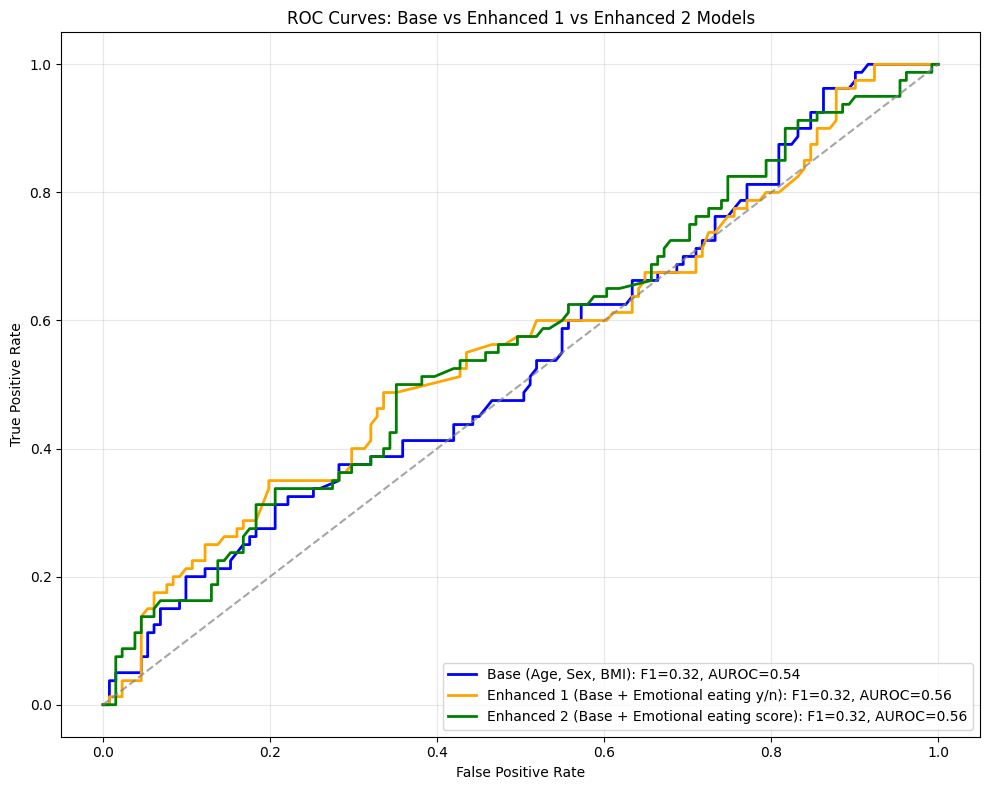


Permutation FI: calculated during model testing

Permutation Feature Importances (Base Model):
age: 0.009
sex_f: 0.020
baseline_bmi: 0.046

Permutation Feature Importances (Enhanced 1 Model):
age: 0.001
sex_f: 0.037
baseline_bmi: 0.059
emotional_eating_yn: 0.015

Permutation Feature Importances (Enhanced 1 Model):
age: -0.011
sex_f: 0.027
baseline_bmi: 0.019
emotional_eating_value_likert: -0.023

Feature importances saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_roc_fi\rf_fi_60d10p_all_eb_patients.xlsx
Output files saved in: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_roc_fi


In [ ]:
# Random Forest pipeline: Base (Anthropometry) vs Enhanced Full (all EBs included) vs Enhanced Reduced (only 3 EBs included) for 10% WL in 60d
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. CONFIG SECTION
DB_PATH = os.path.join(
    paper1_directory, "pnk_db2_p1_in.sqlite"
)
INPUT_TABLE = "timetoevent_eb_compl"  # Complete eating behavior patients

OUTPUT_DIR = os.path.join(paper1_directory, "rf_roc_fi")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Output file paths
roc_plot_path = os.path.join(OUTPUT_DIR, "rf_roc_60d10p_all_eb_patients.png")
fi_table_path = os.path.join(OUTPUT_DIR, "rf_fi_60d10p_all_eb_patients.xlsx")

BASE_PREDICTORS = [
    "age",
    "sex_f",
    # "baseline_weight_kg",
    "baseline_bmi",
    # "baseline_fat_%",
    # "baseline_muscle_%"
]

# Full eating behavior model (all 6 EB predictors)
ENHANCED_1_PREDICTORS = BASE_PREDICTORS + [
    # "hunger_yn", 
    # "satiety_yn", 
    "emotional_eating_yn",
    # "emotional_eating_value_likert", 
    # "quantity_control_likert", 
    # "impulse_control_likert"
]

# Reduced eating behavior model (3 selected EB predictors)
ENHANCED_2_PREDICTORS = BASE_PREDICTORS + [
    # "emotional_eating_yn",
    "emotional_eating_value_likert", 
    # "quantity_control_likert"
]

OUTCOME_RAW = "days_to_10%_wl"
OUTCOME_BIN = "wl_10p_60d_success"
OUTCOME_THRESHOLD = 65  # 60 days + 5 day permissivity window to catch edge cases

# Create a master list of all unique predictors needed for the entire script
ALL_PREDICTORS_NEEDED = list(set(BASE_PREDICTORS + ENHANCED_1_PREDICTORS + ENHANCED_2_PREDICTORS))

# 2. DATA LOADING AND PREPARATION
with sqlite3.connect(DB_PATH) as conn:
    # Quote columns with special characters for SQL
    quoted_cols = [f'"{col}"' for col in ALL_PREDICTORS_NEEDED + [OUTCOME_RAW, "60d_dropout"]]
    query = f"SELECT {', '.join(quoted_cols)} FROM {INPUT_TABLE}"
    df = pd.read_sql_query(query, conn)

# Fill missing values in days_to_10%_wl with 9999 to avoid misinterpretating NULL values as 0 days to weight loss
df[OUTCOME_RAW] = df[OUTCOME_RAW].fillna(9999)

# Create binary outcome: 1 if days_to_10%_wl <= 65 (60 + 5 day window), else 0
df[OUTCOME_BIN] = np.where(df[OUTCOME_RAW] <= OUTCOME_THRESHOLD, 1, 0)

# Check for class imbalance
print("\nClass Distribution:")
print(df[OUTCOME_BIN].value_counts(normalize=True))

# Drop rows with missing values in predictors
df = df.dropna(subset=ALL_PREDICTORS_NEEDED)
print(f"Number of subjects after removing missing predictor values: {len(df)}")

# 3. TRAIN-TEST SPLIT
X_base = df[BASE_PREDICTORS]
X_enhanced_1 = df[ENHANCED_1_PREDICTORS]
X_enhanced_2 = df[ENHANCED_2_PREDICTORS]
y = df[OUTCOME_BIN]

X_base_train, X_base_test, X_1_train, X_1_test, X_2_train, X_2_test, y_train, y_test = train_test_split(
    X_base, X_enhanced_1, X_enhanced_2, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# --- HYPERPARAMETER TUNING SECTION (GridSearchCV) ---
param_grid = {
    "max_depth": [5, 10, 20],
    "min_samples_split": [5, 10, 20, 30, 40],
    "min_samples_leaf": [2, 4, 8],
}

# --- THIS IS THE NEW FUNCTION YOU WILL ADD ---
def tune_gbm(X, y, label):
    # Step 1: Define the Gradient Boosting Classifier
    # Note: class_weight is not a parameter here. GBMs handle imbalance differently.
    gbm = GradientBoostingClassifier(
        n_estimators=100, # Start with a reasonable default
        random_state=42
    )
    
    # Step 2: Define a hyperparameter grid SPECIFIC to GBM
    # The key parameters are learning_rate, n_estimators, and max_depth
    param_grid = {
        "learning_rate": [0.05, 0.1],
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "min_samples_split": [10, 20],
        "min_samples_leaf": [4, 8]
    }

    # The rest of the GridSearchCV logic is identical
    grid = GridSearchCV(
        gbm, # Use the gbm model
        param_grid, # Use the gbm grid
        cv=10,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X, y)
    print(f"\nBest params for {label}: {grid.best_params_}")
    print(f"Best CV AUROC for {label}: {grid.best_score_:.3f}")
    return grid.best_estimator_

print("\nTuning base GBM model hyperparameters...")
gbm_base = tune_gbm(X_base_train, y_train, "Base GBM Model (Anthropometry Only)")

print("\nTuning enhanced 1 GBM model hyperparameters...")
gbm_enhanced_1 = tune_gbm(X_1_train, y_train, "Enhanced 1 GBM Model (...)")

print("\nTuning enhanced 2 GBM model hyperparameters...")
gbm_enhanced_2 = tune_gbm(X_2_train, y_train, "Enhanced 2 GBM Model (...)")

print("\nGINI FI: calculated during model training")

# Store GINI feature importances
gini_data = []

print("\nGINI Feature Importances (Base Model):")
for name, score in zip(BASE_PREDICTORS, gbm_base.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Base", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 1 Model):")
for name, score in zip(ENHANCED_1_PREDICTORS, gbm_enhanced_1.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_1", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 2 Model):")
for name, score in zip(ENHANCED_2_PREDICTORS, gbm_enhanced_2.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_2", "Feature": name, "GINI_Importance": score})

# 4. MODEL TESTING AND COMPARISON
y_base_proba = gbm_base.predict_proba(X_base_test)[:, 1]
y_1_proba = gbm_enhanced_1.predict_proba(X_1_test)[:, 1]
y_2_proba = gbm_enhanced_2.predict_proba(X_2_test)[:, 1]

y_base_pred = gbm_base.predict(X_base_test)
y_1_pred = gbm_enhanced_1.predict(X_1_test)
y_2_pred = gbm_enhanced_2.predict(X_2_test)

f1_base = f1_score(y_test, y_base_pred)
f1_1 = f1_score(y_test, y_1_pred)
f1_2 = f1_score(y_test, y_2_pred)

auroc_base = roc_auc_score(y_test, y_base_proba)
auroc_1 = roc_auc_score(y_test, y_1_proba)
auroc_2 = roc_auc_score(y_test, y_2_proba)

print(f"\nBase Model - F1: {f1_base:.3f}, AUROC: {auroc_base:.3f}")
print(f"Enhanced 1 Model - F1: {f1_1:.3f}, AUROC: {auroc_1:.3f}")
print(f"Enhanced 2 Model - F1: {f1_2:.3f}, AUROC: {auroc_2:.3f}")

# Plot ROC curves for all three models
fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
fpr_1, tpr_1, _ = roc_curve(y_test, y_1_proba)
fpr_2, tpr_2, _ = roc_curve(y_test, y_2_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr_base, tpr_base, color='blue', linewidth=2, 
         label=f'Base (Age, Sex, BMI): F1={f1_base:.2f}, AUROC={auroc_base:.2f}')
plt.plot(fpr_1, tpr_1, color='orange', linewidth=2, 
         label=f'Enhanced 1 (Base + Emotional eating y/n): F1={f1_1:.2f}, AUROC={auroc_1:.2f}')
plt.plot(fpr_2, tpr_2, color='green', linewidth=2, 
         label=f'Enhanced 2 (Base + Emotional eating score): F1={f1_1:.2f}, AUROC={auroc_2:.2f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--',alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Base vs Enhanced 1 vs Enhanced 2 Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save ROC plot
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
print(f"\nROC plot saved to: {roc_plot_path}")
plt.show()

print("\nPermutation FI: calculated during model testing")

# Store permutation feature importances
perm_data = []

# Permutation-based feature importance (on test set)
print("\nPermutation Feature Importances (Base Model):")
perm_base = permutation_importance(gbm_base, X_base_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(BASE_PREDICTORS, perm_base.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Base", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 1 Model):")
perm_1 = permutation_importance(gbm_enhanced_1, X_1_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_1_PREDICTORS, perm_1.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_1", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 1 Model):")
perm_reduced = permutation_importance(gbm_enhanced_2, X_2_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_2_PREDICTORS, perm_2.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_2", "Feature": name, "Permutation_Importance": score})

# Save feature importances to Excel
gini_df = pd.DataFrame(gini_data)
perm_df = pd.DataFrame(perm_data)

with pd.ExcelWriter(fi_table_path, engine='openpyxl') as writer:
    gini_df.to_excel(writer, sheet_name='GINI_Importances', index=False)
    perm_df.to_excel(writer, sheet_name='Permutation_Importances', index=False)

print(f"\nFeature importances saved to: {fi_table_path}")
print(f"Output files saved in: {OUTPUT_DIR}")

##### 2.1.a. RF code


Class Distribution:
wl_10p_60d_success
0    0.620722
1    0.379278
Name: proportion, dtype: float64
Number of subjects after removing missing predictor values: 1052

Tuning base model hyperparameters...

Best params for Base Model: {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best CV AUROC for Base Model: 0.563

Tuning enhanced 1 model hyperparameters...

Best params for Enhanced 1 Model: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV AUROC for Enhanced 1 Model: 0.584


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.



Base Model - F1: 0.468, AUROC: 0.570
Enhanced 1 Model - F1: 0.478, AUROC: 0.587


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

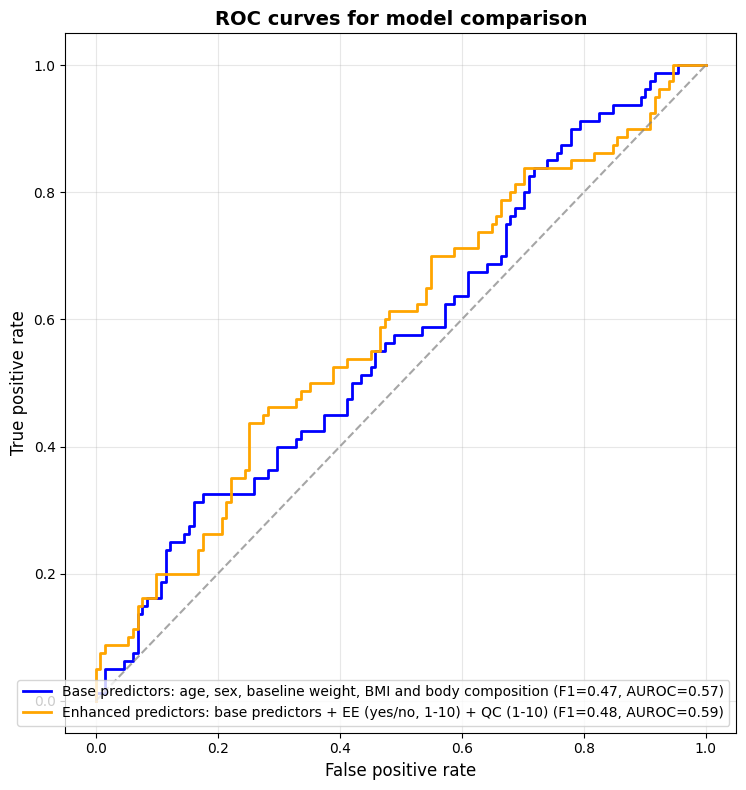

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

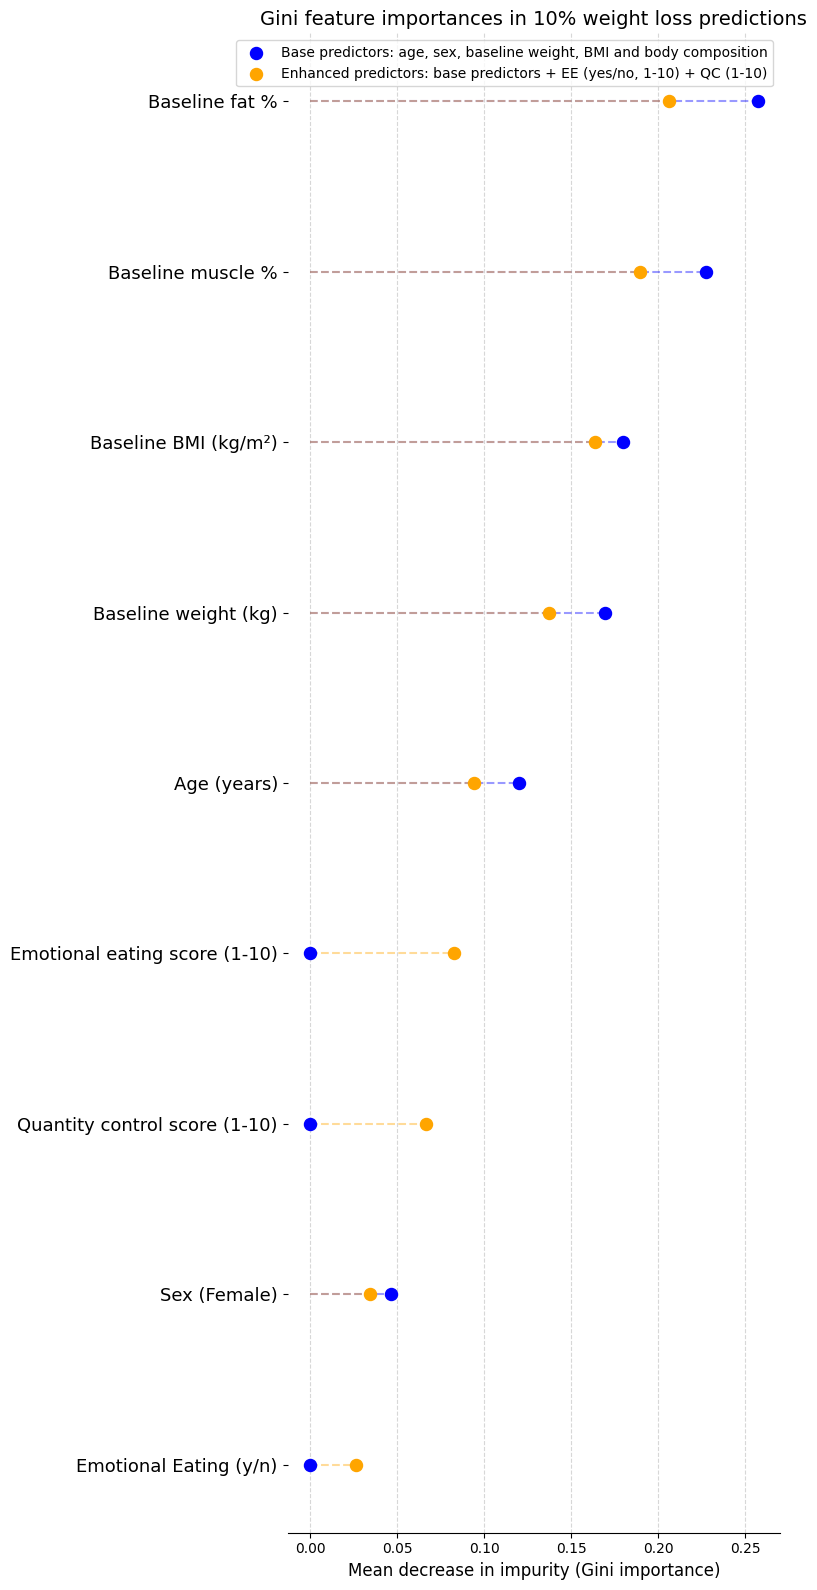


Permutation FI: calculated during model testing

Feature importances saved to: .\rf_roc_fi\rf_fi_60d10p_all_eb_patients.xlsx
Output files saved in: .\rf_roc_fi


In [55]:
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt

# 1. CONFIG SECTION
# Ensure paper1_directory is defined, e.g., paper1_directory = "path/to/your/output"
paper1_directory = "." # Replace with your actual directory path

DB_PATH = os.path.join(
    paper1_directory, "pnk_db2_p1_in.sqlite"
)
INPUT_TABLE = "timetoevent_eb_compl"  # Complete eating behavior patients

OUTPUT_DIR = os.path.join(paper1_directory, "rf_roc_fi")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Output file paths
composite_plot_path = os.path.join(OUTPUT_DIR, "rf_roc_gini_plot_60d10p.png")
fi_table_path = os.path.join(OUTPUT_DIR, "rf_fi_60d10p_all_eb_patients.xlsx")

BASE_PREDICTORS = [
    "age",
    "sex_f",
    "baseline_weight_kg",
    "baseline_bmi",
    "baseline_fat_%",
    "baseline_muscle_%"
]

# Full eating behavior model (all 6 EB predictors)
ENHANCED_1_PREDICTORS = BASE_PREDICTORS + [
    # "hunger_yn",
    # "satiety_yn",
    "emotional_eating_yn",
    "emotional_eating_value_likert",
    "quantity_control_likert",
    # "impulse_control_likert",
]

# Reduced eating behavior model (3 selected EB predictors)
# ENHANCED_2_PREDICTORS = BASE_PREDICTORS + [
#     "emotional_eating_yn",
#     "emotional_eating_value_likert",
#     "quantity_control_likert",
# ]

# --- NEW: Dictionary for human-readable feature names ---
NICE_PREDICTOR_NAMES = {
    "age": "Age (years)",
    "sex_f": "Sex (Female)",
    "baseline_weight_kg": "Baseline weight (kg)",
    "baseline_bmi": "Baseline BMI (kg/m²)",
    "baseline_fat_%": "Baseline fat %",
    "baseline_muscle_%": "Baseline muscle %",
    "hunger_yn": "Hunger (y/n)",
    "satiety_yn": "Satiety (y/n)",
    "emotional_eating_yn": "Emotional Eating (y/n)",
    "emotional_eating_value_likert": "Emotional eating score (1-10)",
    "quantity_control_likert": "Quantity control score (1-10)",
    "impulse_control_likert": "Impulse control score (1-10)"
}

OUTCOME_RAW = "days_to_10%_wl"
OUTCOME_BIN = "wl_10p_60d_success"
OUTCOME_THRESHOLD = 65  # 60 days + 5 day permissivity window

ALL_PREDICTORS_NEEDED = list(set(
    BASE_PREDICTORS + ENHANCED_1_PREDICTORS 
    # + ENHANCED_2_PREDICTORS
    ))

# 2. DATA LOADING AND PREPARATION
# Create a dummy database for demonstration purposes if the original is not available

with sqlite3.connect(DB_PATH) as conn:
    quoted_cols = [f'"{col}"' for col in ALL_PREDICTORS_NEEDED + [OUTCOME_RAW, "60d_dropout"]]
    query = f"SELECT {', '.join(quoted_cols)} FROM {INPUT_TABLE}"
    df = pd.read_sql_query(query, conn)

df[OUTCOME_RAW] = df[OUTCOME_RAW].fillna(9999)
df[OUTCOME_BIN] = np.where(df[OUTCOME_RAW] <= OUTCOME_THRESHOLD, 1, 0)

print("\nClass Distribution:")
print(df[OUTCOME_BIN].value_counts(normalize=True))

df = df.dropna(subset=ALL_PREDICTORS_NEEDED)
print(f"Number of subjects after removing missing predictor values: {len(df)}")

# 3. TRAIN-TEST SPLIT
X_base = df[BASE_PREDICTORS]
X_enhanced_1 = df[ENHANCED_1_PREDICTORS]
# X_enhanced_2 = df[ENHANCED_2_PREDICTORS]
y = df[OUTCOME_BIN]

# if you want to compare 3 models, include the following: X_2_train, X_2_test, (before y_train, y_test) and X_enhanced_2, before y
X_base_train, X_base_test, X_1_train, X_1_test, y_train, y_test = train_test_split(
    X_base, X_enhanced_1, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# --- HYPERPARAMETER TUNING SECTION (GridSearchCV) ---
param_grid = {
    "max_depth": [5, 10, 20],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 4, 8],
}

def tune_rf(X, y, label):
    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    )
    grid = GridSearchCV(
        rf,
        param_grid,
        cv=10,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=0 # Reduced verbosity for cleaner output
    )
    grid.fit(X, y)
    print(f"\nBest params for {label}: {grid.best_params_}")
    print(f"Best CV AUROC for {label}: {grid.best_score_:.3f}")
    return grid.best_estimator_

print("\nTuning base model hyperparameters...")
rf_base = tune_rf(X_base_train, y_train, "Base Model")

print("\nTuning enhanced 1 model hyperparameters...")
rf_enhanced_1 = tune_rf(X_1_train, y_train, "Enhanced 1 Model")

# print("\nTuning enhanced reduced model hyperparameters...")
# rf_enhanced_2 = tune_rf(X_2_train, y_train, "Enhanced Reduced Model")

# --- GINI FEATURE IMPORTANCE CALCULATION ---
gini_data = []
for name, score in zip(BASE_PREDICTORS, rf_base.feature_importances_):
    gini_data.append({"Model": "Base", "Feature": name, "GINI_Importance": score})
for name, score in zip(ENHANCED_1_PREDICTORS, rf_enhanced_1.feature_importances_):
    gini_data.append({"Model": "Enhanced_1", "Feature": name, "GINI_Importance": score})
# for name, score in zip(ENHANCED_2_PREDICTORS, rf_enhanced_2.feature_importances_):
#     gini_data.append({"Model": "Enhanced_2", "Feature": name, "GINI_Importance": score})

# 4. MODEL TESTING AND COMPARISON
y_base_proba = rf_base.predict_proba(X_base_test)[:, 1]
y_1_proba = rf_enhanced_1.predict_proba(X_1_test)[:, 1]
# y_2_proba = rf_enhanced_2.predict_proba(X_2_test)[:, 1]

y_base_pred = rf_base.predict(X_base_test)
y_1_pred = rf_enhanced_1.predict(X_1_test)
# y_2_pred = rf_enhanced_2.predict(X_2_test)

f1_base = f1_score(y_test, y_base_pred)
f1_1 = f1_score(y_test, y_1_pred)
# f1_2 = f1_score(y_test, y_2_pred)

auroc_base = roc_auc_score(y_test, y_base_proba)
auroc_1 = roc_auc_score(y_test, y_1_proba)
# auroc_2 = roc_auc_score(y_test, y_2_proba)

print(f"\nBase Model - F1: {f1_base:.3f}, AUROC: {auroc_base:.3f}")
print(f"Enhanced 1 Model - F1: {f1_1:.3f}, AUROC: {auroc_1:.3f}")
# print(f"Enhanced 2 Model - F1: {f1_2:.3f}, AUROC: {auroc_2:.3f}")



# --- 5. CREATE FIGURES (ROC + FEATURE IMPORTANCE) ---
# gini_df = pd.DataFrame(gini_data)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# # --- Panel 1: ROC Curves ---
# fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
# fpr_1, tpr_1, _ = roc_curve(y_test, y_1_proba)
# # fpr_2, tpr_2, _ = roc_curve(y_test, y_2_proba)

# ax1.plot(fpr_base, tpr_base, color='blue', linewidth=2,
#          label=f'Base (Anthropometry and body composition): F1={f1_base:.2f}, AUROC={auroc_base:.2f}')
# ax1.plot(fpr_1, tpr_1, color='orange', linewidth=2,
#          label=f'Enhanced (Base + emotional eating and quantity control): F1={f1_1:.2f}, AUROC={auroc_1:.2f}')
# # ax1.plot(fpr_2, tpr_2, color='green', linewidth=2,
# #          label=f'Enhanced (Reduced): F1={f1_2:.2f}, AUROC={auroc_2:.2f}')
# ax1.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7)
# ax1.set_xlabel('False Positive Rate', fontsize=12)
# ax1.set_ylabel('True Positive Rate', fontsize=12)
# ax1.set_title('A) ROC Curves for Model Comparison', loc='left', fontsize=14, fontweight='bold')
# ax1.legend(loc='lower right')
# ax1.grid(True, alpha=0.3)

# # --- Panel 2: GINI Feature Importance ---
# fi_pivot = gini_df.pivot(index='Feature', columns='Model', values='GINI_Importance').fillna(0)
# fi_pivot = fi_pivot.sort_values(by='Enhanced_1', ascending=True)

# # You can control which models to plot by editing the dictionaries below
# colors = {'Base': 'blue', 'Enhanced_1': 'orange', 'Enhanced_2': 'green'}
# model_labels = {'Base': 'Base', 'Enhanced_1': 'Enhanced (Full)', 'Enhanced_2': 'Enhanced (Reduced)'}

# y_range = np.arange(len(fi_pivot.index))
# for model_name, color in colors.items():
#     if model_name in fi_pivot.columns:
#         ax2.scatter(fi_pivot[model_name], y_range, color=color, s=75, label=model_labels[model_name], zorder=3)
#         ax2.hlines(y=y_range, xmin=0, xmax=fi_pivot[model_name], color=color, alpha=0.4, linestyles='--')

# # --- UPDATED: Use the dictionary to set nice labels ---
# sorted_features = fi_pivot.index
# nice_labels = [NICE_PREDICTOR_NAMES.get(feature, feature) for feature in sorted_features]
# ax2.set_yticks(y_range)
# ax2.set_yticklabels(nice_labels, fontsize=10) # Set nice labels

# ax2.set_xlabel("Mean Decrease in Impurity (Gini Importance)", fontsize=12)
# ax2.set_title('B) Gini Feature Importance', loc='left', fontsize=14, fontweight='bold')
# ax2.legend()
# ax2.grid(True, linestyle='--', alpha=0.5, axis='x')
# ax2.spines['top'].set_visible(False)
# ax2.spines['right'].set_visible(False)
# ax2.spines['left'].set_visible(False)

# # --- Final Figure Adjustments ---
# plt.tight_layout(pad=3.0)
# plt.savefig(composite_plot_path, dpi=300, bbox_inches='tight')
# print(f"\nComposite ROC & FI plot saved to: {composite_plot_path}")
# plt.show()

# # --- Panel 1: ROC Curves ---

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Helvetica' 

fig_roc, ax_roc = plt.subplots(figsize=(8, 8))  # 1:1 aspect

fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
fpr_1, tpr_1, _ = roc_curve(y_test, y_1_proba)
# # fpr_2, tpr_2, _ = roc_curve(y_test, y_2_proba)

ax_roc.plot(fpr_base, tpr_base, color='blue', linewidth=2,
            label=f'Base predictors: age, sex, baseline weight, BMI and body composition (F1={f1_base:.2f}, AUROC={auroc_base:.2f})')
ax_roc.plot(fpr_1, tpr_1, color='orange', linewidth=2,
            label=f'Enhanced predictors: base predictors + EE (yes/no, 1-10) + QC (1-10) (F1={f1_1:.2f}, AUROC={auroc_1:.2f})')
ax_roc.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7)
ax_roc.set_xlabel('False positive rate', fontsize=12)
ax_roc.set_ylabel('True positive rate', fontsize=12)
ax_roc.set_title('ROC curves for model comparison', fontsize=14, fontweight='bold')
ax_roc.legend(loc='lower right')
ax_roc.grid(True, alpha=0.3)

roc_svg_path = os.path.join(OUTPUT_DIR, "rf_roc_curve_60d10p.svg")
plt.tight_layout()
fig_roc.savefig(roc_svg_path, format='svg', bbox_inches='tight', dpi=300)
plt.show()


# # --- Panel 2: GINI Feature Importance ---

fig_gini, ax_gini = plt.subplots(figsize=(8, 16))  # 1:2 aspect (width:height)

gini_df = pd.DataFrame(gini_data)
fi_pivot = gini_df.pivot(index='Feature', columns='Model', values='GINI_Importance').fillna(0)
fi_pivot = fi_pivot.sort_values(by='Enhanced_1', ascending=True)

colors = {'Base': 'blue', 'Enhanced_1': 'orange', 'Enhanced_2': 'green'}
model_labels = {'Base': 'Base predictors: age, sex, baseline weight, BMI and body composition', 
                'Enhanced_1': 'Enhanced predictors: base predictors + EE (yes/no, 1-10) + QC (1-10)', 
                # 'Enhanced_2': 'Enhanced (Reduced)'
                }

y_range = np.arange(len(fi_pivot.index))
for model_name, color in colors.items():
    if model_name in fi_pivot.columns:
        ax_gini.scatter(fi_pivot[model_name], y_range, color=color, s=75, label=model_labels[model_name], zorder=3)
        ax_gini.hlines(y=y_range, xmin=0, xmax=fi_pivot[model_name], color=color, alpha=0.4, linestyles='--')
nice_labels = [NICE_PREDICTOR_NAMES.get(feature, feature) for feature in fi_pivot.index]

ax_gini.set_yticks(y_range)
ax_gini.set_yticklabels(nice_labels, fontsize=13)
ax_gini.set_xlabel("Mean decrease in impurity (Gini importance)", fontsize=12)
ax_gini.set_title('Gini feature importances in 10% weight loss predictions', fontsize=14)
ax_gini.legend()
ax_gini.grid(True, linestyle='--', alpha=0.5, axis='x')
ax_gini.spines['top'].set_visible(False)
ax_gini.spines['right'].set_visible(False)
ax_gini.spines['left'].set_visible(False)

gini_svg_path = os.path.join(OUTPUT_DIR, "rf_gini_fi_60d10p.svg")
plt.tight_layout()
fig_gini.savefig(gini_svg_path, format='svg', bbox_inches='tight', dpi=300)
plt.show()





# --- PERMUTATION IMPORTANCE (Original code maintained) ---
print("\nPermutation FI: calculated during model testing")
perm_data = []
perm_base = permutation_importance(rf_base, X_base_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(BASE_PREDICTORS, perm_base.importances_mean):
    perm_data.append({"Model": "Base", "Feature": name, "Permutation_Importance": score})

perm_1 = permutation_importance(rf_enhanced_1, X_1_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_1_PREDICTORS, perm_1.importances_mean):
    perm_data.append({"Model": "Enhanced_Full", "Feature": name, "Permutation_Importance": score})

# perm_2 = permutation_importance(rf_enhanced_2, X_2_test, y_test, n_repeats=10, random_state=42)
# for name, score in zip(ENHANCED_2_PREDICTORS, perm_2.importances_mean):
#     perm_data.append({"Model": "Enhanced_Reduced", "Feature": name, "Permutation_Importance": score})

perm_df = pd.DataFrame(perm_data)
with pd.ExcelWriter(fi_table_path, engine='openpyxl') as writer:
    gini_df.to_excel(writer, sheet_name='GINI_Importances', index=False)
    perm_df.to_excel(writer, sheet_name='Permutation_Importances', index=False)

print(f"\nFeature importances saved to: {fi_table_path}")
print(f"Output files saved in: {OUTPUT_DIR}")


##### 2.1.b. model characteristics & results 17Jun25

**SETTINGS**
- train/test: 
- - 80/20
- - stratified for outcome
- - random_state = 42
- hyperparameter tuning: 10-fold GridSearchCV
- hyperparameters set during GSCV: 
- - max_depth
- - min_samples_leaf
- - min_samples_split
- fixed hyperparameters 
- - n_estimators = 200
- - class_weight = 'balanced_subsample'
- - n_jobs = -1
- - verbose=1
- - random_state = 42

**BRIEFLY**
- improved performance
- inclusion of EBs worsenes prediction, adds noise

**RESULTS**

- **Base Model (Anthropometry Only) - F1: 0.468, AUROC: 0.570**
- **Enhanced Full Model (Anthropometry + All 6 EB) - F1: 0.511, AUROC: 0.590**
- **Enhanced Reduced Model (Anthropometry + 3 EB) - F1: 0.486, AUROC: 0.594**


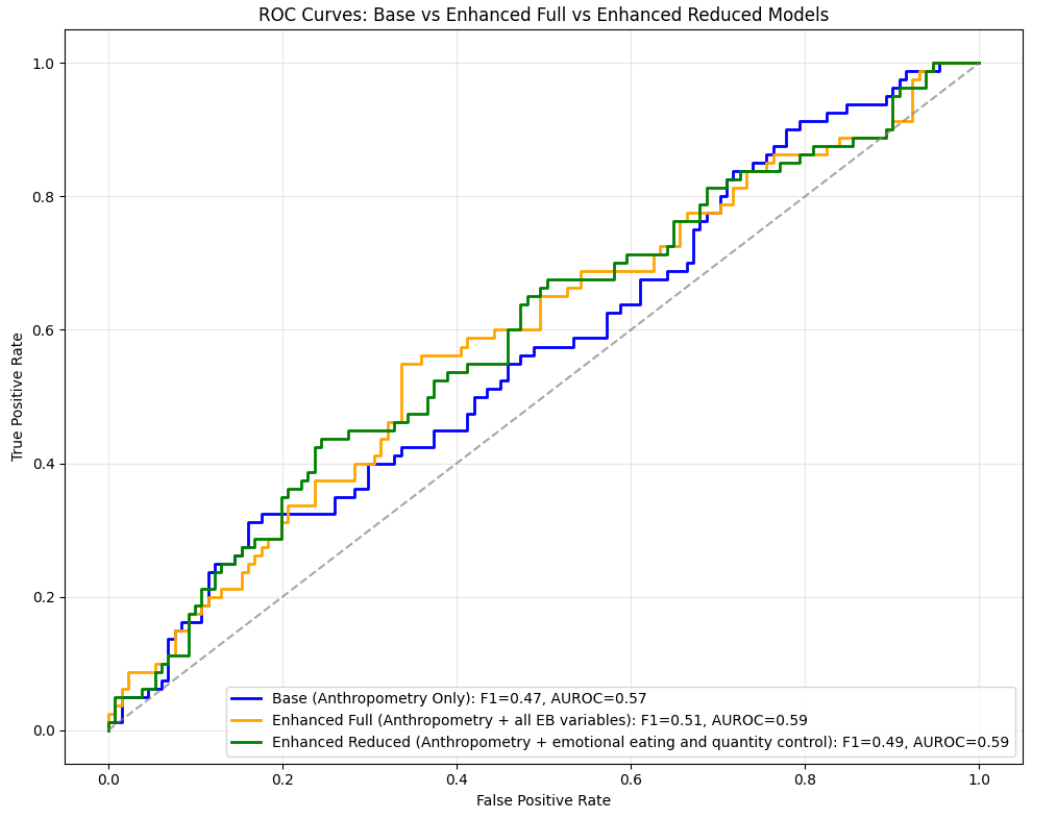

Class Distribution:
wl_10p_60d_success
0    0.620722
1    0.379278

GINI FI: calculated during model training

GINI Feature Importances (Base Model):
age: 0.120
sex_f: 0.047
baseline_weight_kg: 0.169
baseline_bmi: 0.179
baseline_fat_%: 0.257
baseline_muscle_%: 0.227

GINI Feature Importances (Enhanced Full Model):
age: 0.086
sex_f: 0.033
baseline_weight_kg: 0.143
baseline_bmi: 0.126
baseline_fat_%: 0.182
baseline_muscle_%: 0.199
hunger_yn: 0.008
satiety_yn: 0.011
emotional_eating_yn: 0.035
emotional_eating_value_likert: 0.075
quantity_control_likert: 0.050
impulse_control_likert: 0.053

GINI Feature Importances (Enhanced Reduced Model):
age: 0.094
sex_f: 0.033
baseline_weight_kg: 0.128
baseline_bmi: 0.168
baseline_fat_%: 0.211
baseline_muscle_%: 0.201
emotional_eating_yn: 0.027
emotional_eating_value_likert: 0.082
quantity_control_likert: 0.056

Permutation FI: calculated during model testing

Permutation Feature Importances (Base Model):
age: -0.001
sex_f: 0.007
baseline_weight_kg: -0.030
baseline_bmi: -0.048
baseline_fat_%: -0.022
baseline_muscle_%: -0.012

Permutation Feature Importances (Enhanced Full Model):
age: -0.006
sex_f: -0.003
baseline_weight_kg: -0.011
baseline_bmi: -0.011
baseline_fat_%: -0.002
baseline_muscle_%: -0.002
hunger_yn: -0.006
satiety_yn: 0.004
emotional_eating_yn: 0.012
emotional_eating_value_likert: 0.022
quantity_control_likert: -0.002
impulse_control_likert: -0.014

Permutation Feature Importances (Enhanced Reduced Model):
age: -0.001
sex_f: -0.002
baseline_weight_kg: -0.018
baseline_bmi: -0.020
baseline_fat_%: -0.003
baseline_muscle_%: 0.004
emotional_eating_yn: 0.007
emotional_eating_value_likert: -0.001
quantity_control_likert: 0.013


#### 2.2. Tuned 60d10p predictions on those who reached 60 days

##### 2.2.a. RF code

Number of subjects: 542

Class Distribution:
wl_10p_60d_success
1    0.643911
0    0.356089
Name: proportion, dtype: float64
Number of subjects after removing missing predictor values: 542

Tuning base model hyperparameters...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Best params for Base Model: {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 40}
Best CV AUROC for Base Model: 0.602

Tuning enhanced full model hyperparameters...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Best params for Enhanced 1 Model: {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 30}
Best CV AUROC for Enhanced 1 Model: 0.602

Tuning enhanced reduced model hyperparameters...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Best params for Enhanced 2 Model: {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 40}
Best CV AUROC for Enhanced 2 Model: 0.609

GINI FI: calculated during model training

GINI Feature Importances (Base 

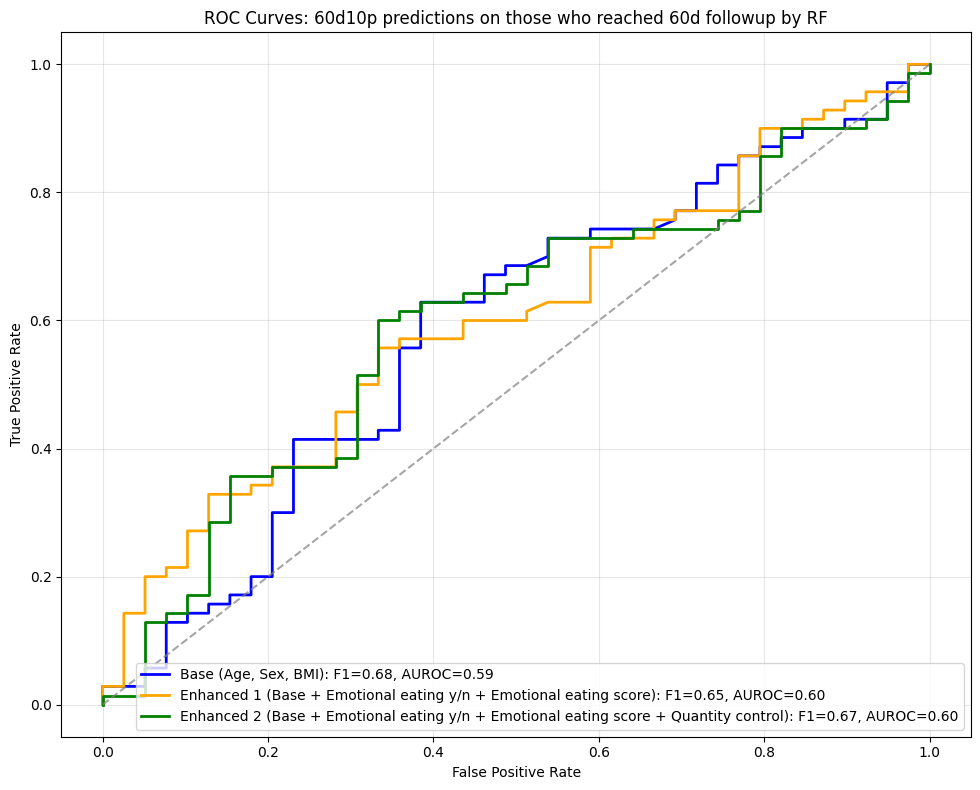


Permutation FI: calculated during model testing

Permutation Feature Importances (Base Model):
age: -0.022
sex_f: 0.022
baseline_bmi: 0.055

Permutation Feature Importances (Enhanced 1 Model):
age: -0.057
sex_f: 0.002
baseline_bmi: 0.025
emotional_eating_yn: -0.024
emotional_eating_value_likert: -0.001

Permutation Feature Importances (Enhanced 2 Model):
age: -0.003
sex_f: -0.004
baseline_bmi: 0.043
emotional_eating_yn: 0.008
emotional_eating_value_likert: -0.003
quantity_control_likert: -0.002

Feature importances saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_roc_fi\rf_fi_60d10p_nondropout_eb_patients.xlsx
Output files saved in: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_roc_fi


In [ ]:
# Random Forest pipeline: Base (Anthropometry) vs Enhanced Full (all EBs included) vs Enhanced Reduced (only 3 EBs included) for 10% WL in 60d
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. CONFIG SECTION
DB_PATH = os.path.join(
    paper1_directory, "pnk_db2_p1_in.sqlite"
)
INPUT_TABLE = "timetoevent_eb_compl"  # Complete eating behavior patients

OUTPUT_DIR = os.path.join(paper1_directory, "rf_roc_fi")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Output file paths
roc_plot_path = os.path.join(OUTPUT_DIR, "rf_roc_60d10p_nondropout_eb_patients.png")
fi_table_path = os.path.join(OUTPUT_DIR, "rf_fi_60d10p_nondropout_eb_patients.xlsx")

BASE_PREDICTORS = [
    "age", 
    "sex_f", 
    # "baseline_weight_kg", 
    "baseline_bmi", 
    # "baseline_fat_%", 
    # "baseline_muscle_%"
]

# Full eating behavior model (all 6 EB predictors)
ENHANCED_1_PREDICTORS = BASE_PREDICTORS + [
    # "hunger_yn", 
    # "satiety_yn", 
    "emotional_eating_yn",
    "emotional_eating_value_likert", 
    # "quantity_control_likert", 
    # "impulse_control_likert"
]

# Reduced eating behavior model (3 selected EB predictors)
ENHANCED_2_PREDICTORS = BASE_PREDICTORS + [
    "emotional_eating_yn",
    "emotional_eating_value_likert", 
    "quantity_control_likert"
]

OUTCOME_RAW = "days_to_10%_wl"
OUTCOME_BIN = "wl_10p_60d_success"
OUTCOME_THRESHOLD = 65  # 60 days + 5 day permissivity window to catch edge cases

# Create a master list of all unique predictors needed for the entire script
ALL_PREDICTORS_NEEDED = list(set(BASE_PREDICTORS + ENHANCED_1_PREDICTORS + ENHANCED_2_PREDICTORS))

# 2. DATA LOADING AND PREPARATION
with sqlite3.connect(DB_PATH) as conn:
    # Quote columns with special characters for SQL
    quoted_cols = [f'"{col}"' for col in ALL_PREDICTORS_NEEDED + [OUTCOME_RAW, "60d_dropout"]]
    query = f"SELECT {', '.join(quoted_cols)} FROM {INPUT_TABLE}"
    df = pd.read_sql_query(query, conn)

# Exclude patients who did NOT reach 60 days of followup (60d_dropout = 1)
df = df[df["60d_dropout"] != 1]
print(f"Number of subjects: {len(df)}")

# Fill missing values in days_to_10%_wl with 9999 to avoid misinterpretating NULL values as 0 days to weight loss
df[OUTCOME_RAW] = df[OUTCOME_RAW].fillna(9999)

# Create binary outcome: 1 if days_to_10%_wl <= 65 (60 + 5 day window), else 0
df[OUTCOME_BIN] = np.where(df[OUTCOME_RAW] <= OUTCOME_THRESHOLD, 1, 0)

# Check for class imbalance
print("\nClass Distribution:")
print(df[OUTCOME_BIN].value_counts(normalize=True))

# Drop rows with missing values in predictors
df = df.dropna(subset=ENHANCED_1_PREDICTORS)
print(f"Number of subjects after removing missing predictor values: {len(df)}")

# 3. TRAIN-TEST SPLIT
X_base = df[BASE_PREDICTORS]
X_enhanced_1 = df[ENHANCED_1_PREDICTORS]
X_enhanced_2 = df[ENHANCED_2_PREDICTORS]
y = df[OUTCOME_BIN]

X_base_train, X_base_test, X_1_train, X_1_test, X_2_train, X_2_test, y_train, y_test = train_test_split(
    X_base, X_enhanced_1, X_enhanced_2, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# --- HYPERPARAMETER TUNING SECTION (GridSearchCV) ---
param_grid = {
    "max_depth": [5, 10, 20],
    "min_samples_split": [5, 10, 20, 30, 40],
    "min_samples_leaf": [2, 4, 8],
}

def tune_rf(X, y, label):
    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    )
    grid = GridSearchCV(
        rf,
        param_grid,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X, y)
    print(f"\nBest params for {label}: {grid.best_params_}")
    print(f"Best CV AUROC for {label}: {grid.best_score_:.3f}")
    return grid.best_estimator_

print("\nTuning base model hyperparameters...")
rf_base = tune_rf(X_base_train, y_train, "Base Model")

print("\nTuning enhanced full model hyperparameters...")
rf_enhanced_1 = tune_rf(X_1_train, y_train, "Enhanced 1 Model")

print("\nTuning enhanced reduced model hyperparameters...")
rf_enhanced_2 = tune_rf(X_2_train, y_train, "Enhanced 2 Model")

print("\nGINI FI: calculated during model training")

# Store GINI feature importances
gini_data = []

print("\nGINI Feature Importances (Base Model):")
for name, score in zip(BASE_PREDICTORS, rf_base.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Base", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 1 Model):")
for name, score in zip(ENHANCED_1_PREDICTORS, rf_enhanced_1.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_1", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 2 Model):")
for name, score in zip(ENHANCED_2_PREDICTORS, rf_enhanced_2.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_2", "Feature": name, "GINI_Importance": score})

# 4. MODEL TESTING AND COMPARISON
y_base_proba = rf_base.predict_proba(X_base_test)[:, 1]
y_1_proba = rf_enhanced_1.predict_proba(X_1_test)[:, 1]
y_2_proba = rf_enhanced_2.predict_proba(X_2_test)[:, 1]

y_base_pred = rf_base.predict(X_base_test)
y_1_pred = rf_enhanced_1.predict(X_1_test)
y_2_pred = rf_enhanced_2.predict(X_2_test)

f1_base = f1_score(y_test, y_base_pred)
f1_1 = f1_score(y_test, y_1_pred)
f1_2 = f1_score(y_test, y_2_pred)

auroc_base = roc_auc_score(y_test, y_base_proba)
auroc_1 = roc_auc_score(y_test, y_1_proba)
auroc_2 = roc_auc_score(y_test, y_2_proba)

print(f"\nBase Model - F1: {f1_base:.3f}, AUROC: {auroc_base:.3f}")
print(f"Enhanced 1 Model - F1: {f1_1:.3f}, AUROC: {auroc_1:.3f}")
print(f"Enhanced 2 Model - F1: {f1_2:.3f}, AUROC: {auroc_2:.3f}")

# Plot ROC curves for all three models
fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
fpr_1, tpr_1, _ = roc_curve(y_test, y_1_proba)
fpr_2, tpr_2, _ = roc_curve(y_test, y_2_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr_base, tpr_base, color='blue', linewidth=2, 
         label=f'Base (Age, Sex, BMI): F1={f1_base:.2f}, AUROC={auroc_base:.2f}')
plt.plot(fpr_1, tpr_1, color='orange', linewidth=2, 
         label=f'Enhanced 1 (Base + Emotional eating y/n + Emotional eating score): F1={f1_1:.2f}, AUROC={auroc_1:.2f}')
plt.plot(fpr_2, tpr_2, color='green', linewidth=2, 
         label=f'Enhanced 2 (Base + Emotional eating y/n + Emotional eating score + Quantity control): F1={f1_2:.2f}, AUROC={auroc_2:.2f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--',alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: 60d10p predictions on those who reached 60d followup by RF')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save ROC plot
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
print(f"\nROC plot saved to: {roc_plot_path}")
plt.show()

print("\nPermutation FI: calculated during model testing")

# Store permutation feature importances
perm_data = []

# Permutation-based feature importance (on test set)
print("\nPermutation Feature Importances (Base Model):")
perm_base = permutation_importance(rf_base, X_base_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(BASE_PREDICTORS, perm_base.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Base", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 1 Model):")
perm_1 = permutation_importance(rf_enhanced_1, X_1_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_1_PREDICTORS, perm_1.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_1", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 2 Model):")
perm_2 = permutation_importance(rf_enhanced_2, X_2_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_2_PREDICTORS, perm_2.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_2", "Feature": name, "Permutation_Importance": score})

# Save feature importances to Excel
gini_df = pd.DataFrame(gini_data)
perm_df = pd.DataFrame(perm_data)

with pd.ExcelWriter(fi_table_path, engine='openpyxl') as writer:
    gini_df.to_excel(writer, sheet_name='GINI_Importances', index=False)
    perm_df.to_excel(writer, sheet_name='Permutation_Importances', index=False)

print(f"\nFeature importances saved to: {fi_table_path}")
print(f"Output files saved in: {OUTPUT_DIR}")

##### 2.2.b. GBM code

Number of subjects: 542

Class Distribution:
wl_10p_60d_success
1    0.643911
0    0.356089
Name: proportion, dtype: float64
Number of subjects after removing missing predictor values: 542

Tuning base model hyperparameters...
Fitting 10 folds for each of 32 candidates, totalling 320 fits

Best params for Base Model: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 10, 'n_estimators': 100}
Best CV AUROC for Base Model: 0.601

Tuning enhanced full model hyperparameters...
Fitting 10 folds for each of 32 candidates, totalling 320 fits

Best params for Enhanced 1 Model: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 10, 'n_estimators': 100}
Best CV AUROC for Enhanced 1 Model: 0.590

Tuning enhanced reduced model hyperparameters...
Fitting 10 folds for each of 32 candidates, totalling 320 fits

Best params for Enhanced 2 Model: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 10, 'n_es

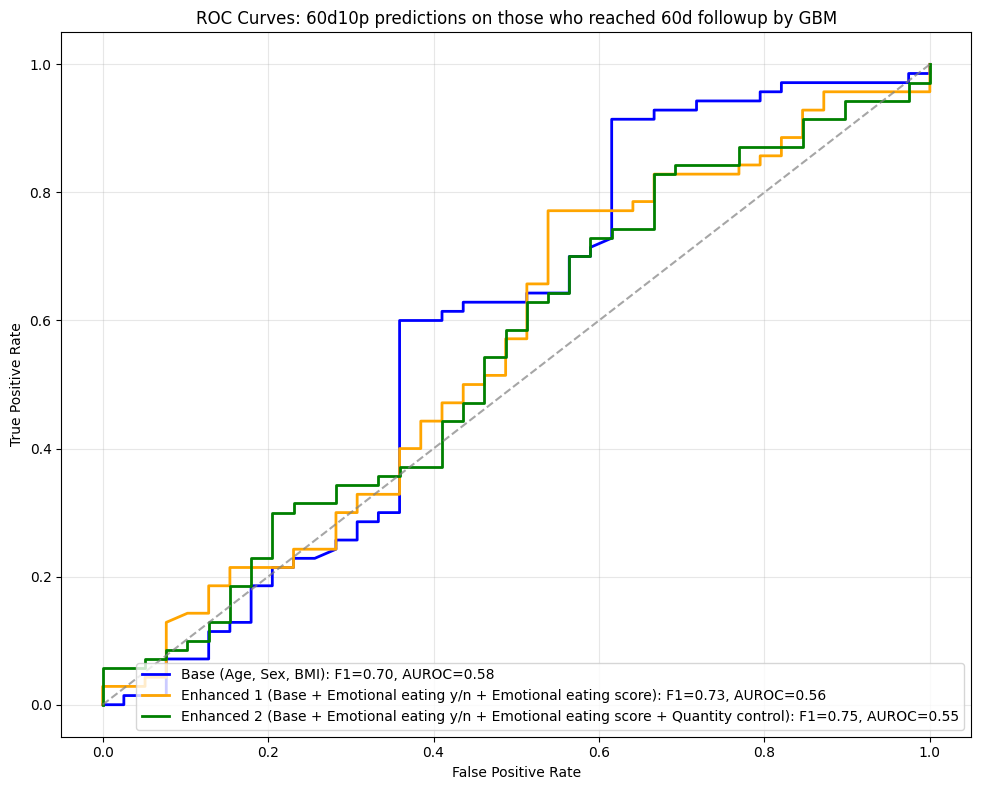


Permutation FI: calculated during model testing

Permutation Feature Importances (Base Model):
age: -0.006
sex_f: -0.006
baseline_bmi: 0.031

Permutation Feature Importances (Enhanced 1 Model):
age: 0.004
sex_f: -0.003
baseline_bmi: 0.060
emotional_eating_yn: -0.010
emotional_eating_value_likert: 0.015

Permutation Feature Importances (Enhanced 2 Model):
age: 0.009
sex_f: -0.006
baseline_bmi: 0.046
emotional_eating_yn: 0.004
emotional_eating_value_likert: 0.002
quantity_control_likert: 0.025

Feature importances saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_roc_fi\rf_fi_60d10p_nondropout_eb_patients.xlsx
Output files saved in: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_roc_fi


In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. CONFIG SECTION
DB_PATH = os.path.join(
    paper1_directory, "pnk_db2_p1_in.sqlite"
)
INPUT_TABLE = "timetoevent_eb_compl"  # Complete eating behavior patients

OUTPUT_DIR = os.path.join(paper1_directory, "rf_roc_fi")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Output file paths
roc_plot_path = os.path.join(OUTPUT_DIR, "rf_roc_60d10p_nondropout_eb_patients.png")
fi_table_path = os.path.join(OUTPUT_DIR, "rf_fi_60d10p_nondropout_eb_patients.xlsx")

BASE_PREDICTORS = [
    "age", 
    "sex_f", 
    # "baseline_weight_kg", 
    "baseline_bmi", 
    # "baseline_fat_%", 
    # "baseline_muscle_%"
]

# Full eating behavior model (all 6 EB predictors)
ENHANCED_1_PREDICTORS = BASE_PREDICTORS + [
    # "hunger_yn", 
    # "satiety_yn", 
    "emotional_eating_yn",
    "emotional_eating_value_likert", 
    # "quantity_control_likert", 
    # "impulse_control_likert"
]

# Reduced eating behavior model (3 selected EB predictors)
ENHANCED_2_PREDICTORS = BASE_PREDICTORS + [
    "emotional_eating_yn",
    "emotional_eating_value_likert", 
    "quantity_control_likert"
]

OUTCOME_RAW = "days_to_10%_wl"
OUTCOME_BIN = "wl_10p_60d_success"
OUTCOME_THRESHOLD = 65  # 60 days + 5 day permissivity window to catch edge cases

# Create a master list of all unique predictors needed for the entire script
ALL_PREDICTORS_NEEDED = list(set(BASE_PREDICTORS + ENHANCED_1_PREDICTORS + ENHANCED_2_PREDICTORS))

# 2. DATA LOADING AND PREPARATION
with sqlite3.connect(DB_PATH) as conn:
    # Quote columns with special characters for SQL
    quoted_cols = [f'"{col}"' for col in ALL_PREDICTORS_NEEDED + [OUTCOME_RAW, "60d_dropout"]]
    query = f"SELECT {', '.join(quoted_cols)} FROM {INPUT_TABLE}"
    df = pd.read_sql_query(query, conn)

# Exclude patients who did NOT reach 60 days of followup (60d_dropout = 1)
df = df[df["60d_dropout"] != 1]
print(f"Number of subjects: {len(df)}")

# Fill missing values in days_to_10%_wl with 9999 to avoid misinterpretating NULL values as 0 days to weight loss
df[OUTCOME_RAW] = df[OUTCOME_RAW].fillna(9999)

# Create binary outcome: 1 if days_to_10%_wl <= 65 (60 + 5 day window), else 0
df[OUTCOME_BIN] = np.where(df[OUTCOME_RAW] <= OUTCOME_THRESHOLD, 1, 0)

# Check for class imbalance
print("\nClass Distribution:")
print(df[OUTCOME_BIN].value_counts(normalize=True))

# Drop rows with missing values in predictors
df = df.dropna(subset=ENHANCED_1_PREDICTORS)
print(f"Number of subjects after removing missing predictor values: {len(df)}")

# 3. TRAIN-TEST SPLIT
X_base = df[BASE_PREDICTORS]
X_enhanced_1 = df[ENHANCED_1_PREDICTORS]
X_enhanced_2 = df[ENHANCED_2_PREDICTORS]
y = df[OUTCOME_BIN]

X_base_train, X_base_test, X_1_train, X_1_test, X_2_train, X_2_test, y_train, y_test = train_test_split(
    X_base, X_enhanced_1, X_enhanced_2, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# --- HYPERPARAMETER TUNING SECTION (GridSearchCV) ---
def tune_gbm(X, y, label):
    # Step 1: Define the Gradient Boosting Classifier
    # Note: class_weight is not a parameter here. GBMs handle imbalance differently.
    gbm = GradientBoostingClassifier(
        n_estimators=100, # Start with a reasonable default
        random_state=42
    )
    
    # Step 2: Define a hyperparameter grid SPECIFIC to GBM
    # The key parameters are learning_rate, n_estimators, and max_depth
    param_grid = {
        "learning_rate": [0.05, 0.1],
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "min_samples_split": [10, 20],
        "min_samples_leaf": [4, 8]
    }

    # The rest of the GridSearchCV logic is identical
    grid = GridSearchCV(
        gbm, # Use the gbm model
        param_grid, # Use the gbm grid
        cv=10,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X, y)
    print(f"\nBest params for {label}: {grid.best_params_}")
    print(f"Best CV AUROC for {label}: {grid.best_score_:.3f}")
    return grid.best_estimator_

print("\nTuning base model hyperparameters...")
gbm_base = tune_gbm(X_base_train, y_train, "Base Model")

print("\nTuning enhanced full model hyperparameters...")
gbm_enhanced_1 = tune_gbm(X_1_train, y_train, "Enhanced 1 Model")

print("\nTuning enhanced reduced model hyperparameters...")
gbm_enhanced_2 = tune_gbm(X_2_train, y_train, "Enhanced 2 Model")

print("\nGINI FI: calculated during model training")

# Store GINI feature importances
gini_data = []

print("\nGINI Feature Importances (Base Model):")
for name, score in zip(BASE_PREDICTORS, rf_base.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Base", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 1 Model):")
for name, score in zip(ENHANCED_1_PREDICTORS, rf_enhanced_1.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_1", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 2 Model):")
for name, score in zip(ENHANCED_2_PREDICTORS, rf_enhanced_2.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_2", "Feature": name, "GINI_Importance": score})

# 4. MODEL TESTING AND COMPARISON
y_base_proba = gbm_base.predict_proba(X_base_test)[:, 1]
y_1_proba = gbm_enhanced_1.predict_proba(X_1_test)[:, 1]
y_2_proba = gbm_enhanced_2.predict_proba(X_2_test)[:, 1]

y_base_pred = gbm_base.predict(X_base_test)
y_1_pred = gbm_enhanced_1.predict(X_1_test)
y_2_pred = gbm_enhanced_2.predict(X_2_test)

f1_base = f1_score(y_test, y_base_pred)
f1_1 = f1_score(y_test, y_1_pred)
f1_2 = f1_score(y_test, y_2_pred)

auroc_base = roc_auc_score(y_test, y_base_proba)
auroc_1 = roc_auc_score(y_test, y_1_proba)
auroc_2 = roc_auc_score(y_test, y_2_proba)

print(f"\nBase Model - F1: {f1_base:.3f}, AUROC: {auroc_base:.3f}")
print(f"Enhanced 1 Model - F1: {f1_1:.3f}, AUROC: {auroc_1:.3f}")
print(f"Enhanced 2 - F1: {f1_2:.3f}, AUROC: {auroc_2:.3f}")

# Plot ROC curves for all three models
fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
fpr_1, tpr_1, _ = roc_curve(y_test, y_1_proba)
fpr_2, tpr_2, _ = roc_curve(y_test, y_2_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr_base, tpr_base, color='blue', linewidth=2, 
         label=f'Base (Age, Sex, BMI): F1={f1_base:.2f}, AUROC={auroc_base:.2f}')
plt.plot(fpr_1, tpr_1, color='orange', linewidth=2, 
         label=f'Enhanced 1 (Base + Emotional eating y/n + Emotional eating score): F1={f1_1:.2f}, AUROC={auroc_1:.2f}')
plt.plot(fpr_2, tpr_2, color='green', linewidth=2, 
         label=f'Enhanced 2 (Base + Emotional eating y/n + Emotional eating score + Quantity control): F1={f1_2:.2f}, AUROC={auroc_2:.2f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--',alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: 60d10p predictions on those who reached 60d followup by GBM')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save ROC plot
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
print(f"\nROC plot saved to: {roc_plot_path}")
plt.show()


print("\nPermutation FI: calculated during model testing")

# Store permutation feature importances
perm_data = []

# Permutation-based feature importance (on test set)
print("\nPermutation Feature Importances (Base Model):")
perm_base = permutation_importance(gbm_base, X_base_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(BASE_PREDICTORS, perm_base.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Base", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 1 Model):")
perm_1 = permutation_importance(gbm_enhanced_1, X_1_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_1_PREDICTORS, perm_1.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_1", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 2 Model):")
perm_2 = permutation_importance(gbm_enhanced_2, X_2_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_2_PREDICTORS, perm_2.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_2", "Feature": name, "Permutation_Importance": score})

# Save feature importances to Excel
gini_df = pd.DataFrame(gini_data)
perm_df = pd.DataFrame(perm_data)

with pd.ExcelWriter(fi_table_path, engine='openpyxl') as writer:
    gini_df.to_excel(writer, sheet_name='GINI_Importances', index=False)
    perm_df.to_excel(writer, sheet_name='Permutation_Importances', index=False)

print(f"\nFeature importances saved to: {fi_table_path}")
print(f"Output files saved in: {OUTPUT_DIR}")

#### 2.3. Tuned 60d dropout predictions on the whole population

##### 2.3.a. RF code


Class Distribution (0 = No Dropout, 1 = Dropout):
60d_dropout
0    0.515209
1    0.484791
Name: proportion, dtype: float64
Number of subjects after removing missing values: 1052

Tuning base model hyperparameters...
Fitting 10 folds for each of 45 candidates, totalling 450 fits

Best params for Base Model: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 40}
Best CV AUROC for Base Model: 0.579

Tuning enhanced 1 model hyperparameters...
Fitting 10 folds for each of 45 candidates, totalling 450 fits

Best params for Enhanced 1 Model: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 40}
Best CV AUROC for Enhanced 1 Model: 0.580

Tuning enhanced 2 model hyperparameters...
Fitting 10 folds for each of 45 candidates, totalling 450 fits

Best params for Enhanced 2 Model: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV AUROC for Enhanced 2 Model: 0.588

GINI FI: calculated during model training

GINI Feature Importances (Base Model):
age: 0.44

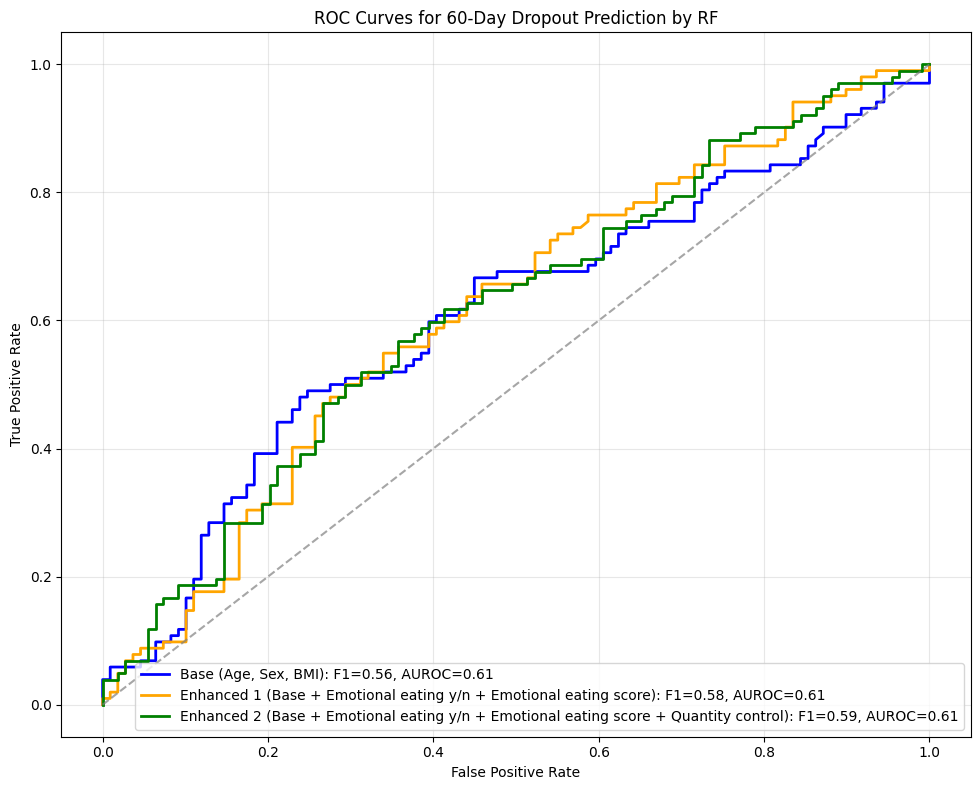


Permutation FI: calculated during model testing

Permutation Feature Importances (Base Model):
age: 0.079
sex_f: 0.021
baseline_bmi: 0.045

Permutation Feature Importances (Enhanced 1 Model):
age: 0.064
sex_f: 0.024
baseline_bmi: 0.034
emotional_eating_yn: 0.001
emotional_eating_value_likert: -0.005

Permutation Feature Importances (Enhanced 2 Model):
age: 0.082
sex_f: 0.016
baseline_bmi: 0.042
emotional_eating_yn: 0.002
emotional_eating_value_likert: 0.007
quantity_control_likert: 0.023

Feature importances saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_dropout_prediction\rf_fi_60d_dropout.xlsx
Output files saved in: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_dropout_prediction


In [ ]:
# Random Forest pipeline: Base (Anthropometry) vs Enhanced Models for 60d Dropout Prediction
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. CONFIG SECTION
# Assuming paper1_directory is defined elsewhere
# paper1_directory = "path/to/your/project" 

DB_PATH = os.path.join(
    paper1_directory, "pnk_db2_p1_in.sqlite"
)
INPUT_TABLE = "timetoevent_eb_compl"  # Complete eating behavior patients

OUTPUT_DIR = os.path.join(paper1_directory, "rf_dropout_prediction")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Output file paths updated for the new task
roc_plot_path = os.path.join(OUTPUT_DIR, "rf_roc_60d_dropout.png")
fi_table_path = os.path.join(OUTPUT_DIR, "rf_fi_60d_dropout.xlsx")

BASE_PREDICTORS = [
    "age", 
    "sex_f", 
    # "baseline_weight_kg",
    "baseline_bmi", 
    # "baseline_fat_%",
    # "baseline_muscle_%"
]

# Full eating behavior model (all 6 EB predictors)
ENHANCED_1_PREDICTORS = BASE_PREDICTORS + [
    # "hunger_yn", 
    # "satiety_yn", 
    "emotional_eating_yn",
    "emotional_eating_value_likert", 
    # "quantity_control_likert", 
    # "impulse_control_likert"
]

# Reduced eating behavior model (3 selected EB predictors)
ENHANCED_2_PREDICTORS = BASE_PREDICTORS + [
    "emotional_eating_yn",
    "emotional_eating_value_likert", 
    "quantity_control_likert"
]

# --- MODIFIED: Define the new outcome variable ---
OUTCOME_BIN = "60d_dropout" # Target is now dropout status

# Create a master list of all unique predictors needed for the entire script
ALL_PREDICTORS_NEEDED = list(set(BASE_PREDICTORS + ENHANCED_1_PREDICTORS + ENHANCED_2_PREDICTORS))

# 2. DATA LOADING AND PREPARATION
with sqlite3.connect(DB_PATH) as conn:
    # Load all predictors and the new outcome variable
    columns_to_load = ALL_PREDICTORS_NEEDED + [OUTCOME_BIN]
    quoted_cols = [f'"{col}"' for col in columns_to_load]
    query = f"SELECT {', '.join(quoted_cols)} FROM {INPUT_TABLE}"
    df = pd.read_sql_query(query, conn)

# Check for class imbalance in the new target
print("\nClass Distribution (0 = No Dropout, 1 = Dropout):")
print(df[OUTCOME_BIN].value_counts(normalize=True))

# Drop rows with missing values in predictors OR the outcome
df = df.dropna(subset=ALL_PREDICTORS_NEEDED + [OUTCOME_BIN])
print(f"Number of subjects after removing missing values: {len(df)}")

# 3. TRAIN-TEST SPLIT
X_base = df[BASE_PREDICTORS]
X_enhanced_1 = df[ENHANCED_1_PREDICTORS]
X_enhanced_2 = df[ENHANCED_2_PREDICTORS]
y = df[OUTCOME_BIN] # Use the new outcome variable

X_base_train, X_base_test, X_1_train, X_1_test, X_2_train, X_2_test, y_train, y_test = train_test_split(
    X_base, X_enhanced_1, X_enhanced_2, y,
    test_size=0.2,
    stratify=y, # Stratify by dropout status
    random_state=42,
)

# --- HYPERPARAMETER TUNING SECTION (GridSearchCV) ---
param_grid = {
    "max_depth": [5, 10, 20],
    "min_samples_split": [5, 10, 20, 30, 40],
    "min_samples_leaf": [2, 4, 8],
}

def tune_rf(X, y, label):
    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    )
    grid = GridSearchCV(
        rf,
        param_grid,
        cv=10,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X, y)
    print(f"\nBest params for {label}: {grid.best_params_}")
    print(f"Best CV AUROC for {label}: {grid.best_score_:.3f}")
    return grid.best_estimator_

print("\nTuning base model hyperparameters...")
rf_base = tune_rf(X_base_train, y_train, "Base Model")

print("\nTuning enhanced 1 model hyperparameters...")
rf_enhanced_1 = tune_rf(X_1_train, y_train, "Enhanced 1 Model")

print("\nTuning enhanced 2 model hyperparameters...")
rf_enhanced_2 = tune_rf(X_2_train, y_train, "Enhanced 2 Model")

print("\nGINI FI: calculated during model training")

# Store GINI feature importances
gini_data = []

print("\nGINI Feature Importances (Base Model):")
for name, score in zip(BASE_PREDICTORS, rf_base.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Base", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 1 Model):")
for name, score in zip(ENHANCED_1_PREDICTORS, rf_enhanced_1.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_1", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 2 Model):")
for name, score in zip(ENHANCED_2_PREDICTORS, rf_enhanced_2.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_2", "Feature": name, "GINI_Importance": score})

# 4. MODEL TESTING AND COMPARISON
y_base_proba = rf_base.predict_proba(X_base_test)[:, 1]
y_1_proba = rf_enhanced_1.predict_proba(X_1_test)[:, 1]
y_2_proba = rf_enhanced_2.predict_proba(X_2_test)[:, 1]

y_base_pred = rf_base.predict(X_base_test)
y_1_pred = rf_enhanced_1.predict(X_1_test)
y_2_pred = rf_enhanced_2.predict(X_2_test)

f1_base = f1_score(y_test, y_base_pred)
f1_1 = f1_score(y_test, y_1_pred)
f1_2 = f1_score(y_test, y_2_pred)

auroc_base = roc_auc_score(y_test, y_base_proba)
auroc_1 = roc_auc_score(y_test, y_1_proba)
auroc_2 = roc_auc_score(y_test, y_2_proba)

print(f"\n--- Dropout Prediction Performance ---")
print(f"Base Model - F1: {f1_base:.3f}, AUROC: {auroc_base:.3f}")
print(f"Enhanced 1 Model - F1: {f1_1:.3f}, AUROC: {auroc_1:.3f}")
print(f"Enhanced 2 Model - F1: {f1_2:.3f}, AUROC: {auroc_2:.3f}")

# Plot ROC curves for all three models
fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
fpr_1, tpr_1, _ = roc_curve(y_test, y_1_proba)
fpr_2, tpr_2, _ = roc_curve(y_test, y_2_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr_base, tpr_base, color='blue', linewidth=2, 
         label=f'Base (Age, Sex, BMI): F1={f1_base:.2f}, AUROC={auroc_base:.2f}')
plt.plot(fpr_1, tpr_1, color='orange', linewidth=2, 
         label=f'Enhanced 1 (Base + Emotional eating y/n + Emotional eating score): F1={f1_1:.2f}, AUROC={auroc_1:.2f}')
plt.plot(fpr_2, tpr_2, color='green', linewidth=2, 
         label=f'Enhanced 2 (Base + Emotional eating y/n + Emotional eating score + Quantity control): F1={f1_2:.2f}, AUROC={auroc_2:.2f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--',alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for 60-Day Dropout Prediction by RF')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save ROC plot
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
print(f"\nROC plot saved to: {roc_plot_path}")
plt.show()

print("\nPermutation FI: calculated during model testing")

# Store permutation feature importances
perm_data = []

# Permutation-based feature importance (on test set)
print("\nPermutation Feature Importances (Base Model):")
perm_base = permutation_importance(rf_base, X_base_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(BASE_PREDICTORS, perm_base.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Base", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 1 Model):")
perm_1 = permutation_importance(rf_enhanced_1, X_1_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_1_PREDICTORS, perm_1.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_1", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 2 Model):")
perm_2 = permutation_importance(rf_enhanced_2, X_2_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_2_PREDICTORS, perm_2.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_2", "Feature": name, "Permutation_Importance": score})

# Save feature importances to Excel
gini_df = pd.DataFrame(gini_data)
perm_df = pd.DataFrame(perm_data)

with pd.ExcelWriter(fi_table_path, engine='openpyxl') as writer:
    gini_df.to_excel(writer, sheet_name='GINI_Importances', index=False)
    perm_df.to_excel(writer, sheet_name='Permutation_Importances', index=False)

print(f"\nFeature importances saved to: {fi_table_path}")
print(f"Output files saved in: {OUTPUT_DIR}")

##### 2.3.b. GBM code


Class Distribution (0 = No Dropout, 1 = Dropout):
60d_dropout
0    0.515209
1    0.484791
Name: proportion, dtype: float64
Number of subjects after removing missing values: 1052

Tuning base model hyperparameters...
Fitting 10 folds for each of 32 candidates, totalling 320 fits

Best params for Base Model: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV AUROC for Base Model: 0.561

Tuning enhanced 1 model hyperparameters...
Fitting 10 folds for each of 32 candidates, totalling 320 fits

Best params for Enhanced 1 Model: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 10, 'n_estimators': 100}
Best CV AUROC for Enhanced 1 Model: 0.560

Tuning enhanced 2 model hyperparameters...
Fitting 10 folds for each of 32 candidates, totalling 320 fits

Best params for Enhanced 2 Model: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 10, 'n_estimators': 100}
Be

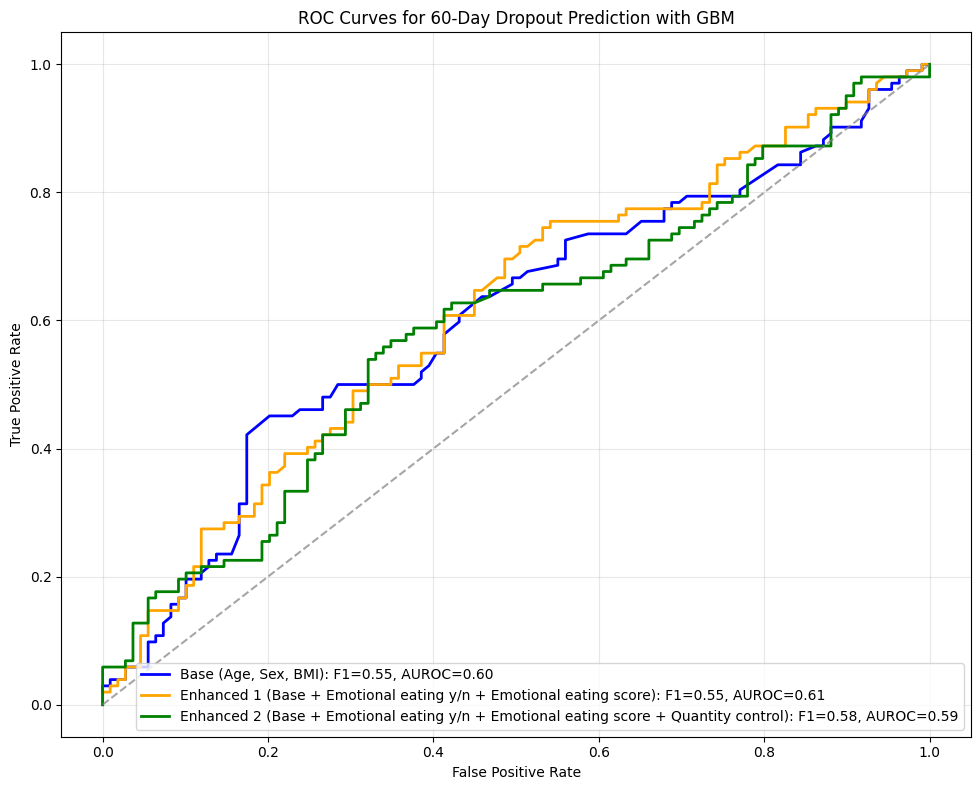


Permutation FI: calculated during model testing

Permutation Feature Importances (Base Model):
age: 0.079
sex_f: 0.021
baseline_bmi: 0.060

Permutation Feature Importances (Enhanced 1 Model):
age: 0.029
sex_f: 0.015
baseline_bmi: 0.027
emotional_eating_yn: -0.008
emotional_eating_value_likert: -0.039

Permutation Feature Importances (Enhanced 2 Model):
age: 0.071
sex_f: 0.013
baseline_bmi: 0.063
emotional_eating_yn: 0.001
emotional_eating_value_likert: 0.030
quantity_control_likert: 0.017

Feature importances saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_dropout_prediction\rf_fi_60d_dropout.xlsx
Output files saved in: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_dropout_prediction


In [ ]:
# Random Forest pipeline: Base (Anthropometry) vs Enhanced Models for 60d Dropout Prediction
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

DB_PATH = os.path.join(
    paper1_directory, "pnk_db2_p1_in.sqlite"
)
INPUT_TABLE = "timetoevent_eb_compl"  # Complete eating behavior patients

OUTPUT_DIR = os.path.join(paper1_directory, "rf_dropout_prediction")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Output file paths updated for the new task
roc_plot_path = os.path.join(OUTPUT_DIR, "rf_roc_60d_dropout.png")
fi_table_path = os.path.join(OUTPUT_DIR, "rf_fi_60d_dropout.xlsx")

BASE_PREDICTORS = [
    "age", 
    "sex_f", 
    # "baseline_weight_kg",
    "baseline_bmi", 
    # "baseline_fat_%",
    # "baseline_muscle_%"
]

# Full eating behavior model (all 6 EB predictors)
ENHANCED_1_PREDICTORS = BASE_PREDICTORS + [
    # "hunger_yn", 
    # "satiety_yn", 
    "emotional_eating_yn",
    "emotional_eating_value_likert", 
    # "quantity_control_likert", 
    # "impulse_control_likert"
]

# Reduced eating behavior model (3 selected EB predictors)
ENHANCED_2_PREDICTORS = BASE_PREDICTORS + [
    "emotional_eating_yn",
    "emotional_eating_value_likert", 
    "quantity_control_likert"
]

# --- MODIFIED: Define the new outcome variable ---
OUTCOME_BIN = "60d_dropout" # Target is now dropout status

# Create a master list of all unique predictors needed for the entire script
ALL_PREDICTORS_NEEDED = list(set(BASE_PREDICTORS + ENHANCED_1_PREDICTORS + ENHANCED_2_PREDICTORS))

# 2. DATA LOADING AND PREPARATION
with sqlite3.connect(DB_PATH) as conn:
    # Load all predictors and the new outcome variable
    columns_to_load = ALL_PREDICTORS_NEEDED + [OUTCOME_BIN]
    quoted_cols = [f'"{col}"' for col in columns_to_load]
    query = f"SELECT {', '.join(quoted_cols)} FROM {INPUT_TABLE}"
    df = pd.read_sql_query(query, conn)

# Check for class imbalance in the new target
print("\nClass Distribution (0 = No Dropout, 1 = Dropout):")
print(df[OUTCOME_BIN].value_counts(normalize=True))

# Drop rows with missing values in predictors OR the outcome
df = df.dropna(subset=ALL_PREDICTORS_NEEDED + [OUTCOME_BIN])
print(f"Number of subjects after removing missing values: {len(df)}")

# 3. TRAIN-TEST SPLIT
X_base = df[BASE_PREDICTORS]
X_enhanced_1 = df[ENHANCED_1_PREDICTORS]
X_enhanced_2 = df[ENHANCED_2_PREDICTORS]
y = df[OUTCOME_BIN] # Use the new outcome variable

X_base_train, X_base_test, X_1_train, X_1_test, X_2_train, X_2_test, y_train, y_test = train_test_split(
    X_base, X_enhanced_1, X_enhanced_2, y,
    test_size=0.2,
    stratify=y, # Stratify by dropout status
    random_state=42,
)

# --- HYPERPARAMETER TUNING SECTION (GridSearchCV) ---
param_grid = {
    "max_depth": [5, 10, 20],
    "min_samples_split": [5, 10, 20, 30, 40],
    "min_samples_leaf": [2, 4, 8],
}

# --- THIS IS THE NEW FUNCTION YOU WILL ADD ---
def tune_gbm(X, y, label):
    # Step 1: Define the Gradient Boosting Classifier
    # Note: class_weight is not a parameter here. GBMs handle imbalance differently.
    gbm = GradientBoostingClassifier(
        n_estimators=100, # Start with a reasonable default
        random_state=42
    )
    
    # Step 2: Define a hyperparameter grid SPECIFIC to GBM
    # The key parameters are learning_rate, n_estimators, and max_depth
    param_grid = {
        "learning_rate": [0.05, 0.1],
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "min_samples_split": [10, 20],
        "min_samples_leaf": [4, 8]
    }

    # The rest of the GridSearchCV logic is identical
    grid = GridSearchCV(
        gbm, # Use the gbm model
        param_grid, # Use the gbm grid
        cv=10,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X, y)
    print(f"\nBest params for {label}: {grid.best_params_}")
    print(f"Best CV AUROC for {label}: {grid.best_score_:.3f}")
    return grid.best_estimator_

print("\nTuning base model hyperparameters...")
gbm_base = tune_gbm(X_base_train, y_train, "Base Model")

print("\nTuning enhanced 1 model hyperparameters...")
gbm_enhanced_1 = tune_gbm(X_1_train, y_train, "Enhanced 1 Model")

print("\nTuning enhanced 2 model hyperparameters...")
gbm_enhanced_2 = tune_gbm(X_2_train, y_train, "Enhanced 2 Model")

print("\nGINI FI: calculated during model training")

# Store GINI feature importances
gini_data = []

print("\nGINI Feature Importances (Base Model):")
for name, score in zip(BASE_PREDICTORS, gbm_base.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Base", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 1 Model):")
for name, score in zip(ENHANCED_1_PREDICTORS, gbm_enhanced_1.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_1", "Feature": name, "GINI_Importance": score})

print("\nGINI Feature Importances (Enhanced 2 Model):")
for name, score in zip(ENHANCED_2_PREDICTORS, gbm_enhanced_2.feature_importances_):
    print(f"{name}: {score:.3f}")
    gini_data.append({"Model": "Enhanced_2", "Feature": name, "GINI_Importance": score})

# 4. MODEL TESTING AND COMPARISON
y_base_proba = gbm_base.predict_proba(X_base_test)[:, 1]
y_1_proba = gbm_enhanced_1.predict_proba(X_1_test)[:, 1]
y_2_proba = gbm_enhanced_2.predict_proba(X_2_test)[:, 1]

y_base_pred = gbm_base.predict(X_base_test)
y_1_pred = gbm_enhanced_1.predict(X_1_test)
y_2_pred = gbm_enhanced_2.predict(X_2_test)

f1_base = f1_score(y_test, y_base_pred)
f1_1 = f1_score(y_test, y_1_pred)
f1_2 = f1_score(y_test, y_2_pred)

auroc_base = roc_auc_score(y_test, y_base_proba)
auroc_1 = roc_auc_score(y_test, y_1_proba)
auroc_2 = roc_auc_score(y_test, y_2_proba)

print(f"\n--- Dropout Prediction Performance ---")
print(f"Base Model - F1: {f1_base:.3f}, AUROC: {auroc_base:.3f}")
print(f"Enhanced 1 Model - F1: {f1_1:.3f}, AUROC: {auroc_1:.3f}")
print(f"Enhanced 2 Model - F1: {f1_2:.3f}, AUROC: {auroc_2:.3f}")

# Plot ROC curves for all three models
fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
fpr_1, tpr_1, _ = roc_curve(y_test, y_1_proba)
fpr_2, tpr_2, _ = roc_curve(y_test, y_2_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr_base, tpr_base, color='blue', linewidth=2, 
         label=f'Base (Age, Sex, BMI): F1={f1_base:.2f}, AUROC={auroc_base:.2f}')
plt.plot(fpr_1, tpr_1, color='orange', linewidth=2, 
         label=f'Enhanced 1 (Base + Emotional eating y/n + Emotional eating score): F1={f1_1:.2f}, AUROC={auroc_1:.2f}')
plt.plot(fpr_2, tpr_2, color='green', linewidth=2, 
         label=f'Enhanced 2 (Base + Emotional eating y/n + Emotional eating score + Quantity control): F1={f1_2:.2f}, AUROC={auroc_2:.2f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--',alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for 60-Day Dropout Prediction with GBM')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save ROC plot
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
print(f"\nROC plot saved to: {roc_plot_path}")
plt.show()

print("\nPermutation FI: calculated during model testing")

# Store permutation feature importances
perm_data = []

# Permutation-based feature importance (on test set)
print("\nPermutation Feature Importances (Base Model):")
perm_base = permutation_importance(gbm_base, X_base_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(BASE_PREDICTORS, perm_base.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Base", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 1 Model):")
perm_1 = permutation_importance(gbm_enhanced_1, X_1_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_1_PREDICTORS, perm_1.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_1", "Feature": name, "Permutation_Importance": score})

print("\nPermutation Feature Importances (Enhanced 2 Model):")
perm_2 = permutation_importance(gbm_enhanced_2, X_2_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_2_PREDICTORS, perm_2.importances_mean):
    print(f"{name}: {score:.3f}")
    perm_data.append({"Model": "Enhanced_2", "Feature": name, "Permutation_Importance": score})

# Save feature importances to Excel
gini_df = pd.DataFrame(gini_data)
perm_df = pd.DataFrame(perm_data)

with pd.ExcelWriter(fi_table_path, engine='openpyxl') as writer:
    gini_df.to_excel(writer, sheet_name='GINI_Importances', index=False)
    perm_df.to_excel(writer, sheet_name='Permutation_Importances', index=False)

print(f"\nFeature importances saved to: {fi_table_path}")
print(f"Output files saved in: {OUTPUT_DIR}")

### RF sandbox


Class Distribution:
wl_10p_60d_success
0    0.620722
1    0.379278
Name: proportion, dtype: float64
Number of subjects after removing missing predictor values: 1052

Tuning base model hyperparameters...

Best params for Base Model: {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best CV AUROC for Base Model: 0.563

Tuning enhanced 1 model hyperparameters...

Best params for Enhanced 1 Model: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV AUROC for Enhanced 1 Model: 0.584


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 


Base Model - F1: 0.468, AUROC: 0.570
Enhanced 1 Model - F1: 0.478, AUROC: 0.587


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

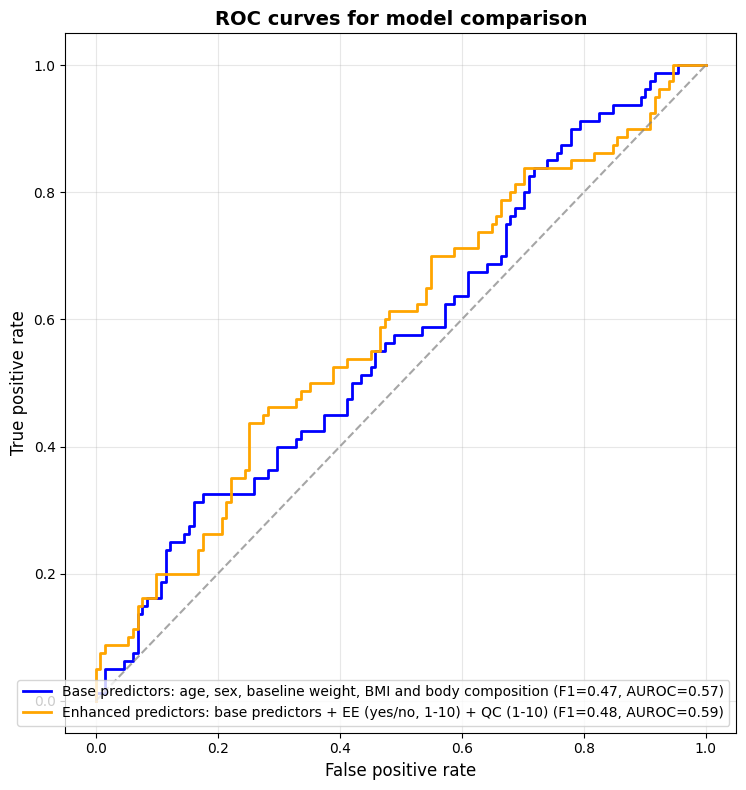

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

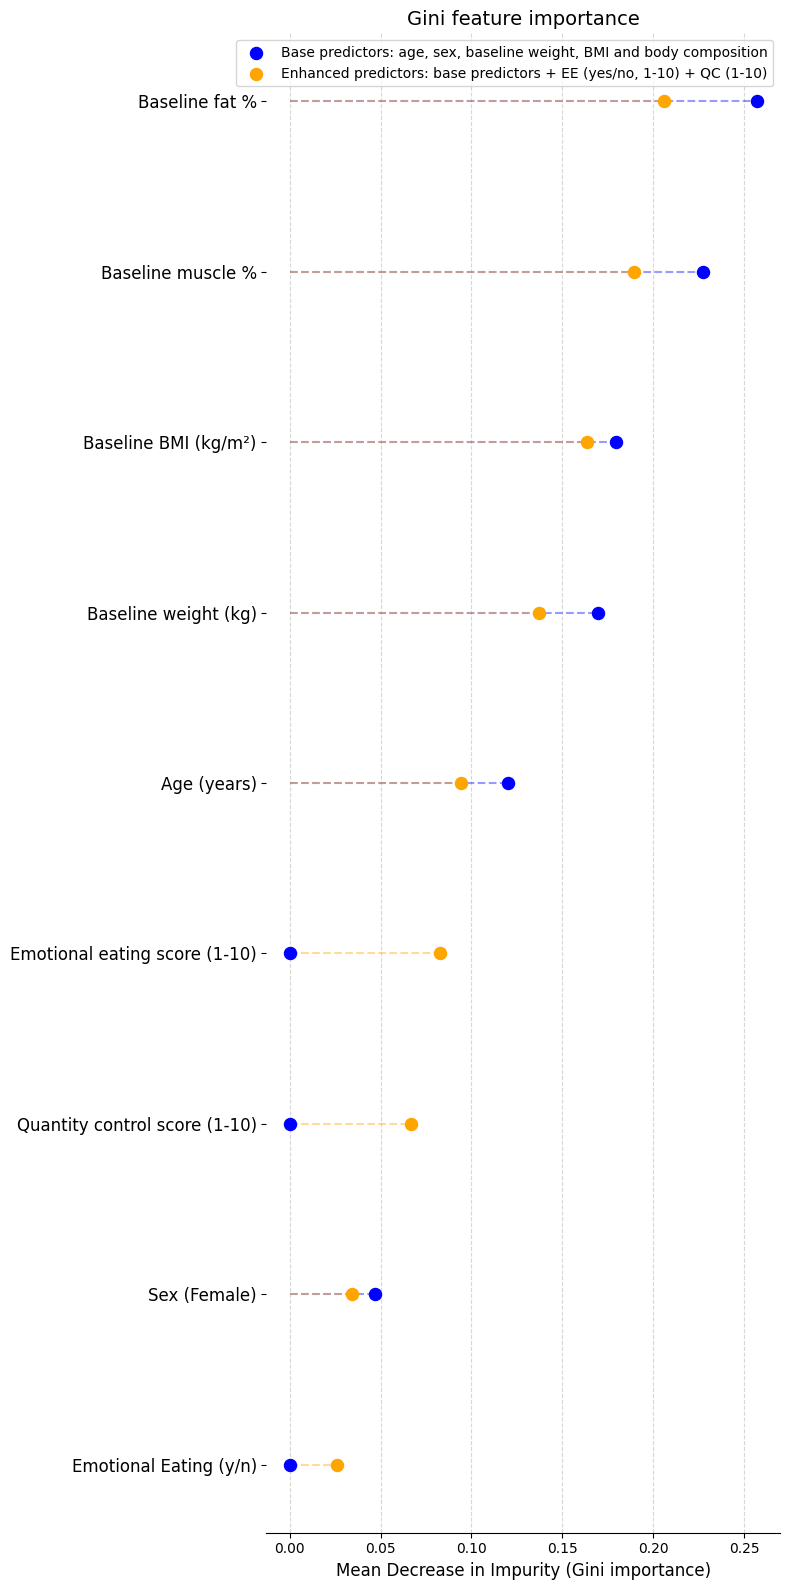


Permutation FI: calculated during model testing

Feature importances saved to: .\rf_roc_fi\rf_fi_60d10p_all_eb_patients.xlsx
Output files saved in: .\rf_roc_fi


In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt

# 1. CONFIG SECTION
# Ensure paper1_directory is defined, e.g., paper1_directory = "path/to/your/output"
paper1_directory = "." # Replace with your actual directory path

DB_PATH = os.path.join(
    paper1_directory, "pnk_db2_p1_in.sqlite"
)
INPUT_TABLE = "timetoevent_eb_compl"  # Complete eating behavior patients

OUTPUT_DIR = os.path.join(paper1_directory, "rf_roc_fi")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Output file paths
composite_plot_path = os.path.join(OUTPUT_DIR, "rf_roc_gini_plot_60d10p.png")
fi_table_path = os.path.join(OUTPUT_DIR, "rf_fi_60d10p_all_eb_patients.xlsx")

BASE_PREDICTORS = [
    "age",
    "sex_f",
    "baseline_weight_kg",
    "baseline_bmi",
    "baseline_fat_%",
    "baseline_muscle_%"
]

# Full eating behavior model (all 6 EB predictors)
ENHANCED_1_PREDICTORS = BASE_PREDICTORS + [
    # "hunger_yn",
    # "satiety_yn",
    "emotional_eating_yn",
    "emotional_eating_value_likert",
    "quantity_control_likert",
    # "impulse_control_likert",
]

# Reduced eating behavior model (3 selected EB predictors)
# ENHANCED_2_PREDICTORS = BASE_PREDICTORS + [
#     "emotional_eating_yn",
#     "emotional_eating_value_likert",
#     "quantity_control_likert",
# ]

# --- NEW: Dictionary for human-readable feature names ---
NICE_PREDICTOR_NAMES = {
    "age": "Age (years)",
    "sex_f": "Sex (Female)",
    "baseline_weight_kg": "Baseline weight (kg)",
    "baseline_bmi": "Baseline BMI (kg/m²)",
    "baseline_fat_%": "Baseline fat %",
    "baseline_muscle_%": "Baseline muscle %",
    "hunger_yn": "Hunger (y/n)",
    "satiety_yn": "Satiety (y/n)",
    "emotional_eating_yn": "Emotional Eating (y/n)",
    "emotional_eating_value_likert": "Emotional eating score (1-10)",
    "quantity_control_likert": "Quantity control score (1-10)",
    "impulse_control_likert": "Impulse control score (1-10)"
}

OUTCOME_RAW = "days_to_10%_wl"
OUTCOME_BIN = "wl_10p_60d_success"
OUTCOME_THRESHOLD = 65  # 60 days + 5 day permissivity window

ALL_PREDICTORS_NEEDED = list(set(
    BASE_PREDICTORS + ENHANCED_1_PREDICTORS 
    # + ENHANCED_2_PREDICTORS
    ))

# 2. DATA LOADING AND PREPARATION
# Create a dummy database for demonstration purposes if the original is not available

with sqlite3.connect(DB_PATH) as conn:
    quoted_cols = [f'"{col}"' for col in ALL_PREDICTORS_NEEDED + [OUTCOME_RAW, "60d_dropout"]]
    query = f"SELECT {', '.join(quoted_cols)} FROM {INPUT_TABLE}"
    df = pd.read_sql_query(query, conn)

df[OUTCOME_RAW] = df[OUTCOME_RAW].fillna(9999)
df[OUTCOME_BIN] = np.where(df[OUTCOME_RAW] <= OUTCOME_THRESHOLD, 1, 0)

print("\nClass Distribution:")
print(df[OUTCOME_BIN].value_counts(normalize=True))

df = df.dropna(subset=ALL_PREDICTORS_NEEDED)
print(f"Number of subjects after removing missing predictor values: {len(df)}")

# 3. TRAIN-TEST SPLIT
X_base = df[BASE_PREDICTORS]
X_enhanced_1 = df[ENHANCED_1_PREDICTORS]
# X_enhanced_2 = df[ENHANCED_2_PREDICTORS]
y = df[OUTCOME_BIN]

# if you want to compare 3 models, include the following: X_2_train, X_2_test, (before y_train, y_test) and X_enhanced_2, before y
X_base_train, X_base_test, X_1_train, X_1_test, y_train, y_test = train_test_split(
    X_base, X_enhanced_1, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# --- HYPERPARAMETER TUNING SECTION (GridSearchCV) ---
param_grid = {
    "max_depth": [5, 10, 20],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 4, 8],
}

def tune_rf(X, y, label):
    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    )
    grid = GridSearchCV(
        rf,
        param_grid,
        cv=10,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=0 # Reduced verbosity for cleaner output
    )
    grid.fit(X, y)
    print(f"\nBest params for {label}: {grid.best_params_}")
    print(f"Best CV AUROC for {label}: {grid.best_score_:.3f}")
    return grid.best_estimator_

print("\nTuning base model hyperparameters...")
rf_base = tune_rf(X_base_train, y_train, "Base Model")

print("\nTuning enhanced 1 model hyperparameters...")
rf_enhanced_1 = tune_rf(X_1_train, y_train, "Enhanced 1 Model")

# print("\nTuning enhanced reduced model hyperparameters...")
# rf_enhanced_2 = tune_rf(X_2_train, y_train, "Enhanced Reduced Model")

# --- GINI FEATURE IMPORTANCE CALCULATION ---
gini_data = []
for name, score in zip(BASE_PREDICTORS, rf_base.feature_importances_):
    gini_data.append({"Model": "Base", "Feature": name, "GINI_Importance": score})
for name, score in zip(ENHANCED_1_PREDICTORS, rf_enhanced_1.feature_importances_):
    gini_data.append({"Model": "Enhanced_1", "Feature": name, "GINI_Importance": score})
# for name, score in zip(ENHANCED_2_PREDICTORS, rf_enhanced_2.feature_importances_):
#     gini_data.append({"Model": "Enhanced_2", "Feature": name, "GINI_Importance": score})

# 4. MODEL TESTING AND COMPARISON
y_base_proba = rf_base.predict_proba(X_base_test)[:, 1]
y_1_proba = rf_enhanced_1.predict_proba(X_1_test)[:, 1]
# y_2_proba = rf_enhanced_2.predict_proba(X_2_test)[:, 1]

y_base_pred = rf_base.predict(X_base_test)
y_1_pred = rf_enhanced_1.predict(X_1_test)
# y_2_pred = rf_enhanced_2.predict(X_2_test)

f1_base = f1_score(y_test, y_base_pred)
f1_1 = f1_score(y_test, y_1_pred)
# f1_2 = f1_score(y_test, y_2_pred)

auroc_base = roc_auc_score(y_test, y_base_proba)
auroc_1 = roc_auc_score(y_test, y_1_proba)
# auroc_2 = roc_auc_score(y_test, y_2_proba)

print(f"\nBase Model - F1: {f1_base:.3f}, AUROC: {auroc_base:.3f}")
print(f"Enhanced 1 Model - F1: {f1_1:.3f}, AUROC: {auroc_1:.3f}")
# print(f"Enhanced 2 Model - F1: {f1_2:.3f}, AUROC: {auroc_2:.3f}")



# --- 5. CREATE FIGURES (ROC + FEATURE IMPORTANCE) ---
# gini_df = pd.DataFrame(gini_data)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# # --- Panel 1: ROC Curves ---
# fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
# fpr_1, tpr_1, _ = roc_curve(y_test, y_1_proba)
# # fpr_2, tpr_2, _ = roc_curve(y_test, y_2_proba)

# ax1.plot(fpr_base, tpr_base, color='blue', linewidth=2,
#          label=f'Base (Anthropometry and body composition): F1={f1_base:.2f}, AUROC={auroc_base:.2f}')
# ax1.plot(fpr_1, tpr_1, color='orange', linewidth=2,
#          label=f'Enhanced (Base + emotional eating and quantity control): F1={f1_1:.2f}, AUROC={auroc_1:.2f}')
# # ax1.plot(fpr_2, tpr_2, color='green', linewidth=2,
# #          label=f'Enhanced (Reduced): F1={f1_2:.2f}, AUROC={auroc_2:.2f}')
# ax1.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7)
# ax1.set_xlabel('False Positive Rate', fontsize=12)
# ax1.set_ylabel('True Positive Rate', fontsize=12)
# ax1.set_title('A) ROC Curves for Model Comparison', loc='left', fontsize=14, fontweight='bold')
# ax1.legend(loc='lower right')
# ax1.grid(True, alpha=0.3)

# # --- Panel 2: GINI Feature Importance ---
# fi_pivot = gini_df.pivot(index='Feature', columns='Model', values='GINI_Importance').fillna(0)
# fi_pivot = fi_pivot.sort_values(by='Enhanced_1', ascending=True)

# # You can control which models to plot by editing the dictionaries below
# colors = {'Base': 'blue', 'Enhanced_1': 'orange', 'Enhanced_2': 'green'}
# model_labels = {'Base': 'Base', 'Enhanced_1': 'Enhanced (Full)', 'Enhanced_2': 'Enhanced (Reduced)'}

# y_range = np.arange(len(fi_pivot.index))
# for model_name, color in colors.items():
#     if model_name in fi_pivot.columns:
#         ax2.scatter(fi_pivot[model_name], y_range, color=color, s=75, label=model_labels[model_name], zorder=3)
#         ax2.hlines(y=y_range, xmin=0, xmax=fi_pivot[model_name], color=color, alpha=0.4, linestyles='--')

# # --- UPDATED: Use the dictionary to set nice labels ---
# sorted_features = fi_pivot.index
# nice_labels = [NICE_PREDICTOR_NAMES.get(feature, feature) for feature in sorted_features]
# ax2.set_yticks(y_range)
# ax2.set_yticklabels(nice_labels, fontsize=10) # Set nice labels

# ax2.set_xlabel("Mean Decrease in Impurity (Gini Importance)", fontsize=12)
# ax2.set_title('B) Gini Feature Importance', loc='left', fontsize=14, fontweight='bold')
# ax2.legend()
# ax2.grid(True, linestyle='--', alpha=0.5, axis='x')
# ax2.spines['top'].set_visible(False)
# ax2.spines['right'].set_visible(False)
# ax2.spines['left'].set_visible(False)

# # --- Final Figure Adjustments ---
# plt.tight_layout(pad=3.0)
# plt.savefig(composite_plot_path, dpi=300, bbox_inches='tight')
# print(f"\nComposite ROC & FI plot saved to: {composite_plot_path}")
# plt.show()

# # --- Panel 1: ROC Curves ---

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Helvetica' 

fig_roc, ax_roc = plt.subplots(figsize=(8, 8))  # 1:1 aspect

fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
fpr_1, tpr_1, _ = roc_curve(y_test, y_1_proba)
# # fpr_2, tpr_2, _ = roc_curve(y_test, y_2_proba)

ax_roc.plot(fpr_base, tpr_base, color='blue', linewidth=2,
            label=f'Base predictors: age, sex, baseline weight, BMI and body composition (F1={f1_base:.2f}, AUROC={auroc_base:.2f})')
ax_roc.plot(fpr_1, tpr_1, color='orange', linewidth=2,
            label=f'Enhanced predictors: base predictors + EE (yes/no, 1-10) + QC (1-10) (F1={f1_1:.2f}, AUROC={auroc_1:.2f})')
ax_roc.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7)
ax_roc.set_xlabel('False positive rate', fontsize=12)
ax_roc.set_ylabel('True positive rate', fontsize=12)
ax_roc.set_title('ROC curves for model comparison', fontsize=14, fontweight='bold')
ax_roc.legend(loc='lower right')
ax_roc.grid(True, alpha=0.3)

roc_svg_path = os.path.join(OUTPUT_DIR, "rf_roc_curve_60d10p.svg")
plt.tight_layout()
fig_roc.savefig(roc_svg_path, format='svg', bbox_inches='tight', dpi=300)
plt.show()


# # --- Panel 2: GINI Feature Importance ---

fig_gini, ax_gini = plt.subplots(figsize=(8, 16))  # 1:2 aspect (width:height)

gini_df = pd.DataFrame(gini_data)
fi_pivot = gini_df.pivot(index='Feature', columns='Model', values='GINI_Importance').fillna(0)
fi_pivot = fi_pivot.sort_values(by='Enhanced_1', ascending=True)

colors = {'Base': 'blue', 'Enhanced_1': 'orange', 'Enhanced_2': 'green'}
model_labels = {'Base': 'Base predictors: age, sex, baseline weight, BMI and body composition', 
                'Enhanced_1': 'Enhanced predictors: base predictors + EE (yes/no, 1-10) + QC (1-10)', 
                # 'Enhanced_2': 'Enhanced (Reduced)'
                }

y_range = np.arange(len(fi_pivot.index))
for model_name, color in colors.items():
    if model_name in fi_pivot.columns:
        ax_gini.scatter(fi_pivot[model_name], y_range, color=color, s=75, label=model_labels[model_name], zorder=3)
        ax_gini.hlines(y=y_range, xmin=0, xmax=fi_pivot[model_name], color=color, alpha=0.4, linestyles='--')
nice_labels = [NICE_PREDICTOR_NAMES.get(feature, feature) for feature in fi_pivot.index]

ax_gini.set_yticks(y_range)
ax_gini.set_yticklabels(nice_labels, fontsize=13)
ax_gini.set_xlabel("Mean decrease in impurity (Gini importance)", fontsize=12)
ax_gini.set_title('Gini feature importances in 10% weight loss predictions', fontsize=14)
ax_gini.legend()
ax_gini.grid(True, linestyle='--', alpha=0.5, axis='x')
ax_gini.spines['top'].set_visible(False)
ax_gini.spines['right'].set_visible(False)
ax_gini.spines['left'].set_visible(False)

gini_svg_path = os.path.join(OUTPUT_DIR, "rf_gini_fi_60d10p.svg")
plt.tight_layout()
fig_gini.savefig(gini_svg_path, format='svg', bbox_inches='tight', dpi=300)
plt.show()





# --- PERMUTATION IMPORTANCE (Original code maintained) ---
print("\nPermutation FI: calculated during model testing")
perm_data = []
perm_base = permutation_importance(rf_base, X_base_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(BASE_PREDICTORS, perm_base.importances_mean):
    perm_data.append({"Model": "Base", "Feature": name, "Permutation_Importance": score})

perm_1 = permutation_importance(rf_enhanced_1, X_1_test, y_test, n_repeats=10, random_state=42)
for name, score in zip(ENHANCED_1_PREDICTORS, perm_1.importances_mean):
    perm_data.append({"Model": "Enhanced_Full", "Feature": name, "Permutation_Importance": score})

# perm_2 = permutation_importance(rf_enhanced_2, X_2_test, y_test, n_repeats=10, random_state=42)
# for name, score in zip(ENHANCED_2_PREDICTORS, perm_2.importances_mean):
#     perm_data.append({"Model": "Enhanced_Reduced", "Feature": name, "Permutation_Importance": score})

perm_df = pd.DataFrame(perm_data)
with pd.ExcelWriter(fi_table_path, engine='openpyxl') as writer:
    gini_df.to_excel(writer, sheet_name='GINI_Importances', index=False)
    perm_df.to_excel(writer, sheet_name='Permutation_Importances', index=False)

print(f"\nFeature importances saved to: {fi_table_path}")
print(f"Output files saved in: {OUTPUT_DIR}")


## Correlation network

### description

### code

In [2]:
# Ensure you have these libraries installed:
# pip install pandas networkx sqlalchemy matplotlib
import sqlite3
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Configuration ---
# !!! UPDATE THIS PATH !!!
paper1_directory = "."  # Example: "/path/to/your/project/data"
DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DIR = "eb_wgc_corrs"

INPUT_TABLE = "timetoevent_eb_wgc_compl"
CORRELATION_CUTOFF = 0.1

# Outcome variable naming parameters
OUTCOME_N_WL = 60
OUTCOME_K_WL_ACHIEVED = 10

# --- New Centralized Visualization Configuration ---
VIS_CONFIG = {
    # Canvas and Layout
    "figure_size": (25, 25),
    "figure_background_color": '#f0f0f0',
    "inner_shell_scale": 0.6,
    "outer_shell_scale": 2,

    # --- MANUAL NODE ORDERING ---
    # Define the exact order of nodes for each shell.
    # Nodes not present in the graph will be ignored.
    "inner_shell_order": [
        'quantity_control_likert',
        'satiety_yn',
        'hunger_yn',
        'impulse_control_likert',
        'emotional_eating_yn',
        'emotional_eating_value_likert',
    ],
    "outer_shell_order": [
        "physical_inactivity",
        "womens_health_and_pregnancy",
        "pandemic",
        "eating_habits",
        "smoking_cessation",
        "schedule",
        "medication_disease_injury",
        "mental_health",
        "treatment_discontinuation_or_relapse",
        "family_issues",
        "lifestyle_circumstances",
    ],

    # Node Styling
    "node_size_base": 1000,
    "node_size_degree_multiplier": 1000,
    "node_alpha": 1.0,
    "node_border_width_ratio": 0.15, # As a ratio of node diameter
    "node_border_alpha": 0.5,
    "node_colors": {
        "eating_behavior": '#2900CB', # Dark Blue
        "weight_gain_cause": '#FF6700', # Burnt Orange
        "default": 'grey'
    },

    # Edge Styling
    "edge_width_base": 2.0,
    "edge_width_weight_multiplier": 20.0,
    "within_shell_alpha": 0.5,
    "between_shell_alpha": 0.5,
    "edge_curvature": 0.2,
    "edge_color_positive": (0, 0.5, 0), # Dark Green
    "edge_color_negative": (1.0, 0, 0), # Red

    # Label Styling
    "font_size": 40,
    "font_family": 'Helvetica',
    "font_color": 'black',
    "draw_label_box": False, # Set to False to disable boxes around labels
    "label_box_style": {
        "boxstyle": "round,pad = 0.2", # Shape and padding
        "facecolor": (0.7, 0.7, 0.7, 0.2), # Grey with alpha
        "edgecolor": (0.5, 0.5, 0.5, 0.7), # Darker grey border with alpha
        "linewidth": 2,
    }
}

# Dictionary for human-style variable naming
HUMAN_NAMES_DICT = {
    "womens_health_and_pregnancy": "Women's health & pregnancy",
    "mental_health": "Mental health",
    "family_issues": "Family issues",

    "physical_inactivity": "Physical inactivity",
    "eating_habits": "Eating habits",
    "schedule": "Schedule",
    "smoking_cessation": "Smoking cessation",
    "treatment_discontinuation_or_relapse": "Treatment discontinuation or relapse",
    "pandemic": "Pandemic",
    "medication_disease_injury": "Medication, disease, or injury",

    "lifestyle_circumstances": "Lifestyle, circumstances",
    "none_of_above": "None of the above",
    "hunger_yn": "Hunger (y/n)",
    "satiety_yn": "Satiety (y/n)",
    "emotional_eating_yn": "Emotional eating (y/n)",
    "emotional_eating_value_likert": "Emotional eating score (1-10)",
    "quantity_control_likert": "Quantity control score (1-10)",
    "impulse_control_likert": "Impulse control score (1-10)",
}
# --- End Configuration ---


def load_data(db_path, table_name):
    """Loads data from an SQLite table into a pandas DataFrame."""
    print(f"Loading data from table '{table_name}' in '{db_path}'...")
    if not os.path.exists(db_path):
        print(f"Error: Database file not found at '{db_path}'.")
        return pd.DataFrame()
    try:
        with sqlite3.connect(db_path) as conn:
            df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        print(f"Successfully loaded {df.shape[0]} rows and {df.shape[1]} columns.")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return pd.DataFrame()


def identify_variables(df, outcome_n_wl, outcome_k_wl_achieved, input_table_name):
    """Identifies and categorizes variables for correlation analysis."""
    print("Identifying variables...")
    variable_categories = {}
    correlation_vars = set()

    # 1. Eating behavior variables
    eating_behavior_vars = [
        'hunger_yn', 'satiety_yn', 'emotional_eating_yn',
        'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
    ]
    for var in eating_behavior_vars:
        if var in df.columns:
            variable_categories[var] = "eating_behavior"
            correlation_vars.add(var)

    # 3. Weight Gain Cause (WGC) variables (for correlation)
    if input_table_name == "timetoevent_eb_wgc_compl":
        print("Identifying Weight Gain Cause (WGC) variables...")
        wgc_vars_from_dict = [
            "womens_health_and_pregnancy", "mental_health", "family_issues",
            "medication_disease_injury", "physical_inactivity", "eating_habits",
            "schedule", "smoking_cessation", "treatment_discontinuation_or_relapse",
            "pandemic", "lifestyle_circumstances"
        ]
        for var in wgc_vars_from_dict:
            if var in df.columns:
                variable_categories[var] = "weight_gain_cause"
                correlation_vars.add(var)

    final_correlation_vars = sorted(list(correlation_vars))
    print(f"Total unique variables for correlation: {len(final_correlation_vars)}")
    return variable_categories, final_correlation_vars


def preprocess_data(df, variables_list):
    """Preprocesses specified columns for correlation analysis."""
    print("Preprocessing data...")
    if not variables_list:
        return pd.DataFrame()

    df_processed = df[variables_list].copy()
    for col in df_processed.columns:
        if col.endswith('_yn'):
            if pd.api.types.is_string_dtype(df_processed[col]):
                map_dict = {'yes': 1, 'no': 0, 'y': 1, 'n': 0}
                df_processed[col] = df_processed[col].str.lower().map(map_dict)
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
        elif not pd.api.types.is_numeric_dtype(df_processed[col]):
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

    df_processed.dropna(axis=1, how='all', inplace=True)
    if len(df_processed.columns) < len(variables_list):
        dropped_cols = set(variables_list) - set(df_processed.columns)
        print(f"Warning: Dropped all-NaN columns: {list(dropped_cols)}")

    return df_processed


def calculate_spearman_correlations(df_processed):
    """Calculates the Spearman correlation matrix."""
    if df_processed.shape[1] < 2:
        print("Not enough columns to calculate correlations.")
        return pd.DataFrame()
    print("Calculating Spearman correlations...")
    return df_processed.corr(method='spearman')


def build_network(correlation_matrix, cutoff):
    """Builds a networkx graph from a correlation matrix based on a cutoff."""
    print(f"Building correlation network with cutoff {cutoff}...")
    G = nx.Graph()
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            var1, var2 = correlation_matrix.columns[i], correlation_matrix.columns[j]
            corr = correlation_matrix.iloc[i, j]
            if pd.notna(corr) and abs(corr) >= cutoff:
                G.add_edge(var1, var2, weight=abs(corr), correlation=corr)
    return G


def define_node_shells(G, categories_map):
    """Separates graph nodes into inner and outer shells based on category."""
    inner_shell = [n for n in G.nodes if categories_map.get(n) == 'eating_behavior']
    outer_shell = [n for n in G.nodes if categories_map.get(n) == 'weight_gain_cause']
    return inner_shell, outer_shell


def calculate_node_positions(G, vis_config):
    """Calculates node positions using a concentric circular layout based on manually defined order."""
    print("Calculating node positions based on manual order in VIS_CONFIG...")
    pos = {}
    graph_nodes = set(G.nodes())

    # Filter the manually ordered lists to include only nodes present in the graph
    inner_shell_ordered = [node for node in vis_config["inner_shell_order"] if node in graph_nodes]
    outer_shell_ordered = [node for node in vis_config["outer_shell_order"] if node in graph_nodes]

    # Calculate positions for the inner shell
    if inner_shell_ordered:
        n_inner = len(inner_shell_ordered)
        angle_step = 2 * np.pi / n_inner
        scale = vis_config["inner_shell_scale"]
        for i, node in enumerate(inner_shell_ordered):
            angle = i * angle_step
            pos[node] = (scale * np.cos(angle), scale * np.sin(angle))

    # Calculate positions for the outer shell
    if outer_shell_ordered:
        n_outer = len(outer_shell_ordered)
        angle_step = 2 * np.pi / n_outer
        scale = vis_config["outer_shell_scale"]
        for i, node in enumerate(outer_shell_ordered):
            angle = i * angle_step
            pos[node] = (scale * np.cos(angle), scale * np.sin(angle))

    return pos


def draw_and_save_matplotlib_network(G, pos, variable_categories, name_map, output_filepath, vis_config, shells):
    """Draws a networkx graph using matplotlib and saves it as a clean SVG."""
    print(f"Drawing network with Matplotlib and saving to '{output_filepath}'...")

    # --- Unpack visualization and shell configurations ---
    inner_shell_nodes, outer_shell_nodes = shells

    # --- Set up the canvas ---
    fig, ax = plt.subplots(figsize=vis_config["figure_size"])
    fig.set_facecolor(vis_config["figure_background_color"])

    # --- Prepare style lists for nodes ---
    degree_map = dict(G.degree())
    nodes_in_graph = list(G.nodes())

    node_sizes = [
        vis_config["node_size_base"] + (degree_map.get(n, 0) * vis_config["node_size_degree_multiplier"])
        for n in nodes_in_graph
    ]
    base_colors = [
        vis_config["node_colors"].get(variable_categories.get(n, "default"), "default")
        for n in nodes_in_graph
    ]
    node_colors_rgba = [mcolors.to_rgba(c, alpha=vis_config["node_alpha"]) for c in base_colors]
    edge_colors_rgba = [mcolors.to_rgba(c, alpha=vis_config["node_border_alpha"]) for c in base_colors]
    node_diameters = [np.sqrt(s / np.pi) * 2 for s in node_sizes]
    linewidths = [d * vis_config["node_border_width_ratio"] for d in node_diameters]


    # --- Prepare style lists for edges ---
    edge_colors = []
    edge_widths = []
    for u, v, data in G.edges(data=True):
        corr_value = data.get('correlation', 0)
        base_edge_color = vis_config["edge_color_positive"] if corr_value > 0 else vis_config["edge_color_negative"]

        is_within_inner = u in inner_shell_nodes and v in inner_shell_nodes
        is_within_outer = u in outer_shell_nodes and v in outer_shell_nodes
        alpha = vis_config["within_shell_alpha"] if (is_within_inner or is_within_outer) else vis_config["between_shell_alpha"]

        edge_colors.append((*base_edge_color, alpha))
        edge_widths.append(vis_config["edge_width_base"] + (data.get('weight', 0) * vis_config["edge_width_weight_multiplier"]))

    # --- Draw the network elements ---
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color=edge_colors,
        width=edge_widths,
        connectionstyle=f'arc3,rad={vis_config["edge_curvature"]}',
        arrows=True
    )

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=nodes_in_graph,
        node_color=node_colors_rgba,
        node_size=node_sizes,
        edgecolors=edge_colors_rgba,
        linewidths=linewidths
    )

    labels = {node: name_map.get(node, node) for node in G.nodes()}
    label_options = {
        "font_size": vis_config["font_size"],
        "font_family": vis_config["font_family"],
        "font_color": vis_config["font_color"],
    }
    if vis_config.get("draw_label_box", False):
        label_options["bbox"] = vis_config["label_box_style"]

    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, **label_options)

    # --- Save the final SVG ---
    ax.margins(0.2)
    plt.tight_layout()
    plt.savefig(output_filepath, format='svg', bbox_inches='tight', pad_inches=0.5)
    plt.close(fig)
    print("SVG saved successfully.")


def run_visualization_pipeline(db_path, table_name, config):
    """Orchestrates the entire data loading, analysis, and visualization process."""
    df_full = load_data(db_path, table_name)
    if df_full.empty:
        print("Failed to load data. Exiting.")
        return

    categories_map, corr_vars = identify_variables(
        df_full, config['outcome_n_wl'], config['outcome_k_wl'], table_name
    )
    if not corr_vars:
        print("No variables identified for correlation. Exiting.")
        return

    df_processed = preprocess_data(df_full, corr_vars)
    if df_processed.shape[1] < 2:
        print("Insufficient data after preprocessing. Exiting.")
        return

    correlation_matrix = calculate_spearman_correlations(df_processed)

    G = build_network(correlation_matrix, config['cutoff'])
    if not G.nodes:
        print("No correlations above the cutoff. Cannot build network.")
        return

    inner_shell, outer_shell = define_node_shells(G, categories_map)

    # Calculate node positions using the manually defined order from the config
    pos = calculate_node_positions(G, config['vis_config'])

    # Define the output filename for the SVG
    svg_filename = f"corr_nw_EB_WGC_{table_name}_cutoff{str(config['cutoff']).replace('.', 'p')}.svg"
    svg_filepath = os.path.join(config['output_dir'], svg_filename)

    # Call the drawing function with all necessary parameters
    draw_and_save_matplotlib_network(
        G, pos, categories_map, config['name_map'], svg_filepath,
        vis_config=config['vis_config'],
        shells=(inner_shell, outer_shell) # Pass original shells for alpha logic
    )


if __name__ == "__main__":
    print("--- Starting Correlation Analysis ---")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Consolidate configuration into a single dictionary for portability
    pipeline_config = {
        "output_dir": OUTPUT_DIR,
        "cutoff": CORRELATION_CUTOFF,
        "outcome_n_wl": OUTCOME_N_WL,
        "outcome_k_wl": OUTCOME_K_WL_ACHIEVED,
        "name_map": HUMAN_NAMES_DICT,
        "vis_config": VIS_CONFIG,
    }

    # Run the entire pipeline
    run_visualization_pipeline(DB_PATH, INPUT_TABLE, pipeline_config)

    print("--- Process Completed. ---")

--- Starting Correlation Analysis ---
Loading data from table 'timetoevent_eb_wgc_compl' in '.\pnk_db2_p1_in.sqlite'...
Successfully loaded 308 rows and 93 columns.
Identifying variables...
Identifying Weight Gain Cause (WGC) variables...
Total unique variables for correlation: 17
Preprocessing data...
Calculating Spearman correlations...
Building correlation network with cutoff 0.1...
Calculating node positions based on manual order in VIS_CONFIG...
Drawing network with Matplotlib and saving to 'eb_wgc_corrs\corr_nw_EB_WGC_timetoevent_eb_wgc_compl_cutoff0p1.svg'...


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

SVG saved successfully.
--- Process Completed. ---


## Clustering

### Data loading, hybrid matrix with Jaccard distances on WGCs and Eucledian on EBS

=== HYBRID CLUSTERING DATA PREPARATION ===
Combining Jaccard distance (weight gain causes) + Euclidean distance (eating behaviors)

Loading clustering data...
Loaded 308 rows and 20 columns from timetoevent_eb_wgc_compl
Scaling eating behavior variables...
  Binary eating behaviors (kept as 0/1): ['hunger_yn', 'satiety_yn', 'emotional_eating_yn']
    hunger_yn: values [np.float64(0.0), np.float64(1.0)]
    satiety_yn: values [np.float64(0.0), np.float64(1.0)]
    emotional_eating_yn: values [np.float64(0.0), np.float64(1.0)]
  Continuous eating behaviors (rescaled 1-10 -> 0-1): ['emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert']
    emotional_eating_value_likert: [1.0, 10.0] → [0.000, 1.000]
    quantity_control_likert: [1.0, 10.0] → [0.000, 1.000]
    impulse_control_likert: [1.0, 10.0] → [0.000, 1.000]
Step 1: Calculating Jaccard distance matrix for weight gain causes...
  Weight gain cause matrix shape: (308, 11)
  Variables: ['womens_health_and_pr

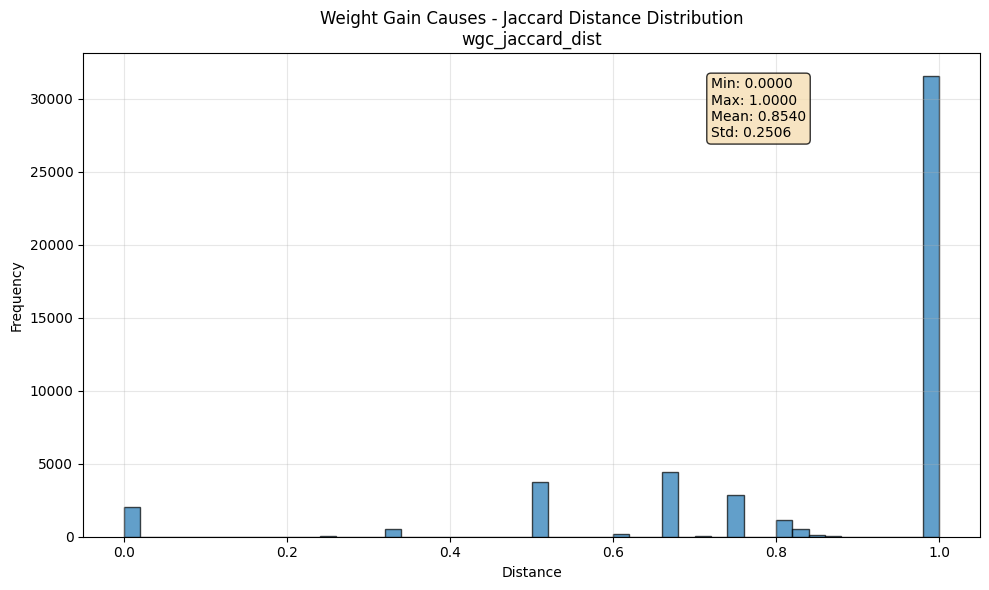

Step 2: Calculating Euclidean distance matrix for eating behaviors...
  Eating behavior matrix shape: (308, 6)
  Variables: ['hunger_yn', 'satiety_yn', 'emotional_eating_yn', 'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert']
  Normalization: divided by sqrt(6) = 2.449
  Normalized Euclidean distance matrix statistics:
    Min: 0.0000
    Max: 1.0000
    Mean: 0.4636
    Std: 0.2230


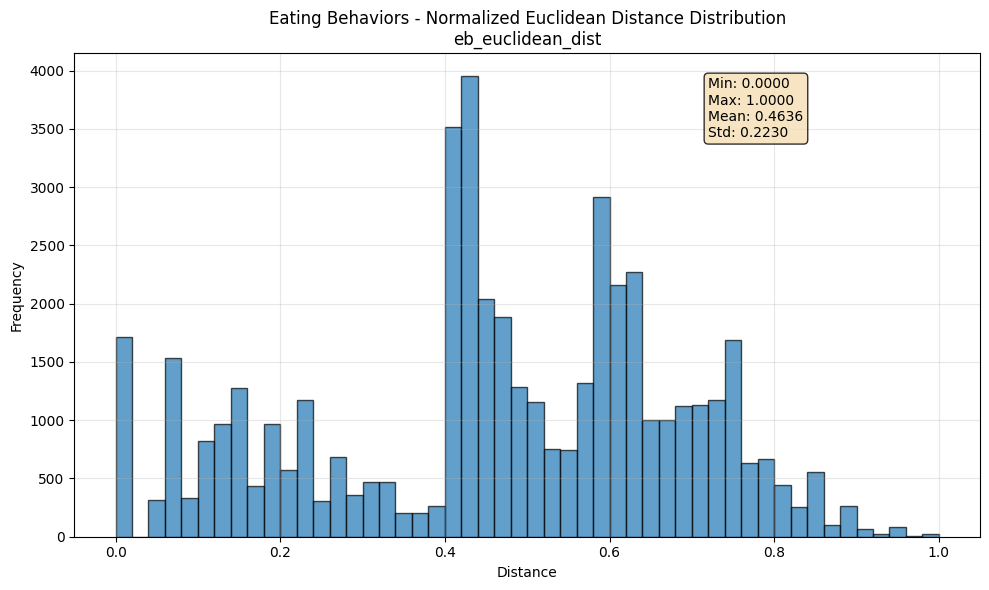

Step 3: Calculating hybrid distance matrix with equal weighting...
  Hybrid distance matrix statistics:
    Min: 0.0000
    Max: 1.0000
    Mean: 0.7252
    Std: 0.1838
  Weighting: 50% WGC Jaccard + 50% EB Euclidean


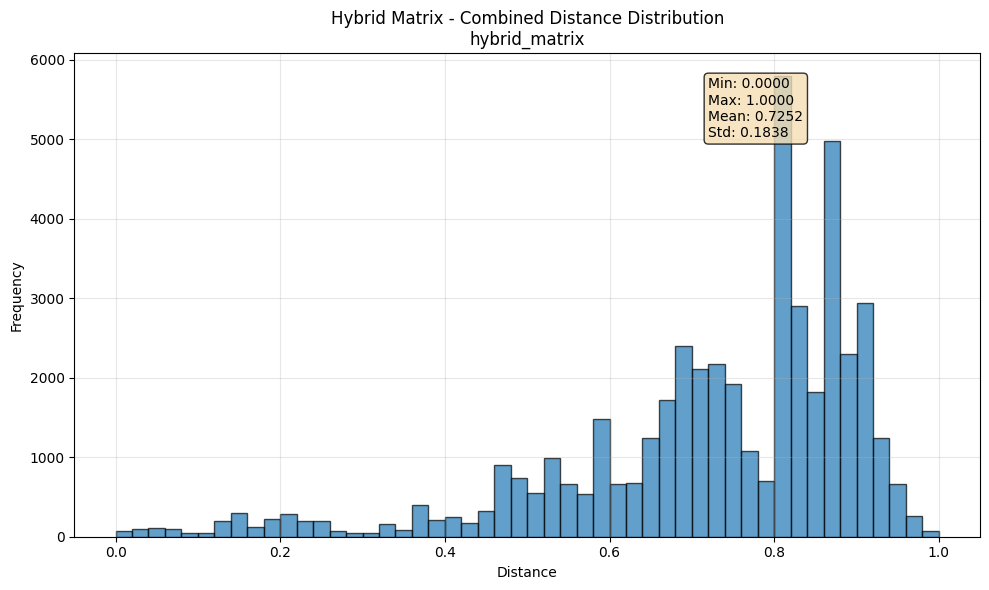


Saving hybrid matrix to database...
Saved hybrid matrix as 'hybrid_matrix' with outlier detection column
Average distance statistics:
  Mean: 0.7252
  Std:  0.0532
  Min:  0.6158
  Max:  0.8825

Creating metadata tables...
Created empty performance scores table 'clustering_performance_scores'
Created cluster labels table 'cluster_labels' with 308 medical records

=== HYBRID CLUSTERING MATRIX PREPARATION COMPLETE ===
✓ Weight gain causes: Jaccard distance (semantic similarity)
✓ Eating behaviors: Normalized Euclidean distance (absolute differences)
✓ Hybrid matrix: Equal weighting (50% WGC + 50% EB)
✓ Patients with only 'none_of_above' excluded
✓ Ready for clustering with balanced semantic + behavioral information

=== FINAL PIPELINE SUMMARY ===
Final dataset shape: (308, 20)
WGC Jaccard matrix shape: (308, 308)
EB Euclidean matrix shape: (308, 308)
Hybrid matrix shape: (308, 308)

=== VARIABLE SUMMARY ===
Weight gain causes (Jaccard): ['womens_health_and_pregnancy', 'mental_health', '

In [4]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURATION SECTION
# =============================================================================

# Define data paths
DATABASE_PATH = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
TABLE_NAME = "timetoevent_eb_wgc_compl"

# Define clustering variables
IDENTIFIER_VARS = ['patient_id', 'medical_record_id']
CONTINUOUS_VARS = ['emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert']
BINARY_VARS = [
    'hunger_yn', 'satiety_yn', 'emotional_eating_yn', 'womens_health_and_pregnancy',
    'mental_health', 'family_issues', 'medication_disease_injury', 'physical_inactivity',
    'eating_habits', 'schedule', 'smoking_cessation', 'treatment_discontinuation_or_relapse',
    'pandemic', 'lifestyle_circumstances', 'none_of_above'
]

# Weight gain cause variables for Jaccard distance
WEIGHT_GAIN_CAUSE_VARS = [
    'womens_health_and_pregnancy', 'mental_health', 'family_issues', 'medication_disease_injury', 
    'physical_inactivity', 'eating_habits', 'schedule', 'smoking_cessation', 
    'treatment_discontinuation_or_relapse', 'pandemic', 'lifestyle_circumstances'
]

# Eating behavior variables for Euclidean distance
EATING_BEHAVIOR_BINARY = ['hunger_yn', 'satiety_yn', 'emotional_eating_yn']
EATING_BEHAVIOR_CONTINUOUS = ['emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert']
ALL_EATING_BEHAVIORS = EATING_BEHAVIOR_BINARY + EATING_BEHAVIOR_CONTINUOUS

# Weighting factors for weight gain causes and eating behaviors when creating the hybrid distance matrix
WGC_WEIGHT = 0.67  # weight for weight gain causes
EB_WEIGHT = 1 - WGC_WEIGHT  # weight for eating behaviors

# Metadata table names
PERFORMANCE_TABLE = "clustering_performance_scores"
LABELS_TABLE = "cluster_labels"

# =============================================================================
# DATA LOADING AND PREPROCESSING FUNCTIONS
# =============================================================================

def load_clustering_data(db_path, table_name, identifier_vars, continuous_vars, binary_vars):
    """Load clustering data using medical record IDs as the primary identifier."""
    all_vars = identifier_vars + continuous_vars + binary_vars
    var_list = ', '.join(all_vars)
    
    query = f"SELECT {var_list} FROM {table_name} ORDER BY {identifier_vars[1]}"
    
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(query, conn)
    
    print(f"Loaded {len(df)} rows and {len(df.columns)} columns from {table_name}")
    return df

# def filter_patients_none_only(df, weight_gain_cause_vars):
#     """
#     Filter out patients who only have 'none_of_above' = 1 and no other weight gain causes.
    
#     Parameters:
#     -----------
#     df : pd.DataFrame
#         Input DataFrame
#     weight_gain_cause_vars : list
#         List of weight gain cause variables (excluding none_of_above)
    
#     Returns:
#     --------
#     pd.DataFrame
#         Filtered DataFrame excluding patients with only 'none_of_above'
#     """
#     print("Filtering patients who only have 'none_of_above' weight gain cause...")
    
#     # Calculate total causes (excluding none_of_above)
#     total_real_causes = df[weight_gain_cause_vars].sum(axis=1)
#     has_none_only = (df['none_of_above'] == 1) & (total_real_causes == 0)
    
#     # Filter out patients with only none_of_above
#     df_filtered = df[~has_none_only].copy()
    
#     excluded_count = has_none_only.sum()
#     print(f"  Excluded {excluded_count} patients with only 'none_of_above' cause")
#     print(f"  Retained {len(df_filtered)} patients for hybrid clustering analysis")
    
#     # Report remaining cause distribution
#     remaining_real_causes = df_filtered[weight_gain_cause_vars].sum(axis=1)
#     patients_with_real_causes = (remaining_real_causes > 0).sum()
#     patients_with_none_and_others = ((df_filtered['none_of_above'] == 1) & (remaining_real_causes > 0)).sum()
    
#     print(f"  Among retained patients:")
#     print(f"    With real weight gain causes: {patients_with_real_causes} ({patients_with_real_causes/len(df_filtered)*100:.1f}%)")
#     print(f"    With both 'none' and real causes: {patients_with_none_and_others} ({patients_with_none_and_others/len(df_filtered)*100:.1f}%)")
    
#     return df_filtered

def scale_eating_behaviors(df, eating_behavior_binary, eating_behavior_continuous):
    """
    Scale eating behavior variables: binary stay 0/1, continuous rescaled 0-1.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame
    eating_behavior_binary : list
        Binary eating behavior variables (keep as 0/1)
    eating_behavior_continuous : list
        Continuous eating behavior variables (scale 1-10 -> 0-1)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with scaled eating behaviors
    """
    print("Scaling eating behavior variables...")
    
    df_scaled = df.copy()
    scaler = MinMaxScaler()
    
    print(f"  Binary eating behaviors (kept as 0/1): {eating_behavior_binary}")
    for var in eating_behavior_binary:
        unique_vals = sorted(df_scaled[var].unique())
        print(f"    {var}: values {unique_vals}")
    
    print(f"  Continuous eating behaviors (rescaled 1-10 -> 0-1): {eating_behavior_continuous}")
    for var in eating_behavior_continuous:
        if var in df_scaled.columns:
            original_values = df_scaled[[var]]
            scaled_values = scaler.fit_transform(original_values)
            df_scaled[var] = scaled_values.flatten()
            
            orig_min, orig_max = original_values[var].min(), original_values[var].max()
            scaled_min, scaled_max = df_scaled[var].min(), df_scaled[var].max()
            
            print(f"    {var}: [{orig_min:.1f}, {orig_max:.1f}] → [{scaled_min:.3f}, {scaled_max:.3f}]")
    
    return df_scaled

def plot_distance_histogram(distances, title, matrix_name):
    """Plot histogram of distance distributions for diagnostics."""
    plt.figure(figsize=(10, 6))
    plt.hist(distances, bins=50, alpha=0.7, edgecolor='black')
    plt.title(f'{title}\n{matrix_name}')
    plt.xlabel('Distance')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Min: {np.min(distances):.4f}\nMax: {np.max(distances):.4f}\nMean: {np.mean(distances):.4f}\nStd: {np.std(distances):.4f}'
    plt.text(0.7, 0.95, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def calculate_wgc_jaccard_distance(df, weight_gain_cause_vars, medical_record_ids):
    """
    Calculate Jaccard distance matrix for weight gain causes.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with weight gain cause variables
    weight_gain_cause_vars : list
        List of weight gain cause variables
    medical_record_ids : list
        List of medical record IDs for indexing
    
    Returns:
    --------
    pd.DataFrame
        Jaccard distance matrix
    """
    print("Step 1: Calculating Jaccard distance matrix for weight gain causes...")
    
    # Extract cause matrix
    cause_matrix = df[weight_gain_cause_vars].copy()
    
    print(f"  Weight gain cause matrix shape: {cause_matrix.shape}")
    print(f"  Variables: {weight_gain_cause_vars}")
    
    # Calculate Jaccard distances
    jaccard_distances = pdist(cause_matrix.values, metric='jaccard')
    jaccard_matrix = squareform(jaccard_distances)
    
    # Handle NaN values
    nan_count = np.isnan(jaccard_matrix).sum()
    if nan_count > 0:
        print(f"  WARNING: {nan_count} NaN values found, replacing with 0")
        jaccard_matrix = np.nan_to_num(jaccard_matrix, nan=0.0)
    
    # Convert to DataFrame
    jaccard_df = pd.DataFrame(
        jaccard_matrix,
        index=medical_record_ids,
        columns=medical_record_ids
    )
    
    # Diagnostics
    print(f"  Jaccard distance matrix statistics:")
    print(f"    Min: {np.min(jaccard_distances):.4f}")
    print(f"    Max: {np.max(jaccard_distances):.4f}")
    print(f"    Mean: {np.mean(jaccard_distances):.4f}")
    print(f"    Std: {np.std(jaccard_distances):.4f}")
    
    # Plot histogram
    plot_distance_histogram(jaccard_distances, 
                          'Weight Gain Causes - Jaccard Distance Distribution', 
                          'wgc_jaccard_dist')
    
    return jaccard_df

def calculate_eb_euclidean_distance(df, eating_behavior_vars, medical_record_ids):
    """
    Calculate Euclidean distance matrix for eating behaviors, normalized by sqrt(d).
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with scaled eating behavior variables
    eating_behavior_vars : list
        List of eating behavior variables (6 total)
    medical_record_ids : list
        List of medical record IDs for indexing
    
    Returns:
    --------
    pd.DataFrame
        Normalized Euclidean distance matrix
    """
    print("Step 2: Calculating Euclidean distance matrix for eating behaviors...")
    
    # Extract eating behavior matrix
    eb_matrix = df[eating_behavior_vars].copy()
    
    print(f"  Eating behavior matrix shape: {eb_matrix.shape}")
    print(f"  Variables: {eating_behavior_vars}")
    
    # Calculate Euclidean distances
    euclidean_distances = pdist(eb_matrix.values, metric='euclidean')
    euclidean_matrix = squareform(euclidean_distances)
    
    # Normalize by sqrt(d) where d is number of variables
    d = len(eating_behavior_vars)  # Should be 6
    normalized_matrix = euclidean_matrix / np.sqrt(d)
    normalized_distances = normalized_matrix[np.triu_indices_from(normalized_matrix, k=1)]
    
    print(f"  Normalization: divided by sqrt({d}) = {np.sqrt(d):.3f}")
    
    # Convert to DataFrame
    eb_euclidean_df = pd.DataFrame(
        normalized_matrix,
        index=medical_record_ids,
        columns=medical_record_ids
    )
    
    # Diagnostics
    print(f"  Normalized Euclidean distance matrix statistics:")
    print(f"    Min: {np.min(normalized_distances):.4f}")
    print(f"    Max: {np.max(normalized_distances):.4f}")
    print(f"    Mean: {np.mean(normalized_distances):.4f}")
    print(f"    Std: {np.std(normalized_distances):.4f}")
    
    # Plot histogram
    plot_distance_histogram(normalized_distances, 
                          'Eating Behaviors - Normalized Euclidean Distance Distribution', 
                          'eb_euclidean_dist')
    
    return eb_euclidean_df

def calculate_hybrid_matrix(wgc_jaccard_df, eb_euclidean_df, medical_record_ids):
    """
    Calculate hybrid distance matrix with equal weighting (0.5 each).
    
    Parameters:
    -----------
    wgc_jaccard_df : pd.DataFrame
        Weight gain causes Jaccard distance matrix
    eb_euclidean_df : pd.DataFrame
        Eating behaviors Euclidean distance matrix
    medical_record_ids : list
        List of medical record IDs for indexing
    
    Returns:
    --------
    tuple
        (hybrid_df, avg_distances)
    """
    print("Step 3: Calculating hybrid distance matrix with equal weighting...")
    
    # Combine matrices with equal weighting
    hybrid_matrix = WGC_WEIGHT * wgc_jaccard_df.values + EB_WEIGHT * eb_euclidean_df.values
    
    # Convert to DataFrame
    hybrid_df = pd.DataFrame(
        hybrid_matrix,
        index=medical_record_ids,
        columns=medical_record_ids
    )
    
    # Calculate average distances for outlier detection
    avg_distances = []
    n_patients = len(medical_record_ids)
    
    for i in range(n_patients):
        # Get distances to all other patients (excluding self)
        patient_distances = np.concatenate([
            hybrid_matrix[i, :i],
            hybrid_matrix[i, i+1:]
        ])
        avg_distance = np.mean(patient_distances)
        avg_distances.append(avg_distance)
    
    # Extract upper triangle for histogram
    hybrid_distances = hybrid_matrix[np.triu_indices_from(hybrid_matrix, k=1)]
    
    # Diagnostics
    print(f"  Hybrid distance matrix statistics:")
    print(f"    Min: {np.min(hybrid_distances):.4f}")
    print(f"    Max: {np.max(hybrid_distances):.4f}")
    print(f"    Mean: {np.mean(hybrid_distances):.4f}")
    print(f"    Std: {np.std(hybrid_distances):.4f}")
    print(f"  Weighting: 50% WGC Jaccard + 50% EB Euclidean")
    
    # Plot histogram
    plot_distance_histogram(hybrid_distances, 
                          'Hybrid Matrix - Combined Distance Distribution', 
                          'hybrid_matrix')
    
    return hybrid_df, avg_distances

def save_hybrid_matrix_with_outlier_detection(hybrid_df, avg_distances, db_path, matrix_name="hybrid_matrix"):
    """Save hybrid matrix with outlier detection column to SQLite database."""
    hybrid_to_save = hybrid_df.reset_index()
    hybrid_to_save.rename(columns={'index': 'medical_record_id'}, inplace=True)
    hybrid_to_save.insert(1, 'avg_dist_to_all', avg_distances)
    
    with sqlite3.connect(db_path) as conn:
        hybrid_to_save.to_sql(matrix_name, conn, if_exists='replace', index=False)
    
    print(f"Saved hybrid matrix as '{matrix_name}' with outlier detection column")
    print(f"Average distance statistics:")
    print(f"  Mean: {np.mean(avg_distances):.4f}")
    print(f"  Std:  {np.std(avg_distances):.4f}")
    print(f"  Min:  {np.min(avg_distances):.4f}")
    print(f"  Max:  {np.max(avg_distances):.4f}")

# =============================================================================
# UTILITY FUNCTIONS FOR CLUSTERING PIPELINE
# =============================================================================

def create_performance_scores_table(db_path, table_name):
    """Create empty performance scores table."""
    performance_df = pd.DataFrame(columns=[
        'algorithm', 'k', 'hclust_linkage', 'silhouette', 'davies_bouldin', 'calinski_harabasz'
    ])
    
    with sqlite3.connect(db_path) as conn:
        performance_df.to_sql(table_name, conn, if_exists='replace', index=False)
    
    print(f"Created empty performance scores table '{table_name}'")

def create_cluster_labels_table_with_medical_record_ids(df, db_path, table_name, identifier_vars):
    """Create cluster labels table with patient identifiers."""
    labels_df = df[identifier_vars].copy()
    
    with sqlite3.connect(db_path) as conn:
        labels_df.to_sql(table_name, conn, if_exists='replace', index=False)
    
    print(f"Created cluster labels table '{table_name}' with {len(labels_df)} medical records")

def load_hybrid_matrix_with_medical_record_ids(db_path, table_name):
    """Load hybrid matrix with medical record ID indexing from SQLite database."""
    with sqlite3.connect(db_path) as conn:
        hybrid_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    
    medical_record_ids = hybrid_df['medical_record_id'].tolist()
    hybrid_df = hybrid_df.drop(['medical_record_id', 'avg_dist_to_all'], axis=1)
    hybrid_df.index = medical_record_ids
    
    hybrid_matrix = hybrid_df.values
    
    print(f"Loaded hybrid matrix of shape {hybrid_matrix.shape} with medical record ID indexing")
    return hybrid_matrix, medical_record_ids

def add_cluster_labels_by_medical_record_id(db_path, table_name, column_name, medical_record_ids, labels):
    """Add cluster labels using medical record ID matching."""
    label_mapping = dict(zip(medical_record_ids, labels))
    
    with sqlite3.connect(db_path) as conn:
        existing_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        existing_df[column_name] = existing_df['medical_record_id'].map(label_mapping)
        
        unmapped = existing_df[column_name].isna().sum()
        if unmapped > 0:
            print(f"WARNING: {unmapped} medical records could not be matched!")
            return False
        
        existing_df.to_sql(table_name, conn, if_exists='replace', index=False)
    
    print(f"Successfully added column '{column_name}' using medical record ID matching")
    return True

def add_performance_scores(db_path, table_name, algorithm, k, hclust_linkage, 
                          silhouette, davies_bouldin, calinski_harabasz):
    """Add performance scores to the database."""
    new_row = pd.DataFrame({
        'algorithm': [algorithm],
        'k': [k],
        'hclust_linkage': [hclust_linkage if hclust_linkage else None],
        'silhouette': [silhouette],
        'davies_bouldin': [davies_bouldin],
        'calinski_harabasz': [calinski_harabasz]
    })
    
    with sqlite3.connect(db_path) as conn:
        try:
            existing_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            updated_df = pd.concat([existing_df, new_row], ignore_index=True)
        except:
            updated_df = new_row
        
        updated_df.to_sql(table_name, conn, if_exists='replace', index=False)

# =============================================================================
# MAIN PIPELINE FUNCTION
# =============================================================================

def prepare_hybrid_clustering_data():
    """
    Main function to prepare hybrid distance matrix combining Jaccard (WGC) + Euclidean (EB).
    """
    print("=== HYBRID CLUSTERING DATA PREPARATION ===")
    print("Combining Jaccard distance (weight gain causes) + Euclidean distance (eating behaviors)")
    
    # Load initial data
    print("\nLoading clustering data...")
    df = load_clustering_data(DATABASE_PATH, TABLE_NAME, IDENTIFIER_VARS, CONTINUOUS_VARS, BINARY_VARS)
    
    # Filter patients with only 'none_of_above'  
    # df = filter_patients_none_only(df, WEIGHT_GAIN_CAUSE_VARS)
    
    # Scale eating behaviors
    df_scaled = scale_eating_behaviors(df, EATING_BEHAVIOR_BINARY, EATING_BEHAVIOR_CONTINUOUS)
    
    # Get medical record IDs
    medical_record_ids = df_scaled['medical_record_id'].tolist()
    
    # Calculate weight gain causes Jaccard distance matrix
    wgc_jaccard_dist = calculate_wgc_jaccard_distance(df_scaled, WEIGHT_GAIN_CAUSE_VARS, medical_record_ids)
    
    # Calculate eating behaviors Euclidean distance matrix  
    eb_euclidean_dist = calculate_eb_euclidean_distance(df_scaled, ALL_EATING_BEHAVIORS, medical_record_ids)
    
    # Calculate hybrid matrix
    hybrid_matrix, avg_distances = calculate_hybrid_matrix(wgc_jaccard_dist, eb_euclidean_dist, medical_record_ids)
    
    # Save hybrid matrix
    print("\nSaving hybrid matrix to database...")
    save_hybrid_matrix_with_outlier_detection(hybrid_matrix, avg_distances, DATABASE_PATH)
    
    # Create metadata tables
    print("\nCreating metadata tables...")
    create_performance_scores_table(DATABASE_PATH, PERFORMANCE_TABLE)
    create_cluster_labels_table_with_medical_record_ids(df_scaled, DATABASE_PATH, LABELS_TABLE, IDENTIFIER_VARS)
    
    print("\n=== HYBRID CLUSTERING MATRIX PREPARATION COMPLETE ===")
    print("✓ Weight gain causes: Jaccard distance (semantic similarity)")
    print("✓ Eating behaviors: Normalized Euclidean distance (absolute differences)")
    print("✓ Hybrid matrix: Equal weighting (50% WGC + 50% EB)")
    print("✓ Patients with only 'none_of_above' excluded")
    print("✓ Ready for clustering with balanced semantic + behavioral information")
    
    return df_scaled, wgc_jaccard_dist, eb_euclidean_dist, hybrid_matrix, avg_distances

# =============================================================================
# MAIN EXECUTION
# =============================================================================

# Execute hybrid data preparation
df_clustering, wgc_jaccard_matrix, eb_euclidean_matrix, hybrid_matrix, avg_distances = prepare_hybrid_clustering_data()

# Display comprehensive summary
print(f"\n=== FINAL PIPELINE SUMMARY ===")
print(f"Final dataset shape: {df_clustering.shape}")
print(f"WGC Jaccard matrix shape: {wgc_jaccard_matrix.shape}")
print(f"EB Euclidean matrix shape: {eb_euclidean_matrix.shape}")
print(f"Hybrid matrix shape: {hybrid_matrix.shape}")

print(f"\n=== VARIABLE SUMMARY ===")
print(f"Weight gain causes (Jaccard): {WEIGHT_GAIN_CAUSE_VARS}")
print(f"Eating behaviors (Euclidean): {ALL_EATING_BEHAVIORS}")
print(f"  - Binary (0/1): {EATING_BEHAVIOR_BINARY}")
print(f"  - Continuous (0-1): {EATING_BEHAVIOR_CONTINUOUS}")

print(f"\n=== DATABASE VERIFICATION ===")
with sqlite3.connect(DATABASE_PATH) as conn:
    labels_sample = pd.read_sql_query(f"SELECT * FROM {LABELS_TABLE} LIMIT 3", conn)
    hybrid_sample = pd.read_sql_query("SELECT medical_record_id, avg_dist_to_all FROM hybrid_matrix LIMIT 3", conn)

print("Sample labels table:")
print(labels_sample.to_string())
print("\nSample hybrid matrix with outlier detection:")
print(hybrid_sample.to_string())

print(f"\n🎯 READY FOR CLUSTERING: Hybrid matrix combining semantic causes + behavioral differences!")

### Hierarchical clustering pipeline

#### bootstrap + eval plots refact

=== HIERARCHICAL CLUSTERING PIPELINE ===

1. Setting up directories and loading data...
Dendrograms directory already exists: .\hclust_dendrograms
Loaded Gower data with shape (308, 310)
Extracted 308 record IDs
Record ID range: 12B16D42A682D to 1403C142A682D

2. Applying outlier filtering...
Final clustering matrix shape: (308, 308)
Loaded existing labels table with 308 records

3. Running hierarchical clustering...
   Linkage methods: ['ward']
   K values: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
   Number of patients after filtering: 308

--- Processing ward linkage ---
Run 1/14: ward linkage, k=2


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

Saved dendrogram: hclust_ward_k2.png
   Silhouette: 0.1709, Davies-Bouldin: 1.4239, Calinski-Harabasz: 51.7295
Run 2/14: ward linkage, k=3


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

Saved dendrogram: hclust_ward_k3.png
   Silhouette: 0.2303, Davies-Bouldin: 1.2695, Calinski-Harabasz: 49.3379
Run 3/14: ward linkage, k=4


...

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

Saved dendrogram: hclust_ward_k15.png
   Silhouette: 0.3698, Davies-Bouldin: 1.4761, Calinski-Harabasz: 45.4870

--- Running Bootstrap Stability Evaluation for ward linkage (100 iterations) ---
   k=2: Mean Adjusted Rand Index = 0.5243
   k=3: Mean Adjusted Rand Index = 0.4700
   k=4: Mean Adjusted Rand Index = 0.6571
   k=5: Mean Adjusted Rand Index = 0.5141
   k=6: Mean Adjusted Rand Index = 0.4569
   k=7: Mean Adjusted Rand Index = 0.5124
   k=8: Mean Adjusted Rand Index = 0.5259
   k=9: Mean Adjusted Rand Index = 0.5403
   k=10: Mean Adjusted Rand Index = 0.5849
   k=11: Mean Adjusted Rand Index = 0.6027
   k=12: Mean Adjusted Rand Index = 0.6175
   k=13: Mean Adjusted Rand Index = 0.6373
   k=14: Mean Adjusted Rand Index = 0.6982


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

   k=15: Mean Adjusted Rand Index = 0.7098
Bootstrap ARI scores saved to the performance table.


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

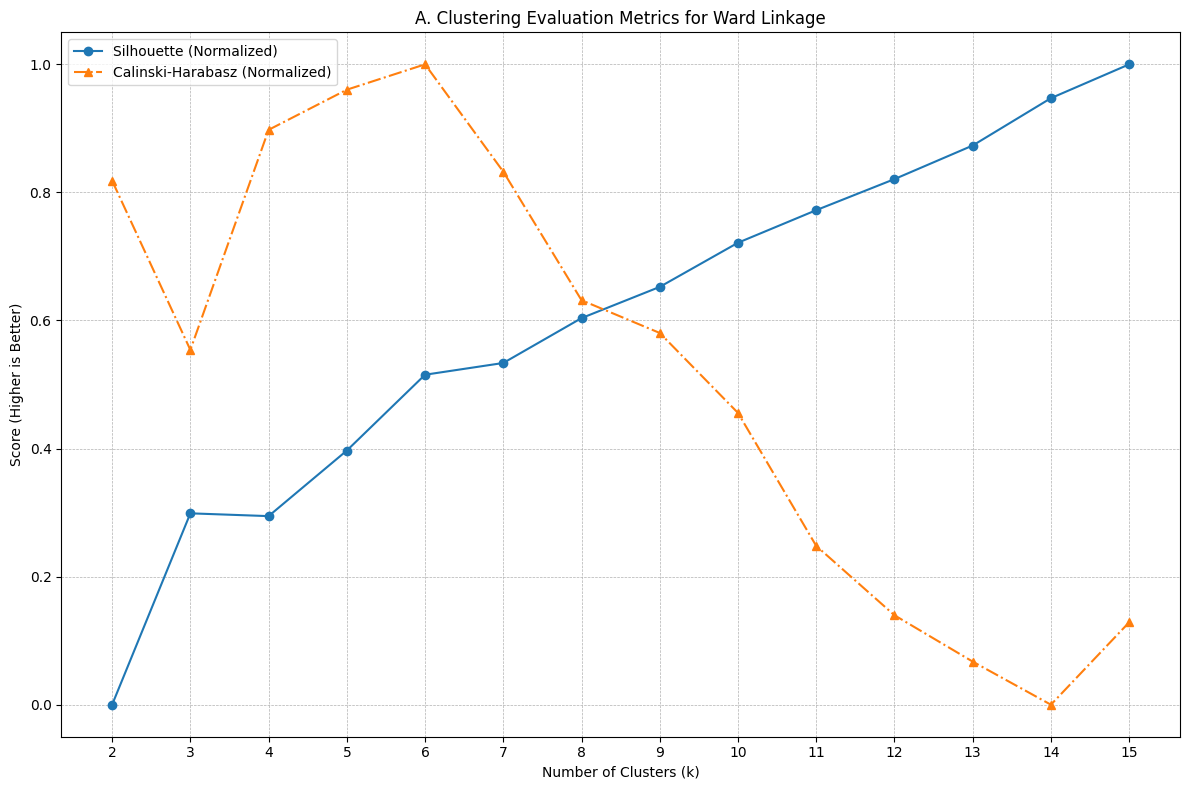


=== HIERARCHICAL CLUSTERING COMPLETE ===
Total runs completed: 14
Results saved to:
  - Performance scores: clustering_performance_scores
  - Cluster labels: cluster_labels
  - Dendrograms: .\hclust_dendrograms

=== SUMMARY ===
Generated 14 hierarchical clustering results

Best results by metric:
  Best Silhouette: ward k=15 (score: 0.3698)
  Best Davies-Bouldin: ward k=3 (score: 1.2695)
  Best Calinski-Harabasz: ward k=6 (score: 53.3747)
  Best Bootstrap Stability (ARI): ward k=15 (score: 0.7098)

Cluster labels table contains 308 records
Medical Record ID range: 12B16D42A682D to 1403C142A682D


In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.preprocessing import MinMaxScaler # Added for normalization
from sklearn.utils import resample # Added for bootstrapping

# =============================================================================
# CONFIGURATION SECTION
# =============================================================================

# Define data paths
# Assuming paper1_directory is defined in the execution environment
# For standalone execution, you might need to define it, e.g., paper1_directory = '.'
try:
    paper1_directory
except NameError:
    print("Warning: 'paper1_directory' not defined. Using current directory.")
    paper1_directory = '.'

DATABASE_PATH = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
DISTANCE_MATRIX_TABLE = "hybrid_matrix"
PERFORMANCE_TABLE = "clustering_performance_scores"
LABELS_TABLE = "cluster_labels"

# Output directory for dendrograms
DENDROGRAMS_DIR = os.path.join(paper1_directory, "hclust_dendrograms")

# Clustering parameters
LINKAGE_METHODS = [
    'ward', 
    # 'complete', 
    # 'average', 
    # 'single'
]
K_RANGE = range(2, 16)  # k values from 2 to 15

# Bootstrap evaluation parameters
N_BOOTSTRAP = 100 # Number of bootstrap resamples

# Outlier filtering parameters
N_OUTLIERS = 0  # Set to 0 to disable outlier removal

# Plot parameters
FIGURE_SIZE = (12, 8)
DPI = 300

# =============================================================================
# FUNCTIONS
# =============================================================================


def load_distance_matrix_with_ids(db_path, table_name):
    """
    Load dissimilarity matrix from SQLite database and extract record IDs.
    
    Parameters:
    -----------
    db_path : str
        Path to SQLite database
    table_name : str
        Name of the distance matrix table
    
    Returns:
    --------
    tuple
        (distance_df, record_ids) where:
        - distance_df is the complete DataFrame with all columns
        - record_ids is list of medical record IDs
    """
    with sqlite3.connect(db_path) as conn:
        distance_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    
    # Extract record IDs from the first column
    record_ids = distance_df.iloc[:, 0].tolist()
    
    print(f"Loaded distance data with shape {distance_df.shape}")
    print(f"Extracted {len(record_ids)} record IDs")
    print(f"Record ID range: {min(record_ids)} to {max(record_ids)}")
    
    return distance_df, record_ids

def detect_and_flag_outliers(distance_df, record_ids, n_outliers):
    """
    Detects outliers and prepares a correct, symmetric distance matrix for clustering.
    """
    if n_outliers > 0:
        print(f"\n--- OUTLIER DETECTION ---")
        print(f"Detecting top {n_outliers} outliers...")

        # 1. Identify outlier indices and record IDs (your code for this is perfect)
        outlier_indices = distance_df['avg_dist_to_all'].nlargest(n_outliers).index.tolist()
        outlier_record_ids = distance_df.loc[outlier_indices, 'medical_record_id'].tolist()

        # 2. Identify the indices of the patients TO KEEP
        all_indices = distance_df.index.tolist()
        keep_indices = [idx for idx in all_indices if idx not in outlier_indices]
        filtered_record_ids = distance_df.loc[keep_indices, 'medical_record_id'].tolist()
        
        print(f"Identified {len(outlier_record_ids)} outliers. Retaining {len(filtered_record_ids)} patients for clustering.")

        # 3. Extract the full distance matrix as a numpy array
        # Assuming first two columns are 'medical_record_id' and 'avg_dist_to_all'
        full_distance_matrix = distance_df.iloc[:, 2:].values

        # 4. Use numpy indexing to create the correct, square sub-matrix
        # This single line replaces all the complex pandas drop logic.
        distance_matrix = full_distance_matrix[np.ix_(keep_indices, keep_indices)]
        
        # NOTE: np.ix_ is the most robust way to do this for 2D slicing.
        # Your original fix full_distance_matrix[keep_indices, :][:, keep_indices] also works well.
        
    else: # If no outliers are being removed
        filtered_record_ids = record_ids.copy()
        outlier_record_ids = []
        outlier_indices = []
        distance_matrix = distance_df.iloc[:, 2:].values
    
    # 5. Verify and return
    if distance_matrix.shape[0] != distance_matrix.shape[1]:
        raise ValueError(f"CRITICAL ERROR: Distance matrix is not square: {distance_matrix.shape}")
    
    print(f"Final clustering matrix shape: {distance_matrix.shape}")
    return distance_matrix, filtered_record_ids, outlier_record_ids, outlier_indices

def ensure_labels_table_exists(db_path, labels_table, all_record_ids):
    """
    Ensure the cluster labels table exists with ALL record IDs (including outliers).
    
    Parameters:
    -----------
    db_path : str
        Path to SQLite database
    labels_table : str
        Name of the cluster labels table
    all_record_ids : list
        List of ALL medical record IDs (including outliers)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with patient identifiers
    """
    with sqlite3.connect(db_path) as conn:
        try:
            # Try to load existing table
            labels_df = pd.read_sql_query(f"SELECT * FROM {labels_table}", conn)
            print(f"Loaded existing labels table with {len(labels_df)} records")
            
            # Verify that record IDs match
            existing_ids = labels_df['medical_record_id'].tolist()
            if set(existing_ids) != set(all_record_ids):
                print("Warning: Record IDs in labels table don't match full dataset")
                print("Updating labels table with ALL record IDs (including outliers)...")
                # Update with ALL IDs
                labels_df = pd.DataFrame({'medical_record_id': all_record_ids})
                labels_df['patient_id'] = range(len(all_record_ids))  # Sequential patient IDs
                labels_df.to_sql(labels_table, conn, if_exists='replace', index=False)
        
        except:
            # Create new table if it doesn't exist
            print(f"Creating new labels table with {len(all_record_ids)} records (including outliers)")
            labels_df = pd.DataFrame({'medical_record_id': all_record_ids})
            labels_df['patient_id'] = range(len(all_record_ids))  # Sequential patient IDs
            labels_df.to_sql(labels_table, conn, if_exists='replace', index=False)
    
    return labels_df
def create_dendrograms_directory(output_dir):
    """
    Create directory for saving dendrograms.
    
    Parameters:
    -----------
    output_dir : str
        Path to the output directory
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created dendrograms directory: {output_dir}")
    else:
        print(f"Dendrograms directory already exists: {output_dir}")

def perform_hierarchical_clustering(distance_matrix, linkage_method):
    """
    Perform hierarchical clustering using specified linkage method.
    
    Parameters:
    -----------
    distance_matrix : np.ndarray
        Distance matrix (dissimilarity matrix)
    linkage_method : str
        Linkage method ('ward', 'complete', 'average', 'single')
    
    Returns:
    --------
    np.ndarray
        Linkage matrix from hierarchical clustering
    """
    # Convert distance matrix to condensed form for scipy
    condensed_distances = squareform(distance_matrix, checks=False)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_distances, method=linkage_method)
    
    return linkage_matrix

def extract_clusters(linkage_matrix, k):
    """
    Extract cluster labels for specified number of clusters.
    
    Parameters:
    -----------
    linkage_matrix : np.ndarray
        Linkage matrix from hierarchical clustering
    k : int
        Number of clusters
    
    Returns:
    --------
    np.ndarray
        Cluster labels (0-indexed)
    """
    # Extract clusters (fcluster returns 1-indexed labels, convert to 0-indexed)
    cluster_labels = fcluster(linkage_matrix, k, criterion='maxclust') - 1
    return cluster_labels

def calculate_clustering_metrics(distance_matrix, cluster_labels):
    """
    Calculate clustering evaluation metrics.
    
    Parameters:
    -----------
    distance_matrix : np.ndarray
        Distance matrix
    cluster_labels : np.ndarray
        Cluster labels
    
    Returns:
    --------
    tuple
        (silhouette_score, davies_bouldin_score, calinski_harabasz_score)
    """
    # For silhouette score, we need the distance matrix in the right format
    n_clusters = len(np.unique(cluster_labels))
    
    if n_clusters <= 1 or n_clusters >= len(cluster_labels):
        # Can't calculate metrics with only one cluster or n_samples clusters
        return np.nan, np.nan, np.nan
    
    try:
        # Silhouette score using precomputed distance matrix
        sil_score = silhouette_score(distance_matrix, cluster_labels, metric='precomputed')
        
        # For Davies-Bouldin and Calinski-Harabasz, we need the original data
        # Since we only have distances, we'll use MDS to reconstruct approximate coordinates
        from sklearn.manifold import MDS
        # Ensure n_components is less than n_samples
        n_components = min(10, len(distance_matrix) - 1)
        mds = MDS(n_components=n_components, dissimilarity='precomputed', random_state=42, n_init=4)
        coords = mds.fit_transform(distance_matrix)
        
        db_score = davies_bouldin_score(coords, cluster_labels)
        ch_score = calinski_harabasz_score(coords, cluster_labels)
        
        return sil_score, db_score, ch_score
    
    except Exception as e:
        print(f"Warning: Could not calculate all metrics - {e}")
        return np.nan, np.nan, np.nan

def plot_dendrogram(linkage_matrix, linkage_method, k, output_dir, record_ids, figure_size=(12, 8), outlier_info=None):
    """
    Plot and save dendrogram with record ID information.
    
    Parameters:
    -----------
    linkage_matrix : np.ndarray
        Linkage matrix from hierarchical clustering
    linkage_method : str
        Linkage method used
    k : int
        Number of clusters (for color coding)
    output_dir : str
        Directory to save the plot
    record_ids : list
        List of medical record IDs
    figure_size : tuple
        Figure size (width, height)
    outlier_info : dict
        Information about outliers (optional)
    """
    plt.figure(figsize=FIGURE_SIZE)
    
    # Create dendrogram with color threshold for k clusters
    dendrogram(linkage_matrix, 
                color_threshold=linkage_matrix[-k+1, 2],
                above_threshold_color='gray')
    
    # Create title with outlier information
    title = f'B. Hierarchical Clustering Dendrogram\n{linkage_method.capitalize()} Linkage, k={k}\n({len(record_ids)} patients'
    if outlier_info and outlier_info['n_outliers'] > 0:
        title += f', {outlier_info["n_outliers"]} outliers removed)'
    else:
        title += ')'
    
    plt.title(title)
    plt.xlabel('Patient Index (Medical Record IDs)')
    plt.ylabel('Distance')
    plt.grid(True, alpha=0.3)
    
    # Save plot
    filename = f"hclust_{linkage_method}_k{k}.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=DPI, bbox_inches='tight')
    plt.close()
    
    print(f"Saved dendrogram: {filename}")

def add_performance_scores(db_path, table_name, algorithm, k, hclust_linkage, 
                            silhouette, davies_bouldin, calinski_harabasz):
    """
    Add performance scores to the database.
    
    Parameters:
    -----------
    db_path : str
        Path to SQLite database
    table_name : str
        Name of the performance scores table
    algorithm : str
        Algorithm name
    k : int
        Number of clusters
    hclust_linkage : str
        Linkage method
    silhouette : float
        Silhouette score
    davies_bouldin : float
        Davies-Bouldin index
    calinski_harabasz : float
        Calinski-Harabasz index
    """
    new_row = pd.DataFrame({
        'algorithm': [algorithm],
        'k': [k],
        'hclust_linkage': [hclust_linkage],
        'silhouette': [silhouette],
        'davies_bouldin': [davies_bouldin],
        'calinski_harabasz': [calinski_harabasz]
    })
    
    with sqlite3.connect(db_path) as conn:
        try:
            existing_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            # Find the specific row to update or append
            mask = (existing_df['algorithm'] == algorithm) & \
                    (existing_df['k'] == k) & \
                    (existing_df['hclust_linkage'] == hclust_linkage)
            
            if mask.any():
                # If row exists, update it
                for col in new_row.columns:
                    existing_df.loc[mask, col] = new_row[col].iloc[0]
                updated_df = existing_df
            else:
                # If row does not exist, append it
                updated_df = pd.concat([existing_df, new_row], ignore_index=True)
        except:
            updated_df = new_row
        
        updated_df.to_sql(table_name, conn, if_exists='replace', index=False)

def add_cluster_labels_column(db_path, table_name, column_name, labels, clustering_record_ids, all_record_ids, outlier_record_ids):
    """
    Add cluster labels column to the database, ensuring proper record ID alignment.
    
    Parameters:
    -----------
    db_path : str
        Path to SQLite database
    table_name : str
        Name of the cluster labels table
    column_name : str
        Name of the new column
    labels : array-like
        Cluster labels
    clustering_record_ids : list
        List of medical record IDs used in clustering
    all_record_ids : list
        List of all medical record IDs for verification
    outlier_record_ids : list
        List of medical record IDs identified as outliers
    """
    with sqlite3.connect(db_path) as conn:
        existing_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        
        # Convert column to object type to handle mixed types
        existing_df[column_name] = pd.Series(dtype='object')
        
        # Create a mapping from clustering record_id to label
        label_mapping = dict(zip(clustering_record_ids, labels))
        
        # Apply labels to non-outliers, mark outliers with -1
        for idx, rid in enumerate(existing_df['medical_record_id']):
            if rid in label_mapping:
                existing_df.loc[idx, column_name] = int(label_mapping[rid])  # Ensure integer labels
            elif rid in outlier_record_ids:
                existing_df.loc[idx, column_name] = -1  # Mark outliers with -1
            else:
                # This shouldn't happen if data is consistent
                existing_df.loc[idx, column_name] = -999  # Error flag
        
        existing_df.to_sql(table_name, conn, if_exists='replace', index=False)

# --- MODIFIED FUNCTION: Plotting Evaluation Metrics ---
def plot_evaluation_metrics(performance_df, linkage_method):
    """
    Plots normalized internal metrics and the non-normalized bootstrap ARI score.

    Parameters:
    -----------
    performance_df : pd.DataFrame
        DataFrame containing 'k', 'silhouette', 'davies_bouldin', 
        'calinski_harabasz', and optionally 'bootstrap_ari' columns.
    linkage_method : str
        The linkage method used, for the plot title.
    """
    df = performance_df.copy()
    
    # --- Internal metrics processing ---
    internal_metrics = [
        'silhouette', 
        # 'davies_bouldin', 
        'calinski_harabasz'
    ]
    df_internal = df.dropna(subset=internal_metrics)
    
    if not df_internal.empty:
        # Invert Davies-Bouldin score (lower is better -> higher is better)
        df_internal['inv_davies_bouldin'] = 1 / (df_internal['davies_bouldin'] + 1e-6)
        
        # Select scores for normalization
        scores_to_normalize = df_internal[['silhouette', 'inv_davies_bouldin', 'calinski_harabasz']]
        
        # Normalize scores using MinMaxScaler
        scaler = MinMaxScaler()
        normalized_scores = scaler.fit_transform(scores_to_normalize)
        
        # Create a new DataFrame with normalized scores
        normalized_df = pd.DataFrame(normalized_scores, columns=[
            'Silhouette (Normalized)', 
            'Davies-Bouldin (Inverted & Normalized)', 
            'Calinski-Harabasz (Normalized)'
        ], index=df_internal.index)
        normalized_df['k'] = df_internal['k']
    else:
        normalized_df = pd.DataFrame() # Empty df if no internal metrics

    # --- Plotting ---
    plt.figure(figsize=FIGURE_SIZE)
    
    # Plot normalized internal metrics if available
    if not normalized_df.empty:
        plt.plot(normalized_df['k'], normalized_df['Silhouette (Normalized)'], marker='o', linestyle='-', label='Silhouette (Normalized)')
        # plt.plot(normalized_df['k'], normalized_df['Davies-Bouldin (Inverted & Normalized)'], marker='s', linestyle='--', label='Davies-Bouldin (Inverted & Normalized)')
        plt.plot(normalized_df['k'], normalized_df['Calinski-Harabasz (Normalized)'], marker='^', linestyle='-.', label='Calinski-Harabasz (Normalized)')

    # Plot Bootstrap ARI score if available (it's already 0-1 scaled)
    # if 'bootstrap_ari' in df.columns and df['bootstrap_ari'].notna().any():
    #     df_ari = df.dropna(subset=['bootstrap_ari'])
    #     plt.plot(df_ari['k'], df_ari['bootstrap_ari'], marker='D', linestyle=':', color='red', label='Bootstrap Stability (ARI)')

    # if normalized_df.empty and ('bootstrap_ari' not in df.columns or not df['bootstrap_ari'].notna().any()):
    #     print(f"No valid scores to plot for {linkage_method} linkage.")
    #     plt.close()
    #     return

    plt.title(f'A. Clustering Evaluation Metrics for {linkage_method.capitalize()} Linkage')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Score (Higher is Better)')
    plt.xticks(ticks=df['k'].unique())
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# --- NEW FUNCTION: Bootstrap Stability Evaluation ---
def run_bootstrap_evaluation(db_path, labels_table, performance_table, distance_matrix, linkage_method, k_range, n_bootstrap):
    """
    Performs bootstrap cluster stability evaluation and saves the mean ARI score.
    
    Parameters:
    -----------
    db_path : str
        Path to the SQLite database.
    labels_table : str
        Name of the table containing original cluster labels.
    performance_table : str
        Name of the table to save performance scores.
    distance_matrix : np.ndarray
        The original distance matrix used for clustering.
    linkage_method : str
        The linkage method to evaluate.
    k_range : range
        The range of k values to test.
    n_bootstrap : int
        The number of bootstrap iterations.
    """
    print(f"\n--- Running Bootstrap Stability Evaluation for {linkage_method} linkage ({n_bootstrap} iterations) ---")
    with sqlite3.connect(db_path) as conn:
        labels_df = pd.read_sql_query(f"SELECT * FROM {labels_table}", conn)
        performance_df = pd.read_sql_query(f"SELECT * FROM {performance_table}", conn)

    if 'bootstrap_ari' not in performance_df.columns:
        performance_df['bootstrap_ari'] = np.nan

    n_samples = distance_matrix.shape[0]
    original_indices = np.arange(n_samples)

    for k in k_range:
        col_name = f"hclust_{linkage_method}_k{k}"
        if col_name not in labels_df.columns:
            print(f"Warning: Original labels for k={k} not found. Skipping bootstrap.")
            continue
        
        # Get original labels for non-outlier data
        original_labels = labels_df[labels_df[col_name] != -1][col_name].values
        
        if len(original_labels) != n_samples:
            print(f"Warning: Mismatch in label count for k={k}. Skipping bootstrap.")
            continue

        ari_scores = []
        for i in range(n_bootstrap):
            # Create bootstrap sample of indices
            boot_indices = resample(original_indices, replace=True, n_samples=n_samples)
            
            # Get labels and distance matrix for the bootstrap sample
            boot_labels_original = original_labels[boot_indices]
            boot_distance_matrix = distance_matrix[np.ix_(boot_indices, boot_indices)]
            
            # Perform clustering on the bootstrap sample
            try:
                boot_linkage_matrix = perform_hierarchical_clustering(boot_distance_matrix, linkage_method)
                boot_labels_new = extract_clusters(boot_linkage_matrix, k)
                
                # Calculate ARI between original labels (of bootstrapped items) and new labels
                ari = adjusted_rand_score(boot_labels_original, boot_labels_new)
                ari_scores.append(ari)
            except Exception as e:
                # This can happen if a bootstrap sample results in a single cluster
                # print(f"Could not compute ARI for bootstrap sample {i+1} at k={k}: {e}")
                pass
        
        if ari_scores:
            mean_ari = np.mean(ari_scores)
            print(f"   k={k}: Mean Adjusted Rand Index = {mean_ari:.4f}")
            
            # Find the corresponding row in the performance DataFrame and update it
            mask = (performance_df['algorithm'] == 'hclust') & \
                    (performance_df['k'] == k) & \
                    (performance_df['hclust_linkage'] == linkage_method)
            performance_df.loc[mask, 'bootstrap_ari'] = mean_ari
        else:
            print(f"   k={k}: Could not calculate any valid ARI scores.")

    # Save the updated performance table back to the database
    with sqlite3.connect(db_path) as conn:
        performance_df.to_sql(performance_table, conn, if_exists='replace', index=False)
    print("Bootstrap ARI scores saved to the performance table.")


def run_hierarchical_clustering_pipeline():
    """
    Main function to run complete hierarchical clustering pipeline.
    """
    print("=== HIERARCHICAL CLUSTERING PIPELINE ===")
    
    # Step 1: Setup
    print("\n1. Setting up directories and loading data...")
    create_dendrograms_directory(DENDROGRAMS_DIR)
    distance_df, original_record_ids = load_distance_matrix_with_ids(DATABASE_PATH, DISTANCE_MATRIX_TABLE)
    
    # Step 2: Apply outlier filtering
    print("\n2. Applying outlier filtering...")
    distance_matrix, filtered_record_ids, outlier_record_ids, outlier_indices = detect_and_flag_outliers(
        distance_df, original_record_ids, N_OUTLIERS
    )
    
    # Step 3: Prepare labels table with ALL record IDs (including outliers)
    ensure_labels_table_exists(DATABASE_PATH, LABELS_TABLE, original_record_ids)
    
    # Step 4: Run clustering for all combinations
    print(f"\n3. Running hierarchical clustering...")
    print(f"   Linkage methods: {LINKAGE_METHODS}")
    print(f"   K values: {list(K_RANGE)}")
    print(f"   Number of patients after filtering: {len(filtered_record_ids)}")
    if N_OUTLIERS > 0:
        print(f"   Outliers removed: {len(outlier_record_ids)}")
        print(f"   Outlier record IDs: {outlier_record_ids}")
    
    total_runs = len(LINKAGE_METHODS) * len(K_RANGE)
    current_run = 0
    
    # Create outlier info for dendrogram titles
    outlier_info = {
        'n_outliers': len(outlier_record_ids),
        'outlier_ids': outlier_record_ids
    }
    
    for linkage_method in LINKAGE_METHODS:
        print(f"\n--- Processing {linkage_method} linkage ---")
        
        # Perform hierarchical clustering once per linkage method
        try:
            linkage_matrix = perform_hierarchical_clustering(distance_matrix, linkage_method)
            
            for k in K_RANGE:
                current_run += 1
                print(f"Run {current_run}/{total_runs}: {linkage_method} linkage, k={k}")
                
                # Extract cluster labels
                cluster_labels = extract_clusters(linkage_matrix, k)
                
                # Calculate evaluation metrics
                sil_score, db_score, ch_score = calculate_clustering_metrics(distance_matrix, cluster_labels)
                
                # Create column name for cluster labels
                column_name = f"hclust_{linkage_method}_k{k}"
                
                # Save performance scores
                add_performance_scores(DATABASE_PATH, PERFORMANCE_TABLE, 'hclust', k, linkage_method,
                                        sil_score, db_score, ch_score)
                
                # Save cluster labels with proper record ID alignment
                add_cluster_labels_column(DATABASE_PATH, LABELS_TABLE, column_name, cluster_labels, filtered_record_ids, original_record_ids, outlier_record_ids)                
                # Create and save dendrogram
                plot_dendrogram(linkage_matrix, linkage_method, k, DENDROGRAMS_DIR, 
                                filtered_record_ids, FIGURE_SIZE, outlier_info)
                
                print(f"   Silhouette: {sil_score:.4f}, Davies-Bouldin: {db_score:.4f}, Calinski-Harabasz: {ch_score:.4f}")
        
        except Exception as e:
            print(f"Error with {linkage_method} linkage: {e}")
            continue
        
        # --- NEW STEP: Run bootstrap evaluation for the completed linkage method ---
        run_bootstrap_evaluation(DATABASE_PATH, LABELS_TABLE, PERFORMANCE_TABLE, distance_matrix, linkage_method, K_RANGE, N_BOOTSTRAP)

        # --- MODIFIED STEP: Plot evaluation metrics for the completed linkage method ---
        with sqlite3.connect(DATABASE_PATH) as conn:
            perf_df_method = pd.read_sql_query(f"SELECT * FROM {PERFORMANCE_TABLE} WHERE hclust_linkage='{linkage_method}'", conn)
        plot_evaluation_metrics(perf_df_method, linkage_method)

    print(f"\n=== HIERARCHICAL CLUSTERING COMPLETE ===")
    print(f"Total runs completed: {current_run}")
    if N_OUTLIERS > 0:
        print(f"Outlier filtering: {N_OUTLIERS} outliers removed")
        print(f"Original dataset: {len(original_record_ids)} patients")
        print(f"Filtered dataset: {len(filtered_record_ids)} patients")
    print(f"Results saved to:")
    print(f"  - Performance scores: {PERFORMANCE_TABLE}")
    print(f"  - Cluster labels: {LABELS_TABLE}")
    print(f"  - Dendrograms: {DENDROGRAMS_DIR}")

# =============================================================================
# MAIN EXECUTION
# =============================================================================

# Run the complete hierarchical clustering pipeline
run_hierarchical_clustering_pipeline()

# Display summary of results
print(f"\n=== SUMMARY ===")
with sqlite3.connect(DATABASE_PATH) as conn:
    performance_df = pd.read_sql_query(f"SELECT * FROM {PERFORMANCE_TABLE} WHERE algorithm='hclust'", conn)
    print(f"Generated {len(performance_df)} hierarchical clustering results")
    
    if len(performance_df) > 0:
        print(f"\nBest results by metric:")
        best_sil = performance_df.loc[performance_df['silhouette'].idxmax()]
        print(f"  Best Silhouette: {best_sil['hclust_linkage']} k={best_sil['k']} (score: {best_sil['silhouette']:.4f})")
        
        best_db = performance_df.loc[performance_df['davies_bouldin'].idxmin()]
        print(f"  Best Davies-Bouldin: {best_db['hclust_linkage']} k={best_db['k']} (score: {best_db['davies_bouldin']:.4f})")
        
        best_ch = performance_df.loc[performance_df['calinski_harabasz'].idxmax()]
        print(f"  Best Calinski-Harabasz: {best_ch['hclust_linkage']} k={best_ch['k']} (score: {best_ch['calinski_harabasz']:.4f})")
        
        # --- NEW: Display best bootstrap ARI score ---
        if 'bootstrap_ari' in performance_df.columns and not performance_df['bootstrap_ari'].isnull().all():
            best_ari = performance_df.loc[performance_df['bootstrap_ari'].idxmax()]
            print(f"  Best Bootstrap Stability (ARI): {best_ari['hclust_linkage']} k={best_ari['k']} (score: {best_ari['bootstrap_ari']:.4f})")

    # Display record ID information
    labels_df = pd.read_sql_query(f"SELECT * FROM {LABELS_TABLE}", conn)
    print(f"\nCluster labels table contains {len(labels_df)} records")
    print(f"Medical Record ID range: {labels_df['medical_record_id'].min()} to {labels_df['medical_record_id'].max()}")
    
    if N_OUTLIERS > 0:
        print(f"\nOutlier filtering was applied:")
        print(f"  - {N_OUTLIERS} outliers removed from clustering")
        print(f"  - Final clustering performed on {len(labels_df) - N_OUTLIERS} patients")


#### og

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# =============================================================================
# CONFIGURATION SECTION
# =============================================================================

# Define data paths
DATABASE_PATH = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
GOWER_MATRIX_TABLE = "hybrid_matrix"
PERFORMANCE_TABLE = "clustering_performance_scores"
LABELS_TABLE = "cluster_labels"

# Output directory for dendrograms
DENDROGRAMS_DIR = os.path.join(paper1_directory, "hclust_dendrograms")

# Clustering parameters
LINKAGE_METHODS = [
    'ward', 
    # 'complete', 
    # 'average', 
    # 'single'
]
K_RANGE = range(2, 16)  # k values from 2 to 10

# Outlier filtering parameters
N_OUTLIERS = 0  # Set to 0 to disable outlier removal

# Plot parameters
FIGURE_SIZE = (12, 8)
DPI = 300

# =============================================================================
# FUNCTIONS
# =============================================================================


def load_gower_matrix_with_ids(db_path, table_name):
    """
    Load Gower dissimilarity matrix from SQLite database and extract record IDs.
    
    Parameters:
    -----------
    db_path : str
        Path to SQLite database
    table_name : str
        Name of the Gower matrix table
    
    Returns:
    --------
    tuple
        (gower_df, record_ids) where:
        - gower_df is the complete DataFrame with all columns
        - record_ids is list of medical record IDs
    """
    with sqlite3.connect(db_path) as conn:
        gower_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    
    # Extract record IDs from the first column
    record_ids = gower_df.iloc[:, 0].tolist()
    
    print(f"Loaded Gower data with shape {gower_df.shape}")
    print(f"Extracted {len(record_ids)} record IDs")
    print(f"Record ID range: {min(record_ids)} to {max(record_ids)}")
    
    return gower_df, record_ids

def detect_and_flag_outliers(gower_df, record_ids, n_outliers):
    """
    Detects outliers and prepares a correct, symmetric distance matrix for clustering.
    """
    if n_outliers > 0:
        print(f"\n--- OUTLIER DETECTION ---")
        print(f"Detecting top {n_outliers} outliers...")

        # 1. Identify outlier indices and record IDs (your code for this is perfect)
        outlier_indices = gower_df['avg_dist_to_all'].nlargest(n_outliers).index.tolist()
        outlier_record_ids = gower_df.loc[outlier_indices, 'medical_record_id'].tolist()

        # 2. Identify the indices of the patients TO KEEP
        all_indices = gower_df.index.tolist()
        keep_indices = [idx for idx in all_indices if idx not in outlier_indices]
        filtered_record_ids = gower_df.loc[keep_indices, 'medical_record_id'].tolist()
        
        print(f"Identified {len(outlier_record_ids)} outliers. Retaining {len(filtered_record_ids)} patients for clustering.")

        # 3. Extract the full distance matrix as a numpy array
        # Assuming first two columns are 'medical_record_id' and 'avg_dist_to_all'
        full_gower_matrix = gower_df.iloc[:, 2:].values

        # 4. Use numpy indexing to create the correct, square sub-matrix
        # This single line replaces all the complex pandas drop logic.
        gower_matrix = full_gower_matrix[np.ix_(keep_indices, keep_indices)]
        
        # NOTE: np.ix_ is the most robust way to do this for 2D slicing.
        # Your original fix full_gower_matrix[keep_indices, :][:, keep_indices] also works well.
        
    else: # If no outliers are being removed
        filtered_record_ids = record_ids.copy()
        outlier_record_ids = []
        outlier_indices = []
        gower_matrix = gower_df.iloc[:, 2:].values
    
    # 5. Verify and return
    if gower_matrix.shape[0] != gower_matrix.shape[1]:
        raise ValueError(f"CRITICAL ERROR: Distance matrix is not square: {gower_matrix.shape}")
    
    print(f"Final clustering matrix shape: {gower_matrix.shape}")
    return gower_matrix, filtered_record_ids, outlier_record_ids, outlier_indices

def ensure_labels_table_exists(db_path, labels_table, all_record_ids):
    """
    Ensure the cluster labels table exists with ALL record IDs (including outliers).
    
    Parameters:
    -----------
    db_path : str
        Path to SQLite database
    labels_table : str
        Name of the cluster labels table
    all_record_ids : list
        List of ALL medical record IDs (including outliers)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with patient identifiers
    """
    with sqlite3.connect(db_path) as conn:
        try:
            # Try to load existing table
            labels_df = pd.read_sql_query(f"SELECT * FROM {labels_table}", conn)
            print(f"Loaded existing labels table with {len(labels_df)} records")
            
            # Verify that record IDs match
            existing_ids = labels_df['medical_record_id'].tolist()
            if set(existing_ids) != set(all_record_ids):
                print("Warning: Record IDs in labels table don't match full dataset")
                print("Updating labels table with ALL record IDs (including outliers)...")
                # Update with ALL IDs
                labels_df = pd.DataFrame({'medical_record_id': all_record_ids})
                labels_df['patient_id'] = range(len(all_record_ids))  # Sequential patient IDs
                labels_df.to_sql(labels_table, conn, if_exists='replace', index=False)
        
        except:
            # Create new table if it doesn't exist
            print(f"Creating new labels table with {len(all_record_ids)} records (including outliers)")
            labels_df = pd.DataFrame({'medical_record_id': all_record_ids})
            labels_df['patient_id'] = range(len(all_record_ids))  # Sequential patient IDs
            labels_df.to_sql(labels_table, conn, if_exists='replace', index=False)
    
    return labels_df
def create_dendrograms_directory(output_dir):
    """
    Create directory for saving dendrograms.
    
    Parameters:
    -----------
    output_dir : str
        Path to the output directory
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created dendrograms directory: {output_dir}")
    else:
        print(f"Dendrograms directory already exists: {output_dir}")

def perform_hierarchical_clustering(distance_matrix, linkage_method):
    """
    Perform hierarchical clustering using specified linkage method.
    
    Parameters:
    -----------
    distance_matrix : np.ndarray
        Distance matrix (Gower dissimilarity matrix)
    linkage_method : str
        Linkage method ('ward', 'complete', 'average', 'single')
    
    Returns:
    --------
    np.ndarray
        Linkage matrix from hierarchical clustering
    """
    # Convert distance matrix to condensed form for scipy
    condensed_distances = squareform(distance_matrix, checks=False)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_distances, method=linkage_method)
    
    return linkage_matrix

def extract_clusters(linkage_matrix, k):
    """
    Extract cluster labels for specified number of clusters.
    
    Parameters:
    -----------
    linkage_matrix : np.ndarray
        Linkage matrix from hierarchical clustering
    k : int
        Number of clusters
    
    Returns:
    --------
    np.ndarray
        Cluster labels (0-indexed)
    """
    # Extract clusters (fcluster returns 1-indexed labels, convert to 0-indexed)
    cluster_labels = fcluster(linkage_matrix, k, criterion='maxclust') - 1
    return cluster_labels

def calculate_clustering_metrics(distance_matrix, cluster_labels):
    """
    Calculate clustering evaluation metrics.
    
    Parameters:
    -----------
    distance_matrix : np.ndarray
        Distance matrix
    cluster_labels : np.ndarray
        Cluster labels
    
    Returns:
    --------
    tuple
        (silhouette_score, davies_bouldin_score, calinski_harabasz_score)
    """
    # For silhouette score, we need the distance matrix in the right format
    n_clusters = len(np.unique(cluster_labels))
    
    if n_clusters == 1:
        # Can't calculate metrics with only one cluster
        return np.nan, np.nan, np.nan
    
    try:
        # Silhouette score using precomputed distance matrix
        sil_score = silhouette_score(distance_matrix, cluster_labels, metric='precomputed')
        
        # For Davies-Bouldin and Calinski-Harabasz, we need the original data
        # Since we only have distances, we'll use MDS to reconstruct approximate coordinates
        from sklearn.manifold import MDS
        mds = MDS(n_components=min(10, len(distance_matrix)-1), dissimilarity='precomputed', random_state=42)
        coords = mds.fit_transform(distance_matrix)
        
        db_score = davies_bouldin_score(coords, cluster_labels)
        ch_score = calinski_harabasz_score(coords, cluster_labels)
        
        return sil_score, db_score, ch_score
    
    except Exception as e:
        print(f"Warning: Could not calculate all metrics - {e}")
        return np.nan, np.nan, np.nan

def plot_dendrogram(linkage_matrix, linkage_method, k, output_dir, record_ids, figure_size=(12, 8), outlier_info=None):
    """
    Plot and save dendrogram with record ID information.
    
    Parameters:
    -----------
    linkage_matrix : np.ndarray
        Linkage matrix from hierarchical clustering
    linkage_method : str
        Linkage method used
    k : int
        Number of clusters (for color coding)
    output_dir : str
        Directory to save the plot
    record_ids : list
        List of medical record IDs
    figure_size : tuple
        Figure size (width, height)
    outlier_info : dict
        Information about outliers (optional)
    """
    plt.figure(figsize=figure_size)
    
    # Create dendrogram with color threshold for k clusters
    dendrogram(linkage_matrix, 
               color_threshold=linkage_matrix[-k+1, 2],
               above_threshold_color='gray')
    
    # Create title with outlier information
    title = f'Hierarchical Clustering Dendrogram\n{linkage_method.capitalize()} Linkage, k={k}\n({len(record_ids)} patients'
    if outlier_info and outlier_info['n_outliers'] > 0:
        title += f', {outlier_info["n_outliers"]} outliers removed)'
    else:
        title += ')'
    
    plt.title(title)
    plt.xlabel('Patient Index (Medical Record IDs)')
    plt.ylabel('Distance')
    plt.grid(True, alpha=0.3)
    
    # Save plot
    filename = f"hclust_{linkage_method}_k{k}.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=DPI, bbox_inches='tight')
    plt.close()
    
    print(f"Saved dendrogram: {filename}")

def add_performance_scores(db_path, table_name, algorithm, k, hclust_linkage, 
                          silhouette, davies_bouldin, calinski_harabasz):
    """
    Add performance scores to the database.
    
    Parameters:
    -----------
    db_path : str
        Path to SQLite database
    table_name : str
        Name of the performance scores table
    algorithm : str
        Algorithm name
    k : int
        Number of clusters
    hclust_linkage : str
        Linkage method
    silhouette : float
        Silhouette score
    davies_bouldin : float
        Davies-Bouldin index
    calinski_harabasz : float
        Calinski-Harabasz index
    """
    new_row = pd.DataFrame({
        'algorithm': [algorithm],
        'k': [k],
        'hclust_linkage': [hclust_linkage],
        'silhouette': [silhouette],
        'davies_bouldin': [davies_bouldin],
        'calinski_harabasz': [calinski_harabasz]
    })
    
    with sqlite3.connect(db_path) as conn:
        try:
            existing_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            updated_df = pd.concat([existing_df, new_row], ignore_index=True)
        except:
            updated_df = new_row
        
        updated_df.to_sql(table_name, conn, if_exists='replace', index=False)

def add_cluster_labels_column(db_path, table_name, column_name, labels, clustering_record_ids, all_record_ids, outlier_record_ids):
    """
    Add cluster labels column to the database, ensuring proper record ID alignment.
    
    Parameters:
    -----------
    db_path : str
        Path to SQLite database
    table_name : str
        Name of the cluster labels table
    column_name : str
        Name of the new column
    labels : array-like
        Cluster labels
    record_ids : list
        List of medical record IDs for verification
    """
    with sqlite3.connect(db_path) as conn:
        existing_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        
        # Convert column to object type to handle mixed types
        existing_df[column_name] = pd.Series(dtype='object')
        
        # Create a mapping from clustering record_id to label
        label_mapping = dict(zip(clustering_record_ids, labels))
        
        # Apply labels to non-outliers, mark outliers with -1
        for idx, rid in enumerate(existing_df['medical_record_id']):
            if rid in label_mapping:
                existing_df.loc[idx, column_name] = int(label_mapping[rid])  # Ensure integer labels
            elif rid in outlier_record_ids:
                existing_df.loc[idx, column_name] = -1  # Mark outliers with -1
            else:
                # This shouldn't happen if data is consistent
                existing_df.loc[idx, column_name] = -999  # Error flag
        
        existing_df.to_sql(table_name, conn, if_exists='replace', index=False)

def run_hierarchical_clustering_pipeline():
    """
    Main function to run complete hierarchical clustering pipeline.
    """
    print("=== HIERARCHICAL CLUSTERING PIPELINE ===")
    
    # Step 1: Setup
    print("\n1. Setting up directories and loading data...")
    create_dendrograms_directory(DENDROGRAMS_DIR)
    gower_df, original_record_ids = load_gower_matrix_with_ids(DATABASE_PATH, GOWER_MATRIX_TABLE)
    
    # Step 2: Apply outlier filtering
    print("\n2. Applying outlier filtering...")
    gower_matrix, filtered_record_ids, outlier_record_ids, outlier_indices = detect_and_flag_outliers(
        gower_df, original_record_ids, N_OUTLIERS
    )
    
    # Step 3: Prepare labels table with ALL record IDs (including outliers) ← FIXED HERE
    patient_df = ensure_labels_table_exists(DATABASE_PATH, LABELS_TABLE, original_record_ids)
    
    # Step 4: Run clustering for all combinations
    print(f"\n3. Running hierarchical clustering...")
    print(f"   Linkage methods: {LINKAGE_METHODS}")
    print(f"   K values: {list(K_RANGE)}")
    print(f"   Number of patients after filtering: {len(filtered_record_ids)}")
    if N_OUTLIERS > 0:
        print(f"   Outliers removed: {len(outlier_record_ids)}")
        print(f"   Outlier record IDs: {outlier_record_ids}")
    
    total_runs = len(LINKAGE_METHODS) * len(K_RANGE)
    current_run = 0
    
    # Create outlier info for dendrogram titles
    outlier_info = {
        'n_outliers': len(outlier_record_ids),
        'outlier_ids': outlier_record_ids
    }
    
    for linkage_method in LINKAGE_METHODS:
        print(f"\n--- Processing {linkage_method} linkage ---")
        
        # Perform hierarchical clustering once per linkage method
        try:
            linkage_matrix = perform_hierarchical_clustering(gower_matrix, linkage_method)
            
            for k in K_RANGE:
                current_run += 1
                print(f"Run {current_run}/{total_runs}: {linkage_method} linkage, k={k}")
                
                # Extract cluster labels
                cluster_labels = extract_clusters(linkage_matrix, k)
                
                # Calculate evaluation metrics
                sil_score, db_score, ch_score = calculate_clustering_metrics(gower_matrix, cluster_labels)
                
                # Create column name for cluster labels
                column_name = f"hclust_{linkage_method}_k{k}"
                
                # Save performance scores
                add_performance_scores(DATABASE_PATH, PERFORMANCE_TABLE, 'hclust', k, linkage_method,
                                     sil_score, db_score, ch_score)
                
                # Save cluster labels with proper record ID alignment
                add_cluster_labels_column(DATABASE_PATH, LABELS_TABLE, column_name, cluster_labels, filtered_record_ids, original_record_ids, outlier_record_ids)                
                # Create and save dendrogram
                plot_dendrogram(linkage_matrix, linkage_method, k, DENDROGRAMS_DIR, 
                               filtered_record_ids, FIGURE_SIZE, outlier_info)
                
                print(f"   Silhouette: {sil_score:.4f}, Davies-Bouldin: {db_score:.4f}, Calinski-Harabasz: {ch_score:.4f}")
        
        except Exception as e:
            print(f"Error with {linkage_method} linkage: {e}")
            continue
    
    print(f"\n=== HIERARCHICAL CLUSTERING COMPLETE ===")
    print(f"Total runs completed: {current_run}")
    if N_OUTLIERS > 0:
        print(f"Outlier filtering: {N_OUTLIERS} outliers removed")
        print(f"Original dataset: {len(original_record_ids)} patients")
        print(f"Filtered dataset: {len(filtered_record_ids)} patients")
    print(f"Results saved to:")
    print(f"  - Performance scores: {PERFORMANCE_TABLE}")
    print(f"  - Cluster labels: {LABELS_TABLE}")
    print(f"  - Dendrograms: {DENDROGRAMS_DIR}")

# =============================================================================
# MAIN EXECUTION
# =============================================================================

# Run the complete hierarchical clustering pipeline
run_hierarchical_clustering_pipeline()

# Display summary of results
print(f"\n=== SUMMARY ===")
with sqlite3.connect(DATABASE_PATH) as conn:
    performance_df = pd.read_sql_query(f"SELECT * FROM {PERFORMANCE_TABLE} WHERE algorithm='hclust'", conn)
    print(f"Generated {len(performance_df)} hierarchical clustering results")
    
    if len(performance_df) > 0:
        print(f"\nBest results by metric:")
        best_sil = performance_df.loc[performance_df['silhouette'].idxmax()]
        print(f"  Best Silhouette: {best_sil['hclust_linkage']} k={best_sil['k']} (score: {best_sil['silhouette']:.4f})")
        
        best_db = performance_df.loc[performance_df['davies_bouldin'].idxmin()]
        print(f"  Best Davies-Bouldin: {best_db['hclust_linkage']} k={best_db['k']} (score: {best_db['davies_bouldin']:.4f})")
        
        best_ch = performance_df.loc[performance_df['calinski_harabasz'].idxmax()]
        print(f"  Best Calinski-Harabasz: {best_ch['hclust_linkage']} k={best_ch['k']} (score: {best_ch['calinski_harabasz']:.4f})")
    
    # Display record ID information
    labels_df = pd.read_sql_query(f"SELECT * FROM {LABELS_TABLE}", conn)
    print(f"\nCluster labels table contains {len(labels_df)} records")
    print(f"Medical Record ID range: {labels_df['medical_record_id'].min()} to {labels_df['medical_record_id'].max()}")
    
    if N_OUTLIERS > 0:
        print(f"\nOutlier filtering was applied:")
        print(f"  - {N_OUTLIERS} outliers removed from clustering")
        print(f"  - Final clustering performed on {len(labels_df)} patients")

=== HIERARCHICAL CLUSTERING PIPELINE ===

1. Setting up directories and loading data...
Dendrograms directory already exists: .\hclust_dendrograms
Loaded Gower data with shape (284, 286)
Extracted 284 record IDs
Record ID range: 12B16D42A682D to 1403C142A682D

2. Applying outlier filtering...
Final clustering matrix shape: (284, 284)
Loaded existing labels table with 284 records

3. Running hierarchical clustering...
   Linkage methods: ['ward']
   K values: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
   Number of patients after filtering: 284

--- Processing ward linkage ---
Run 1/19: ward linkage, k=2
Saved dendrogram: hclust_ward_k2.png
   Silhouette: 0.1889, Davies-Bouldin: 1.3920, Calinski-Harabasz: 54.3742
Run 2/19: ward linkage, k=3
Saved dendrogram: hclust_ward_k3.png
   Silhouette: 0.1816, Davies-Bouldin: 1.3647, Calinski-Harabasz: 51.8660
Run 3/19: ward linkage, k=4
Saved dendrogram: hclust_ward_k4.png
   Silhouette: 0.2023, Davies-Bouldin: 1.9400, Ca

### Algorithmically comparing clusterization metrics

In [36]:
import sqlite3
import os

db_path = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
table_name = "clustering_performance_scores"
column_name = "overall_rank"

with sqlite3.connect(db_path) as conn:
    cur = conn.cursor()
    # Check if column already exists
    cur.execute(f"PRAGMA table_info({table_name})")
    columns = [row[1] for row in cur.fetchall()]
    if column_name not in columns:
        cur.execute(f"ALTER TABLE {table_name} ADD COLUMN {column_name} INTEGER")
        print(f"Added column '{column_name}' to '{table_name}'.")
    else:
        print(f"Column '{column_name}' already exists in '{table_name}'.")

Added column 'overall_rank' to 'clustering_performance_scores'.


In [37]:
import sqlite3
import pandas as pd

db_path = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")

def calculate_clustering_performance_rankings(db_path):
    """
    Calculate overall performance rankings for clustering algorithms.
    Groups by algorithm, ranks within each group, and averages the ranks.
    """
    # Connect to database and load data
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT * FROM clustering_performance_scores", conn)
    conn.close()
    
    # Group by algorithm and calculate rankings within each group
    def rank_group(group):
        # Rank metrics (1 = best)
        group['silhouette_rank'] = group['silhouette'].rank(ascending=False)
        group['davies_bouldin_rank'] = group['davies_bouldin'].rank(ascending=True)  # Lower is better
        group['calinski_harabasz_rank'] = group['calinski_harabasz'].rank(ascending=False)
        
        # Calculate overall rank as average of individual ranks
        group['overall_rank'] = (
            group['silhouette_rank'] + 
            group['davies_bouldin_rank'] + 
            group['calinski_harabasz_rank']
        ) / 3
        
        return group
    
    # Apply ranking to each algorithm group
    df_ranked = df.groupby('algorithm').apply(rank_group).reset_index(drop=True)
    
    # Update database with overall rankings
    conn = sqlite3.connect(db_path)
    for _, row in df_ranked.iterrows():
        conn.execute("""
            UPDATE clustering_performance_scores 
            SET overall_rank = ? 
            WHERE algorithm = ? AND k = ? AND hclust_linkage = ?
        """, (row['overall_rank'], row['algorithm'], row['k'], row['hclust_linkage']))
    
    conn.commit()
    conn.close()
    
    return df_ranked

ranked_results = calculate_clustering_performance_rankings(db_path)
print("Rankings calculated and saved to database.")


Rankings calculated and saved to database.


### Comparison of set clusters

*IMPORTANT: need to be able to calculate differences where 0 values exist, and fallback to Fisher NEEDS TO BE ROBUST - now it is not used anywhere which is suspicious.*

#### only KW and Fisher, (and code for bootstrapping that does not run for now)

=== CLUSTER COMPARISON PIPELINE ===
Configuration: {'algorithm': 'hclust', 'k': 6, 'linkage': 'ward', 'include_outliers': False}
Looking for cluster column: hclust_ward_k6

Loading cluster data...
Loaded data for 6 clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Total patients in valid clusters: 308
  Cluster 0: 51 patients (16.6%)
  Cluster 1: 24 patients (7.8%)
  Cluster 2: 36 patients (11.7%)
  Cluster 3: 78 patients (25.3%)
  Cluster 4: 55 patients (17.9%)
  Cluster 5: 64 patients (20.8%)

Comparing 30 variables across 6 groups...

=== CLUSTER COMPARISON RESULTS ===
                                  Variable   Cluster_0   Cluster_1   Cluster_2   Cluster_3   Cluster_4   Cluster_5  p-value      Test_Used Bootstrap Pairwise 95% CIs
                           N (sample size)          51          24          36          78          55          64      N/A            N/A                        N/A
          Women's health & pregnancy (y/n) 51 (100

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

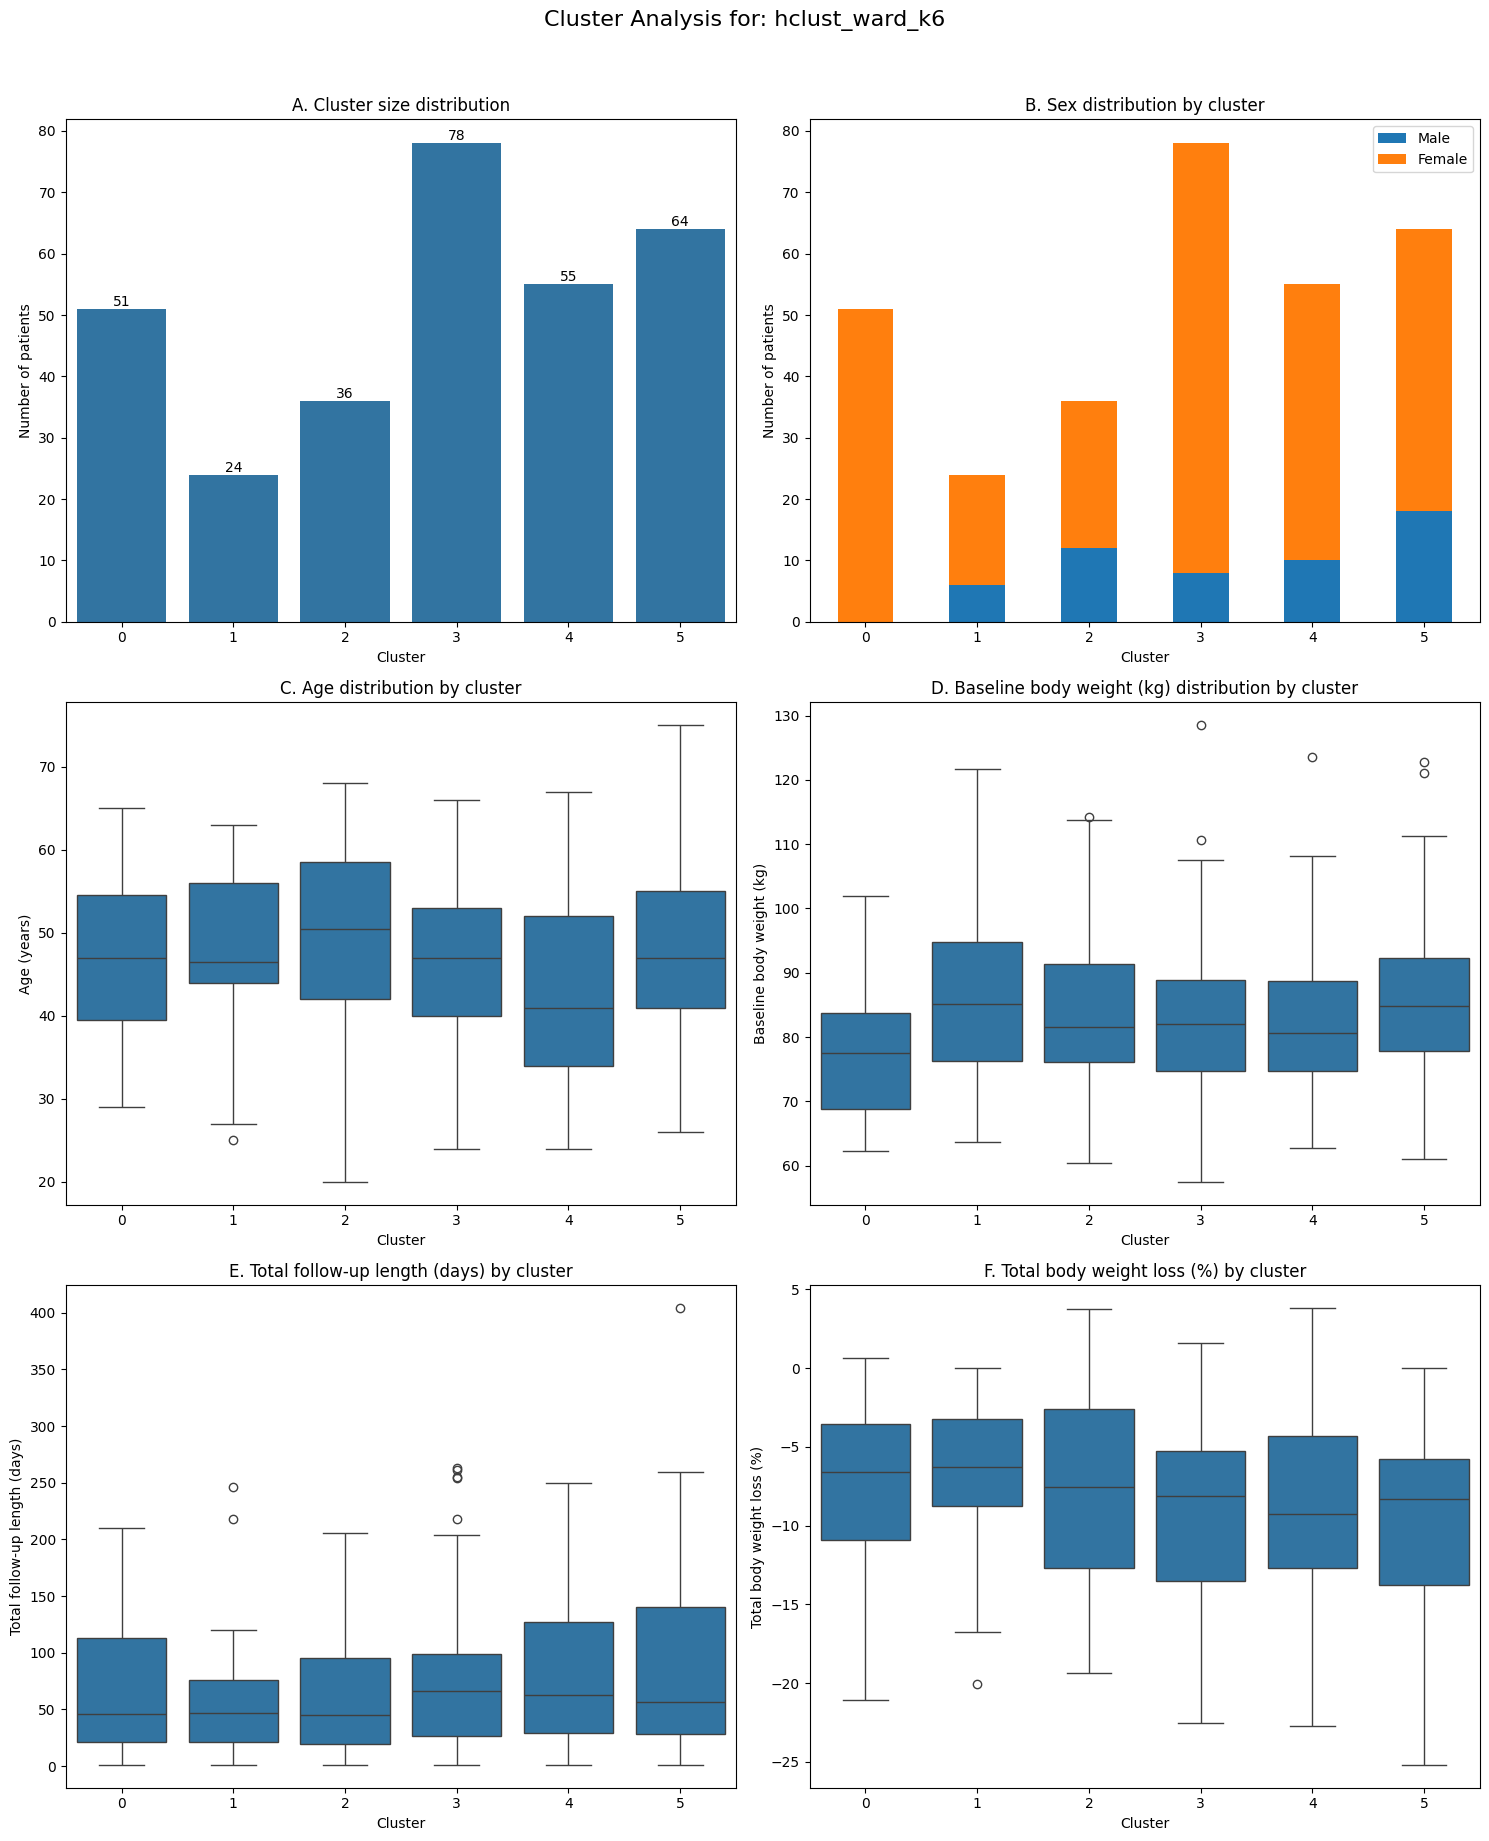


=== SIGNIFICANT DIFFERENCES (p < 0.05) ===
Found 18 variables with significant differences:
  Women's health & pregnancy (y/n): p = 1.00E-04 (fisher_exact)
  Mental health (y/n): p = 1.00E-04 (fisher_exact)
  Family issues (y/n): p = 1.00E-04 (fisher_exact)
  Medication, disease, or injury (y/n): p = 1.00E-04 (fisher_exact)
  Physical inactivity (y/n): p = 1.00E-04 (fisher_exact)
  Eating habits (y/n): p = 1.00E-04 (fisher_exact)
  Schedule (y/n): p = 1.00E-04 (fisher_exact)
  Treatment discontinuation or relapse (y/n): p = 0.003 (fisher_exact)
  Pandemic (y/n): p = 1.00E-04 (fisher_exact)
  Lifestyle, circumstances (y/n): p = 1.00E-04 (fisher_exact)
  None of the above (y/n): p = 1.00E-04 (fisher_exact)
  Emotional eating (y/n): p = 1.00E-04 (fisher_exact)
  Emotional eating score (1-10): p = 1.96E-06 (kruskal_wallis)
  Quantity control score (1-10): p = 0.001 (kruskal_wallis)
  Impulse control score (1-10): p = 0.002 (kruskal_wallis)
  Sex (female): p = 1.00E-04 (fisher_exact)
  Bas

In [67]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import kruskal, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
from multiprocessing import Pool

warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION SECTION
# =============================================================================

# Define the paper1_directory path (modify this to your actual path)
paper1_directory = "."  # Current directory, change this to your actual path

# Database paths
DATABASE_PATH = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
OUTPUT_DATABASE_PATH = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")
LABELS_TABLE = "cluster_labels"
SOURCE_DATA_TABLE = "timetoevent_eb_wgc_compl"

# =============================================================================
# CLUSTER SELECTION CONFIGURATION
# =============================================================================

# Configure the clustering setup you want to analyze
CLUSTERING_CONFIG = {
    'algorithm': 'hclust',            # 'hclust', 'pam', 'kmeans', etc.
    'k': 6,                          # number of clusters
    'linkage': 'ward',               # for hclust: 'ward', 'complete', 'average', 'single'
    'include_outliers': False         # whether to include outliers as separate group
}

# Variables to compare across clusters
COMPARISON_VARIABLES = [
    "womens_health_and_pregnancy",
    "mental_health",
    "family_issues",
    "medication_disease_injury",
    "physical_inactivity",
    "eating_habits",
    "schedule",
    "smoking_cessation",
    "treatment_discontinuation_or_relapse",
    "pandemic",
    "lifestyle_circumstances",
    "none_of_above",
    # Eating behaviors (binary) - Used in clustering
    "hunger_yn", "satiety_yn", "emotional_eating_yn",
    # Eating behaviors (continuous) - Used in clustering
    "emotional_eating_value_likert", "quantity_control_likert", "impulse_control_likert",

    # Demographics & baseline anthropometry
    "sex_f", "age",
    # "height_m",
    "baseline_weight_kg",
    "baseline_bmi",
    # "baseline_fat_%",
    # "baseline_muscle_%",

    # Weight loss outcomes
    # "last_aval_weight_kg", "total_wl_kg",
    "total_wl_%",
    # "final_bmi",
    "bmi_reduction",
    # "last_aval_fat_%",
    # "total_fat_loss_%",
    # "last_aval_muscle_%", "total_muscle_change_%",

    # Dynamic time windows (if available)
    # "40d_dropout", "wl_40d_%", "40d_fat_loss_%", "40d_muscle_change_%",
    "60d_dropout",
    "60d_wl_%",
    "60d_bmi_reduction",
    # "60d_fat_loss_%",
    # "60d_muscle_change_%",
    # "80d_dropout", "wl_80d_%", "80d_fat_loss_%", "80d_muscle_change_%",

    # Weight loss targets (if available)
    # "5%_wl_achieved", "days_to_5%_wl",
    "10%_wl_achieved", "days_to_10%_wl",
    # "15%_wl_achieved", "days_to_15%_wl"

    # Follow-up data
    "total_followup_days",
    # "instant_dropout", "dietitian_visits", "nr_total_measurements", "avg_days_between_measurements",

]

# --- NEW: Dictionary for human-readable variable names ---
VARIABLE_NAME_MAP = {
    "N (sample size)": "N (sample size)",
    "womens_health_and_pregnancy": "Women's health & pregnancy (y/n)",
    "mental_health": "Mental health (y/n)",
    "family_issues": "Family issues (y/n)",
    "medication_disease_injury": "Medication, disease, or injury (y/n)",
    "physical_inactivity": "Physical inactivity (y/n)",
    "eating_habits": "Eating habits (y/n)",
    "schedule": "Schedule (y/n)",
    "smoking_cessation": "Smoking cessation (y/n)",
    "treatment_discontinuation_or_relapse": "Treatment discontinuation or relapse (y/n)",
    "pandemic": "Pandemic (y/n)",
    "lifestyle_circumstances": "Lifestyle, circumstances (y/n)",
    "none_of_above": "None of the above (y/n)",
    "hunger_yn": "Hunger (y/n)",
    "satiety_yn": "Satiety (y/n)",
    "emotional_eating_yn": "Emotional eating (y/n)",
    "emotional_eating_value_likert": "Emotional eating score (1-10)",
    "quantity_control_likert": "Quantity control score (1-10)",
    "impulse_control_likert": "Impulse control score (1-10)",
    "sex_f": "Sex (female)",
    "age": "Age (years)",
    "baseline_weight_kg": "Baseline weight (kg)",
    "baseline_bmi": "Baseline BMI (kg/m²)",
    "total_wl_%": "Total Weight Loss (%)",
    "bmi_reduction": "BMI reduction (kg/m²)",
    "60d_dropout": "Dropout at 60 days (yes/no)",
    "60d_wl_%": "Weight loss at 60 days (%)",
    "60d_bmi_reduction": "BMI Reduction at 60 days (kg/m²)",
    "10%_wl_achieved": "Achieved 10% weight loss (yes/no)",
    "days_to_10%_wl": "Days to 10% weight loss",
    "total_followup_days": "Total follow-up (days)",
}

# --- NEW: Variables for which to run bootstrap comparisons ---
# These are clinical outcomes NOT used in the clustering process itself.
CLUSTERING_INPUT_VARIABLES = {
    "hunger_yn", "satiety_yn", "emotional_eating_yn",
    "emotional_eating_value_likert", "quantity_control_likert", "impulse_control_likert",
    "womens_health_and_pregnancy", "mental_health", "family_issues", "medication_disease_injury",
    "physical_inactivity", "eating_habits", "schedule", "smoking_cessation",
    "treatment_discontinuation_or_relapse", "pandemic", "lifestyle_circumstances", "none_of_above"
}
# BOOTSTRAP_VARIABLES = [
#     var for var in COMPARISON_VARIABLES if var not in CLUSTERING_INPUT_VARIABLES
# ]

# =============================================================================
# HELPER FUNCTIONS FOR STATISTICAL FORMATTING
# =============================================================================

def format_mean_sd(series, decimals=2):
    """Format mean ± SD for continuous variables."""
    if series.isna().all():
        return "N/A"
    mean_val = series.mean()
    sd_val = series.std()
    # n_available = series.notna().sum()
    return f"{mean_val:.{decimals}f}±{sd_val:.{decimals}f}"
    # can add in return statement: (n={n_available})

def format_n_perc(series):
    """Format n (%) for categorical variables."""
    if series.isna().all():
        return "N/A"
    total = series.notna().sum()
    positive = series.sum() if series.dtype in ['bool', 'int64'] else (series == 1).sum()
    if total == 0:
        return "0 (0.0%)"
    percentage = (positive / total) * 100
    return f"{int(positive)} ({percentage:.1f}%)"

# --- MODIFIED FUNCTION ---
def format_pval(p_value, threshold=0.001):
    """Format p-values with appropriate precision, showing exact values."""
    if pd.isna(p_value):
        return "N/A"
    if p_value < threshold:
        # Use scientific notation for very small p-values
        return f"{p_value:.2E}"
    else:
        # Use 3 decimal places for other p-values
        return f"{p_value:.3f}"

# =============================================================================
# BOOTSTRAP WORKER FUNCTION (for multiprocessing)
# =============================================================================

# def _bootstrap_pairwise_worker(data_tuple):
#     """
#     Worker function for a single bootstrap resample and comparison.
#     To be called by a multiprocessing pool.
#     """
#     group1_series, group2_series, variable_type = data_tuple
    
#     # Create bootstrap resamples by sampling with replacement
#     resample1 = np.random.choice(group1_series, size=len(group1_series), replace=True)
#     resample2 = np.random.choice(group2_series, size=len(group2_series), replace=True)
    
#     if variable_type == 'continuous':
#         # Return the difference in medians for continuous data
#         return np.median(resample1) - np.median(resample2)
#     elif variable_type == 'categorical':
#         # Return the difference in proportions (mean of 0/1 data) for categorical data
#         return np.mean(resample1) - np.mean(resample2)
#     return np.nan

# =============================================================================
# STATISTICAL TEST FUNCTIONS
# =============================================================================

def perform_continuous_test(groups_data, variable):
    """
    Perform Kruskal-Wallis test for continuous variables.
    This is a non-parametric test, robust to non-normality.
    """
    valid_groups = [group[variable].dropna() for group in groups_data if not group[variable].isna().all()]

    if len(valid_groups) < 2:
        return np.nan, "insufficient_data"

    group_sizes = [len(group) for group in valid_groups]
    if min(group_sizes) == 0:
        return np.nan, "empty_groups"

    try:
        # Default directly to Kruskal-Wallis test
        h_stat, p_value = kruskal(*valid_groups)
        test_used = "kruskal_wallis"
        return p_value, test_used
    except Exception as e:
        print(f"Error in Kruskal-Wallis test for {variable}: {e}")
        return np.nan, "error"

def perform_categorical_test(groups_data, variable):
    """
    Perform Fisher's Exact Test for categorical variables.
    This is the gold standard for small sample sizes and sparse data.
    """
    try:
        contingency_data = []
        for i, group in enumerate(groups_data):
            group_data = group[variable].dropna()
            if len(group_data) == 0:
                # Append a row of zeros if a group has no data for this variable
                contingency_data.append([0, 0])
            else:
                positive = group_data.sum() if group_data.dtype in ['bool', 'int64'] else (group_data == 1).sum()
                negative = len(group_data) - positive
                contingency_data.append([positive, negative])

        contingency_table = np.array(contingency_data)

        # Edge Case: No variation in the outcome across all groups
        if np.any(contingency_table.sum(axis=0) == 0):
            return 1.0, "no_variation"

        # Default directly to Fisher's Exact Test
        _, p_value = fisher_exact(contingency_table)
        test_used = "fisher_exact"
        return p_value, test_used

    except ValueError as e:
        # This might happen if the table is not 2xK, etc.
        print(f"Fisher's exact test failed for {variable}: {e}")
        return np.nan, "test_failed"
    except Exception as e:
        print(f"Error in categorical test for {variable}: {e}")
        return np.nan, "error"

# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

def construct_cluster_column_name(config):
    """Construct the column name for the specified clustering configuration."""
    algorithm = config['algorithm'].lower()
    k = config['k']

    if algorithm == 'hclust':
        linkage = config.get('linkage', 'ward')
        return f"hclust_{linkage}_k{k}"
    elif algorithm == 'pam':
        return f"pam_k{k}"
    elif algorithm == 'kmeans':
        return f"kmeans_k{k}"
    else:
        raise ValueError(f"Unsupported algorithm: {algorithm}")

def determine_variable_type(variable, df):
    """Determine if a variable is continuous or categorical."""
    if variable not in df.columns:
        return "missing"

    # Explicit categorical variables
    categorical_indicators = ["_yn", "_achieved", "_dropout", "sex_f", "instant_dropout"]
    if any(indicator in variable for indicator in categorical_indicators):
        return "categorical"

    # Explicit continuous variables (eating behavior scores)
    continuous_likert = ["emotional_eating_value_likert", "quantity_control_likert", "impulse_control_likert"]
    if variable in continuous_likert:
        return "continuous"

    # Check data type and unique values
    series = df[variable].dropna()
    if len(series) == 0:
        return "missing"

    # If it's boolean or has only 0/1 values, treat as categorical
    if series.dtype == 'bool' or set(series.unique()).issubset({0, 1, True, False}):
        return "categorical"

    # If it has very few unique values relative to sample size, might be categorical
    unique_ratio = len(series.unique()) / len(series)
    if unique_ratio < 0.05 and len(series.unique()) <= 10:
        return "categorical"

    return "continuous"

# =============================================================================
# DATA LOADING FUNCTIONS
# =============================================================================

def load_cluster_data(db_path, labels_table, source_table, cluster_column, include_outliers=True):
    """Load cluster labels and corresponding patient data."""
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found: {db_path}")

    with sqlite3.connect(db_path) as conn:
        # First, check if tables exist
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        available_tables = [row[0] for row in cursor.fetchall()]

        if labels_table not in available_tables:
            raise ValueError(f"Table '{labels_table}' not found. Available tables: {available_tables}")

        if source_table not in available_tables:
            raise ValueError(f"Table '{source_table}' not found. Available tables: {available_tables}")

        # Load cluster labels
        labels_query = f"SELECT * FROM {labels_table}"
        labels_df = pd.read_sql_query(labels_query, conn)

        # Load source data
        source_df = pd.read_sql_query(f"SELECT * FROM {source_table}", conn)

    # Check if cluster column exists
    if cluster_column not in labels_df.columns:
        available_columns = [col for col in labels_df.columns if any(alg in col for alg in ['hclust', 'pam', 'kmeans'])]
        raise ValueError(f"Cluster column '{cluster_column}' not found. Available clustering columns: {available_columns}")

    # Merge cluster labels with source data
    merged_df = source_df.merge(labels_df, on='medical_record_id', how='inner')

    # Separate outliers and valid clusters
    outliers_df = merged_df[merged_df[cluster_column] == -1].copy() if include_outliers else pd.DataFrame()
    valid_clusters_df = merged_df[merged_df[cluster_column] != -1].copy()

    # Get unique cluster labels
    unique_clusters = sorted([x for x in merged_df[cluster_column].unique() if x != -1])

    if len(unique_clusters) == 0:
        raise ValueError("No valid cluster labels found")

    print(f"Loaded data for {len(unique_clusters)} clusters: {unique_clusters}")
    if include_outliers and len(outliers_df) > 0:
        print(f"Outliers (excluded from clustering): {len(outliers_df)} patients")
    print(f"Total patients in valid clusters: {len(valid_clusters_df)}")

    # Print cluster sizes
    cluster_sizes = valid_clusters_df[cluster_column].value_counts().sort_index()
    for cluster, size in cluster_sizes.items():
        print(f"  Cluster {cluster}: {size} patients ({size/len(valid_clusters_df)*100:.1f}%)")

    return merged_df, unique_clusters, cluster_column, outliers_df

# =============================================================================
# ANALYSIS FUNCTIONS
# =============================================================================

# def run_bootstrap_comparisons(groups_data, group_names, variable, vtype, n_bootstraps=2000):
#     """
#     Performs pairwise bootstrap comparisons between all groups.
#     Returns a formatted string summarizing the 95% CIs.
#     """
#     ci_results = []
    
#     # Generate all unique pairs of groups to compare
#     group_indices = range(len(groups_data))
#     pairs = list(combinations(group_indices, 2))

#     for i, j in pairs:
#         group1_data = groups_data[i][variable].dropna()
#         group2_data = groups_data[j][variable].dropna()
        
#         # Skip pair if either group has no data for this variable
#         if group1_data.empty or group2_data.empty:
#             continue

#         # Prepare data for the multiprocessing pool
#         # We pass the same tuple n_bootstraps times
#         pool_args = [(group1_data, group2_data, vtype)] * n_bootstraps
        
#         # Use a multiprocessing pool to run bootstrap workers in parallel
#         with Pool() as pool:
#             bootstrap_diffs = pool.map(_bootstrap_pairwise_worker, pool_args)
        
#         # Calculate the 95% confidence interval from the bootstrap distribution
#         lower_bound = np.percentile(bootstrap_diffs, 2.5)
#         upper_bound = np.percentile(bootstrap_diffs, 97.5)
        
#         # Format the result for this pair
#         pair_name = f"C{group_names[i][-1]}vC{group_names[j][-1]}"
#         ci_str = f"[{lower_bound:.2f}, {upper_bound:.2f}]"
#         ci_results.append(f"{pair_name}: {ci_str}")
        
#     return "; ".join(ci_results) if ci_results else "N/A"


# --- MODIFIED FUNCTION ---
def compare_clusters(df, clusters, cluster_column, outliers_df, variables, name_map):
    """Perform statistical comparisons across clusters."""
    results = []

    # Create cluster groups
    cluster_groups = []
    group_names = []

    # Add regular clusters
    for cluster in clusters:
        cluster_data = df[df[cluster_column] == cluster]
        cluster_groups.append(cluster_data)
        group_names.append(f"Cluster_{cluster}")

    # Add outliers group if available
    if len(outliers_df) > 0:
        cluster_groups.append(outliers_df)
        group_names.append("Outliers")

    # Add sample sizes row
    size_row = {"Variable": "N (sample size)"}
    for i, group_name in enumerate(group_names):
        size_row[group_name] = f"{len(cluster_groups[i])}"
    size_row["p-value"] = "N/A"
    size_row["Test_Used"] = "N/A"
    size_row["Bootstrap Pairwise 95% CIs"] = "N/A" # Add new column
    results.append(size_row)

    # Compare each variable
    for variable in variables:
        if variable not in df.columns:
            # Handle missing variables
            row = {"Variable": variable}
            for group_name in group_names:
                row[group_name] = "N/A"
            row["p-value"] = "N/A"
            row["Test_Used"] = "missing_variable"
            row["Bootstrap Pairwise 95% CIs"] = "N/A"
            results.append(row)
            continue

        var_type = determine_variable_type(variable, df)
        row = {"Variable": variable}

        # Calculate descriptive statistics for each group
        for i, group_name in enumerate(group_names):
            group_data = cluster_groups[i]

            if var_type == "continuous":
                row[group_name] = format_mean_sd(group_data[variable])
            elif var_type == "categorical":
                row[group_name] = format_n_perc(group_data[variable])
            else:
                row[group_name] = "N/A"

        # Perform statistical test (only if we have at least 2 groups with data)
        if var_type == "continuous":
            p_value, test_used = perform_continuous_test(cluster_groups, variable)
        elif var_type == "categorical":
            p_value, test_used = perform_categorical_test(cluster_groups, variable)
        else:
            p_value, test_used = np.nan, "unsupported_type"

        row["p-value"] = format_pval(p_value)
        row["Test_Used"] = test_used
        
        # # --- NEW: Conditional Bootstrap Block ---
        # if variable in BOOTSTRAP_VARIABLES and var_type != "missing":
        #     print(f"  - Running bootstrap for: {variable}")
        #     bootstrap_summary = run_bootstrap_comparisons(cluster_groups, group_names, variable, var_type)
        #     row["Bootstrap Pairwise 95% CIs"] = bootstrap_summary
        # else:
        #     row["Bootstrap Pairwise 95% CIs"] = "N/A"

        results.append(row)

    # Define column order to ensure the new column is placed correctly
    column_order = ["Variable"] + group_names + ["p-value", "Test_Used", "Bootstrap Pairwise 95% CIs"]
    results_df = pd.DataFrame(results, columns=column_order)

    # --- NEW: Map variable names to human-readable format ---
    # Use .get(v, v) to keep the original name if it's not in the map
    results_df['Variable'] = results_df['Variable'].apply(lambda v: name_map.get(v, v))

    return results_df


def save_comparisons_to_db(df, db_path, table_name):
    """
    Saves a DataFrame to a specified table in an SQLite database.
    If the table already exists, it will be replaced.

    Args:
        df (pd.DataFrame): The DataFrame to save.
        db_path (str): The path to the SQLite database file.
        table_name (str): The name of the table to create/replace.
    """
    try:
        print(f"\nSaving results to table '{table_name}' in database '{db_path}'...")
        with sqlite3.connect(db_path) as conn:
            df.to_sql(
                name=table_name,
                con=conn,
                if_exists='replace',  # Overwrites the table if it exists
                index=False           # Do not write the DataFrame index as a column
            )
        print("Save successful.")
    except Exception as e:
        print(f"Error saving results to the database: {e}")
        
# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def create_cluster_visualization(df, cluster_column, clusters, outliers_df):
    """
    Create visualizations to understand cluster characteristics.
    This version includes a 3x2 grid with a plot for total follow-up days
    and ensures all plots are sorted by cluster number.
    """
    # A 3x2 grid is needed for the 5 plots.
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    # Prepare data including outliers for visualization
    viz_df = df.copy()
    if not outliers_df.empty:
        # Concatenate dataframes and replace -1 with a string for easier handling
        viz_df = pd.concat([df[df[cluster_column] != -1], outliers_df])
        viz_df.loc[viz_df[cluster_column] == -1, cluster_column] = 'Outliers'

    # --- NEW: Create a consistently ordered list of cluster labels ---
    # This ensures all plots use the same order: 0, 1, 2, ..., Outliers
    unique_labels = viz_df[cluster_column].unique()
    # Separate numeric cluster labels from the 'Outliers' label
    numeric_clusters = sorted([c for c in unique_labels if c != 'Outliers'])

    # Create the final ordered list of labels
    ordered_labels = numeric_clusters
    if 'Outliers' in unique_labels:
        ordered_labels.append('Outliers')    

    # 1. Cluster size distribution (Bar Chart)
    ax = axes[0]
    cluster_counts = viz_df[cluster_column].value_counts().reindex(ordered_labels)
    
    # Use seaborn for easier ordering and better aesthetics
    sns.barplot(x=cluster_counts.index.astype(str), y=cluster_counts.values, ax=ax, order=[str(l) for l in ordered_labels])
    ax.set_title('A. Cluster size distribution')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of patients')
    # Add text labels on top of bars
    for i, count in enumerate(cluster_counts):
        if pd.notna(count):
            ax.text(i, count, str(int(count)), ha='center', va='bottom')

    # 2. Sex distribution by cluster (Stacked Bar Chart)
    ax = axes[1]
    if 'sex_f' in viz_df.columns:
        # Create a crosstab and reindex to ensure correct order
        sex_crosstab = pd.crosstab(viz_df[cluster_column], viz_df['sex_f']).reindex(ordered_labels)
        sex_crosstab.plot(kind='bar', stacked=True, ax=ax, rot=0)
        ax.set_title('B. Sex distribution by cluster')
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Number of patients')
        ax.legend(['Male', 'Female'])
    else:
        ax.text(0.5, 0.5, 'Sex data not available', transform=ax.transAxes, ha='center')

    # 3. Age distribution by cluster (Box Plot)
    ax = axes[2]
    if 'age' in viz_df.columns:
        sns.boxplot(data=viz_df, x=cluster_column, y='age', ax=ax, order=ordered_labels)
        ax.set_title('C. Age distribution by cluster')
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Age (years)')
    else:
        ax.text(0.5, 0.5, 'Age data not available', transform=ax.transAxes, ha='center')

    # 4. Baseline weight distribution by cluster (Box Plot)
    ax = axes[3]
    if 'baseline_weight_kg' in viz_df.columns:
        sns.boxplot(data=viz_df, x=cluster_column, y='baseline_weight_kg', ax=ax, order=ordered_labels)
        ax.set_title('D. Baseline body weight (kg) distribution by cluster')
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Baseline body weight (kg)')
    else:
        ax.text(0.5, 0.5, 'Baseline body weight data not available', transform=ax.transAxes, ha='center')

    # 5. Total Follow-up Days by cluster (Box Plot) ---
    ax = axes[4]
    if 'total_followup_days' in viz_df.columns:
        sns.boxplot(data=viz_df, x=cluster_column, y='total_followup_days', ax=ax, order=ordered_labels)
        ax.set_title('E. Total follow-up length (days) by cluster')
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Total follow-up length (days)')
    else:
        ax.text(0.5, 0.5, 'Follow-up data not available', transform=ax.transAxes, ha='center')

    # 6. Weight loss percentage by cluster (Box Plot)
    ax = axes[5]
    if 'total_wl_%' in viz_df.columns:
        sns.boxplot(data=viz_df, x=cluster_column, y='total_wl_%', ax=ax, order=ordered_labels)
        ax.set_title('F. Total body weight loss (%) by cluster')
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Total body weight loss (%)')
    else:
        ax.text(0.5, 0.5, 'Weight loss % data not available', transform=ax.transAxes, ha='center')

    # Hide the unused subplot (the 6th one in a 3x2 grid)
    # axes[5].set_visible(False)

    # Add a title for the entire figure
    fig.suptitle(f'Cluster Analysis for: {cluster_column}', fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust layout to make space for suptitle
    plt.show()

# =============================================================================
# MAIN PIPELINE FUNCTION
# =============================================================================

def run_cluster_comparison_pipeline():
    """Main function to run the cluster comparison pipeline."""
    print("=== CLUSTER COMPARISON PIPELINE ===")
    print(f"Configuration: {CLUSTERING_CONFIG}")

    try:
        # Step 1: Construct cluster column name
        cluster_column = construct_cluster_column_name(CLUSTERING_CONFIG)
        print(f"Looking for cluster column: {cluster_column}")

        # Step 2: Load cluster data
        print("\nLoading cluster data...")
        df, clusters, cluster_col, outliers_df = load_cluster_data(
            DATABASE_PATH, LABELS_TABLE, SOURCE_DATA_TABLE,
            cluster_column, CLUSTERING_CONFIG['include_outliers']
        )

        # Step 3: Perform statistical comparisons
        total_groups = len(clusters) + (1 if len(outliers_df) > 0 else 0)
        print(f"\nComparing {len(COMPARISON_VARIABLES)} variables across {total_groups} groups...")
        # --- MODIFIED FUNCTION CALL ---
        comparison_results = compare_clusters(df, clusters, cluster_col, outliers_df, COMPARISON_VARIABLES, VARIABLE_NAME_MAP)

        # Step 4: Display and save results
        print("\n=== CLUSTER COMPARISON RESULTS ===")
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', 100) # Increased for bootstrap CIs

        print(comparison_results.to_string(index=False))

        save_comparisons_to_db(comparison_results, OUTPUT_DATABASE_PATH, cluster_column)

        # Step 5: Create visualizations
        print("\nCreating cluster visualizations...")
        create_cluster_visualization(df, cluster_col, clusters, outliers_df)

        # Step 6: Summary of significant differences
        print("\n=== SIGNIFICANT DIFFERENCES (p < 0.05) ===")
        significant_results = comparison_results[
            (comparison_results['p-value'] != 'N/A') &
            (comparison_results['Variable'] != 'N (sample size)')
        ].copy()

        if len(significant_results) > 0:
            # --- MODIFIED HELPER FUNCTION ---
            def extract_pvalue(p_str):
                """Converts formatted p-value string back to float."""
                if p_str == 'N/A':
                    return 1.0
                try:
                    # float() can handle scientific notation like '1.23e-04'
                    return float(p_str)
                except ValueError:
                    return 1.0

            significant_results['p_numeric'] = significant_results['p-value'].apply(extract_pvalue)
            significant_vars = significant_results[significant_results['p_numeric'] < 0.05]

            if len(significant_vars) > 0:
                print(f"Found {len(significant_vars)} variables with significant differences:")
                for _, row in significant_vars.iterrows():
                    print(f"  {row['Variable']}: p = {row['p-value']} ({row['Test_Used']})")
            else:
                print("No variables showed significant differences between groups.")

        return comparison_results, df

    except Exception as e:
        print(f"Error in pipeline execution: {e}")
        print("\nPlease check:")
        print("1. Database file path is correct")
        print("2. Tables exist in the database")
        print("3. Cluster column name matches available columns")
        return None, None

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    # Configure display options
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 100)

    # Run the cluster comparison pipeline
    results_df, cluster_data = run_cluster_comparison_pipeline()

    # if results_df is not None:
    #     print("\n=== PIPELINE COMPLETED SUCCESSFULLY ===")
    #     print(f"Results shape: {results_df.shape}")
    #     print("Use 'results_df' to access the comparison table")
    #     print("Use 'cluster_data' to access the merged dataset")
    # else:
    #     print("\n=== PIPELINE FAILED ===")
    #     print("Please check the error messages above and fix the configuration")

#### og

=== CLUSTER COMPARISON PIPELINE ===
Configuration: {'algorithm': 'hclust', 'k': 5, 'linkage': 'ward', 'include_outliers': False}
Looking for cluster column: hclust_ward_k5

Loading cluster data...
Loaded data for 5 clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Total patients in valid clusters: 284
  Cluster 0: 51 patients (18.0%)
  Cluster 1: 36 patients (12.7%)
  Cluster 2: 78 patients (27.5%)
  Cluster 3: 55 patients (19.4%)
  Cluster 4: 64 patients (22.5%)

Comparing 35 variables across 5 groups...

=== CLUSTER COMPARISON RESULTS ===
                            Variable            Cluster_0            Cluster_1            Cluster_2            Cluster_3            Cluster_4 p-value      Test_Used
                     N (sample size)                   51                   36                   78                   55                   64     N/A            N/A
                               sex_f          51 (100.0%)           24 (66.7%)           70 (89.7

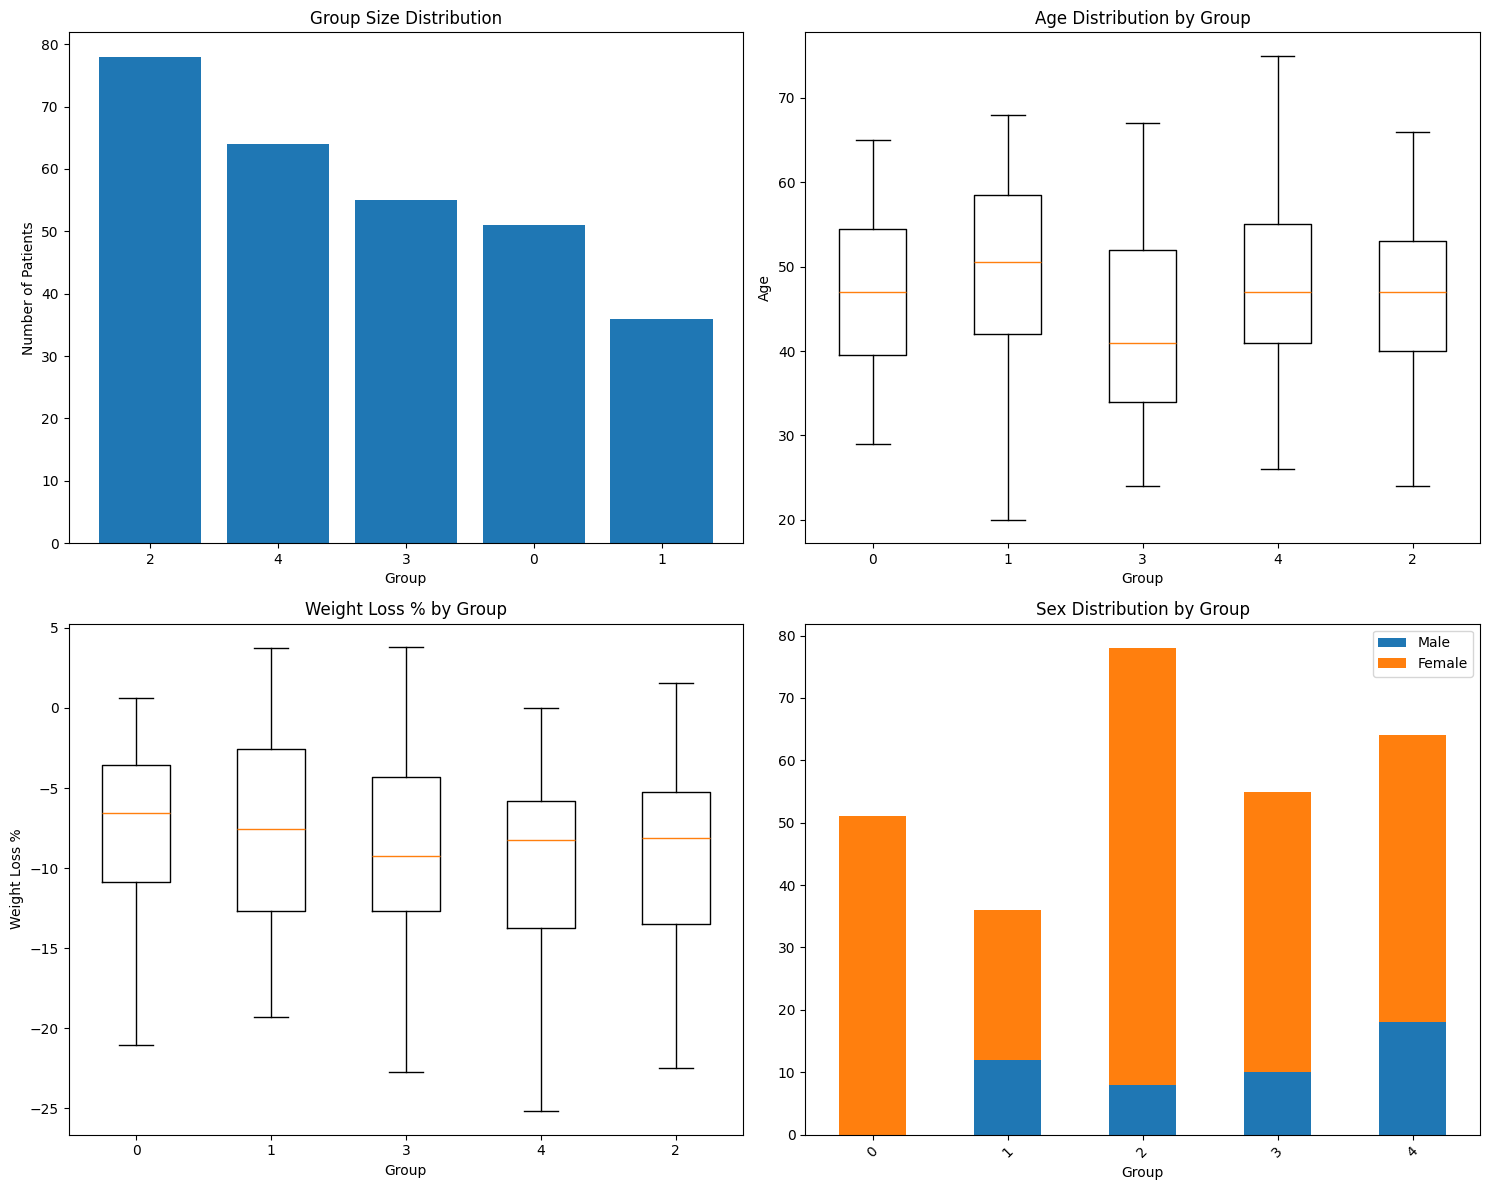


=== SIGNIFICANT DIFFERENCES (p < 0.05) ===
Found 18 variables with significant differences:
  sex_f: p = <0.001 (chi_square)
  baseline_weight_kg: p = 0.005 (anova)
  baseline_bmi: p = 0.014 (anova)
  emotional_eating_yn: p = <0.001 (chi_square)
  emotional_eating_value_likert: p = <0.001 (kruskal_wallis)
  quantity_control_likert: p = 0.003 (kruskal_wallis)
  impulse_control_likert: p = 0.004 (kruskal_wallis)
  womens_health_and_pregnancy: p = <0.001 (chi_square)
  mental_health: p = <0.001 (chi_square)
  family_issues: p = <0.001 (chi_square)
  medication_disease_injury: p = <0.001 (chi_square)
  physical_inactivity: p = <0.001 (chi_square)
  eating_habits: p = <0.001 (chi_square)
  schedule: p = <0.001 (chi_square)
  smoking_cessation: p = 0.037 (chi_square)
  treatment_discontinuation_or_relapse: p = 0.004 (chi_square)
  pandemic: p = <0.001 (chi_square)
  lifestyle_circumstances: p = <0.001 (chi_square)

=== PIPELINE COMPLETED SUCCESSFULLY ===
Results shape: (36, 8)
Use 'results_

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency, kruskal
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION SECTION
# =============================================================================

# Define the paper1_directory path (modify this to your actual path)
paper1_directory = "."  # Current directory, change this to your actual path

# Database paths
DATABASE_PATH = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
LABELS_TABLE = "cluster_labels"
SOURCE_DATA_TABLE = "timetoevent_eb_wgc_compl"

# =============================================================================
# CLUSTER SELECTION CONFIGURATION
# =============================================================================

# Configure the clustering setup you want to analyze
CLUSTERING_CONFIG = {
    'algorithm': 'hclust',            # 'hclust', 'pam', 'kmeans', etc.
    'k': 5,                          # number of clusters
    'linkage': 'ward',               # for hclust: 'ward', 'complete', 'average', 'single'
    'include_outliers': False         # whether to include outliers as separate group
}

# Variables to compare across clusters
COMPARISON_VARIABLES = [
    # Demographics & baseline anthropometry
    "sex_f", "age", 
    # "height_m", 
    "baseline_weight_kg",     "baseline_bmi", "baseline_fat_%", 
    # "baseline_muscle_%",
    
    # Follow-up data
    "total_followup_days", 
    # "instant_dropout", "dietitian_visits", "nr_total_measurements", "avg_days_between_measurements",
    
    # Weight loss outcomes
    # "last_aval_weight_kg", "total_wl_kg", 
    "total_wl_%", 
    # "final_bmi", 
    "bmi_reduction",
    # "last_aval_fat_%", 
    "total_fat_loss_%", 
    # "last_aval_muscle_%", "total_muscle_change_%",
    
    # Eating behaviors (binary)
    "hunger_yn", "satiety_yn", "emotional_eating_yn",
    
    # Eating behaviors (continuous)
    "emotional_eating_value_likert", "quantity_control_likert", "impulse_control_likert",
    
    # Weight gain causes (binary)
    "womens_health_and_pregnancy", "mental_health", "family_issues", "medication_disease_injury",
    "physical_inactivity", "eating_habits", "schedule", "smoking_cessation",
    "treatment_discontinuation_or_relapse", "pandemic", "lifestyle_circumstances", "none_of_above",
    
    # Dynamic time windows (if available)
    # "40d_dropout", "wl_40d_%", "40d_fat_loss_%", "40d_muscle_change_%",
    "60d_dropout", "60d_wl_%", "60d_bmi_reduction", "60d_fat_loss_%", 
    # "60d_muscle_change_%",
    # "80d_dropout", "wl_80d_%", "80d_fat_loss_%", "80d_muscle_change_%",
    
    # Weight loss targets (if available)
    "5%_wl_achieved", "days_to_5%_wl",
    "10%_wl_achieved", "days_to_10%_wl",
    # "15%_wl_achieved", "days_to_15%_wl"
]

# =============================================================================
# HELPER FUNCTIONS FOR STATISTICAL FORMATTING
# =============================================================================

def format_mean_sd(series, decimals=2):
    """Format mean ± SD for continuous variables."""
    if series.isna().all():
        return "N/A"
    mean_val = series.mean()
    sd_val = series.std()
    n_available = series.notna().sum()
    return f"{mean_val:.{decimals}f} ± {sd_val:.{decimals}f} (n={n_available})"

def format_n_perc(series):
    """Format n (%) for categorical variables."""
    if series.isna().all():
        return "N/A"
    total = series.notna().sum()
    positive = series.sum() if series.dtype in ['bool', 'int64'] else (series == 1).sum()
    if total == 0:
        return "0 (0.0%)"
    percentage = (positive / total) * 100
    return f"{int(positive)} ({percentage:.1f}%)"

def format_pval(p_value, threshold=0.001):
    """Format p-values with appropriate precision."""
    if pd.isna(p_value):
        return "N/A"
    if p_value < threshold:
        return f"<{threshold}"
    elif p_value < 0.01:
        return f"{p_value:.3f}"
    elif p_value < 0.05:
        return f"{p_value:.3f}"
    else:
        return f"{p_value:.3f}"

# =============================================================================
# STATISTICAL TEST FUNCTIONS
# =============================================================================

def perform_anova_test(groups_data, variable):
    """Perform appropriate ANOVA test for continuous variables."""
    # Remove groups with all NaN values
    valid_groups = [group[variable].dropna() for group in groups_data if not group[variable].isna().all()]
    
    if len(valid_groups) < 2:
        return np.nan, "insufficient_data"
    
    # Check if all groups have at least some data
    group_sizes = [len(group) for group in valid_groups]
    if min(group_sizes) == 0:
        return np.nan, "empty_groups"
    
    try:
        # Test for normality (Shapiro-Wilk for small samples)
        normality_tests = []
        for group in valid_groups:
            if len(group) >= 3:  # Need at least 3 observations for Shapiro-Wilk
                _, p_norm = stats.shapiro(group)
                normality_tests.append(p_norm > 0.05)  # True if normal
        
        # If most groups appear normal, use ANOVA; otherwise use Kruskal-Wallis
        if len(normality_tests) > 0 and sum(normality_tests) >= len(normality_tests) * 0.5:
            # Use one-way ANOVA
            f_stat, p_value = f_oneway(*valid_groups)
            test_used = "anova"
        else:
            # Use Kruskal-Wallis (non-parametric)
            h_stat, p_value = kruskal(*valid_groups)
            test_used = "kruskal_wallis"
        
        return p_value, test_used
    
    except Exception as e:
        print(f"Error in ANOVA test for {variable}: {e}")
        return np.nan, "error"

def perform_chi_square_test(groups_data, variable):
    """
    Perform chi-square test for categorical variables, with a robust fallback
    to Fisher's exact test for sparse data.
    """
    try:
        # Create contingency table (This logic remains unchanged)
        contingency_data = []
        for i, group in enumerate(groups_data):
            group_data = group[variable].dropna()
            if len(group_data) == 0:
                contingency_data.append([0, 0])
            else:
                positive = group_data.sum() if group_data.dtype in ['bool', 'int64'] else (group_data == 1).sum()
                negative = len(group_data) - positive
                contingency_data.append([positive, negative])
        
        contingency_table = np.array(contingency_data)

        # Edge Case: No variation (This logic remains unchanged)
        if np.any(contingency_table.sum(axis=0) == 0):
            return 1.0, "no_variation"

        # --- MODIFICATION 2: Correct the try/except block ---
        try:
            # Use the 'stats' prefix for the function call
            chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
            
            if dof == 0:
                 raise ValueError("Degrees of freedom is 0, Chi-square is not applicable.")
            test_used = "chi_square"
            
        except ValueError:
            # This fallback will now work correctly because 'stats' is imported.
            try:
                # Use the 'stats' prefix for the function call
                _, p_value = stats.fisher_exact(contingency_table)
                test_used = "fisher_exact"
            except ValueError as e:
                print(f"Fisher's exact test also failed for {variable}: {e}")
                return np.nan, "test_failed"

        return p_value, test_used
    
    except Exception as e:
        print(f"Error in chi-square test for {variable}: {e}")
        return np.nan, "error"
    
# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

def construct_cluster_column_name(config):
    """Construct the column name for the specified clustering configuration."""
    algorithm = config['algorithm'].lower()
    k = config['k']
    
    if algorithm == 'hclust':
        linkage = config.get('linkage', 'ward')
        return f"hclust_{linkage}_k{k}"
    elif algorithm == 'pam':
        return f"pam_k{k}"
    elif algorithm == 'kmeans':
        return f"kmeans_k{k}"
    else:
        raise ValueError(f"Unsupported algorithm: {algorithm}")

def determine_variable_type(variable, df):
    """Determine if a variable is continuous or categorical."""
    if variable not in df.columns:
        return "missing"
    
    # Explicit categorical variables
    categorical_indicators = ["_yn", "_achieved", "_dropout", "sex_f", "instant_dropout"]
    if any(indicator in variable for indicator in categorical_indicators):
        return "categorical"
    
    # Explicit continuous variables (eating behavior scores)
    continuous_likert = ["emotional_eating_value_likert", "quantity_control_likert", "impulse_control_likert"]
    if variable in continuous_likert:
        return "continuous"
    
    # Check data type and unique values
    series = df[variable].dropna()
    if len(series) == 0:
        return "missing"
    
    # If it's boolean or has only 0/1 values, treat as categorical
    if series.dtype == 'bool' or set(series.unique()).issubset({0, 1, True, False}):
        return "categorical"
    
    # If it has very few unique values relative to sample size, might be categorical
    unique_ratio = len(series.unique()) / len(series)
    if unique_ratio < 0.05 and len(series.unique()) <= 10:
        return "categorical"
    
    return "continuous"

# =============================================================================
# DATA LOADING FUNCTIONS
# =============================================================================

def load_cluster_data(db_path, labels_table, source_table, cluster_column, include_outliers=True):
    """Load cluster labels and corresponding patient data."""
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found: {db_path}")
    
    with sqlite3.connect(db_path) as conn:
        # First, check if tables exist
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        available_tables = [row[0] for row in cursor.fetchall()]
        
        if labels_table not in available_tables:
            raise ValueError(f"Table '{labels_table}' not found. Available tables: {available_tables}")
        
        if source_table not in available_tables:
            raise ValueError(f"Table '{source_table}' not found. Available tables: {available_tables}")
        
        # Load cluster labels
        labels_query = f"SELECT * FROM {labels_table}"
        labels_df = pd.read_sql_query(labels_query, conn)
        
        # Load source data
        source_df = pd.read_sql_query(f"SELECT * FROM {source_table}", conn)
    
    # Check if cluster column exists
    if cluster_column not in labels_df.columns:
        available_columns = [col for col in labels_df.columns if any(alg in col for alg in ['hclust', 'pam', 'kmeans'])]
        raise ValueError(f"Cluster column '{cluster_column}' not found. Available clustering columns: {available_columns}")
    
    # Merge cluster labels with source data
    merged_df = source_df.merge(labels_df, on='medical_record_id', how='inner')
    
    # Separate outliers and valid clusters
    outliers_df = merged_df[merged_df[cluster_column] == -1].copy() if include_outliers else pd.DataFrame()
    valid_clusters_df = merged_df[merged_df[cluster_column] != -1].copy()
    
    # Get unique cluster labels
    unique_clusters = sorted([x for x in merged_df[cluster_column].unique() if x != -1])
    
    if len(unique_clusters) == 0:
        raise ValueError("No valid cluster labels found")
    
    print(f"Loaded data for {len(unique_clusters)} clusters: {unique_clusters}")
    if include_outliers and len(outliers_df) > 0:
        print(f"Outliers (excluded from clustering): {len(outliers_df)} patients")
    print(f"Total patients in valid clusters: {len(valid_clusters_df)}")
    
    # Print cluster sizes
    cluster_sizes = valid_clusters_df[cluster_column].value_counts().sort_index()
    for cluster, size in cluster_sizes.items():
        print(f"  Cluster {cluster}: {size} patients ({size/len(valid_clusters_df)*100:.1f}%)")
    
    return merged_df, unique_clusters, cluster_column, outliers_df

# =============================================================================
# ANALYSIS FUNCTIONS
# =============================================================================

def compare_clusters(df, clusters, cluster_column, outliers_df, variables):
    """Perform statistical comparisons across clusters."""
    results = []
    
    # Create cluster groups
    cluster_groups = []
    group_names = []
    
    # Add regular clusters
    for cluster in clusters:
        cluster_data = df[df[cluster_column] == cluster]
        cluster_groups.append(cluster_data)
        group_names.append(f"Cluster_{cluster}")
    
    # Add outliers group if available
    if len(outliers_df) > 0:
        cluster_groups.append(outliers_df)
        group_names.append("Outliers")
    
    # Add sample sizes row
    size_row = {"Variable": "N (sample size)"}
    for i, group_name in enumerate(group_names):
        size_row[group_name] = f"{len(cluster_groups[i])}"
    size_row["p-value"] = "N/A"
    size_row["Test_Used"] = "N/A"
    results.append(size_row)
    
    # Compare each variable
    for variable in variables:
        if variable not in df.columns:
            # Handle missing variables
            row = {"Variable": variable}
            for group_name in group_names:
                row[group_name] = "N/A"
            row["p-value"] = "N/A"
            row["Test_Used"] = "missing_variable"
            results.append(row)
            continue
        
        var_type = determine_variable_type(variable, df)
        row = {"Variable": variable}
        
        # Calculate descriptive statistics for each group
        for i, group_name in enumerate(group_names):
            group_data = cluster_groups[i]
            
            if var_type == "continuous":
                row[group_name] = format_mean_sd(group_data[variable])
            elif var_type == "categorical":
                row[group_name] = format_n_perc(group_data[variable])
            else:
                row[group_name] = "N/A"
        
        # Perform statistical test (only if we have at least 2 groups with data)
        if var_type == "continuous":
            p_value, test_used = perform_anova_test(cluster_groups, variable)
        elif var_type == "categorical":
            p_value, test_used = perform_chi_square_test(cluster_groups, variable)
        else:
            p_value, test_used = np.nan, "unsupported_type"
        
        row["p-value"] = format_pval(p_value)
        row["Test_Used"] = test_used
        
        results.append(row)
    
    return pd.DataFrame(results)

# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def create_cluster_visualization(df, cluster_column, clusters, outliers_df):
    """Create visualizations to understand cluster characteristics."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Prepare data including outliers for visualization
    viz_df = df.copy()
    if len(outliers_df) > 0:
        viz_df = pd.concat([df[df[cluster_column] != -1], outliers_df])
        viz_df.loc[viz_df[cluster_column] == -1, cluster_column] = 'Outliers'
    
    # 1. Cluster size distribution
    cluster_counts = viz_df[cluster_column].value_counts()
    if 'Outliers' in cluster_counts.index:
        # Reorder to put outliers at the end
        regular_clusters = cluster_counts.drop('Outliers').sort_index()
        cluster_counts = pd.concat([regular_clusters, cluster_counts[['Outliers']]])
    
    axes[0, 0].bar(range(len(cluster_counts)), cluster_counts.values)
    axes[0, 0].set_xticks(range(len(cluster_counts)))
    axes[0, 0].set_xticklabels(cluster_counts.index.astype(str))
    axes[0, 0].set_title('Group Size Distribution')
    axes[0, 0].set_xlabel('Group')
    axes[0, 0].set_ylabel('Number of Patients')
    
    # 2. Age distribution by cluster
    if 'age' in viz_df.columns:
        age_data = [viz_df[viz_df[cluster_column] == cluster]['age'].dropna() 
                   for cluster in viz_df[cluster_column].unique()]
        axes[0, 1].boxplot(age_data, labels=viz_df[cluster_column].unique())
        axes[0, 1].set_title('Age Distribution by Group')
        axes[0, 1].set_xlabel('Group')
        axes[0, 1].set_ylabel('Age')
    else:
        axes[0, 1].text(0.5, 0.5, 'Age data not available', transform=axes[0, 1].transAxes, ha='center')
    
    # 3. Weight loss percentage by cluster
    if 'total_wl_%' in viz_df.columns:
        wl_data = [viz_df[viz_df[cluster_column] == cluster]['total_wl_%'].dropna() 
                  for cluster in viz_df[cluster_column].unique()]
        axes[1, 0].boxplot(wl_data, labels=viz_df[cluster_column].unique())
        axes[1, 0].set_title('Weight Loss % by Group')
        axes[1, 0].set_xlabel('Group')
        axes[1, 0].set_ylabel('Weight Loss %')
    else:
        axes[1, 0].text(0.5, 0.5, 'Weight loss % data not available', transform=axes[1, 0].transAxes, ha='center')
    
    # 4. Sex distribution by cluster
    if 'sex_f' in viz_df.columns:
        sex_crosstab = pd.crosstab(viz_df[cluster_column], viz_df['sex_f'])
        sex_crosstab.plot(kind='bar', stacked=True, ax=axes[1, 1])
        axes[1, 1].set_title('Sex Distribution by Group')
        axes[1, 1].set_xlabel('Group')
        axes[1, 1].legend(['Male', 'Female'])
        axes[1, 1].tick_params(axis='x', rotation=45)
    else:
        axes[1, 1].text(0.5, 0.5, 'Sex data not available', transform=axes[1, 1].transAxes, ha='center')
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# MAIN PIPELINE FUNCTION
# =============================================================================

def run_cluster_comparison_pipeline():
    """Main function to run the cluster comparison pipeline."""
    print("=== CLUSTER COMPARISON PIPELINE ===")
    print(f"Configuration: {CLUSTERING_CONFIG}")
    
    try:
        # Step 1: Construct cluster column name
        cluster_column = construct_cluster_column_name(CLUSTERING_CONFIG)
        print(f"Looking for cluster column: {cluster_column}")
        
        # Step 2: Load cluster data
        print("\nLoading cluster data...")
        df, clusters, cluster_col, outliers_df = load_cluster_data(
            DATABASE_PATH, LABELS_TABLE, SOURCE_DATA_TABLE, 
            cluster_column, CLUSTERING_CONFIG['include_outliers']
        )
        
        # Step 3: Perform statistical comparisons
        total_groups = len(clusters) + (1 if len(outliers_df) > 0 else 0)
        print(f"\nComparing {len(COMPARISON_VARIABLES)} variables across {total_groups} groups...")
        comparison_results = compare_clusters(df, clusters, cluster_col, outliers_df, COMPARISON_VARIABLES)
        
        # Step 4: Display results
        print("\n=== CLUSTER COMPARISON RESULTS ===")
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', 50)
        
        print(comparison_results.to_string(index=False))
                
        # Step 5: Create visualizations
        print("\nCreating cluster visualizations...")
        create_cluster_visualization(df, cluster_col, clusters, outliers_df)
        
        # Step 6: Summary of significant differences
        print("\n=== SIGNIFICANT DIFFERENCES (p < 0.05) ===")
        significant_results = comparison_results[
            (comparison_results['p-value'] != 'N/A') & 
            (comparison_results['Variable'] != 'N (sample size)')
        ].copy()
        
        if len(significant_results) > 0:
            # Convert p-values for filtering
            def extract_pvalue(p_str):
                if p_str == 'N/A':
                    return 1.0
                elif p_str.startswith('<'):
                    return float(p_str[1:])
                else:
                    try:
                        return float(p_str)
                    except ValueError:
                        return 1.0
            
            significant_results['p_numeric'] = significant_results['p-value'].apply(extract_pvalue)
            significant_vars = significant_results[significant_results['p_numeric'] < 0.05]
            
            if len(significant_vars) > 0:
                print(f"Found {len(significant_vars)} variables with significant differences:")
                for _, row in significant_vars.iterrows():
                    print(f"  {row['Variable']}: p = {row['p-value']} ({row['Test_Used']})")
            else:
                print("No variables showed significant differences between groups.")
        
        return comparison_results, df
        
    except Exception as e:
        print(f"Error in pipeline execution: {e}")
        print("\nPlease check:")
        print("1. Database file path is correct")
        print("2. Tables exist in the database")
        print("3. Cluster column name matches available columns")
        return None, None

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    # Configure display options
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 50)
    
    # Run the cluster comparison pipeline
    results_df, cluster_data = run_cluster_comparison_pipeline()
    
    if results_df is not None:
        print("\n=== PIPELINE COMPLETED SUCCESSFULLY ===")
        print(f"Results shape: {results_df.shape}")
        print("Use 'results_df' to access the comparison table")
        print("Use 'cluster_data' to access the merged dataset")
    else:
        print("\n=== PIPELINE FAILED ===")
        print("Please check the error messages above and fix the configuration")

In [ ]:
results_df

Best k-prototypes results by metric:
  Best Silhouette: k=2 (score: 0.2597)
  Best Davies-Bouldin: k=2 (score: 1.8699)
  Best Calinski-Harabasz: k=2 (score: 62.7761)

## Other explorations

### [arch probably] Regularized regressions for evaluating predictive performance of outcomes by WGCs

#### EN-penalized logistic outcome prediction of WL by all EBs adjusted for age, sex, bmi, fat, muscle

##### code

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np

# Scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import warnings

# --- Configuration ---

# IMPORTANT: Ensure 'paper1_directory' is defined in your notebook environment.
# For example:
# paper1_directory = "/path/to/your/project/data" 
# If it's already defined, you can leave the line below commented out.
# If not, uncomment and set it, or define it in a previous cell.
# paper1_directory = "." # Example: current directory

DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
INPUT_TABLE_NAME = "timetoevent_eb_compl"

# Define predictors
EB_VARIABLES = [
    'hunger_yn', 'satiety_yn', 'emotional_eating_yn',
    'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
]
ADJUSTMENT_VARIABLES = [
    'age', 'sex_f', 'baseline_bmi', 
    'baseline_fat_%', 'baseline_muscle_%' # Special characters handled by pandas
]
PREDICTOR_COLUMNS = EB_VARIABLES + ADJUSTMENT_VARIABLES

# Define outcome parameters
OUTCOME_TIME_WINDOW_DAYS = 60
OUTCOME_TARGET_WL_PERCENTAGE = 10
OUTCOME_COLUMN_NAME = f"target_wl_{OUTCOME_TIME_WINDOW_DAYS}d_{OUTCOME_TARGET_WL_PERCENTAGE}p_outcome"

# Define model hyperparameters for GridSearchCV
# Alpha values from prompt
ALPHAS = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
# Convert alpha to C (inverse of regularization strength for scikit-learn)
C_VALUES = [1/a for a in ALPHAS]
L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

# Other settings
TEST_SIZE = 0.20
CV_FOLDS = 10
RANDOM_STATE = 42 # For reproducibility

# --- Helper Functions (adapted from original script where possible) ---

def load_data_from_sqlite(db_path, table_name):
    """Load data from SQLite table."""
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found: {db_path}")
    with sqlite3.connect(db_path) as conn:
        # SELECT * handles special characters in column names automatically
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    print(f"Loaded data from {table_name}: {df.shape[0]} rows, {df.shape[1]} columns.")
    return df

def preprocess_feature_columns(df, feature_cols):
    """
    Prepare feature columns: 
    - Map 'yes'/'no'/'y'/'n' to 1/0 for specified columns.
    - Ensure all feature columns are numeric, coercing errors to NaN.
    """
    df_processed = df.copy()
    
    # Identify yes/no columns among the feature_cols
    # Typically, these are columns ending with '_yn'
    yes_no_cols = [col for col in feature_cols if df_processed[col].dtype == object and 
                   any(val in ['yes', 'no', 'y', 'n'] for val in df_processed[col].dropna().unique())]

    for col in yes_no_cols:
        df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0, 'y': 1, 'n': 0}).astype(float)
        print(f"Processed column '{col}': mapped yes/no to 1/0.")

    # Ensure all feature columns are numeric. Non-convertible values become NaN.
    for col in feature_cols:
        if col not in df_processed.columns:
            print(f"Warning: Feature column '{col}' not found in DataFrame. Skipping.")
            continue
        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
        if df_processed[col].isnull().any():
            print(f"Note: Column '{col}' contains NaNs after numeric conversion or originally.")
            
    return df_processed

def define_target_outcome_variable(df, time_window_days, target_wl_percentage, outcome_col_name):
    """
    Create the binary outcome column for target weight loss.
    Outcome is 1 if absolute weight loss percentage at time_window_days >= target_wl_percentage.
    """
    df_processed = df.copy()
    # Determine the source column for weight loss percentage
    # Based on original script's logic: f"wl_{tw}d_%"
    source_wl_col = f"wl_{time_window_days}d_%" 
    
    if source_wl_col not in df_processed.columns:
        raise KeyError(f"Required weight loss column '{source_wl_col}' not found in DataFrame. "
                       f"Available columns: {df_processed.columns.tolist()}")
    
    # Ensure the source WL column is numeric
    df_processed[source_wl_col] = pd.to_numeric(df_processed[source_wl_col], errors='coerce')
    
    # Define outcome: 1 if target met, 0 otherwise. Handle NaNs in source_wl_col.
    df_processed[outcome_col_name] = (df_processed[source_wl_col].abs() >= target_wl_percentage).astype(float)
    # NaNs in source_wl_col will result in NaNs in outcome_col_name, to be dropped later.
    
    print(f"Defined outcome variable '{outcome_col_name}'.")
    print(f"Outcome distribution before NaN handling:\n{df_processed[outcome_col_name].value_counts(dropna=False)}")
    return df_processed

# --- Main EN Logistic Regression Pipeline Function ---

def run_en_logistic_regression_pipeline(db_path, table_name, feature_cols, 
                                        outcome_time_window, outcome_target_perc, outcome_col_name,
                                        c_values, l1_ratios, 
                                        test_size, cv_folds, random_state):
    """
    Runs the full pipeline for EN-penalized logistic regression:
    1. Load data
    2. Preprocess features and define outcome
    3. Prepare data (select columns, handle NaNs)
    4. Split data into training and testing sets
    5. Define a pipeline with StandardScaler and LogisticRegression
    6. Perform GridSearchCV for hyperparameter tuning
    7. Evaluate the best model on the test set
    """
    print("--- Starting EN Logistic Regression Pipeline ---")

    # 1. Load data
    df = load_data_from_sqlite(db_path, table_name)

    # 2. Preprocess features and define outcome
    df = preprocess_feature_columns(df, feature_cols)
    df = define_target_outcome_variable(df, outcome_time_window, outcome_target_perc, outcome_col_name)

    # 3. Prepare data for modeling
    # Select only relevant columns (predictors + outcome)
    all_relevant_cols = feature_cols + [outcome_col_name]
    df_model_data = df[all_relevant_cols].copy()

    # Handle missing values by dropping rows with any NaN in the selected columns
    initial_rows = len(df_model_data)
    df_model_data.dropna(inplace=True)
    final_rows = len(df_model_data)
    print(f"Handled missing values: {initial_rows - final_rows} rows dropped. {final_rows} rows remaining for modeling.")

    if final_rows == 0:
        print("Error: No data remaining after handling missing values. Cannot proceed.")
        return None

    X = df_model_data[feature_cols]
    y = df_model_data[outcome_col_name].astype(int) # Ensure y is integer for classification

    # Check if outcome has at least two classes
    if y.nunique() < 2:
        print(f"Error: Outcome variable '{outcome_col_name}' has only {y.nunique()} unique value(s) after preprocessing. Need at least 2 for classification.")
        print(f"Value counts:\n{y.value_counts()}")
        return None
    
    print(f"Predictor matrix X shape: {X.shape}")
    print(f"Outcome vector y shape: {y.shape}")
    print(f"Outcome distribution for modeling:\n{y.value_counts(normalize=True)}")

    # 4. Split data into training and testing sets (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(f"Data split: {len(X_train)} training samples, {len(X_test)} test samples.")
    print(f"Training outcome distribution:\n{y_train.value_counts(normalize=True)}")
    print(f"Test outcome distribution:\n{y_test.value_counts(normalize=True)}")

    # 5. Define a pipeline with StandardScaler and LogisticRegression
    # Using a pipeline ensures scaling is applied correctly during cross-validation
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            penalty='elasticnet', 
            solver='saga', # SAGA solver is suitable for Elastic Net
            max_iter=10000, # Increased max_iter for convergence
            random_state=random_state
        ))
    ])

    # 6. Perform GridSearchCV for hyperparameter tuning
    param_grid = {
        'logreg__C': c_values,           # Corresponds to 1/alpha
        'logreg__l1_ratio': l1_ratios    # l1_ratio for Elastic Net
    }

    # Stratified K-Folds for cross-validation
    stratified_kfold = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    print(f"\n--- Starting GridSearchCV ({cv_folds}-fold CV) ---")
    print(f"Hyperparameter grid for C (1/alpha): {c_values}")
    print(f"Hyperparameter grid for l1_ratio: {l1_ratios}")
    
    # Suppress ConvergenceWarnings from scikit-learn if they become too noisy
    # You might want to see them during initial runs, though.
    # warnings.filterwarnings('ignore', category=ConvergenceWarning)

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='roc_auc', # Primary metric for selecting the best model
        cv=stratified_kfold,
        verbose=1, # Set to 0 for less output, 2 for more
        n_jobs=-1  # Use all available CPU cores
    )
    
    grid_search.fit(X_train, y_train)
    
    # Restore default warning behavior if changed
    # warnings.filterwarnings('default', category=ConvergenceWarning)

    print("\n--- GridSearchCV Results ---")
    print(f"Best AUROC score from CV: {grid_search.best_score_:.4f}")
    print(f"Best hyperparameters: {grid_search.best_params_}")

    best_model_pipeline = grid_search.best_estimator_ 

    # 7. Evaluate the best model on the test set
    print("\n--- Test Set Evaluation ---")
    y_pred_proba_test = best_model_pipeline.predict_proba(X_test)[:, 1]
    y_pred_test = best_model_pipeline.predict(X_test)

    test_auroc = roc_auc_score(y_test, y_pred_proba_test)
    test_f1 = f1_score(y_test, y_pred_test)

    print(f"Test AUROC: {test_auroc:.4f}")
    print(f"Test F1-score: {test_f1:.4f}")

    print("\nConfusion Matrix (Test Set):")
    print(confusion_matrix(y_test, y_pred_test))
    
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred_test))

    # Display coefficients of the best model
    # The logistic regression model is the second step in the pipeline ('logreg')
    best_logreg_model = best_model_pipeline.named_steps['logreg']
    coefficients = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': best_logreg_model.coef_[0]
    }).sort_values(by='Coefficient', key=abs, ascending=False)
    
    print("\n--- Model Coefficients (from best model) ---")
    print(coefficients)
    print(f"Intercept: {best_logreg_model.intercept_[0]:.4f}")
    
    print("\n--- EN Logistic Regression Pipeline Finished ---")
    return best_model_pipeline # Optionally return the trained model

# --- Execution ---
if __name__ == '__main__':
    # This block will run if the script is executed directly.
    # In a Jupyter notebook, you would typically call the function in a separate cell
    # after defining paper1_directory.
    
    # Example: Ensure paper1_directory is set before running
    # If 'paper1_directory' is not defined, this will raise a NameError.
    # You should define it in your notebook context.
    try:
        if 'paper1_directory' not in globals():
            print("Warning: 'paper1_directory' is not defined. Using current directory as a placeholder.")
            print("Please define 'paper1_directory' in your notebook for correct path resolution.")
            paper1_directory = "." # Placeholder
            DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite') # Re-evaluate DB_PATH if paper1_directory was just set

        # Run the pipeline
        trained_model = run_en_logistic_regression_pipeline(
            db_path=DB_PATH,
            table_name=INPUT_TABLE_NAME,
            feature_cols=PREDICTOR_COLUMNS,
            outcome_time_window=OUTCOME_TIME_WINDOW_DAYS,
            outcome_target_perc=OUTCOME_TARGET_WL_PERCENTAGE,
            outcome_col_name=OUTCOME_COLUMN_NAME,
            c_values=C_VALUES,
            l1_ratios=L1_RATIOS,
            test_size=TEST_SIZE,
            cv_folds=CV_FOLDS,
            random_state=RANDOM_STATE
        )
    except NameError as e:
        if 'paper1_directory' in str(e):
            print("Error: 'paper1_directory' is not defined. Please define this variable in your notebook.")
            print("For example: paper1_directory = '/path/to/your/data/directory'")
        else:
            raise e
    except FileNotFoundError as e:
        print(f"Error: {e}")
        print(f"Please ensure the database file exists at the specified path: {DB_PATH}")
    except KeyError as e:
        print(f"Error: A required column was not found. {e}")
        print("Please check your input data and column name configurations.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        import traceback
        traceback.print_exc()


--- Starting EN Logistic Regression Pipeline ---
Loaded data from timetoevent_eb_compl: 1052 rows, 88 columns.
Defined outcome variable 'target_wl_60d_10p_outcome'.
Outcome distribution before NaN handling:
target_wl_60d_10p_outcome
0.0    721
1.0    331
Name: count, dtype: int64
Handled missing values: 0 rows dropped. 1052 rows remaining for modeling.
Predictor matrix X shape: (1052, 11)
Outcome vector y shape: (1052,)
Outcome distribution for modeling:
target_wl_60d_10p_outcome
0    0.685361
1    0.314639
Name: proportion, dtype: float64
Data split: 841 training samples, 211 test samples.
Training outcome distribution:
target_wl_60d_10p_outcome
0    0.684899
1    0.315101
Name: proportion, dtype: float64
Test outcome distribution:
target_wl_60d_10p_outcome
0    0.687204
1    0.312796
Name: proportion, dtype: float64

--- Starting GridSearchCV (10-fold CV) ---
Hyperparameter grid for C (1/alpha): [1000.0, 100.0, 10.0, 2.0, 1.0, 0.2, 0.1]
Hyperparameter grid for l1_ratio: [0.1, 0.3, 0.

##### runtime interpretation

Okay, let's break down this output.

**1. Why was the inverse of alpha and not alpha used?**

In many machine learning libraries, particularly scikit-learn which is likely used here (given the `logreg__C` naming convention for GridSearchCV), the regularization parameter for models like Logistic Regression, SVMs, etc., is denoted by `C`.

*   **Alpha (α):** This is the traditional notation for the regularization *strength* parameter in equations.
    *   A **larger alpha** means **stronger regularization** (more penalty on large coefficient values, leading to simpler models, more shrinkage).
    *   A **smaller alpha** means **weaker regularization** (less penalty, allowing the model to fit the training data more closely, potentially overfitting).

*   **C:** This parameter is the *inverse* of the regularization strength.
    *   `C = 1/α`
    *   A **larger C** means **weaker regularization** (equivalent to a smaller alpha).
    *   A **smaller C** means **stronger regularization** (equivalent to a larger alpha).

**Why the `C` convention?**
1.  **Historical Reasons:** Support Vector Machines (SVMs) traditionally used `C` as a parameter that controlled the trade-off between a smooth decision boundary and classifying training points correctly. A larger `C` assigned a higher penalty to misclassified points, leading to a more complex boundary (less regularization on the boundary complexity itself). This convention carried over to other regularized linear models in some libraries.
2.  **Intuition (for some):** Some find it more intuitive to think of `C` as the "capacity" or "complexity" allowed for the model. A larger `C` allows for a more complex model (less shrinkage).

So, when you see `Hyperparameter grid for C (1/alpha): [1000.0, 100.0, 10.0, 2.0, 1.0, 0.2, 0.1]`, it means they are testing:
*   `C = 1000.0` (very weak regularization, alpha = 0.001)
*   `C = 0.1` (stronger regularization, alpha = 10)

The `l1_ratio` parameter is specific to Elastic Net regularization, which combines L1 (Lasso) and L2 (Ridge) penalties:
*   `penalty = alpha * l1_ratio * L1_term + alpha * 0.5 * (1 - l1_ratio) * L2_term`
*   `l1_ratio = 0` is pure L2 (Ridge)
*   `l1_ratio = 1` is pure L1 (Lasso)
*   Values between 0 and 1 are Elastic Net.

**2. How to interpret these outputs?**

Let's go section by section:

---
**--- Starting EN Logistic Regression Pipeline ---**
*   **Loaded data... 1052 rows, 88 columns:** Your initial dataset size.
*   **Defined outcome variable 'target_wl_60d_10p_outcome':** This is what the model is trying to predict.
*   **Outcome distribution before NaN handling:**
    *   `0.0 721`
    *   `1.0 331`
    *   This shows you have a binary classification problem. Class 0 is the majority (approx. 68.5%), and Class 1 is the minority (approx. 31.5%). This is a moderately imbalanced dataset.
*   **Handled missing values: 0 rows dropped. 1052 rows remaining:** No rows were removed due to missing values, which is good (or they were imputed).
*   **Predictor matrix X shape: (1052, 11):** After any feature selection or preprocessing, you are using 11 features to predict the outcome.
*   **Outcome vector y shape: (1052,):** Matches the number of rows in X.
*   **Outcome distribution for modeling:** Shows the proportions of class 0 (68.5%) and class 1 (31.5%) in the dataset used for modeling.
*   **Data split: 841 training samples, 211 test samples:** Standard split (approx. 80% train, 20% test).
*   **Training/Test outcome distribution:** The proportions of the outcome variable are similar in both training and test sets, which is good for reliable evaluation.

---
**--- Starting GridSearchCV (10-fold CV) ---**
*   **Hyperparameter grid for C (1/alpha):** The different values of `C` (inverse regularization strength) being tested.
*   **Hyperparameter grid for l1_ratio:** The different values for the Elastic Net mixing parameter being tested.
*   **Fitting 10 folds for each of 49 candidates, totalling 490 fits:**
    *   There are 7 `C` values and 7 `l1_ratio` values, so 7 * 7 = 49 unique combinations of hyperparameters.
    *   Each combination is evaluated using 10-fold cross-validation on the training data. This means the training data is split into 10 parts; the model is trained on 9 and tested on 1, repeated 10 times. This gives a more robust estimate of performance than a single train-validation split.
    *   Total model trainings: 49 combinations * 10 folds = 490 fits.

---
**--- GridSearchCV Results ---**
*   **Best AUROC score from CV: 0.5667:**
    *   AUROC (Area Under the Receiver Operating Characteristic Curve) is the evaluation metric used to select the best hyperparameters.
    *   An AUROC of 0.5 is equivalent to random guessing. An AUROC of 1.0 is a perfect classifier.
    *   **0.5667 is very low.** It indicates the model has very little discriminatory power on the cross-validation folds. It's only slightly better than random.
*   **Best hyperparameters: {'logreg__C': 100.0, 'logreg__l1_ratio': 0.7}:**
    *   These are the values of `C` and `l1_ratio` that resulted in the best average AUROC (0.5667) during cross-validation.
    *   `C = 100.0` means relatively weak regularization was chosen.
    *   `l1_ratio = 0.7` means the model is using a mix of L1 and L2 penalties, with a stronger emphasis on L1 (70% L1, 30% L2). L1 penalty encourages sparsity (some coefficients might become zero).

---
**--- Test Set Evaluation ---**
This is the crucial part: evaluating the *final chosen model* (with C=100.0, l1_ratio=0.7) on the *unseen test data*.
*   **Test AUROC: 0.4969:**
    *   **This is extremely concerning.** An AUROC below 0.5 means the model is performing *worse than random guessing* on the test set. This suggests the model has not generalized well from the training data (or even the CV data) to new, unseen data. The slight improvement seen in CV (0.5667) might have been due to chance or slight overfitting to the CV process.
*   **Test F1-score: 0.0541:**
    *   The F1-score is the harmonic mean of precision and recall. It's often used for imbalanced datasets.
    *   **0.0541 is extremely low.** This typically refers to the F1-score for the positive class (class 1). It indicates very poor performance in correctly identifying and classifying the positive class.

*   **Confusion Matrix (Test Set):**
    ```
    [[139   6]   <- Predicted 0
     [ 64   2]]   <- Predicted 1
      ^    ^
      Actual 0 Actual 1
    ```
    *   **True Negatives (TN): 139** (Correctly predicted class 0 when it was class 0)
    *   **False Positives (FP): 6** (Incorrectly predicted class 1 when it was class 0 - Type I error)
    *   **False Negatives (FN): 64** (Incorrectly predicted class 0 when it was class 1 - Type II error)
    *   **True Positives (TP): 2** (Correctly predicted class 1 when it was class 1)
    *   **Interpretation:**
        *   The model is good at identifying class 0 (139 out of 145 actual 0s).
        *   The model is **terrible** at identifying class 1. It only found 2 out of 66 actual class 1 instances. It missed 64 of them.

*   **Classification Report (Test Set):**
    *   **Class 0:**
        *   `precision: 0.68` (When it predicts 0, it's correct 68% of the time: 139 / (139+64))
        *   `recall: 0.96` (Of all actual 0s, it correctly identified 96%: 139 / (139+6))
        *   `f1-score: 0.80`
        *   `support: 145` (Number of actual instances of class 0 in the test set)
    *   **Class 1:**
        *   `precision: 0.25` (When it predicts 1, it's correct 25% of the time: 2 / (2+6))
        *   `recall: 0.03` (Of all actual 1s, it correctly identified only 3%: 2 / (2+64))
        *   `f1-score: 0.05` (This matches the `Test F1-score` reported earlier)
        *   `support: 66` (Number of actual instances of class 1 in the test set)
    *   **accuracy: 0.67:** ((TN+TP) / Total) = (139+2) / 211 = 141/211 ≈ 0.668.
        *   Accuracy is misleading here due to class imbalance. If the model predicted class 0 all the time, its accuracy would be 145/211 ≈ 0.687. So, the model is performing slightly worse than just always guessing the majority class.
    *   **macro avg:** Averages the metrics for each class without considering class support. `0.43` F1-score is very low.
    *   **weighted avg:** Averages the metrics, weighted by class support. `0.57` F1-score is still low, pulled up by the better performance on the majority class.

---
**--- Model Coefficients (from best model) ---**
These are the coefficients (log-odds ratios) for each feature in the final logistic regression model.
*   **Feature:** The name of the predictor variable.
*   **Coefficient:** The change in the log-odds of the outcome (`target_wl_60d_10p_outcome` = 1) for a one-unit increase in that feature, holding all other features constant.
    *   **`baseline_fat_%`: -7.063101:** A one-unit increase in `baseline_fat_%` is associated with a decrease of 7.06 in the log-odds of the outcome being 1. This is the strongest negative predictor.
    *   **`baseline_muscle_%`: -5.190027:** Similar strong negative association.
    *   **`baseline_bmi`: 2.314082:** A one-unit increase in `baseline_bmi` is associated with an increase of 2.31 in the log-odds of the outcome. Strongest positive predictor.
    *   **`age`: -2.068176:** Older age is associated with lower log-odds of the outcome.
    *   **`sex_f`: 1.656894:** If `sex_f` is 1 (presumably female), the log-odds of the outcome increase by 1.66 compared to the reference category (presumably male).
    *   Features like `hunger_yn`, `satiety_yn`, `emotional_eating_yn` have very small coefficients, suggesting they have little impact in this model.
*   **Intercept: -0.8037:** The log-odds of the outcome when all predictor variables are zero (or at their reference level for categorical variables).

---
**Overall Interpretation Summary:**

1.  **The model is performing very poorly.** The test AUROC (0.4969) indicates it's worse than random guessing.
2.  **The model struggles significantly with the minority class (class 1).** It has extremely low recall (0.03) and F1-score (0.05) for this class, meaning it fails to identify most instances of class 1.
3.  **The high accuracy (0.67) is misleading** due to class imbalance and the model's tendency to predict the majority class. It's actually slightly worse than a naive model that always predicts class 0.
4.  The cross-validation AUROC (0.5667) was already very low, suggesting that even with hyperparameter tuning, the chosen features and model type (Elastic Net Logistic Regression) are not well-suited to predict this outcome, or there isn't a strong signal in the data.
5.  The coefficients show which features the model *thinks* are important, but given the model's terrible performance, these relationships might not be reliable or meaningful in a practical sense. `baseline_fat_%`, `baseline_muscle_%`, and `baseline_bmi` show the strongest (absolute) coefficients.

**Next Steps/Recommendations (based on this output):**
*   Re-evaluate feature engineering and selection.
*   Try different model types (e.g., tree-based models like Random Forest or Gradient Boosting, which can sometimes handle non-linearities and interactions better).
*   Address class imbalance more directly (e.g., using SMOTE, class weights if not already used, or changing the prediction threshold).
*   Collect more data or different types of data if possible.
*   Critically assess if there's a predictable signal in the current set of features for this specific outcome. The model suggests there isn't a strong one.

#### EN-penalized logistic outcome prediction of WL by single EBs

##### code

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np

# Scikit-learn imports
from sklearn.model_selection import train_test_split # GridSearchCV removed for diagnostic
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import warnings
# from sklearn.exceptions import ConvergenceWarning # If needed

# --- Configuration (Original - some parts will be overridden or unused for diagnostic) ---

# IMPORTANT: Ensure 'paper1_directory' is defined in your notebook environment.
# paper1_directory = "/path/to/your/project/data" 
# paper1_directory = "." # Example: current directory

DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
INPUT_TABLE_NAME = "timetoevent_eb_compl"

# Define ALL potential predictors that might need preprocessing
ALL_POTENTIAL_PREDICTORS = [
    'hunger_yn', 'satiety_yn', 'emotional_eating_yn',
    'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert',
    'age', 'sex_f', 'baseline_bmi', 
    'baseline_fat_%', 'baseline_muscle_%'
]

# --- Diagnostic Predictor Configuration ---
DIAGNOSTIC_EB_VARIABLE = 'emotional_eating_yn'
# For this diagnostic, we are NOT including adjustment variables to isolate the EB variable's effect.
# If you wanted to include them, you would add them to DIAGNOSTIC_FEATURE_COLS.
DIAGNOSTIC_FEATURE_COLS = [DIAGNOSTIC_EB_VARIABLE] 

# Define outcome parameters (reused)
OUTCOME_TIME_WINDOW_DAYS = 60
OUTCOME_TARGET_WL_PERCENTAGE = 10
OUTCOME_COLUMN_NAME = f"target_wl_{OUTCOME_TIME_WINDOW_DAYS}d_{OUTCOME_TARGET_WL_PERCENTAGE}p_outcome"

# Model hyperparameters for EN (NOT USED for this diagnostic model)
# ALPHAS = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
# C_VALUES = [1/a for a in ALPHAS]
# L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

# Other settings (reused)
TEST_SIZE = 0.20
# CV_FOLDS = 10 # Not used for GridSearchCV in diagnostic
RANDOM_STATE = 42 # For reproducibility

# --- Helper Functions (largely reused) ---

def load_data_from_sqlite(db_path, table_name):
    """Load data from SQLite table."""
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found: {db_path}")
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    print(f"Loaded data from {table_name}: {df.shape[0]} rows, {df.shape[1]} columns.")
    return df

def preprocess_feature_columns(df, all_potential_feature_cols):
    """
    Prepare feature columns: 
    - Map 'yes'/'no'/'y'/'n' to 1/0 for specified columns.
    - Ensure all feature columns are numeric, coercing errors to NaN.
    This function should process ALL columns that *might* be used as features,
    even if only a subset is selected for a particular model.
    """
    df_processed = df.copy()
    
    yes_no_cols = [col for col in all_potential_feature_cols 
                   if col in df_processed.columns and df_processed[col].dtype == object and 
                   any(val in ['yes', 'no', 'y', 'n'] for val in df_processed[col].dropna().unique())]

    for col in yes_no_cols:
        df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0, 'y': 1, 'n': 0}).astype(float)
        print(f"Processed column '{col}': mapped yes/no to 1/0.")

    for col in all_potential_feature_cols:
        if col not in df_processed.columns:
            print(f"Warning: Potential feature column '{col}' not found in DataFrame. Skipping.")
            continue
        if col not in yes_no_cols: # Avoid double processing if already mapped
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
        if df_processed[col].isnull().any():
            print(f"Note: Column '{col}' contains NaNs after numeric conversion or originally.")
            
    return df_processed

def define_target_outcome_variable(df, time_window_days, target_wl_percentage, outcome_col_name):
    """
    Create the binary outcome column for target weight loss.
    Outcome is 1 if absolute weight loss percentage at time_window_days >= target_wl_percentage.
    """
    df_processed = df.copy()
    source_wl_col = f"wl_{time_window_days}d_%" 
    
    if source_wl_col not in df_processed.columns:
        raise KeyError(f"Required weight loss column '{source_wl_col}' not found in DataFrame. "
                       f"Available columns: {df_processed.columns.tolist()}")
    
    df_processed[source_wl_col] = pd.to_numeric(df_processed[source_wl_col], errors='coerce')
    df_processed[outcome_col_name] = (df_processed[source_wl_col].abs() >= target_wl_percentage).astype(float)
    
    print(f"Defined outcome variable '{outcome_col_name}'.")
    print(f"Outcome distribution before NaN handling:\n{df_processed[outcome_col_name].value_counts(dropna=False)}")
    return df_processed

# --- New Diagnostic Logistic Regression Pipeline Function ---

def run_diagnostic_logistic_regression(
    db_path, table_name, 
    feature_cols_for_model, # The specific feature(s) for this diagnostic model
    all_potential_feature_cols_for_preprocessing, # All columns that might need preprocessing
    outcome_time_window, outcome_target_perc, outcome_col_name,
    test_size, random_state
):
    """
    Runs a diagnostic logistic regression pipeline for a single (or few) specified feature(s):
    1. Load data
    2. Preprocess ALL potential features (to ensure the selected one is handled)
    3. Define outcome
    4. Prepare data (select specific columns, handle NaNs)
    5. Split data into training and testing sets
    6. Define a pipeline with StandardScaler and standard LogisticRegression (no complex penalty tuning)
    7. Fit the model
    8. Evaluate the model on the test set
    """
    print(f"--- Starting Diagnostic Logistic Regression for: {', '.join(feature_cols_for_model)} ---")

    # 1. Load data
    df = load_data_from_sqlite(db_path, table_name)

    # 2. Preprocess features - pass ALL_POTENTIAL_PREDICTORS so the selected one is processed
    df = preprocess_feature_columns(df, all_potential_feature_cols_for_preprocessing)
    
    # 3. Define outcome
    df = define_target_outcome_variable(df, outcome_time_window, outcome_target_perc, outcome_col_name)

    # 4. Prepare data for modeling
    all_relevant_cols = feature_cols_for_model + [outcome_col_name]
    
    # Check if all selected feature_cols_for_model exist after preprocessing
    for col in feature_cols_for_model:
        if col not in df.columns:
            raise KeyError(f"Feature column '{col}' selected for model not found in DataFrame after preprocessing.")

    df_model_data = df[all_relevant_cols].copy()

    initial_rows = len(df_model_data)
    df_model_data.dropna(inplace=True)
    final_rows = len(df_model_data)
    print(f"Handled missing values: {initial_rows - final_rows} rows dropped. {final_rows} rows remaining for modeling.")

    if final_rows == 0:
        print("Error: No data remaining after handling missing values. Cannot proceed.")
        return None

    X = df_model_data[feature_cols_for_model]
    y = df_model_data[outcome_col_name].astype(int)

    if y.nunique() < 2:
        print(f"Error: Outcome variable '{outcome_col_name}' has only {y.nunique()} unique value(s) after preprocessing. Need at least 2 for classification.")
        print(f"Value counts:\n{y.value_counts()}")
        return None
    
    print(f"Predictor matrix X shape: {X.shape}")
    print(f"Outcome vector y shape: {y.shape}")
    print(f"Outcome distribution for modeling:\n{y.value_counts(normalize=True)}")

    # 5. Split data (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(f"Data split: {len(X_train)} training samples, {len(X_test)} test samples.")

    # 6. Define a pipeline with StandardScaler and LogisticRegression
    # Using a simpler Logistic Regression model for diagnostic purposes
    # penalty=None means no regularization.
    # penalty='l2' (default) applies L2 regularization. C=1.0 is the default strength.
    # For a single predictor, 'None' or 'l2' with default C is fine.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            penalty=None, # No penalty for simplest diagnostic, or 'l2' for slight regularization
            solver='lbfgs', # Good default solver
            max_iter=1000,  # Increased max_iter for convergence if needed
            random_state=random_state
        ))
    ])
    
    # 7. Fit the model (no GridSearchCV)
    print(f"\n--- Fitting Logistic Regression Model ---")
    # warnings.filterwarnings('ignore', category=ConvergenceWarning) # Optional
    pipeline.fit(X_train, y_train)
    # warnings.filterwarnings('default', category=ConvergenceWarning) # Optional

    # 8. Evaluate the model on the test set
    print("\n--- Test Set Evaluation ---")
    y_pred_proba_test = pipeline.predict_proba(X_test)[:, 1]
    y_pred_test = pipeline.predict(X_test)

    test_auroc = roc_auc_score(y_test, y_pred_proba_test)
    test_f1 = f1_score(y_test, y_pred_test) # Default threshold 0.5

    print(f"Test AUROC: {test_auroc:.4f}")
    print(f"Test F1-score: {test_f1:.4f}")

    print("\nConfusion Matrix (Test Set):")
    print(confusion_matrix(y_test, y_pred_test))
    
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred_test))

    # Display coefficients of the model
    logreg_model = pipeline.named_steps['logreg']
    coefficients = pd.DataFrame({
        'Feature': feature_cols_for_model, # X_train.columns could also be used if X_train is a DataFrame
        'Coefficient': logreg_model.coef_[0]
    }).sort_values(by='Coefficient', key=abs, ascending=False)
    
    print("\n--- Model Coefficients ---")
    print(coefficients)
    print(f"Intercept: {logreg_model.intercept_[0]:.4f}")
    
    print(f"\n--- Diagnostic Logistic Regression for {', '.join(feature_cols_for_model)} Finished ---")
    return pipeline

# --- Execution ---
if __name__ == '__main__':
    try:
        if 'paper1_directory' not in globals():
            print("Warning: 'paper1_directory' is not defined. Using current directory as a placeholder.")
            print("Please define 'paper1_directory' in your notebook for correct path resolution.")
            paper1_directory = "." 
            DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')

        # Run the diagnostic pipeline for the specified EB variable
        print(f"\n\n=== RUNNING DIAGNOSTIC FOR: {DIAGNOSTIC_EB_VARIABLE} ===")
        diagnostic_model = run_diagnostic_logistic_regression(
            db_path=DB_PATH,
            table_name=INPUT_TABLE_NAME,
            feature_cols_for_model=DIAGNOSTIC_FEATURE_COLS, # Use the single EB var
            all_potential_feature_cols_for_preprocessing=ALL_POTENTIAL_PREDICTORS, # For preprocessing step
            outcome_time_window=OUTCOME_TIME_WINDOW_DAYS,
            outcome_target_perc=OUTCOME_TARGET_WL_PERCENTAGE,
            outcome_col_name=OUTCOME_COLUMN_NAME,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE
        )

        # You can now iterate this for other EB variables if needed:
        # other_eb_vars = ['hunger_yn', 'satiety_yn'] 
        # for eb_var in other_eb_vars:
        #     print(f"\n\n=== RUNNING DIAGNOSTIC FOR: {eb_var} ===")
        #     run_diagnostic_logistic_regression(
        #         db_path=DB_PATH,
        #         table_name=INPUT_TABLE_NAME,
        #         feature_cols_for_model=[eb_var],
        #         all_potential_feature_cols_for_preprocessing=ALL_POTENTIAL_PREDICTORS,
        #         outcome_time_window=OUTCOME_TIME_WINDOW_DAYS,
        #         outcome_target_perc=OUTCOME_TARGET_WL_PERCENTAGE,
        #         outcome_col_name=OUTCOME_COLUMN_NAME,
        #         test_size=TEST_SIZE,
        #         random_state=RANDOM_STATE
        #     )

    except NameError as e:
        if 'paper1_directory' in str(e):
            print("Error: 'paper1_directory' is not defined. Please define this variable.")
        else:
            raise e
    except FileNotFoundError as e:
        print(f"Error: {e}")
    except KeyError as e:
        print(f"Error: A required column was not found. {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        import traceback
        traceback.print_exc()




=== RUNNING DIAGNOSTIC FOR: emotional_eating_yn ===
--- Starting Diagnostic Logistic Regression for: emotional_eating_yn ---
Loaded data from timetoevent_eb_compl: 1052 rows, 88 columns.
Defined outcome variable 'target_wl_60d_10p_outcome'.
Outcome distribution before NaN handling:
target_wl_60d_10p_outcome
0.0    721
1.0    331
Name: count, dtype: int64
Handled missing values: 0 rows dropped. 1052 rows remaining for modeling.
Predictor matrix X shape: (1052, 1)
Outcome vector y shape: (1052,)
Outcome distribution for modeling:
target_wl_60d_10p_outcome
0    0.685361
1    0.314639
Name: proportion, dtype: float64
Data split: 841 training samples, 211 test samples.

--- Fitting Logistic Regression Model ---

--- Test Set Evaluation ---
Test AUROC: 0.5253
Test F1-score: 0.0000

Confusion Matrix (Test Set):
[[145   0]
 [ 66   0]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.69      1.00      0.81       145
           1   

c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

##### runtime interpretation

### Mediation

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm
import warnings

# --------- CONFIGURATION ---------
# Set these as needed:
INPUT_DB = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
INPUT_TABLE = "timetoevent_eb_wgc_compl"
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")
OUTPUT_TABLE = "mediation_results"
BOOTSTRAP_SAMPLES = 2000
RANDOM_SEED = 42

# Mediation variables and scenarios
PREDICTORS = ['mental_health', 'family_issues']
MEDIATORS = ['emotional_eating_yn', 'emotional_eating_value_likert']
COVARIATES = ['age', 'sex_f', 'baseline_bmi', 'total_followup_days']
# Outcomes: (outcome_col, outcome_type, label)
BINARY_OUTCOMES = [(f"{p}%_wl_achieved", "binary", f"{p}%WL_achieved") for p in [10]]
CONT_OUTCOMES = [(f"wl_{d}d_%", "continuous", f"WL%_{d}d") for d in [60]] + [("total_wl_%", "continuous", "WL%_total")]

# --------- HELPER FUNCTIONS ---------
def load_data(input_db, table_name):
    with sqlite3.connect(input_db) as conn:
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    return df

def preprocess(df, variables):
    df = df.copy()
    for col in variables:
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].map({'yes': 1, 'no': 0, 'y': 1, 'n': 0}).astype(float)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def fit_linear(df, y, X):
    X = sm.add_constant(df[X])
    y = df[y]
    model = sm.OLS(y, X, missing='drop')
    result = model.fit()
    return result

def fit_logistic(df, y, X):
    X = sm.add_constant(df[X])
    y = df[y]
    model = sm.Logit(y, X, missing='drop')
    result = model.fit(disp=0)
    return result

def bootstrap_mediation(df, X, M, Y, covariates, outcome_type, n_boot=1000, random_state=None):
    np.random.seed(random_state)
    n = len(df)
    indirects = []
    directs = []
    totals = []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        dfi = df.iloc[idx].reset_index(drop=True)
        # a: X -> M (linear always)
        res_a = fit_linear(dfi, M, [X] + covariates)
        a = res_a.params[X]
        # b/c': M,X -> Y (type depends on Y)
        if outcome_type == "continuous":
            res_b = fit_linear(dfi, Y, [M, X] + covariates)
            b = res_b.params[M]
            c_prime = res_b.params[X]
            # c: X -> Y (total effect)
            res_c = fit_linear(dfi, Y, [X] + covariates)
            c = res_c.params[X]
        else:
            # Logistic regression for binary Y
            try:
                res_b = fit_logistic(dfi, Y, [M, X] + covariates)
                b = res_b.params[M]
                c_prime = res_b.params[X]
                res_c = fit_logistic(dfi, Y, [X] + covariates)
                c = res_c.params[X]
            except Exception:
                # If model fails (e.g., separation), skip this bootstrap
                continue
        indirect = a * b
        indirects.append(indirect)
        directs.append(c_prime)
        totals.append(c)
    # Compute point estimates and CIs
    indirects = np.array(indirects)
    directs = np.array(directs)
    totals = np.array(totals)
    out = {
        "indirect": np.nanmean(indirects),
        "indirect_ci_low": np.nanpercentile(indirects, 2.5),
        "indirect_ci_high": np.nanpercentile(indirects, 97.5),
        "direct": np.nanmean(directs),
        "direct_ci_low": np.nanpercentile(directs, 2.5),
        "direct_ci_high": np.nanpercentile(directs, 97.5),
        "total": np.nanmean(totals),
        "total_ci_low": np.nanpercentile(totals, 2.5),
        "total_ci_high": np.nanpercentile(totals, 97.5),
        "prop_mediated": np.nanmean(indirects / totals) if np.all(totals != 0) else np.nan,
        "n_boot": len(indirects)
    }
    return out

# --------- MAIN PIPELINE ---------
def mediation_pipeline():
    print("Loading data...")
    df = load_data(INPUT_DB, INPUT_TABLE)
    # All variables needed
    all_vars = set(PREDICTORS + MEDIATORS + COVARIATES +
                   [y for y,_,_ in BINARY_OUTCOMES + CONT_OUTCOMES])
    df = preprocess(df, all_vars)
    results = []
    for X in PREDICTORS:
        for M in MEDIATORS:
            for Y, outcome_type, y_label in BINARY_OUTCOMES + CONT_OUTCOMES:
                # Only do mediation if all variables present and not all missing
                needed = [X, M, Y] + COVARIATES
                if not all(col in df.columns for col in needed):
                    continue
                dfx = df[needed].dropna()
                if len(dfx) < 50:
                    continue
                print(f"Bootstrap mediation: {X} -> {M} -> {Y} (type={outcome_type}), N={len(dfx)}")
                out = bootstrap_mediation(
                    dfx, X, M, Y, COVARIATES, outcome_type,
                    n_boot=BOOTSTRAP_SAMPLES, random_state=RANDOM_SEED
                )
                out.update({
                    "predictor": X,
                    "mediator": M,
                    "outcome": Y,
                    "outcome_type": outcome_type,
                    "outcome_label": y_label,
                    "n_obs": len(dfx)
                })
                results.append(out)
    resdf = pd.DataFrame(results)
    print(resdf)
    # Save to SQLite
    with sqlite3.connect(OUTPUT_DB) as conn:
        resdf.to_sql(OUTPUT_TABLE, conn, if_exists='replace', index=False)
    print(f"Results saved to {OUTPUT_DB} table '{OUTPUT_TABLE}'.")

if __name__ == "__main__":
    mediation_pipeline()

Loading data...
Bootstrap mediation: mental_health -> emotional_eating_yn -> 10%_wl_achieved (type=binary), N=304
Bootstrap mediation: mental_health -> emotional_eating_yn -> wl_60d_% (type=continuous), N=153
Bootstrap mediation: mental_health -> emotional_eating_yn -> total_wl_% (type=continuous), N=304
Bootstrap mediation: mental_health -> emotional_eating_value_likert -> 10%_wl_achieved (type=binary), N=304
Bootstrap mediation: mental_health -> emotional_eating_value_likert -> wl_60d_% (type=continuous), N=153
Bootstrap mediation: mental_health -> emotional_eating_value_likert -> total_wl_% (type=continuous), N=304
Bootstrap mediation: family_issues -> emotional_eating_yn -> 10%_wl_achieved (type=binary), N=304
Bootstrap mediation: family_issues -> emotional_eating_yn -> wl_60d_% (type=continuous), N=153
Bootstrap mediation: family_issues -> emotional_eating_yn -> total_wl_% (type=continuous), N=304
Bootstrap mediation: family_issues -> emotional_eating_value_likert -> 10%_wl_achiev

### Spearmann correlation network

#### spectral

In [22]:
# Ensure you have these libraries installed:
# pip install pandas pyvis networkx sqlalchemy

import sqlite3
import pandas as pd
import numpy as np
from pyvis.network import Network
import networkx as nx # For layout calculation and degree centrality
import os

# Define paper1_directory - !!! UPDATE THIS PATH !!!
paper1_directory = "." # Example: "/path/to/your/project/data"
# If paper1_directory is an environment variable, you might use:
# paper1_directory = os.getenv("PAPER1_DIRECTORY", ".")

DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')

# Configurable input table
INPUT_TABLE = "timetoevent_eb_wgc_compl" # Example: "your_table_name" or "timetoevent_eb_wgc_compl"

# Configurable parameters for outcome variables (used for naming, even if not correlated)
# For wl_Nd_%
OUTCOME_N_WL = 60 # Example: N=3 for wl_3d_%
# For K%_wl_achieved
OUTCOME_K_WL_ACHIEVED = 10 # Example: K=50 for 50%_wl_achieved

# Configurable correlation strength cutoff
CORRELATION_CUTOFF = 0.1

# --- 1. Load Data ---
def load_data(db_path, table_name):
    """Loads data from an SQLite table into a pandas DataFrame."""
    print(f"Loading data from table '{table_name}' in '{db_path}'...")
    if not os.path.exists(db_path):
        print(f"Error: Database file not found at '{db_path}'. Please check the path.")
        return pd.DataFrame()
    try:
        conn = sqlite3.connect(db_path)
        query = f"SELECT * FROM {table_name}"
        df = pd.read_sql_query(query, conn)
        conn.close()
        print(f"Successfully loaded {df.shape[0]} rows and {df.shape[1]} columns.")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return pd.DataFrame()

# --- 2. Identify Variables ---
def identify_variables(df, outcome_n_wl, outcome_k_wl_achieved, input_table_name):
    """
    Identifies variables for correlation analysis based on predefined categories
    and conditional logic for weight gain causes.
    Returns a dictionary mapping variable names to categories (for all identified types),
    and a flat list of variables selected FOR CORRELATION (eating behaviors and WGCs only).
    """
    print("Identifying variables...")
    variable_categories_map = {} # Stores all identified variables and their categories
    variables_for_correlation = [] # Stores only variables for correlation analysis

    # Eating behavior variables
    eating_behavior_vars = [
        'hunger_yn', 'satiety_yn', 'emotional_eating_yn',
        'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
    ]
    for var in eating_behavior_vars:
        if var in df.columns:
            variable_categories_map[var] = "eating_behavior"
            variables_for_correlation.append(var) # Add to correlation list
        else:
            print(f"Warning: Eating behavior variable '{var}' not found in DataFrame.")

    # Outcome variables (dynamically named)
    # These are identified and added to the category map, but NOT to variables_for_correlation
    outcome_var_wl_nd = f"wl_{outcome_n_wl}d_%"
    outcome_var_k_wl_achieved = f"{outcome_k_wl_achieved}%_wl_achieved"
    
    outcome_vars_list = [outcome_var_wl_nd, outcome_var_k_wl_achieved]
    for var in outcome_vars_list:
        if var in df.columns:
            variable_categories_map[var] = "outcome" # Add to category map only
        else:
            print(f"Warning: Outcome variable '{var}' (e.g., {outcome_var_wl_nd} or {outcome_var_k_wl_achieved}) not found in DataFrame.")

    # Conditionally add weight gain causes
    if input_table_name == "timetoevent_eb_wgc_compl":
        print("\nProcessing Weight Gain Cause (WGC) variables for 'timetoevent_eb_wgc_compl' table...")
        
        # --- Part 1: Manually defined WGCs ---
        manually_defined_wgc_vars = [
            "womens_health_and_pregnancy",
            "mental_health", 
            "family_issues", 
            "medication_disease_injury",
            "physical_inactivity", 
            "eating_habits", 
            "schedule", 
            "smoking_cessation",
            "treatment_discontinuation_or_relapse", 
            "pandemic", 
            "lifestyle_circumstances", 
            "none_of_above"
        ]
        
        manual_wgc_processed_count = 0 # Counts manual WGCs found in DataFrame
        manual_wgc_newly_added_count = 0 # Counts manual WGCs newly added to correlation list
        missing_manual_wgc = []

        print("Step 1: Processing manually defined WGC variables...")
        if not manually_defined_wgc_vars:
            print("No manually defined WGC variables to process.")
        else:
            for var in manually_defined_wgc_vars:
                if var == 'none_of_above':
                    continue  # SKIP 'none_of_above'
                if var in df.columns:
                    manual_wgc_processed_count += 1
                    variable_categories_map[var] = "weight_gain_cause"
                    if var not in variables_for_correlation:
                        variables_for_correlation.append(var)
                        manual_wgc_newly_added_count += 1
                else:
                    missing_manual_wgc.append(var)
            
            print(f"Processed {len(manually_defined_wgc_vars)} WGCs from the manual list.")
            print(f"- {manual_wgc_processed_count} were found in the DataFrame.")
            print(f"- {manual_wgc_newly_added_count} were newly added to the correlation set from this manual list.")
            if missing_manual_wgc:
                print(f"Warning: The following manually defined WGCs were NOT found in DataFrame: {', '.join(missing_manual_wgc)}")

        # --- Part 2: Automatically identify WGCs by column range ---
        print("\nStep 2: Attempting to automatically identify WGC variables by column range...")
        cols = list(df.columns)
        start_marker = 'weight_gain_cause_en' # Configurable, if needed
        end_marker = 'genomics_sample_id'     # Configurable, if needed
        
        auto_wgc_newly_added_count = 0
        
        try:
            if start_marker not in cols:
                print(f"Warning: Start marker '{start_marker}' for automatic WGC identification not found. Skipping automatic range detection.")
            elif end_marker not in cols:
                print(f"Warning: End marker '{end_marker}' for automatic WGC identification not found. Skipping automatic range detection.")
            else:
                start_index = cols.index(start_marker) + 1
                end_index = cols.index(end_marker)
            
                if start_index < end_index:
                    wgc_from_range = cols[start_index:end_index]
                    print(f"Found {len(wgc_from_range)} potential WGCs in the column range between '{start_marker}' (exclusive) and '{end_marker}' (exclusive).")
                    
                    for var in wgc_from_range:
                        if var == 'none_of_above':
                            continue  # SKIP 'none_of_above'
                        # var is guaranteed to be in df.columns
                        variable_categories_map[var] = "weight_gain_cause" # Set/confirm category
                        if var not in variables_for_correlation:
                            variables_for_correlation.append(var)
                            auto_wgc_newly_added_count += 1
                    
                    print(f"Newly added {auto_wgc_newly_added_count} WGCs from this automatic range detection to the correlation set.")
                    if auto_wgc_newly_added_count < len(wgc_from_range):
                        num_already_present = len(wgc_from_range) - auto_wgc_newly_added_count
                        print(f"{num_already_present} WGCs from this range were already in the correlation set (e.g., from manual list or other categories).")
                elif start_index == end_index:
                    print(f"Warning: Start marker '{start_marker}' and end marker '{end_marker}' are adjacent (or the same after +1 adjustment to start_index). No columns in between for automatic WGC identification.")
                else: # start_index > end_index
                    print(f"Warning: Start marker '{start_marker}' (index {cols.index(start_marker)}) appears after end marker '{end_marker}' (index {cols.index(end_marker)}). Invalid range for automatic WGC identification.")
        
        except ValueError: 
            print(f"Error: Could not determine indices for marker columns ('{start_marker}', '{end_marker}'). Automatic WGC identification by range failed.")
        except Exception as e:
            print(f"An unexpected error occurred during automatic WGC identification by range: {e}")

    # Remove duplicates from the correlation list and sort
    variables_for_correlation = sorted(list(set(variables_for_correlation)))
    # Remove 'none_of_above' if present (extra safeguard)
    variables_for_correlation = [v for v in variables_for_correlation if v != 'none_of_above']
    print(f"\nTotal unique variables selected for CORRELATION analysis: {len(variables_for_correlation)}")
    return variable_categories_map, variables_for_correlation

# --- 3. Preprocess Data ---
def preprocess_data(df, variables_list):
    """
    Preprocesses the DataFrame for selected variables:
    - Converts '_yn' columns to numeric (1/0).
    - Ensures other columns are numeric.
    """
    print("Preprocessing data...")
    if not variables_list:
        print("No variables selected for preprocessing.")
        return pd.DataFrame()
            
    df_processed = df[variables_list].copy()

    for col in df_processed.columns:
        if col.endswith('_yn'):
            if df_processed[col].dtype == 'object':
                df_processed[col] = df_processed[col].str.lower().str.strip()
                map_dict = {'yes': 1, 'no': 0, 'y': 1, 'n': 0, 'true': 1, 'false': 0, '1':1, '0':0, 1:1, 0:0}
                df_processed[col] = df_processed[col].map(map_dict)
            elif pd.api.types.is_bool_dtype(df_processed[col]):
                 df_processed[col] = df_processed[col].astype(int)
        
        # Attempt to convert to numeric if not already, coercing errors
        if not pd.api.types.is_numeric_dtype(df_processed[col]):
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
            
    all_nan_cols = df_processed.columns[df_processed.isnull().all()].tolist()
    if all_nan_cols:
        print(f"Warning: The following columns are entirely NaN after preprocessing and will be dropped: {all_nan_cols}")
        df_processed = df_processed.drop(columns=all_nan_cols)

    return df_processed

# --- 4. Calculate Spearman Correlations ---
def calculate_spearman_correlations(df_processed):
    """Calculates the Spearman correlation matrix."""
    print("Calculating Spearman correlations...")
    if df_processed.empty or df_processed.shape[1] < 2:
        print("Not enough data or columns to calculate correlations.")
        return pd.DataFrame()
    
    correlation_matrix = df_processed.corr(method='spearman')
    print("Correlation matrix calculated.")
    return correlation_matrix

# --- 5. Build Correlation Network (MODIFIED) ---
def build_correlation_network(correlation_matrix, variable_categories, cutoff):
    """Builds an interactive Pyvis network from the correlation matrix using a Spectral layout."""
    print(f"Building correlation network with cutoff {cutoff}...")
    
    if correlation_matrix.empty:
        print("Correlation matrix is empty. Cannot build network.")
        return None

    # MODIFICATION 1: Refine Canvas - Set background color and remove black frame feel
    net = Network(notebook=True, height="800px", width="100%", bgcolor="#f0f0f0", font_color="black", cdn_resources='remote', directed=False)
    
    # MODIFICATION 2: Enhance Nodes - Define a professional color palette
    category_colors = {
        "eating_behavior": "#001580",  # Deep Teal
        "weight_gain_cause": "#FFC107", # Amber/Orange
        "default": "#808080"          # Grey
    }

    # --- Create a NetworkX graph to calculate layout and degree ---
    G = nx.Graph()
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]

            if pd.notna(corr_value) and abs(corr_value) >= cutoff:
                # Add nodes and edge to the NetworkX graph
                G.add_edge(var1, var2, weight=abs(corr_value))

    # --- MODIFICATION: Use a Spectral Layout ---
    print("Calculating Spectral layout...")
    
    # Calculate the spectral layout positions
    try:
        # The spectral layout positions nodes using the eigenvectors of the graph Laplacian.
        # It's good for revealing community structure.
        pos = nx.spectral_layout(G, scale=1000) # Scale for a larger canvas
        print("Spectral layout calculated successfully.")
    except Exception as e:
        print(f"Error: Spectral layout failed ('{e}'). Falling back to a spring layout.")
        pos = nx.spring_layout(G, scale=1000, iterations=100)


    # --- Add nodes to the Pyvis network with calculated positions and styles ---
    degree_map = dict(G.degree())
    min_node_size = 10
    node_size_scale_factor = 7

    for node in G.nodes():
        category = variable_categories.get(node, "default")
        color = category_colors.get(category, category_colors["default"])
        degree = degree_map.get(node, 0)
        
        # Size Nodes by Importance
        node_size = min_node_size + (degree * node_size_scale_factor)
        
        title_text = f"<b>{node}</b><br>Category: {category.replace('_', ' ').title()}<br>Degree: {degree}"
        
        # Get pre-calculated position
        node_pos = pos.get(node, (0, 0))

        # Enhance Nodes - Add a dark border for visual pop
        net.add_node(
            node,
            label=node,
            title=title_text,
            color=color,
            size=node_size,
            borderWidth=2,
            borderColor="#2B2B2B",
            x=node_pos[0],
            y=node_pos[1],
            physics=False  # IMPORTANT: Disable physics for this node to keep its position
        )

    # --- Add edges to the Pyvis network with new styles ---
    min_edge_width = 0.5
    edge_width_scale_factor = 8

    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]

            if pd.notna(corr_value) and abs(corr_value) >= cutoff:
                # Color-Code Relationships
                edge_color_rgba = "rgba(0, 128, 0, 0.6)" if corr_value > 0 else "rgba(255, 0, 0, 0.6)" # Green/Red with transparency
                
                # Vary Line Thickness
                edge_width = min_edge_width + (abs(corr_value) * edge_width_scale_factor)
                
                net.add_edge(
                    var1,
                    var2,
                    value=abs(corr_value),
                    width=edge_width,
                    color=edge_color_rgba,
                    title=f"Correlation: {corr_value:.3f}"
                )
    
    # Style Connections - Use curved edges and disable physics
    net.set_options("""
    var options = {
      "nodes": {
        "font": {
          "size": 14,
          "face": "Tahoma"
        }
      },
      "edges": {
        "smooth": {
          "type": "curvedCW",
          "forceDirection": "none",
          "roundness": 0.15
        },
        "color": {
          "highlight": "#848484",
          "hover": "#848484"
        }
      },
      "interaction": {
        "hover": true,
        "tooltipDelay": 200,
        "hideEdgesOnDrag": true,
        "navigationButtons": true,
        "zoomView": true
      },
      "physics": {
        "enabled": false
      }
    }
    """)
    print("Network built with new visual enhancements.")
    return net

# --- Main Execution ---
if __name__ == "__main__":
    print("--- Starting Correlation Network Generation (Eating Behaviors & Weight Gain Causes ONLY) ---")

    # 1. Load data
    df_full = load_data(DB_PATH, INPUT_TABLE)

    if not df_full.empty:
        # 2. Identify variables
        comprehensive_variable_categories_map, selected_vars_for_correlation = identify_variables(
            df_full, 
            OUTCOME_N_WL, 
            OUTCOME_K_WL_ACHIEVED, 
            INPUT_TABLE
        )

        if not selected_vars_for_correlation:
            print("No eating behavior or weight gain cause variables were identified for correlation. Exiting.")
        else:
            # 3. Preprocess data (only on selected_vars_for_correlation: EB and WGC)
            df_processed = preprocess_data(df_full, selected_vars_for_correlation)
            
            # Update list of variables for correlation if any were dropped (e.g., all NaN columns)
            final_vars_in_corr_matrix = [var for var in selected_vars_for_correlation if var in df_processed.columns]
            
            # Filter the comprehensive category map to only include variables actually in the correlation matrix
            categories_for_network_nodes = {
                k: v for k, v in comprehensive_variable_categories_map.items() 
                if k in final_vars_in_corr_matrix
            }

            if df_processed.empty or df_processed.shape[1] < 2:
                print("Preprocessing resulted in insufficient data (or <2 columns) for correlation. Exiting.")
            elif not final_vars_in_corr_matrix or len(final_vars_in_corr_matrix) < 2 :
                 print("After preprocessing, less than 2 variables remain for correlation. Exiting.")
            else:
                # 4. Calculate correlations (only on final_vars_in_corr_matrix: EB and WGC)
                correlation_matrix = calculate_spearman_correlations(df_processed[final_vars_in_corr_matrix])

                if not correlation_matrix.empty:
                    # 5. Build network
                    network_graph = build_correlation_network(
                        correlation_matrix, 
                        categories_for_network_nodes, # Pass the filtered map for relevant nodes
                        CORRELATION_CUTOFF
                    )

                    if network_graph:
                        # 6. Show network (without saving to a file)
                        output_filename = f"corr_nw_EB_WGC_{INPUT_TABLE}_cutoff{str(CORRELATION_CUTOFF).replace('.', 'p')}.html"
                        print(f"Displaying network in browser (not saving to '{output_filename}')...")
                        
                        # This will generate and open the HTML file in a temporary location
                        network_graph.show(output_filename, notebook=False)
                        
                        print(f"--- Process Completed. ---")
                    else:
                        print("Failed to build the network graph.")
                else:
                    print("Correlation matrix is empty. Cannot proceed to network building.")
    else:
        print(f"Failed to load data from {INPUT_TABLE}. Exiting.")

--- Starting Correlation Network Generation (Eating Behaviors & Weight Gain Causes ONLY) ---
Loading data from table 'timetoevent_eb_wgc_compl' in '.\pnk_db2_p1_in.sqlite'...
Successfully loaded 308 rows and 93 columns.
Identifying variables...

Processing Weight Gain Cause (WGC) variables for 'timetoevent_eb_wgc_compl' table...
Step 1: Processing manually defined WGC variables...
Processed 12 WGCs from the manual list.
- 11 were found in the DataFrame.
- 11 were newly added to the correlation set from this manual list.

Step 2: Attempting to automatically identify WGC variables by column range...

Total unique variables selected for CORRELATION analysis: 17
Preprocessing data...
Calculating Spearman correlations...
Correlation matrix calculated.
Building correlation network with cutoff 0.1...
Calculating Spectral layout...
Spectral layout calculated successfully.
Network built with new visual enhancements.
Displaying network in browser (not saving to 'corr_nw_EB_WGC_timetoevent_eb_wgc

#### shell

--- Starting Correlation Analysis ---
Loading data from table 'timetoevent_eb_wgc_compl' in '.\pnk_db2_p1_in.sqlite'...
Successfully loaded 308 rows and 93 columns.
Identifying variables...
Identifying Weight Gain Cause (WGC) variables...
Total unique variables for correlation: 17
Preprocessing data...
Calculating Spearman correlations...
Building correlation network with cutoff 0.1...
Calculated optimal ordering for outer shell nodes.
Drawing network with Matplotlib and saving to 'eb_wgc_corrs\corr_nw_EB_WGC_timetoevent_eb_wgc_compl_cutoff0p1.svg'...


C:\Users\Felhasználó\AppData\Local\Temp\ipykernel_21332\1161648388.py:170: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


ValueError: Invalid RGBA argument: 'rgba(255, 0, 0, 0.6)'

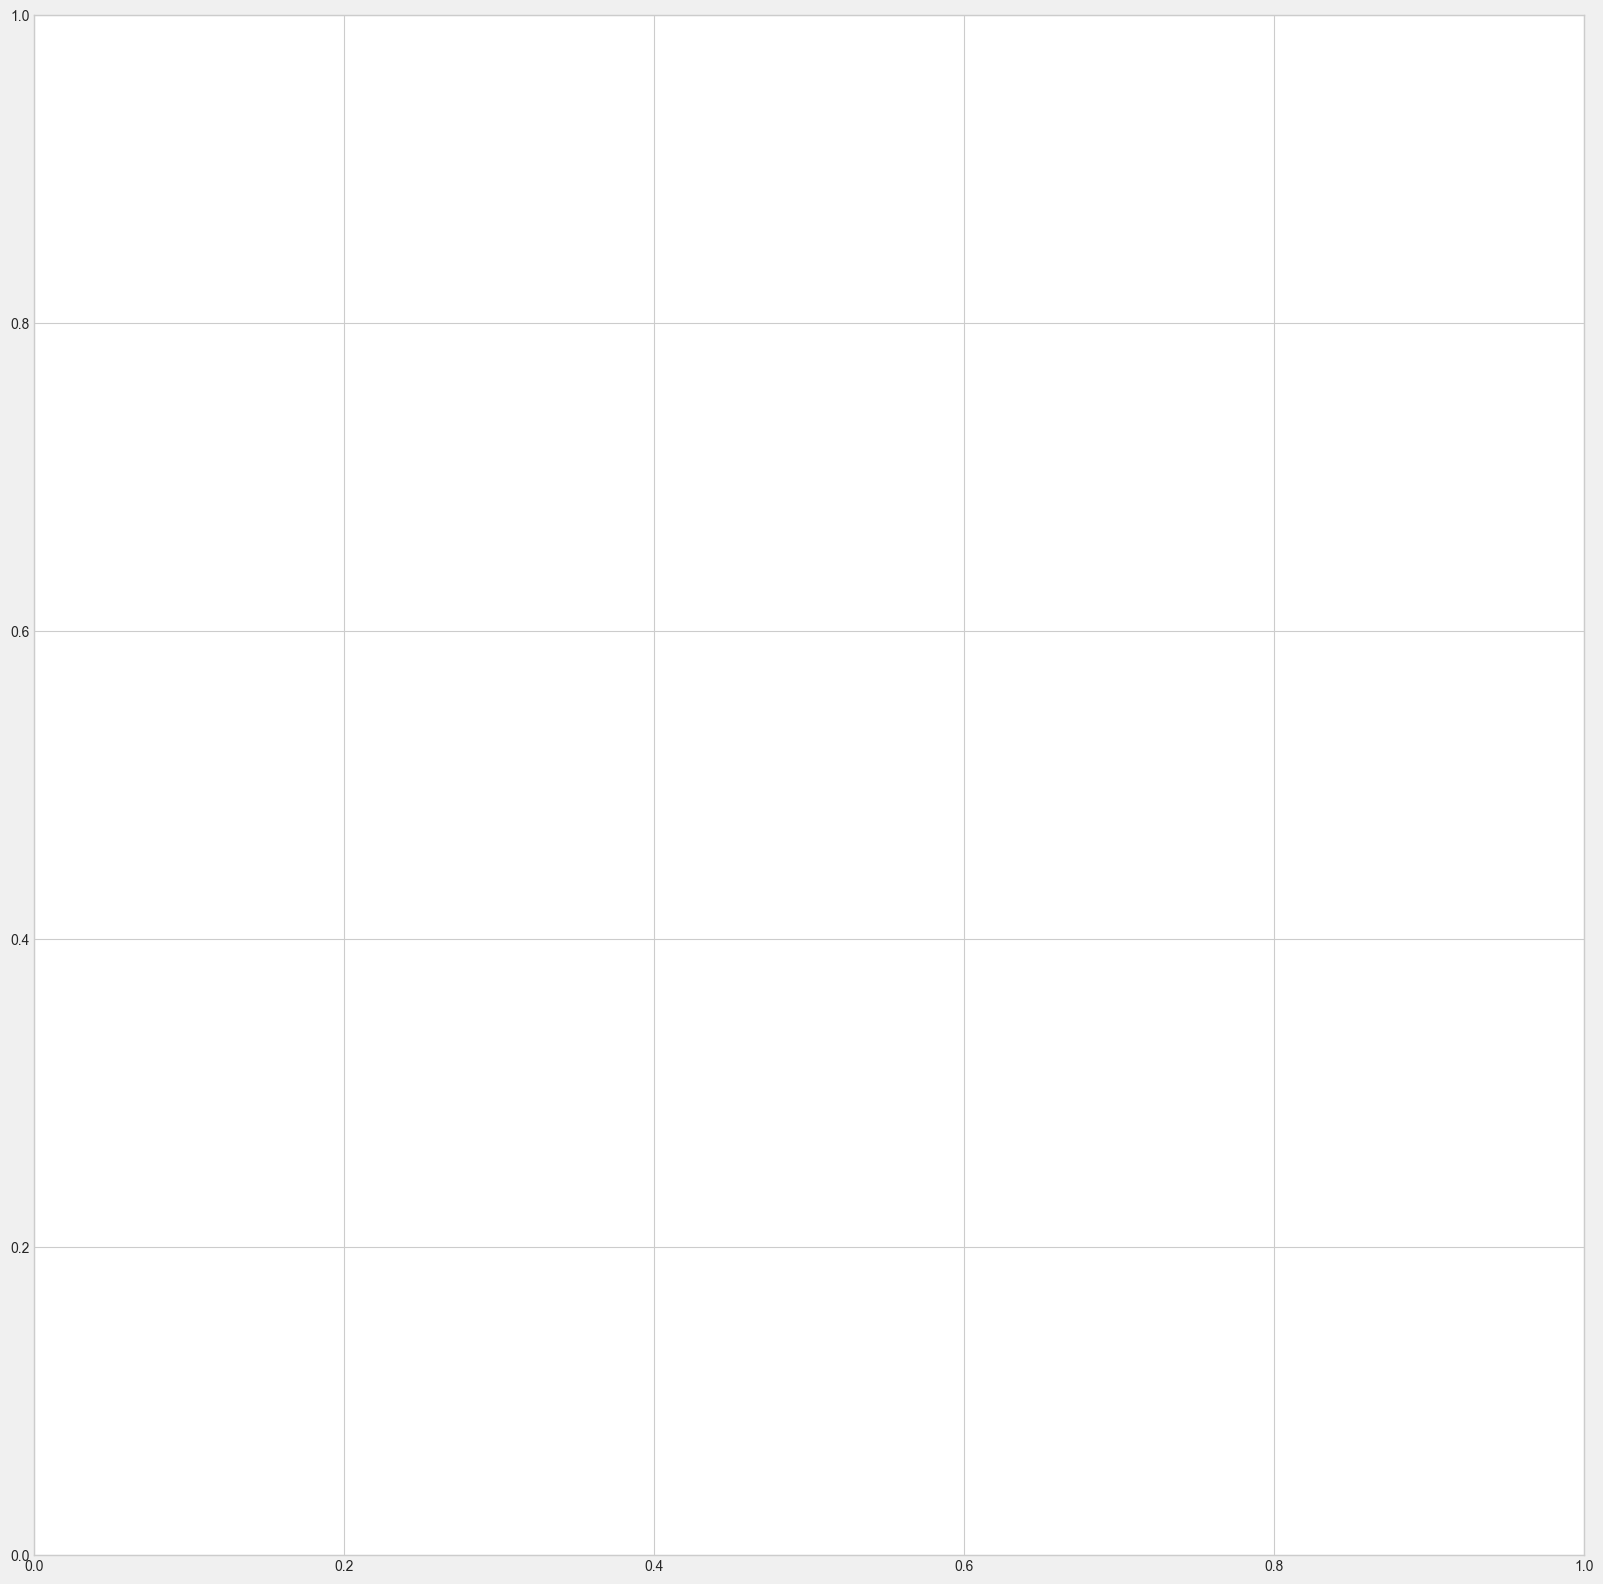

In [53]:
# Ensure you have these libraries installed:
# pip install pandas networkx sqlalchemy scipy matplotlib
import sqlite3
import pandas as pd
import numpy as np
import networkx as nx
import os
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt # New import for SVG drawing

# --- Configuration ---
# !!! UPDATE THIS PATH !!!
paper1_directory = "."  # Example: "/path/to/your/project/data"
DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
OUTPUT_DIR = "eb_wgc_corrs" # New directory for saving visualizations

INPUT_TABLE = "timetoevent_eb_wgc_compl"
CORRELATION_CUTOFF = 0.1

# Outcome variable naming parameters
OUTCOME_N_WL = 60
OUTCOME_K_WL_ACHIEVED = 10

# Dictionary for human-style variable naming
HUMAN_NAMES_DICT = {
    "womens_health_and_pregnancy": "Women's health & pregnancy (y/n)",
    "mental_health": "Mental health (y/n)",
    "family_issues": "Family issues (y/n)",
    "medication_disease_injury": "Medication, disease, or injury (y/n)",
    "physical_inactivity": "Physical inactivity (y/n)",
    "eating_habits": "Eating habits (y/n)",
    "schedule": "Schedule (y/n)",
    "smoking_cessation": "Smoking cessation (y/n)",
    "treatment_discontinuation_or_relapse": "Treatment discontinuation or relapse (y/n)",
    "pandemic": "Pandemic (y/n)",
    "lifestyle_circumstances": "Lifestyle, circumstances (y/n)",
    "none_of_above": "None of the above (y/n)",
    "hunger_yn": "Hunger (y/n)",
    "satiety_yn": "Satiety (y/n)",
    "emotional_eating_yn": "Emotional eating (y/n)",
    "emotional_eating_value_likert": "Emotional eating score (1-10)",
    "quantity_control_likert": "Quantity control score (1-10)",
    "impulse_control_likert": "Impulse control score (1-10)",
}
# --- End Configuration ---


def load_data(db_path, table_name):
    """Loads data from an SQLite table into a pandas DataFrame."""
    print(f"Loading data from table '{table_name}' in '{db_path}'...")
    if not os.path.exists(db_path):
        print(f"Error: Database file not found at '{db_path}'.")
        return pd.DataFrame()
    try:
        with sqlite3.connect(db_path) as conn:
            df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        print(f"Successfully loaded {df.shape[0]} rows and {df.shape[1]} columns.")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return pd.DataFrame()


def identify_variables(df, outcome_n_wl, outcome_k_wl_achieved, input_table_name):
    """Identifies and categorizes variables for correlation analysis."""
    print("Identifying variables...")
    variable_categories = {}
    correlation_vars = set()

    # 1. Eating behavior variables
    eating_behavior_vars = [
        'hunger_yn', 'satiety_yn', 'emotional_eating_yn',
        'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
    ]
    for var in eating_behavior_vars:
        if var in df.columns:
            variable_categories[var] = "eating_behavior"
            correlation_vars.add(var)

    # 2. Outcome variables (for categorization only, not correlation)
    outcome_vars = [f"wl_{outcome_n_wl}d_%", f"{outcome_k_wl_achieved}%_wl_achieved"]
    for var in outcome_vars:
        if var in df.columns:
            variable_categories[var] = "outcome"

    # 3. Weight Gain Cause (WGC) variables (for correlation)
    if input_table_name == "timetoevent_eb_wgc_compl":
        print("Identifying Weight Gain Cause (WGC) variables...")
        # Use keys from the human-readable dictionary to define WGCs
        wgc_vars_from_dict = [
            "womens_health_and_pregnancy", "mental_health", "family_issues",
            "medication_disease_injury", "physical_inactivity", "eating_habits",
            "schedule", "smoking_cessation", "treatment_discontinuation_or_relapse",
            "pandemic", "lifestyle_circumstances"
        ]
        for var in wgc_vars_from_dict:
            if var in df.columns:
                variable_categories[var] = "weight_gain_cause"
                correlation_vars.add(var)

    final_correlation_vars = sorted(list(correlation_vars))
    print(f"Total unique variables for correlation: {len(final_correlation_vars)}")
    return variable_categories, final_correlation_vars


def preprocess_data(df, variables_list):
    """Preprocesses specified columns for correlation analysis."""
    print("Preprocessing data...")
    if not variables_list:
        return pd.DataFrame()

    df_processed = df[variables_list].copy()
    for col in df_processed.columns:
        if col.endswith('_yn'):
            if pd.api.types.is_string_dtype(df_processed[col]):
                map_dict = {'yes': 1, 'no': 0, 'y': 1, 'n': 0}
                df_processed[col] = df_processed[col].str.lower().map(map_dict)
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
        elif not pd.api.types.is_numeric_dtype(df_processed[col]):
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

    df_processed.dropna(axis=1, how='all', inplace=True)
    if len(df_processed.columns) < len(variables_list):
        dropped_cols = set(variables_list) - set(df_processed.columns)
        print(f"Warning: Dropped all-NaN columns: {list(dropped_cols)}")

    return df_processed


def calculate_spearman_correlations(df_processed):
    """Calculates the Spearman correlation matrix."""
    if df_processed.shape[1] < 2:
        print("Not enough columns to calculate correlations.")
        return pd.DataFrame()
    print("Calculating Spearman correlations...")
    return df_processed.corr(method='spearman')


# --- Step 2 & 3: New Matplotlib Drawing Function ---
def draw_and_save_matplotlib_network(G, pos, variable_categories, name_map, output_filepath):
    """Draws a networkx graph using matplotlib and saves it as a clean SVG."""
    print(f"Drawing network with Matplotlib and saving to '{output_filepath}'...")

    # Instruction 1: Set up the canvas
    fig, ax = plt.subplots(figsize=(20, 20)) # Increased size for better label spacing
    fig.set_facecolor('#f0f0f0') # Using original background color for consistency

    # Instruction 2: Define the visual styles
    category_colors = {
        "eating_behavior": 'blue',
        "weight_gain_cause": 'orange',
        "default": 'grey'
    }
    degree_map = dict(G.degree())

    # Prepare style lists in the same order as G.nodes() and G.edges()
    node_colors = [category_colors.get(variable_categories.get(n, "default"), category_colors["default"]) for n in G.nodes()]
    node_sizes = [500 + (degree_map.get(n, 0) * 250) for n in G.nodes()] # Scaled for matplotlib
    
    edge_colors = []
    edge_widths = []
    for u, v, data in G.edges(data=True):
        corr_value = data.get('correlation', 0)
        edge_colors.append("rgba(0, 128, 0, 0.6)" if corr_value > 0 else "rgba(255, 0, 0, 0.6)")
        edge_widths.append(0.5 + (data.get('weight', 0) * 5)) # Scaled for matplotlib

    # Instruction 3: Draw the network elements
    # Draw edges
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color=edge_colors,
        width=edge_widths,
        alpha=0.8,
        connectionstyle='arc3,rad=0.1' # Curved edges
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors='#2B2B2B',
        linewidths=1.5
    )

    # Draw labels
    labels = {node: name_map.get(node, node) for node in G.nodes()}
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        labels=labels,
        font_size=10,
        font_family='Tahoma',
        font_color='black'
    )

    # Instruction 4: Save the final SVG
    ax.margins(0.1) # Add some margin to prevent labels from being cut off
    plt.tight_layout()
    plt.savefig(output_filepath, format='svg', bbox_inches='tight', pad_inches=0.5)
    plt.close(fig) # Clean up the figure from memory
    print("SVG saved successfully.")


if __name__ == "__main__":
    print("--- Starting Correlation Analysis ---")
    
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    df_full = load_data(DB_PATH, INPUT_TABLE)

    if df_full.empty:
        print("Failed to load data. Exiting.")
    else:
        categories_map, corr_vars = identify_variables(
            df_full, OUTCOME_N_WL, OUTCOME_K_WL_ACHIEVED, INPUT_TABLE
        )

        if not corr_vars:
            print("No variables identified for correlation. Exiting.")
        else:
            df_processed = preprocess_data(df_full, corr_vars)

            if df_processed.shape[1] < 2:
                print("Insufficient data after preprocessing. Exiting.")
            else:
                correlation_matrix = calculate_spearman_correlations(df_processed)
                
                # --- Step 4: Refactored Main Block ---
                # 1. Create the networkx graph G
                print(f"Building correlation network with cutoff {CORRELATION_CUTOFF}...")
                G = nx.Graph()
                for i in range(len(correlation_matrix.columns)):
                    for j in range(i + 1, len(correlation_matrix.columns)):
                        var1, var2 = correlation_matrix.columns[i], correlation_matrix.columns[j]
                        corr = correlation_matrix.iloc[i, j]
                        if pd.notna(corr) and abs(corr) >= CORRELATION_CUTOFF:
                            G.add_edge(var1, var2, weight=abs(corr), correlation=corr)

                if not G.nodes:
                    print("No correlations above the cutoff. Cannot build network.")
                else:
                    # 2. Define shells and calculate optimal ordering
                    inner_shell = [n for n in G.nodes if categories_map.get(n) == 'eating_behavior']
                    outer_shell = [n for n in G.nodes if categories_map.get(n) != 'eating_behavior']

                    if len(outer_shell) > 2:
                        try:
                            subgraph = G.subgraph(outer_shell)
                            adj_matrix = nx.to_pandas_adjacency(subgraph, nodelist=outer_shell, weight='weight', nonedge=0.0)
                            distances = pdist(1 - adj_matrix.values)
                            linkage_matrix = linkage(distances, method='average')
                            ordered_indices = leaves_list(linkage_matrix)
                            outer_shell = [outer_shell[i] for i in ordered_indices]
                            print("Calculated optimal ordering for outer shell nodes.")
                        except Exception as e:
                            print(f"Warning: Optimal leaf ordering failed ('{e}'). Using default order.")

                    # 3. Calculate the position dictionary (pos)
                    pos = {}
                    if inner_shell: pos.update(nx.circular_layout(G.subgraph(inner_shell), scale=1.0)) # Matplotlib scale is different
                    if outer_shell: pos.update(nx.circular_layout(G.subgraph(outer_shell), scale=2.5))

                    # 4. Define the output filename for the SVG
                    svg_filename = f"corr_nw_EB_WGC_{INPUT_TABLE}_cutoff{str(CORRELATION_CUTOFF).replace('.', 'p')}.svg"
                    svg_filepath = os.path.join(OUTPUT_DIR, svg_filename)

                    # 5. Call the new drawing function
                    draw_and_save_matplotlib_network(
                        G, pos, categories_map, HUMAN_NAMES_DICT, svg_filepath
                    )

    print("--- Process Completed. ---")

#### kamada-kawai

In [10]:
# Ensure you have these libraries installed:
# pip install pandas pyvis networkx sqlalchemy

import sqlite3
import pandas as pd
import numpy as np
from pyvis.network import Network
import networkx as nx # For layout calculation and degree centrality
import os

# Define paper1_directory - !!! UPDATE THIS PATH !!!
paper1_directory = "." # Example: "/path/to/your/project/data"
# If paper1_directory is an environment variable, you might use:
# paper1_directory = os.getenv("PAPER1_DIRECTORY", ".")

DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')

# Configurable input table
INPUT_TABLE = "timetoevent_eb_wgc_compl" # Example: "your_table_name" or "timetoevent_eb_wgc_compl"

# Configurable parameters for outcome variables (used for naming, even if not correlated)
# For wl_Nd_%
OUTCOME_N_WL = 60 # Example: N=3 for wl_3d_%
# For K%_wl_achieved
OUTCOME_K_WL_ACHIEVED = 10 # Example: K=50 for 50%_wl_achieved

# Configurable correlation strength cutoff
CORRELATION_CUTOFF = 0.1

# --- 1. Load Data ---
def load_data(db_path, table_name):
    """Loads data from an SQLite table into a pandas DataFrame."""
    print(f"Loading data from table '{table_name}' in '{db_path}'...")
    if not os.path.exists(db_path):
        print(f"Error: Database file not found at '{db_path}'. Please check the path.")
        return pd.DataFrame()
    try:
        conn = sqlite3.connect(db_path)
        query = f"SELECT * FROM {table_name}"
        df = pd.read_sql_query(query, conn)
        conn.close()
        print(f"Successfully loaded {df.shape[0]} rows and {df.shape[1]} columns.")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return pd.DataFrame()

# --- 2. Identify Variables ---
def identify_variables(df, outcome_n_wl, outcome_k_wl_achieved, input_table_name):
    """
    Identifies variables for correlation analysis based on predefined categories
    and conditional logic for weight gain causes.
    Returns a dictionary mapping variable names to categories (for all identified types),
    and a flat list of variables selected FOR CORRELATION (eating behaviors and WGCs only).
    """
    print("Identifying variables...")
    variable_categories_map = {} # Stores all identified variables and their categories
    variables_for_correlation = [] # Stores only variables for correlation analysis

    # Eating behavior variables
    eating_behavior_vars = [
        'hunger_yn', 'satiety_yn', 'emotional_eating_yn',
        'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
    ]
    for var in eating_behavior_vars:
        if var in df.columns:
            variable_categories_map[var] = "eating_behavior"
            variables_for_correlation.append(var) # Add to correlation list
        else:
            print(f"Warning: Eating behavior variable '{var}' not found in DataFrame.")

    # Outcome variables (dynamically named)
    # These are identified and added to the category map, but NOT to variables_for_correlation
    outcome_var_wl_nd = f"wl_{outcome_n_wl}d_%"
    outcome_var_k_wl_achieved = f"{outcome_k_wl_achieved}%_wl_achieved"
    
    outcome_vars_list = [outcome_var_wl_nd, outcome_var_k_wl_achieved]
    for var in outcome_vars_list:
        if var in df.columns:
            variable_categories_map[var] = "outcome" # Add to category map only
        else:
            print(f"Warning: Outcome variable '{var}' (e.g., {outcome_var_wl_nd} or {outcome_var_k_wl_achieved}) not found in DataFrame.")

    # Conditionally add weight gain causes
    if input_table_name == "timetoevent_eb_wgc_compl":
        print("\nProcessing Weight Gain Cause (WGC) variables for 'timetoevent_eb_wgc_compl' table...")
        
        # --- Part 1: Manually defined WGCs ---
        manually_defined_wgc_vars = [
            "womens_health_and_pregnancy",
            "mental_health", 
            "family_issues", 
            "medication_disease_injury",
            "physical_inactivity", 
            "eating_habits", 
            "schedule", 
            "smoking_cessation",
            "treatment_discontinuation_or_relapse", 
            "pandemic", 
            "lifestyle_circumstances", 
            "none_of_above"
        ]
        
        manual_wgc_processed_count = 0 # Counts manual WGCs found in DataFrame
        manual_wgc_newly_added_count = 0 # Counts manual WGCs newly added to correlation list
        missing_manual_wgc = []

        print("Step 1: Processing manually defined WGC variables...")
        if not manually_defined_wgc_vars:
            print("No manually defined WGC variables to process.")
        else:
            for var in manually_defined_wgc_vars:
                if var == 'none_of_above':
                    continue  # SKIP 'none_of_above'
                if var in df.columns:
                    manual_wgc_processed_count += 1
                    variable_categories_map[var] = "weight_gain_cause"
                    if var not in variables_for_correlation:
                        variables_for_correlation.append(var)
                        manual_wgc_newly_added_count += 1
                else:
                    missing_manual_wgc.append(var)
            
            print(f"Processed {len(manually_defined_wgc_vars)} WGCs from the manual list.")
            print(f"- {manual_wgc_processed_count} were found in the DataFrame.")
            print(f"- {manual_wgc_newly_added_count} were newly added to the correlation set from this manual list.")
            if missing_manual_wgc:
                print(f"Warning: The following manually defined WGCs were NOT found in DataFrame: {', '.join(missing_manual_wgc)}")

        # --- Part 2: Automatically identify WGCs by column range ---
        print("\nStep 2: Attempting to automatically identify WGC variables by column range...")
        cols = list(df.columns)
        start_marker = 'weight_gain_cause_en' # Configurable, if needed
        end_marker = 'genomics_sample_id'     # Configurable, if needed
        
        auto_wgc_newly_added_count = 0
        
        try:
            if start_marker not in cols:
                print(f"Warning: Start marker '{start_marker}' for automatic WGC identification not found. Skipping automatic range detection.")
            elif end_marker not in cols:
                print(f"Warning: End marker '{end_marker}' for automatic WGC identification not found. Skipping automatic range detection.")
            else:
                start_index = cols.index(start_marker) + 1
                end_index = cols.index(end_marker)
            
                if start_index < end_index:
                    wgc_from_range = cols[start_index:end_index]
                    print(f"Found {len(wgc_from_range)} potential WGCs in the column range between '{start_marker}' (exclusive) and '{end_marker}' (exclusive).")
                    
                    for var in wgc_from_range:
                        if var == 'none_of_above':
                            continue  # SKIP 'none_of_above'
                        # var is guaranteed to be in df.columns
                        variable_categories_map[var] = "weight_gain_cause" # Set/confirm category
                        if var not in variables_for_correlation:
                            variables_for_correlation.append(var)
                            auto_wgc_newly_added_count += 1
                    
                    print(f"Newly added {auto_wgc_newly_added_count} WGCs from this automatic range detection to the correlation set.")
                    if auto_wgc_newly_added_count < len(wgc_from_range):
                        num_already_present = len(wgc_from_range) - auto_wgc_newly_added_count
                        print(f"{num_already_present} WGCs from this range were already in the correlation set (e.g., from manual list or other categories).")
                elif start_index == end_index:
                    print(f"Warning: Start marker '{start_marker}' and end marker '{end_marker}' are adjacent (or the same after +1 adjustment to start_index). No columns in between for automatic WGC identification.")
                else: # start_index > end_index
                    print(f"Warning: Start marker '{start_marker}' (index {cols.index(start_marker)}) appears after end marker '{end_marker}' (index {cols.index(end_marker)}). Invalid range for automatic WGC identification.")
        
        except ValueError: 
            print(f"Error: Could not determine indices for marker columns ('{start_marker}', '{end_marker}'). Automatic WGC identification by range failed.")
        except Exception as e:
            print(f"An unexpected error occurred during automatic WGC identification by range: {e}")

    # Remove duplicates from the correlation list and sort
    variables_for_correlation = sorted(list(set(variables_for_correlation)))
    # Remove 'none_of_above' if present (extra safeguard)
    variables_for_correlation = [v for v in variables_for_correlation if v != 'none_of_above']
    print(f"\nTotal unique variables selected for CORRELATION analysis: {len(variables_for_correlation)}")
    return variable_categories_map, variables_for_correlation

# --- 3. Preprocess Data ---
def preprocess_data(df, variables_list):
    """
    Preprocesses the DataFrame for selected variables:
    - Converts '_yn' columns to numeric (1/0).
    - Ensures other columns are numeric.
    """
    print("Preprocessing data...")
    if not variables_list:
        print("No variables selected for preprocessing.")
        return pd.DataFrame()
            
    df_processed = df[variables_list].copy()

    for col in df_processed.columns:
        if col.endswith('_yn'):
            if df_processed[col].dtype == 'object':
                df_processed[col] = df_processed[col].str.lower().str.strip()
                map_dict = {'yes': 1, 'no': 0, 'y': 1, 'n': 0, 'true': 1, 'false': 0, '1':1, '0':0, 1:1, 0:0}
                df_processed[col] = df_processed[col].map(map_dict)
            elif pd.api.types.is_bool_dtype(df_processed[col]):
                 df_processed[col] = df_processed[col].astype(int)
        
        # Attempt to convert to numeric if not already, coercing errors
        if not pd.api.types.is_numeric_dtype(df_processed[col]):
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
            
    all_nan_cols = df_processed.columns[df_processed.isnull().all()].tolist()
    if all_nan_cols:
        print(f"Warning: The following columns are entirely NaN after preprocessing and will be dropped: {all_nan_cols}")
        df_processed = df_processed.drop(columns=all_nan_cols)

    return df_processed

# --- 4. Calculate Spearman Correlations ---
def calculate_spearman_correlations(df_processed):
    """Calculates the Spearman correlation matrix."""
    print("Calculating Spearman correlations...")
    if df_processed.empty or df_processed.shape[1] < 2:
        print("Not enough data or columns to calculate correlations.")
        return pd.DataFrame()
    
    correlation_matrix = df_processed.corr(method='spearman')
    print("Correlation matrix calculated.")
    return correlation_matrix

# --- 5. Build Correlation Network (MODIFIED) ---
def build_correlation_network(correlation_matrix, variable_categories, cutoff):
    """Builds an interactive Pyvis network from the correlation matrix using a Kamada-Kawai layout."""
    print(f"Building correlation network with cutoff {cutoff}...")
    
    if correlation_matrix.empty:
        print("Correlation matrix is empty. Cannot build network.")
        return None

    # MODIFICATION 1: Refine Canvas - Set background color and remove black frame feel
    net = Network(notebook=True, height="800px", width="100%", bgcolor="#f0f0f0", font_color="black", cdn_resources='remote', directed=False)
    
    # MODIFICATION 2: Enhance Nodes - Define a professional color palette
    category_colors = {
        "eating_behavior": "#008080",  # Deep Teal
        "weight_gain_cause": "#FFC107", # Amber/Orange
        "default": "#808080"          # Grey
    }

    # --- Create a NetworkX graph to calculate layout and degree ---
    G = nx.Graph()
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]

            if pd.notna(corr_value) and abs(corr_value) >= cutoff:
                # Add nodes and edge to the NetworkX graph
                G.add_edge(var1, var2, weight=abs(corr_value))

    # MODIFICATION 3: Use a Smarter Layout - Calculate Kamada-Kawai positions
    # This layout algorithm treats the network like a spring system for aesthetic positioning.
    print("Calculating Kamada-Kawai layout... (this may take a moment for large networks)")
    try:
        pos = nx.kamada_kawai_layout(G, scale=1000) # Scale for a larger canvas
        print("Layout calculated successfully.")
    except nx.NetworkXError as e:
        print(f"Warning: Kamada-Kawai layout failed ('{e}'). Falling back to a spring layout.")
        pos = nx.spring_layout(G, scale=1000, iterations=100)


    # --- Add nodes to the Pyvis network with calculated positions and styles ---
    degree_map = dict(G.degree())
    min_node_size = 10
    node_size_scale_factor = 7

    for node in G.nodes():
        category = variable_categories.get(node, "default")
        color = category_colors.get(category, category_colors["default"])
        degree = degree_map.get(node, 0)
        
        # MODIFICATION 4: Size Nodes by Importance
        node_size = min_node_size + (degree * node_size_scale_factor)
        
        title_text = f"<b>{node}</b><br>Category: {category.replace('_', ' ').title()}<br>Degree: {degree}"
        
        # Get pre-calculated position
        node_pos = pos.get(node, (0, 0))

        # MODIFICATION 5: Enhance Nodes - Add a dark border for visual pop
        net.add_node(
            node,
            label=node,
            title=title_text,
            color=color,
            size=node_size,
            borderWidth=2,
            borderColor="#2B2B2B",
            x=node_pos[0],
            y=node_pos[1],
            physics=False  # IMPORTANT: Disable physics for this node to keep its position
        )

    # --- Add edges to the Pyvis network with new styles ---
    min_edge_width = 0.5
    edge_width_scale_factor = 8

    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]

            if pd.notna(corr_value) and abs(corr_value) >= cutoff:
                # MODIFICATION 6: Color-Code Relationships
                edge_color_rgba = "rgba(0, 128, 0, 0.6)" if corr_value > 0 else "rgba(255, 0, 0, 0.6)" # Green/Red with transparency
                
                # MODIFICATION 7: Vary Line Thickness
                edge_width = min_edge_width + (abs(corr_value) * edge_width_scale_factor)
                
                net.add_edge(
                    var1,
                    var2,
                    value=abs(corr_value),
                    width=edge_width,
                    color=edge_color_rgba,
                    title=f"Correlation: {corr_value:.3f}"
                )
    
    # MODIFICATION 8: Style Connections - Use curved edges and disable physics
    net.set_options("""
    var options = {
      "nodes": {
        "font": {
          "size": 14,
          "face": "Tahoma"
        }
      },
      "edges": {
        "smooth": {
          "type": "curvedCW",
          "forceDirection": "none",
          "roundness": 0.15
        },
        "color": {
          "highlight": "#848484",
          "hover": "#848484"
        }
      },
      "interaction": {
        "hover": true,
        "tooltipDelay": 200,
        "hideEdgesOnDrag": true,
        "navigationButtons": true,
        "zoomView": true
      },
      "physics": {
        "enabled": false
      }
    }
    """)
    print("Network built with new visual enhancements.")
    return net

# --- Main Execution ---
if __name__ == "__main__":
    print("--- Starting Correlation Network Generation (Eating Behaviors & Weight Gain Causes ONLY) ---")

    # 1. Load data
    df_full = load_data(DB_PATH, INPUT_TABLE)

    if not df_full.empty:
        # 2. Identify variables
        comprehensive_variable_categories_map, selected_vars_for_correlation = identify_variables(
            df_full, 
            OUTCOME_N_WL, 
            OUTCOME_K_WL_ACHIEVED, 
            INPUT_TABLE
        )

        if not selected_vars_for_correlation:
            print("No eating behavior or weight gain cause variables were identified for correlation. Exiting.")
        else:
            # 3. Preprocess data (only on selected_vars_for_correlation: EB and WGC)
            df_processed = preprocess_data(df_full, selected_vars_for_correlation)
            
            # Update list of variables for correlation if any were dropped (e.g., all NaN columns)
            final_vars_in_corr_matrix = [var for var in selected_vars_for_correlation if var in df_processed.columns]
            
            # Filter the comprehensive category map to only include variables actually in the correlation matrix
            categories_for_network_nodes = {
                k: v for k, v in comprehensive_variable_categories_map.items() 
                if k in final_vars_in_corr_matrix
            }

            if df_processed.empty or df_processed.shape[1] < 2:
                print("Preprocessing resulted in insufficient data (or <2 columns) for correlation. Exiting.")
            elif not final_vars_in_corr_matrix or len(final_vars_in_corr_matrix) < 2 :
                 print("After preprocessing, less than 2 variables remain for correlation. Exiting.")
            else:
                # 4. Calculate correlations (only on final_vars_in_corr_matrix: EB and WGC)
                correlation_matrix = calculate_spearman_correlations(df_processed[final_vars_in_corr_matrix])

                if not correlation_matrix.empty:
                    # 5. Build network
                    network_graph = build_correlation_network(
                        correlation_matrix, 
                        categories_for_network_nodes, # Pass the filtered map for relevant nodes
                        CORRELATION_CUTOFF
                    )

                    if network_graph:
                        # 6. Show network (without saving to a file)
                        output_filename = f"corr_nw_EB_WGC_{INPUT_TABLE}_cutoff{str(CORRELATION_CUTOFF).replace('.', 'p')}.html"
                        print(f"Displaying network in browser (not saving to '{output_filename}')...")
                        
                        # This will generate and open the HTML file in a temporary location
                        network_graph.show(output_filename, notebook=False)
                        
                        print(f"--- Process Completed. ---")
                    else:
                        print("Failed to build the network graph.")
                else:
                    print("Correlation matrix is empty. Cannot proceed to network building.")
    else:
        print(f"Failed to load data from {INPUT_TABLE}. Exiting.")

--- Starting Correlation Network Generation (Eating Behaviors & Weight Gain Causes ONLY) ---
Loading data from table 'timetoevent_eb_wgc_compl' in '.\pnk_db2_p1_in.sqlite'...
Successfully loaded 308 rows and 93 columns.
Identifying variables...

Processing Weight Gain Cause (WGC) variables for 'timetoevent_eb_wgc_compl' table...
Step 1: Processing manually defined WGC variables...
Processed 12 WGCs from the manual list.
- 11 were found in the DataFrame.
- 11 were newly added to the correlation set from this manual list.

Step 2: Attempting to automatically identify WGC variables by column range...

Total unique variables selected for CORRELATION analysis: 17
Preprocessing data...
Calculating Spearman correlations...
Correlation matrix calculated.
Building correlation network with cutoff 0.1...
Calculating Kamada-Kawai layout... (this may take a moment for large networks)
Layout calculated successfully.
Network built with new visual enhancements.
Displaying network in browser (not savin

#### original

In [11]:
# Ensure you have these libraries installed:
# pip install pandas pyvis networkx sqlalchemy

import sqlite3
import pandas as pd
import numpy as np
from pyvis.network import Network
import networkx as nx # For degree centrality calculation
import os # Added import

# Define paper1_directory - !!! UPDATE THIS PATH !!!
paper1_directory = "." # Example: "/path/to/your/project/data"
# If paper1_directory is an environment variable, you might use:
# paper1_directory = os.getenv("PAPER1_DIRECTORY", ".")

DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')

# Configurable input table
INPUT_TABLE = "timetoevent_eb_wgc_compl" # Example: "your_table_name" or "timetoevent_eb_wgc_compl"

# Configurable parameters for outcome variables (used for naming, even if not correlated)
# For wl_Nd_%
OUTCOME_N_WL = 60 # Example: N=3 for wl_3d_%
# For K%_wl_achieved
OUTCOME_K_WL_ACHIEVED = 10 # Example: K=50 for 50%_wl_achieved

# Configurable correlation strength cutoff
CORRELATION_CUTOFF = 0.13

# --- 1. Load Data ---
def load_data(db_path, table_name):
    """Loads data from an SQLite table into a pandas DataFrame."""
    print(f"Loading data from table '{table_name}' in '{db_path}'...")
    if not os.path.exists(db_path):
        print(f"Error: Database file not found at '{db_path}'. Please check the path.")
        return pd.DataFrame()
    try:
        conn = sqlite3.connect(db_path)
        query = f"SELECT * FROM {table_name}"
        df = pd.read_sql_query(query, conn)
        conn.close()
        print(f"Successfully loaded {df.shape[0]} rows and {df.shape[1]} columns.")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return pd.DataFrame()

# --- 2. Identify Variables ---
def identify_variables(df, outcome_n_wl, outcome_k_wl_achieved, input_table_name):
    """
    Identifies variables for correlation analysis based on predefined categories
    and conditional logic for weight gain causes.
    Returns a dictionary mapping variable names to categories (for all identified types),
    and a flat list of variables selected FOR CORRELATION (eating behaviors and WGCs only).
    """
    print("Identifying variables...")
    variable_categories_map = {} # Stores all identified variables and their categories
    variables_for_correlation = [] # Stores only variables for correlation analysis

    # Eating behavior variables
    eating_behavior_vars = [
        'hunger_yn', 'satiety_yn', 'emotional_eating_yn',
        'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
    ]
    for var in eating_behavior_vars:
        if var in df.columns:
            variable_categories_map[var] = "eating_behavior"
            variables_for_correlation.append(var) # Add to correlation list
        else:
            print(f"Warning: Eating behavior variable '{var}' not found in DataFrame.")

    # Outcome variables (dynamically named)
    # These are identified and added to the category map, but NOT to variables_for_correlation
    outcome_var_wl_nd = f"wl_{outcome_n_wl}d_%"
    outcome_var_k_wl_achieved = f"{outcome_k_wl_achieved}%_wl_achieved"
    
    outcome_vars_list = [outcome_var_wl_nd, outcome_var_k_wl_achieved]
    for var in outcome_vars_list:
        if var in df.columns:
            variable_categories_map[var] = "outcome" # Add to category map only
        else:
            print(f"Warning: Outcome variable '{var}' (e.g., {outcome_var_wl_nd} or {outcome_var_k_wl_achieved}) not found in DataFrame.")

    # Conditionally add weight gain causes
    if input_table_name == "timetoevent_eb_wgc_compl":
        print("\nProcessing Weight Gain Cause (WGC) variables for 'timetoevent_eb_wgc_compl' table...")
        
        # --- Part 1: Manually defined WGCs ---
        manually_defined_wgc_vars = [
            "womens_health_and_pregnancy",
            "mental_health", 
            "family_issues", 
            "medication_disease_injury",
            "physical_inactivity", 
            "eating_habits", 
            "schedule", 
            "smoking_cessation",
            "treatment_discontinuation_or_relapse", 
            "pandemic", 
            "lifestyle_circumstances", 
            "none_of_above"
        ]
        
        manual_wgc_processed_count = 0 # Counts manual WGCs found in DataFrame
        manual_wgc_newly_added_count = 0 # Counts manual WGCs newly added to correlation list
        missing_manual_wgc = []

        print("Step 1: Processing manually defined WGC variables...")
        if not manually_defined_wgc_vars:
            print("No manually defined WGC variables to process.")
        else:
            for var in manually_defined_wgc_vars:
                if var == 'none_of_above':
                    continue  # SKIP 'none_of_above'
                if var in df.columns:
                    manual_wgc_processed_count += 1
                    variable_categories_map[var] = "weight_gain_cause"
                    if var not in variables_for_correlation:
                        variables_for_correlation.append(var)
                        manual_wgc_newly_added_count += 1
                else:
                    missing_manual_wgc.append(var)
            
            print(f"Processed {len(manually_defined_wgc_vars)} WGCs from the manual list.")
            print(f"- {manual_wgc_processed_count} were found in the DataFrame.")
            print(f"- {manual_wgc_newly_added_count} were newly added to the correlation set from this manual list.")
            if missing_manual_wgc:
                print(f"Warning: The following manually defined WGCs were NOT found in DataFrame: {', '.join(missing_manual_wgc)}")

        # --- Part 2: Automatically identify WGCs by column range ---
        print("\nStep 2: Attempting to automatically identify WGC variables by column range...")
        cols = list(df.columns)
        start_marker = 'weight_gain_cause_en' # Configurable, if needed
        end_marker = 'genomics_sample_id'     # Configurable, if needed
        
        auto_wgc_newly_added_count = 0
        
        try:
            if start_marker not in cols:
                print(f"Warning: Start marker '{start_marker}' for automatic WGC identification not found. Skipping automatic range detection.")
            elif end_marker not in cols:
                print(f"Warning: End marker '{end_marker}' for automatic WGC identification not found. Skipping automatic range detection.")
            else:
                start_index = cols.index(start_marker) + 1
                end_index = cols.index(end_marker)
            
                if start_index < end_index:
                    wgc_from_range = cols[start_index:end_index]
                    print(f"Found {len(wgc_from_range)} potential WGCs in the column range between '{start_marker}' (exclusive) and '{end_marker}' (exclusive).")
                    
                    for var in wgc_from_range:
                        if var == 'none_of_above':
                            continue  # SKIP 'none_of_above'
                        # var is guaranteed to be in df.columns
                        variable_categories_map[var] = "weight_gain_cause" # Set/confirm category
                        if var not in variables_for_correlation:
                            variables_for_correlation.append(var)
                            auto_wgc_newly_added_count += 1
                    
                    print(f"Newly added {auto_wgc_newly_added_count} WGCs from this automatic range detection to the correlation set.")
                    if auto_wgc_newly_added_count < len(wgc_from_range):
                        num_already_present = len(wgc_from_range) - auto_wgc_newly_added_count
                        print(f"{num_already_present} WGCs from this range were already in the correlation set (e.g., from manual list or other categories).")
                elif start_index == end_index:
                    print(f"Warning: Start marker '{start_marker}' and end marker '{end_marker}' are adjacent (or the same after +1 adjustment to start_index). No columns in between for automatic WGC identification.")
                else: # start_index > end_index
                    print(f"Warning: Start marker '{start_marker}' (index {cols.index(start_marker)}) appears after end marker '{end_marker}' (index {cols.index(end_marker)}). Invalid range for automatic WGC identification.")
        
        except ValueError: 
            print(f"Error: Could not determine indices for marker columns ('{start_marker}', '{end_marker}'). Automatic WGC identification by range failed.")
        except Exception as e:
            print(f"An unexpected error occurred during automatic WGC identification by range: {e}")

    # Remove duplicates from the correlation list and sort
    variables_for_correlation = sorted(list(set(variables_for_correlation)))
    # Remove 'none_of_above' if present (extra safeguard)
    variables_for_correlation = [v for v in variables_for_correlation if v != 'none_of_above']
    print(f"\nTotal unique variables selected for CORRELATION analysis: {len(variables_for_correlation)}")
    return variable_categories_map, variables_for_correlation

# --- 3. Preprocess Data ---
def preprocess_data(df, variables_list):
    """
    Preprocesses the DataFrame for selected variables:
    - Converts '_yn' columns to numeric (1/0).
    - Ensures other columns are numeric.
    """
    print("Preprocessing data...")
    if not variables_list:
        print("No variables selected for preprocessing.")
        return pd.DataFrame()
            
    df_processed = df[variables_list].copy()

    for col in df_processed.columns:
        if col.endswith('_yn'):
            if df_processed[col].dtype == 'object':
                df_processed[col] = df_processed[col].str.lower().str.strip()
                map_dict = {'yes': 1, 'no': 0, 'y': 1, 'n': 0, 'true': 1, 'false': 0, '1':1, '0':0, 1:1, 0:0}
                df_processed[col] = df_processed[col].map(map_dict)
            elif pd.api.types.is_bool_dtype(df_processed[col]):
                 df_processed[col] = df_processed[col].astype(int)
        
        # Attempt to convert to numeric if not already, coercing errors
        if not pd.api.types.is_numeric_dtype(df_processed[col]):
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
            
    all_nan_cols = df_processed.columns[df_processed.isnull().all()].tolist()
    if all_nan_cols:
        print(f"Warning: The following columns are entirely NaN after preprocessing and will be dropped: {all_nan_cols}")
        df_processed = df_processed.drop(columns=all_nan_cols)

    return df_processed

# --- 4. Calculate Spearman Correlations ---
def calculate_spearman_correlations(df_processed):
    """Calculates the Spearman correlation matrix."""
    print("Calculating Spearman correlations...")
    if df_processed.empty or df_processed.shape[1] < 2:
        print("Not enough data or columns to calculate correlations.")
        return pd.DataFrame()
    
    correlation_matrix = df_processed.corr(method='spearman')
    print("Correlation matrix calculated.")
    return correlation_matrix

# --- 5. Build Correlation Network ---
def build_correlation_network(correlation_matrix, variable_categories, cutoff):
    """Builds an interactive Pyvis network from the correlation matrix."""
    print(f"Building correlation network with cutoff {cutoff}...")
    
    if correlation_matrix.empty:
        print("Correlation matrix is empty. Cannot build network.")
        return None

    net = Network(notebook=True, height="750px", width="100%", cdn_resources='remote', directed=False)
    
    category_colors = {
        "eating_behavior": "blue",
        # "outcome": "yellow", # Kept for completeness, though outcomes won't be in this network
        "weight_gain_cause": "orange",
        "default": "grey"
    }

    nodes_in_network = set()
    edges_for_centrality = []

    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]

            if pd.isna(corr_value): continue

            if abs(corr_value) >= cutoff:
                nodes_in_network.add(var1)
                nodes_in_network.add(var2)
                edges_for_centrality.append((var1, var2))

    temp_nx_graph = nx.Graph()
    all_vars_in_matrix = correlation_matrix.columns.tolist()
    temp_nx_graph.add_nodes_from(all_vars_in_matrix) # Add all nodes for degree calculation, even if isolated after cutoff
    temp_nx_graph.add_edges_from(edges_for_centrality) # Add only edges that meet cutoff
    degree_map = {node: deg for node, deg in temp_nx_graph.degree()}

    min_node_size = 10
    node_size_scale_factor = 5 

    for var_name in all_vars_in_matrix: # Iterate through all variables that were in the correlation matrix
        category = variable_categories.get(var_name, "default")
        color = category_colors.get(category, category_colors["default"])
        degree = degree_map.get(var_name, 0) 
        node_size = min_node_size + (degree * node_size_scale_factor)
        title_text = f"{var_name}\nCategory: {category}\nDegree: {degree}"
        net.add_node(var_name, label=var_name, title=title_text, color=color, size=node_size)

    min_edge_width = 1
    edge_width_scale_factor = 5

    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]

            if pd.isna(corr_value): continue

            if abs(corr_value) >= cutoff:
                edge_color = "green" if corr_value > 0 else "red"
                edge_width = min_edge_width + (abs(corr_value) * edge_width_scale_factor)
                net.add_edge(var1, var2, value=abs(corr_value), width=edge_width, color=edge_color, title=f"Corr: {corr_value:.2f}")
    
    # --- Node spacing: springLength increased by 30% (from 100 to 130) ---
    net.set_options("""
    var options = {
      "nodes": {"font": {"size": 12}},
      "edges": {"smooth": {"type": "continuous", "forceDirection": "none", "roundness": 0.5}},
      "physics": {
        "forceAtlas2Based": {
            "gravitationalConstant": -50, 
            "centralGravity": 0.01, 
            "springLength": 180,
            "springConstant": 0.08, 
            "damping": 0.4, 
            "avoidOverlap": 0.5
        },
        "minVelocity": 0.75, "solver": "forceAtlas2Based",
        "stabilization": {"enabled": true, "iterations": 1000, "updateInterval": 25}
      },
      "interaction": {"hover": true, "tooltipDelay": 200, "hideEdgesOnDrag": true}
    }
    """)
    print("Network built.")
    return net

# --- Main Execution ---
if __name__ == "__main__":
    print("--- Starting Correlation Network Generation (Eating Behaviors & Weight Gain Causes ONLY) ---")

    # 1. Load data
    df_full = load_data(DB_PATH, INPUT_TABLE)

    if not df_full.empty:
        # 2. Identify variables
        comprehensive_variable_categories_map, selected_vars_for_correlation = identify_variables(
            df_full, 
            OUTCOME_N_WL, 
            OUTCOME_K_WL_ACHIEVED, 
            INPUT_TABLE
        )

        if not selected_vars_for_correlation:
            print("No eating behavior or weight gain cause variables were identified for correlation. Exiting.")
        else:
            # 3. Preprocess data (only on selected_vars_for_correlation: EB and WGC)
            df_processed = preprocess_data(df_full, selected_vars_for_correlation)
            
            # Update list of variables for correlation if any were dropped (e.g., all NaN columns)
            final_vars_in_corr_matrix = [var for var in selected_vars_for_correlation if var in df_processed.columns]
            
            # Filter the comprehensive category map to only include variables actually in the correlation matrix
            categories_for_network_nodes = {
                k: v for k, v in comprehensive_variable_categories_map.items() 
                if k in final_vars_in_corr_matrix
            }

            if df_processed.empty or df_processed.shape[1] < 2:
                print("Preprocessing resulted in insufficient data (or <2 columns) for correlation. Exiting.")
            elif not final_vars_in_corr_matrix or len(final_vars_in_corr_matrix) < 2 :
                 print("After preprocessing, less than 2 variables remain for correlation. Exiting.")
            else:
                # 4. Calculate correlations (only on final_vars_in_corr_matrix: EB and WGC)
                correlation_matrix = calculate_spearman_correlations(df_processed[final_vars_in_corr_matrix])

                if not correlation_matrix.empty:
                    # 5. Build network
                    network_graph = build_correlation_network(
                        correlation_matrix, 
                        categories_for_network_nodes, # Pass the filtered map for relevant nodes
                        CORRELATION_CUTOFF
                    )

                    if network_graph:
                        # 6. Show network
                        output_filename = f"corr_nw_EB_WGC_{INPUT_TABLE}_cutoff{str(CORRELATION_CUTOFF).replace('.', 'p')}.html"
                        print(f"Displaying and saving network to '{output_filename}'...")
                        network_graph.show(output_filename, notebook=True) # notebook=True for inline display if in Jupyter
                        print(f"--- Process Completed. Network saved to {output_filename} ---")
                    else:
                        print("Failed to build the network graph.")
                else:
                    print("Correlation matrix is empty. Cannot proceed to network building.")
    else:
        print(f"Failed to load data from {INPUT_TABLE}. Exiting.")

--- Starting Correlation Network Generation (Eating Behaviors & Weight Gain Causes ONLY) ---
Loading data from table 'timetoevent_eb_wgc_compl' in '.\pnk_db2_p1_in.sqlite'...
Successfully loaded 308 rows and 93 columns.
Identifying variables...

Processing Weight Gain Cause (WGC) variables for 'timetoevent_eb_wgc_compl' table...
Step 1: Processing manually defined WGC variables...
Processed 12 WGCs from the manual list.
- 11 were found in the DataFrame.
- 11 were newly added to the correlation set from this manual list.

Step 2: Attempting to automatically identify WGC variables by column range...

Total unique variables selected for CORRELATION analysis: 17
Preprocessing data...
Calculating Spearman correlations...
Correlation matrix calculated.
Building correlation network with cutoff 0.13...
Network built.
Displaying and saving network to 'corr_nw_EB_WGC_timetoevent_eb_wgc_compl_cutoff0p13.html'...
corr_nw_EB_WGC_timetoevent_eb_wgc_compl_cutoff0p13.html
--- Process Completed. Networ

# SEP

## Correlations

### Comparison of EB vs whole, WGC vs whole

#### WGC vs Whole

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
import warnings

# --- 1. CONFIGURATION ---

# --- Input ---
INPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite") # Contains sa_input_table
INPUT_TABLE = "timetoevent_ebcompl"                                           # Outcome variables and some predictors

# --- Output ---
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")
OUTPUT_TABLE = "wgc_comp_corr_on_ebcompl"

# --- Analysis Parameters ---
WEIGHT_GAIN_CAUSE_COLUMNS = [
    'womens_health_and_pregnancy', 'mental_health', 'family_issues',
    'medication_disease_injury', 'physical_inactivity', 'eating_habits',
    'schedule', 'smoking_cessation', 'post_treatment_weight_regain',
    'pandemic', 'habits_and_circumstances', 'none_of_above',
]

# Time windows and weight loss targets for dynamic row generation
# These should match how timetoevent_table was constructed
TIME_WINDOWS_DAYS = [40, 60, 80]    # days
WEIGHT_LOSS_TARGETS_PCT = [5, 10, 15] # % thresholds

# --- Row Configuration (Variables to analyze as rows in the output table) ---
# This dictionary defines the variables that will form the rows of the output table.
# 'type': 'continuous' or 'categorical' (binary 0/1)
# 'format': 'mean_sd', 'n_perc', or 'n_count' for display
ROWS_CONFIG = {
    "N": {"type": "categorical", "format": "n_count"}, # Special row for sample size
    "age": {"type": "continuous", "format": "mean_sd"},
    "sex_f": {"type": "categorical", "format": "n_perc"},
    "height_m": {"type": "continuous", "format": "mean_sd"},
    "baseline_weight_kg": {"type": "continuous", "format": "mean_sd"},
    "baseline_bmi": {"type": "continuous", "format": "mean_sd"},
    "baseline_fat_%": {"type": "continuous", "format": "mean_sd"},
    "baseline_muscle_%": {"type": "continuous", "format": "mean_sd"},
    "total_followup_days": {"type": "continuous", "format": "mean_sd"},
    "avg_days_between_measurements": {"type": "continuous", "format": "mean_sd"},
    "total_wl_%": {"type": "continuous", "format": "mean_sd"},
    "bmi_reduction": {"type": "continuous", "format": "mean_sd"},
    "total_fat_loss_%": {"type": "continuous", "format": "mean_sd"},
    "total_muscle_change_%": {"type": "continuous", "format": "mean_sd"},
    "instant_dropout": {"type": "categorical", "format": "n_perc"},
    "genomics_available": {"type": "categorical", "format": "n_perc"}, # Derived in preprocessing
    'hunger_yn': {"type": "categorical", "format": "n_perc"},
    "satiety_yn": {"type": "categorical", "format": "n_perc"}, 
    "emotional_eating_yn": {"type": "categorical", "format": "n_perc"},
    "emotional_eating_value_likert": {"type": "continuous", "format": "mean_sd"},
    "quantity_control_likert": {"type": "continuous", "format": "mean_sd"},
    "impulse_control_likert": {"type": "continuous", "format": "mean_sd"},
}

# Dynamically add rows for time-window specific outcomes
for w_days in TIME_WINDOWS_DAYS:
    ROWS_CONFIG[f"{w_days}d_dropout"] = {"type": "categorical", "format": "n_perc"}
    ROWS_CONFIG[f"wl_{w_days}d_%"] = {"type": "continuous", "format": "mean_sd"}

# Dynamically add rows for target-specific outcomes
for t_pct in WEIGHT_LOSS_TARGETS_PCT:
    ROWS_CONFIG[f"{t_pct}%_wl_achieved"] = {"type": "categorical", "format": "n_perc"}
    ROWS_CONFIG[f"days_to_{t_pct}%_wl"] = {"type": "continuous", "format": "mean_sd"}

# Add weight gain causes as rows (these will be 0/1 categorical)
for wg_col in WEIGHT_GAIN_CAUSE_COLUMNS:
    ROWS_CONFIG[wg_col] = {"type": "categorical", "format": "n_perc"}
ROWS_CONFIG["any_cause_present"] = {"type": "categorical", "format": "n_perc"} # Derived

# --- 2. HELPER FUNCTIONS ---

def format_mean_sd(series: pd.Series, decimals: int = 1) -> str:
    """Formats a pandas Series as 'mean ± SD'."""
    series_numeric = pd.to_numeric(series, errors="coerce").dropna()
    if len(series_numeric) < 1: return "N/A"
    mean_val = series_numeric.mean()
    std_val = series_numeric.std()
    if pd.isna(mean_val) or pd.isna(std_val): return "N/A"
    return f"{mean_val:.{decimals}f} ± {std_val:.{decimals}f}"

def format_n_perc(series: pd.Series, decimals: int = 1) -> str:
    """Formats a binary (0/1) pandas Series as 'N_positive (X.X%)'."""
    series_cleaned = pd.to_numeric(series, errors="coerce").dropna()
    if series_cleaned.empty: return "0 (0.0%)"
    n_positive = series_cleaned.astype(float).sum()
    total_valid = len(series_cleaned)
    percentage = (n_positive / total_valid) * 100 if total_valid > 0 else 0
    return f"{int(n_positive)} ({percentage:.{decimals}f}%)"

def format_n_count(series: pd.Series) -> str:
    """Simply returns the count of non-NA values in the series."""
    return str(series.count()) # For the 'N' row, we count based on the group

def format_p_value(p_val: float) -> str:
    """Formats a p-value."""
    if pd.isna(p_val): return "N/A"
    return "<0.001" if p_val < 0.001 else f"{p_val:.3f}"

def format_correlation_coeff(coeff: float) -> str:
    """Formats a correlation coefficient."""
    if pd.isna(coeff): return "N/A"
    return f"{coeff:.3f}"

def calculate_group_comparison_p_value(series1: pd.Series, series2: pd.Series, variable_type: str) -> float:
    """Calculates p-value for comparing two groups."""
    series1_clean = pd.to_numeric(series1, errors="coerce").dropna()
    series2_clean = pd.to_numeric(series2, errors="coerce").dropna()

    if len(series1_clean) < 1 or len(series2_clean) < 1: return np.nan

    if variable_type == "continuous":
        if series1_clean.nunique() == 1 and series2_clean.nunique() == 1 and series1_clean.iloc[0] == series2_clean.iloc[0]:
            return 1.0 # Same constant value in both groups
        if (series1_clean.std() == 0 and series2_clean.std() == 0): # Both are constant but different
             if len(series1_clean) > 0 and len(series2_clean) > 0 and series1_clean.iloc[0] != series2_clean.iloc[0]:
                 return 0.0
        if len(series1_clean) < 2 or len(series2_clean) < 2: # Not enough data for t-test variance
            return np.nan
        try:
            _, p_val = stats.ttest_ind(series1_clean, series2_clean, equal_var=False, nan_policy='omit')
            return p_val
        except Exception:
            return np.nan
            
    elif variable_type == "categorical": # Assumes binary 0/1 data for series1 and series2
        s1_success = series1_clean.sum()
        s1_total = len(series1_clean)
        s2_success = series2_clean.sum()
        s2_total = len(series2_clean)
        
        if s1_total == 0 or s2_total == 0: return np.nan
        
        table = [[s1_success, s1_total - s1_success], [s2_success, s2_total - s2_success]]
        try:
            _, p_val = stats.fisher_exact(table)
        except ValueError: # If counts are too large for Fisher's, fallback to chi2
            try:
                chi2, p_val, _, _ = stats.chi2_contingency(table)
            except ValueError: # If table is still problematic (e.g., all zeros in a row/col)
                return np.nan
        return p_val
    return np.nan

def calculate_correlation_and_pvalue(outcome_series: pd.Series, predictor_is_case_series: pd.Series, outcome_type: str) -> tuple[float, float]:
    """
    Calculates correlation coefficient and its p-value.
    'predictor_is_case_series' is a binary (0/1) series indicating case group membership.
    'outcome_series' is the variable being analyzed (can be continuous or categorical/binary).
    """
    # Ensure predictor_is_case_series is numeric 0/1
    predictor_s = pd.to_numeric(predictor_is_case_series, errors='coerce')
    outcome_s = pd.to_numeric(outcome_series, errors='coerce')

    # Align series by index and drop NaNs from the pair
    aligned_df = pd.DataFrame({'outcome': outcome_s, 'predictor': predictor_s}).dropna()

    if len(aligned_df) < 5: # Minimum sample size for meaningful correlation
        return np.nan, np.nan
    if aligned_df['predictor'].nunique() < 2: # Predictor (case status) must be dichotomous
        return np.nan, np.nan
    if not aligned_df['predictor'].isin([0, 1]).all(): # Predictor must be 0/1
        print(f"Warning: Predictor series for correlation is not strictly 0/1. Values: {aligned_df['predictor'].unique()}")
        return np.nan, np.nan

    clean_outcome = aligned_df['outcome']
    clean_predictor = aligned_df['predictor'] # This is the 0/1 case status

    if outcome_type == "continuous":
        if clean_outcome.nunique() < 2: # Continuous outcome must have variance
            return np.nan, np.nan
        try:
            # Point-biserial correlation: predictor is dichotomous (case status), outcome is continuous
            corr, p_val = stats.pointbiserialr(clean_predictor, clean_outcome)
            return corr, p_val
        except Exception:
            return np.nan, np.nan
            
    elif outcome_type == "categorical": # Assuming binary outcome (0/1)
        if clean_outcome.nunique() < 2: # Categorical outcome must be dichotomous
            return np.nan, np.nan
        if not clean_outcome.isin([0, 1]).all(): # Outcome must be 0/1
            print(f"Warning: Categorical outcome for correlation is not strictly 0/1. Values: {clean_outcome.unique()}")
            return np.nan, np.nan
        try:
            # Phi coefficient from chi-squared
            contingency_table = pd.crosstab(clean_predictor, clean_outcome)
            if contingency_table.shape != (2,2): # Needs to be 2x2 for standard Phi
                 return np.nan, np.nan

            chi2, p_val, _, _ = stats.chi2_contingency(contingency_table)
            n = contingency_table.sum().sum()
            if n == 0: return np.nan, np.nan
            
            phi = np.sqrt(chi2 / n)
            # Determine sign of phi based on table entries (ad - bc)
            # crosstab index: predictor (0,1), columns: outcome (0,1)
            a = contingency_table.iloc[0,0] # Predictor 0, Outcome 0
            b = contingency_table.iloc[0,1] # Predictor 0, Outcome 1
            c = contingency_table.iloc[1,0] # Predictor 1, Outcome 0
            d = contingency_table.iloc[1,1] # Predictor 1, Outcome 1
            determinant = (a * d) - (b * c)
            if determinant < 0:
                phi = -phi
            return phi, p_val
        except Exception:
            return np.nan, np.nan
            
    return np.nan, np.nan

# --- 3. DATA LOADING AND PREPARATION ---

def load_and_prepare_data():
    """Loads, and preprocesses data for analysis."""
    print("--- Starting Data Loading and Preparation ---")
    
    # Load input data (timetoevent_table)
    if not os.path.exists(INPUT_DB):
        print(f"ERROR: Input database file not found: {INPUT_DB}")
        return None
    try:
        conn_survival = sqlite3.connect(INPUT_DB)
        input_df = pd.read_sql_query(f"SELECT * FROM \"{INPUT_TABLE}\"", conn_survival)
        conn_survival.close()
        print(f"Loaded {len(input_df)} rows from '{INPUT_TABLE}'.")
        if input_df.empty:
            print(f"Warning: Outcome table '{INPUT_TABLE}' is empty.")
            return None
    except Exception as e:
        print(f"Error loading data from '{INPUT_TABLE}': {e}")
        if 'conn_survival' in locals() and conn_survival: conn_survival.close()
        return None

    # --- Preprocessing input_df ---
    print("Preprocessing input data...")
    # Fill NA for cause columns with 0 and ensure integer type
    for col in WEIGHT_GAIN_CAUSE_COLUMNS:
        if col in input_df.columns:
            input_df[col] = input_df[col].fillna(0).astype(int)
        else:
            print(f"Warning: Expected cause column '{col}' not found in input_df. Creating as all zeros.")
            input_df[col] = 0
            
    # Create 'any_cause_present' (excluding 'none_of_above')
    cause_cols_for_any = [col for col in WEIGHT_GAIN_CAUSE_COLUMNS if col in input_df.columns and col != 'none_of_above']
    if cause_cols_for_any:
        input_df['any_cause_present'] = input_df[cause_cols_for_any].any(axis=1).astype(int)
    else:
        input_df['any_cause_present'] = 0
        print("Warning: No valid cause columns for 'any_cause_present'. Defaulting to 0.")

    # Derive 'genomics_available'
    if 'genomics_sample_id' in input_df.columns:
        input_df['genomics_available'] = input_df['genomics_sample_id'].notna().astype(int) & \
                                          (input_df['genomics_sample_id'] != '').astype(int)
    else:
        print("Warning: 'genomics_sample_id' not found. 'genomics_available' will be NA.")
        input_df['genomics_available'] = pd.NA

    print("--- Data Loading and Preparation Finished ---")
    return input_df

# --- 4. DEFINE COMPARISON GROUPS ---
def get_comparison_groups_config(df: pd.DataFrame) -> list:
    """
    Generates the configuration for comparison groups.
    Each entry defines a "case" group and how to identify it.
    """
    comparison_groups = []

    # Weight Gain Causes
    for wg_col in WEIGHT_GAIN_CAUSE_COLUMNS + ['any_cause_present']:
        if wg_col in df.columns:
            comparison_groups.append({
                'config_group_name': wg_col, # For output column prefix
                'source_column': wg_col,     # Column in df to check
                'case_condition': lambda series: series == 1, # Condition for case
                'description': f"{wg_col} present"
            })

    return comparison_groups

# --- 5. MAIN ANALYSIS FUNCTION ---
def run_comparative_correlation_analysis(input_df: pd.DataFrame, 
                                         rows_config: dict, 
                                         comparison_groups_config: list) -> pd.DataFrame:
    """
    Performs the main comparative and correlation analysis.
    """
    print("\n--- Starting Comparative and Correlation Analysis ---")
    if input_df is None or input_df.empty:
        print("ERROR: Merged DataFrame is empty. Cannot perform analysis.")
        return pd.DataFrame()

    results_data = []

    for row_key, row_params in rows_config.items():
        print(f"  Analyzing outcome variable: {row_key}")
        current_row_output = {'variable': row_key}
        outcome_variable_type = row_params['type']
        outcome_format_func_name = row_params['format']

        # Determine the correct formatting function for stats
        if outcome_format_func_name == "mean_sd":
            stat_formatter = format_mean_sd
        elif outcome_format_func_name == "n_perc":
            stat_formatter = format_n_perc
        elif outcome_format_func_name == "n_count":
            stat_formatter = format_n_count
        else:
            print(f"    Warning: Unknown format '{outcome_format_func_name}' for {row_key}. Defaulting to N/A.")
            stat_formatter = lambda x: "N/A"
            
        if row_key not in input_df.columns and row_key != "N":
            print(f"    Warning: Outcome variable '{row_key}' not found in DataFrame. Stats will be N/A.")
            # Fill this row with N/A for all comparison groups
            for comp_group in comparison_groups_config:
                prefix = comp_group['config_group_name']
                current_row_output[f"{prefix}_case_stat"] = "Outcome Missing"
                current_row_output[f"{prefix}_rest_stat"] = "Outcome Missing"
                current_row_output[f"{prefix}_group_comp_pvalue"] = "N/A"
                current_row_output[f"{prefix}_corr_coeff"] = "N/A"
                current_row_output[f"{prefix}_corr_pvalue"] = "N/A"
            results_data.append(current_row_output)
            continue

        for comp_group in comparison_groups_config:
            group_prefix = comp_group['config_group_name']
            source_col_for_grouping = comp_group['source_column']
            case_condition_func = comp_group['case_condition']
            
            stat_case_val, stat_rest_val = "N/A", "N/A"
            p_val_group_comp_numeric, corr_coeff, corr_p_val = np.nan, np.nan, np.nan

            if source_col_for_grouping not in input_df.columns:
                print(f"    Warning: Grouping column '{source_col_for_grouping}' for '{group_prefix}' not found. Skipping this group.")
                stat_case_val, stat_rest_val = "Group Col Missing", "Group Col Missing"
            else:
                try:
                    # Define case and rest groups
                    is_case_series = case_condition_func(input_df[source_col_for_grouping])
                    # Ensure is_case_series is boolean, then handle NaNs before creating groups
                    is_case_series = pd.to_numeric(is_case_series, errors='coerce').astype('boolean') # Convert to nullable boolean
                    
                    df_case_group = input_df[is_case_series.fillna(False)] # Treat NaN in condition as not case
                    df_rest_group = input_df[~is_case_series.fillna(True)] # Treat NaN in condition as not rest (i.e., if condition was NaN, it's not case, so it's rest)
                                                                            # More robust: df_rest_group = input_df[is_case_series.map({True: False, False: True, pd.NA: False})]
                    
                    # Handle the 'N' row separately for counts
                    if row_key == "N":
                        stat_case_val = str(len(df_case_group))
                        stat_rest_val = str(len(df_rest_group))
                        # No p-value or correlation for N row itself
                    elif row_key not in input_df.columns: # Should have been caught earlier
                         stat_case_val, stat_rest_val = "Outcome Missing", "Outcome Missing"
                    else:
                        series_case_outcome = df_case_group[row_key] if not df_case_group.empty else pd.Series(dtype='float64')
                        series_rest_outcome = df_rest_group[row_key] if not df_rest_group.empty else pd.Series(dtype='float64')

                        stat_case_val = stat_formatter(series_case_outcome)
                        stat_rest_val = stat_formatter(series_rest_outcome)
                        
                        p_val_group_comp_numeric = calculate_group_comparison_p_value(
                            series_case_outcome, series_rest_outcome, outcome_variable_type
                        )
                        
                        # For correlation, predictor is the 'is_case_series' (0/1)
                        # Ensure is_case_series used for correlation is clean 0/1 and aligned with outcome
                        valid_indices = input_df[row_key].notna() & is_case_series.notna()
                        if valid_indices.sum() > 0:
                            corr_predictor_series = is_case_series[valid_indices].astype(int)
                            corr_outcome_series = input_df.loc[valid_indices, row_key]
                            corr_coeff, corr_p_val = calculate_correlation_and_pvalue(
                                corr_outcome_series, corr_predictor_series, outcome_variable_type
                            )
                        else:
                            corr_coeff, corr_p_val = np.nan, np.nan

                except Exception as e:
                    print(f"    Error processing group '{group_prefix}' for outcome '{row_key}': {e}")
                    # Fallback to N/A if any error during group processing
                    stat_case_val, stat_rest_val = "Error", "Error"
                    p_val_group_comp_numeric, corr_coeff, corr_p_val = np.nan, np.nan, np.nan


            current_row_output[f"{group_prefix}_case_stat"] = stat_case_val
            current_row_output[f"{group_prefix}_rest_stat"] = stat_rest_val
            current_row_output[f"{group_prefix}_group_comp_pvalue"] = format_p_value(p_val_group_comp_numeric)
            current_row_output[f"{group_prefix}_corr_coeff"] = format_correlation_coeff(corr_coeff)
            current_row_output[f"{group_prefix}_corr_pvalue"] = format_p_value(corr_p_val)
        
        results_data.append(current_row_output)

    results_df = pd.DataFrame(results_data)
    print("--- Comparative and Correlation Analysis Finished ---")
    return results_df

# --- 6. ORCHESTRATION ---
def main():
    """Main function to orchestrate the entire analysis pipeline."""
    print("========== Starting Full Analysis Pipeline ==========")

    # Step 1: Load and Prepare Data
    input_df = load_and_prepare_data()

    if input_df is None or input_df.empty:
        print("Pipeline halted due to issues in data loading or preparation.")
        return

    # Step 2: Define Comparison Groups (dynamically based on loaded df)
    comparison_groups_config = get_comparison_groups_config(input_df)
    if not comparison_groups_config:
        print("Warning: No comparison groups were defined. Check configuration and data.")
        # Potentially halt or proceed with limited analysis

    # Step 3: Run Analysis
    results_df = run_comparative_correlation_analysis(input_df, ROWS_CONFIG, comparison_groups_config)

    # Step 4: Save Results
    if not results_df.empty:
        try:
            # Ensure output directory exists
            os.makedirs(os.path.dirname(OUTPUT_DB), exist_ok=True)
            
            conn_out = sqlite3.connect(OUTPUT_DB)
            results_df.to_sql(OUTPUT_TABLE, conn_out, if_exists="replace", index=False)
            conn_out.close()
            print(f"\nResults saved successfully to '{OUTPUT_DB}', table '{OUTPUT_TABLE}'.")
            # print("\nPreview of results:")
            # print(results_df.head())
        except Exception as e:
            print(f"Error saving results to SQLite: {e}")
            if 'conn_out' in locals() and conn_out: conn_out.close()
    else:
        print("\nNo results were generated from the analysis. Nothing to save.")

    print("========== Full Analysis Pipeline Finished ==========")

if __name__ == "__main__":
    main()

========== Starting Full Analysis Pipeline ==========
--- Starting Data Loading and Preparation ---
Loaded 1021 rows from 'timetoevent_ebcompl'.
Preprocessing input data...
--- Data Loading and Preparation Finished ---

--- Starting Comparative and Correlation Analysis ---
  Analyzing outcome variable: N
  Analyzing outcome variable: age
  Analyzing outcome variable: sex_f
  Analyzing outcome variable: height_m
  Analyzing outcome variable: baseline_weight_kg
  Analyzing outcome variable: baseline_bmi
  Analyzing outcome variable: baseline_fat_%
  Analyzing outcome variable: baseline_muscle_%
  Analyzing outcome variable: total_followup_days
  Analyzing outcome variable: avg_days_between_measurements
  Analyzing outcome variable: total_wl_%
  Analyzing outcome variable: bmi_reduction
  Analyzing outcome variable: total_fat_loss_%
  Analyzing outcome variable: total_muscle_change_%
  Analyzing outcome variable: instant_dropout
  Analyzing outcome variable: genomics_available
  Analyzing

#### EB vs whole

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats

# --- 1. CONFIGURATION ---

# --- Input ---
INPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite") # Contains sa_input_table
INPUT_TABLE = "timetoevent_table"                                           # Outcome variables and some predictors

# --- Output ---
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")
OUTPUT_TABLE = "eb_comp_corr"

# --- Analysis Parameters ---
EATING_BEHAVIOR_YN_COLUMNS = [
    'hunger_yn', 'satiety_yn', 'emotional_eating_yn'
]

EATING_BEHAVIOR_LIKERT_COLUMNS = [
    'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
]

# Time windows and weight loss targets for dynamic row generation
# These should match how timetoevent_table was constructed
TIME_WINDOWS_DAYS = [40, 60, 80]    # days
WEIGHT_LOSS_TARGETS_PCT = [5, 10, 15] # % thresholds

# --- Row Configuration (Variables to analyze as rows in the output table) ---
# This dictionary defines the variables that will form the rows of the output table.
# 'type': 'continuous' or 'categorical' (binary 0/1)
# 'format': 'mean_sd', 'n_perc', or 'n_count' for display
ROWS_CONFIG = {
    "N": {"type": "categorical", "format": "n_count"}, # Special row for sample size
    "age": {"type": "continuous", "format": "mean_sd"},
    "sex_f": {"type": "categorical", "format": "n_perc"},
    "height_m": {"type": "continuous", "format": "mean_sd"},
    "baseline_weight_kg": {"type": "continuous", "format": "mean_sd"},
    "baseline_bmi": {"type": "continuous", "format": "mean_sd"},
    "baseline_fat_%": {"type": "continuous", "format": "mean_sd"},
    "baseline_muscle_%": {"type": "continuous", "format": "mean_sd"},
    "total_followup_days": {"type": "continuous", "format": "mean_sd"},
    "avg_days_between_measurements": {"type": "continuous", "format": "mean_sd"},
    "total_wl_%": {"type": "continuous", "format": "mean_sd"},
    "bmi_reduction": {"type": "continuous", "format": "mean_sd"},
    "total_fat_loss_%": {"type": "continuous", "format": "mean_sd"},
    "total_muscle_change_%": {"type": "continuous", "format": "mean_sd"},
    "instant_dropout": {"type": "categorical", "format": "n_perc"},
    "genomics_available": {"type": "categorical", "format": "n_perc"}, # Derived in preprocessing
    "womens_health_and_pregnancy": {"type": "categorical", "format": "n_perc"},
    "mental_health": {"type": "categorical", "format": "n_perc"},
    "family_issues": {"type": "categorical", "format": "n_perc"},
    "medication_disease_injury": {"type": "categorical", "format": "n_perc"},
    "physical_inactivity": {"type": "categorical", "format": "n_perc"},
    "eating_habits": {"type": "categorical", "format": "n_perc"},
    "schedule": {"type": "categorical", "format": "n_perc"},
    "smoking_cessation": {"type": "categorical", "format": "n_perc"},
    "post_treatment_weight_regain": {"type": "categorical", "format": "n_perc"},
    "pandemic": {"type": "categorical", "format": "n_perc"},
    "habits_and_circumstances": {"type": "categorical", "format": "n_perc"},
    "none_of_above": {"type": "categorical", "format": "n_perc"}
}

# Dynamically add rows for time-window specific outcomes
for w_days in TIME_WINDOWS_DAYS:
    ROWS_CONFIG[f"{w_days}d_dropout"] = {"type": "categorical", "format": "n_perc"}
    ROWS_CONFIG[f"wl_{w_days}d_%"] = {"type": "continuous", "format": "mean_sd"}

# Dynamically add rows for target-specific outcomes
for t_pct in WEIGHT_LOSS_TARGETS_PCT:
    ROWS_CONFIG[f"{t_pct}%_wl_achieved"] = {"type": "categorical", "format": "n_perc"}
    ROWS_CONFIG[f"days_to_{t_pct}%_wl"] = {"type": "continuous", "format": "mean_sd"}

# Add eating behavior scores as rows
for eb_col in EATING_BEHAVIOR_YN_COLUMNS:
    ROWS_CONFIG[eb_col] = {"type": "categorical", "format": "n_perc"}
for eb_col in EATING_BEHAVIOR_LIKERT_COLUMNS:
    ROWS_CONFIG[eb_col] = {"type": "continuous", "format": "mean_sd"}

# --- 2. HELPER FUNCTIONS ---

def format_mean_sd(series: pd.Series, decimals: int = 1) -> str:
    """Formats a pandas Series as 'mean ± SD'."""
    series_numeric = pd.to_numeric(series, errors="coerce").dropna()
    if len(series_numeric) < 1: return "N/A"
    mean_val = series_numeric.mean()
    std_val = series_numeric.std()
    if pd.isna(mean_val) or pd.isna(std_val): return "N/A"
    return f"{mean_val:.{decimals}f} ± {std_val:.{decimals}f}"

def format_n_perc(series: pd.Series, decimals: int = 1) -> str:
    """Formats a binary (0/1) pandas Series as 'N_positive (X.X%)'."""
    series_cleaned = pd.to_numeric(series, errors="coerce").dropna()
    if series_cleaned.empty: return "0 (0.0%)"
    n_positive = series_cleaned.astype(float).sum()
    total_valid = len(series_cleaned)
    percentage = (n_positive / total_valid) * 100 if total_valid > 0 else 0
    return f"{int(n_positive)} ({percentage:.{decimals}f}%)"

def format_n_count(series: pd.Series) -> str:
    """Simply returns the count of non-NA values in the series."""
    return str(series.count()) # For the 'N' row, we count based on the group

def format_p_value(p_val: float) -> str:
    """Formats a p-value."""
    if pd.isna(p_val): return "N/A"
    return "<0.001" if p_val < 0.001 else f"{p_val:.3f}"

def format_correlation_coeff(coeff: float) -> str:
    """Formats a correlation coefficient."""
    if pd.isna(coeff): return "N/A"
    return f"{coeff:.3f}"

def calculate_group_comparison_p_value(series1: pd.Series, series2: pd.Series, variable_type: str) -> float:
    """Calculates p-value for comparing two groups."""
    series1_clean = pd.to_numeric(series1, errors="coerce").dropna()
    series2_clean = pd.to_numeric(series2, errors="coerce").dropna()

    if len(series1_clean) < 1 or len(series2_clean) < 1: return np.nan

    if variable_type == "continuous":
        if series1_clean.nunique() == 1 and series2_clean.nunique() == 1 and series1_clean.iloc[0] == series2_clean.iloc[0]:
            return 1.0 # Same constant value in both groups
        if (series1_clean.std() == 0 and series2_clean.std() == 0): # Both are constant but different
             if len(series1_clean) > 0 and len(series2_clean) > 0 and series1_clean.iloc[0] != series2_clean.iloc[0]:
                 return 0.0
        if len(series1_clean) < 2 or len(series2_clean) < 2: # Not enough data for t-test variance
            return np.nan
        try:
            _, p_val = stats.ttest_ind(series1_clean, series2_clean, equal_var=False, nan_policy='omit')
            return p_val
        except Exception:
            return np.nan
            
    elif variable_type == "categorical": # Assumes binary 0/1 data for series1 and series2
        s1_success = series1_clean.sum()
        s1_total = len(series1_clean)
        s2_success = series2_clean.sum()
        s2_total = len(series2_clean)
        
        if s1_total == 0 or s2_total == 0: return np.nan
        
        table = [[s1_success, s1_total - s1_success], [s2_success, s2_total - s2_success]]
        try:
            _, p_val = stats.fisher_exact(table)
        except ValueError: # If counts are too large for Fisher's, fallback to chi2
            try:
                chi2, p_val, _, _ = stats.chi2_contingency(table)
            except ValueError: # If table is still problematic (e.g., all zeros in a row/col)
                return np.nan
        return p_val
    return np.nan

def calculate_correlation_and_pvalue(outcome_series: pd.Series, predictor_is_case_series: pd.Series, outcome_type: str) -> tuple[float, float]:
    """
    Calculates correlation coefficient and its p-value.
    'predictor_is_case_series' is a binary (0/1) series indicating case group membership.
    'outcome_series' is the variable being analyzed (can be continuous or categorical/binary).
    """
    # Ensure predictor_is_case_series is numeric 0/1
    predictor_s = pd.to_numeric(predictor_is_case_series, errors='coerce')
    outcome_s = pd.to_numeric(outcome_series, errors='coerce')

    # Align series by index and drop NaNs from the pair
    aligned_df = pd.DataFrame({'outcome': outcome_s, 'predictor': predictor_s}).dropna()

    if len(aligned_df) < 5: # Minimum sample size for meaningful correlation
        return np.nan, np.nan
    if aligned_df['predictor'].nunique() < 2: # Predictor (case status) must be dichotomous
        return np.nan, np.nan
    if not aligned_df['predictor'].isin([0, 1]).all(): # Predictor must be 0/1
        print(f"Warning: Predictor series for correlation is not strictly 0/1. Values: {aligned_df['predictor'].unique()}")
        return np.nan, np.nan

    clean_outcome = aligned_df['outcome']
    clean_predictor = aligned_df['predictor'] # This is the 0/1 case status

    if outcome_type == "continuous":
        if clean_outcome.nunique() < 2: # Continuous outcome must have variance
            return np.nan, np.nan
        try:
            # Point-biserial correlation: predictor is dichotomous (case status), outcome is continuous
            corr, p_val = stats.pointbiserialr(clean_predictor, clean_outcome)
            return corr, p_val
        except Exception:
            return np.nan, np.nan
            
    elif outcome_type == "categorical": # Assuming binary outcome (0/1)
        if clean_outcome.nunique() < 2: # Categorical outcome must be dichotomous
            return np.nan, np.nan
        if not clean_outcome.isin([0, 1]).all(): # Outcome must be 0/1
            print(f"Warning: Categorical outcome for correlation is not strictly 0/1. Values: {clean_outcome.unique()}")
            return np.nan, np.nan
        try:
            # Phi coefficient from chi-squared
            contingency_table = pd.crosstab(clean_predictor, clean_outcome)
            if contingency_table.shape != (2,2): # Needs to be 2x2 for standard Phi
                 return np.nan, np.nan

            chi2, p_val, _, _ = stats.chi2_contingency(contingency_table)
            n = contingency_table.sum().sum()
            if n == 0: return np.nan, np.nan
            
            phi = np.sqrt(chi2 / n)
            # Determine sign of phi based on table entries (ad - bc)
            # crosstab index: predictor (0,1), columns: outcome (0,1)
            a = contingency_table.iloc[0,0] # Predictor 0, Outcome 0
            b = contingency_table.iloc[0,1] # Predictor 0, Outcome 1
            c = contingency_table.iloc[1,0] # Predictor 1, Outcome 0
            d = contingency_table.iloc[1,1] # Predictor 1, Outcome 1
            determinant = (a * d) - (b * c)
            if determinant < 0:
                phi = -phi
            return phi, p_val
        except Exception:
            return np.nan, np.nan
            
    return np.nan, np.nan

# --- 3. DATA LOADING AND PREPARATION ---

def load_and_prepare_data():
    """Loads, merges, and preprocesses data for analysis."""
    print("--- Starting Data Loading and Preparation ---")
    
    # Load input data (timetoevent_table)
    if not os.path.exists(INPUT_DB):
        print(f"ERROR: Input database file not found: {INPUT_DB}")
        return None
    try:
        conn_survival = sqlite3.connect(INPUT_DB)
        input_df = pd.read_sql_query(f"SELECT * FROM \"{INPUT_TABLE}\"", conn_survival)
        conn_survival.close()
        print(f"Loaded {len(input_df)} rows from '{INPUT_TABLE}'.")
        if input_df.empty:
            print(f"Warning: Outcome table '{INPUT_TABLE}' is empty.")
            return None
    except Exception as e:
        print(f"Error loading data from '{INPUT_TABLE}': {e}")
        if 'conn_survival' in locals() and conn_survival: conn_survival.close()
        return None

    # --- Preprocessing input_df ---
    print("Preprocessing input data...")

    # Derive 'genomics_available'
    if 'genomics_sample_id' in input_df.columns:
        input_df['genomics_available'] = input_df['genomics_sample_id'].notna().astype(int) & \
                                          (input_df['genomics_sample_id'] != '').astype(int)
    else:
        print("Warning: 'genomics_sample_id' not found. 'genomics_available' will be NA.")
        input_df['genomics_available'] = pd.NA

    # Preprocess eating behavior Likert columns for median splits
    for col in EATING_BEHAVIOR_LIKERT_COLUMNS:
        if col in input_df.columns:
            numeric_col = pd.to_numeric(input_df[col], errors='coerce')
            median_val = numeric_col.median()
            if pd.notna(median_val):
                input_df[f'{col}_ab_median'] = (numeric_col >= median_val).astype(int)
                input_df[f'{col}_bel_median'] = (numeric_col < median_val).astype(int) # Strictly below
                print(f"Created median splits for '{col}' (Median: {median_val}).")
            else:
                print(f"Warning: Could not calculate median for '{col}'. Median split columns will be NA.")
                input_df[f'{col}_ab_median'] = pd.NA
                input_df[f'{col}_bel_median'] = pd.NA
        else:
            print(f"Warning: Likert column '{col}' not found for median split.")
            input_df[f'{col}_ab_median'] = pd.NA # Ensure columns exist even if source is missing
            input_df[f'{col}_bel_median'] = pd.NA


    # Ensure YN columns are 0/1
    for col in EATING_BEHAVIOR_YN_COLUMNS:
        if col in input_df.columns:
            # Convert to numeric, then to Int64 to allow NA and integers
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce')
            # If it's float 0.0/1.0, convert to Int64
            if pd.api.types.is_float_dtype(input_df[col]) and input_df[col].dropna().isin([0.0, 1.0]).all():
                input_df[col] = input_df[col].astype('Int64')
            elif not input_df[col].dropna().isin([0, 1]).all():
                 print(f"Warning: Column '{col}' contains values other than 0, 1, or NA after numeric conversion.")
        else:
            print(f"Warning: Eating behavior YN column '{col}' not found.")
            input_df[col] = pd.NA


    print("--- Data Loading and Preparation Finished ---")
    return input_df

# --- 4. DEFINE COMPARISON GROUPS ---
def get_comparison_groups_config(df: pd.DataFrame) -> list:
    """
    Generates the configuration for comparison groups.
    Each entry defines a "case" group and how to identify it.
    """
    comparison_groups = []

    # Eating Behavior YN Columns
    for eb_col in EATING_BEHAVIOR_YN_COLUMNS:
        if eb_col in df.columns:
            # YES / PRESENT variant (case is 1)
            comparison_groups.append({
                'config_group_name': f"{eb_col}_yes",
                'source_column': eb_col,
                'case_condition': lambda series: series == 1,
                'description': f"{eb_col} reported as Yes"
            })
            comparison_groups.append({ # As per prompt, _present is like _yes
                'config_group_name': f"{eb_col}_present",
                'source_column': eb_col,
                'case_condition': lambda series: series == 1,
                'description': f"{eb_col} reported as Yes (Present)"
            })
            # NO variant (case is 0)
            comparison_groups.append({
                'config_group_name': f"{eb_col}_no",
                'source_column': eb_col,
                'case_condition': lambda series: series == 0,
                'description': f"{eb_col} reported as No"
            })

    # Eating Behavior Likert Columns (Median Splits)
    for likert_col in EATING_BEHAVIOR_LIKERT_COLUMNS:
        ab_median_col = f"{likert_col}_ab_median"
        bel_median_col = f"{likert_col}_bel_median" # This is actually not needed if ab_median defines both groups

        if ab_median_col in df.columns: # Check if _ab_median was successfully created
            # Above Median
            comparison_groups.append({
                'config_group_name': f"{likert_col}_ab_median",
                'source_column': ab_median_col, # Use the derived _ab_median column
                'case_condition': lambda series: series == 1,
                'description': f"{likert_col} Above or Equal to Median"
            })
            # Below Median
            comparison_groups.append({
                'config_group_name': f"{likert_col}_bel_median",
                'source_column': ab_median_col, # Still use _ab_median, but case is 0
                'case_condition': lambda series: series == 0,
                'description': f"{likert_col} Below Median"
            })
            
    return comparison_groups

# --- 5. MAIN ANALYSIS FUNCTION ---
def run_comparative_correlation_analysis(input_df: pd.DataFrame, 
                                         rows_config: dict, 
                                         comparison_groups_config: list) -> pd.DataFrame:
    """
    Performs the main comparative and correlation analysis.
    """
    print("\n--- Starting Comparative and Correlation Analysis ---")
    if input_df is None or input_df.empty:
        print("ERROR: Merged DataFrame is empty. Cannot perform analysis.")
        return pd.DataFrame()

    results_data = []

    for row_key, row_params in rows_config.items():
        print(f"  Analyzing outcome variable: {row_key}")
        current_row_output = {'variable': row_key}
        outcome_variable_type = row_params['type']
        outcome_format_func_name = row_params['format']

        # Determine the correct formatting function for stats
        if outcome_format_func_name == "mean_sd":
            stat_formatter = format_mean_sd
        elif outcome_format_func_name == "n_perc":
            stat_formatter = format_n_perc
        elif outcome_format_func_name == "n_count":
            stat_formatter = format_n_count
        else:
            print(f"    Warning: Unknown format '{outcome_format_func_name}' for {row_key}. Defaulting to N/A.")
            stat_formatter = lambda x: "N/A"
            
        if row_key not in input_df.columns and row_key != "N":
            print(f"    Warning: Outcome variable '{row_key}' not found in DataFrame. Stats will be N/A.")
            # Fill this row with N/A for all comparison groups
            for comp_group in comparison_groups_config:
                prefix = comp_group['config_group_name']
                current_row_output[f"{prefix}_case_stat"] = "Outcome Missing"
                current_row_output[f"{prefix}_rest_stat"] = "Outcome Missing"
                current_row_output[f"{prefix}_group_comp_pvalue"] = "N/A"
                current_row_output[f"{prefix}_corr_coeff"] = "N/A"
                current_row_output[f"{prefix}_corr_pvalue"] = "N/A"
            results_data.append(current_row_output)
            continue

        for comp_group in comparison_groups_config:
            group_prefix = comp_group['config_group_name']
            source_col_for_grouping = comp_group['source_column']
            case_condition_func = comp_group['case_condition']
            
            stat_case_val, stat_rest_val = "N/A", "N/A"
            p_val_group_comp_numeric, corr_coeff, corr_p_val = np.nan, np.nan, np.nan

            if source_col_for_grouping not in input_df.columns:
                print(f"    Warning: Grouping column '{source_col_for_grouping}' for '{group_prefix}' not found. Skipping this group.")
                stat_case_val, stat_rest_val = "Group Col Missing", "Group Col Missing"
            else:
                try:
                    # Define case and rest groups
                    is_case_series = case_condition_func(input_df[source_col_for_grouping])
                    # Ensure is_case_series is boolean, then handle NaNs before creating groups
                    is_case_series = pd.to_numeric(is_case_series, errors='coerce').astype('boolean') # Convert to nullable boolean
                    
                    df_case_group = input_df[is_case_series.fillna(False)] # Treat NaN in condition as not case
                    df_rest_group = input_df[~is_case_series.fillna(True)] # Treat NaN in condition as not rest (i.e., if condition was NaN, it's not case, so it's rest)
                                                                            # More robust: df_rest_group = input_df[is_case_series.map({True: False, False: True, pd.NA: False})]
                    
                    # Handle the 'N' row separately for counts
                    if row_key == "N":
                        stat_case_val = str(len(df_case_group))
                        stat_rest_val = str(len(df_rest_group))
                        # No p-value or correlation for N row itself
                    elif row_key not in input_df.columns: # Should have been caught earlier
                         stat_case_val, stat_rest_val = "Outcome Missing", "Outcome Missing"
                    else:
                        series_case_outcome = df_case_group[row_key] if not df_case_group.empty else pd.Series(dtype='float64')
                        series_rest_outcome = df_rest_group[row_key] if not df_rest_group.empty else pd.Series(dtype='float64')

                        stat_case_val = stat_formatter(series_case_outcome)
                        stat_rest_val = stat_formatter(series_rest_outcome)
                        
                        p_val_group_comp_numeric = calculate_group_comparison_p_value(
                            series_case_outcome, series_rest_outcome, outcome_variable_type
                        )
                        
                        # For correlation, predictor is the 'is_case_series' (0/1)
                        # Ensure is_case_series used for correlation is clean 0/1 and aligned with outcome
                        valid_indices = input_df[row_key].notna() & is_case_series.notna()
                        if valid_indices.sum() > 0:
                            corr_predictor_series = is_case_series[valid_indices].astype(int)
                            corr_outcome_series = input_df.loc[valid_indices, row_key]
                            corr_coeff, corr_p_val = calculate_correlation_and_pvalue(
                                corr_outcome_series, corr_predictor_series, outcome_variable_type
                            )
                        else:
                            corr_coeff, corr_p_val = np.nan, np.nan

                except Exception as e:
                    print(f"    Error processing group '{group_prefix}' for outcome '{row_key}': {e}")
                    # Fallback to N/A if any error during group processing
                    stat_case_val, stat_rest_val = "Error", "Error"
                    p_val_group_comp_numeric, corr_coeff, corr_p_val = np.nan, np.nan, np.nan


            current_row_output[f"{group_prefix}_case_stat"] = stat_case_val
            current_row_output[f"{group_prefix}_rest_stat"] = stat_rest_val
            current_row_output[f"{group_prefix}_group_comp_pvalue"] = format_p_value(p_val_group_comp_numeric)
            current_row_output[f"{group_prefix}_corr_coeff"] = format_correlation_coeff(corr_coeff)
            current_row_output[f"{group_prefix}_corr_pvalue"] = format_p_value(corr_p_val)
        
        results_data.append(current_row_output)

    results_df = pd.DataFrame(results_data)
    print("--- Comparative and Correlation Analysis Finished ---")
    return results_df

# --- 6. ORCHESTRATION ---
def main():
    """Main function to orchestrate the entire analysis pipeline."""
    print("========== Starting Full Analysis Pipeline ==========")

    # Step 1: Load and Prepare Data
    input_df = load_and_prepare_data()

    if input_df is None or input_df.empty:
        print("Pipeline halted due to issues in data loading or preparation.")
        return

    # Step 2: Define Comparison Groups (dynamically based on loaded df)
    comparison_groups_config = get_comparison_groups_config(input_df)
    if not comparison_groups_config:
        print("Warning: No comparison groups were defined. Check configuration and data.")
        # Potentially halt or proceed with limited analysis

    # Step 3: Run Analysis
    results_df = run_comparative_correlation_analysis(input_df, ROWS_CONFIG, comparison_groups_config)

    # Step 4: Save Results
    if not results_df.empty:
        try:
            # Ensure output directory exists
            os.makedirs(os.path.dirname(OUTPUT_DB), exist_ok=True)
            
            conn_out = sqlite3.connect(OUTPUT_DB)
            results_df.to_sql(OUTPUT_TABLE, conn_out, if_exists="replace", index=False)
            conn_out.close()
            print(f"\nResults saved successfully to '{OUTPUT_DB}', table '{OUTPUT_TABLE}'.")
            # print("\nPreview of results:")
            # print(results_df.head())
        except Exception as e:
            print(f"Error saving results to SQLite: {e}")
            if 'conn_out' in locals() and conn_out: conn_out.close()
    else:
        print("\nNo results were generated from the analysis. Nothing to save.")

    print("========== Full Analysis Pipeline Finished ==========")

if __name__ == "__main__":
    main()

========== Starting Full Analysis Pipeline ==========
--- Starting Data Loading and Preparation ---
Loaded 10955 rows from 'timetoevent_table'.
Preprocessing input data...
Created median splits for 'emotional_eating_value_likert' (Median: 8.0).
Created median splits for 'quantity_control_likert' (Median: 6.0).
Created median splits for 'impulse_control_likert' (Median: 6.0).
--- Data Loading and Preparation Finished ---

--- Starting Comparative and Correlation Analysis ---
  Analyzing outcome variable: N
  Analyzing outcome variable: age
  Analyzing outcome variable: sex_f
  Analyzing outcome variable: height_m
  Analyzing outcome variable: baseline_weight_kg
  Analyzing outcome variable: baseline_bmi
  Analyzing outcome variable: baseline_fat_%
  Analyzing outcome variable: baseline_muscle_%
  Analyzing outcome variable: total_followup_days
  Analyzing outcome variable: avg_days_between_measurements
  Analyzing outcome variable: total_wl_%
  Analyzing outcome variable: bmi_reduction


#### safety, both

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
import warnings

# --- 1. CONFIGURATION ---

# --- Input ---
INPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite") # Contains sa_input_table
INPUT_TABLE = "timetoevent_table"                                           # Outcome variables and some predictors

# --- Output ---
OUTPUT_DB = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")
OUTPUT_TABLE = "comp_corr"

# --- Analysis Parameters ---
WEIGHT_GAIN_CAUSE_COLUMNS = [
    'womens_health_and_pregnancy', 'mental_health', 'family_issues',
    'medication_disease_injury', 'physical_inactivity', 'eating_habits',
    'schedule', 'smoking_cessation', 'post_treatment_weight_regain',
    'pandemic', 'habits_and_circumstances', 'none_of_above',
]

EATING_BEHAVIOR_YN_COLUMNS = [
    'hunger_yn', 'satiety_yn', 'emotional_eating_yn'
]

EATING_BEHAVIOR_LIKERT_COLUMNS = [
    'emotional_eating_value_likert', 'quantity_control_likert', 'impulse_control_likert'
]

# Time windows and weight loss targets for dynamic row generation
# These should match how timetoevent_table was constructed
TIME_WINDOWS_DAYS = [40, 60, 80]    # days
WEIGHT_LOSS_TARGETS_PCT = [5, 10, 15] # % thresholds

# --- Row Configuration (Variables to analyze as rows in the output table) ---
# This dictionary defines the variables that will form the rows of the output table.
# 'type': 'continuous' or 'categorical' (binary 0/1)
# 'format': 'mean_sd', 'n_perc', or 'n_count' for display
ROWS_CONFIG = {
    "N": {"type": "categorical", "format": "n_count"}, # Special row for sample size
    "age": {"type": "continuous", "format": "mean_sd"},
    "sex_f": {"type": "categorical", "format": "n_perc"},
    "height_m": {"type": "continuous", "format": "mean_sd"},
    "baseline_weight_kg": {"type": "continuous", "format": "mean_sd"},
    "baseline_bmi": {"type": "continuous", "format": "mean_sd"},
    "baseline_fat_%": {"type": "continuous", "format": "mean_sd"},
    "baseline_muscle_%": {"type": "continuous", "format": "mean_sd"},
    "total_followup_days": {"type": "continuous", "format": "mean_sd"},
    "avg_days_between_measurements": {"type": "continuous", "format": "mean_sd"},
    "total_wl_%": {"type": "continuous", "format": "mean_sd"},
    "bmi_reduction": {"type": "continuous", "format": "mean_sd"},
    "total_fat_loss_%": {"type": "continuous", "format": "mean_sd"},
    "total_muscle_change_%": {"type": "continuous", "format": "mean_sd"},
    "instant_dropout": {"type": "categorical", "format": "n_perc"}, # Derived in preprocessing
    "genomics_available": {"type": "categorical", "format": "n_perc"}, # Derived in preprocessing
}

# Dynamically add rows for time-window specific outcomes
for w_days in TIME_WINDOWS_DAYS:
    ROWS_CONFIG[f"{w_days}d_dropout"] = {"type": "categorical", "format": "n_perc"}
    ROWS_CONFIG[f"wl_{w_days}d_%"] = {"type": "continuous", "format": "mean_sd"}

# Dynamically add rows for target-specific outcomes
for t_pct in WEIGHT_LOSS_TARGETS_PCT:
    ROWS_CONFIG[f"{t_pct}%_wl_achieved"] = {"type": "categorical", "format": "n_perc"}
    ROWS_CONFIG[f"days_to_{t_pct}%_wl"] = {"type": "continuous", "format": "mean_sd"}

# Add eating behavior scores as rows
for eb_col in EATING_BEHAVIOR_YN_COLUMNS:
    ROWS_CONFIG[eb_col] = {"type": "categorical", "format": "n_perc"}
for eb_col in EATING_BEHAVIOR_LIKERT_COLUMNS:
    ROWS_CONFIG[eb_col] = {"type": "continuous", "format": "mean_sd"}

# Add weight gain causes as rows (these will be 0/1 categorical)
for wg_col in WEIGHT_GAIN_CAUSE_COLUMNS:
    ROWS_CONFIG[wg_col] = {"type": "categorical", "format": "n_perc"}
ROWS_CONFIG["any_cause_present"] = {"type": "categorical", "format": "n_perc"} # Derived

# --- 2. HELPER FUNCTIONS ---

def format_mean_sd(series: pd.Series, decimals: int = 1) -> str:
    """Formats a pandas Series as 'mean ± SD'."""
    series_numeric = pd.to_numeric(series, errors="coerce").dropna()
    if len(series_numeric) < 1: return "N/A"
    mean_val = series_numeric.mean()
    std_val = series_numeric.std()
    if pd.isna(mean_val) or pd.isna(std_val): return "N/A"
    return f"{mean_val:.{decimals}f} ± {std_val:.{decimals}f}"

def format_n_perc(series: pd.Series, decimals: int = 1) -> str:
    """Formats a binary (0/1) pandas Series as 'N_positive (X.X%)'."""
    series_cleaned = pd.to_numeric(series, errors="coerce").dropna()
    if series_cleaned.empty: return "0 (0.0%)"
    n_positive = series_cleaned.astype(float).sum()
    total_valid = len(series_cleaned)
    percentage = (n_positive / total_valid) * 100 if total_valid > 0 else 0
    return f"{int(n_positive)} ({percentage:.{decimals}f}%)"

def format_n_count(series: pd.Series) -> str:
    """Simply returns the count of non-NA values in the series."""
    return str(series.count()) # For the 'N' row, we count based on the group

def format_p_value(p_val: float) -> str:
    """Formats a p-value."""
    if pd.isna(p_val): return "N/A"
    return "<0.001" if p_val < 0.001 else f"{p_val:.3f}"

def format_correlation_coeff(coeff: float) -> str:
    """Formats a correlation coefficient."""
    if pd.isna(coeff): return "N/A"
    return f"{coeff:.3f}"

def calculate_group_comparison_p_value(series1: pd.Series, series2: pd.Series, variable_type: str) -> float:
    """Calculates p-value for comparing two groups."""
    series1_clean = pd.to_numeric(series1, errors="coerce").dropna()
    series2_clean = pd.to_numeric(series2, errors="coerce").dropna()

    if len(series1_clean) < 1 or len(series2_clean) < 1: return np.nan

    if variable_type == "continuous":
        if series1_clean.nunique() == 1 and series2_clean.nunique() == 1 and series1_clean.iloc[0] == series2_clean.iloc[0]:
            return 1.0 # Same constant value in both groups
        if (series1_clean.std() == 0 and series2_clean.std() == 0): # Both are constant but different
             if len(series1_clean) > 0 and len(series2_clean) > 0 and series1_clean.iloc[0] != series2_clean.iloc[0]:
                 return 0.0
        if len(series1_clean) < 2 or len(series2_clean) < 2: # Not enough data for t-test variance
            return np.nan
        try:
            _, p_val = stats.ttest_ind(series1_clean, series2_clean, equal_var=False, nan_policy='omit')
            return p_val
        except Exception:
            return np.nan
            
    elif variable_type == "categorical": # Assumes binary 0/1 data for series1 and series2
        s1_success = series1_clean.sum()
        s1_total = len(series1_clean)
        s2_success = series2_clean.sum()
        s2_total = len(series2_clean)
        
        if s1_total == 0 or s2_total == 0: return np.nan
        
        table = [[s1_success, s1_total - s1_success], [s2_success, s2_total - s2_success]]
        try:
            _, p_val = stats.fisher_exact(table)
        except ValueError: # If counts are too large for Fisher's, fallback to chi2
            try:
                chi2, p_val, _, _ = stats.chi2_contingency(table)
            except ValueError: # If table is still problematic (e.g., all zeros in a row/col)
                return np.nan
        return p_val
    return np.nan

def calculate_correlation_and_pvalue(outcome_series: pd.Series, predictor_is_case_series: pd.Series, outcome_type: str) -> tuple[float, float]:
    """
    Calculates correlation coefficient and its p-value.
    'predictor_is_case_series' is a binary (0/1) series indicating case group membership.
    'outcome_series' is the variable being analyzed (can be continuous or categorical/binary).
    """
    # Ensure predictor_is_case_series is numeric 0/1
    predictor_s = pd.to_numeric(predictor_is_case_series, errors='coerce')
    outcome_s = pd.to_numeric(outcome_series, errors='coerce')

    # Align series by index and drop NaNs from the pair
    aligned_df = pd.DataFrame({'outcome': outcome_s, 'predictor': predictor_s}).dropna()

    if len(aligned_df) < 5: # Minimum sample size for meaningful correlation
        return np.nan, np.nan
    if aligned_df['predictor'].nunique() < 2: # Predictor (case status) must be dichotomous
        return np.nan, np.nan
    if not aligned_df['predictor'].isin([0, 1]).all(): # Predictor must be 0/1
        print(f"Warning: Predictor series for correlation is not strictly 0/1. Values: {aligned_df['predictor'].unique()}")
        return np.nan, np.nan

    clean_outcome = aligned_df['outcome']
    clean_predictor = aligned_df['predictor'] # This is the 0/1 case status

    if outcome_type == "continuous":
        if clean_outcome.nunique() < 2: # Continuous outcome must have variance
            return np.nan, np.nan
        try:
            # Point-biserial correlation: predictor is dichotomous (case status), outcome is continuous
            corr, p_val = stats.pointbiserialr(clean_predictor, clean_outcome)
            return corr, p_val
        except Exception:
            return np.nan, np.nan
            
    elif outcome_type == "categorical": # Assuming binary outcome (0/1)
        if clean_outcome.nunique() < 2: # Categorical outcome must be dichotomous
            return np.nan, np.nan
        if not clean_outcome.isin([0, 1]).all(): # Outcome must be 0/1
            print(f"Warning: Categorical outcome for correlation is not strictly 0/1. Values: {clean_outcome.unique()}")
            return np.nan, np.nan
        try:
            # Phi coefficient from chi-squared
            contingency_table = pd.crosstab(clean_predictor, clean_outcome)
            if contingency_table.shape != (2,2): # Needs to be 2x2 for standard Phi
                 return np.nan, np.nan

            chi2, p_val, _, _ = stats.chi2_contingency(contingency_table)
            n = contingency_table.sum().sum()
            if n == 0: return np.nan, np.nan
            
            phi = np.sqrt(chi2 / n)
            # Determine sign of phi based on table entries (ad - bc)
            # crosstab index: predictor (0,1), columns: outcome (0,1)
            a = contingency_table.iloc[0,0] # Predictor 0, Outcome 0
            b = contingency_table.iloc[0,1] # Predictor 0, Outcome 1
            c = contingency_table.iloc[1,0] # Predictor 1, Outcome 0
            d = contingency_table.iloc[1,1] # Predictor 1, Outcome 1
            determinant = (a * d) - (b * c)
            if determinant < 0:
                phi = -phi
            return phi, p_val
        except Exception:
            return np.nan, np.nan
            
    return np.nan, np.nan

# --- 3. DATA LOADING AND PREPARATION ---

def load_and_prepare_data():
    """Loads, merges, and preprocesses data for analysis."""
    print("--- Starting Data Loading and Preparation ---")
    
    # Load input data (timetoevent_table)
    if not os.path.exists(INPUT_DB):
        print(f"ERROR: Input database file not found: {INPUT_DB}")
        return None
    try:
        conn_survival = sqlite3.connect(INPUT_DB)
        input_df = pd.read_sql_query(f"SELECT * FROM \"{INPUT_TABLE}\"", conn_survival)
        conn_survival.close()
        print(f"Loaded {len(input_df)} rows from '{INPUT_TABLE}'.")
        if input_df.empty:
            print(f"Warning: Outcome table '{INPUT_TABLE}' is empty.")
            return None
    except Exception as e:
        print(f"Error loading data from '{INPUT_TABLE}': {e}")
        if 'conn_survival' in locals() and conn_survival: conn_survival.close()
        return None

    # --- Preprocessing input_df ---
    print("Preprocessing input data...")
    # Fill NA for cause columns with 0 and ensure integer type
    for col in WEIGHT_GAIN_CAUSE_COLUMNS:
        if col in input_df.columns:
            input_df[col] = input_df[col].fillna(0).astype(int)
        else:
            print(f"Warning: Expected cause column '{col}' not found in input_df. Creating as all zeros.")
            input_df[col] = 0
            
    # Create 'any_cause_present' (excluding 'none_of_above')
    cause_cols_for_any = [col for col in WEIGHT_GAIN_CAUSE_COLUMNS if col in input_df.columns and col != 'none_of_above']
    if cause_cols_for_any:
        input_df['any_cause_present'] = input_df[cause_cols_for_any].any(axis=1).astype(int)
    else:
        input_df['any_cause_present'] = 0
        print("Warning: No valid cause columns for 'any_cause_present'. Defaulting to 0.")

    # Derive 'genomics_available'
    if 'genomics_sample_id' in input_df.columns:
        input_df['genomics_available'] = input_df['genomics_sample_id'].notna().astype(int) & \
                                          (input_df['genomics_sample_id'] != '').astype(int)
    else:
        print("Warning: 'genomics_sample_id' not found. 'genomics_available' will be NA.")
        input_df['genomics_available'] = pd.NA

    # Preprocess eating behavior Likert columns for median splits
    for col in EATING_BEHAVIOR_LIKERT_COLUMNS:
        if col in input_df.columns:
            numeric_col = pd.to_numeric(input_df[col], errors='coerce')
            median_val = numeric_col.median()
            if pd.notna(median_val):
                input_df[f'{col}_ab_median'] = (numeric_col >= median_val).astype(int)
                input_df[f'{col}_bel_median'] = (numeric_col < median_val).astype(int) # Strictly below
                print(f"Created median splits for '{col}' (Median: {median_val}).")
            else:
                print(f"Warning: Could not calculate median for '{col}'. Median split columns will be NA.")
                input_df[f'{col}_ab_median'] = pd.NA
                input_df[f'{col}_bel_median'] = pd.NA
        else:
            print(f"Warning: Likert column '{col}' not found for median split.")
            input_df[f'{col}_ab_median'] = pd.NA # Ensure columns exist even if source is missing
            input_df[f'{col}_bel_median'] = pd.NA


    # Ensure YN columns are 0/1
    for col in EATING_BEHAVIOR_YN_COLUMNS:
        if col in input_df.columns:
            # Convert to numeric, then to Int64 to allow NA and integers
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce')
            # If it's float 0.0/1.0, convert to Int64
            if pd.api.types.is_float_dtype(input_df[col]) and input_df[col].dropna().isin([0.0, 1.0]).all():
                input_df[col] = input_df[col].astype('Int64')
            elif not input_df[col].dropna().isin([0, 1]).all():
                 print(f"Warning: Column '{col}' contains values other than 0, 1, or NA after numeric conversion.")
        else:
            print(f"Warning: Eating behavior YN column '{col}' not found.")
            input_df[col] = pd.NA


    print("--- Data Loading and Preparation Finished ---")
    return input_df

# --- 4. DEFINE COMPARISON GROUPS ---
def get_comparison_groups_config(df: pd.DataFrame) -> list:
    """
    Generates the configuration for comparison groups.
    Each entry defines a "case" group and how to identify it.
    """
    comparison_groups = []

    # Weight Gain Causes
    for wg_col in WEIGHT_GAIN_CAUSE_COLUMNS + ['any_cause_present']:
        if wg_col in df.columns:
            comparison_groups.append({
                'config_group_name': wg_col, # For output column prefix
                'source_column': wg_col,     # Column in df to check
                'case_condition': lambda series: series == 1, # Condition for case
                'description': f"{wg_col} present"
            })

    # Eating Behavior YN Columns
    for eb_col in EATING_BEHAVIOR_YN_COLUMNS:
        if eb_col in df.columns:
            # YES / PRESENT variant (case is 1)
            comparison_groups.append({
                'config_group_name': f"{eb_col}_yes",
                'source_column': eb_col,
                'case_condition': lambda series: series == 1,
                'description': f"{eb_col} reported as Yes"
            })
            comparison_groups.append({ # As per prompt, _present is like _yes
                'config_group_name': f"{eb_col}_present",
                'source_column': eb_col,
                'case_condition': lambda series: series == 1,
                'description': f"{eb_col} reported as Yes (Present)"
            })
            # NO variant (case is 0)
            comparison_groups.append({
                'config_group_name': f"{eb_col}_no",
                'source_column': eb_col,
                'case_condition': lambda series: series == 0,
                'description': f"{eb_col} reported as No"
            })

    # Eating Behavior Likert Columns (Median Splits)
    for likert_col in EATING_BEHAVIOR_LIKERT_COLUMNS:
        ab_median_col = f"{likert_col}_ab_median"
        bel_median_col = f"{likert_col}_bel_median" # This is actually not needed if ab_median defines both groups

        if ab_median_col in df.columns: # Check if _ab_median was successfully created
            # Above Median
            comparison_groups.append({
                'config_group_name': f"{likert_col}_ab_median",
                'source_column': ab_median_col, # Use the derived _ab_median column
                'case_condition': lambda series: series == 1,
                'description': f"{likert_col} Above or Equal to Median"
            })
            # Below Median
            comparison_groups.append({
                'config_group_name': f"{likert_col}_bel_median",
                'source_column': ab_median_col, # Still use _ab_median, but case is 0
                'case_condition': lambda series: series == 0,
                'description': f"{likert_col} Below Median"
            })
            
    return comparison_groups

# --- 5. MAIN ANALYSIS FUNCTION ---
def run_comparative_correlation_analysis(input_df: pd.DataFrame, 
                                         rows_config: dict, 
                                         comparison_groups_config: list) -> pd.DataFrame:
    """
    Performs the main comparative and correlation analysis.
    """
    print("\n--- Starting Comparative and Correlation Analysis ---")
    if input_df is None or input_df.empty:
        print("ERROR: Merged DataFrame is empty. Cannot perform analysis.")
        return pd.DataFrame()

    results_data = []

    for row_key, row_params in rows_config.items():
        print(f"  Analyzing outcome variable: {row_key}")
        current_row_output = {'variable': row_key}
        outcome_variable_type = row_params['type']
        outcome_format_func_name = row_params['format']

        # Determine the correct formatting function for stats
        if outcome_format_func_name == "mean_sd":
            stat_formatter = format_mean_sd
        elif outcome_format_func_name == "n_perc":
            stat_formatter = format_n_perc
        elif outcome_format_func_name == "n_count":
            stat_formatter = format_n_count
        else:
            print(f"    Warning: Unknown format '{outcome_format_func_name}' for {row_key}. Defaulting to N/A.")
            stat_formatter = lambda x: "N/A"
            
        if row_key not in input_df.columns and row_key != "N":
            print(f"    Warning: Outcome variable '{row_key}' not found in DataFrame. Stats will be N/A.")
            # Fill this row with N/A for all comparison groups
            for comp_group in comparison_groups_config:
                prefix = comp_group['config_group_name']
                current_row_output[f"{prefix}_case_stat"] = "Outcome Missing"
                current_row_output[f"{prefix}_rest_stat"] = "Outcome Missing"
                current_row_output[f"{prefix}_group_comp_pvalue"] = "N/A"
                current_row_output[f"{prefix}_corr_coeff"] = "N/A"
                current_row_output[f"{prefix}_corr_pvalue"] = "N/A"
            results_data.append(current_row_output)
            continue

        for comp_group in comparison_groups_config:
            group_prefix = comp_group['config_group_name']
            source_col_for_grouping = comp_group['source_column']
            case_condition_func = comp_group['case_condition']
            
            stat_case_val, stat_rest_val = "N/A", "N/A"
            p_val_group_comp_numeric, corr_coeff, corr_p_val = np.nan, np.nan, np.nan

            if source_col_for_grouping not in input_df.columns:
                print(f"    Warning: Grouping column '{source_col_for_grouping}' for '{group_prefix}' not found. Skipping this group.")
                stat_case_val, stat_rest_val = "Group Col Missing", "Group Col Missing"
            else:
                try:
                    # Define case and rest groups
                    is_case_series = case_condition_func(input_df[source_col_for_grouping])
                    # Ensure is_case_series is boolean, then handle NaNs before creating groups
                    is_case_series = pd.to_numeric(is_case_series, errors='coerce').astype('boolean') # Convert to nullable boolean
                    
                    df_case_group = input_df[is_case_series.fillna(False)] # Treat NaN in condition as not case
                    df_rest_group = input_df[~is_case_series.fillna(True)] # Treat NaN in condition as not rest (i.e., if condition was NaN, it's not case, so it's rest)
                                                                            # More robust: df_rest_group = input_df[is_case_series.map({True: False, False: True, pd.NA: False})]
                    
                    # Handle the 'N' row separately for counts
                    if row_key == "N":
                        stat_case_val = str(len(df_case_group))
                        stat_rest_val = str(len(df_rest_group))
                        # No p-value or correlation for N row itself
                    elif row_key not in input_df.columns: # Should have been caught earlier
                         stat_case_val, stat_rest_val = "Outcome Missing", "Outcome Missing"
                    else:
                        series_case_outcome = df_case_group[row_key] if not df_case_group.empty else pd.Series(dtype='float64')
                        series_rest_outcome = df_rest_group[row_key] if not df_rest_group.empty else pd.Series(dtype='float64')

                        stat_case_val = stat_formatter(series_case_outcome)
                        stat_rest_val = stat_formatter(series_rest_outcome)
                        
                        p_val_group_comp_numeric = calculate_group_comparison_p_value(
                            series_case_outcome, series_rest_outcome, outcome_variable_type
                        )
                        
                        # For correlation, predictor is the 'is_case_series' (0/1)
                        # Ensure is_case_series used for correlation is clean 0/1 and aligned with outcome
                        valid_indices = input_df[row_key].notna() & is_case_series.notna()
                        if valid_indices.sum() > 0:
                            corr_predictor_series = is_case_series[valid_indices].astype(int)
                            corr_outcome_series = input_df.loc[valid_indices, row_key]
                            corr_coeff, corr_p_val = calculate_correlation_and_pvalue(
                                corr_outcome_series, corr_predictor_series, outcome_variable_type
                            )
                        else:
                            corr_coeff, corr_p_val = np.nan, np.nan

                except Exception as e:
                    print(f"    Error processing group '{group_prefix}' for outcome '{row_key}': {e}")
                    # Fallback to N/A if any error during group processing
                    stat_case_val, stat_rest_val = "Error", "Error"
                    p_val_group_comp_numeric, corr_coeff, corr_p_val = np.nan, np.nan, np.nan


            current_row_output[f"{group_prefix}_case_stat"] = stat_case_val
            current_row_output[f"{group_prefix}_rest_stat"] = stat_rest_val
            current_row_output[f"{group_prefix}_group_comp_pvalue"] = format_p_value(p_val_group_comp_numeric)
            current_row_output[f"{group_prefix}_corr_coeff"] = format_correlation_coeff(corr_coeff)
            current_row_output[f"{group_prefix}_corr_pvalue"] = format_p_value(corr_p_val)
        
        results_data.append(current_row_output)

    results_df = pd.DataFrame(results_data)
    print("--- Comparative and Correlation Analysis Finished ---")
    return results_df

# --- 6. ORCHESTRATION ---
def main():
    """Main function to orchestrate the entire analysis pipeline."""
    print("========== Starting Full Analysis Pipeline ==========")

    # Step 1: Load and Prepare Data
    input_df = load_and_prepare_data()

    if input_df is None or input_df.empty:
        print("Pipeline halted due to issues in data loading or preparation.")
        return

    # Step 2: Define Comparison Groups (dynamically based on loaded df)
    comparison_groups_config = get_comparison_groups_config(input_df)
    if not comparison_groups_config:
        print("Warning: No comparison groups were defined. Check configuration and data.")
        # Potentially halt or proceed with limited analysis

    # Step 3: Run Analysis
    results_df = run_comparative_correlation_analysis(input_df, ROWS_CONFIG, comparison_groups_config)

    # Step 4: Save Results
    if not results_df.empty:
        try:
            # Ensure output directory exists
            os.makedirs(os.path.dirname(OUTPUT_DB), exist_ok=True)
            
            conn_out = sqlite3.connect(OUTPUT_DB)
            results_df.to_sql(OUTPUT_TABLE, conn_out, if_exists="replace", index=False)
            conn_out.close()
            print(f"\nResults saved successfully to '{OUTPUT_DB}', table '{OUTPUT_TABLE}'.")
            # print("\nPreview of results:")
            # print(results_df.head())
        except Exception as e:
            print(f"Error saving results to SQLite: {e}")
            if 'conn_out' in locals() and conn_out: conn_out.close()
    else:
        print("\nNo results were generated from the analysis. Nothing to save.")

    print("========== Full Analysis Pipeline Finished ==========")

if __name__ == "__main__":
    main()

========== Starting Full Analysis Pipeline ==========
--- Starting Data Loading and Preparation ---
Loaded 10955 rows from 'timetoevent_table'.
Preprocessing input data...
Created median splits for 'emotional_eating_value_likert' (Median: 8.0).
Created median splits for 'quantity_control_likert' (Median: 6.0).
Created median splits for 'impulse_control_likert' (Median: 6.0).
--- Data Loading and Preparation Finished ---

--- Starting Comparative and Correlation Analysis ---
  Analyzing outcome variable: N
  Analyzing outcome variable: age
  Analyzing outcome variable: sex_f
  Analyzing outcome variable: height_m
  Analyzing outcome variable: baseline_weight_kg
  Analyzing outcome variable: baseline_bmi
  Analyzing outcome variable: baseline_fat_%
  Analyzing outcome variable: baseline_muscle_%
  Analyzing outcome variable: total_followup_days
  Analyzing outcome variable: avg_days_between_measurements
  Analyzing outcome variable: total_wl_%
  Analyzing outcome variable: bmi_reduction


### Baseline population and outcome-level summary statistics

#### description

This code builds and saves two summary tables—population‐level and outcome‐level—from the survival‐analysis input table in survival_analysis.sqlite. It reads the wide sa_input_table, computes descriptive statistics for baseline and follow‐up metrics, then writes the results back as population_summary and outcome_summary.

**Configuration**

*   Define `paper1_directory`, then set paths and table names.
*   Specify analysis parameters:
    *   `weight_loss_targets = [5, 10, 15]`
    *   `time_windows = [40, 60, 80]`
*   Configure row definitions:
    *   `pop_summary_row_config`: maps display names → (`column`, `type`) for baseline variables
    *   `output_summary_row_config`: maps follow‐up metrics → (`column`, `type`), then extended dynamically for each window (`wl_{w}d`) and target (`{t}%_wl`)

**Helper Functions**

*   `fmt_mean_sd(s)`: “mean ± SD” for numeric series
*   `fmt_median_iqr(s)`: “median (Q1–Q3)”
*   `fmt_min_max(s)`: “min–max”
*   `fmt_n_perc(n, total)`: “N (X.X%)” for counts

**Summary Functions**

*   `generate_population_summary(df)`:
    *   Iterates over `pop_summary_row_config`
    *   For each variable, computes N(%), mean±SD, median(IQR), min–max as applicable
*   `generate_outcome_summary(df, tgt, tws)`:
    *   Iterates over `output_summary_row_config`
    *   Summarizes overall follow‐up, fixed‐window weight‐loss, dropout flags, and time‐to‐target achievements

**Orchestration**

*   `create_and_save_summary_tables()`:
    *   Connect to `db_path` and load `sa_input_table` into a DataFrame
    *   Call `generate_population_summary(df)` → `pop_sum`
    *   Call `generate_outcome_summary(df, weight_loss_targets, time_windows)` → `outcome_sum`
    *   Display both tables in the notebook
    *   Save `pop_sum` → table `population_summary` and `outcome_sum` → table `outcome_summary`

**Execution & Summary**

*   When run as a script (`if __name__=="__main__":`), it invokes `create_and_save_summary_tables()` and prints “✔︎ Summaries saved.”

#### code

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np

# 1) CONFIGURATION --------------------------------------------------

# Make sure you set this before running:
# paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"
db_path       = os.path.join(paper1_directory, "survival_analysis.sqlite")
input_table   = "sa_input_table"
pop_table     = "population_summary"
outcome_table = "outcome_summary"

# These should match your SA input‐table construction
weight_loss_targets = [5, 10, 15]   # percent WL
time_windows        = [40, 60, 80]  # days

# ROW CONFIGURATIONS --------------------------------------------------
# Each entry: display_name → (column_name, type)
# type ∈ {"numeric", "boolean", "availability"}
pop_summary_row_config = {
    "Total population":    (None,              "constant"),
    "Women":               ("sex_f",           "boolean"),
    "Age":                 ("age",              "numeric"),
    "Height (m)":          ("height_m",         "numeric"),
    "Baseline weight (kg)":("baseline_weight_kg","numeric"),
    "Last available weight (kg)":("last_aval_weight_kg","numeric"),
    "Baseline BMI (kg/m^2)": ("baseline_bmi",   "numeric"),
    "Last available BMI (kg/m^2)":("final_bmi",   "numeric"),
    "Baseline fat mass (%)":     ("baseline_fat_%",     "numeric"),
    "Last available fat mass (%)":("last_aval_fat_%",   "numeric"),
    "Baseline muscle mass (%)":  ("baseline_muscle_%",  "numeric"),
    "Last available muscle mass (%)":("last_aval_muscle_%","numeric"),
    "Emotional eating (1-10)":("emotional_eating_value_likert","numeric"),
    "Quantity control (1-10)":("quantity_control_likert",   "numeric"),
    "Impulse control (1-10)": ("impulse_control_likert",    "numeric"),
    "Hunger":              ("hunger_yn",       "boolean"),
    "Satiety":             ("satiety_yn",      "boolean"),
    "Emotional eating":    ("emotional_eating_yn","boolean"),
    "Weight gain cause available":("weight_gain_cause","availability"),
    "Genomics available":  ("genomics_sample_id","availability"),
}

output_summary_row_config = {
    "Total population":     (None,               "constant"),
    "Total followup (days)":("total_followup_days","numeric"),
    "Avg days between visits":("avg_days_between_measurements","numeric"),
    "Total WL (kg)":        ("total_wl_kg",      "numeric"),
    "Total WL (%)":         ("total_wl_%",       "numeric"),
    "BMI reduction":        ("bmi_reduction",    "numeric"),
    "Total fat loss (%)":         ("total_fat_loss_%",       "numeric"),
    "Total muscle mass change (%)":("total_muscle_change_%",  "numeric"),
    "Instant dropouts":     ("total_followup_days","dropout_instant"),
    # fixed windows and targets will be appended programmatically below...
}

# After these you can dynamically extend output_summary_row_config for each time window and each %
for w in time_windows:
    output_summary_row_config[f"WL at {w}d (kg)"] = (f"wl_{w}d_kg", "numeric")
    output_summary_row_config[f"WL at {w}d (%)"]  = (f"wl_{w}d_%",  "numeric")
    output_summary_row_config[f"Fat loss at {w}d (%)"]       = (f"{w}d_fat_loss_%",      "numeric")
    output_summary_row_config[f"Muscle mass change at {w}d (%)"] = (f"{w}d_muscle_change_%","numeric")
    output_summary_row_config[f"Completers at {w}d"] = (f"{w}d_dropout", "dropout_flag")
for t in weight_loss_targets:
    output_summary_row_config[f"Achieved {t}% WL"]   = (f"{t}%_wl_achieved","boolean")
    output_summary_row_config[f"Days to {t}% WL"]     = (f"days_to_{t}%_wl",   "numeric")

# Now rewrite your generate_population_summary to loop over POP_ROW_CONFIG,
# and generate_outcome_summary to loop over output_summary_row_config.

# 2) HELPER FUNCTIONS ----------------------------------------------

def fmt_mean_sd(s: pd.Series, dec: int = 1) -> str:
    """Return 'mean ± SD' for a numeric series or NaN if too few data."""
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) < 2:
        return np.nan
    m, sd = s.mean(), s.std()
    return f"{m:.{dec}f} ± {sd:.{dec}f}"

def fmt_median_iqr(s: pd.Series, dec: int = 1) -> str:
    """Return 'median (Q1–Q3)' for a numeric series or NaN."""
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    q1, med, q3 = np.percentile(s, [25, 50, 75])
    return f"{med:.{dec}f} ({q1:.{dec}f}–{q3:.{dec}f})"

def fmt_min_max(s: pd.Series, dec: int = 1) -> str:
    """Return 'min–max' for a numeric series or NaN."""
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    return f"{s.min():.{dec}f}–{s.max():.{dec}f}"

def fmt_n_perc(count: int, total: int, dec: int = 1) -> str:
    """Format N and percent of total as 'N (X.X%)'."""
    if total == 0:
        return "0 (0.0%)"
    pct = 100 * count / total
    return f"{count} ({pct:.{dec}f}%)"

# 3) SUMMARY FUNCTIONS --------------------------------------------

def generate_population_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a DataFrame indexed by Variable with columns:
      'N (%)', 'Mean (SD)', 'Median (IQR)', 'Min–Max'
    """
    total_n = len(df)
    print(f"Generating population summary (N={total_n})...")
    rows = []

    for display_name, (col, kind) in pop_summary_row_config.items():
        if kind=="constant":
            n = total_n
            pct = 100
            rows.append({ "Variable": display_name,
                        "N (%)": fmt_n_perc(n, total_n),
                        "Mean (SD)": np.nan,
                        "Median (IQR)": np.nan,
                        "Min–Max": np.nan })
        elif kind=="numeric":
            s = df[col]
            rows.append({ "Variable": display_name,
                        "N (%)": fmt_n_perc(s.notna().sum(), total_n),
                        "Mean (SD)": fmt_mean_sd(s),
                        "Median (IQR)": fmt_median_iqr(s),
                        "Min–Max": fmt_min_max(s) })
        elif kind=="boolean":
            n = df[col].eq(1).sum()
            rows.append({ "Variable": display_name,
                        "N (%)": fmt_n_perc(n, total_n),
                        "Mean (SD)": np.nan,
                        "Median (IQR)": np.nan,
                        "Min–Max": np.nan })
        elif kind=="availability":
            n = df[col].notna().sum()
            rows.append({ "Variable": display_name,
                        "N (%)": fmt_n_perc(n, total_n),
                        "Mean (SD)": np.nan,
                        "Median (IQR)": np.nan,
                        "Min–Max": np.nan })

    pop_df = pd.DataFrame(rows).set_index("Variable")
    return pop_df

def generate_outcome_summary(df: pd.DataFrame,
                             tgt: list[int],
                             tws: list[int]) -> pd.DataFrame:
    """
    Returns a DataFrame indexed by Variable with columns:
      'N (%)', 'Mean (SD)', 'Median (IQR)', 'Min–Max'
    Summarizes overall, fixed windows, instantaneous dropout & time-to-targets.
    """
    total_n = len(df)
    print(f"Generating outcome summary (N={total_n})...")
    rows = []

    # … inside generate_outcome_summary, after you compute total_n …
    rows = []
    print(f"Generating outcome summary (N={total_n})…")
    
    for display_name, (col, kind) in output_summary_row_config.items():
        # constant rows (Total population)
        if kind == "constant":
            rows.append({
                "Variable": display_name,
                "N (%)": fmt_n_perc(total_n, total_n),
                "Mean (SD)": np.nan,
                "Median (IQR)": np.nan,
                "Min–Max": np.nan
            })
    
        # pure numeric summaries
        elif kind == "numeric":
            if col in df:
                s = df[col]
                rows.append({
                    "Variable": display_name,
                    "N (%)": fmt_n_perc(s.notna().sum(), total_n),
                    "Mean (SD)": fmt_mean_sd(s),
                    "Median (IQR)": fmt_median_iqr(s),
                    "Min–Max": fmt_min_max(s)
                })
            else:
                print(f"  Warning: '{col}' not found for {display_name}")
    
        # simple boolean flags (e.g. Achieved 5% WL)
        elif kind == "boolean":
            if col in df:
                n_yes = df[col].eq(1).sum()
                rows.append({
                    "Variable": display_name,
                    "N (%)": fmt_n_perc(n_yes, total_n),
                    "Mean (SD)": np.nan,
                    "Median (IQR)": np.nan,
                    "Min–Max": np.nan
                })
            else:
                print(f"  Warning: '{col}' not found for {display_name}")
    
        # instant dropouts: total_followup_days == 1
        elif kind == "dropout_instant":
            if col in df:
                n_drop = df[col].eq(1).sum()
                rows.append({
                    "Variable": display_name,
                    "N (%)": fmt_n_perc(n_drop, total_n),
                    "Mean (SD)": np.nan,
                    "Median (IQR)": np.nan,
                    "Min–Max": np.nan
                })
            else:
                print(f"  Warning: '{col}' not found for {display_name}")
    
        # completers at fixed windows: dropout_flag means 1‐dropped, 0‐completer
        elif kind == "dropout_flag":
            if col in df:
                n_comp = (df[col] == 0).sum()
                rows.append({
                    "Variable": display_name,
                    "N (%)": fmt_n_perc(n_comp, total_n),
                    "Mean (SD)": np.nan,
                    "Median (IQR)": np.nan,
                    "Min–Max": np.nan
                })
            else:
                print(f"  Warning: '{col}' not found for {display_name}")
    
        else:
            # catch‐all for anything else you might add
            print(f"  Warning: Unknown kind='{kind}' for {display_name}")
            
    # finally…
    out_df = pd.DataFrame(rows).set_index("Variable")
    return out_df

# 4) ORCHESTRATION FUNCTION ----------------------------------------

def create_and_save_summary_tables():
    print(f"\nConnecting to DB: {db_path}")
    if not os.path.exists(db_path):
        print("ERROR: DB not found.")
        return

    # load SA input
    with sqlite3.connect(db_path) as conn:
        print(f"Reading table: {input_table}")
        df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn)

    if df.empty:
        print("ERROR: Input table is empty.")
        return

    # generate
    pop_sum    = generate_population_summary(df)
    outcome_sum= generate_outcome_summary(df, weight_loss_targets, time_windows)
    # Check the tables within the notebook
    print("\nPopulation summary:"); display(pop_sum)
    print("\nOutcome summary:");    display(outcome_sum)

    # save back
    with sqlite3.connect(db_path) as conn:
        print(f"Saving population summary to {pop_table}")
        pop_sum.to_sql(pop_table, conn, if_exists="replace", index=True)
        print(f"Saving outcome summary to {outcome_table}")
        outcome_sum.to_sql(outcome_table, conn, if_exists="replace", index=True)

    print("✔︎ Summaries saved.")

# 5) EXECUTE --------------------------------------------------------

if __name__ == "__main__":
    create_and_save_summary_tables()


Connecting to DB: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite
Reading table: sa_input_table
Generating population summary (N=1021)...
Generating outcome summary (N=1021)...
Generating outcome summary (N=1021)…

Population summary:


,N (%),Mean (SD),Median (IQR),Min–Max
Variable,,,,
Total population,1021 (100.0%),NaN,NaN,NaN
Women,816 (79.9%),NaN,NaN,NaN
Age,1021 (100.0%),47.0 ± 10.5,47.0 (41.0–54.0),18.0–83.0
Height (m),1021 (100.0%),1.7 ± 0.1,1.6 (1.6–1.7),1.4–1.9
Baseline weight (kg),1021 (100.0%),85.9 ± 11.3,84.5 (78.4–91.2),57.6–131.2
Last available weight (kg),1021 (100.0%),77.6 ± 11.5,76.6 (69.2–83.8),52.0–130.5
Baseline BMI (kg/m^2),1021 (100.0%),31.1 ± 2.5,31.2 (29.1–32.9),27.0–40.2
Last available BMI (kg/m^2),1021 (100.0%),28.1 ± 3.0,27.8 (25.9–30.2),20.8–38.4
Baseline fat mass (%),1021 (100.0%),42.5 ± 5.2,43.0 (39.0–47.6),25.5–49.9



Outcome summary:


,N (%),Mean (SD),Median (IQR),Min–Max
Variable,,,,
Total population,1021 (100.0%),NaN,NaN,NaN
Total followup (days),1021 (100.0%),86.4 ± 77.2,66.0 (29.0–124.0),1.0–545.0
Avg days between visits,974 (95.4%),7.2 ± 5.6,6.4 (3.7–8.7),0.0–70.0
Total WL (kg),1021 (100.0%),-8.3 ± 5.9,-7.7 (-11.9–-3.7),-29.4–3.3
Total WL (%),1021 (100.0%),-9.7 ± 6.6,-9.1 (-13.8–-4.5),-32.1–4.3
BMI reduction,1021 (100.0%),-3.0 ± 2.1,-2.8 (-4.3–-1.4),-11.4–1.2
Total fat loss (%),1021 (100.0%),-5.7 ± 4.1,-5.1 (-8.1–-2.5),-19.5–2.9
Total muscle mass change (%),1021 (100.0%),3.2 ± 2.4,2.9 (1.4–4.7),-2.1–12.3
Instant dropouts,52 (5.1%),NaN,NaN,NaN


Saving population summary to population_summary
Saving outcome summary to outcome_summary
✔︎ Summaries saved.


### Comparative summary stats

##### Explanation of the first draft pipeline

Explanation:

Configuration:

rows_config: Defines each variable (row) and specifies if it's continuous or categorical, and how it should be formatted (mean_sd or n_perc). The special N row uses n_perc_pop.
strata_config: Defines each stratification (column group). It specifies the column name in the DataFrame, the type of stratification (median_split, value_split, binary, isna), the cutoff value (for value_split), and the desired labels for the two resulting groups.
Helper Functions:

format_mean_sd: Calculates and formats mean ± standard deviation.
format_n_perc: Calculates N and % for the positive class (1 or True) in binary/boolean columns.
format_n_perc_pop: Calculates N and % relative to the total input population size (for the 'N' row).
calculate_p_value: Performs Welch's t-test (equal_var=False) for continuous variables or Chi-squared test for categorical variables. It checks the expected frequencies from chi2_contingency and issues a warnings.warn if any expected count is < 5.
format_p_value: Formats the p-value for display (e.g., "<0.001").
generate_comparative_summary Function:

Takes the input DataFrame (df), rows_config, and strata_config.
Calculates total_population_n.
Pre-calculates Stratification Columns: It iterates through strata_config first to create temporary binary (0/1) columns in the DataFrame (_strata_...) based on the specified type (median split, value split, binary check, isna check). This avoids recalculating medians repeatedly. It stores the mapping between the stratification name and the temporary column name.
Iterates through Stratifications: For each defined stratification:
It retrieves the pre-calculated stratification column and labels.
It splits the DataFrame into group0_df and group1_df based on the stratification column, dropping rows where the stratification value is missing.
Iterates through Row Variables: For each variable defined in rows_config:
It calculates the statistic (Mean±SD or N(%)) for both group0_df and group1_df using the appropriate helper function.
It calculates the p-value comparing the two groups using calculate_p_value.
It stores the formatted stats and p-value in the summary_results dictionary.
Formats Output: Converts the summary_results dictionary into a pandas DataFrame, reorders the columns logically (Group 0, Group 1, p-value for each stratification), ensures the row order matches rows_config, and returns the final table.
Example Usage (if __name__ == "__main__":)

LOAD YOUR DATA: Replace the example SQLite loading with how you actually load your sa_input_table DataFrame.
Preprocessing: Includes crucial steps to:
Ensure boolean-like columns are consistently represented as numeric (0.0/1.0) to handle potential NaNs. You might need to adjust the .map() dictionary if your string representations are different.
Create the genomics_available column based on whether genomics_sample_id is null/NaN.
Create the instant_dropout column.
Ensure continuous columns are numeric, coercing errors to NaN.
Calls generate_comparative_summary.
Prints the resulting DataFrame (using options to show all rows/columns).

##### Code of the first draft pipeline

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
import warnings

# --- CONFIGURATION ---
DB_PATH          = os.path.join(paper1_directory, "survival_analysis.sqlite")
INPUT_TABLE      = "sa_input_table"
OUTPUT_TABLE     = "comparative_summary" # Changed output table name to reflect update

# analysis params
time_windows       = [40, 60, 80]
weight_loss_targets= [5, 10, 15]

# --- DYNAMIC ROWS CONFIG ---
rows_config = {
    "N": {"type":"categorical","format":"n_perc_pop"},
    "age": {"type":"continuous","format":"mean_sd"},
    "sex_f": {"type":"categorical","format":"n_perc"},
    "height_m": {"type":"continuous","format":"mean_sd"},
    "baseline_weight_kg": {"type":"continuous","format":"mean_sd"},
    "baseline_bmi": {"type":"continuous","format":"mean_sd"},
    "baseline_fat_%": {"type":"continuous","format":"mean_sd"},
    "baseline_muscle_%": {"type":"continuous","format":"mean_sd"},
    "hunger_yn": {"type":"categorical","format":"n_perc"},
    "satiety_yn": {"type":"categorical","format":"n_perc"},
    "emotional_eating_yn": {"type":"categorical","format":"n_perc"},
    "emotional_eating_value_likert": {"type":"continuous","format":"mean_sd"},
    "quantity_control_likert": {"type":"continuous","format":"mean_sd"},
    "impulse_control_likert": {"type":"continuous","format":"mean_sd"},
    "total_followup_days": {"type":"continuous","format":"mean_sd"},
    "avg_days_between_measurements": {"type":"continuous","format":"mean_sd"},
    "genomics_available": {"type":"categorical","format":"n_perc"}, # Uses preprocessed column
    "total_wl_%": {"type":"continuous","format":"mean_sd"},
    "bmi_reduction": {"type":"continuous","format":"mean_sd"},
    "total_fat_loss_%": {"type":"continuous","format":"mean_sd"},      # Added
    "total_muscle_change_%": {"type":"continuous","format":"mean_sd"}, # Added
    "instant_dropout": {"type":"categorical","format":"n_perc"},    # Uses preprocessed column
}
# add fixed-window rows
for w in time_windows:
    rows_config[f"{w}d_dropout"] = {"type":"categorical","format":"n_perc"}
    rows_config[f"wl_{w}d_%"]    = {"type":"continuous","format":"mean_sd"}
# add time-to-target rows
for t in weight_loss_targets:
    rows_config[f"{t}%_wl_achieved"] = {"type":"categorical","format":"n_perc"}
    rows_config[f"days_to_{t}%_wl"]  = {"type":"continuous","format":"mean_sd"}

# --- DYNAMIC STRATA CONFIG (Corrected and Expanded) ---
strata_config = [
    {'name': 'Age', 'column': 'age', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Sex', 'column': 'sex_f', 'type': 'binary', 'labels': ['Male (0)', 'Female (1)']},
    {'name': 'Height', 'column': 'height_m', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Baseline Weight', 'column': 'baseline_weight_kg', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Baseline BMI', 'column': 'baseline_bmi', 'type': 'value_split', 'cutoff': 30, 'labels': ['< 30', '>= 30']},
    {'name': 'Total WL%', 'column': 'total_wl_%', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'BMI Reduction', 'column': 'bmi_reduction', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Hunger', 'column': 'hunger_yn', 'type': 'binary', 'labels': ['No (0)', 'Yes (1)']},
    {'name': 'Satiety', 'column': 'satiety_yn', 'type': 'binary', 'labels': ['No (0)', 'Yes (1)']},
    {'name': 'Emotional Eating YN', 'column': 'emotional_eating_yn', 'type': 'binary', 'labels': ['No (0)', 'Yes (1)']},
    {'name': 'Emotional Eating Likert', 'column': 'emotional_eating_value_likert', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Quantity Control Likert', 'column': 'quantity_control_likert', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Impulse Control Likert', 'column': 'impulse_control_likert', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    # For 'Followup Duration': labels are ['<= 10 Days', '> 10 Days'].
    # Original logic: group 1 if val > 10.
    # Refactored logic for value_split: group 1 if val >= cutoff.
    # To match, if cutoff is 11, then val >= 11 means val > 10 (for integer days). Group 0 is val < 11 (i.e. <=10).
    {'name': 'Followup Duration', 'column': 'total_followup_days', 'type': 'value_split', 'cutoff': 11, 'labels': ['<= 10 Days', '> 10 Days']},
    {'name': 'Measurement Frequency', 'column': 'avg_days_between_measurements', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    # Using the preprocessed 'genomics_available' column (0/1) directly as binary.
    {'name': 'Genomics', 'column': 'genomics_available', 'type': 'binary', 'labels': ['Not Available', 'Available']},
]
# add fixed-window dropout strata
for w in time_windows:
    strata_config.append({"name":f"{w}d Dropout","column":f"{w}d_dropout","type":"binary","labels":["No","Yes"]})
# add WL target achieved strata
for t in weight_loss_targets:
    strata_config.append({"name":f"{t}% WL Achieved","column":f"{t}%_wl_achieved","type":"binary","labels":["No","Yes"]})


# --- HELPERS ---
def format_mean_sd(s):
    s_numeric = pd.to_numeric(s, errors="coerce").dropna()
    return "N/A" if len(s_numeric)<1 else f"{s_numeric.mean():.2f} ± {s_numeric.std():.2f}"

def format_n_perc(s):
    # Ensure series is treated as boolean after dropping NaNs for counting positives
    s_cleaned = s.dropna()
    if s_cleaned.empty:
        return "0 (0.0%)"
    # Convert to boolean: 1, True -> True; 0, False -> False
    s_bool = s_cleaned.astype(bool)
    n_positive = s_bool.sum()
    total_valid = len(s_bool)
    percentage = (n_positive / total_valid) * 100 if total_valid > 0 else 0
    return f"{n_positive} ({percentage:.1f}%)"

def format_n_perc_pop(s, total_pop_n):
    n = len(s) # Count all in the group (already filtered by stratification)
    perc_pop = (n / total_pop_n) * 100 if total_pop_n > 0 else 0
    return f"{n} ({perc_pop:.1f}%)"

def calculate_p_value(series1, series2, var_type):
    series1_clean = series1.dropna()
    series2_clean = series2.dropna()

    if series1_clean.empty or series2_clean.empty:
        return np.nan

    try:
        if var_type == 'continuous':
            if len(series1_clean) < 2 or len(series2_clean) < 2: return np.nan
            stat, p_val = stats.ttest_ind(series1_clean, series2_clean, equal_var=False, nan_policy='omit')
            return p_val
        elif var_type == 'categorical':
            group_indicator = np.concatenate([np.zeros(len(series1_clean)), np.ones(len(series2_clean))])
            data_values = pd.concat([series1_clean, series2_clean], ignore_index=True)
            if data_values.empty: return np.nan

            try:
                contingency_table = pd.crosstab(index=group_indicator, columns=data_values)
            except Exception as e_crosstab:
                warnings.warn(f"Error pd.crosstab: {e_crosstab}. S1 unique: {series1_clean.unique()}, S2 unique: {series2_clean.unique()}", UserWarning)
                return np.nan

            if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 1: return np.nan
            if (contingency_table.sum(axis=1) == 0).any(): return np.nan

            try:
                chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
                if dof > 0 and (expected < 5).any():
                    warnings.warn(
                        f"Chi-squared low expected count. Table:\n{contingency_table}\nExpected:\n{expected}", UserWarning)
                return 1.0 if dof == 0 else p_val # If only one category (dof=0), p is usually 1.0
            except ValueError as e_chi2: # Catches errors like sum of frequencies is zero
                warnings.warn(f"Error chi2_contingency: {e_chi2}. Table:\n{contingency_table}", UserWarning)
                return np.nan
        return np.nan
    except Exception as e:
        warnings.warn(f"P-value calculation failed: {e}", UserWarning)
        return np.nan

def format_p_value(p_val):
    if pd.isna(p_val): return "N/A"
    return "<0.001" if p_val < 0.001 else f"{p_val:.3f}"

# --- SUMMARY FUNCTION (Corrected NaN handling for stratification) ---
def generate_comparative_summary(df):
    total_population_n = len(df)
    df_analysis = df.copy() # Work on a copy

    processed_strata_mapping = {} # To store successfully created strata columns and their labels

    for s_config in strata_config:
        original_col = s_config["column"]
        stratum_name = s_config["name"]
        stratum_type = s_config["type"]
        labels = s_config["labels"]
        
        derived_stratum_col_name = f"_derived_stratum_{stratum_name.replace(' ', '_').replace('%', 'pct')}"

        if original_col not in df_analysis.columns:
            warnings.warn(f"Stratification source column '{original_col}' for stratum '{stratum_name}' not found. Skipping.", UserWarning)
            continue

        # Initialize derived column with Pandas' NA type, allowing for missing values
        df_analysis[derived_stratum_col_name] = pd.Series(pd.NA, index=df_analysis.index, dtype='Int64')
        source_series = df_analysis[original_col]

        if stratum_type == "median_split":
            numeric_series = pd.to_numeric(source_series, errors='coerce')
            not_na_mask = numeric_series.notna()
            # Proceed if there are non-NA values to compute a median and at least one unique value (or more for meaningful split)
            if numeric_series[not_na_mask].nunique() >= 1: # Can be 1 if all non-NA are same, median is that value
                median_val = numeric_series[not_na_mask].median()
                df_analysis.loc[not_na_mask, derived_stratum_col_name] = (numeric_series[not_na_mask] >= median_val).astype(int)
            else:
                warnings.warn(f"Not enough valid unique data in '{original_col}' for median split stratum '{stratum_name}'. Skipping.", UserWarning)
                continue
        
        elif stratum_type == "value_split":
            numeric_series = pd.to_numeric(source_series, errors='coerce')
            not_na_mask = numeric_series.notna()
            cutoff = s_config["cutoff"]
            if numeric_series[not_na_mask].nunique() >= 1: # Check if there's any data to split
                 df_analysis.loc[not_na_mask, derived_stratum_col_name] = (numeric_series[not_na_mask] >= cutoff).astype(int)
            else:
                warnings.warn(f"Not enough valid data in '{original_col}' for value split stratum '{stratum_name}'. Skipping.", UserWarning)
                continue

        elif stratum_type == "binary":
            # Assumes source_series is preprocessed (0/1 or NaN). NaNs in source_series will remain NA in derived_stratum_col_name.
            not_na_mask = source_series.notna()
            # Ensure that the non-NA values are suitable (e.g. 0/1) - preprocessing should handle this
            df_analysis.loc[not_na_mask, derived_stratum_col_name] = source_series[not_na_mask].astype(int)

        elif stratum_type == "isna": # Kept for generality, though 'Genomics' now uses binary
            # For 'isna', NaNs in source_series become 0, non-NaNs become 1. No NaNs in derived_stratum_col_name.
            df_analysis[derived_stratum_col_name] = source_series.notna().astype(int)
        
        else:
            warnings.warn(f"Unknown stratification type: {stratum_type} for stratum '{stratum_name}'. Skipping.", UserWarning)
            continue

        if df_analysis[derived_stratum_col_name].isnull().all():
            warnings.warn(f"Derived stratum column for '{stratum_name}' is all NA. Skipping this stratification.", UserWarning)
            continue
            
        processed_strata_mapping[stratum_name] = (derived_stratum_col_name, labels)

    summary_results = {}
    for stratum_name, (derived_col, current_labels) in processed_strata_mapping.items():
        # Exclude subjects where the derived stratification variable is NA for this specific stratum
        df_this_stratum = df_analysis.dropna(subset=[derived_col])
        
        group0_df = df_this_stratum[df_this_stratum[derived_col] == 0]
        group1_df = df_this_stratum[df_this_stratum[derived_col] == 1]

        if group0_df.empty or group1_df.empty:
            warnings.warn(f"One or both groups empty for stratification '{stratum_name}' (col: {derived_col}) after NA handling. Min group size needed. Skipping.", UserWarning)
            continue

        for row_var, config in rows_config.items():
            var_type = config['type']
            var_format = config['format']

            if row_var not in summary_results:
                summary_results[row_var] = {}
            
            col_label_g0 = f"{stratum_name}: {current_labels[0]}"
            col_label_g1 = f"{stratum_name}: {current_labels[1]}"
            col_label_pval = f"{stratum_name}: p-value"

            if row_var == 'N':
                stat_g0 = format_n_perc_pop(group0_df, total_population_n)
                stat_g1 = format_n_perc_pop(group1_df, total_population_n)
                p_val_formatted = "N/A"
            elif row_var not in df_analysis.columns: # Check if the row variable exists
                stat_g0 = "Var Missing"
                stat_g1 = "Var Missing"
                p_val_formatted = "N/A"
                warnings.warn(f"Row variable '{row_var}' not found in DataFrame. Outputting 'Var Missing'.", UserWarning)
            else:
                series_g0 = group0_df[row_var]
                series_g1 = group1_df[row_var]

                if var_format == 'mean_sd':
                    stat_g0 = format_mean_sd(series_g0)
                    stat_g1 = format_mean_sd(series_g1)
                elif var_format == 'n_perc':
                    stat_g0 = format_n_perc(series_g0)
                    stat_g1 = format_n_perc(series_g1)
                else: # Should not happen with current config
                    stat_g0 = "Invalid Format"
                    stat_g1 = "Invalid Format"
                
                p_val = calculate_p_value(series_g0, series_g1, var_type)
                p_val_formatted = format_p_value(p_val)
            
            summary_results[row_var][col_label_g0] = stat_g0
            summary_results[row_var][col_label_g1] = stat_g1
            summary_results[row_var][col_label_pval] = p_val_formatted

    summary_df = pd.DataFrame.from_dict(summary_results, orient='index')
    summary_df.index.name = 'Variable'
    
    # Reorder columns to group by stratification, using processed_strata_mapping for order
    ordered_columns = []
    for stratum_name_ordered, (_, current_labels_ordered) in processed_strata_mapping.items():
        # Check if this stratum actually produced results (i.e., columns exist in summary_df)
        col_g0 = f"{stratum_name_ordered}: {current_labels_ordered[0]}"
        if col_g0 in summary_df.columns: # If one column exists, others should too
            ordered_columns.append(col_g0)
            ordered_columns.append(f"{stratum_name_ordered}: {current_labels_ordered[1]}")
            ordered_columns.append(f"{stratum_name_ordered}: p-value")
    
    summary_df = summary_df.reindex(columns=ordered_columns) # Reorder existing columns
    summary_df = summary_df.reindex(index=rows_config.keys()) # Ensure row order

    return summary_df

# --- MAIN ---
def main():
    if not os.path.exists(DB_PATH):
        raise FileNotFoundError(f"Database file not found: {DB_PATH}")

    with sqlite3.connect(DB_PATH) as con:
        df = pd.read_sql_query(f"SELECT * FROM {INPUT_TABLE}", con)
    
    if df.empty:
        print(f"Input table '{INPUT_TABLE}' is empty. Cannot generate summary."); return

    # --- Data Preprocessing ---
    print("Starting data preprocessing...")
    # 1. Convert boolean-like columns (those ending with _yn, _achieved, _dropout, and sex_f)
    #    Target: 0/1 integers, NaNs remain NaNs if not explicitly handled by map's source.
    bool_like_cols = [col for col in df.columns if col.endswith(('_yn', '_achieved', '_dropout')) or col == 'sex_f']
    
    for col in bool_like_cols:
        if col not in df.columns: continue # Skip if column doesn't exist
        
        # Handle common string representations first
        if df[col].dtype == object:
            # Map to float first to preserve NaNs, then Int64 for nullable integers
            df[col] = df[col].map({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0, 
                                   'True': 1, 'False': 0, True: 1, False: 0, 
                                   '1': 1, '0': 0, 1:1, 0:0}).astype('Float64').astype('Int64')
        elif pd.api.types.is_bool_dtype(df[col].dtype):
            df[col] = df[col].astype('Int64') # True->1, False->0, NaNs remain NaT/NaN then Int64 NA
        elif pd.api.types.is_numeric_dtype(df[col].dtype):
            # Ensure it's nullable integer, check for values other than 0/1 if desired
            # For now, just convert to nullable Int64 to handle potential floats or NaNs
            df[col] = df[col].astype('Float64').astype('Int64') 
            # Add warning if values are not 0, 1, or NA
            unique_vals = df[col].dropna().unique()
            if not all(val in [0,1] for val in unique_vals):
                 warnings.warn(f"Column {col} (intended as binary) contains values other than 0/1 after initial conversion: {unique_vals}. Check source data.", UserWarning)


    # 2. Create 'genomics_available' (0/1 integer, NaNs in source ID become 0)
    if 'genomics_sample_id' in df.columns:
        df['genomics_available'] = df['genomics_sample_id'].notna().astype(int)
    else:
        warnings.warn("'genomics_sample_id' column not found. 'genomics_available' row/stratum might be affected.", UserWarning)
        if 'genomics_available' in rows_config: # If it was expected
            df['genomics_available'] = pd.NA # Create as all NA if source is missing
            df['genomics_available'] = df['genomics_available'].astype('Int64')


    # 3. Create 'instant_dropout' (0/1 integer)
    if 'total_followup_days' in df.columns:
        # Ensure total_followup_days is numeric before comparison
        followup_days_numeric = pd.to_numeric(df['total_followup_days'], errors='coerce')
        df['instant_dropout'] = (followup_days_numeric == 1).astype(int) # NaNs in followup_days_numeric become False, then 0.
    else:
        warnings.warn("'total_followup_days' not found. 'instant_dropout' row might be affected.", UserWarning)
        if 'instant_dropout' in rows_config:
            df['instant_dropout'] = pd.NA 
            df['instant_dropout'] = df['instant_dropout'].astype('Int64')


    # 4. Ensure numeric types for continuous columns specified in rows_config
    for var, cfg in rows_config.items():
        if cfg['type'] == 'continuous' and var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
    print("Preprocessing finished.")

    # --- Generate the Summary Table ---
    print("Generating comparative summary table...")
    comparative_summary_df = generate_comparative_summary(df)

    # --- Display or Save the Table ---
    if comparative_summary_df.empty:
        print("Comparative summary DataFrame is empty. Nothing to save or display.")
    else:
        print("Comparative Summary Table generated.")
        pd.set_option('display.max_rows', 200) # Adjust as needed
        pd.set_option('display.max_columns', None)
        print(comparative_summary_df)

        with sqlite3.connect(DB_PATH) as con:
            comparative_summary_df.to_sql(OUTPUT_TABLE, con, if_exists="replace", index=True)
        print(f"\nSaved comparative summary to table: '{OUTPUT_TABLE}' in '{DB_PATH}'")

    print("Script finished.")

if __name__=="__main__":
    main()

Starting data preprocessing...
Preprocessing finished.
Generating comparative summary table...


C:\Users\Felhasználó\AppData\Local\Temp\ipykernel_17504\59129399.py:134: UserWarning: Chi-squared low expected count. Table:
instant_dropout    0  1
row_0                  
0.0              481  5
1.0              488  0
Expected:
[[483.50513347   2.49486653]
 [485.49486653   2.50513347]]
  warnings.warn(


Comparative Summary Table generated.
                               Age: < Median Age: >= Median Age: p-value  \
Variable                                                                   
N                                471 (46.1%)    550 (53.9%)          N/A   
age                             38.08 ± 6.65   54.72 ± 6.21       <0.001   
sex_f                            382 (81.1%)    434 (78.9%)        0.427   
height_m                         1.67 ± 0.08    1.65 ± 0.08       <0.001   
baseline_weight_kg             86.83 ± 10.92  85.07 ± 11.60        0.012   
baseline_bmi                    31.05 ± 2.46   31.22 ± 2.52        0.281   
baseline_fat_%                  42.35 ± 5.47   42.65 ± 5.03        0.366   
baseline_muscle_%               30.14 ± 3.49   27.34 ± 3.18       <0.001   
hunger_yn                        306 (65.0%)    355 (64.5%)        0.940   
satiety_yn                       283 (60.1%)    334 (60.7%)        0.885   
emotional_eating_yn              385 (81.7%)    432

corr w wg causes

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
import warnings

# --- CONFIGURATION ---
# !!! IMPORTANT: Define paper1_directory or replace DB_PATH with the direct path to your database !!!
# Example: paper1_directory = r"c:\path\to\your\project\data"
paper1_directory = "." # Replace with your actual directory path

DB_PATH_SURVIVAL = os.path.join(paper1_directory, "survival_analysis.sqlite")
DB_PATH_EMOTIONAL = os.path.join(paper1_directory, "emotional_eating_notna.sqlite")
SA_INPUT_TABLE = "sa_input_table" # Table with outcome variables
MEDICAL_RECORDS_TABLE = "medical_records_filtered" # Table with patient_id and cause columns
OUTPUT_TABLE = "correlation_by_cause_summary"

# Weight gain cause columns from medical_records_filtered
WEIGHT_GAIN_CAUSE_COLUMNS = [
    'womens_health_and_pregnancy',
    'mental_health',
    'family_issues',
    'medication_disease_injury',
    'physical_inactivity',
    'eating_habits',
    'schedule',
    'smoking_cessation',
    'post_treatment_weight_regain',
    'pandemic',
    'habits_and_circumstances',
    'none_of_above',
]

# Analysis parameters (from comparative summary, used for row definitions)
time_windows = [40, 60, 80]
weight_loss_targets = [5, 10, 15]

# --- DYNAMIC ROWS CONFIG (Outcomes/Variables to analyze) ---
# These are the rows of our output table
rows_config = {
    "N": {"type": "categorical", "format": "n_count"}, # Special handling for N
    "age": {"type": "continuous", "format": "mean_sd"},
    "sex_f": {"type": "categorical", "format": "n_perc"},
    "height_m": {"type": "continuous", "format": "mean_sd"},
    "baseline_weight_kg": {"type": "continuous", "format": "mean_sd"},
    "baseline_bmi": {"type": "continuous", "format": "mean_sd"},
    "baseline_fat_%": {"type": "continuous", "format": "mean_sd"},
    "baseline_muscle_%": {"type": "continuous", "format": "mean_sd"},
    "hunger_yn": {"type": "categorical", "format": "n_perc"},
    "satiety_yn": {"type": "categorical", "format": "n_perc"},
    "emotional_eating_yn": {"type": "categorical", "format": "n_perc"},
    "emotional_eating_value_likert": {"type": "continuous", "format": "mean_sd"},
    "quantity_control_likert": {"type": "continuous", "format": "mean_sd"},
    "impulse_control_likert": {"type": "continuous", "format": "mean_sd"},
    "total_followup_days": {"type": "continuous", "format": "mean_sd"},
    "avg_days_between_measurements": {"type": "continuous", "format": "mean_sd"},
    "genomics_available": {"type": "categorical", "format": "n_perc"},
    "total_wl_%": {"type": "continuous", "format": "mean_sd"},
    "bmi_reduction": {"type": "continuous", "format": "mean_sd"},
    "total_fat_loss_%": {"type": "continuous", "format": "mean_sd"},
    "total_muscle_change_%": {"type": "continuous", "format": "mean_sd"},
    "instant_dropout": {"type": "categorical", "format": "n_perc"},
}

# Add fixed-window rows
for w in time_windows:
    rows_config[f"{w}d_dropout"] = {"type": "categorical", "format": "n_perc"}
    rows_config[f"wl_{w}d_%"] = {"type": "continuous", "format": "mean_sd"}

# Add time-to-target rows
for t in weight_loss_targets:
    rows_config[f"{t}%wl_achieved"] = {"type": "categorical", "format": "n_perc"}
    rows_config[f"days_to{t}%_wl"] = {"type": "continuous", "format": "mean_sd"}

# --- HELPER FUNCTIONS ---
def format_mean_sd(series):
    """Calculates and formats mean ± standard deviation for a pandas Series."""
    series_numeric = pd.to_numeric(series, errors="coerce").dropna()
    if len(series_numeric) < 1:
        return "N/A"
    mean_val = series_numeric.mean()
    std_val = series_numeric.std()
    return f"{mean_val:.2f} ± {std_val:.2f}"

def format_n_perc(series):
    """Calculates and formats N (percentage) for a binary pandas Series (0s and 1s)."""
    series_cleaned = series.dropna()
    if series_cleaned.empty:
        return "0 (0.0%)"
    
    # Ensure data is 0 or 1 (or boolean)
    # Assuming 1 represents the positive case for percentage calculation
    n_positive = series_cleaned.astype(float).sum() 
    total_valid = len(series_cleaned)
    
    percentage = (n_positive / total_valid) * 100 if total_valid > 0 else 0
    return f"{int(n_positive)} ({percentage:.1f}%)"

def format_p_value(p_val):
    """Formats a p-value."""
    if pd.isna(p_val):
        return "N/A"
    return "<0.001" if p_val < 0.001 else f"{p_val:.3f}"

def calculate_p_value(series1, series2, variable_type):
    """Calculates p-value comparing two series."""
    series1_clean = series1.dropna()
    series2_clean = series2.dropna()

    # Require at least one observation in each group for a meaningful comparison
    if len(series1_clean) < 1 or len(series2_clean) < 1:
        return np.nan

    if variable_type == "continuous":
        # Perform Welch's t-test (does not assume equal variance)
        # Check if both series are constant and identical
        if series1_clean.nunique() == 1 and series2_clean.nunique() == 1 and series1_clean.iloc[0] == series2_clean.iloc[0]:
            return 1.0 # No difference
        # Check if one or both series have zero variance (constant)
        # ttest_ind handles this by returning NaN for t-statistic if variance is zero in a way that makes test impossible
        # We need at least some variance in at least one group if they are not identical constants
        if (series1_clean.std() == 0 and series2_clean.std() == 0 and series1_clean.iloc[0] != series2_clean.iloc[0]): # Both constant but different
             if len(series1_clean) > 0 and len(series2_clean) > 0: # Ensure not empty
                return 0.0 # Infinitely significant if different constants
        
        # Ensure there's enough data for std calculation (ttest_ind needs >1 for variance)
        if len(series1_clean) < 2 and len(series2_clean) < 2: # If both have <2, variance is ill-defined for both
            if series1_clean.nunique() == 1 and series2_clean.nunique() == 1 and series1_clean.iloc[0] == series2_clean.iloc[0]: return 1.0
            return np.nan # Not enough data for variance based test if they are not identical constants

        _, p_val = stats.ttest_ind(series1_clean, series2_clean, equal_var=False, nan_policy='omit')
        return p_val
        
    elif variable_type == "categorical":
        # Assuming series contain 0s and 1s for categorical variables (e.g., presence/absence)
        # Create a 2x2 contingency table: [[group1_success, group1_failure], [group2_success, group2_failure]]
        s1_success = series1_clean.sum()
        s1_total = len(series1_clean)
        s2_success = series2_clean.sum()
        s2_total = len(series2_clean)

        table = [
            [s1_success, s1_total - s1_success],
            [s2_success, s2_total - s2_success]
        ]
        
        # If sum of all cells is 0, or dimensions are too small, no test possible
        if np.sum(table) == 0 or min(len(series1_clean), len(series2_clean)) == 0:
            return np.nan

        try:
            # Use Fisher's exact test for 2x2 tables, especially with small counts
            _, p_val = stats.fisher_exact(table)
        except ValueError: # Handles cases like all zeros in a row/column if Fisher fails
            # Fallback to chi-squared if Fisher fails, though Fisher is generally preferred for 2x2
            try:
                chi2, p_val, _, expected = stats.chi2_contingency(table)
                # If any expected cell count is very low, Fisher was a better choice.
                # This is a fallback, so we accept the chi2 result.
            except ValueError:
                 return np.nan # Cannot compute p-value
        return p_val
        
    return np.nan

# --- MAIN ANALYSIS FUNCTION ---
def run_correlation_analysis():
    """Loads data from two databases, performs correlation analysis by cause, and saves results."""
    if not os.path.exists(DB_PATH_SURVIVAL):
        print(f"Survival database file not found: {DB_PATH_SURVIVAL}")
        return
    if not os.path.exists(DB_PATH_EMOTIONAL):
        print(f"Emotional eating database file not found: {DB_PATH_EMOTIONAL}")
        return

    print(f"Connecting to survival database: {DB_PATH_SURVIVAL}")
    conn_survival = None
    print(f"Connecting to emotional eating database: {DB_PATH_EMOTIONAL}")
    conn_emotional = None

    try:
        conn_survival = sqlite3.connect(DB_PATH_SURVIVAL)
        conn_emotional = sqlite3.connect(DB_PATH_EMOTIONAL)

        print(f"Loading outcome data from '{SA_INPUT_TABLE}' in '{DB_PATH_SURVIVAL}'...")
        df_outcomes = pd.read_sql_query(f"SELECT * FROM {SA_INPUT_TABLE}", conn_survival)
        
        print(f"Loading cause data from '{MEDICAL_RECORDS_TABLE}' in '{DB_PATH_EMOTIONAL}'...")
        # Ensure only patient_id and cause columns are selected to avoid large data transfer if not needed
        cause_columns_str = ', '.join(WEIGHT_GAIN_CAUSE_COLUMNS)
        df_causes_query = f"SELECT patient_id, {cause_columns_str} FROM {MEDICAL_RECORDS_TABLE}"
        df_causes = pd.read_sql_query(df_causes_query, conn_emotional)

        if df_outcomes.empty:
            print(f"Outcome table '{SA_INPUT_TABLE}' is empty. Aborting.")
            return
        if df_causes.empty:
            print(f"Cause table '{MEDICAL_RECORDS_TABLE}' is empty. Aborting.")
            return

        # Ensure patient_id is of the same type for merging
        df_outcomes['patient_id'] = df_outcomes['patient_id'].astype(str)
        df_causes['patient_id'] = df_causes['patient_id'].astype(str)

        # Merge outcome data with cause data
        print("Merging outcome and cause data...")
        merged_df = pd.merge(df_outcomes, df_causes, on="patient_id", how="left")

        # Fill NaN in cause columns with 0 (assuming NaN means the cause is not present)
        # and ensure they are integer type for consistent group definition (0 or 1)
        for cause_col in WEIGHT_GAIN_CAUSE_COLUMNS:
            if cause_col in merged_df.columns:
                merged_df[cause_col] = merged_df[cause_col].fillna(0).astype(int)
            else:
                print(f"Warning: Cause column '{cause_col}' not found in merged data after loading from '{MEDICAL_RECORDS_TABLE}'. It might be missing from the table or the WEIGHT_GAIN_CAUSE_COLUMNS list.")
                # If a cause column is critical and missing, you might want to handle this more strictly

        results_data = [] # To store dictionaries, each representing a row in the output table

        print("Starting correlation analysis by cause...")
        for row_key, row_params in rows_config.items():
            print(f"  Analyzing variable: {row_key}")
            current_row_output = {'variable': row_key}
            variable_type = row_params['type'] # 'continuous' or 'categorical'

            for cause_col_name in WEIGHT_GAIN_CAUSE_COLUMNS:
                if cause_col_name not in merged_df.columns:
                    # This check is important if a cause column was missing and a warning was printed earlier
                    current_row_output[f"{cause_col_name}_cause_stat"] = "Cause Col Missing"
                    current_row_output[f"{cause_col_name}_rest_stat"] = "Cause Col Missing"
                    current_row_output[f"{cause_col_name}_pvalue"] = "N/A"
                    continue

                # Define the two groups for comparison
                # Group 1 (Cause Group): Patients with the specific cause (cause_col_name == 1)
                # Group 2 (Rest Group): Patients without the specific cause (cause_col_name == 0)
                df_cause_group = merged_df[merged_df[cause_col_name] == 1]
                df_rest_group = merged_df[merged_df[cause_col_name] == 0]

                stat_cause = "N/A"
                stat_rest = "N/A"
                p_value_numeric = np.nan

                if row_key == "N": # Special handling for 'N' (count of patients in each group)
                    stat_cause = str(len(df_cause_group))
                    stat_rest = str(len(df_rest_group))
                    # p-value is not typically calculated for comparing the 'N' of the defined groups themselves
                elif row_key not in merged_df.columns:
                    print(f"    Warning: Outcome variable '{row_key}' not found in DataFrame. Skipping for cause '{cause_col_name}'.")
                    stat_cause = "Outcome Var Missing"
                    stat_rest = "Outcome Var Missing"
                elif df_cause_group.empty and df_rest_group.empty:
                    stat_cause = "No Data (Both Groups Empty)"
                    stat_rest = "No Data (Both Groups Empty)"
                elif df_cause_group.empty:
                    stat_cause = "No Data (Cause Group Empty)"
                    if row_key in df_rest_group:
                        series_rest = df_rest_group[row_key]
                        stat_rest = format_mean_sd(series_rest) if variable_type == "continuous" else format_n_perc(series_rest)
                    else:
                        stat_rest = "Outcome Var Missing in Rest Group"
                elif df_rest_group.empty:
                    stat_rest = "No Data (Rest Group Empty)"
                    if row_key in df_cause_group:
                        series_cause = df_cause_group[row_key]
                        stat_cause = format_mean_sd(series_cause) if variable_type == "continuous" else format_n_perc(series_cause)
                    else:
                        stat_cause = "Outcome Var Missing in Cause Group"
                else: # Both groups have data
                    series_cause = df_cause_group[row_key]
                    series_rest = df_rest_group[row_key]

                    if variable_type == "continuous":
                        stat_cause = format_mean_sd(series_cause)
                        stat_rest = format_mean_sd(series_rest)
                    elif variable_type == "categorical":
                        stat_cause = format_n_perc(series_cause)
                        stat_rest = format_n_perc(series_rest)
                    
                    p_value_numeric = calculate_p_value(series_cause, series_rest, variable_type)
                
                current_row_output[f"{cause_col_name}_cause_stat"] = stat_cause
                current_row_output[f"{cause_col_name}_rest_stat"] = stat_rest
                current_row_output[f"{cause_col_name}_pvalue"] = format_p_value(p_value_numeric)
            
            results_data.append(current_row_output)

        # Convert results to DataFrame
        results_df = pd.DataFrame(results_data)
        if not results_df.empty:
            results_df.set_index('variable', inplace=True)
            print(f"\nCorrelation analysis complete. Saving results to table '{OUTPUT_TABLE}' in '{DB_PATH_SURVIVAL}'...")
            results_df.to_sql(OUTPUT_TABLE, conn_survival, if_exists="replace", index=True) # Save to survival_analysis.sqlite
            print("Results saved successfully.")
        else:
            print("No results were generated from the analysis.")

    except sqlite3.Error as e:
        print(f"SQLite error: {e}")
    except pd.errors.EmptyDataError:
        print("One of the tables was empty during loading.")
    except KeyError as e:
        print(f"KeyError: A required column might be missing from the data or configuration - {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        import traceback
        print(traceback.format_exc())
    finally:
        if conn_survival:
            conn_survival.close()
            print("Survival database connection closed.")
        if conn_emotional:
            conn_emotional.close()
            print("Emotional eating database connection closed.")

# --- SCRIPT EXECUTION ---
if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="Degrees of freedom <= 0 for slice")
    warnings.filterwarnings("ignore", category=UserWarning, message="p-value may not be accurate for tables with counts < 5.") # From scipy.stats
    run_correlation_analysis()

Connecting to survival database: .\survival_analysis.sqlite
Connecting to emotional eating database: .\emotional_eating_notna.sqlite
Loading outcome data from 'sa_input_table' in '.\survival_analysis.sqlite'...
Loading cause data from 'medical_records_filtered' in '.\emotional_eating_notna.sqlite'...
Merging outcome and cause data...
Starting correlation analysis by cause...
  Analyzing variable: N
  Analyzing variable: age
  Analyzing variable: sex_f
  Analyzing variable: height_m
  Analyzing variable: baseline_weight_kg
  Analyzing variable: baseline_bmi
  Analyzing variable: baseline_fat_%
  Analyzing variable: baseline_muscle_%
  Analyzing variable: hunger_yn
  Analyzing variable: satiety_yn
  Analyzing variable: emotional_eating_yn
  Analyzing variable: emotional_eating_value_likert
  Analyzing variable: quantity_control_likert
  Analyzing variable: impulse_control_likert
  Analyzing variable: total_followup_days
  Analyzing variable: avg_days_between_measurements
  Analyzing vari

### Pairwise correlations

##### Explanation of the first draft pipeline

##### Define scenarios for pairwise correlation analyses

In [ ]:
# Define analysis scenarios
# Each dictionary specifies the predictor ('x_var'), the outcome ('y_var'),
# and a label for file naming.
# Replace with your actual column names.
analysis_scenarios = [
    {
        'x_var': 'total_wl_%', # binary score
        'y_var': 'hunger_yn',       # continuous outcome
        'label': 'total_wl%_quantity_control'
    },
    {
        'x_var': 'total_wl_%',       # binary score (coded 0/1)
        'y_var': 'satiety_yn',
        'label': 'total_wl%_vs_satiety_yn'
    },
    {
        'x_var': 'total_wl_%',    # binary score
        'y_var': 'emotional_eating_yn',
        'label': 'total_wl%_vs_emotional_eating_yn'
    },
    {
        'x_var': 'total_wl_%',# continuous score
        'y_var': 'emotional_eating_value_likert',
        'label': 'total_wl%_vs_emotional_eating_value'
    },
    {
        'x_var': 'total_wl_%',           # continuous score
        'y_var': 'quantity_control_likert',
        'label': 'total_wl%_vs_quantity_control'
    },
    {
        'x_var': 'total_wl_%',           # continuous score
        'y_var': 'impulse_control_likert',
        'label': 'total_wl%_vs_impulse_control'
    },
    # --- Add more scenarios here ---
]

##### Code of the first draft pipeline

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os
import sqlite3 # Added for SQLite interaction
import logging
# Removed Pathlib as we are standardizing on os.path for this request
# from pathlib import Path

# --- Configuration ---

# Database and Table Configuration (matching the requested style)
DB_PATH = os.path.join(paper1_directory, 'survival_analysis.sqlite') # Path to the SQLite database
INPUT_TABLE_NAME = "sa_input_table" # Your wide input table
# OUTPUT_TABLE_NAME = "lin_regression_results" # Defined for style consistency, but not used in this script version for DB output.

# Output Directory for Plots and Summary CSV
FINAL_OUTPUT_DIR = os.path.join(paper1_directory, 'pairwise_corrplots')

# Plotting settings
PLOT_WIDTH = 6
PLOT_HEIGHT = 5
PLOT_DPI = 150

# Logging setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- Helper Functions ---

def ensure_output_dir(dir_path: str) -> None:
    """Creates the output directory if it doesn't exist."""
    try:
        # Use os.makedirs for string paths
        os.makedirs(dir_path, exist_ok=True)
        logging.info(f"Ensured output directory exists: {dir_path}")
    except OSError as e:
        logging.error(f"Error creating directory {dir_path}: {e}")
        raise

def load_data_from_db(db_path: str, table_name: str) -> pd.DataFrame | None:
    """Loads data from a specific table in an SQLite database."""
    if not os.path.exists(db_path):
        logging.error(f"Database file not found: {db_path}")
        return None

    conn = None # Initialize connection variable
    try:
        conn = sqlite3.connect(db_path)
        logging.info(f"Connecting to database: {db_path}")
        # Construct the query safely (assuming table_name is controlled)
        query = f"SELECT * FROM {table_name}"
        df = pd.read_sql_query(query, conn)
        logging.info(f"Successfully loaded data from table '{table_name}' in {db_path}")
        return df
    except sqlite3.Error as e:
        logging.error(f"SQLite error reading table '{table_name}' from {db_path}: {e}")
        return None
    except Exception as e:
        logging.error(f"Error loading data from table '{table_name}' in {db_path}: {e}")
        return None
    finally:
        if conn:
            conn.close()
            logging.info(f"Database connection closed for: {db_path}")


def calculate_correlation(df: pd.DataFrame, var1: str, var2: str) -> tuple[float | None, float | None]:
    """
    Calculates Pearson correlation and p-value between two columns, handling missing data.
    Returns (correlation_coefficient, p_value).
    Returns (None, None) if calculation fails or columns are missing.
    """
    if var1 not in df.columns or var2 not in df.columns:
        logging.warning(f"One or both columns missing for correlation: {var1}, {var2}")
        return None, None

    # Drop rows where *either* variable is NaN for fair comparison
    valid_data = df[[var1, var2]].dropna()

    if len(valid_data) < 3: # Need at least 3 pairs for correlation
        logging.warning(f"Insufficient non-missing data points for correlation between {var1} and {var2} (n={len(valid_data)})")
        return None, None

    try:
        # Ensure data is numeric before correlation
        numeric_var1 = pd.to_numeric(valid_data[var1], errors='coerce')
        numeric_var2 = pd.to_numeric(valid_data[var2], errors='coerce')
        # Drop NaNs again if coercion introduced any
        valid_numeric_data = pd.DataFrame({'v1': numeric_var1, 'v2': numeric_var2}).dropna()

        if len(valid_numeric_data) < 3:
             logging.warning(f"Insufficient valid numeric data points after coercion for {var1} vs {var2} (n={len(valid_numeric_data)})")
             return None, None

        corr, p_value = pearsonr(valid_numeric_data['v1'], valid_numeric_data['v2'])
        return corr, p_value
    except Exception as e:
        logging.error(f"Error calculating Pearson correlation between {var1} and {var2}: {e}")
        return None, None

def is_binary(series: pd.Series) -> bool:
    """Checks if a series looks like a binary variable (0/1 or two unique values)."""
    # Remove NaNs before checking unique values
    valid_values = series.dropna().unique()
    # Check if it has exactly two unique values, typically 0 and 1
    # Allow for slight flexibility (e.g., boolean True/False might be loaded differently)
    return len(valid_values) == 2 # Simplified check: exactly two unique non-NA values

def plot_correlation_visual(df: pd.DataFrame, x_var: str, y_var: str, corr_val: float, p_val: float, output_path: str) -> None:
    """
    Generates and saves a plot visualizing the correlation.
    Chooses plot type based on variable types. Uses string path for output.
    """
    if x_var not in df.columns or y_var not in df.columns:
        logging.warning(f"Skipping plot: Columns missing {x_var} or {y_var}")
        return

    # Attempt to convert columns to numeric for plotting, coercing errors
    df_plot = df.copy()
    df_plot[x_var] = pd.to_numeric(df_plot[x_var], errors='coerce')
    df_plot[y_var] = pd.to_numeric(df_plot[y_var], errors='coerce')
    df_plot = df_plot.dropna(subset=[x_var, y_var]) # Drop rows where conversion failed or was originally NaN

    if df_plot.empty:
        logging.warning(f"Skipping plot: No valid numeric data for {x_var} vs {y_var} after coercion.")
        return

    plt.figure(figsize=(PLOT_WIDTH, PLOT_HEIGHT))
    # Check binary status *after* potential numeric conversion
    x_is_binary = is_binary(df_plot[x_var])
    y_is_binary = is_binary(df_plot[y_var])

    title = f'{x_var} vs {y_var}\nr = {corr_val:.2f}, p = {p_val:.3f}'
    if p_val < 0.001:
        title = f'{x_var} vs {y_var}\nr = {corr_val:.2f}, p < 0.001'

    try:
        if not x_is_binary and not y_is_binary:
            # Continuous vs Continuous: Scatter plot with regression line
            sns.regplot(data=df_plot, x=x_var, y=y_var,
                        line_kws={"color": "red", "lw": 1},
                        scatter_kws={"alpha": 0.5, "s": 15})
            plt.title(title)
        elif not x_is_binary and y_is_binary:
            # Continuous (X) vs Binary (Y): Boxplot/Stripplot
            sns.stripplot(data=df_plot, x=y_var, y=x_var, jitter=True, alpha=0.6)
            plt.xlabel(f'{y_var} (Binary)')
            plt.ylabel(x_var)
            plt.title(title)
        elif x_is_binary and not y_is_binary:
            # Binary (X) vs Continuous (Y): Boxplot/Stripplot is standard
            sns.boxplot(data=df_plot, x=x_var, y=y_var, showfliers=False, palette="vlag")
            sns.stripplot(data=df_plot, x=x_var, y=y_var, jitter=True, alpha=0.4, color=".3")
            plt.xlabel(f'{x_var} (Binary)')
            plt.ylabel(y_var)
            plt.title(title)
        else: # Binary vs Binary
            logging.info(f"Binary vs Binary ({x_var}, {y_var}): Plot skipped. Corr (Phi)={corr_val:.2f}, p={p_val:.3f}")
            plt.close() # Close the empty figure
            return # Don't save plot for binary-binary

        plt.tight_layout()
        plt.savefig(output_path, dpi=PLOT_DPI)
        plt.close() # Close the plot to free memory
        logging.info(f"Saved plot: {output_path}")

    except Exception as e:
        logging.error(f"Error generating plot for {x_var} vs {y_var}: {e}")
        plt.close() # Ensure plot is closed on error

# --- Orchestration Function ---

def run_correlation_analysis(db_path: str, table_name: str, output_dir: str, scenarios: list[dict]) -> pd.DataFrame | None:
    """
    Loads data from DB, iterates through scenarios, calculates correlations, generates plots.
    Returns a DataFrame summarizing the results. Uses string paths.
    """
    ensure_output_dir(output_dir) # Create output dir first
    df = load_data_from_db(db_path, table_name) # Load data using the new function

    if df is None:
        logging.error("Analysis aborted due to data loading failure.")
        return None

    results = []

    for scenario in scenarios:
        x_var = scenario['x_var']
        y_var = scenario['y_var']
        label = scenario['label']
        logging.info(f"--- Processing Scenario: {label} ({x_var} vs {y_var}) ---")

        # Calculate correlation on the original dataframe (calculate_correlation handles NA)
        corr_val, p_val = calculate_correlation(df, x_var, y_var)

        # Get N after dropping NaNs for the specific pair
        n_pairs = 0
        if x_var in df.columns and y_var in df.columns:
             n_pairs = len(df[[x_var, y_var]].dropna())


        if corr_val is not None and p_val is not None:
            results.append({
                'Scenario': label,
                'X_Variable': x_var,
                'Y_Variable': y_var,
                'Correlation': corr_val,
                'P_Value': p_val,
                'N_Pairs': n_pairs # Use calculated N
            })

            # Define output path for the plot using os.path.join
            plot_filename = f"corr_{label}.png"
            output_plot_path = os.path.join(output_dir, plot_filename)

            # Generate and save the plot (plot function handles its own NA/type checks now)
            plot_correlation_visual(df, x_var, y_var, corr_val, p_val, output_plot_path)
        else:
            logging.warning(f"Skipping plot and results entry for scenario {label} due to calculation issues.")
            results.append({
                'Scenario': label,
                'X_Variable': x_var,
                'Y_Variable': y_var,
                'Correlation': np.nan,
                'P_Value': np.nan,
                'N_Pairs': n_pairs # Report N even if correlation failed
            })

    results_df = pd.DataFrame(results)
    # Save results summary using os.path.join
    results_filename = os.path.join(output_dir, "_correlation_summary.csv")
    try:
        results_df.to_csv(results_filename, index=False)
        logging.info(f"Saved correlation summary to: {results_filename}")
    except Exception as e:
        logging.error(f"Failed to save correlation summary: {e}")

    return results_df

# --- Execution Cell ---

if __name__ == "__main__":
    logging.info("Starting pairwise correlation analysis script.")

    # Ensure the base paper1_directory exists (optional, good practice)
    if not os.path.exists(paper1_directory):
         logging.error(f"Base directory paper1_directory does not exist: {paper1_directory}")
         # Decide whether to exit or try to create it
         # os.makedirs(paper1_directory, exist_ok=True) # Uncomment to create if needed
         exit() # Exit if base directory is crucial and missing


    summary_results = run_correlation_analysis(
        db_path=DB_PATH,
        table_name=INPUT_TABLE_NAME,
        output_dir=FINAL_OUTPUT_DIR,
        scenarios=analysis_scenarios # Use the scenarios defined above
    )

    if summary_results is not None:
        logging.info("Correlation analysis finished.")
        # Optionally display results if running interactively
        # print("\nCorrelation Summary:")
        # print(summary_results.to_string())
    else:
        logging.error("Correlation analysis failed.")


2025-05-19 15:57:02,274 - INFO - Starting pairwise correlation analysis script.
2025-05-19 15:57:02,278 - INFO - Ensured output directory exists: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pairwise_corrplots
2025-05-19 15:57:02,280 - INFO - Connecting to database: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite
2025-05-19 15:57:02,356 - INFO - Successfully loaded data from table 'sa_input_table' in C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite
2025-05-19 15:57:02,359 - INFO - Database connection closed for: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite
2025-05-19 15:57:02,360 - INFO - --- Processing Scenario: total_wl%_quantity_control (total_wl_% vs hunger_yn) ---
2025-05-19 15:57:02,420 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to th

## Regressions

### Functionalized scenario generation FOR ALL 3 REGRESSIONS!

In [ ]:
def generate_analysis_scenarios(
    outcome_types,         # List of strings, e.g., ['target_wl', 'dropout']
    time_windows,          # List of ints or strings, e.g., [60, 80, 'total', 'instant']
    target_percentages,    # List of ints, e.g., [5, 10, 15] - Used for logistic/cox 'target_wl'
    main_predictors,       # List of strings, e.g., ['hunger_yn', 'emotional_eating_value_likert']
    adjustment_sets,       # List of tuples, e.g., [ ([], "unadjusted"), (['age', 'sex_f'], "adjusted") ]
    model_type="linear"    # String: "linear", "logistic", or "cox"
):
    """
    Generates a list of scenario dictionaries for regression analyses.
    For linear models with 'target_wl' outcome, target_percentages are ignored for scenario generation
    as the outcome is continuous WL%, and names will not include specific percentages.
    For Cox models with 'target_wl' outcome, event_type is set to 'target' and names omit '_wl_'.
    """
    scenarios = []

    for outcome_type in outcome_types:
        for tw in time_windows:
            # Skip invalid combinations
            if outcome_type == 'target_wl' and tw == 'instant':
                continue
            if outcome_type == 'dropout' and tw == 'total': # 'total' usually for WL%, not dropout flags
                continue

            current_target_perc_values_to_iterate = [None]

            if outcome_type == 'target_wl':
                if model_type == "linear":
                    current_target_perc_values_to_iterate = [None]
                elif target_percentages:
                    current_target_perc_values_to_iterate = target_percentages

            for target_perc_value in current_target_perc_values_to_iterate:
                for predictor in main_predictors:
                    for covariates, adj_label in adjustment_sets:
                        name_parts = []
                        time_window_label = str(tw) + 'd' if isinstance(tw, int) else tw

                        if outcome_type == 'target_wl':
                            name_parts.append(time_window_label)
                            # Add target percentage for logistic and Cox if target_perc_value is not None
                            if (model_type == "logistic" or model_type == "cox") and target_perc_value is not None:
                                name_parts.append(str(target_perc_value) + 'p')
                            
                            # Append 'wl' only for logistic models with target_wl outcome.
                            # Linear and Cox models with target_wl outcome will not have 'wl' in the name here.
                            if model_type == "logistic":
                                name_parts.append('wl')
                        elif outcome_type == 'dropout':
                            name_parts.extend([time_window_label, "dropout"])
                        
                        predictor_label = predictor.replace('_likert', '').replace('_yn', '')
                        name_parts.append(predictor_label)
                        name_parts.append(adj_label)
                        
                        scenario_name = "_".join(name_parts)

                        scenario = {
                            'name': scenario_name,
                            'time_window': tw,
                            'predictors': [predictor],
                            'covariates': covariates
                        }

                        if model_type == "cox":
                            if outcome_type == 'target_wl':
                                scenario['event_type'] = 'target'
                            elif outcome_type == 'dropout':
                                scenario['event_type'] = 'dropout'
                            # If other outcome_types were possible for Cox, they'd need mapping or error handling
                        else:
                            scenario['outcome_type'] = outcome_type

                        if (model_type == "logistic" or model_type == "cox") and \
                           outcome_type == 'target_wl' and \
                           target_perc_value is not None:
                            scenario['target_perc'] = target_perc_value
                        
                        scenarios.append(scenario)
    return scenarios


# ...existing code...
# Example of how to use this function:

# --- Define your parameters ---
outcome_types_config = ['target_wl', 'dropout']
time_windows_config = [40, 60, 80, 'total', 'instant'] 
target_percentages_config = [5, 10, 15] # Will be used for logistic/Cox, ignored for linear 'target_wl' scenario generation count

main_predictors_config = [
    'emotional_eating_yn', 'emotional_eating_value_likert'
]

adjustment_sets_config = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi', 'total_followup_days'], "adjusted")
]

# --- Generate scenarios for Linear Regression ---
# For 'target_wl', target_percentages_config will be ignored for iteration,
# and names will not include specific percentages (e.g., '60d_hunger_unadjusted').
LINREG_SCENARIOS = generate_analysis_scenarios(
    outcome_types=outcome_types_config,
    time_windows=time_windows_config,
    target_percentages=target_percentages_config,
    main_predictors=main_predictors_config,
    adjustment_sets=adjustment_sets_config,
    model_type="linear"
)

# --- Generate scenarios for Logistic Regression ---
# For 'target_wl', target_percentages_config will be used,
# and names will include specific percentages (e.g., '60d_10p_hunger_unadjusted').
LOGREG_SCENARIOS = generate_analysis_scenarios(
    outcome_types=outcome_types_config,
    time_windows=time_windows_config,
    target_percentages=target_percentages_config,
    main_predictors=main_predictors_config,
    adjustment_sets=adjustment_sets_config,
    model_type="logistic"
)

# --- Generate scenarios for Cox Regression ---
COX_SCENARIOS = generate_analysis_scenarios(
    outcome_types=outcome_types_config, 
    time_windows=time_windows_config,
    target_percentages=target_percentages_config,
    main_predictors=main_predictors_config,
    adjustment_sets=adjustment_sets_config,
    model_type="cox"
)

# You can then print a few to verify:
print("--- Example LOGREG Scenarios (target_wl names will not have _Xp_): ---")
for s in LOGREG_SCENARIOS[:3]:
    print(s)
# ...existing code...

--- Example LOGREG Scenarios (target_wl names will not have _Xp_): ---
{'name': '40d_5p_wl_emotional_eating_unadjusted', 'time_window': 40, 'predictors': ['emotional_eating_yn'], 'covariates': [], 'outcome_type': 'target_wl', 'target_perc': 5}
{'name': '40d_5p_wl_emotional_eating_adjusted', 'time_window': 40, 'predictors': ['emotional_eating_yn'], 'covariates': ['age', 'sex_f', 'baseline_bmi', 'total_followup_days'], 'outcome_type': 'target_wl', 'target_perc': 5}
{'name': '40d_5p_wl_emotional_eating_value_unadjusted', 'time_window': 40, 'predictors': ['emotional_eating_value_likert'], 'covariates': [], 'outcome_type': 'target_wl', 'target_perc': 5}


In [ ]:
LOGREG_SCENARIOS

[{'name': '40d_5p_wl_hunger_unadjusted',
  'time_window': 40,
  'predictors': ['hunger_yn'],
  'covariates': [],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_hunger_adjusted',
  'time_window': 40,
  'predictors': ['hunger_yn'],
  'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi'],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_satiety_unadjusted',
  'time_window': 40,
  'predictors': ['satiety_yn'],
  'covariates': [],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_satiety_adjusted',
  'time_window': 40,
  'predictors': ['satiety_yn'],
  'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi'],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_emotional_eating_unadjusted',
  'time_window': 40,
  'predictors': ['emotional_eating_yn'],
  'covariates': [],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_emotional_eating_adjusted',
  


**How to use it:**

1.  **Define Configuration Lists:**
    *   `outcome_types_config`: List the outcome types you want (e.g., `'target_wl'`, `'dropout'`).
    *   `time_windows_config`: List all time windows (e.g., `40, 60, 80, 'total', 'instant'`).
    *   `target_percentages_config`: List WL targets (e.g., `5, 10, 15`).
    *   `main_predictors_config`: List all your primary eating behavior predictors.
    *   `adjustment_sets_config`: This is a list of tuples. Each tuple contains:
        *   A list of covariate column names (empty list `[]` for unadjusted models).
        *   A string label for that adjustment set (e.g., `"unadjusted"`, `"adjusted_basic"`, `"adjusted_full"`). This label will be part of the scenario name.

2.  **Call `generate_analysis_scenarios`:**
    *   Pass the configuration lists to the function.
    *   Specify the `model_type` (`"linear"`, `"logistic"`, or `"cox"`) so the function can include specific keys like `target_perc` for logistic/cox or map `outcome_type` to `event_type` for Cox, if your Cox pipeline uses that naming.

3.  **Assign to your Scenario Variables:**
    *   `LINREG_SCENARIOS = generate_analysis_scenarios(...)`
    *   `LOGREG_SCENARIOS = generate_analysis_scenarios(...)`
    *   `COX_SCENARIOS = generate_analysis_scenarios(...)`

This approach significantly reduces manual dictionary creation and makes it easy to expand or modify your analyses by simply changing the input configuration lists. Remember to adjust the `name_parts` logic within the function if you want a different naming convention for your scenarios.                                                 

### Linear regressions

##### Manually defined scenarios for the linear regression analyses

In [ ]:
# --- Define Scenarios (Example - Adapt as needed) ---
# The structure is similar to logistic regression, but 'outcome_type' implicitly means predicting wl_%
# 'target_perc' is not used here.
# 'time_window' determines which wl_% column to use ('total', 40, 60, etc.)

LINREG_SCENARIOS = [
    # 60 days, 10%, eating behavior, UNADJUSTED models
    {
        'name': '60d_10p_hunger_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_satiety_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_emotional_eating_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_emotional_eating_value_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': '60d_10p_quantity_control_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': '60d_10p_impulse_control_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },

    # 60 days, 10%, eating behavior, ADJUSTED models
    {
        'name': '60d_10p_hunger_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_satiety_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_emotional_eating_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_emotional_eating_value_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_quantity_control_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_impulse_control_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
        # Instant, dropout, eating behavior, UNADJUSTED models
    {
        'name': 'instant_dropout_hunger_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_satiety_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_emotional_eating_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_emotional_eating_value_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_quantity_control_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_impulse_control_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },
] 





##### Linear regression pipeline

In [ ]:
####
# Linear Regression Pipeline Module
####

import pandas as pd
import sqlite3
import os
import statsmodels.api as sm
import numpy as np
import warnings
import traceback # Keep traceback for detailed error reporting

# Suppress potential warnings (optional, adjust as needed)
# warnings.simplefilter('ignore', SomeWarningCategory)

# Ensure paper1_directory is defined in a previous cell
if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
    # Try to get it from the environment if running as a script, or raise error
    paper1_directory = os.getenv('PAPER1_DIRECTORY')
    if paper1_directory is None:
        raise NameError("'paper1_directory' variable not defined. Please ensure it is defined or set as an environment variable 'PAPER1_DIRECTORY'.")
    else:
        print(f"Using paper1_directory from environment variable: {paper1_directory}")

# --- CONFIGURATION ---

# Adjust these paths as needed
DB_PATH = os.path.join(paper1_directory, 'survival_analysis.sqlite') # Path to the SQLite database
INPUT_TABLE_NAME = "sa_input_table" # Your wide input table
OUTPUT_TABLE_NAME = "lin_regression_results" # Table to store summary results

# The analysis scenarios (LINREG_SCENARIOS) are assumed to be defined in a previous cell

# --- HELPERS ---

def load_data(db_path, table_name):
    """Loads data from the specified SQLite database table."""
    print(f"Loading data from {db_path}, table {table_name}...")
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found at {db_path}")
    conn = None
    try:
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")
        if df.empty:
             print(f"Warning: Loaded DataFrame from {table_name} is empty.")
        return df
    except sqlite3.Error as e:
        print(f"SQLite error loading data: {e}")
        raise
    except Exception as e:
        print(f"An error occurred loading data: {e}")
        raise
    finally:
        if conn:
            conn.close()

def preprocess_data(df, scenarios):
    """Handles basic data preparation for linear models."""
    print("Preprocessing data for Linear models...")
    if df.empty:
         print("  Input DataFrame is empty. Skipping preprocessing.")
         return df

    df_processed = df.copy()

    # Identify all unique predictor/covariate columns needed across scenarios
    all_model_cols = set()
    bool_predictors = set() # Specifically track yes/no predictors
    for scenario in scenarios:
        all_model_cols.update(scenario['predictors'])
        all_model_cols.update(scenario['covariates'])
        # Identify boolean predictors based on common naming or explicit list
        for pred in scenario['predictors']:
            if pred.endswith('_yn'): # Assuming '_yn' suffix for boolean predictors
                 bool_predictors.add(pred)

    # Ensure boolean predictors are 0/1 integers
    for col in bool_predictors:
        if col in df_processed.columns:
            if not pd.api.types.is_numeric_dtype(df_processed[col]) or not df_processed[col].dropna().isin([0, 1]).all():
                print(f"  Attempting to convert boolean predictor '{col}' to 0/1 integer.")
                if df_processed[col].dtype == 'object':
                    df_processed[col] = df_processed[col].str.lower().map({'yes': 1, 'no': 0, 'y': 1, 'n': 0})
                elif df_processed[col].dtype == 'bool':
                     df_processed[col] = df_processed[col].astype(int)
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                if not df_processed[col].dropna().isin([0, 1]).all():
                     print(f"    Warning: Column '{col}' could not be reliably converted to 0/1.")
            elif pd.api.types.is_float_dtype(df_processed[col]) and df_processed[col].dropna().isin([0.0, 1.0]).all():
                 df_processed[col] = df_processed[col].astype('Int64') 
        else:
             print(f"  Warning: Boolean predictor column '{col}' specified in scenarios but not found.")

    # Ensure other predictors/covariates AND potential outcome columns are numeric
    numeric_cols_to_check = all_model_cols - bool_predictors
    # Add potential outcome-related columns dynamically based on scenarios
    for scenario in scenarios:
        tw = scenario['time_window']
        if tw == 'total':
            numeric_cols_to_check.add('total_wl_%')
        elif isinstance(tw, int):
            numeric_cols_to_check.add(f"wl_{tw}d_%")
        elif tw == 'instant': # If 'instant' scenario exists, ensure its source col is numeric
            numeric_cols_to_check.add('nr_total_measurements') 

    for col in numeric_cols_to_check:
        if col in df_processed.columns:
            if not pd.api.types.is_numeric_dtype(df_processed[col]):
                print(f"  Attempting to convert column '{col}' to numeric.")
                original_nan_count = df_processed[col].isnull().sum()
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                if df_processed[col].isnull().sum() > original_nan_count:
                    print(f"    Warning: Conversion of column '{col}' introduced NaNs.")
        
    # Ensure all _yn columns are genuine numpy floats for correct downstream processing by statsmodels
    for col in bool_predictors:
        if col in df_processed.columns and pd.api.types.is_integer_dtype(df_processed[col]): # Check if it's Int64 or similar
            # Convert to float only if it's currently integer-like after conversion to 0/1
            # This ensures that if it was already float (e.g. with NaNs), it remains float.
            # If it became Int64 (nullable int), convert to float for statsmodels.
            print(f"  Converting boolean predictor '{col}' to float for statsmodels compatibility.")
            df_processed[col] = df_processed[col].astype(float)
            
    print("Preprocessing complete.")
    return df_processed


# --- LINEAR REGRESSION MODULE ---

def run_linear_model(df_subset, outcome_col, predictor_cols, scenario_name):
    """
    Fits an OLS Linear Regression model using statsmodels and extracts results.

    Args:
        df_subset (pd.DataFrame): DataFrame containing only necessary columns and no NaNs for the model.
        outcome_col (str): Name of the continuous outcome column.
        predictor_cols (list): List of predictor and covariate column names.
        scenario_name (str): Name of the scenario for labeling outputs.

    Returns:
        pd.DataFrame: DataFrame containing model summary results, or None if fails.
    """
    print(f"  Running Linear model (OLS) for scenario: {scenario_name}")
    print(f"    Outcome: {outcome_col}")
    print(f"    Predictors: {predictor_cols}")
    print(f"    Data shape: {df_subset.shape}")

    min_obs_per_predictor = 10
    required_obs = min_obs_per_predictor * len(predictor_cols) if predictor_cols else 20
    required_obs = max(required_obs, len(predictor_cols) + 2) 
    if df_subset.shape[0] < required_obs:
        print(f"    Warning: Insufficient data ({df_subset.shape[0]} obs) for {len(predictor_cols)} predictors. Need at least {required_obs}. Skipping model.")
        return None
    if not predictor_cols:
        print("    Warning: No predictors specified. Skipping model.")
        return None
    if outcome_col not in df_subset or df_subset[outcome_col].var(ddof=0) == 0: # ddof=0 for population variance if N is small
        print(f"    Warning: Outcome column '{outcome_col}' has zero variance or is missing. Skipping model.")
        return None

    try:
        X = df_subset[predictor_cols]
        y = df_subset[outcome_col]
        X = sm.add_constant(X, has_constant='add')

        ols_model = sm.OLS(y, X)
        result = ols_model.fit()

        params = result.params
        conf = result.conf_int()
        conf.columns = ['CI Lower 95%', 'CI Upper 95%']
        p_values = result.pvalues
        t_values = result.tvalues

        summary_df = pd.DataFrame({
            'Variable': params.index,
            'Coefficient': params.values,
            'Std_Err': result.bse.values,
            'T_Statistic': t_values.values,
            'P_Value': p_values.values,
            'CI Lower 95%': conf['CI Lower 95%'],
            'CI Upper 95%': conf['CI Upper 95%'],
        })

        model_stats = {
            'scenario_name': scenario_name,
            'outcome_variable': outcome_col,
            'n_observations': int(result.nobs),
            'r_squared': result.rsquared,
            'adj_r_squared': result.rsquared_adj,
            'f_statistic': result.fvalue,
            'f_p_value': result.f_pvalue,
            'aic': result.aic,
            'bic': result.bic,
            'condition_number': result.condition_number,
        }
        for col, val in model_stats.items():
            summary_df[col] = val

        print("    Model fitting complete.")
        return summary_df

    except np.linalg.LinAlgError as e_linalg:
         print(f"    ERROR: Linear algebra error for scenario {scenario_name}. Error: {e_linalg}")
         return None
    except ValueError as e_val:
         print(f"    ERROR: Value error for scenario {scenario_name}. Error: {e_val}")
         return None
    except Exception as e_fit:
        print(f"    ERROR: Failed to fit Linear model for scenario {scenario_name}. Error: {e_fit}")
        print(traceback.format_exc())
        return None

# --- Scenario Processing Function ---

def process_scenario(scenario, df_analysis):
    """
    Processes a single linear regression scenario.
    """
    scenario_name = scenario['name']
    print(f"  Starting processing for scenario: {scenario_name}")

    # Work on a copy to avoid modifying df_analysis across scenarios
    temp_df = df_analysis.copy()

    time_window = scenario['time_window']
    # Get outcome_type from the scenario dictionary
    outcome_type_from_scenario = scenario.get('outcome_type', 'target_wl') # Default to target_wl if not specified
    predictors = scenario['predictors']
    covariates = scenario['covariates']
    all_predictors = predictors + covariates
    outcome_col_name = None
    outcome_defined = False

    try:
        print(f"    Attempting to define outcome variable for scenario '{scenario_name}' (Outcome Type: {outcome_type_from_scenario})...")
        if time_window == 'total':
            # Assuming 'total' time_window is always for 'target_wl' in linear regression
            if outcome_type_from_scenario == 'target_wl':
                outcome_col_name = 'total_wl_%'
                if outcome_col_name not in temp_df.columns:
                    print(f"    ERROR: Outcome column '{outcome_col_name}' not found. Skipping scenario.")
                    return None
                outcome_defined = True
            else:
                print(f"    ERROR: 'total' time_window with outcome_type '{outcome_type_from_scenario}' is not supported for linear regression outcome definition. Expecting 'target_wl'. Skipping.")
                return None
        elif isinstance(time_window, int):
            if outcome_type_from_scenario == 'target_wl':
                outcome_col_name = f'wl_{time_window}d_%'
                if outcome_col_name not in temp_df.columns:
                    print(f"    ERROR: Outcome column '{outcome_col_name}' not found. Skipping scenario.")
                    return None
                outcome_defined = True
            elif outcome_type_from_scenario == 'dropout':
                # For linear regression, if outcome is dropout, it should be a 0/1 variable.
                # Your sa_input_table should have columns like '40d_dropout', '60d_dropout'
                outcome_col_name = f'{time_window}d_dropout'
                if outcome_col_name not in temp_df.columns:
                    print(f"    ERROR: Outcome column '{outcome_col_name}' for dropout not found. Skipping scenario.")
                    return None
                # Ensure this dropout column is 0/1 and numeric for linear regression
                if not (temp_df[outcome_col_name].dropna().isin([0, 1]).all() and pd.api.types.is_numeric_dtype(temp_df[outcome_col_name])):
                    print(f"    WARNING: Dropout outcome column '{outcome_col_name}' is not strictly 0/1 numeric. Attempting conversion or check data source.")
                    temp_df[outcome_col_name] = pd.to_numeric(temp_df[outcome_col_name], errors='coerce')
                    if not temp_df[outcome_col_name].dropna().isin([0, 1]).all():
                         print(f"    ERROR: Dropout outcome column '{outcome_col_name}' could not be confirmed as 0/1 numeric. Skipping.")
                         return None
                outcome_defined = True
            else:
                print(f"    ERROR: Unknown outcome_type '{outcome_type_from_scenario}' for integer time_window '{time_window}'. Skipping scenario.")
                return None
        elif time_window == 'instant':
            # This part seems to correctly handle 'instant' dropout for linear models
            if outcome_type_from_scenario == 'dropout': # Explicitly check for dropout type
                src_col_for_instant = 'nr_total_measurements'
                outcome_col_name = 'instant_dropout_linear_outcome' # Specific name for this outcome

                if src_col_for_instant not in temp_df.columns:
                    print(f"    ERROR: Column '{src_col_for_instant}' needed for 'instant' outcome not found. Skipping scenario.")
                    return None
                
                temp_df[src_col_for_instant] = pd.to_numeric(temp_df[src_col_for_instant], errors='coerce')
                if temp_df[src_col_for_instant].isnull().all():
                    print(f"      WARNING: Source column '{src_col_for_instant}' for 'instant' outcome is all NaN after numeric conversion.")
                
                temp_df[outcome_col_name] = (temp_df[src_col_for_instant] == 1).astype(float)
                print(f"      Defining outcome for 'instant' time_window as '{outcome_col_name}' (0.0/1.0) based on '{src_col_for_instant} == 1'.")
                outcome_defined = True
            else:
                print(f"    ERROR: 'instant' time_window with outcome_type '{outcome_type_from_scenario}' is not supported for linear regression outcome definition. Expecting 'dropout'. Skipping.")
                return None
        else:
            print(f"    ERROR: Invalid 'time_window' ({time_window}) in scenario '{scenario_name}'. Use 'total', integer days, or 'instant'. Skipping scenario.")
            return None
        
        if outcome_defined:
            print(f"    Outcome variable: '{outcome_col_name}'")

    except Exception as e_outcome:
         print(f"    ERROR: Unexpected error creating outcome variable for scenario {scenario_name}: {e_outcome}. Skipping.")
         print(traceback.format_exc())
         return None

    if not outcome_defined or outcome_col_name is None:
         print(f"    Outcome variable could not be defined for scenario {scenario_name}. Skipping.")
         return None

    # --- Prepare Data for Model ---
    print("    Preparing data subset for the model...")
    required_cols = [outcome_col_name] + all_predictors
    missing_cols = [col for col in required_cols if col not in temp_df.columns]
    if missing_cols:
        print(f"    ERROR: Missing required columns for scenario '{scenario_name}': {missing_cols}. Skipping scenario.")
        return None

    initial_rows = len(temp_df)
    df_model_subset = temp_df[required_cols].dropna()
    final_rows = len(df_model_subset)
    print(f"      Selected columns: {required_cols}")
    print(f"      Removed {initial_rows - final_rows} rows with missing values (out of {initial_rows}). Final dataset size for model: {final_rows} rows.")

    if final_rows == 0:
        print(f"    ERROR: No valid data remaining after handling missing values for scenario '{scenario_name}'. Skipping scenario.")
        return None
    # Check variance of outcome in the subset
    if df_model_subset[outcome_col_name].var(ddof=0) == 0: # ddof=0 for population variance
        print(f"    ERROR: Outcome variable '{outcome_col_name}' has zero variance after filtering. Cannot run linear regression. Skipping scenario.")
        return None

    # --- Run the Linear Model ---
    print(f"    Running linear regression model for scenario '{scenario_name}'...")
    model_output_df = None
    try:
        model_output_df = run_linear_model(
            df_model_subset,
            outcome_col_name,
            all_predictors,
            scenario_name
        )
    except Exception as e_model:
        print(f"    ERROR: An exception occurred during model execution for scenario '{scenario_name}': {e_model}")
        print(traceback.format_exc())
        return None

    if model_output_df is not None and not model_output_df.empty:
        print(f"    Model for scenario '{scenario_name}' ran successfully.")
        return model_output_df
    else:
         print(f"    Model for scenario '{scenario_name}' did not produce valid results or was skipped.")
         return None

# --- ORCHESTRATION ---

def main():
    """Main function to orchestrate the Linear Regression pipeline."""
    print("========== Starting Linear Regression Pipeline ==========")
    all_results_summary = [] 

    try:
        print("\n--- Step 1: Loading Data ---")
        df_raw = load_data(DB_PATH, INPUT_TABLE_NAME)
        if df_raw is None or df_raw.empty:
             print("ERROR: Failed to load data or data is empty. Stopping pipeline.")
             return
        print(f"Data loaded successfully: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

        print("\n--- Step 2: Preprocessing Data ---")
        df_analysis = preprocess_data(df_raw, LINREG_SCENARIOS) # Pass LINREG_SCENARIOS
        if df_analysis is None or df_analysis.empty:
            print("ERROR: Data preprocessing failed or resulted in an empty DataFrame. Stopping pipeline.")
            return
        print(f"Data preprocessed successfully. Resulting shape: {df_analysis.shape[0]} rows, {df_analysis.shape[1]} columns.")

        print("\n--- Step 3: Processing Scenarios ---")
        for scenario in LINREG_SCENARIOS: # Use LINREG_SCENARIOS
            scenario_name = scenario.get('name', 'Unnamed Scenario')
            print(f"\n--- Processing Scenario: {scenario_name} ---")
            scenario_result = process_scenario(scenario, df_analysis)
            if scenario_result is not None and not scenario_result.empty:
                all_results_summary.append(scenario_result)
                print(f"  --- Scenario {scenario_name} completed successfully. Results collected. ---")
            else:
                 print(f"  --- Scenario {scenario_name} did not produce valid results or was skipped. ---")

        print("\n--- Step 4: Aggregating and Saving Results ---")
        if all_results_summary:
            results_df = pd.concat(all_results_summary, ignore_index=True)
            print(f"Aggregated results from {len(all_results_summary)} successful scenarios.")
            conn_out = None
            try:
                print(f"Attempting to connect to database: {DB_PATH}")
                conn_out = sqlite3.connect(DB_PATH)
                print(f"Saving aggregated results to table: {OUTPUT_TABLE_NAME}")
                results_df.to_sql(OUTPUT_TABLE_NAME, conn_out, if_exists='replace', index=False)
                conn_out.commit()
                print("Results saved successfully to the database.")
            except sqlite3.Error as e_sql:
                print(f"ERROR: SQLite error occurred while saving results: {e_sql}")
                if conn_out: conn_out.rollback()
            except Exception as e_save:
                print(f"ERROR: An unexpected error occurred saving results: {e_save}")
                if conn_out: conn_out.rollback()
                print(traceback.format_exc())
            finally:
                if conn_out: conn_out.close(); print("Database connection closed.")
        else:
            print("No valid model results were generated across all scenarios. Nothing to save.")

    except FileNotFoundError as e_fnf:
        print(f"ERROR: File not found: {e_fnf}")
    except sqlite3.Error as e_sql_main:
        print(f"ERROR: Database error: {e_sql_main}")
    except NameError as e_name:
         print(f"ERROR: Name error (variable/function not defined?): {e_name}")
    except KeyError as e_key:
         print(f"ERROR: Key error (missing key in scenario config or data?): {e_key}")
    except Exception as e_main:
        print(f"ERROR: An unexpected error in main pipeline: {e_main}")
        print(traceback.format_exc())
    finally:
        print("\n========== Linear Regression Pipeline Finished ==========")

#### Linear regression execution

In [ ]:
if __name__ == "__main__":
     print("Executing script...")
     if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
          print("'paper1_directory' not found. Checking environment variable...")
          paper1_directory = os.getenv('PAPER1_DIRECTORY')
          if paper1_directory is None:
               print("ERROR: 'paper1_directory' not defined and 'PAPER1_DIRECTORY' env var not set.")
          else:
               print(f"Using 'paper1_directory' from environment variable: {paper1_directory}")
               main()
     else:
          print(f"Using pre-defined 'paper1_directory': {paper1_directory}")
          main()

Executing script...
Using pre-defined 'paper1_directory': C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional
========== Starting Linear Regression Pipeline ==========

--- Step 1: Loading Data ---
Loading data from C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite, table sa_input_table...
Loaded 1021 rows and 74 columns.
Data loaded successfully: 1021 rows, 74 columns.

--- Step 2: Preprocessing Data ---
Preprocessing data for Linear models...
  Converting boolean predictor 'emotional_eating_yn' to float for statsmodels compatibility.
Preprocessing complete.
Data preprocessed successfully. Resulting shape: 1021 rows, 74 columns.

--- Step 3: Processing Scenarios ---

--- Processing Scenario: 40d_emotional_eating_unadjusted ---
  Starting processing for scenario: 40d_emotional_eating_unadjusted
    Attempting to define outcome variable for scenario '40d_emotional_eating_unadjusted' (Outcome Type: target_wl)...
    Outcome variable: 'wl_4

### Logistic regressions

#### Logistic Regression Pipeline Summary

This Python code defines and executes a pipeline for running multiple logistic regression analyses based on a predefined set of scenarios.

**Structure:**

1.  **Configuration:**
    *   Imports necessary libraries (`pandas`, `sqlite3`, `os`, `statsmodels`, `numpy`, `warnings`).
    *   Suppresses `ConvergenceWarning` from `statsmodels`.
    *   Checks for and sets up the `paper1_directory` variable.
    *   Defines constants for the database path (`DB_PATH`), input table name (`INPUT_TABLE_NAME`), and output table name (`OUTPUT_TABLE_NAME`).
    *   Relies on the `LOGREG_SCENARIOS` list (defined in a previous cell) which contains dictionaries, each specifying the parameters for a single logistic regression model (outcome, predictors, covariates, time window, etc.).

2.  **Helper Functions:**
    *   `load_data(db_path, table_name)`: Connects to the specified SQLite database and loads the input table into a pandas DataFrame. Includes error handling for file not found and database errors.
    *   `preprocess_data(df, scenarios)`: Performs initial data cleaning on the loaded DataFrame. It identifies all necessary predictor and covariate columns from the scenarios, attempts to convert boolean-like columns (e.g., ending in `_yn`) to 0/1 integers, and converts other specified columns to numeric types, handling potential errors.

3.  **Core Modeling Function:**
    *   `run_logistic_model(df_subset, outcome_col, predictor_cols, scenario_name)`:
        *   Takes a prepared DataFrame subset, the outcome variable name, and predictor names.
        *   Checks for sufficient data and variance in the outcome variable.
        *   Uses `statsmodels.api.Logit` to fit the logistic regression model (adding a constant for the intercept).
        *   Extracts key results: Coefficients, Odds Ratios (by exponentiating coefficients), 95% Confidence Intervals for ORs, p-values, standard errors, and model-level statistics (N, Log-Likelihood, Pseudo R-squared, AIC, BIC, convergence status).
        *   Returns these results formatted as a pandas DataFrame.
        *   Includes robust error handling for model fitting issues (e.g., `LinAlgError` for multicollinearity, `ValueError`).

4.  **Scenario Processing Function:**
    *   `process_scenario(scenario, df_analysis)`:
        *   Takes a single scenario dictionary and the preprocessed DataFrame.
        *   Dynamically creates the binary outcome variable (e.g., `60d_10p_hunger_unadjusted_outcome`) based on the scenario's `outcome_type`, `target_perc`, and `time_window` specifications (handling weight loss targets and dropout definitions).
        *   Selects the required columns (outcome, predictors, covariates) for the specific scenario.
        *   Handles missing values (`dropna()`) for the selected subset.
        *   Calls `run_logistic_model` with the prepared data for this scenario.
        *   Returns the results DataFrame from `run_logistic_model` or `None` if any step fails.

5.  **Orchestration Function:**
    *   `main()`:
        *   Coordinates the entire pipeline flow.
        *   Calls `load_data` to get the raw data.
        *   Calls `preprocess_data` to clean the data.
        *   Iterates through each `scenario` defined in `LOGREG_SCENARIOS`.
        *   For each scenario, calls `process_scenario`.
        *   Collects the results DataFrames from successfully processed scenarios.
        *   If any results were generated, concatenates them into a single DataFrame.
        *   Connects to the SQLite database and saves the aggregated results DataFrame to the specified `OUTPUT_TABLE_NAME`, replacing it if it exists.
        *   Includes overall error handling for the pipeline steps.

6.  **Execution Block:**
    *   The `if __name__ == "__main__":` block ensures that the `main()` function is called when the code is executed as a script. It also includes logic to handle the definition of `paper1_directory` if it wasn't set previously (e.g., when running in a notebook).

**Workflow:**

The script executes the `main` function, which orchestrates these steps: Load -> Preprocess -> Loop through Scenarios (Define Outcome -> Prepare Subset -> Run Model) -> Aggregate Results -> Save Results. Each scenario defined in `LOGREG_SCENARIOS` results in a separate logistic regression model being fitted and its summary statistics being saved.

#### Manually defined logistic regression scenarios

In [ ]:
# Define the scenarios to run for Logistic Regression
# outcome_type: 'target_wl' or 'dropout'
# target_perc: % WL target (used if outcome_type='target_wl')
# time_window: Time window in days ('total', 40, 60, 80, etc.) or 'instant' for dropout
# predictors: List of main predictors (eating behaviors)
# covariates: List of adjustment covariates

LOGREG_SCENARIOS = [
    # 60 days, 10%, eating behavior, UNADJUSTED models
    {
        'name': '60d_10p_hunger_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_satiety_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_emotional_eating_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_emotional_eating_value_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': '60d_10p_quantity_control_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': '60d_10p_impulse_control_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },

    # 60 days, 10%, eating behavior, ADJUSTED models
    {
        'name': '60d_10p_hunger_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_satiety_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_emotional_eating_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_emotional_eating_value_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_quantity_control_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_impulse_control_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },

    # 60 days, dropout, eating behavior, UNADJUSTED models
    {
        'name': '60d_dropout_hunger_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': '60d_dropout_satiety_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': '60d_dropout_emotional_eating_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': '60d_dropout_emotional_eating_value_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': '60d_dropout_quantity_control_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': '60d_dropout_impulse_control_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },

    # Instant, dropout, eating behavior, UNADJUSTED models
    {
        'name': 'instant_dropout_hunger_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_satiety_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_emotional_eating_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_emotional_eating_value_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_quantity_control_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_impulse_control_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },


    # # OTHER EXAMPLES AND SETUPS
 
    # # X% achievement during total followup lengths
    # # eg: Predict 10% WL achievement overall (total followup) using emotional eating value (adjusted)
    # {
    #     'name': 'total_10p_wl_emot_val_adjusted',
    #     'outcome_type': 'target_wl',
    #     'target_perc': 10,
    #     'time_window': 'total', # Use 'total_wl_%' column
    #     'predictors': ['emotional_eating_value_likert'],
    #     'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },

    # # NICER WAY OF LISTING SCENARIOS
    # # --- Add your specific scenarios here ---
    # # Example: All 6 variables for 60d/10% WL, adjusted
    # {
    #     'name': '60d_10p_wl_satiety_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['satiety_yn'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
    # {
    #     'name': '60d_10p_wl_emot_yn_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['emotional_eating_yn'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
    # {
    #     'name': '60d_10p_wl_emot_val_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['emotional_eating_value_likert'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
    # {
    #     'name': '60d_10p_wl_quant_ctrl_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['quantity_control_likert'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
    # {
    #     'name': '60d_10p_wl_impulse_ctrl_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['impulse_control_likert'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
]

#### Logistic regression pipeline

In [ ]:
####
# Logistic Regression Pipeline Module
####

import pandas as pd
import sqlite3
import os
import statsmodels.api as sm
import numpy as np
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Suppress ConvergenceWarning from statsmodels
warnings.simplefilter('ignore', ConvergenceWarning)

# Ensure paper1_directory is defined in a previous cell
if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
    # Try to get it from the environment if running as a script, or raise error
    paper1_directory = os.getenv('PAPER1_DIRECTORY')
    if paper1_directory is None:
        raise NameError("'paper1_directory' variable not defined. Please ensure it is defined or set as an environment variable 'PAPER1_DIRECTORY'.")
    else:
        print(f"Using paper1_directory from environment variable: {paper1_directory}")

# --- CONFIGURATION ---

# Adjust these paths as needed
DB_PATH = os.path.join(paper1_directory, 'survival_analysis.sqlite') # Path to the SQLite database
INPUT_TABLE_NAME = "sa_input_table" # Your wide input table
OUTPUT_TABLE_NAME = "log_regression_results" # Table to store summary results

# The analysis scenarios are defined in the previous cell

# --- HELPERS ---

def load_data(db_path, table_name):
    """Loads data from the specified SQLite database table."""
    print(f"Loading data from {db_path}, table {table_name}...")
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found at {db_path}")
    conn = None
    try:
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")
        if df.empty:
             print(f"Warning: Loaded DataFrame from {table_name} is empty.")
        return df
    except sqlite3.Error as e:
        print(f"SQLite error loading data: {e}")
        raise
    except Exception as e:
        print(f"An error occurred loading data: {e}")
        raise
    finally:
        if conn:
            conn.close()

def preprocess_data(df, scenarios):
    """Handles basic data preparation for logistic models."""
    print("Preprocessing data for Logistic models...")
    if df.empty:
         print("  Input DataFrame is empty. Skipping preprocessing.")
         return df

    df_processed = df.copy()

    # Identify all unique predictor/covariate columns needed across scenarios
    all_model_cols = set()
    bool_predictors = set() # Specifically track yes/no predictors
    for scenario in scenarios:
        all_model_cols.update(scenario['predictors'])
        all_model_cols.update(scenario['covariates'])
        # Identify boolean predictors based on common naming or explicit list
        for pred in scenario['predictors']:
            if pred.endswith('_yn'): # Assuming '_yn' suffix for boolean predictors
                 bool_predictors.add(pred)

    # Ensure boolean predictors are 0/1 integers
    for col in bool_predictors:
        if col in df_processed.columns:
            if not pd.api.types.is_numeric_dtype(df_processed[col]) or not df_processed[col].dropna().isin([0, 1]).all():
                print(f"  Attempting to convert boolean predictor '{col}' to 0/1 integer.")
                # Handle potential 'yes'/'no' strings or True/False bools
                if df_processed[col].dtype == 'object':
                    df_processed[col] = df_processed[col].str.lower().map({'yes': 1, 'no': 0, 'y': 1, 'n': 0})
                elif df_processed[col].dtype == 'bool':
                     df_processed[col] = df_processed[col].astype(int)

                # Convert to numeric, coercing errors, then fill NA with a placeholder if needed (e.g., 0 or median)
                # For simplicity here, we'll rely on dropna later, but imputation could be added.
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                if not df_processed[col].dropna().isin([0, 1]).all():
                     print(f"    Warning: Column '{col}' could not be reliably converted to 0/1.")
            # Convert float 0.0/1.0 to integer
            elif pd.api.types.is_float_dtype(df_processed[col]) and df_processed[col].dropna().isin([0.0, 1.0]).all():
                 df_processed[col] = df_processed[col].astype('Int64') # Use nullable integer
        else:
             print(f"  Warning: Boolean predictor column '{col}' specified in scenarios but not found.")

    # Ensure other predictors/covariates are numeric
    numeric_cols_to_check = all_model_cols - bool_predictors
    # Add specific outcome-related columns that need to be numeric
    numeric_cols_to_check.add('nr_total_measurements')
    # Add potential weight loss columns dynamically based on scenarios
    for scenario in scenarios:
        if scenario['outcome_type'] == 'target_wl':
            tw = scenario['time_window']
            wl_col = f"wl_{tw}d_%" if isinstance(tw, int) else "total_wl_%"
            numeric_cols_to_check.add(wl_col)
        elif scenario['outcome_type'] == 'dropout' and isinstance(scenario['time_window'], int):
             dropout_col = f"{scenario['time_window']}d_dropout"
             numeric_cols_to_check.add(dropout_col) # Ensure dropout flags are numeric

    for col in numeric_cols_to_check:
        if col in df_processed.columns:
            if not pd.api.types.is_numeric_dtype(df_processed[col]):
                print(f"  Attempting to convert column '{col}' to numeric.")
                original_nan_count = df_processed[col].isnull().sum()
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                if df_processed[col].isnull().sum() > original_nan_count:
                    print(f"    Warning: Conversion of column '{col}' introduced NaNs.")
        # Don't warn if column doesn't exist, it might only be needed for specific scenarios checked later
   
    # ensure all _yn columns are genuine numpy floats for correct downstream processing
    for col in bool_predictors:
        if col in df_processed:
            df_processed[col] = df_processed[col].astype(float)

    print("Preprocessing complete.")
    return df_processed


# --- LOGISTIC REGRESSION MODULE ---

def run_logistic_model(df_subset, outcome_col, predictor_cols, scenario_name):
    """
    Fits a Logistic Regression model using statsmodels and extracts results.

    Args:
        df_subset (pd.DataFrame): DataFrame containing only necessary columns and no NaNs for the model.
        outcome_col (str): Name of the binary outcome column (0/1).
        predictor_cols (list): List of predictor and covariate column names.
        scenario_name (str): Name of the scenario for labeling outputs.

    Returns:
        pd.DataFrame: DataFrame containing model summary results (OR, CI, p-value per variable),
                      or None if the model fails or data is insufficient.
    """
    print(f"  Running Logistic model for scenario: {scenario_name}")
    print(f"    Outcome: {outcome_col}")
    print(f"    Predictors: {predictor_cols}")
    print(f"    Data shape: {df_subset.shape}")

    # Check for sufficient data
    min_obs_per_predictor = 10
    required_obs = min_obs_per_predictor * len(predictor_cols) if predictor_cols else 20
    if df_subset.shape[0] < max(20, required_obs):
        print(f"    Warning: Insufficient data ({df_subset.shape[0]} obs) for {len(predictor_cols)} predictors. Need at least {max(20, required_obs)}. Skipping model.")
        return None
    if not predictor_cols:
        print("    Warning: No predictors specified. Skipping model.")
        return None
    # Check if outcome column has variance
    if outcome_col not in df_subset or df_subset[outcome_col].nunique() < 2:
        print(f"    Warning: Outcome column '{outcome_col}' has no variation (all 0s or all 1s) or is missing. Skipping model.")
        return None

    results_list = []

    try:
        # Prepare data for statsmodels (add constant for intercept)
        X = df_subset[predictor_cols]
        y = df_subset[outcome_col]
        X = sm.add_constant(X, has_constant='add') # Add intercept

        # Fit the model
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0) # disp=0 suppresses optimization output

        # Extract Results
        params = result.params
        conf = result.conf_int()
        conf['Odds Ratio'] = params
        conf.columns = ['CI Lower 95%', 'CI Upper 95%', 'Coefficient']
        conf = np.exp(conf) # Exponentiate to get Odds Ratios and their CIs

        p_values = result.pvalues
        # Combine results into a DataFrame
        summary_df = pd.DataFrame({
            'Variable': params.index,
            'Coefficient': params.values,
            'Odds Ratio': conf['Coefficient'],
            'OR CI Lower 95%': conf['CI Lower 95%'],
            'OR CI Upper 95%': conf['CI Upper 95%'],
            'P-Value': p_values.values,
            'Std_Err': result.bse.values # Standard Error
        })

        # Add model-level stats
        model_stats = {
            'scenario_name': scenario_name,
            'outcome_variable': outcome_col,
            'n_observations': int(result.nobs),
            'log_likelihood': result.llf,
            'pseudo_r_squared': result.prsquared,
            'aic': result.aic,
            'bic': result.bic,
            'converged': result.mle_retvals['converged']
        }

        # Add model stats to each row of the summary_df for easy aggregation
        for col, val in model_stats.items():
            summary_df[col] = val

        print("    Model fitting complete.")
        return summary_df

    except np.linalg.LinAlgError as e_linalg:
         print(f"    ERROR: Linear algebra error (likely perfect multicollinearity) for scenario {scenario_name}. Skipping. Error: {e_linalg}")
         return None
    except ValueError as e_val:
         print(f"    ERROR: Value error during model fitting (check data types/values) for scenario {scenario_name}. Skipping. Error: {e_val}")
         return None
    except Exception as e_fit:
        print(f"    ERROR: Failed to fit Logistic model for scenario {scenario_name}. Error: {e_fit}")
        # import traceback # Uncomment for detailed traceback
        # print(traceback.format_exc())
        return None

# --- Scenario Processing Function ---

def process_scenario(scenario, df_analysis):
    """
    Processes a single logistic regression scenario.

    Args:
        scenario (dict): Dictionary containing scenario configuration.
        df_analysis (pd.DataFrame): The preprocessed DataFrame.

    Returns:
        pd.DataFrame or None: DataFrame with model results for the scenario,
                              or None if processing fails or is skipped.
    """
    scenario_name = scenario['name']
    print(f"  Starting processing for scenario: {scenario_name}")

    outcome_type = scenario['outcome_type']
    target_perc = scenario.get('target_perc') # Use .get for safer access
    time_window = scenario['time_window']
    predictors = scenario['predictors']
    covariates = scenario['covariates']
    all_predictors = predictors + covariates

    # --- Define Outcome Variable Dynamically ---
    outcome_col_name = f"{scenario_name}_outcome"
    # Work on a copy to avoid modifying df_analysis across scenarios
    temp_df = df_analysis.copy()
    outcome_defined = False

    try:
        print(f"    Attempting to define outcome variable '{outcome_col_name}'...")
        if outcome_type == 'target_wl':
            if target_perc is None:
                print(f"    ERROR: 'target_perc' must be specified for outcome_type 'target_wl' in scenario '{scenario_name}'. Skipping scenario.")
                return None

            # Determine the source weight loss column
            if time_window == 'total':
                source_wl_col = 'total_wl_%'
            elif isinstance(time_window, int):
                source_wl_col = f'wl_{time_window}d_%'
            else:
                print(f"    ERROR: Invalid 'time_window' ({time_window}) for outcome_type 'target_wl' in scenario '{scenario_name}'. Skipping scenario.")
                return None

            if source_wl_col not in temp_df.columns:
                print(f"    ERROR: Source weight loss column '{source_wl_col}' not found in data for scenario '{scenario_name}'. Skipping scenario.")
                return None

            # Create binary outcome
            print(f"      Defining outcome based on {source_wl_col} >= {target_perc}%")
            temp_df[source_wl_col] = pd.to_numeric(temp_df[source_wl_col], errors='coerce')
            if temp_df[source_wl_col].isnull().all():
                 print(f"      WARNING: Source column '{source_wl_col}' contains only NaN values after numeric conversion.")
            temp_df[outcome_col_name] = (temp_df[source_wl_col].abs() >= target_perc).astype(float) # Use float first
            temp_df[outcome_col_name] = temp_df[outcome_col_name].fillna(0).astype(int) # Fill NaN outcome with 0
            print(f"    Outcome '{outcome_col_name}' created successfully.")
            outcome_defined = True

        elif outcome_type == 'dropout':
            if time_window == 'instant':
                source_dropout_col = 'nr_total_measurements'
                if source_dropout_col not in temp_df.columns:
                     print(f"    ERROR: Column '{source_dropout_col}' needed for instant dropout not found for scenario '{scenario_name}'. Skipping scenario.")
                     return None
                print(f"      Defining outcome based on {source_dropout_col} == 1")
                temp_df[source_dropout_col] = pd.to_numeric(temp_df[source_dropout_col], errors='coerce')
                if temp_df[source_dropout_col].isnull().all():
                     print(f"      WARNING: Source column '{source_dropout_col}' contains only NaN values after numeric conversion.")
                # Handle potential NaNs in nr_total_measurements (treat as non-dropout)
                temp_df[outcome_col_name] = (temp_df[source_dropout_col] == 1).astype(float).fillna(0).astype(int)
                print(f"    Outcome '{outcome_col_name}' created successfully.")
                outcome_defined = True
            elif isinstance(time_window, int):
                source_dropout_col = f'{time_window}d_dropout'
                if source_dropout_col not in temp_df.columns:
                    print(f"    ERROR: Dropout column '{source_dropout_col}' not found for scenario '{scenario_name}'. Skipping scenario.")
                    return None
                print(f"      Defining outcome based on column '{source_dropout_col}' (NaN treated as 0)")
                temp_df[source_dropout_col] = pd.to_numeric(temp_df[source_dropout_col], errors='coerce')
                if temp_df[source_dropout_col].isnull().all():
                     print(f"      WARNING: Source column '{source_dropout_col}' contains only NaN values after numeric conversion.")
                temp_df[outcome_col_name] = temp_df[source_dropout_col].fillna(0).astype(int)
                # Verify it's 0/1
                if not temp_df[outcome_col_name].isin([0, 1]).all():
                     print(f"      WARNING: Dropout column '{source_dropout_col}' contains values other than 0, 1 after cleaning. Check data. Proceeding cautiously.")
                print(f"    Outcome '{outcome_col_name}' created successfully.")
                outcome_defined = True
            else:
                print(f"    ERROR: Invalid 'time_window' ({time_window}) for outcome_type 'dropout' in scenario '{scenario_name}'. Use 'instant' or integer days. Skipping scenario.")
                return None
        else:
            print(f"    ERROR: Invalid outcome_type '{outcome_type}' in scenario '{scenario_name}'. Skipping scenario.")
            return None

    except Exception as e_outcome:
         print(f"    ERROR: Unexpected error creating outcome variable for scenario {scenario_name}: {e_outcome}. Skipping scenario.")
         print(traceback.format_exc()) # Print traceback for debugging
         return None

    if not outcome_defined:
         print(f"    Outcome variable could not be defined for scenario {scenario_name}. Skipping scenario.")
         return None # Should not happen if logic above is correct, but safety check

    # --- Prepare Data for Model ---
    print("    Preparing data subset for the model...")
    # Check if all necessary columns exist
    required_cols = [outcome_col_name] + all_predictors
    missing_cols = [col for col in required_cols if col not in temp_df.columns]
    if missing_cols:
        print(f"    ERROR: Missing required columns for scenario '{scenario_name}': {missing_cols}. Skipping scenario.")
        return None

    # Select relevant columns and drop rows with missing values in predictors/covariates or outcome
    initial_rows = len(temp_df)
    df_model_subset = temp_df[required_cols].dropna()
    final_rows = len(df_model_subset)
    print(f"      Selected columns: {required_cols}")
    print(f"      Removed {initial_rows - final_rows} rows with missing values (out of {initial_rows}). Final dataset size for model: {final_rows} rows.")

    if final_rows == 0:
        print(f"    ERROR: No valid data remaining after handling missing values for scenario '{scenario_name}'. Skipping scenario.")
        return None
    if df_model_subset[outcome_col_name].nunique() < 2:
        print(f"    ERROR: Outcome variable '{outcome_col_name}' has only one unique value ({df_model_subset[outcome_col_name].unique()}) after filtering. Cannot run logistic regression. Skipping scenario.")
        return None

    # --- Run the Logistic Model ---
    print(f"    Running logistic regression model for scenario '{scenario_name}'...")
    model_output_df = None
    try:
        model_output_df = run_logistic_model(
            df_model_subset,
            outcome_col_name,
            all_predictors,
            scenario_name
        )
    except Exception as e_model:
        print(f"    ERROR: An exception occurred during model execution for scenario '{scenario_name}': {e_model}")
        print(traceback.format_exc()) # Print traceback for debugging
        return None # Indicate failure

    if model_output_df is not None and not model_output_df.empty:
        print(f"    Model for scenario '{scenario_name}' ran successfully.")
        return model_output_df
    else:
         print(f"    Model for scenario '{scenario_name}' did not produce valid results (returned None or empty DataFrame).")
         return None

# --- ORCHESTRATION ---

def main():
    """Main function to orchestrate the Logistic Regression pipeline."""
    print("========== Starting Logistic Regression Pipeline ==========")
    all_results_summary = [] # To store summary stats from each model

    try:
        # 1. Load Data
        print("\n--- Step 1: Loading Data ---")
        df_raw = load_data(DB_PATH, INPUT_TABLE_NAME)
        if df_raw is None: # Assume load_data returns None on error
             print("ERROR: Failed to load data. Stopping pipeline.")
             return # Exit main function
        if df_raw.empty:
             print("ERROR: Input data table is empty. Stopping pipeline.")
             return # Exit main function
        print(f"Data loaded successfully: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

        # 2. Preprocess Data
        print("\n--- Step 2: Preprocessing Data ---")
        df_analysis = preprocess_data(df_raw, LOGREG_SCENARIOS)
        if df_analysis is None: # Assume preprocess_data returns None on error
            print("ERROR: Failed during data preprocessing. Stopping pipeline.")
            return # Exit main function
        if df_analysis.empty:
             print("ERROR: Data preprocessing resulted in an empty DataFrame. Stopping pipeline.")
             return # Exit main function
        print(f"Data preprocessed successfully. Resulting shape: {df_analysis.shape[0]} rows, {df_analysis.shape[1]} columns.")

        # 3. Loop through scenarios and run models
        print("\n--- Step 3: Processing Scenarios ---")
        for scenario in LOGREG_SCENARIOS:
            print(f"\n--- Processing Scenario: {scenario.get('name', 'Unnamed Scenario')} ---") # Use .get for safety

            # Call the dedicated function to process this scenario
            scenario_result = process_scenario(scenario, df_analysis)

            # Collect results if model ran successfully
            if scenario_result is not None and not scenario_result.empty:
                all_results_summary.append(scenario_result)
                print(f"  --- Scenario {scenario.get('name', 'Unnamed Scenario')} completed successfully. Results collected. ---")
            else:
                 print(f"  --- Scenario {scenario.get('name', 'Unnamed Scenario')} did not produce valid results or was skipped. ---")

        # 4. Save Aggregated Results
        print("\n--- Step 4: Aggregating and Saving Results ---")
        if all_results_summary:
            # Concatenate all results DataFrames
            results_df = pd.concat(all_results_summary, ignore_index=True)
            print(f"Aggregated results from {len(all_results_summary)} successful scenarios.")

            conn_out = None
            try:
                print(f"Attempting to connect to database: {DB_PATH}")
                conn_out = sqlite3.connect(DB_PATH)
                print(f"Saving aggregated results to table: {OUTPUT_TABLE_NAME}")
                results_df.to_sql(OUTPUT_TABLE_NAME, conn_out, if_exists='replace', index=False)
                conn_out.commit()
                print("Results saved successfully to the database.")
            except sqlite3.Error as e_sql:
                print(f"ERROR: SQLite error occurred while saving results: {e_sql}")
                if conn_out:
                    try:
                        conn_out.rollback()
                        print("Database transaction rolled back.")
                    except sqlite3.Error as e_rb:
                        print(f"ERROR: Could not rollback transaction: {e_rb}")
            except Exception as e_save:
                print(f"ERROR: An unexpected error occurred saving results: {e_save}")
                if conn_out:
                    try:
                        conn_out.rollback()
                        print("Database transaction rolled back.")
                    except sqlite3.Error as e_rb:
                         print(f"ERROR: Could not rollback transaction: {e_rb}")
                print(traceback.format_exc())
            finally:
                if conn_out:
                    conn_out.close()
                    print("Database connection closed.")
        else:
            print("No valid model results were generated across all scenarios. Nothing to save.")

    except FileNotFoundError as e_fnf:
        print(f"ERROR: File not found during pipeline execution: {e_fnf}")
    except sqlite3.Error as e_sql_main:
        print(f"ERROR: Database error during setup or initial loading: {e_sql_main}")
    except NameError as e_name:
         print(f"ERROR: A required variable or function might be missing or misspelled: {e_name}")
    except KeyError as e_key:
         print(f"ERROR: Missing expected key in scenario configuration or data: {e_key}")
    except Exception as e_main:
        print(f"ERROR: An unexpected error occurred in the main pipeline orchestration: {e_main}")
        print("--- Traceback ---")
        print(traceback.format_exc())
        print("--- End Traceback ---")
    finally:
        print("\n========== Logistic Regression Pipeline Finished ==========")


#### Logistic regression execution

In [ ]:
# --- EXECUTION ---
# This block should be outside the main() function definition

if __name__ == "__main__":
     print("Executing script...")
     # Check if running as script vs notebook cell where paper1_directory might be predefined
     if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
          print("'paper1_directory' not found in local/global scope. Checking environment variable...")
          # Attempt to retrieve from environment variable
          paper1_directory = os.getenv('PAPER1_DIRECTORY')
          if paper1_directory is None:
               print("ERROR: 'paper1_directory' variable not defined and 'PAPER1_DIRECTORY' environment variable not set. Cannot run main().")
               # Depending on your setup, you might want to exit here:
               # import sys
               # sys.exit(1)
          else:
               print(f"Using 'paper1_directory' from environment variable: {paper1_directory}")
               # Potentially set DB_PATH or other paths based on paper1_directory here if needed
               # Example: DB_PATH = os.path.join(paper1_directory, 'database', 'my_db.sqlite')
               main() # Call main only if directory is found
     else:
          # 'paper1_directory' is already defined (e.g., in a notebook cell)
          print(f"Using pre-defined 'paper1_directory': {paper1_directory}")
          # Potentially set DB_PATH or other paths based on paper1_directory here if needed
          main() # Call main

Executing script...
Using pre-defined 'paper1_directory': C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional
========== Starting Logistic Regression Pipeline ==========

--- Step 1: Loading Data ---
Loading data from C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite, table sa_input_table...
Loaded 1021 rows and 74 columns.
Data loaded successfully: 1021 rows, 74 columns.

--- Step 2: Preprocessing Data ---
Preprocessing data for Logistic models...
Preprocessing complete.
Data preprocessed successfully. Resulting shape: 1021 rows, 74 columns.

--- Step 3: Processing Scenarios ---

--- Processing Scenario: 40d_5p_wl_emotional_eating_unadjusted ---
  Starting processing for scenario: 40d_5p_wl_emotional_eating_unadjusted
    Attempting to define outcome variable '40d_5p_wl_emotional_eating_unadjusted_outcome'...
      Defining outcome based on wl_40d_% >= 5%
    Outcome '40d_5p_wl_emotional_eating_unadjusted_outcome' created successfully.


c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


    Attempting to define outcome variable '60d_5p_wl_emotional_eating_unadjusted_outcome'...
      Defining outcome based on wl_60d_% >= 5%
    Outcome '60d_5p_wl_emotional_eating_unadjusted_outcome' created successfully.
    Preparing data subset for the model...
      Selected columns: ['60d_5p_wl_emotional_eating_unadjusted_outcome', 'emotional_eating_yn']
      Removed 0 rows with missing values (out of 1021). Final dataset size for model: 1021 rows.
    Running logistic regression model for scenario '60d_5p_wl_emotional_eating_unadjusted'...
  Running Logistic model for scenario: 60d_5p_wl_emotional_eating_unadjusted
    Outcome: 60d_5p_wl_emotional_eating_unadjusted_outcome
    Predictors: ['emotional_eating_yn']
    Data shape: (1021, 2)
    Model fitting complete.
    Model for scenario '60d_5p_wl_emotional_eating_unadjusted' ran successfully.
  --- Scenario 60d_5p_wl_emotional_eating_unadjusted completed successfully. Results collected. ---

--- Processing Scenario: 60d_5p_wl_

c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


### Kaplan-Meier plots

##### Explanation of the first draft pipeline

Explanation:

plot_kaplan_meier Function:
Takes the DataFrame, column names (duration_col, event_col, strata_col), an optional mapping for legend labels (strata_map), a title prefix, and the output directory.
Creates the output directory if needed.
Crucially, it first selects only the necessary columns and drops rows where any of them are missing (.dropna()). This ensures KM is run on complete data for that specific plot.
It checks if there's enough data and at least two groups to stratify.
It iterates through each unique value in the strata_col.
For each group, it fits the KaplanMeierFitter and plots the survival function on the same axes (ax).
It uses the strata_map to create more readable legend labels if provided.
It performs a logrank_test between the first two groups (for simplicity; extend if needed for >2 groups) to get a p-value comparing the curves.
It sets the title (including the p-value), labels, and saves the plot to a PNG file in the specified directory.
It closes the plot figure (plt.close(fig)) to prevent plots from consuming memory or displaying inline if not desired.
Example Usage:
Preprocessing: It first calculates the median for the Likert scale columns and creates new binary _median_split columns (0 for below median, 1 for median or above). This is done before the loop.
Configuration: Defines the scenarios (targets) and the stratification_vars (including the new median split columns and their label mappings).
Looping: It iterates through each scenario and then through each strata_col.
Column Checks: It checks if the required duration, event, and strata columns exist in the DataFrame before attempting to plot, printing warnings if not.
Function Call: It calls plot_kaplan_meier for each combination.
This setup allows you to easily generate all 18 plots (3 scenarios x 6 stratifications) by running the example usage block after defining your df_analysis DataFrame. Remember to adjust column names (days_to_X%_wl, X%_wl_achieved, etc.) if they differ in your actual DataFrame.

Changes Made:

Clear Config Section: All user-adjustable parameters (paths, scenarios, stratification variables, preprocessing details) are now grouped at the top.
SCENARIOS List: Defines each analysis outcome (5% WL, 10% WL, etc.) with its specific duration and event columns and a readable name.
STRATIFICATION_CONFIG Dictionary: Defines the columns to stratify by and provides mappings for their legend labels. Median split columns are added dynamically during preprocessing.
LIKERT_COLS_FOR_MEDIAN_SPLIT & MEDIAN_SPLIT_MAPPING: Centralizes the logic for creating median split variables.
Dynamic Median Split Addition: The preprocessing step now automatically adds the newly created _median_split columns and their mapping to the STRATIFICATION_CONFIG.
Refactored Main Loop: The loops now iterate through the SCENARIOS list and the STRATIFICATION_CONFIG dictionary, extracting necessary information.
Error Handling: Added checks to ensure required columns (duration, event, strata) exist in the DataFrame before attempting to plot, preventing crashes.
if __name__ == "__main__": block: Encapsulates the execution logic, making the script potentially importable without running the analysis automatically.
Data Loading Example: Included a basic example of loading data from the SQLite database defined in the config.
Filename Sanitization: Added basic sanitization for filenames derived from scenario names and strata columns.
This structure makes it much easier to:

Change the output directory.
Add or remove weight loss targets or dropout scenarios.
Add or remove variables to stratify by.
Adjust the mapping for legend labels.
See all the key parameters in one place.

##### revised pipeline

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import os
import sqlite3

# --- Configuration Section ---

# --- Input/Output ---
# This variable is assumed to be defined in the execution environment.
# For example: paper1_directory = '/path/to/your/project' 
DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite')
INPUT_TABLE_NAME = "timetoevent_eb_compl"
OUTPUT_PLOT_DIR = os.path.join(paper1_directory, 'km_plots')

# --- Publication Formatting ---
# Dictionary to map internal variable names to publication-ready names.
PUBLICATION_NAMES = {
    # 'hunger_yn': 'Hunger (yes/no)',
    # 'satiety_yn': 'Satiety (yes/no)',
    'emotional_eating_yn': 'Emotional eating (yes/no)',
    'emotional_eating_value_likert': 'Emotional eating score (1-10)',
    # 'quantity_control_likert': 'Quantity control score (1-10)',
    # 'impulse_control_likert': 'Impulse control score (1-10)'
}

# --- Analysis Scenarios ---

# 1. Define Weight Loss Targets
# Focus only on time-to-X%-WL scenarios.
WEIGHT_LOSS_TARGETS = [
    # 5, 
    10, 
    # 15
    ] # in percent

# 2. Define Stratification Variables
# List of columns to stratify the analysis by.
STRATIFICATION_COLUMNS = [
    # 'hunger_yn',
    # 'satiety_yn',
    'emotional_eating_yn',
    'emotional_eating_value_likert',
    # 'quantity_control_likert',
    # 'impulse_control_likert'
]

# --- Core Functions ---

def load_data(db_path, table_name):
    """Loads data from the specified SQLite database table."""
    print(f"Connecting to database: {db_path}")
    try:
        con = sqlite3.connect(db_path)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", con)
        con.close()
        print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
        return df
    except Exception as e:
        print(f"FATAL: Error loading data from {db_path}. Details: {e}")
        exit(1)

def prepare_stratification_data(df, stratification_cols):
    """
    Prepares the dataframe for analysis by creating median-split columns for Likert variables.
    
    Args:
        df (pd.DataFrame): The input dataframe.
        stratification_cols (list): A list of column names to be used for stratification.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: The processed dataframe with new median-split columns.
            - dict: A dictionary with details about each stratification variable.
    """
    print("\n--- Preprocessing Stratification Data ---")
    stratification_details = {}
    df_processed = df.copy()

    for col in stratification_cols:
        if col not in df_processed.columns:
            print(f"Warning: Stratification column '{col}' not found in data. Skipping.")
            continue

        # Handle binary (yes/no) variables
        if col.endswith('_yn'):
            stratification_details[col] = {'type': 'binary', 'original_col': col}
            print(f"Identified binary stratification: '{col}'")
        
        # Handle Likert-scale variables for median split
        elif col.endswith('_likert'):
            num_col = pd.to_numeric(df_processed[col], errors='coerce')
            median = num_col.median()
            
            if pd.notna(median):
                split_col_name = f"{col}_median_split"
                df_processed[split_col_name] = (num_col >= median).astype(int)
                stratification_details[split_col_name] = {
                    'type': 'likert_median_split',
                    'original_col': col,
                    'median': median
                }
                print(f"Created median split for '{col}' (median={median:.2f}) -> '{split_col_name}'")
            else:
                print(f"Warning: Cannot create median split for '{col}' (all NA values). Skipping.")
    
    print("--- Preprocessing complete ---\n")
    return df_processed, stratification_details

def plot_kaplan_meier(df, scenario, strata_col, strata_info, output_dir):
    """
    Generates and saves a Kaplan-Meier plot for a given scenario and stratification.
    """
    duration_col, event_col = scenario['duration_col'], scenario['event_col']
    
    plot_df = df[[duration_col, event_col, strata_col]].dropna()
    if plot_df.empty or plot_df[strata_col].nunique() < 2:
        print(f"Skipping '{scenario['name']}' by '{strata_col}': insufficient data or groups.")
        return

    results = multivariate_logrank_test(plot_df[duration_col], plot_df[strata_col], plot_df[event_col])
    p_value = results.p_value
    p_text = f"Log-rank p={p_value:.3f}"

    fig, ax = plt.subplots(figsize=(8, 8))
    kmf = KaplanMeierFitter()
    colors = {0: 'blue', 1: 'orange'}
    
    pub_scenario_name = scenario['pub_name']
    pub_strata_name = PUBLICATION_NAMES.get(strata_info['original_col'], strata_info['original_col'])

    for group_val in sorted(plot_df[strata_col].unique()):
        group_df = plot_df[plot_df[strata_col] == group_val]
        
        if strata_info['type'] == 'binary':
            label = f"{pub_strata_name.split('(')[0].strip()}: {'Yes' if group_val == 1 else 'No'}"
        else: # likert/median_split
            median_val = strata_info['median']
            operator = '>=' if group_val == 1 else '<'
            # **MODIFIED LEGEND LABEL**
            label = f"{pub_strata_name.split('(')[0].strip()}: {operator} median ({int(median_val)})"

        kmf.fit(group_df[duration_col], event_observed=group_df[event_col], label=label)
        kmf.plot_survival_function(ax=ax, color=colors.get(group_val))

    ax.set_title(f"{pub_scenario_name} by {pub_strata_name}\n{p_text}", fontsize=14)
    ax.set_xlabel("Days", fontsize=12)
    ax.set_ylabel("Probability of weight loss target achievement", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title=pub_strata_name, loc='best', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(left=0)

    # This ensures the axes box is perfectly square, regardless of title or label sizes.
    x_left, x_right = ax.get_xlim()
    y_low, y_high = ax.get_ylim()
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)), adjustable='box')
    # Use tight_layout() to fit elements within the fixed figure size ---
    # This adjusts subplot params so that subplots are nicely fit in the figure.
    # The `pad` argument adds a little extra padding around the edge.
    fig.tight_layout(pad=1.5)
    safe_scenario_name = scenario['name'].replace('%', 'perc').replace(' ', '_').lower()
    safe_strata_name = strata_info['original_col'].lower()
    # save as a scalable vector graphic (SVG) for high quality
    filename = f"km_{safe_scenario_name}_by_{safe_strata_name}.svg"
    os.makedirs(output_dir, exist_ok=True)

    fig.savefig(os.path.join(output_dir, filename), format='svg')
    plt.close(fig)
    print(f"  - Saved plot: {filename}")

def generate_all_plots(df, scenarios, stratification_details, output_dir):
    """Loops through all scenarios and stratifications to generate KM plots."""
    os.makedirs(output_dir, exist_ok=True)
    print(f"Saving plots to: {output_dir}")

    for scenario in scenarios:
        print(f"\n-- Generating plots for scenario: '{scenario['name']}' --")
        if not all(c in df.columns for c in [scenario['duration_col'], scenario['event_col']]):
            print(f"  ! Skipping scenario '{scenario['name']}' due to missing data columns.")
            continue
            
        for strata_col, strata_info in stratification_details.items():
            plot_kaplan_meier(
                df=df,
                scenario=scenario,
                strata_col=strata_col,
                strata_info=strata_info,
                output_dir=output_dir
            )

# --- Main Execution Orchestrator ---

def run_km_analysis():
    """
    Orchestrates the entire Kaplan-Meier analysis pipeline:
    1. Loads data.
    2. Prepares data for stratification.
    3. Defines analysis scenarios.
    4. Generates and saves all plots.
    """
    # 1. Load and prepare data
    df_raw = load_data(DB_PATH, INPUT_TABLE_NAME)
    df_processed, stratification_details = prepare_stratification_data(df_raw, STRATIFICATION_COLUMNS)

    # 2. Define analysis scenarios
    scenarios = []
    for target in WEIGHT_LOSS_TARGETS:
        scenarios.append({
            'name': f'{target}% WL',
            'pub_name': f'Time to {target}% weight loss',
            'duration_col': f'days_to_{target}%_wl',
            'event_col': f'{target}%_wl_achieved'
        })

    # 3. Generate and save all plots
    generate_all_plots(df_processed, scenarios, stratification_details, OUTPUT_PLOT_DIR)

    print("\n--- All requested KM plots have been generated. ---")


if __name__ == "__main__":
    # The main execution block is now minimal, simply calling the orchestrator function.
    # This makes the script's intent clear and easy to follow.
    run_km_analysis()

Connecting to database: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_in.sqlite
Data loaded: 1052 rows, 93 columns.

--- Preprocessing Stratification Data ---
Identified binary stratification: 'emotional_eating_yn'
Created median split for 'emotional_eating_value_likert' (median=7.00) -> 'emotional_eating_value_likert_median_split'
--- Preprocessing complete ---

Saving plots to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\km_plots

-- Generating plots for scenario: '10% WL' --
  - Saved plot: km_10perc_wl_by_emotional_eating_yn.svg
  - Saved plot: km_10perc_wl_by_emotional_eating_value_likert.svg

--- All requested KM plots have been generated. ---


##### Code of the first draft pipeline

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import os
import sqlite3 # Assuming data is loaded from SQLite

# --- Configuration Section ---

# --- Input/Output ---
# Assuming data is loaded from the same DB as before
DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite') # Path to the SQLite database
INPUT_TABLE_NAME = "timetoevent_eb_compl" # The table containing all necessary columns
OUTPUT_PLOT_DIR = os.path.join(paper1_directory, 'km_plots')

# --- Analysis Scenarios ---

# 0) CONFIGURE YOUR TARGETS & WINDOWS
weight_loss_targets = [
    # 5, 
    10, 
    # 15
    ]       # in percent

time_windows        = [
    # 40, 
    60, 
    # 80
    ]     # in days

# 1) DYNAMIC SCENARIOS FOR TIME‐TO‐EVENT
SCENARIOS = []

# a) Time-to-WL targets (unchanged)
for tgt in weight_loss_targets:
    SCENARIOS.append({
        'name':   f'{tgt}% WL',
        'duration_col': f'days_to_{tgt}%_wl',
        'event_col':    f'{tgt}%_wl_achieved'
    })

# b1) Dropout by time (Days)
for w in time_windows:
    SCENARIOS.append({
        'name':         f'{w}d dropout (time)',
        'duration_col': f'days_to_{w}d_measurement',
        'event_col':    f'{w}d_dropout'
    })

# b2) (Optional) Dropout by %WL — if you really want %WL on the x-axis
for w in time_windows:
   SCENARIOS.append({
       'name':         f'{w}d dropout (WL%)',
       'duration_col': f'wl_{w}d_%',
       'event_col':    f'{w}d_dropout'
   })

# --- Stratification Variables ---
# Define the variables to split the population by for the KM plots
# Each key is the column name in the DataFrame.
# The value is a dictionary mapping the column's values to readable labels for the legend.
# Use None or {} for the mapping if the column values are already readable or no mapping is needed.
# Columns requiring median split preprocessing are listed separately below.
STRATIFICATION_CONFIG = {
    # 'hunger_yn': {0: 'No', 1: 'Yes'},
    # 'satiety_yn': {0: 'No', 1: 'Yes'},
    # 'emotional_eating_yn': {0: 'No', 1: 'Yes'},
    # Median split columns will be added here after preprocessing
}

# --- Preprocessing Configuration ---
LIKERT_COLS_FOR_MEDIAN_SPLIT = [
    # 'emotional_eating_value_likert',
    'quantity_control_likert',
    # 'impulse_control_likert'
]
MEDIAN_SPLIT_MAPPING = {0: '< Median', 1: '>= Median'} # Common mapping for all median splits

# --- Helper Functions ---

def plot_kaplan_meier(df, scenario_name, duration_col, event_col, strata_col, strata_map, output_dir):
    """
    df              : full DataFrame
    scenario_name   : name string for title + filename
    duration_col    : e.g. 'wl_60d_%' or 'days_to_60d_measurement'
    event_col       : e.g. '60d_dropout'
    strata_col      : e.g. 'emotional_eating_yn'
    strata_map      : mapping for legend labels
    output_dir      : where to save PNG
    """
    # 1) Prepare data for this plot
    plot_df = df[[duration_col, event_col, strata_col]].dropna()
    if plot_df.empty or plot_df[strata_col].nunique()<2:
        print(f"Skipping {scenario_name} by {strata_col}: insufficient data/groups")
        return

    # 2) If it's a weight‐loss percent column, make it positive
    if duration_col.endswith("_%"):
        plot_df = plot_df.assign(**{duration_col: plot_df[duration_col].abs()})

    # 3) Fit & plot
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(8,6))
    groups = sorted(plot_df[strata_col].unique())
    results_for_logrank = []
    for g in groups:
        sub = plot_df[plot_df[strata_col]==g]
        label = f"{strata_col}: {strata_map.get(g,g)}"
        kmf.fit(sub[duration_col], event_observed=sub[event_col], label=label)
        kmf.plot_survival_function(ax=ax)
        results_for_logrank.append((sub[duration_col], sub[event_col], strata_map.get(g,g)))

    # 4) Log‐rank
    if len(results_for_logrank)>=2:
        A_dur, A_evt, A_lbl = results_for_logrank[0]
        B_dur, B_evt, B_lbl = results_for_logrank[1]
        p = logrank_test(A_dur, B_dur, event_observed_A=A_evt, event_observed_B=B_evt).p_value
        p_txt = f"Log-Rank p={p:.3f}"
    else:
        p_txt = "Log-Rank: N/A"

    # 5) Finalize cosmetics
    ax.set_title(f"{scenario_name} by {strata_col}\n{p_txt}")
    ax.set_xlabel("% Weight Loss" if duration_col.endswith("_%") else "Days")
    ax.set_ylabel("Survival Probability")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(title=strata_col.replace("_"," ").title())

    # 6) Save
    safe = scenario_name.replace("%","perc").replace(" ","_").lower()
    col  = strata_col.replace("%","perc").replace(" ","_").lower()
    fname = f"km_{safe}_by_{col}.png"
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, fname), bbox_inches="tight")
    plt.close(fig)
    print("Saved", fname)


# --- Main Execution Logic ---
if __name__ == "__main__":
    # 1) Load Data
    print(f"Connecting to database: {DB_PATH}")
    try:
        con = sqlite3.connect(DB_PATH)
        print(f"Loading table: {INPUT_TABLE_NAME}")
        df = pd.read_sql_query(f"SELECT * FROM {INPUT_TABLE_NAME}", con)
        con.close()
        print(f"Data loaded. {df.shape[0]} rows, {df.shape[1]} columns.")
    except Exception as e:
        print(f"Error loading data: {e}")
        exit(1)

    # 2) Preprocess: median‐split Likert columns
    print("\n--- Preprocessing ---")
    df_proc = df.copy()
    for col in LIKERT_COLS_FOR_MEDIAN_SPLIT:
        ms = f"{col}_median_split"
        if col in df_proc:
            num = pd.to_numeric(df_proc[col], errors="coerce")
            m = num.median()
            if pd.notna(m):
                df_proc[ms] = (num >= m).astype(int)
                STRATIFICATION_CONFIG[ms] = MEDIAN_SPLIT_MAPPING
                print(f"  {ms} (median={m:.2f})")
            else:
                print(f"  Skip median split: {col} all NA")
        else:
            print(f"  Skip median split: {col} not in data")
    print("--- Preprocessing done ---\n")

    # --- DYNAMIC DROP‐OUT FLAGS & DURATIONS BASED ON WEIGHT PRESENCE ---
    for w in time_windows:
        weight_col    = f"{w}d_weight_kg"
        dyn_evt_col   = f"{w}d_dropout_dyn"  # Event: 1 if weight_col is NaN
        dyn_dur_col   = f"{w}d_duration_dyn" # Duration for (time) dropout plots: w

        # 1) Event = 1 if NO measurement at w days (weight missing = dropout)
        df_proc[dyn_evt_col]  = df_proc[weight_col].isna().astype(int)
        # 2) Duration for (time) plots = fixed window w
        df_proc[dyn_dur_col]  = w

        # 3) Create a special duration for (WL%) dropout plots
        # This column will be used as the 'time' axis (WL%) for these KM plots.
        # If a dropout event (dyn_evt_col == 1) occurs, their 'time' on WL% axis is 0.
        # Otherwise, it's their actual wl_{w}d_%.
        # Name it to end with '_%' so plot_kaplan_meier applies abs().
        wl_perc_duration_for_km_col = f"wl_{w}d_as_duration_%" 
        df_proc[wl_perc_duration_for_km_col] = np.where(
            df_proc[dyn_evt_col] == 1,
            0.0,  # Assign 0% WL if dropout occurred (event=1)
            df_proc[f"wl_{w}d_%"] # Use actual wl_{w}d_% if no dropout (event=0)
        )

    # 4) Update SCENARIOS to use these dynamic event/duration columns
    for scen in SCENARIOS:
        if scen["name"] == f"{w}d dropout (time)":
            scen["event_col"]    = dyn_evt_col
            scen["duration_col"] = dyn_dur_col

        if scen["name"] == f"{w}d dropout (WL%)":
            scen["event_col"]    = dyn_evt_col
            scen["duration_col"] = wl_perc_duration_for_km_col # Use the new duration

    # Check if scenarios have been created correctly
    for scen in SCENARIOS:
        df0 = df_proc[[scen['duration_col'], scen['event_col']]].dropna()
        print(scen['name'])
        print("  unique event values:", df0[scen['event_col']].unique())
        print("  value counts:\n", df0[scen['event_col']].value_counts(), "\n")

    # ensure output dir
    os.makedirs(OUTPUT_PLOT_DIR, exist_ok=True)
    print(f"Saving plots to: {OUTPUT_PLOT_DIR}")

    # 3) Generate KM plots
    for scen in SCENARIOS:
        name = scen["name"]
        dur  = scen["duration_col"]
        evt  = scen["event_col"]
        if dur not in df_proc.columns or evt not in df_proc.columns:
            print(f"\nSkip '{name}': missing {dur} or {evt}")
            continue

        print(f"\n-- Scenario: {name} --")
        for strata, mapping in STRATIFICATION_CONFIG.items():
            if strata not in df_proc.columns:
                print(f"  Skip strat '{strata}': column not found")
                continue
            plot_kaplan_meier(
                df            = df_proc,
                scenario_name = name,
                duration_col  = dur,
                event_col     = evt,
                strata_col    = strata,
                strata_map    = mapping,
                output_dir    = OUTPUT_PLOT_DIR
            )

    print("\n--- All KM plots generated ---")

Connecting to database: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_in.sqlite
Data loaded: 1052 rows, 93 columns.

--- Defining Scenarios and Preprocessing Data ---
Identified binary stratification: 'emotional_eating_yn'
Created median split for 'emotional_eating_value_likert' (median=7.00) -> 'emotional_eating_value_likert_median_split'
--- Preprocessing complete ---

Saving plots to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\km_plots

-- Generating plots for scenario: '10% WL' --
  - Saved plot: km_10perc_wl_by_emotional_eating_yn.png
  - Saved plot: km_10perc_wl_by_emotional_eating_value_likert.png

--- All requested KM plots have been generated. ---


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import sqlite3

con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT wl_60d_%, 10%_wl_achieved, hunger_yn FROM sa_input_table", con)
con.close()

kmf = KaplanMeierFitter()
fig, ax = plt.subplots()

for grp in [0,1]:
    sub = df[df["hunger_yn"]==grp].dropna(subset=["wl_60d_%","10%_wl_achieved"])
    kmf.fit(
        durations=sub["wl_60d_%"],
        event_observed=sub["10%_wl_achieved"],
        label=f"hunger_yn={grp}"
    )
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("% Weight Loss in 60 days")
ax.set_ylabel("Prob(Not yet lost 10%)")
ax.set_title("Survival by hunger status, X-axis= % WL")
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, "km_by_weight_loss.png"))

DatabaseError: Execution failed on sql 'SELECT wl_60d_%, 10%_wl_achieved, hunger_yn FROM sa_input_table': near ",": syntax error

### Cox

##### Summary of the pipeline

COX


Let's refine the pipeline structure specifically for running and evaluating Cox models based on your sa_input_table.

Refined Cox Regression Pipeline Structure:

CONFIG:

DB_PATH: Path to your survival_analysis.sqlite database.
INPUT_TABLE_NAME: "sa_input_table"
OUTPUT_TABLE_NAME: "cox_results" (or similar, for storing model summaries)
ASSUMPTION_PLOT_DIR: Folder path to save PH assumption plots.
SCENARIOS: A list of dictionaries, where each dictionary defines a specific analysis run. This makes it easy to loop through.
HELPERS:

load_data(db_path, table_name): Loads the sa_input_table.
preprocess_data(df): Handles final prep needed specifically for Cox:
Ensure categorical predictors/covariates like sex, hunger, satiety, emotional_eating are numerically encoded (e.g., 0/1). This is where you'd implement the conversion if not done upstream.
Handle any remaining missing values in the columns needed for the models (e.g., using listwise deletion for simplicity initially, df.dropna(subset=columns_for_model)).
Maybe create median split flags here if you want to run models stratified by them (though using continuous is often preferred in Cox).
COX REGRESSION MODULE:

run_cox_model(df, duration_col, event_col, predictor_cols, scenario_name, plot_dir):
Input: DataFrame subset with necessary columns, duration column name, event column name, list of predictor/covariate column names, scenario name (for plot saving), plot directory.
Actions:
Instantiate CoxPHFitter from lifelines.
Fit the model: cph.fit(df, duration_col=duration_col, event_col=event_col, formula=" + ".join(predictor_cols)) (using formula is often cleaner).
Check Proportional Hazards Assumption:
Call cph.check_assumptions(df, show_plots=False, p_value_threshold=0.05). This returns results and can optionally plot.
Save assumption check summary (p-values).
Optionally, generate and save Schoenfeld residual plots for key variables: cph.plot_covariate_groups(...) or manually plot residuals over time. Save plots to plot_dir using scenario_name.
Extract results: cph.summary (Hazard Ratios, CIs, p-values), concordance index (cph.concordance_index_), assumption check results.
Output: A dictionary containing the model summary (as DataFrame/dict), concordance index, and assumption check results.
ORCHESTRATION & EXECUTION:

Load data using load_data.
Preprocess data using preprocess_data.
Initialize an empty list all_results.
Loop through each scenario in SCENARIOS:
Print which scenario is running.
Determine duration_col and event_col based on scenario['event_type']:
If event_type == 'target':
duration_col = f"days_to_{scenario['target_perc']}_perc_wl"
event_col = f"{scenario['target_perc']}_perc_wl_achieved" (ensure this is 0/1 or bool)
If event_type == 'dropout':
duration_col = 'total_followup_days' (or specific window like days_to_60d_measurement if appropriate)
event_col = f"{scenario['time_window']}d_dropout" (ensure this is 0/1 or bool)
Define predictor_cols = scenario['predictors'] + scenario['covariates'].
Select relevant columns and handle missing data for this specific model: df_model = df_analysis[ [duration_col, event_col] + predictor_cols ].dropna()
Check if df_model is empty after dropping NAs. If so, skip.
Call run_cox_model with the appropriate arguments.
Store the returned results dictionary, adding the scenario_name to it. Append to all_results.
Save Results:
Convert all_results (list of dicts, where each dict contains model summary etc.) into a structured format. Saving the cph.summary DataFrame directly might be tricky if combining results. A better approach might be to extract key info (variable, HR, CI_lower, CI_upper, p-value, concordance, assumption_p_value) for each scenario into a new summary DataFrame.
Connect to the SQLite DB and save this summary DataFrame to the OUTPUT_TABLE_NAME (e.g., cox_results), perhaps using df.to_sql(..., if_exists='append').
Key Considerations:

Assumption Checking: Yes, the PH assumption needs to be checked for each model you fit, as it depends on the specific covariates included. lifelines makes this relatively easy. If the assumption is violated for a key predictor:
Report it as a limitation.
Consider stratification (if the violation is due to a categorical variable).
Consider time-varying covariates/coefficients (more advanced).
Consider alternative models (like accelerated failure time models).
Data Types: Ensure your duration columns are numeric (days) and event columns are boolean or 0/1. Categorical predictors must be numerically encoded (dummy variables or 0/1).
Interpretation: Focus on the Hazard Ratios (HRs) and their confidence intervals. An HR > 1 means increased hazard (faster event rate), HR < 1 means decreased hazard (slower event rate) for a one-unit increase in the predictor, holding others constant.
Saving Output: Saving key summary stats (HR, CI, p-value per variable per model) to a single SQL table is efficient for later aggregation and comparison. Saving plots separately is necessary.
This structure provides a modular way to run your exploratory Cox models, check assumptions systematically, and store the results. Remember to handle the upstream data type conversions (like sex to numeric) either in the sa_input_table creation or in the preprocess_data helper function here.

##### Explanation of the 1st draft pipeline

Explanation:

Configuration: Sets up paths, table names, and the SCENARIOS list which drives the analysis.
Helpers:
load_data: Standard function to load a table from SQLite.
preprocess_data: Crucial step. This function needs to be adapted to your specific data. It currently includes examples for converting 'sex', 'hunger', etc., to 0/1. You must review and modify this section to correctly handle all your categorical predictors and ensure event/duration columns are numeric.
Cox Regression Module:
run_cox_model: Takes a prepared DataFrame subset (only relevant columns, no NaNs), fits the CoxPHFitter, checks assumptions using check_assumptions, extracts key results (HR, CI, p-values, concordance), and saves assumption plots if violations occur. It uses a try...except block to handle potential convergence errors during fitting.
Orchestration & Execution (main function):
Loads the raw data.
Calls preprocess_data.
Loops through each scenario dictionary in SCENARIOS.
Determines the correct duration_col and event_col based on event_type.
Selects the necessary columns for the current model.
Uses .dropna() to perform listwise deletion for that specific model.
Calls run_cox_model.
If the model runs successfully, it extracts key summary statistics (HR, CI, p-value for each variable, plus overall concordance, N, etc.) and appends them to the all_results_summary list.
Finally, it converts all_results_summary into a pandas DataFrame and saves it to a new table (cox_regression_results) in your SQLite database.

##### Code of the 1st draft pipeline - REVISE PREPROCESS and FIX LIFELINES INSTALLATION ERROR

In [ ]:
####
# Cox Regression Pipeline Module
####

import pandas as pd
import sqlite3
import os
# Ensure paper1_directory is defined in a previous cell
# Example: paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"
if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
    raise NameError("'paper1_directory' variable not defined. Please ensure it is defined in a previous cell.")

from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError
import matplotlib.pyplot as plt # For saving plots
import numpy as np

# --- CONFIGURATION --

# Adjust these paths as needed
# --- MODIFIED: Use the paper1_directory VARIABLE ---
DB_PATH = os.path.join(paper1_directory, 'pnk_db2_p1_in.sqlite') # Path to the SQLite database
ASSUMPTION_PLOT_DIR = os.path.join(paper1_directory, 'cox_assumption_plots')

INPUT_TABLE_NAME = "timetoevent_eb_compl" # Your wide input table
OUTPUT_TABLE_NAME = "cox_results" # Table to store summary results

# Ensure the plot directory exists
os.makedirs(ASSUMPTION_PLOT_DIR, exist_ok=True)

# Define the scenarios to run
# IMPORTANT: Ensure column names for duration/event/predictors/covariates match your sa_input_table EXACTLY.
# IMPORTANT: Ensure categorical variables are numerically encoded (0/1) in sa_input_table.
# --- MODIFIED: Updated variable names ---
COX_SCENARIOS = [
     
#     # 60d10p, 6 VARS ONE BY ONE, UNADJUSTED
    
#     {
#         'name': '60d_10p_hunger_unadjusted', # Descriptive name for the analysis run
#         'event_type': 'target',                # 'target' or 'dropout'
#         'target_perc': 10,                     # % WL target (used if event_type='target')
#         'time_window': 60,                     # Time window in days (used if event_type='dropout')
#         'predictors': ['hunger_yn'], # List of main predictors
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m' # List of adjustment covariates
#     },
#     {
#         'name': '60d_10p_satiety_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10, 
#         'time_window': 60,
#         'predictors': ['satiety_yn'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_emotional_eating_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['emotional_eating_yn'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_emotional_eating_value_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['emotional_eating_value_likert'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_quantity_control_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['quantity_control_likert'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_impulse_control_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['impulse_control_likert'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },

#     # 60d10p, 6 VARS ONE BY ONE, ADJUSTED

#     {
#         'name': '60d_10p_hunger_adjusted', # Descriptive name for the analysis run
#         'event_type': 'target',                # 'target' or 'dropout'
#         'target_perc': 10,                     # % WL target (used if event_type='target')
#         'time_window': 60,                     # Time window in days (used if event_type='dropout')
#         'predictors': ['hunger_yn'], # List of main predictors
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m' # List of adjustment covariates
#     },
#     {
#         'name': '60d_10p_satiety_adjusted',
#         'event_type': 'target',
#         'target_perc': 10, 
#         'time_window': 60,
#         'predictors': ['satiety_yn'],
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
    {
        'name': '60d_10p_emotional_eating_unadjusted',
        'event_type': 'target',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': [] # 'age', 'sex_f', 'baseline_bmi'
    },
    {
        'name': '60d_10p_emotional_eating_value_unadjusted',
        'event_type': 'target',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': [] # 'age', 'sex_f', 'baseline_bmi'
    },
    {
        'name': '60d_10p_emotional_eating_adjusted',
        'event_type': 'target',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': ['age', 'sex_f', 'baseline_bmi'] # 'age', 'sex_f', 'baseline_bmi'
    },
    {
        'name': '60d_10p_emotional_eating_value_adjusted',
        'event_type': 'target',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': ['age', 'sex_f', 'baseline_bmi'] # 'age', 'sex_f', 'baseline_bmi'
    },
#     {
#         'name': '60d_10p_quantity_control_adjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['quantity_control_likert'],
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_impulse_control_adjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['impulse_control_likert'],
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },


    # --- Add more scenarios as needed ---
    # Example: Dropout model
    # {
    #     'name': '60d_dropout_emotional_eating_unadjusted',
    #     'event_type': 'dropout',
    #     'target_perc': None, # Not relevant for dropout event type
    #     'time_window': 60,
    #     'predictors': ['emotional_eating_yn'],
    #     'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m' # No covariates for unadjusted model
    # },
]

# --- HELPERS ---

def load_data(db_path, table_name):
    """Loads data from the specified SQLite database table."""
    print(f"Loading data from {db_path}, table {table_name}...")
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found at {db_path}")
    conn = None
    try:
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")
        # --- NEW: Add check for empty DataFrame ---
        if df.empty:
             print(f"Warning: Loaded DataFrame from {table_name} is empty.")
        return df
    except sqlite3.Error as e:
        print(f"SQLite error loading data: {e}")
        raise
    except Exception as e:
        print(f"An error occurred loading data: {e}")
        raise
    finally:
        if conn:
            conn.close()

def preprocess_data(df, scenarios):
    """Handles final data preparation specifically for Cox models."""
    print("Preprocessing data for Cox models...")
    if df.empty:
         print("  Input DataFrame is empty. Skipping preprocessing.")
         return df # Return empty df

    df_processed = df.copy()

    # --- Data Type Conversion ---
    # Identify all unique predictor/covariate columns needed across scenarios
    all_model_cols = set()
    for scenario in scenarios:
        all_model_cols.update(scenario['predictors'])
        all_model_cols.update(scenario['covariates'])

    # --- REMOVED: Categorical map and conversion loop ---
    # categorical_map = { ... }
    # for col, mapping in categorical_map.items(): ...

    # Ensure boolean columns used as events are 0/1 integers
    event_cols_to_check = set()
    for scenario in scenarios:
         if scenario['event_type'] == 'target':
              event_col = f"{scenario['target_perc']}%_wl_achieved"
              event_cols_to_check.add(event_col)
         elif scenario['event_type'] == 'dropout':
              event_col = f"{scenario['time_window']}d_dropout"
              event_cols_to_check.add(event_col)

    for col in event_cols_to_check:
         if col in df_processed.columns:
              # --- MODIFIED: Check if column is NOT 0/1 already ---
              if not df_processed[col].isin([0, 1, np.nan]).all():
                   print(f"  Warning: Event column '{col}' contains values other than 0, 1, or NaN. Attempting conversion.")
                   # Try converting boolean True/False to 1/0
                   if df_processed[col].dtype == 'bool':
                        print(f"    Converting boolean event column '{col}' to 0/1 integer.")
                        df_processed[col] = df_processed[col].astype(int)
                   else:
                        # Attempt numeric conversion, coercing errors
                        original_nan_count = df_processed[col].isnull().sum()
                        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                        # Check if conversion failed or resulted in non 0/1 values
                        if not df_processed[col].isin([0, 1, np.nan]).all():
                             print(f"    ERROR: Event column '{col}' could not be reliably converted to 0/1. Cox model may fail.")
                        elif df_processed[col].isnull().sum() > original_nan_count:
                             print(f"    Warning: Conversion of event column '{col}' introduced NaNs.")

              # --- Optional: Convert float 0.0/1.0 to integer ---
              elif pd.api.types.is_float_dtype(df_processed[col]) and df_processed[col].dropna().isin([0.0, 1.0]).all():
                   print(f"  Converting float event column '{col}' (containing only 0.0/1.0) to integer.")
                   # Use nullable integer type Int64 to handle potential NaNs gracefully
                   df_processed[col] = df_processed[col].astype('Int64')

         else:
              print(f"  Warning: Event column '{col}' specified in scenarios but not found in DataFrame.")


    # Ensure duration columns are numeric
    duration_cols_to_check = set()
    for scenario in scenarios:
         if scenario['event_type'] == 'target':
              duration_col = f"days_to_{scenario['target_perc']}%_wl"
              duration_cols_to_check.add(duration_col)
         elif scenario['event_type'] == 'dropout':
              # Assuming 'total_followup_days' is the primary duration for dropout
              duration_cols_to_check.add('total_followup_days')
              # Add specific window days if used, e.g., f'days_to_{scenario["time_window"]}d_measurement'
              # duration_cols_to_check.add(f'days_to_{scenario["time_window"]}d_measurement')


    for col in duration_cols_to_check:
         if col in df_processed.columns:
              if not pd.api.types.is_numeric_dtype(df_processed[col]):
                   print(f"  Attempting to convert duration column '{col}' to numeric.")
                   original_nan_count = df_processed[col].isnull().sum()
                   df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                   if df_processed[col].isnull().sum() > original_nan_count:
                        print(f"    Warning: Conversion of duration column '{col}' introduced NaNs.")
              # --- NEW: Check for negative durations ---
              if pd.api.types.is_numeric_dtype(df_processed[col]) and (df_processed[col] < 0).any():
                   print(f"  Warning: Negative values detected in duration column '{col}'. These might cause issues.")
         else:
              print(f"  Warning: Duration column '{col}' specified in scenarios but not found in DataFrame.")


    # --- Missing Value Handling (Example: Simple Listwise Deletion per model later) ---
    # No global handling here; will be done per model based on required columns.
    # You could add imputation here if preferred, but listwise deletion per model is often safer initially.
    print("Preprocessing complete.")
    return df_processed

# --- COX REGRESSION MODULE ---

def run_cox_model(df_subset, duration_col, event_col, predictor_cols, scenario_name, plot_dir):
    """
    Fits a Cox model, checks assumptions, and extracts results.

    Args:
        df_subset (pd.DataFrame): DataFrame containing only necessary columns and no NaNs for the model.
        duration_col (str): Name of the duration column.
        event_col (str): Name of the event column (0/1).
        predictor_cols (list): List of predictor and covariate column names.
        scenario_name (str): Name of the scenario for labeling outputs.
        plot_dir (str): Directory to save assumption plots.

    Returns:
        dict: Dictionary containing model summary, concordance, and assumption results.
              Returns None if the model fails to converge or df_subset is too small.
    """
    print(f"  Running Cox model for scenario: {scenario_name}")
    print(f"    Duration: {duration_col}, Event: {event_col}")
    print(f"    Predictors: {predictor_cols}")
    print(f"    Data shape: {df_subset.shape}")

    # --- MODIFIED: Stricter check for sufficient data relative to predictors ---
    min_subjects_per_predictor = 10
    required_subjects = min_subjects_per_predictor * len(predictor_cols) if predictor_cols else 10
    if df_subset.shape[0] < max(10, required_subjects) or df_subset.shape[1] < 2:
         print(f"    Warning: Insufficient data ({df_subset.shape[0]} subjects) for {len(predictor_cols)} predictors. Need at least {max(10, required_subjects)}. Skipping model.")
         return None
    if not predictor_cols:
         print("    Warning: No predictors specified. Skipping model.")
         return None
    # --- NEW: Check if event column has variance ---
    if event_col in df_subset and df_subset[event_col].nunique() < 2:
         print(f"    Warning: Event column '{event_col}' has no variation (all 0s or all 1s). Skipping model.")
         return None
    # --- NEW: Check if duration column has variance ---
    if duration_col in df_subset and df_subset[duration_col].nunique() < 2:
         print(f"    Warning: Duration column '{duration_col}' has no variation. Skipping model.")
         return None


    cph = CoxPHFitter()
    results = {'scenario_name': scenario_name}

    try:
        # Use formula for cleaner specification if predictor_cols is not empty
        # --- MODIFIED: Ensure backticks handle various column names ---
        formula = " + ".join([f"`{str(col).replace('`', '')}`" for col in predictor_cols])
        cph.fit(df_subset, duration_col=duration_col, event_col=event_col, formula=formula)

        # Extract Results
        results['summary'] = cph.summary.reset_index().rename(columns={'covariate': 'Variable'}) # Get summary table
        results['concordance'] = cph.concordance_index_
        results['log_likelihood'] = cph.log_likelihood_
        results['n_subjects'] = cph.durations.shape[0]
        results['n_events'] = int(cph.event_observed.sum()) # Ensure integer


        # Check Proportional Hazards Assumption
        print("    Checking proportional hazards assumption...")
        try:
            # Setting show_plots=False prevents plots from displaying in notebook during check
            # --- MODIFIED: Pass dataframe subset used for fitting ---
            assumption_results = cph.check_assumptions(df_subset[[duration_col, event_col] + predictor_cols], show_plots=False, p_value_threshold=0.05)
            assumption_summary = {}
            violated_vars = []
            # --- MODIFIED: Safer iteration over assumption results ---
            for result_tuple in assumption_results:
                 if len(result_tuple) >= 4: # Ensure tuple has expected elements
                     var = result_tuple[0]
                     test_stat = result_tuple[1]
                     p_val = result_tuple[2]
                     is_proportional = result_tuple[3]
                     assumption_summary[f"{var}_ph_test_stat"] = test_stat
                     assumption_summary[f"{var}_ph_p_value"] = p_val
                     assumption_summary[f"{var}_is_proportional"] = is_proportional
                     if not is_proportional:
                          violated_vars.append(var)
                 else:
                      print(f"    Warning: Unexpected format in assumption results tuple: {result_tuple}")


            results['assumption_summary'] = assumption_summary
            results['ph_assumption_violated'] = len(violated_vars) > 0
            results['ph_violated_variables'] = ", ".join(violated_vars) if violated_vars else None

            # Optionally, save Schoenfeld residual plots for violated variables
            if violated_vars:
                print(f"    PH Assumption Violated for: {violated_vars}. Saving plots...")
                for var in violated_vars:
                     try:
                          fig, ax = plt.subplots(figsize=(8, 5))
                          # --- MODIFIED: Use plot_partial_effects_on_outcome for better visualization ---
                          # cph.plot_covariate_groups(var, values=np.percentile(df_subset[var].dropna(), [25, 75]), ax=ax) # Old method
                          cph.plot_partial_effects_on_outcome(covariates=var, values=np.percentile(df_subset[var].dropna(), [10, 50, 90]), cmap='coolwarm', ax=ax)
                          plot_filename = os.path.join(plot_dir, f"{scenario_name}_{var}_partial_effects.png") # Updated filename
                          plt.tight_layout() # Adjust layout
                          plt.savefig(plot_filename)
                          plt.close(fig) # Close the figure to prevent display in notebook
                          print(f"      Saved plot: {plot_filename}")
                     except Exception as plot_err:
                          print(f"      Error generating/saving plot for {var}: {plot_err}")


        except ValueError as e_assump_val:
             # Catch specific ValueError often related to singular matrix in PH test
             print(f"    Error during assumption check (likely data issue, e.g., low variance): {e_assump_val}")
             results['assumption_summary'] = {'error': f"ValueError: {e_assump_val}"}
             results['ph_assumption_violated'] = None
             results['ph_violated_variables'] = None
        except Exception as e_assump:
            print(f"    Error during assumption check: {e_assump}")
            results['assumption_summary'] = {'error': str(e_assump)}
            results['ph_assumption_violated'] = None
            results['ph_violated_variables'] = None

        print("    Model fitting and assumption check complete.")

    except ConvergenceError as e_conv:
        print(f"    ERROR: Cox model failed to converge for scenario {scenario_name}. Skipping. Error: {e_conv}")
        return None # Indicate failure
    except Exception as e_fit:
        print(f"    ERROR: Failed to fit Cox model for scenario {scenario_name}. Error: {e_fit}")
        import traceback
        print(traceback.format_exc()) # Uncomment for detailed traceback
        return None # Indicate failure

    return results


# --- ORCHESTRATION & EXECUTION ---

def main():
    """Main function to orchestrate the Cox regression pipeline."""
    print("========== Starting Cox Regression Pipeline ==========")
    all_results_summary = [] # To store key summary stats from each model

    try:
        # 1. Load Data
        df_raw = load_data(DB_PATH, INPUT_TABLE_NAME)
        if df_raw.empty:
             print("ERROR: Input data table is empty. Stopping pipeline.")
             return # Stop if no data loaded

        # 2. Preprocess Data
        df_analysis = preprocess_data(df_raw, COX_SCENARIOS)
        if df_analysis.empty:
             print("ERROR: Data preprocessing resulted in an empty DataFrame. Stopping pipeline.")
             return # Stop if preprocessing failed

        # 3. Loop through scenarios and run models
        for scenario in COX_SCENARIOS:
            scenario_name = scenario['name']
            print(f"\n--- Processing Scenario: {scenario_name} ---")

            # Determine duration and event columns based on event_type
            duration_col_orig = None # Original duration (e.g., days_to_X%_wl)
            event_col = None
            if scenario['event_type'] == 'target':
                if scenario['target_perc'] is None:
                     print("  Error: 'target_perc' must be specified for event_type 'target'. Skipping.")
                     continue
                duration_col_orig = f"days_to_{scenario['target_perc']}%_wl"
                event_col = f"{scenario['target_perc']}%_wl_achieved"
            elif scenario['event_type'] == 'dropout':
                if scenario['time_window'] is None:
                     print("  Error: 'time_window' must be specified for event_type 'dropout'. Skipping.")
                     continue
                # Decide which duration column to use for dropout analysis
                # Option 1: Use total follow-up time
                duration_col_orig = 'total_followup_days'
                # Option 2: Use time to a specific measurement (if available)
                # duration_col_orig = f'days_to_{scenario["time_window"]}d_measurement'
                event_col = f"{scenario['time_window']}d_dropout"
            else:
                print(f"  Error: Invalid event_type '{scenario['event_type']}'. Skipping.")
                continue

            # Define all columns needed for this specific model
            predictor_cols = scenario['predictors'] + scenario['covariates']
            # --- MODIFICATION START ---
            # Define base columns needed BEFORE creating the specific duration
            base_cols_needed = [event_col] + predictor_cols
            if scenario['event_type'] == 'target':
                base_cols_needed.append(duration_col_orig) # Need the time-to-event column
                if 'total_followup_days' not in df_analysis.columns:
                     print("  Error: 'total_followup_days' column is required for censoring in target events but not found. Skipping.")
                     continue
                base_cols_needed.append('total_followup_days') # Need total followup for censoring
            elif scenario['event_type'] == 'dropout':
                 base_cols_needed.append(duration_col_orig) # Need the duration column for dropout (e.g., total_followup_days)

            # Check if all necessary base columns exist
            missing_cols = [col for col in base_cols_needed if col not in df_analysis.columns]
            if missing_cols:
                print(f"  Error: Missing required columns for this scenario: {missing_cols}. Skipping.")
                continue

            # Select initial subset with base columns
            df_model_subset_initial = df_analysis[base_cols_needed].copy()
            df_model_subset_initial = df_model_subset_initial.loc[
              :, ~df_model_subset_initial.columns.duplicated()
          ]

            # Create the duration column specifically for the model
            duration_for_model_col = f"{scenario_name}_duration" # Unique name for temp duration

            if scenario['event_type'] == 'target':
                 # Use time-to-event if event occurred (1), otherwise use total follow-up time
                 df_model_subset_initial[duration_for_model_col] = np.where(
                      df_model_subset_initial[event_col] == 1,
                      df_model_subset_initial[duration_col_orig],       # Use days_to_X%_wl
                      df_model_subset_initial['total_followup_days'] # Use total_followup_days
                 )
                 # Ensure the original duration_col (days_to_X%_wl) isn't NaN if event is 1
                 check_event1_nan_duration = df_model_subset_initial[
                     (df_model_subset_initial[event_col] == 1) &
                     (df_model_subset_initial[duration_col_orig].isnull())
                 ].shape[0]
                 if check_event1_nan_duration > 0:
                      print(f"  Error: {check_event1_nan_duration} rows have event=1 but NaN in duration column '{duration_col_orig}'. Check data generation. Skipping.")
                      continue

            elif scenario['event_type'] == 'dropout':
                 # Duration is already set (e.g., total_followup_days)
                 df_model_subset_initial[duration_for_model_col] = df_model_subset_initial[duration_col_orig]

            # Now, define columns to keep for the final model subset
            final_model_cols = [duration_for_model_col, event_col] + predictor_cols

            # Drop rows ONLY if event or predictors are NaN (duration_for_model_col should be populated now)
            cols_to_check_for_na = [event_col] + predictor_cols
            # Also check the final duration column for NaNs, just in case
            if duration_for_model_col not in cols_to_check_for_na:
                 cols_to_check_for_na.append(duration_for_model_col)
            df_model_subset = df_model_subset_initial[final_model_cols].dropna(subset=cols_to_check_for_na)

            # --- MODIFICATION END ---


            # Check if duration is always positive and event is 0/1 AFTER dropping NaNs
            # --- MODIFIED: Check the new duration column and require > 0 ---
            if duration_for_model_col in df_model_subset and (df_model_subset[duration_for_model_col] <= 0).any():
                 # Cox model requires positive duration
                 print(f"  Warning: Non-positive values found in effective duration column '{duration_for_model_col}' after dropping NaNs. Removing these rows.")
                 original_rows = df_model_subset.shape[0]
                 df_model_subset = df_model_subset[df_model_subset[duration_for_model_col] > 0]
                 print(f"    Removed {original_rows - df_model_subset.shape[0]} rows with non-positive duration.")


            if event_col in df_model_subset and not df_model_subset[event_col].isin([0, 1]).all():
                 print(f"  Error: Event column '{event_col}' contains values other than 0 or 1 after dropping NaNs. Skipping.")
                 continue


            # Run the Cox model
            # --- MODIFIED: Pass the new duration column name ---
            model_output = run_cox_model(
                df_model_subset,
                duration_for_model_col, # Use the corrected duration column
                event_col,
                predictor_cols, # Pass the original list of predictors/covariates
                scenario_name,
                ASSUMPTION_PLOT_DIR
            )

            # Collect results if model ran successfully
            if model_output and 'summary' in model_output:
                # Extract key info from the model summary DataFrame for aggregation
                summary_df = model_output['summary']
                # --- MODIFIED: Safer extraction using .get() with defaults ---
                for _, row in summary_df.iterrows():
                    variable_name = row.get('Variable', 'UNKNOWN')
                    all_results_summary.append({
                        'scenario_name': scenario_name,
                        'variable': variable_name,
                        'hazard_ratio': row.get('exp(coef)'),
                        'ci_lower': row.get('exp(coef) lower 95%'),
                        'ci_upper': row.get('exp(coef) upper 95%'),
                        'p_value': row.get('p'),
                        'z_score': row.get('z'), # Added z-score
                        # 'log_likelihood_ratio_p': row.get('log(p)'), # This is usually the p-value for the variable, not LRT
                        'concordance': model_output.get('concordance'),
                        'n_subjects': model_output.get('n_subjects'),
                        'n_events': model_output.get('n_events'),
                        'log_likelihood': model_output.get('log_likelihood'), # Overall model log-likelihood
                        'ph_assumption_violated': model_output.get('ph_assumption_violated'),
                        'ph_violated_variables': model_output.get('ph_violated_variables'),
                        # Add specific assumption p-values if needed
                        f"{variable_name}_ph_p_value": model_output.get('assumption_summary', {}).get(f"{variable_name}_ph_p_value")
                    })
            else:
                 print(f"  Scenario {scenario_name} did not produce valid results.")


        # 4. Save Aggregated Results
        if all_results_summary:
            print("\n--- Aggregating and Saving Results ---")
            results_df = pd.DataFrame(all_results_summary)

            conn_out = None
            try:
                conn_out = sqlite3.connect(DB_PATH) # Connect to the main DB to save results
                print(f"Saving aggregated results to table: {OUTPUT_TABLE_NAME}")
                results_df.to_sql(OUTPUT_TABLE_NAME, conn_out, if_exists='replace', index=False)
                conn_out.commit()
                print("Results saved successfully.")
            except sqlite3.Error as e:
                print(f"SQLite error saving results: {e}")
                if conn_out: conn_out.rollback()
            except Exception as e:
                print(f"An error occurred saving results: {e}")
                if conn_out: conn_out.rollback()
            finally:
                if conn_out:
                    conn_out.close()
        else:
            print("\nNo valid model results were generated to save.")

    except FileNotFoundError as e:
        print(f"ERROR: {e}")
    except sqlite3.Error as e:
        print(f"ERROR: Database error during setup - {e}")
    except Exception as e:
        print(f"ERROR: An unexpected error occurred in the main pipeline - {e}")
        import traceback
        print(traceback.format_exc())
    finally:
        print("========== Cox Regression Pipeline Finished ==========")

# --- Execute the main function ---
# Ensure this cell is run within the notebook context where 'paper1_directory' is defined
if __name__ == "__main__":
     # Check again if running as script vs notebook cell
     if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
          print("ERROR: 'paper1_directory' variable not defined. Cannot run main().")
          # Or define a default path if running as a standalone script
          # paper1_directory = '.' # Example: Use current directory
     else:
          main()

========== Starting Cox Regression Pipeline ==========
Loading data from C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_in.sqlite, table timetoevent_eb_compl...
Loaded 1052 rows and 88 columns.
Preprocessing data for Cox models...
Preprocessing complete.

--- Processing Scenario: 60d_10p_emotional_eating_unadjusted ---
  Running Cox model for scenario: 60d_10p_emotional_eating_unadjusted
    Duration: 60d_10p_emotional_eating_unadjusted_duration, Event: 10%_wl_achieved
    Predictors: ['emotional_eating_yn']
    Data shape: (1052, 3)
    Checking proportional hazards assumption...
Proportional hazard assumption looks okay.
    Model fitting and assumption check complete.

--- Processing Scenario: 60d_10p_emotional_eating_value_unadjusted ---
  Running Cox model for scenario: 60d_10p_emotional_eating_value_unadjusted
    Duration: 60d_10p_emotional_eating_value_unadjusted_duration, Event: 10%_wl_achieved
    Predictors: ['emotional_eating_value_likert']
    Da

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1052 total observations, 563 right-censored observations>
         test_name = proportional_hazard_test

---
                          test_statistic      p  -log2(p)
age                 km             14.06 <0.005     12.46
                    rank           14.35 <0.005     12.69
baseline_bmi        km              4.42   0.04      4.82
                    rank            4.54   0.03      4.92
emotional_eating_yn km              0.06   0.81      0.30
                    rank            0.13   0.72      0.48
sex_f               km             24.59 <0.005     20.43
                    rank           26.67 <0.005     21.98



1. Variable 'age' failed the non-proportional test: p-value is 0.0002.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'sex_f' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['sex_f', ...]` in the call
in `.fit`. See documentation in link [E] below.

3. Variable 'baseline_bmi' failed the non-proportional test: p-value is 0.0331.

   Advice 1: the functional form of the variable 'baseline_bmi' might b

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1052 total observations, 563 right-censored observations>
         test_name = proportional_hazard_test

---
                                    test_statistic      p  -log2(p)
age                           km             14.65 <0.005     12.91
                              rank           14.93 <0.005     13.13
baseline_bmi                  km              3.56   0.06      4.08
                              rank            3.61   0.06      4.12
emotional_eating_value_likert km              1.76   0.18      2.44
                              rank            1.61   0.21      2.29
sex_f                         km             21.90 <0.005     18.41
                              rank           23.87 <0.005     19.89



1. Variable 'age' failed the non-proportional test: p-value is 0.0001.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'sex_f' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['sex_f', ...]` in the call
in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/l

In [ ]:
COX_SCENARIOS

### Logreg - ROC

Counts for stratification groups (outcome_sex):
5%_wl_achieved
1    774
0    278
Name: count, dtype: int64
Model: base | AUC: 0.953 | N test: 316
Model: base_plus_emotYN | AUC: 0.954 | N test: 316
Model: base_plus_emotLikert | AUC: 0.953 | N test: 316
Model: base_plus_both | AUC: 0.954 | N test: 316


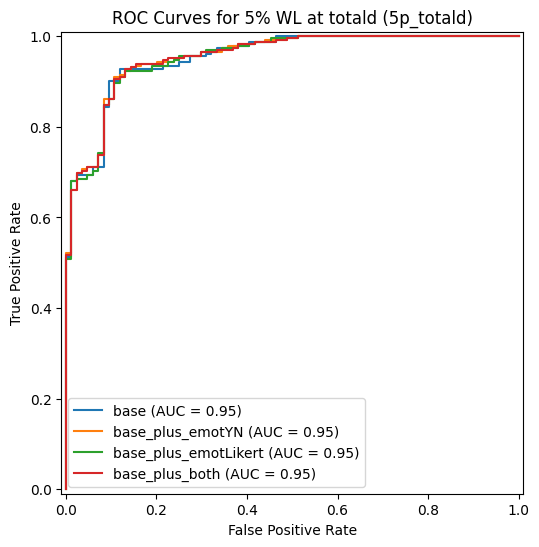

ROC plot saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\logreg_roc\roc_5p_totald.png


In [ ]:
# --- CONFIGURATION SECTION ---
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Set your base directory (already defined globally in your notebook)
# paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"
DB_PATH = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
INPUT_TABLE = "timetoevent_eb_compl"
OUTPUT_DIR = os.path.join(paper1_directory, "logreg_roc")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- SCENARIO CONFIGURATION ---
# You can change these to try other scenarios!
WL_TARGET_PERC = 5         # Weight loss % to predict (5 or 10)
TIME_FRAME = 'total'        # Days (e.g., 60 for 60d, or 'total' for total followup)
SCENARIO_NAME = f"{WL_TARGET_PERC}p_{TIME_FRAME}d"  # Used in filenames

# --- OUTCOME COLUMN LOGIC ---
if TIME_FRAME == 'total':
    OUTCOME_COL = f"{WL_TARGET_PERC}%_wl_achieved"
else:
    OUTCOME_COL = f"wl_{TIME_FRAME}d_%"
    # We'll create a binary outcome: did they achieve at least X% WL at N days?

# --- PREDICTOR SETS ---
BASE_PREDICTORS = ["age", "sex_f", "baseline_weight_kg", "baseline_bmi", "total_followup_days"]
EXTRA_PREDICTORS = [
    [],  # Model 1: base only
    ["emotional_eating_yn"],  # Model 2: add binary emotional eating
    ["emotional_eating_value_likert"],  # Model 3: add likert value
    ["emotional_eating_yn", "emotional_eating_value_likert"],  # Model 4: both
]
MODEL_LABELS = [
    "base",
    "base_plus_emotYN",
    "base_plus_emotLikert",
    "base_plus_both"
]

# --- LOAD DATA ---
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(f"SELECT * FROM {INPUT_TABLE}", conn)

# --- CREATE OUTCOME COLUMN ---
df = df.copy()
if TIME_FRAME == 'total':
    # Already binary (0/1)
    y = df[OUTCOME_COL]
else:
    # Create binary: did they achieve at least X% WL at N days?
    wl_col = f"wl_{TIME_FRAME}d_%"
    y = (df[wl_col].abs() >= WL_TARGET_PERC).astype(int)
    df[f"{WL_TARGET_PERC}p_{TIME_FRAME}d_achieved"] = y
    OUTCOME_COL = f"{WL_TARGET_PERC}p_{TIME_FRAME}d_achieved"

# --- DROP ROWS WITH MISSING DATA IN OUTCOME OR PREDICTORS ---
# We'll do this for each model, but let's check for missing outcome first:
df = df[df[OUTCOME_COL].notna()].copy()

# --- STRATIFIED SPLIT: by outcome AND sex ---
# Combine outcome and sex for stratification
stratify_col = df[OUTCOME_COL].astype(str) # + "_" + df["sex_f"].astype(str) # uncomment if want to stratify by sex too besides outcome
# Check class counts:
print("Counts for stratification groups (outcome_sex):")
print(stratify_col.value_counts())

# --- CHECK FOR RARE COMBINATIONS BEFORE SPLITTING ---
# If any group has <2 samples, train_test_split will fail!
min_group_size = stratify_col.value_counts().min()
if min_group_size < 2:
    print("\nWARNING: Some outcome/sex combinations have less than 2 samples!")
    print("Consider removing rare groups or using a different stratification.")
    # You can see which ones are rare:
    print(stratify_col.value_counts())
    # To proceed anyway, you could drop those rows:
    rare_groups = stratify_col.value_counts()[stratify_col.value_counts() < 2].index
    df = df[~stratify_col.isin(rare_groups)].copy()
    stratify_col = df[OUTCOME_COL].astype(str) + "_" + df["sex_f"].astype(str)
    print("After removing rare groups, new counts:")
    print(stratify_col.value_counts())

# --- TRAIN/TEST SPLIT ---
X_full = df  # We'll select columns for each model below
y_full = df[OUTCOME_COL]
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=stratify_col
)

# --- RUN MODELS AND PLOT ROC CURVES ---
plt.figure(figsize=(8, 6))
for i, extra in enumerate(EXTRA_PREDICTORS):
    predictors = BASE_PREDICTORS + extra
    model_label = MODEL_LABELS[i]
    # Drop rows with missing data in predictors (train/test separately)
    Xtr = X_train[predictors].dropna()
    ytr = y_train.loc[Xtr.index]
    Xte = X_test[predictors].dropna()
    yte = y_test.loc[Xte.index]
    # Fit logistic regression
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, ytr)
    # Predict probabilities
    y_pred_proba = clf.predict_proba(Xte)[:, 1]
    # ROC and AUC
    fpr, tpr, _ = roc_curve(yte, y_pred_proba)
    auc = roc_auc_score(yte, y_pred_proba)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name=model_label).plot(ax=plt.gca())
    print(f"Model: {model_label} | AUC: {auc:.3f} | N test: {len(yte)}")

plt.title(f"ROC Curves for {WL_TARGET_PERC}% WL at {TIME_FRAME}d ({SCENARIO_NAME})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plot_path = os.path.join(OUTPUT_DIR, f"roc_{SCENARIO_NAME}.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC plot saved to: {plot_path}")

# --- END OF PIPELINE ---

# --- HOW TO CHECK FOR SPLITTING DIFFICULTIES ---
# - If train_test_split gives a ValueError about "The least populated class in y has only 1 member",
#   it means some outcome/sex group is too rare.
# - Use the printout above to see which groups are rare.
# - You can drop those groups (see code above), or use a less granular stratification (e.g., just outcome).
# - Always check the counts before splitting!

### RF-ROC

--- Running Scenario: rf_10p_wl_at_total ---

Loading data from: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pnk_db2_p1_in.sqlite, table: timetoevent_eb_compl
Loaded 1052 rows.
Using existing outcome variable '10%_wl_achieved' for total followup.
Outcome variable '10%_wl_achieved' value counts:
10%_wl_achieved
0    0.535171
1    0.464829
Name: proportion, dtype: float64

Stratification key value counts (before handling rare groups):
stratify_key
0_1    465
1_1    395
0_0     98
1_0     94
Name: count, dtype: int64

Train set size: 841 rows
Test set size: 211 rows
Train set outcome distribution:
10%_wl_achieved
0    0.535077
1    0.464923
Name: proportion, dtype: float64
Test set outcome distribution:
10%_wl_achieved
0    0.535545
1    0.464455
Name: proportion, dtype: float64

--- Starting Model Training and Evaluation ---

--- Model: base_only ---
Predictors: ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'baseline_fat_%', 'baseline_muscle_%']
AUC for base_o

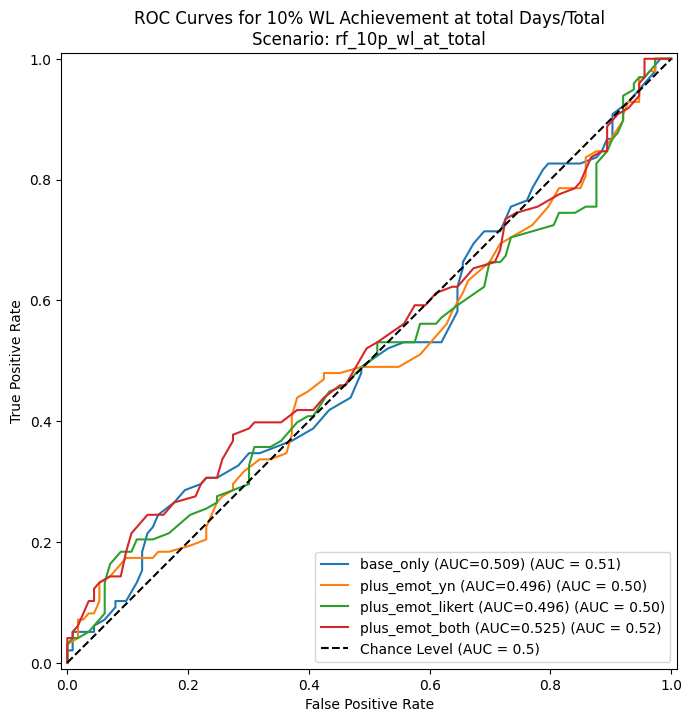


ROC plot saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_roc_feature_importance\rf_10p_wl_at_total_roc_curves.png


--- Summary of Feature Importances (for current scenario) ---

-- Sub-Model: base_only --
  Tree-based Importances:
baseline_muscle_%     0.217161
baseline_fat_%        0.211327
baseline_bmi          0.201164
baseline_weight_kg    0.196259
age                   0.165944
sex_f                 0.008145

  Permutation Importances (Test Set):
age                   0.001896
sex_f                 0.000474
baseline_muscle_%     0.000474
baseline_weight_kg   -0.006161
baseline_fat_%       -0.029384
baseline_bmi         -0.055450

-- Sub-Model: plus_emot_yn --
  Tree-based Importances:
baseline_muscle_%      0.208384
baseline_bmi           0.202471
baseline_fat_%         0.197886
baseline_weight_kg     0.189153
age                    0.169830
emotional_eating_yn    0.022396
sex_f                  0.009879

  Permutation Importances (Test Set):
baseline

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import warnings
import openpyxl

# --- CONFIGURATION SECTION ---

# NOTE: Ensure 'paper1_directory' is defined in your notebook environment before running this script.
# Example: paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"
if 'paper1_directory' not in globals() and 'paper1_directory' not in locals():
    # Fallback for script execution if paper1_directory is not set (e.g., set a default or raise error)
    # For this example, we'll try to use a common structure, but it's best to define it externally.
    # paper1_directory = os.path.join(os.path.expanduser("~"), "Desktop", "Projects", "PNK_DB2", "paper1_emotional")
    # print(f"Warning: 'paper1_directory' not found globally, using a default: {paper1_directory}")
    # A better approach for standalone scripts is to make it an explicit input or environment variable.
    raise NameError("'paper1_directory' is not defined. Please define it in your environment.")


DB_PATH = os.path.join(paper1_directory, "pnk_db2_p1_in.sqlite")
INPUT_TABLE = "timetoevent_eb_compl"
OUTPUT_DIR = os.path.join(paper1_directory, "rf_roc_feature_importance")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- SCENARIO CONFIGURATION ---
# You can change these to try other scenarios!
WL_TARGET_PERC = 10 # Weight loss % to predict (e.g., 5, 10, 15)
TIME_FRAME = 'total'    # Days (e.g., 40, 60, 80, or 'total' for total followup)
# SCENARIO_NAME will be generated dynamically

# --- PREDICTOR SETS ---
# These are the columns from your sa_input_table
BASE_PREDICTORS = ["age", "sex_f", "baseline_weight_kg", "baseline_bmi", "baseline_fat_%", "baseline_muscle_%"]
EXTRA_PREDICTORS_CONFIG = [
    {'name': 'base_only', 'features': []},
    {'name': 'plus_emot_yn', 'features': ["emotional_eating_yn"]},
    {'name': 'plus_emot_likert', 'features': ["emotional_eating_value_likert"]},
    {'name': 'plus_emot_both', 'features': ["emotional_eating_yn", "emotional_eating_value_likert"]},
]

# --- Random Forest Parameters ---
# These can be tuned, but we'll use sensible defaults for now.
RF_N_ESTIMATORS = 100
RF_RANDOM_STATE = 42 # For reproducibility

# --- Permutation Importance Parameters ---
PERMUTATION_N_REPEATS = 10 # Number of times to shuffle each feature for permutation importance

# --- Helper function to generate scenario name ---
def get_scenario_name(wl_perc, time_fr):
    time_label = str(time_fr) + 'd' if isinstance(time_fr, int) else str(time_fr)
    return f"rf_{wl_perc}p_wl_at_{time_label}"

SCENARIO_NAME = get_scenario_name(WL_TARGET_PERC, TIME_FRAME)
print(f"--- Running Scenario: {SCENARIO_NAME} ---")

# --- 1. LOAD DATA ---
print(f"\nLoading data from: {DB_PATH}, table: {INPUT_TABLE}")
if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"Database file not found at {DB_PATH}")

with sqlite3.connect(DB_PATH) as conn:
    df_full = pd.read_sql_query(f"SELECT * FROM {INPUT_TABLE}", conn)
print(f"Loaded {len(df_full)} rows.")

# --- 2. CREATE OUTCOME VARIABLE ---
# We'll work with a copy of the DataFrame to avoid modifying the original
df = df_full.copy()
outcome_col_name = "" # Will be set based on TIME_FRAME

if isinstance(TIME_FRAME, int):
    # Outcome is achieving WL_TARGET_PERC at a specific number of days (TIME_FRAME)
    # The column name for weight loss percentage at N days is 'wl_Nd_%'
    wl_at_n_days_col = f"wl_{TIME_FRAME}d_%"
    outcome_col_name = f"achieved_{WL_TARGET_PERC}p_wl_at_{TIME_FRAME}d"

    if wl_at_n_days_col not in df.columns:
        raise KeyError(f"Weight loss column '{wl_at_n_days_col}' not found in the DataFrame. Check TIME_FRAME.")

    # Create binary outcome: 1 if absolute weight loss % is >= target, 0 otherwise
    # Ensure the source column is numeric
    df[wl_at_n_days_col] = pd.to_numeric(df[wl_at_n_days_col], errors='coerce')
    df[outcome_col_name] = (df[wl_at_n_days_col].abs() >= WL_TARGET_PERC).astype(int)
    print(f"Created outcome variable '{outcome_col_name}' based on '{wl_at_n_days_col}' >= {WL_TARGET_PERC}%.")

elif TIME_FRAME == 'total':
    # Outcome is achieving WL_TARGET_PERC during the total followup period
    # The column name for this is 'K%_wl_achieved'
    outcome_col_name = f"{WL_TARGET_PERC}%_wl_achieved"

    if outcome_col_name not in df.columns:
        raise KeyError(f"Outcome column '{outcome_col_name}' not found for TIME_FRAME='total'. Check WL_TARGET_PERC.")
    # Ensure the outcome column is integer (0 or 1)
    df[outcome_col_name] = pd.to_numeric(df[outcome_col_name], errors='coerce').fillna(0).astype(int)
    print(f"Using existing outcome variable '{outcome_col_name}' for total followup.")

else:
    raise ValueError(f"Invalid TIME_FRAME: {TIME_FRAME}. Must be an integer (days) or 'total'.")

# Drop rows where the outcome variable is missing (if any were introduced by coercion)
initial_rows = len(df)
df.dropna(subset=[outcome_col_name], inplace=True)
if len(df) < initial_rows:
    print(f"Dropped {initial_rows - len(df)} rows due to missing outcome values in '{outcome_col_name}'.")

if df.empty:
    raise ValueError("DataFrame is empty after outcome creation/filtering. Cannot proceed.")
if df[outcome_col_name].nunique() < 2:
    raise ValueError(f"Outcome variable '{outcome_col_name}' has less than 2 unique values. Cannot perform binary classification.")

print(f"Outcome variable '{outcome_col_name}' value counts:\n{df[outcome_col_name].value_counts(normalize=True)}")


# --- 3. STRATIFIED TRAIN-TEST SPLIT ---
# Stratify by outcome and sex_f
# Ensure 'sex_f' is present and numeric (0 or 1)
if 'sex_f' not in df.columns:
    raise KeyError("'sex_f' column not found, which is needed for stratification.")
df['sex_f'] = pd.to_numeric(df['sex_f'], errors='coerce').fillna(0).astype(int) # Assuming 0 for male, 1 for female

# Create a combined stratification column
df['stratify_key'] = df[outcome_col_name].astype(str) + "_" + df['sex_f'].astype(str)

print("\nStratification key value counts (before handling rare groups):")
print(df['stratify_key'].value_counts())

# Handle rare groups for stratification (if a group has < 2 members, train_test_split fails)
min_group_size = 2
strat_counts = df['stratify_key'].value_counts()
rare_groups = strat_counts[strat_counts < min_group_size].index

if len(rare_groups) > 0:
    print(f"\nWarning: Found rare stratification groups (count < {min_group_size}): {list(rare_groups)}")
    df = df[~df['stratify_key'].isin(rare_groups)].copy()
    print(f"Removed {len(rare_groups)} rare groups. New data size: {len(df)} rows.")
    if df.empty or df[outcome_col_name].nunique() < 2 or df['stratify_key'].nunique() < 2 :
         raise ValueError("Not enough data or classes remaining after removing rare stratification groups.")
    print("\nStratification key value counts (after handling rare groups):")
    print(df['stratify_key'].value_counts())


# Define features (X) and target (y) for the split
# We'll select specific predictor columns for each model later
X_data_for_split = df.drop(columns=[outcome_col_name, 'stratify_key']) # Drop outcome and temp key
y_target_for_split = df[outcome_col_name]

X_train, X_test, y_train, y_test = train_test_split(
    X_data_for_split,
    y_target_for_split,
    test_size=0.2,  # 80% train, 20% test
    random_state=RF_RANDOM_STATE,
    stratify=df['stratify_key'] # Use the stratification key from the original df before dropping columns
)

print(f"\nTrain set size: {len(X_train)} rows")
print(f"Test set size: {len(X_test)} rows")
print(f"Train set outcome distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test set outcome distribution:\n{y_test.value_counts(normalize=True)}")


# --- 4. MODEL TRAINING, ROC COMPARISON, AND FEATURE IMPORTANCE ---
print("\n--- Starting Model Training and Evaluation ---")

# Store results for feature importances
all_feature_importances = {}

# Initialize plot for ROC curves
plt.figure(figsize=(10, 8))
ax_roc = plt.gca() # Get current axes for RocCurveDisplay

for model_config in EXTRA_PREDICTORS_CONFIG:
    model_label = model_config['name']
    extra_features = model_config['features']
    current_predictors = BASE_PREDICTORS + extra_features

    print(f"\n--- Model: {model_label} ---")
    print(f"Predictors: {current_predictors}")

    # Ensure all current predictors are in the DataFrame columns
    missing_predictors = [p for p in current_predictors if p not in X_train.columns]
    if missing_predictors:
        print(f"Warning: Predictors {missing_predictors} not found. Skipping model {model_label}.")
        all_feature_importances[model_label] = {
            'tree_based': pd.Series(dtype=float),
            'permutation_test': pd.Series(dtype=float)
        }
        continue

    # Select features for this model and handle potential NaNs from feature selection
    # (User stated no NaNs in input, but this is good practice if features are dynamic)
    X_train_model = X_train[current_predictors].copy()
    X_test_model = X_test[current_predictors].copy()

    # Drop rows if any selected predictor for THIS model is NaN
    # This ensures that each model is trained on complete cases for ITS specific set of features
    train_initial_rows = len(X_train_model)
    X_train_model.dropna(inplace=True)
    y_train_model = y_train[X_train_model.index] # Align y_train with non-NaN rows in X_train_model
    if len(X_train_model) < train_initial_rows:
        print(f"Dropped {train_initial_rows - len(X_train_model)} rows from training set due to NaNs in selected predictors.")

    test_initial_rows = len(X_test_model)
    X_test_model.dropna(inplace=True)
    y_test_model = y_test[X_test_model.index] # Align y_test
    if len(X_test_model) < test_initial_rows:
        print(f"Dropped {test_initial_rows - len(X_test_model)} rows from test set due to NaNs in selected predictors.")

    if X_train_model.empty or X_test_model.empty or y_train_model.nunique() < 2:
        print(f"Warning: Not enough data or outcome variance for model '{model_label}' after NaN handling. Skipping.")
        all_feature_importances[model_label] = {
            'tree_based': pd.Series(dtype=float),
            'permutation_test': pd.Series(dtype=float)
        }
        continue

    # Initialize and train Random Forest Classifier
    # For more robust performance, consider hyperparameter tuning using GridSearchCV or RandomizedSearchCV with cross-validation.
    rf_model = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        random_state=RF_RANDOM_STATE,
        # class_weight='balanced', # Consider if classes are imbalanced
        n_jobs=-1 # Use all available cores
    )
    rf_model.fit(X_train_model, y_train_model)

    # --- ROC Curve Analysis ---
    y_pred_proba = rf_model.predict_proba(X_test_model)[:, 1] # Probabilities for the positive class
    auc_score = roc_auc_score(y_test_model, y_pred_proba)
    print(f"AUC for {model_label}: {auc_score:.4f}")

    RocCurveDisplay.from_estimator(rf_model, X_test_model, y_test_model, name=f"{model_label} (AUC={auc_score:.3f})", ax=ax_roc)

    # --- Feature Importance ---
    # 1. Tree-based (Gini) Importance
    tree_importances = pd.Series(rf_model.feature_importances_, index=current_predictors).sort_values(ascending=False)
    print("\nTree-based Feature Importances:")
    print(tree_importances)

    # 2. Permutation Importance (on the test set)
    # This can be computationally intensive, especially with many repeats or features.
    print("\nCalculating Permutation Importances (on test set)...")
    with warnings.catch_warnings(): # Suppress potential UserWarnings from sklearn about std=0
        warnings.simplefilter("ignore", UserWarning)
        perm_importance_result = permutation_importance(
            rf_model,
            X_test_model,
            y_test_model,
            n_repeats=PERMUTATION_N_REPEATS,
            random_state=RF_RANDOM_STATE,
            n_jobs=-1 # Use all available cores
        )
    perm_importances = pd.Series(perm_importance_result.importances_mean, index=current_predictors).sort_values(ascending=False)
    print("\nPermutation Feature Importances (Mean over repeats):")
    print(perm_importances)

    all_feature_importances[model_label] = {
        'tree_based': tree_importances,
        'permutation_test': perm_importances
    }

    # Highlight emotional eating features if present
    for emot_feat in ["emotional_eating_yn", "emotional_eating_value_likert"]:
        if emot_feat in current_predictors:
            print(f"  Tree-based importance for '{emot_feat}': {tree_importances.get(emot_feat, 'N/A'):.4f}")
            print(f"  Permutation importance for '{emot_feat}': {perm_importances.get(emot_feat, 'N/A'):.4f}")


# --- 5. FINALIZE AND SAVE ROC PLOT ---
ax_roc.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.5)') # Diagonal line
ax_roc.set_title(f'ROC Curves for {WL_TARGET_PERC}% WL Achievement at {TIME_FRAME} Days/Total\nScenario: {SCENARIO_NAME}')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
roc_plot_path = os.path.join(OUTPUT_DIR, f"{SCENARIO_NAME}_roc_curves.png")
plt.savefig(roc_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nROC plot saved to: {roc_plot_path}")

# --- 6. DISPLAY/SAVE ALL FEATURE IMPORTANCES ---
print("\n\n--- Summary of Feature Importances (for current scenario) ---")
for model_label, importances_dict in all_feature_importances.items():
    print(f"\n-- Sub-Model: {model_label} --")
    print("  Tree-based Importances:")
    if not importances_dict['tree_based'].empty:
        print(importances_dict['tree_based'].to_string())
    else:
        print("    Not available (model might have been skipped).")
    print("\n  Permutation Importances (Test Set):")
    if not importances_dict['permutation_test'].empty:
        print(importances_dict['permutation_test'].to_string())
    else:
        print("    Not available (model might have been skipped).")

# Prepare data for the current scenario's sheet
sheet_data_frames = []
for model_label, importances_dict in all_feature_importances.items():
    # Process tree-based importances
    if 'tree_based' in importances_dict and not importances_dict['tree_based'].empty:
        df_tree = importances_dict['tree_based'].rename('importance_score').reset_index()
        df_tree.rename(columns={'index': 'feature'}, inplace=True)
        df_tree['model_config_label'] = model_label
        df_tree['importance_type'] = 'tree_based'
        sheet_data_frames.append(df_tree)

    # Process permutation importances
    if 'permutation_test' in importances_dict and not importances_dict['permutation_test'].empty:
        df_perm = importances_dict['permutation_test'].rename('importance_score').reset_index()
        df_perm.rename(columns={'index': 'feature'}, inplace=True)
        df_perm['model_config_label'] = model_label
        df_perm['importance_type'] = 'permutation_test'
        sheet_data_frames.append(df_perm)

if sheet_data_frames:
    df_for_this_sheet = pd.concat(sheet_data_frames, ignore_index=True)
    # Reorder columns for clarity
    if not df_for_this_sheet.empty:
        df_for_this_sheet = df_for_this_sheet[['model_config_label', 'feature', 'importance_type', 'importance_score']]

    # Define a fixed name for the master Excel file
    master_excel_filename = "all_rf_roc_feature_importances.xlsx"
    excel_path = os.path.join(OUTPUT_DIR, master_excel_filename)
    
    # SCENARIO_NAME (e.g., "rf_15p_wl_at_total") will be the sheet name.
    # Sanitize SCENARIO_NAME for Excel sheet name limitations (max 31 chars, no invalid chars).
    sheet_name_for_excel = "".join(c if c.isalnum() else "_" for c in SCENARIO_NAME)[:31]

    try:
        # Determine mode and if_sheet_exists option for ExcelWriter
        if os.path.exists(excel_path):
            mode = 'a'  # Append mode if file exists
            if_sheet_exists_option = 'replace'  # Replace sheet if it has the same name
        else:
            mode = 'w'  # Write mode if file doesn't exist (creates new file)
            if_sheet_exists_option = None # Not applicable for 'w' mode

        with pd.ExcelWriter(excel_path, engine='openpyxl', mode=mode, if_sheet_exists=if_sheet_exists_option) as writer:
            df_for_this_sheet.to_excel(writer, sheet_name=sheet_name_for_excel, index=False)
            print(f"\nSaved Feature Importances for scenario '{SCENARIO_NAME}' to sheet '{sheet_name_for_excel}' in: {excel_path}")
            if mode == 'a' and if_sheet_exists_option == 'replace':
                print(f"   (Sheet '{sheet_name_for_excel}' was replaced if it already existed in the master file.)")
            elif mode == 'a':
                 print(f"   (Sheet '{sheet_name_for_excel}' was added to the master file.)")


    except Exception as e:
        print(f"Error saving feature importances to Excel: {e}")
        print("Please ensure you have 'openpyxl' installed: pip install openpyxl")
else:
    print(f"\nNo feature importances were generated for scenario '{SCENARIO_NAME}' to save to the master Excel file.")

print("\n--- Script Finished ---")

## Weight gain causes

In [ ]:
import sqlite3
import pandas as pd

# Path to the SQLite database
db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\weight_gain_causes.sqlite"

# Connect and get table names
with sqlite3.connect(db_path) as conn:
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print("Tables in database:", tables['name'].tolist())
    # Replace 'your_table_name' with the actual table name if known
    table_name = tables['name'].iloc[0]
    df_weight_gain_causes = pd.read_sql_query(f"SELECT * FROM [{table_name}]", conn)

df_weight_gain_causes

Tables in database: ['weight_gain_causes']


,patient_id,medical_record_id,weight_gain_cause,weight_gain_cause_en,womens_health_and_pregnancy,mental_health,family_issues,medication_disease_injury,physical_activity,eating_habits,schedule,smoking_cessation,post_treatment_weight_regain,pandemic,habits_and_circumstances,none_of_above
0,9897B34CEB969,13A04142A682D,"estrés, mucho trabajo","""stress, too much work""",0,1,0,0,0,0,1,0,0,0,1,0
1,9898644CEB969,13786742A682D,este último año ha cogido peso por tema mudanz...,"""this last year i have gained weight due to mo...",0,0,0,1,1,0,0,0,0,0,1,0
2,9899A04CEB969,10B67842A682D,EMBARAZO,"""pregnancy""",1,0,0,0,0,0,0,0,0,0,0,0
3,9899A94CEB969,12CE5B42A682D,FEZ MEDICAÇÃO PARA A DEPRESSÃO DURANTE A PANDE...,"""took medication for depression during the pan...",0,1,0,1,0,1,0,0,0,1,0,0
4,9899D04CEB969,13D74142A682D,HOUVE UM DESLEIXO ALIMENTAR NA QUANTIDADE,"""there was a neglect in food quantity""",0,0,0,0,0,1,0,0,0,0,1,0


## Misc

In [ ]:
import sqlite3

# Connect to the SQLite database
db_path = 'C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\paper1_emotional\\survival_analysis.sqlite'
table_name = 'sa_input_table'

# Query to fetch unique values from the weight_gain_cause column
query = f"SELECT DISTINCT weight_gain_cause FROM {table_name}"
 
# Execute the query and fetch results
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute(query)
    results = cursor.fetchall()

# Extract and print the unique observations
unique_weight_gain_causes = [row[0] for row in results if row[0] is not None]
print("Unique observations in the weight_gain_cause column:")
for cause in unique_weight_gain_causes:
    print(cause)

### SQL to Excel

In [1]:
import sqlite3
import pandas as pd
import os

# Define the output Excel file path
# DB_PATH = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")
# output_excel_path = os.path.join(paper1_directory, 'hclust_ward_k6_10Jul25.xlsx')

DB_PATH = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\pnk_db2_standard.sqlite"
output_excel_path = os.path.join(os.path.dirname(DB_PATH), 'standard_prescriptions.xlsx')

# Connect to the SQLite database
with sqlite3.connect(DB_PATH) as conn:
    # Get the list of all tables in the database
    query = "SELECT name FROM sqlite_master WHERE type='table';"
    tables = pd.read_sql_query(query, conn)['name'].tolist()
    
    # Create a Pandas Excel writer
    with pd.ExcelWriter(output_excel_path, engine='openpyxl') as writer:
        # Loop through each table and save it as a sheet in the Excel file
        for table in tables:
            df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
            df.to_excel(writer, sheet_name=table, index=False)

print(f"Database exported to Excel at: {output_excel_path}")

Database exported to Excel at: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\standard_prescriptions.xlsx


### SQL table deletion

In [ ]:
# import sqlite3
# import os

# # List of tables to delete
# tables_to_delete = [
#     "eb_cmpl_dmgrph_strt",
#     "eb_cmpl_eb_strt",
#     "eb_cmpl_wgc_strt",
#     "eb_wgc_cmpl_dmgrph_strt",
#     "eb_wgc_cmpl_eb_strt",
#     "eb_wgc_cmpl_wgc_strt"

# ]

# db_path = os.path.join(paper1_directory, "pnk_db2_p1_out.sqlite")

# with sqlite3.connect(db_path) as conn:
#     cursor = conn.cursor()
#     for table in tables_to_delete:
#         cursor.execute(f"DROP TABLE IF EXISTS {table}")
#     conn.commit()
# print("Selected tables deleted from the defined database.")

Selected tables deleted from the defined database.


### SQL table column deletion

In [ ]:
import sqlite3

db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\weight_gain_causes.sqlite"

# Get the table name
with sqlite3.connect(db_path) as conn:
    table_name = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchone()[0]
    # Get all columns
    columns = [row[1] for row in conn.execute(f"PRAGMA table_info([{table_name}]);")]
    # Find index of 'weight_gain_cause_en'
    idx = columns.index('weight_gain_cause_en')
    # Columns to keep (up to and including 'weight_gain_cause_en')
    keep_cols = columns[:idx+1]
    # Columns to drop (after 'weight_gain_cause_en')
    drop_cols = columns[idx+1:]

    if drop_cols:
        # Build new table schema
        col_defs = ", ".join([
            f"{row[1]} {row[2]}"
            for row in conn.execute(f"PRAGMA table_info([{table_name}]);")
            if row[1] in keep_cols
        ])
        new_table = f"{table_name}_tmp"

        # Create new table
        conn.execute(f"CREATE TABLE [{new_table}] ({col_defs});")
        # Copy data
        conn.execute(f"INSERT INTO [{new_table}] SELECT {', '.join(keep_cols)} FROM [{table_name}];")
        # Drop old table
        conn.execute(f"DROP TABLE [{table_name}];")
        # Rename new table
        conn.execute(f"ALTER TABLE [{new_table}] RENAME TO [{table_name}];")
        conn.commit()
        print(f"Columns after '{keep_cols[-1]}' have been deleted from '{table_name}'.")
    else:
        print("No columns to delete after 'weight_gain_cause_en'.")

Columns after 'weight_gain_cause_en' have been deleted from 'weight_gain_causes'.


In [ ]:
import sqlite3
import os

db_path = os.path.join(paper1_directory, "pnk_db2_p1.sqlite")
table_name = "timetoevent_all"
col_to_delete = "genomics_sample_id"

with sqlite3.connect(db_path) as conn:
    # Get all columns
    columns = [row[1] for row in conn.execute(f"PRAGMA table_info([{table_name}]);")]
    if col_to_delete not in columns:
        print(f"Column '{col_to_delete}' not found in '{table_name}'. No action taken.")
    else:
        keep_cols = [col for col in columns if col != col_to_delete]
        col_defs = ", ".join([
            f"{row[1]} {row[2]}"
            for row in conn.execute(f"PRAGMA table_info([{table_name}]);")
            if row[1] in keep_cols
        ])
        tmp_table = f"{table_name}_tmp"
        # Create new table without the column
        conn.execute(f"CREATE TABLE [{tmp_table}] ({col_defs});")
        # Copy data
        conn.execute(f"INSERT INTO [{tmp_table}] SELECT {', '.join(keep_cols)} FROM [{table_name}];")
        # Drop old table and rename new
        conn.execute(f"DROP TABLE [{table_name}];")
        conn.execute(f"ALTER TABLE [{tmp_table}] RENAME TO [{table_name}];")
        conn.commit()
        print(f"Column '{col_to_delete}' deleted from '{table_name}'.")

Column 'genomics_sample_id' not found in 'timetoevent_all'. No action taken.
